# **Import Library**

In [ ]:
# ============================================================
# CELL 1. IMPORT LIBRARY
# ============================================================
import os
import random
import math
import copy
import json
import time
import warnings
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import librosa
import soundfile as sf
from scipy.signal import butter, sosfiltfilt
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
import kagglehub
warnings.filterwarnings("ignore")

# **Load Dataset**

In [ ]:
import os
import glob
import pandas as pd
import kagglehub
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
# === Step 1: Download & Setup Dataset ===
path = kagglehub.dataset_download("vbookshelf/respiratory-sound-database")
print("Dataset tersimpan di:", path)

DATASET_PATH = os.path.join(path, "respiratory_sound_database", "Respiratory_Sound_Database")
AUDIO_DIR = os.path.join(DATASET_PATH, "audio_and_txt_files")
META_FILE = os.path.join(DATASET_PATH, "patient_diagnosis.csv")

print("\nStruktur Direktori:")
for item in os.listdir(DATASET_PATH):
    print(" -", item)

# === Load diagnosis pasien (opsional untuk konteks, bukan label modelmu) ===
diagnosis_df = pd.read_csv(META_FILE, header=None, names=["patient_id", "disease"])
diagnosis_df["patient_id"] = diagnosis_df["patient_id"].astype(int)

print("\nTotal pasien:", len(diagnosis_df))
print("\nDistribusi diagnosis (konteks):")
print(diagnosis_df["disease"].value_counts())

# === Index pasangan wav dan txt ===
wav_paths = sorted(glob.glob(os.path.join(AUDIO_DIR, "*.wav")))
txt_list = glob.glob(os.path.join(AUDIO_DIR, "*.txt"))

# mapping: stem -> path txt
txt_paths = {os.path.splitext(os.path.basename(p))[0]: p for p in txt_list}

print("\nTotal file wav:", len(wav_paths))
print("Contoh wav:", [os.path.basename(p) for p in wav_paths[:5]])

missing_txt = [
    os.path.basename(w)
    for w in wav_paths
    if os.path.splitext(os.path.basename(w))[0] not in txt_paths
]
print("\nWav tanpa anotasi txt:", len(missing_txt))
if len(missing_txt) > 0:
    print("Contoh:", missing_txt[:5])

Device: cuda
Using Colab cache for faster access to the 'respiratory-sound-database' dataset.
Dataset tersimpan di: /kaggle/input/respiratory-sound-database

Struktur Direktori:
 - patient_diagnosis.csv
 - filename_format.txt
 - audio_and_txt_files
 - filename_differences.txt

Total pasien: 126

Distribusi diagnosis (konteks):
disease
COPD              64
Healthy           26
URTI              14
Bronchiectasis     7
Bronchiolitis      6
Pneumonia          6
LRTI               2
Asthma             1
Name: count, dtype: int64

Total file wav: 920
Contoh wav: ['101_1b1_Al_sc_Meditron.wav', '101_1b1_Pr_sc_Meditron.wav', '102_1b1_Ar_sc_Meditron.wav', '103_2b2_Ar_mc_LittC2SE.wav', '104_1b1_Al_sc_Litt3200.wav']

Wav tanpa anotasi txt: 0


# **Segmentasi dan Labeling Berdasarkan File Anotasi**
> Ekstraksi data



In [ ]:
import os
import numpy as np
import pandas as pd
import soundfile as sf
from tqdm import tqdm

# Fungsi baca anotasi TXT: start end crackle wheeze
def parse_annotation(txt_path):
    segments = []
    with open(txt_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 4:
                continue

            start = float(parts[0])
            end = float(parts[1])
            crackle = int(float(parts[2]))
            wheeze = int(float(parts[3]))

            if end <= start:
                continue

            if crackle == 1 and wheeze == 1:
                label = "both"
            elif crackle == 1:
                label = "crackle"
            elif wheeze == 1:
                label = "wheeze"
            else:
                label = "normal"

            segments.append((start, end, crackle, wheeze, label))
    return segments


# ===== Output folder =====
SEGMENTED_DIR = "segmented_audio_precise"
os.makedirs(SEGMENTED_DIR, exist_ok=True)

# ===== Konfigurasi =====
MIN_SEC = 0.0          # kalau mau paksa minimal durasi, isi > 0
MIN_AMPL = 1e-4        # threshold amplitude untuk deteksi segmen "diam"
KEEP_SILENT = False    # True kalau mau simpan segmen diam, False kalau mau buang
TOL_DUR = 0.25         # toleransi beda durasi audio vs max end anotasi (detik)
SAVE_WAV = True        # True kalau mau simpan file segmen wav, False kalau mau metadata saja

meta_rows = []
silent_skipped = 0
empty_skipped = 0
time_mismatch_warn = 0
txt_missing = 0

# Buat lookup diagnosis biar cepat
diag_map = {}
if "patient_id" in diagnosis_df.columns and "disease" in diagnosis_df.columns:
    diag_map = dict(zip(diagnosis_df["patient_id"].astype(int), diagnosis_df["disease"].astype(str)))

print("Memotong audio secara presisi sesuai anotasi (ORIGINAL RAW, tanpa preprocessing dulu)")

for wav_path in tqdm(wav_paths, ncols=100):
    wav_file = os.path.basename(wav_path)
    stem = os.path.splitext(wav_file)[0]

    # anotasi TXT dengan stem yang sama
    txt_path = txt_paths.get(stem, None)
    if txt_path is None or (not os.path.exists(txt_path)):
        txt_missing += 1
        continue

    segments = parse_annotation(txt_path)
    if len(segments) == 0:
        continue

    # baca audio raw (tanpa resample)
    y, sr = sf.read(wav_path, always_2d=False)
    if y.ndim > 1:
        y = y.mean(axis=1)
    y = y.astype(np.float32, copy=False)

    dur_audio = len(y) / float(sr)
    max_end = max(s[1] for s in segments)

    if abs(dur_audio - max_end) > TOL_DUR:
        time_mismatch_warn += 1
        # batasi print agar tidak spam
        if time_mismatch_warn <= 10:
            print(f"[PERINGATAN] {wav_file}: durasi audio {dur_audio:.3f}s vs max anotasi {max_end:.3f}s")

    # patient_id biasanya di depan nama file
    patient_id_str = stem.split("_")[0]
    try:
        patient_id = int(patient_id_str)
    except ValueError:
        patient_id = -1

    disease = diag_map.get(patient_id, "") if patient_id != -1 else ""

    for i, (start, end, crackle, wheeze, label) in enumerate(segments):
        start_samp = int(np.floor(start * sr))
        end_samp = int(np.ceil(end * sr))

        # clamp ke range valid
        start_samp = max(0, min(start_samp, len(y)))
        end_samp = max(0, min(end_samp, len(y)))

        if end_samp <= start_samp:
            empty_skipped += 1
            continue

        segment = y[start_samp:end_samp]

        # optional: paksa minimal durasi
        if MIN_SEC > 0.0:
            min_len = int(MIN_SEC * sr)
            if len(segment) < min_len:
                segment = np.pad(segment, (0, min_len - len(segment)), mode="constant")

        # cek amplitude
        max_amp = float(np.max(np.abs(segment))) if segment.size > 0 else 0.0
        is_silent = max_amp < MIN_AMPL

        if is_silent and (not KEEP_SILENT):
            silent_skipped += 1
            continue

        out_path = ""
        if SAVE_WAV:
            label_dir = os.path.join(SEGMENTED_DIR, label)
            os.makedirs(label_dir, exist_ok=True)

            out_path = os.path.join(
                label_dir,
                f"{stem}_s{start:.3f}_e{end:.3f}_seg{i}.wav"
            )
            sf.write(out_path, segment, sr)

        meta_rows.append({
            "wav_source": wav_path,
            "txt_source": txt_path,
            "file": out_path,
            "sound": label,
            "patient_id": patient_id,
            "disease": disease,           # konteks saja
            "start_sec": float(start),
            "end_sec": float(end),
            "duration_sec": float(len(segment) / sr),
            "crackle": int(crackle),
            "wheeze": int(wheeze),
            "sr_raw": int(sr),
            "max_amp": max_amp,
            "is_silent": int(is_silent),
            "source": "original"
        })

meta_segments = pd.DataFrame(meta_rows)
meta_csv_path = os.path.join(SEGMENTED_DIR, "metadata_segments_precise.csv")
meta_segments.to_csv(meta_csv_path, index=False)

print("\nTotal segmen yang DISIMPAN:", len(meta_segments))
if len(meta_segments) > 0:
    print("\nDistribusi kelas sound:")
    print(meta_segments["sound"].value_counts())

    dur = meta_segments["duration_sec"]
    dur_rounded = dur.round(2)

    print("\nRingkasan variasi durasi segmen")
    print("Durasi minimum (detik):", float(dur.min()))
    print("Durasi maksimum (detik):", float(dur.max()))
    print("Jumlah variasi durasi unik (dibulatkan 2 desimal):", int(dur_rounded.nunique()))

    unique_vals = np.sort(dur_rounded.unique())
    print("\nContoh 20 durasi unik pertama (detik):")
    print(unique_vals[:20])

    top = dur_rounded.value_counts().head(10)
    print("\n10 durasi paling sering muncul (detik -> jumlah segmen):")
    for dval, cnt in top.items():
        print(f"{dval:.2f} -> {int(cnt)}")

print("\nRingkasan masalah saat segmentasi:")
print("Wav tanpa anotasi txt                :", txt_missing)
print("Segmen kosong (end_samp <= start_samp):", empty_skipped)
print("Segmen diam dibuang                  :", silent_skipped)
print("File mismatch durasi vs anotasi      :", time_mismatch_warn)

print("\nMetadata tersimpan di:", meta_csv_path)

Memotong audio secara presisi sesuai anotasi (ORIGINAL RAW, tanpa preprocessing dulu)


  2%|▉                                                             | 14/920 [00:01<01:46,  8.53it/s]

[PERINGATAN] 107_2b3_Al_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.101s
[PERINGATAN] 107_2b3_Ar_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.101s


  2%|█                                                             | 16/920 [00:01<02:00,  7.53it/s]

[PERINGATAN] 107_2b3_Ll_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.101s
[PERINGATAN] 107_2b3_Lr_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.101s


  2%|█▏                                                            | 18/920 [00:02<02:20,  6.43it/s]

[PERINGATAN] 107_2b3_Pl_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.101s
[PERINGATAN] 107_2b3_Pr_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.101s


  2%|█▎                                                            | 20/920 [00:02<02:18,  6.51it/s]

[PERINGATAN] 107_2b3_Tc_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.101s
[PERINGATAN] 107_2b4_Al_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.542s


  2%|█▍                                                            | 22/920 [00:02<02:19,  6.46it/s]

[PERINGATAN] 107_2b4_Ar_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.542s
[PERINGATAN] 107_2b4_Ll_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.542s


100%|█████████████████████████████████████████████████████████████| 920/920 [01:31<00:00, 10.09it/s]


Total segmen yang DISIMPAN: 6898

Distribusi kelas sound:
sound
normal     3642
crackle    1864
wheeze      886
both        506
Name: count, dtype: int64

Ringkasan variasi durasi segmen
Durasi minimum (detik): 0.20002267573696145
Durasi maksimum (detik): 16.163
Jumlah variasi durasi unik (dibulatkan 2 desimal): 574

Contoh 20 durasi unik pertama (detik):
[0.2  0.23 0.24 0.26 0.29 0.3  0.31 0.32 0.33 0.34 0.36 0.37 0.39 0.4
 0.41 0.43 0.44 0.45 0.46 0.47]

10 durasi paling sering muncul (detik -> jumlah segmen):
2.37 -> 90
2.39 -> 63
2.40 -> 52
2.61 -> 49
2.20 -> 49
2.29 -> 47
2.62 -> 46
2.24 -> 45
2.57 -> 45
2.12 -> 43

Ringkasan masalah saat segmentasi:
Wav tanpa anotasi txt                : 0
Segmen kosong (end_samp <= start_samp): 0
Segmen diam dibuang                  : 0
File mismatch durasi vs anotasi      : 394

Metadata tersimpan di: segmented_audio_precise/metadata_segments_precise.csv



Sumber: segmented_audio_precise/normal/120_1b1_Ar_sc_Meditron_s16.698_e19.734_seg6.wav
Mode  : segment_file
Kelas : normal
Patient ID: 120
Waktu segmen: 16.698s - 19.734s
SR    : 4000
Durasi: 3.036 detik
Max amplitude: 0.781921


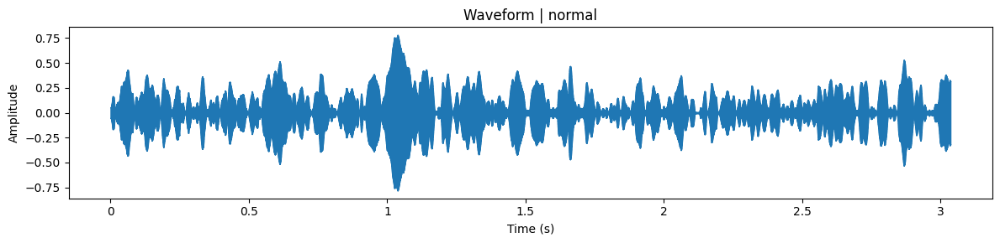

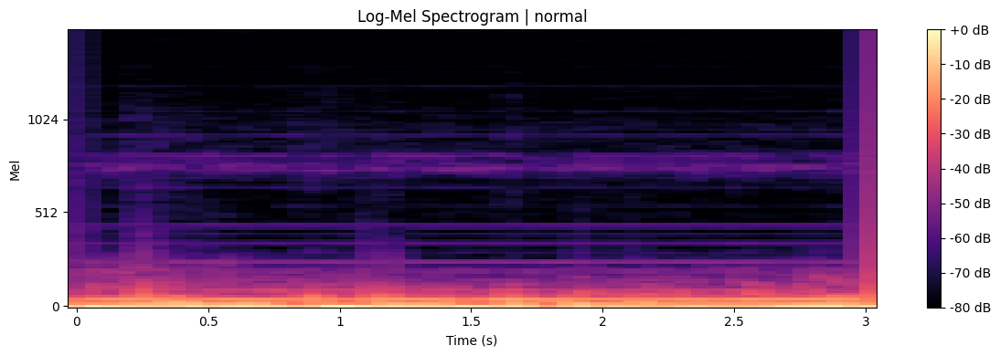


Sumber: segmented_audio_precise/crackle/130_2b2_Ar_mc_AKGC417L_s4.933_e7.466_seg2.wav
Mode  : segment_file
Kelas : crackle
Patient ID: 130
Waktu segmen: 4.933s - 7.466s
SR    : 44100
Durasi: 2.533 detik
Max amplitude: 0.501038


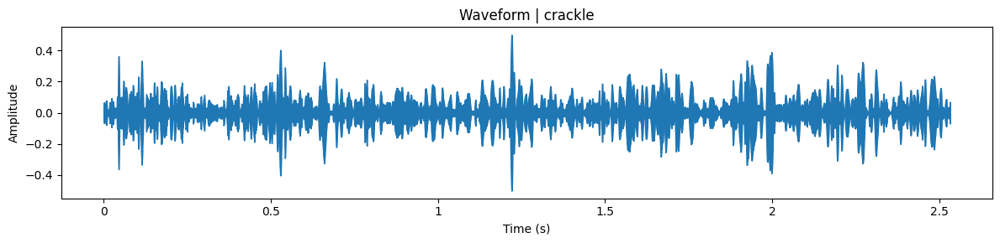

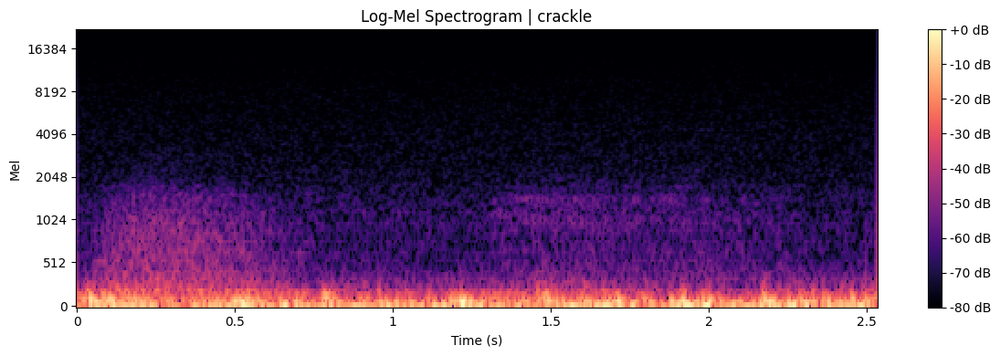


Sumber: segmented_audio_precise/wheeze/112_1p1_Ll_sc_Litt3200_s11.015_e14.557_seg3.wav
Mode  : segment_file
Kelas : wheeze
Patient ID: 112
Waktu segmen: 11.015s - 14.557s
SR    : 4000
Durasi: 3.542 detik
Max amplitude: 0.209106


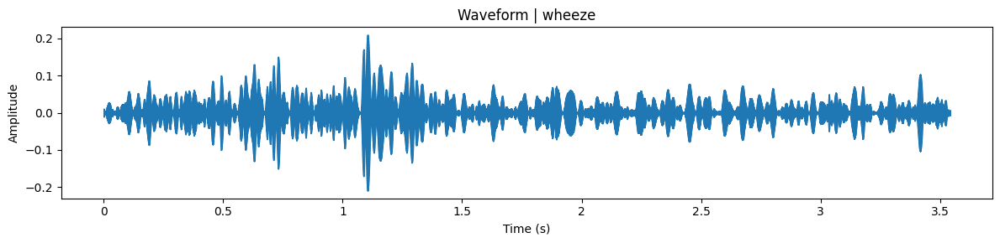

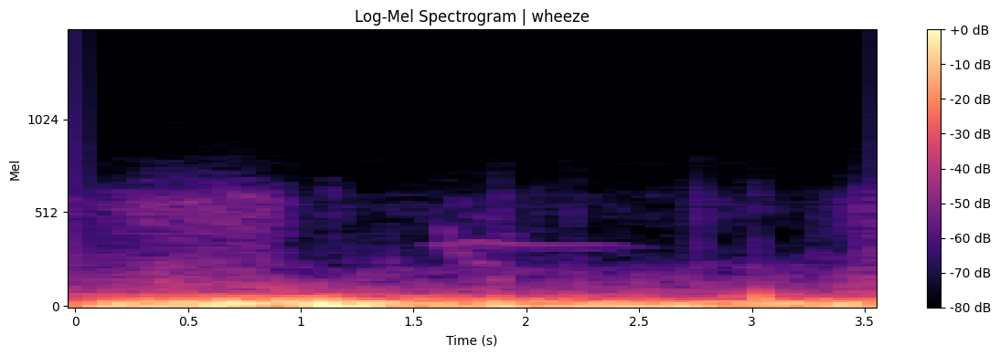


Sumber: segmented_audio_precise/both/151_3p2_Pr_mc_AKGC417L_s0.059_e3.514_seg0.wav
Mode  : segment_file
Kelas : both
Patient ID: 151
Waktu segmen: 0.059s - 3.514s
SR    : 44100
Durasi: 3.455 detik
Max amplitude: 1.000000


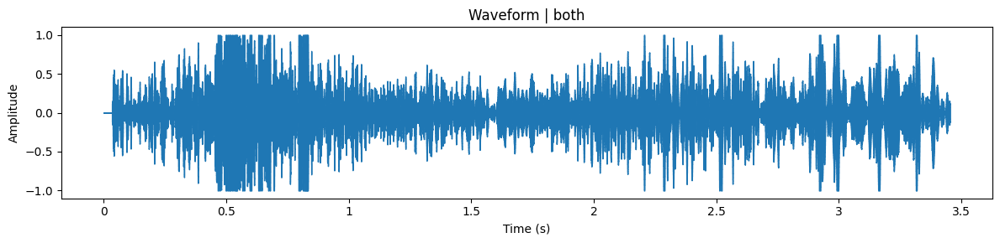

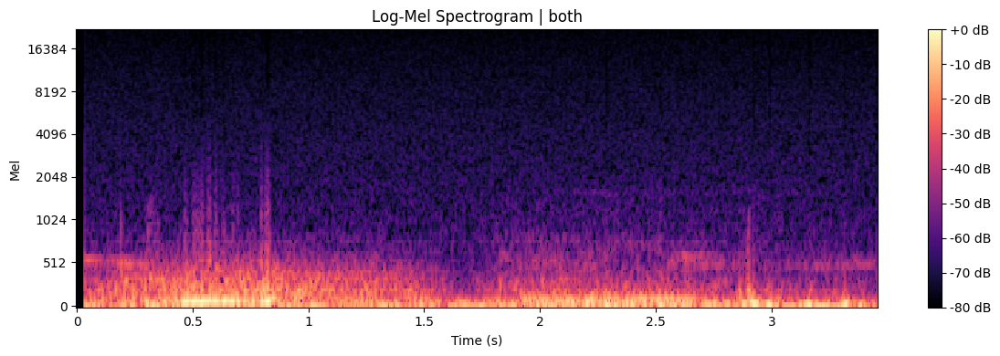

In [ ]:
import os
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display

SEGMENTED_DIR = "segmented_audio_precise"
META_PATH = os.path.join(SEGMENTED_DIR, "metadata_segments_precise.csv")
meta = pd.read_csv(META_PATH)

classes = ["normal", "crackle", "wheeze", "both"]

def load_segment_from_row(row):
    seg_path = str(row.get("file", ""))
    if seg_path and seg_path != "nan" and os.path.exists(seg_path):
        y, sr = librosa.load(seg_path, sr=None, mono=True)
        return y, sr, seg_path, "segment_file"

    wav_source = str(row.get("wav_source", ""))
    if (not wav_source) or wav_source == "nan" or (not os.path.exists(wav_source)):
        raise FileNotFoundError(f"wav_source tidak ditemukan: {wav_source}")

    start = float(row.get("start_sec", 0.0))
    end = float(row.get("end_sec", 0.0))
    if end <= start:
        raise ValueError(f"start/end tidak valid: start={start}, end={end}")

    y_full, sr = sf.read(wav_source, always_2d=False)
    if y_full.ndim > 1:
        y_full = y_full.mean(axis=1)
    y_full = y_full.astype(np.float32, copy=False)

    start_samp = int(np.floor(start * sr))
    end_samp = int(np.ceil(end * sr))
    start_samp = max(0, min(start_samp, len(y_full)))
    end_samp = max(0, min(end_samp, len(y_full)))

    if end_samp <= start_samp:
        raise ValueError("Segment kosong setelah clamp indeks sample")

    y = y_full[start_samp:end_samp]
    return y, sr, wav_source, "sliced_from_raw"


def show_example_from_row(row, n_mels=128, n_fft=1024, hop_length=160, fmax=2000):
    label = row.get("sound", "")
    patient_id = row.get("patient_id", "")
    start = row.get("start_sec", None)
    end = row.get("end_sec", None)

    try:
        y, sr, src, mode = load_segment_from_row(row)
    except Exception as e:
        print("[ERROR] gagal load segmen:", e)
        return

    dur = len(y) / sr if sr else 0.0
    max_amp = float(np.max(np.abs(y))) if len(y) > 0 else 0.0

    print("Sumber:", src)
    print("Mode  :", mode)
    print("Kelas :", label)
    print("Patient ID:", patient_id)
    if start is not None and end is not None:
        print(f"Waktu segmen: {float(start):.3f}s - {float(end):.3f}s")
    print("SR    :", sr)
    print(f"Durasi: {dur:.3f} detik")
    print(f"Max amplitude: {max_amp:.6f}")

    # Audio preview
    if len(y) == 0 or max_amp == 0:
        print("[INFO] sinyal kosong/diam, audio tidak akan terdengar jelas.")
    display(Audio(y, rate=sr, normalize=False))

    # Waveform
    plt.figure(figsize=(12, 3))
    if len(y) > 0:
        librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform | {label}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

    # Log-Mel Spectrogram
    if len(y) > 0:
        S = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=n_mels,
            n_fft=n_fft,
            hop_length=hop_length,
            fmax=fmax
        )
        S_db = librosa.power_to_db(S + 1e-10, ref=np.max)
    else:
        S_db = np.zeros((n_mels, 1))

    plt.figure(figsize=(12, 4))
    librosa.display.specshow(
        S_db,
        sr=sr,
        hop_length=hop_length,
        x_axis="time",
        y_axis="mel"
    )
    plt.title(f"Log-Mel Spectrogram | {label}")
    plt.xlabel("Time (s)")
    plt.ylabel("Mel")
    plt.colorbar(format="%+2.0f dB")
    plt.tight_layout()
    plt.show()


# Ambil 1 sampel acak per kelas, tapi hindari segmen silent kalau ada kolom is_silent
for cls in classes:
    subset = meta[meta["sound"] == cls].copy()
    if len(subset) == 0:
        print(f"\nKelas {cls} tidak ditemukan di metadata.")
        continue

    if "is_silent" in subset.columns:
        subset = subset[subset["is_silent"] == 0]
        if len(subset) == 0:
            # fallback kalau semua ditandai silent
            subset = meta[meta["sound"] == cls].copy()

    row = subset.sample(1, random_state=42).iloc[0]

    print("\n" + "="*80)
    show_example_from_row(row, n_mels=128, n_fft=1024, hop_length=256, fmax=None)

# **Splitting Data**
> **80:10:10**


In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# ============================================================
# 0. Konfigurasi path
# ============================================================

SEGMENTED_DIR = "segmented_audio_precise"
META_SPLIT_DIR = "metadata_split"
os.makedirs(META_SPLIT_DIR, exist_ok=True)

META_FILE = os.path.join(SEGMENTED_DIR, "metadata_segments_precise.csv")

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both"]
BINARY_CLASSES = ["normal", "abnormal"]
ABNORMAL_CLASSES = ["crackle", "wheeze", "both"]


def to_binary_label(label):
    label = str(label).strip().lower()

    if label == "normal":
        return "normal"
    elif label in ABNORMAL_CLASSES:
        return "abnormal"
    else:
        raise ValueError(f"Label tidak dikenal: {label}")


# ============================================================
# 1. Load metadata segmen hasil segmentasi presisi
# ============================================================

meta_segments = pd.read_csv(META_FILE)

print("Memuat metadata dari:", META_FILE)
print("Total segmen awal:", len(meta_segments))

# ============================================================
# 2. Validasi kolom wajib
# ============================================================

required_cols = ["patient_id", "sound", "wav_source", "start_sec", "end_sec"]
missing_cols = [c for c in required_cols if c not in meta_segments.columns]

if len(missing_cols) > 0:
    raise AssertionError(f"Kolom wajib tidak ada di metadata: {missing_cols}")

# Normalisasi kolom penting
meta_segments = meta_segments.copy()
meta_segments["sound"] = meta_segments["sound"].astype(str).str.strip().str.lower()

# Validasi label asli
unknown_source_labels = sorted(set(meta_segments["sound"]) - set(SOURCE_CLASSES))
if len(unknown_source_labels) > 0:
    raise AssertionError(f"Label sound tidak dikenal: {unknown_source_labels}")

# Buang patient_id invalid kalau ada
meta_segments["patient_id"] = meta_segments["patient_id"].astype(int)
meta_segments = meta_segments[meta_segments["patient_id"] != -1].copy()

# Simpan label asli dan buat label binary untuk model
meta_segments["original_sound"] = meta_segments["sound"]
meta_segments["binary_label"] = meta_segments["sound"].apply(to_binary_label)

print("\nDistribusi awal label asli per segmen:")
print(meta_segments["sound"].value_counts().reindex(SOURCE_CLASSES, fill_value=0))

print("\nDistribusi awal binary label per segmen:")
print(meta_segments["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

n_patients = meta_segments["patient_id"].nunique()
print("\nTotal pasien unik:", n_patients)


# ============================================================
# 3. Tentukan label dominan binary per pasien
# ============================================================
patient_labels = (
    meta_segments
    .groupby("patient_id")["binary_label"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index(name="dominant_binary_label")
)

print("\nDistribusi pasien berdasarkan dominant binary label:")
print(patient_labels["dominant_binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

patients = patient_labels["patient_id"].values
labels = patient_labels["dominant_binary_label"].values


# ============================================================
# 4. Split patient-wise: 80% train, 10% val, 10% test
# ============================================================

test_size = 0.10
val_size = 0.10
random_state = 42

# Split train+val vs test
train_val_pat, test_pat = train_test_split(
    patients,
    test_size=test_size,
    stratify=labels,
    random_state=random_state,
)

# Ambil label untuk subset train+val
mask_train_val = patient_labels["patient_id"].isin(train_val_pat)
patients_train_val = patient_labels.loc[mask_train_val, "patient_id"].values
labels_train_val = patient_labels.loc[mask_train_val, "dominant_binary_label"].values

# Dari 90% train+val, ambil 10% total untuk validation
val_ratio = val_size / (1.0 - test_size)

train_pat, val_pat = train_test_split(
    patients_train_val,
    test_size=val_ratio,
    stratify=labels_train_val,
    random_state=random_state,
)


# ============================================================
# 5. Mapping kembali ke segment-level dataframe
# ============================================================

train_df = meta_segments[meta_segments["patient_id"].isin(train_pat)].copy()
val_df = meta_segments[meta_segments["patient_id"].isin(val_pat)].copy()
test_df = meta_segments[meta_segments["patient_id"].isin(test_pat)].copy()

# Cek keras: tidak boleh ada patient leakage
assert set(train_df["patient_id"]) & set(val_df["patient_id"]) == set()
assert set(train_df["patient_id"]) & set(test_df["patient_id"]) == set()
assert set(val_df["patient_id"]) & set(test_df["patient_id"]) == set()

# Cek keras: total segmen tidak boleh berubah
assert len(train_df) + len(val_df) + len(test_df) == len(meta_segments)


# ============================================================
# 6. Tampilkan distribusi setiap subset
# ============================================================

for name, df in [("TRAIN", train_df), ("VAL", val_df), ("TEST", test_df)]:
    print(f"\n[{name}]")
    print("  Pasien unik  :", df["patient_id"].nunique())
    print("  Segmen total :", len(df))

    print("\n  Distribusi label asli:")
    print(df["sound"].value_counts().reindex(SOURCE_CLASSES, fill_value=0))

    print("\n  Distribusi binary label:")
    print(df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

    normal_count = int((df["binary_label"] == "normal").sum())
    abnormal_count = int((df["binary_label"] == "abnormal").sum())
    total_count = len(df)

    print("\n  Rasio binary:")
    print(f"    normal   : {normal_count} ({normal_count / total_count:.4f})")
    print(f"    abnormal : {abnormal_count} ({abnormal_count / total_count:.4f})")


# ============================================================
# 7. Simpan metadata split
# ============================================================

train_path = os.path.join(META_SPLIT_DIR, "metadata_train_precise.csv")
val_path = os.path.join(META_SPLIT_DIR, "metadata_val_precise.csv")
test_path = os.path.join(META_SPLIT_DIR, "metadata_test_precise.csv")

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print("\nMetadata split patient-wise binary disimpan di:")
print(" -", train_path)
print(" -", val_path)
print(" -", test_path)

print("\nKolom penting yang sekarang tersedia:")
print(" - sound           : label asli, yaitu normal/crackle/wheeze/both")
print(" - original_sound  : salinan label asli untuk analisis")
print(" - binary_label    : label model, yaitu normal/abnormal")

Memuat metadata dari: segmented_audio_precise/metadata_segments_precise.csv
Total segmen awal: 6898

Distribusi awal label asli per segmen:
sound
normal     3642
crackle    1864
wheeze      886
both        506
Name: count, dtype: int64

Distribusi awal binary label per segmen:
binary_label
normal      3642
abnormal    3256
Name: count, dtype: int64

Total pasien unik: 126

Distribusi pasien berdasarkan dominant binary label:
dominant_binary_label
normal      86
abnormal    40
Name: count, dtype: int64

[TRAIN]
  Pasien unik  : 100
  Segmen total : 5134

  Distribusi label asli:
sound
normal     2820
crackle    1390
wheeze      627
both        297
Name: count, dtype: int64

  Distribusi binary label:
binary_label
normal      2820
abnormal    2314
Name: count, dtype: int64

  Rasio binary:
    normal   : 2820 (0.5493)
    abnormal : 2314 (0.4507)

[VAL]
  Pasien unik  : 13
  Segmen total : 956

  Distribusi label asli:
sound
normal     330
crackle    380
wheeze     106
both       140
Nam

# **Distribusi Data Awal**

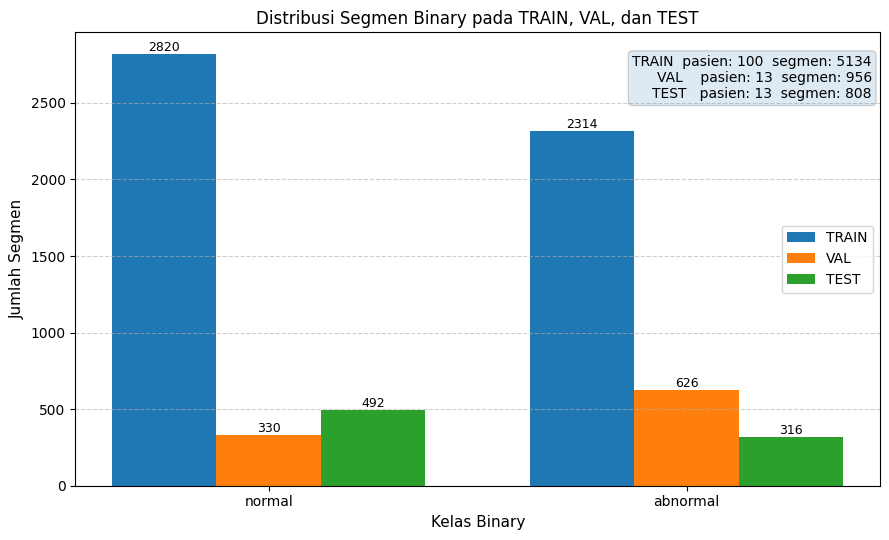


Distribusi binary label per subset:


,train,val,test,total
binary_label,,,,
normal,2820,330,492,3642
abnormal,2314,626,316,3256



Audit distribusi label asli per subset:


,train,val,test,total
sound,,,,
normal,2820,330,492,3642
crackle,1390,380,94,1864
wheeze,627,106,153,886
both,297,140,69,506



Cek patient leakage: aman
Tidak ada patient_id yang muncul di lebih dari satu subset.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 0. Konfigurasi path
# ============================================================

META_SPLIT_DIR = "metadata_split"

train_path = os.path.join(META_SPLIT_DIR, "metadata_train_precise.csv")
val_path   = os.path.join(META_SPLIT_DIR, "metadata_val_precise.csv")
test_path  = os.path.join(META_SPLIT_DIR, "metadata_test_precise.csv")

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both"]
BINARY_CLASSES = ["normal", "abnormal"]
ABNORMAL_CLASSES = ["crackle", "wheeze", "both"]


def to_binary_label(label):
    label = str(label).strip().lower()

    if label == "normal":
        return "normal"
    elif label in ABNORMAL_CLASSES:
        return "abnormal"
    else:
        raise ValueError(f"Label tidak dikenal: {label}")


# ============================================================
# 1. Normalisasi metadata split
# ============================================================

def clean_split_df(df):
    df = df.copy()

    required_cols = ["patient_id", "sound"]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if len(missing_cols) > 0:
        raise AssertionError(f"Kolom wajib tidak ada: {missing_cols}")

    df["sound"] = df["sound"].astype(str).str.strip().str.lower()

    unknown_labels = sorted(set(df["sound"]) - set(SOURCE_CLASSES))
    if len(unknown_labels) > 0:
        raise AssertionError(f"Label sound tidak dikenal: {unknown_labels}")

    if "original_sound" not in df.columns:
        df["original_sound"] = df["sound"]
    else:
        df["original_sound"] = df["original_sound"].astype(str).str.strip().str.lower()

    if "binary_label" not in df.columns:
        df["binary_label"] = df["sound"].apply(to_binary_label)
    else:
        df["binary_label"] = df["binary_label"].astype(str).str.strip().str.lower()

    unknown_binary = sorted(set(df["binary_label"]) - set(BINARY_CLASSES))
    if len(unknown_binary) > 0:
        raise AssertionError(f"Label binary tidak dikenal: {unknown_binary}")

    df = df.dropna(subset=["patient_id"])
    df["patient_id"] = df["patient_id"].astype(int)
    df = df[df["patient_id"] != -1].copy()

    return df


train_df = clean_split_df(train_df)
val_df   = clean_split_df(val_df)
test_df  = clean_split_df(test_df)


# ============================================================
# 2. Hitung distribusi binary label
# ============================================================

train_counts = train_df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0)
val_counts   = val_df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0)
test_counts  = test_df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0)

train_pat, train_seg = train_df["patient_id"].nunique(), len(train_df)
val_pat,   val_seg   = val_df["patient_id"].nunique(), len(val_df)
test_pat,  test_seg  = test_df["patient_id"].nunique(), len(test_df)


# ============================================================
# 3. Visualisasi distribusi binary label
# ============================================================

x = np.arange(len(BINARY_CLASSES))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5.5))

b1 = ax.bar(x - width, train_counts.values, width, label="TRAIN")
b2 = ax.bar(x,         val_counts.values,   width, label="VAL")
b3 = ax.bar(x + width, test_counts.values,  width, label="TEST")

ax.set_title("Distribusi Segmen Binary pada TRAIN, VAL, dan TEST", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(BINARY_CLASSES)
ax.set_xlabel("Kelas Binary", fontsize=11)
ax.set_ylabel("Jumlah Segmen", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend()

for bar in list(b1) + list(b2) + list(b3):
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{int(h)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

summary_text = (
    f"TRAIN  pasien: {train_pat}  segmen: {train_seg}\n"
    f"VAL    pasien: {val_pat}  segmen: {val_seg}\n"
    f"TEST   pasien: {test_pat}  segmen: {test_seg}"
)

ax.text(
    0.99, 0.95,
    summary_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.tight_layout()
plt.show()


# ============================================================
# 4. Tabel distribusi binary label
# ============================================================

binary_table = pd.DataFrame({
    "train": train_counts,
    "val": val_counts,
    "test": test_counts
}).astype(int)

binary_table["total"] = binary_table.sum(axis=1)

print("\nDistribusi binary label per subset:")
display(binary_table)


# ============================================================
# 5. Audit tambahan: distribusi label asli
# ============================================================
# Ini bukan target model, tetapi penting untuk laporan.
# Reviewer perlu melihat bahwa kelas abnormal berasal dari crackle, wheeze, dan both.

source_train_counts = train_df["sound"].value_counts().reindex(SOURCE_CLASSES, fill_value=0)
source_val_counts   = val_df["sound"].value_counts().reindex(SOURCE_CLASSES, fill_value=0)
source_test_counts  = test_df["sound"].value_counts().reindex(SOURCE_CLASSES, fill_value=0)

source_table = pd.DataFrame({
    "train": source_train_counts,
    "val": source_val_counts,
    "test": source_test_counts
}).astype(int)

source_table["total"] = source_table.sum(axis=1)

print("\nAudit distribusi label asli per subset:")
display(source_table)


# ============================================================
# 6. Cek patient leakage
# ============================================================

train_patients = set(train_df["patient_id"].unique())
val_patients   = set(val_df["patient_id"].unique())
test_patients  = set(test_df["patient_id"].unique())

assert train_patients & val_patients == set(), "Patient leakage antara train dan val"
assert train_patients & test_patients == set(), "Patient leakage antara train dan test"
assert val_patients & test_patients == set(), "Patient leakage antara val dan test"

print("\nCek patient leakage: aman")
print("Tidak ada patient_id yang muncul di lebih dari satu subset.")

# **Preprocessing - Normalisasi Data Audio**

In [ ]:
# ============================================================
# CELL: PREPROCESSING AUDIO PAPER-STYLE 16 kHz + FIXED 5 DETIK CHUNKING
# Target: Binary Normal-Abnormal
# ============================================================
import os
import re
import math
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf

from scipy.signal import butter, sosfiltfilt, resample_poly
from tqdm.auto import tqdm


# ============================================================
# 0. INPUT METADATA SPLIT
# ============================================================

CANDIDATE_SPLIT_DIRS = [
    Path("paper_binary_16k_outputs/02_split_metadata"),
    Path("metadata_split"),
]

SPLIT_NAMES = ["train", "val", "test"]


# ============================================================
# 1. OUTPUT FOLDER
# ============================================================

OUT_DIR = Path("paper_binary_16k_outputs/03_preprocessed_audio_16k5s")
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. PARAMETER PREPROCESSING
# ============================================================

TARGET_SR = 16000

APPLY_BANDPASS = True
LOWCUT = 20.0
HIGHCUT = 8000.0
FILTER_ORDER = 4

# memakai RMS normalization ke -15 dBFS.
TARGET_DBFS = -15.0

# Normalisasi panjang durasi
FIX_LEN_SEC = 5.0
FIX_LEN = int(TARGET_SR * FIX_LEN_SEC)

# Random padding dibuat deterministik agar hasil identik pada setiap rerun.
RANDOM_PADDING_SEED = 42
PADDING_STRATEGY = "deterministic_random_zero_padding_for_short_or_last_chunk"
FIX_STRATEGY = "sequential_5s_chunking_with_deterministic_random_padding"

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both"]
BINARY_CLASSES = ["normal", "abnormal"]
ABNORMAL_CLASSES = ["crackle", "wheeze", "both"]

LABEL_TO_ID = {
    "normal": 0,
    "abnormal": 1
}

ID_TO_LABEL = {
    0: "normal",
    1: "abnormal"
}


# ============================================================
# 3. HELPER PATH DAN METADATA
# ============================================================

def find_split_metadata(split_name):
    candidates = []

    for d in CANDIDATE_SPLIT_DIRS:
        candidates.extend([
            d / f"metadata_{split_name}_binary.csv",
            d / f"metadata_{split_name}.csv",
            d / f"metadata_{split_name}_precise.csv",
        ])

    for p in candidates:
        if p.exists():
            return p

    raise FileNotFoundError(
        f"Metadata split `{split_name}` tidak ditemukan. "
        f"Jalankan cell splitting train, val, test terlebih dahulu."
    )


def safe_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def sanitize_token(s):
    s = str(s).strip()
    s = s.replace("\\", "_").replace("/", "_").replace(" ", "_")
    s = re.sub(r"[^A-Za-z0-9_.+-]", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s if s else "unknown"


def stable_seed_from_parts(*parts, base_seed=RANDOM_PADDING_SEED):
    """Membentuk seed stabil lintas proses dari identitas sampel dan indeks chunk."""
    payload = "||".join([str(base_seed), *[str(p) for p in parts]])
    digest = hashlib.sha256(payload.encode("utf-8")).digest()
    return int.from_bytes(digest[:8], byteorder="little", signed=False)


def deterministic_random_padding_split(padding_len, seed_key, chunk_idx):
    """
    Membagi total zero padding ke sisi kiri dan kanan secara pseudoacak,
    tetapi deterministik untuk seed_key dan chunk_idx yang sama.
    """
    padding_len = int(padding_len)

    if padding_len <= 0:
        return 0, 0, -1

    padding_seed = stable_seed_from_parts(seed_key, int(chunk_idx))
    rng = np.random.default_rng(padding_seed)

    padding_left = int(rng.integers(0, padding_len + 1))
    padding_right = int(padding_len - padding_left)

    if padding_left + padding_right != padding_len:
        raise RuntimeError("Jumlah padding kiri dan kanan tidak sama dengan total padding.")

    return padding_left, padding_right, int(padding_seed)


def build_padding_seed_key(split_name, patient_id, sample_id, input_audio_path, row):
    """Membentuk kunci deterministik tanpa bergantung pada urutan metadata."""
    start_sec = row.get("start_sec", "")
    end_sec = row.get("end_sec", "")

    raw_key = "|".join([
        safe_str(split_name),
        safe_str(patient_id),
        safe_str(sample_id),
        safe_str(input_audio_path),
        safe_str(start_sec),
        safe_str(end_sec),
    ])

    return hashlib.sha256(raw_key.encode("utf-8")).hexdigest()[:24]


def to_binary_label_from_sound(sound):
    sound = str(sound).strip().lower()

    if sound == "normal":
        return "normal"

    if sound in ABNORMAL_CLASSES:
        return "abnormal"

    if sound == "abnormal":
        return "abnormal"

    raise ValueError(f"Label tidak dikenal: {sound}")


def infer_sound_4class(row):
    if "sound_4class" in row.index and safe_str(row["sound_4class"]):
        return safe_str(row["sound_4class"]).lower()

    if "original_sound" in row.index and safe_str(row["original_sound"]):
        return safe_str(row["original_sound"]).lower()

    if "sound" in row.index and safe_str(row["sound"]):
        sound = safe_str(row["sound"]).lower()

        if sound in SOURCE_CLASSES:
            return sound

        if sound == "abnormal":
            return "abnormal"

    crackle = int(float(row.get("crackle", 0))) if "crackle" in row.index else 0
    wheeze = int(float(row.get("wheeze", 0))) if "wheeze" in row.index else 0

    if crackle == 1 and wheeze == 1:
        return "both"

    if crackle == 1 and wheeze == 0:
        return "crackle"

    if crackle == 0 and wheeze == 1:
        return "wheeze"

    return "normal"


def normalize_metadata(df, split_name):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    if "patient_id" not in df.columns:
        raise AssertionError(f"{split_name}: kolom `patient_id` tidak ditemukan.")

    df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")
    df = df.dropna(subset=["patient_id"]).copy()
    df["patient_id"] = df["patient_id"].astype(int)
    df = df[df["patient_id"] != -1].copy()

    if "audio_path" not in df.columns:
        if "file" in df.columns:
            df["audio_path"] = df["file"].astype(str)
        else:
            df["audio_path"] = ""

    df["audio_path"] = df["audio_path"].astype(str)

    has_audio_path = df["audio_path"].astype(str).str.len() > 0
    has_slice_info = {"wav_source", "start_sec", "end_sec"}.issubset(set(df.columns))

    if not has_audio_path.any() and not has_slice_info:
        raise AssertionError(
            f"{split_name}: metadata harus punya `audio_path/file`, "
            f"atau punya `wav_source`, `start_sec`, dan `end_sec`."
        )

    df["sound_4class"] = df.apply(infer_sound_4class, axis=1)

    if "binary_label" not in df.columns:
        df["binary_label"] = df["sound_4class"].apply(to_binary_label_from_sound)
    else:
        df["binary_label"] = df["binary_label"].astype(str).str.strip().str.lower()

        invalid_binary = ~df["binary_label"].isin(BINARY_CLASSES)

        if invalid_binary.any():
            df.loc[invalid_binary, "binary_label"] = (
                df.loc[invalid_binary, "sound_4class"]
                .apply(to_binary_label_from_sound)
            )

    df["label_id"] = df["binary_label"].map(LABEL_TO_ID).astype(int)
    df["split"] = split_name

    if "sample_id" not in df.columns:
        def make_sample_id(row):
            if safe_str(row.get("audio_path", "")):
                stem = Path(str(row["audio_path"])).stem
            elif safe_str(row.get("wav_source", "")):
                stem = Path(str(row["wav_source"])).stem
            else:
                stem = "unknown"

            start = float(row.get("start_sec", 0.0))
            end = float(row.get("end_sec", 0.0))

            return f"{sanitize_token(stem)}_s{start:.3f}_e{end:.3f}"

        df["sample_id"] = df.apply(make_sample_id, axis=1)

    unknown_binary = sorted(set(df["binary_label"].unique()) - set(BINARY_CLASSES))

    if len(unknown_binary) > 0:
        raise AssertionError(f"{split_name}: binary_label tidak valid: {unknown_binary}")

    return df.reset_index(drop=True)


# ============================================================
# 4. HELPER AUDIO
# ============================================================

def safe_audio_array(y):
    if y is None:
        return None

    y = np.asarray(y, dtype=np.float64)

    if y.ndim > 1:
        y = y.mean(axis=1)

    if len(y) == 0:
        return None

    y = np.nan_to_num(
        y,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    if not np.all(np.isfinite(y)):
        return None

    max_abs = float(np.max(np.abs(y))) if len(y) > 0 else 0.0

    if not np.isfinite(max_abs):
        return None

    if max_abs > 10.0:
        y = y / (max_abs + 1e-12)

    return y.astype(np.float64, copy=False)


def compute_rms_dbfs(y, eps=1e-10):
    y = safe_audio_array(y)

    if y is None or len(y) == 0:
        return np.nan, np.nan

    rms = float(np.sqrt(np.mean(np.square(y, dtype=np.float64)) + eps))
    dbfs = float(20.0 * np.log10(rms + eps))

    return rms, dbfs


def resample_to_target(y, orig_sr, target_sr=TARGET_SR):
    y = safe_audio_array(y)

    if y is None or len(y) == 0:
        return None

    orig_sr = int(orig_sr)
    target_sr = int(target_sr)

    if orig_sr == target_sr:
        return y.astype(np.float32, copy=False)

    gcd = math.gcd(orig_sr, target_sr)
    up = target_sr // gcd
    down = orig_sr // gcd

    try:
        y_rs = resample_poly(y, up, down)
    except Exception:
        return None

    y_rs = safe_audio_array(y_rs)

    if y_rs is None or len(y_rs) == 0:
        return None

    return y_rs.astype(np.float32, copy=False)


def bandpass_filter(y, sr, lowcut=LOWCUT, highcut=HIGHCUT, order=FILTER_ORDER):
    y = safe_audio_array(y)

    if y is None or len(y) == 0:
        return None

    if not np.any(y):
        return y.astype(np.float32, copy=False)

    nyq = 0.5 * float(sr)

    lowcut_eff = max(float(lowcut), 1.0)
    highcut_eff = min(float(highcut), nyq * 0.95)

    if highcut_eff <= lowcut_eff:
        return y.astype(np.float32, copy=False)

    low = lowcut_eff / nyq
    high = highcut_eff / nyq

    try:
        sos = butter(
            int(order),
            [low, high],
            btype="band",
            output="sos"
        )

        y_filt = sosfiltfilt(sos, y)

    except Exception:
        y_filt = y

    y_filt = np.nan_to_num(
        y_filt,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    if not np.all(np.isfinite(y_filt)):
        return None

    return y_filt.astype(np.float32, copy=False)


def normalize_to_dbfs(y, target_dbfs=TARGET_DBFS, eps=1e-10):
    y = safe_audio_array(y)

    if y is None or len(y) == 0:
        return None

    rms = float(np.sqrt(np.mean(np.square(y, dtype=np.float64)) + eps))

    if not np.isfinite(rms) or rms <= eps:
        return y.astype(np.float32, copy=False)

    target_rms = 10.0 ** (float(target_dbfs) / 20.0)
    gain = target_rms / rms

    y_norm = y * gain

    y_norm = np.nan_to_num(
        y_norm,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    y_norm = np.clip(y_norm, -1.0, 1.0)

    return y_norm.astype(np.float32, copy=False)


def split_into_5s_chunks(y, target_len=FIX_LEN, padding_seed_key="unknown"):
    """
    Membagi audio secara sekuensial menjadi chunk fixed 5 detik.

    Tidak ada sisa audio yang dibuang. Chunk terakhir yang lebih pendek
    diberi zero padding pada sisi kiri dan kanan. Posisi padding bersifat
    pseudoacak tetapi deterministik berdasarkan identitas sampel, indeks
    chunk, dan RANDOM_PADDING_SEED.
    """
    if y is None or len(y) == 0:
        return []

    y = y.astype(np.float32, copy=False)

    total_len = int(len(y))
    n_chunks = int(np.ceil(total_len / target_len))

    chunk_items = []

    for chunk_idx in range(n_chunks):
        start = chunk_idx * target_len
        end = min(start + target_len, total_len)

        chunk = y[start:end].astype(np.float32, copy=False)
        active_len = int(len(chunk))

        padding_len = 0
        padding_left_len = 0
        padding_right_len = 0
        padding_duration = 0.0
        padding_left_duration = 0.0
        padding_right_duration = 0.0
        padding_ratio = 0.0
        padding_seed = -1

        if active_len < target_len:
            padding_len = int(target_len - active_len)

            (
                padding_left_len,
                padding_right_len,
                padding_seed,
            ) = deterministic_random_padding_split(
                padding_len=padding_len,
                seed_key=padding_seed_key,
                chunk_idx=chunk_idx,
            )

            chunk = np.pad(
                chunk,
                (padding_left_len, padding_right_len),
                mode="constant",
                constant_values=0.0,
            ).astype(np.float32, copy=False)

            padding_duration = float(padding_len / TARGET_SR)
            padding_left_duration = float(padding_left_len / TARGET_SR)
            padding_right_duration = float(padding_right_len / TARGET_SR)
            padding_ratio = float(padding_len / target_len)

        if len(chunk) != target_len:
            raise RuntimeError(f"Chunk length invalid: {len(chunk)} != {target_len}")

        if padding_left_len + padding_right_len != padding_len:
            raise RuntimeError(
                "Audit padding gagal: padding kiri + kanan tidak sama dengan total padding."
            )

        active_start_after_fix = int(padding_left_len)
        active_end_after_fix = int(padding_left_len + active_len)

        fix_info = {
            "target_sec": float(FIX_LEN_SEC),
            "target_len_samples": int(target_len),

            "chunk_idx": int(chunk_idx),
            "n_chunks_from_segment": int(n_chunks),

            "chunk_start_sample_before_fix": int(start),
            "chunk_end_sample_before_fix": int(end),
            "chunk_start_sec_before_fix": float(start / TARGET_SR),
            "chunk_end_sec_before_fix": float(end / TARGET_SR),

            "original_segment_len_samples": int(total_len),
            "original_segment_duration_sec": float(total_len / TARGET_SR),

            "active_len_samples_before_fix": int(active_len),
            "active_duration_sec_before_fix": float(active_len / TARGET_SR),

            "padding_len_samples": int(padding_len),
            "padding_duration_sec": float(padding_duration),
            "padding_ratio": float(padding_ratio),

            "padding_left_len_samples": int(padding_left_len),
            "padding_right_len_samples": int(padding_right_len),
            "padding_left_duration_sec": float(padding_left_duration),
            "padding_right_duration_sec": float(padding_right_duration),
            "padding_random_seed": int(padding_seed),
            "padding_seed_key": str(padding_seed_key),

            "active_start_sample_after_fix": int(active_start_after_fix),
            "active_end_sample_after_fix": int(active_end_after_fix),

            "crop_len_samples": 0,
            "crop_duration_sec": 0.0,
            "crop_start_sample": 0,
            "crop_end_sample": 0,

            "fix_strategy": FIX_STRATEGY,
            "padding_strategy": PADDING_STRATEGY,
            "crop_strategy": "none",
            "truncate_strategy": "none",

            "kept_start_sample": int(start),
            "kept_end_sample": int(end),
        }

        chunk_items.append((chunk, fix_info))

    return chunk_items

def preprocess_audio(y, sr, padding_seed_key="unknown"):
    """
    Urutan preprocessing:
    1. Resample ke 16 kHz
    2. Bandpass 50 sampai 2000 Hz
    3. Normalisasi RMS ke -15 dBFS pada sinyal aktif
    4. Split sekuensial menjadi chunk 5 detik
    5. Chunk terakhir yang pendek diberi deterministic random zero padding
       pada sisi kiri dan kanan tanpa membuang sisa audio.
    """
    y = safe_audio_array(y)

    if y is None or len(y) == 0:
        return []

    input_rms, input_dbfs = compute_rms_dbfs(y)

    y = resample_to_target(y, sr, TARGET_SR)

    if y is None or len(y) == 0:
        return []

    resampled_rms, resampled_dbfs = compute_rms_dbfs(y)

    if APPLY_BANDPASS:
        y = bandpass_filter(
            y,
            TARGET_SR,
            lowcut=LOWCUT,
            highcut=HIGHCUT,
            order=FILTER_ORDER
        )

        if y is None or len(y) == 0:
            return []

    filtered_rms, filtered_dbfs = compute_rms_dbfs(y)

    y = normalize_to_dbfs(y, target_dbfs=TARGET_DBFS)

    if y is None or len(y) == 0:
        return []

    active_rms_after_norm, active_dbfs_after_norm = compute_rms_dbfs(y)
    active_peak_after_norm = float(np.max(np.abs(y))) if len(y) > 0 else np.nan

    chunk_items = split_into_5s_chunks(
        y,
        target_len=FIX_LEN,
        padding_seed_key=padding_seed_key,
    )

    processed_items = []

    for y_fixed, fix_info in chunk_items:
        if y_fixed is None or fix_info is None:
            continue

        if len(y_fixed) != FIX_LEN:
            continue

        if not np.all(np.isfinite(y_fixed)):
            continue

        processed_rms_after_fix, processed_dbfs_after_fix = compute_rms_dbfs(y_fixed)
        processed_peak_after_fix = float(np.max(np.abs(y_fixed))) if len(y_fixed) > 0 else np.nan

        norm_info = {
            "input_rms": input_rms,
            "input_dbfs": input_dbfs,

            "resampled_rms": resampled_rms,
            "resampled_dbfs": resampled_dbfs,

            "filtered_rms": filtered_rms,
            "filtered_dbfs": filtered_dbfs,

            "active_rms_after_norm": active_rms_after_norm,
            "active_dbfs_after_norm": active_dbfs_after_norm,
            "active_peak_after_norm": active_peak_after_norm,

            "processed_rms_after_fix": processed_rms_after_fix,
            "processed_dbfs_after_fix": processed_dbfs_after_fix,
            "processed_peak_after_fix": processed_peak_after_fix,
        }

        processed_items.append(
            (
                y_fixed.astype(np.float32, copy=False),
                TARGET_SR,
                fix_info,
                norm_info
            )
        )

    return processed_items


def read_audio_from_row(row):
    audio_path = safe_str(row.get("audio_path", ""))

    if audio_path and Path(audio_path).exists():
        try:
            y, sr = sf.read(
                audio_path,
                always_2d=False,
                dtype="float64"
            )

            y = safe_audio_array(y)

            if y is None or len(y) == 0:
                return None, None, None

            info = {
                "input_mode": "segmented_audio_path",
                "input_audio_path": audio_path,
                "original_sr": int(sr),
                "original_len_samples": int(len(y)),
                "original_duration_sec": float(len(y) / sr),
            }

            return y, int(sr), info

        except Exception:
            return None, None, None

    wav_source = safe_str(row.get("wav_source", ""))

    if not wav_source or not Path(wav_source).exists():
        return None, None, None

    if "start_sec" not in row.index or "end_sec" not in row.index:
        return None, None, None

    try:
        file_info = sf.info(wav_source)
        sr = int(file_info.samplerate)
        total_frames = int(file_info.frames)

        start_sec = float(row["start_sec"])
        end_sec = float(row["end_sec"])

        start_samp = int(np.floor(start_sec * sr))
        end_samp = int(np.ceil(end_sec * sr))

        start_samp = max(0, min(start_samp, total_frames))
        end_samp = max(0, min(end_samp, total_frames))

        if end_samp <= start_samp:
            return None, None, None

        frames_to_read = end_samp - start_samp

        y, sr_read = sf.read(
            wav_source,
            start=start_samp,
            frames=frames_to_read,
            always_2d=False,
            dtype="float64"
        )

        y = safe_audio_array(y)

        if y is None or len(y) == 0:
            return None, None, None

        info = {
            "input_mode": "slice_from_wav_source",
            "input_audio_path": wav_source,
            "original_sr": int(sr_read),
            "original_len_samples": int(len(y)),
            "original_duration_sec": float(len(y) / sr_read),
            "source_total_samples": int(total_frames),
            "source_total_duration_sec": float(total_frames / sr),
        }

        return y, int(sr_read), info

    except Exception:
        return None, None, None


def make_short_id(sample_id, row_idx):
    raw = f"{sample_id}_{row_idx}"
    return hashlib.md5(raw.encode("utf-8")).hexdigest()[:16]


# ============================================================
# 5. RUNNER PREPROCESSING PER SPLIT
# ============================================================

def run_preprocess_split(split_name):
    meta_path = find_split_metadata(split_name)

    raw_df = pd.read_csv(meta_path)
    df = normalize_metadata(raw_df, split_name)

    out_split_dir = OUT_DIR / split_name
    out_split_dir.mkdir(parents=True, exist_ok=True)

    out_rows = []

    skipped = 0
    skipped_read = 0
    skipped_preprocess = 0
    skipped_write = 0

    print("\n" + "=" * 80)
    print(f"PREPROCESSING SPLIT: {split_name.upper()}")
    print("=" * 80)
    print("Input metadata :", meta_path)
    print("Output folder  :", out_split_dir)
    print("Jumlah metadata:", len(df))
    print("Target SR      :", TARGET_SR)
    print("Bandpass       :", f"{LOWCUT} sampai {HIGHCUT} Hz")
    print("Target dBFS    :", TARGET_DBFS)
    print("Fixed length   :", f"{FIX_LEN_SEC} detik = {FIX_LEN} samples")
    print("Fix strategy   :", FIX_STRATEGY)
    print("Padding strategy:", PADDING_STRATEGY)
    print("Random pad seed:", RANDOM_PADDING_SEED)

    print("\nDistribusi binary label sebelum preprocessing:")
    print(df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

    print("\nDistribusi 4 kelas untuk audit:")
    print(df["sound_4class"].value_counts(dropna=False))

    for idx, row in tqdm(df.iterrows(), total=len(df), ncols=100):
        y, sr, input_info = read_audio_from_row(row)

        if y is None or sr is None or input_info is None:
            skipped += 1
            skipped_read += 1
            continue

        sample_id = safe_str(row.get("sample_id", ""))

        if not sample_id:
            sample_id = f"{Path(input_info['input_audio_path']).stem}_{idx}"

        sample_id_clean = sanitize_token(sample_id)

        binary_label = safe_str(row["binary_label"]).lower()
        sound_4class = safe_str(row["sound_4class"]).lower()
        patient_id = int(row["patient_id"])
        label_id = int(row["label_id"])

        padding_seed_key = build_padding_seed_key(
            split_name=split_name,
            patient_id=patient_id,
            sample_id=sample_id_clean,
            input_audio_path=input_info["input_audio_path"],
            row=row,
        )

        processed_items = preprocess_audio(
            y,
            sr,
            padding_seed_key=padding_seed_key,
        )

        if len(processed_items) == 0:
            skipped += 1
            skipped_preprocess += 1
            continue

        short_id = make_short_id(sample_id_clean, idx)

        for y_out, sr_out, fix_info, norm_info in processed_items:
            if len(y_out) != FIX_LEN or not np.all(np.isfinite(y_out)):
                skipped += 1
                skipped_preprocess += 1
                continue

            chunk_idx = int(fix_info["chunk_idx"])
            n_chunks = int(fix_info["n_chunks_from_segment"])

            out_name = (
                f"{short_id}"
                f"_chunk{chunk_idx:03d}of{n_chunks:03d}"
                f"_pid{patient_id}"
                f"_bin{binary_label}"
                f"_orig{sound_4class}"
                f"_16k5s.wav"
            )

            out_name = sanitize_token(out_name.replace(".wav", "")) + ".wav"
            out_path = out_split_dir / out_name

            try:
                sf.write(
                    str(out_path),
                    y_out,
                    sr_out,
                    subtype="PCM_16"
                )
            except Exception:
                skipped += 1
                skipped_write += 1
                continue

            out_row = {
                "sample_id": f"{sample_id_clean}_chunk{chunk_idx:03d}",
                "parent_sample_id": sample_id_clean,

                "file": str(out_path),
                "audio_path": str(out_path),

                "split": split_name,
                "patient_id": patient_id,

                "binary_label": binary_label,
                "label_id": label_id,
                "sound_4class": sound_4class,

                "is_augmented": int(row.get("is_augmented", 0)) if "is_augmented" in row.index else 0,
                "aug_type": safe_str(row.get("aug_type", "none")) if "aug_type" in row.index else "none",
                "source": "preprocessed_original_16k5s",

                "target_sr": int(sr_out),
                "target_sec": float(FIX_LEN_SEC),
                "target_len_samples": int(FIX_LEN),

                "target_dbfs": float(TARGET_DBFS),
                "apply_bandpass": bool(APPLY_BANDPASS),
                "lowcut": float(LOWCUT),
                "highcut": float(HIGHCUT),
                "filter_order": int(FILTER_ORDER),

                "processed_len_samples": int(len(y_out)),
                "processed_duration_sec": float(len(y_out) / sr_out),

                "fix_strategy": fix_info["fix_strategy"],
                "padding_strategy": fix_info["padding_strategy"],
                "crop_strategy": fix_info["crop_strategy"],
                "truncate_strategy": fix_info["truncate_strategy"],

                "chunk_idx": chunk_idx,
                "n_chunks_from_segment": n_chunks,

                "chunk_start_sample_before_fix": fix_info["chunk_start_sample_before_fix"],
                "chunk_end_sample_before_fix": fix_info["chunk_end_sample_before_fix"],
                "chunk_start_sec_before_fix": fix_info["chunk_start_sec_before_fix"],
                "chunk_end_sec_before_fix": fix_info["chunk_end_sec_before_fix"],

                "original_segment_len_samples": fix_info["original_segment_len_samples"],
                "original_segment_duration_sec": fix_info["original_segment_duration_sec"],

                "active_len_samples_before_fix": fix_info["active_len_samples_before_fix"],
                "active_duration_sec_before_fix": fix_info["active_duration_sec_before_fix"],

                "padding_len_samples": fix_info["padding_len_samples"],
                "padding_duration_sec": fix_info["padding_duration_sec"],
                "padding_ratio": fix_info["padding_ratio"],

                "padding_left_len_samples": fix_info["padding_left_len_samples"],
                "padding_right_len_samples": fix_info["padding_right_len_samples"],
                "padding_left_duration_sec": fix_info["padding_left_duration_sec"],
                "padding_right_duration_sec": fix_info["padding_right_duration_sec"],
                "padding_random_seed": fix_info["padding_random_seed"],
                "padding_seed_key": fix_info["padding_seed_key"],

                "active_start_sample_after_fix": fix_info["active_start_sample_after_fix"],
                "active_end_sample_after_fix": fix_info["active_end_sample_after_fix"],

                "crop_len_samples": fix_info["crop_len_samples"],
                "crop_duration_sec": fix_info["crop_duration_sec"],
                "crop_start_sample": fix_info["crop_start_sample"],
                "crop_end_sample": fix_info["crop_end_sample"],

                "kept_start_sample": fix_info["kept_start_sample"],
                "kept_end_sample": fix_info["kept_end_sample"],

                "wav_source": safe_str(row.get("wav_source", "")),
                "txt_source": safe_str(row.get("txt_source", "")),
                "start_sec": float(row.get("start_sec", np.nan)) if "start_sec" in row.index else np.nan,
                "end_sec": float(row.get("end_sec", np.nan)) if "end_sec" in row.index else np.nan,
                "crackle": int(float(row.get("crackle", 0))) if "crackle" in row.index else 0,
                "wheeze": int(float(row.get("wheeze", 0))) if "wheeze" in row.index else 0,
            }

            for k, v in input_info.items():
                out_row[k] = v

            for k, v in norm_info.items():
                out_row[k] = v

            passthrough_cols = [
                "disease",
                "recording_stem",
                "segment_idx",
                "segment_key",
                "duration_sec",
                "max_amp",
                "is_silent"
            ]

            for c in passthrough_cols:
                if c in row.index and c not in out_row:
                    out_row[c] = row[c]

            out_rows.append(out_row)

    out_df = pd.DataFrame(out_rows)

    if len(out_df) == 0:
        raise RuntimeError(f"{split_name}: tidak ada audio yang berhasil diproses.")

    out_csv = OUT_DIR / f"metadata_{split_name}_16k5s.csv"
    out_df.to_csv(out_csv, index=False)

    print("\nSelesai:", split_name.upper())
    print("Tersimpan          :", len(out_df))
    print("Skip total         :", skipped)
    print("Skip read          :", skipped_read)
    print("Skip preprocessing :", skipped_preprocess)
    print("Skip write         :", skipped_write)

    print("\nDistribusi binary label output:")
    print(out_df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

    print("\nDistribusi target_sr:")
    print(out_df["target_sr"].value_counts(dropna=False).sort_index())

    print("\nDistribusi panjang hasil preprocessing:")
    print(out_df["processed_duration_sec"].value_counts(dropna=False).sort_index().head(10))

    print("\nDistribusi fix_strategy:")
    print(out_df["fix_strategy"].value_counts(dropna=False))

    print("\nDistribusi jumlah chunk per parent segment:")
    print(out_df.groupby("parent_sample_id")["chunk_idx"].count().describe())

    print("\nPadding ratio per binary label:")
    print(out_df.groupby("binary_label")["padding_ratio"].describe())

    print("\nJumlah padding kiri dan kanan (samples):")
    print(
        out_df[[
            "padding_len_samples",
            "padding_left_len_samples",
            "padding_right_len_samples",
        ]].describe()
    )

    print("\nActive dBFS setelah normalisasi, sebelum chunking/padding:")
    print(out_df["active_dbfs_after_norm"].describe())

    print("\nProcessed dBFS setelah fixed 5 detik:")
    print(out_df["processed_dbfs_after_fix"].describe())

    print("\nMetadata output:")
    print(out_csv)

    return out_df


# ============================================================
# 6. EKSEKUSI PREPROCESSING
# ============================================================

train_out = run_preprocess_split("train")
val_out   = run_preprocess_split("val")
test_out  = run_preprocess_split("test")


# ============================================================
# 7. VALIDASI ANTI-LEAKAGE PATIENT
# ============================================================

train_patients = set(train_out["patient_id"].unique())
val_patients = set(val_out["patient_id"].unique())
test_patients = set(test_out["patient_id"].unique())

assert train_patients.isdisjoint(val_patients), "Leakage patient antara train dan val."
assert train_patients.isdisjoint(test_patients), "Leakage patient antara train dan test."
assert val_patients.isdisjoint(test_patients), "Leakage patient antara val dan test."


# ============================================================
# 8. VALIDASI OUTPUT FIXED LENGTH
# ============================================================

for split_name, df in [
    ("train", train_out),
    ("val", val_out),
    ("test", test_out)
]:
    assert (df["target_sr"] == TARGET_SR).all(), f"{split_name}: ada target_sr bukan {TARGET_SR}"
    assert (df["processed_len_samples"] == FIX_LEN).all(), f"{split_name}: ada panjang audio bukan {FIX_LEN}"
    assert np.allclose(df["processed_duration_sec"], FIX_LEN_SEC), f"{split_name}: durasi bukan {FIX_LEN_SEC} detik"
    assert (df["crop_strategy"] == "none").all(), f"{split_name}: masih ada crop, padahal harus chunking"
    assert (df["truncate_strategy"] == "none").all(), f"{split_name}: masih ada truncate, padahal harus chunking"

    assert (
        df["padding_left_len_samples"] + df["padding_right_len_samples"]
        == df["padding_len_samples"]
    ).all(), f"{split_name}: padding kiri + kanan tidak sama dengan total padding"

    assert (df["padding_left_len_samples"] >= 0).all(), f"{split_name}: padding kiri negatif"
    assert (df["padding_right_len_samples"] >= 0).all(), f"{split_name}: padding kanan negatif"

    no_padding = df["padding_len_samples"] == 0
    assert (df.loc[no_padding, "padding_left_len_samples"] == 0).all(), (
        f"{split_name}: sampel tanpa padding memiliki padding kiri bukan nol"
    )
    assert (df.loc[no_padding, "padding_right_len_samples"] == 0).all(), (
        f"{split_name}: sampel tanpa padding memiliki padding kanan bukan nol"
    )


# ============================================================
# 9. RINGKASAN AKHIR
# ============================================================

summary_rows = []

for split_name, df in [
    ("train", train_out),
    ("val", val_out),
    ("test", test_out)
]:
    parent_count = df["parent_sample_id"].nunique() if "parent_sample_id" in df.columns else len(df)

    row = {
        "split": split_name,

        "n_segments_original_after_split": int(parent_count),
        "n_chunks_output": int(len(df)),
        "n_segments": int(len(df)),
        "n_patients": int(df["patient_id"].nunique()),

        "normal": int((df["binary_label"] == "normal").sum()),
        "abnormal": int((df["binary_label"] == "abnormal").sum()),

        "source_normal": int((df["sound_4class"] == "normal").sum()),
        "source_crackle": int((df["sound_4class"] == "crackle").sum()),
        "source_wheeze": int((df["sound_4class"] == "wheeze").sum()),
        "source_both": int((df["sound_4class"] == "both").sum()),
        "source_abnormal_unspecified": int((df["sound_4class"] == "abnormal").sum()),

        "target_sr": int(TARGET_SR),
        "target_sec": float(FIX_LEN_SEC),
        "target_len_samples": int(FIX_LEN),

        "target_dbfs": float(TARGET_DBFS),
        "apply_bandpass": bool(APPLY_BANDPASS),
        "lowcut": float(LOWCUT),
        "highcut": float(HIGHCUT),
        "filter_order": int(FILTER_ORDER),

        "fix_strategy": FIX_STRATEGY,

        "mean_original_segment_duration_sec": float(df["original_segment_duration_sec"].mean()),
        "median_original_segment_duration_sec": float(df["original_segment_duration_sec"].median()),
        "min_original_segment_duration_sec": float(df["original_segment_duration_sec"].min()),
        "max_original_segment_duration_sec": float(df["original_segment_duration_sec"].max()),

        "mean_active_duration_before_fix": float(df["active_duration_sec_before_fix"].mean()),
        "median_active_duration_before_fix": float(df["active_duration_sec_before_fix"].median()),
        "min_active_duration_before_fix": float(df["active_duration_sec_before_fix"].min()),
        "max_active_duration_before_fix": float(df["active_duration_sec_before_fix"].max()),

        "mean_chunks_per_segment": float(df.groupby("parent_sample_id")["chunk_idx"].count().mean()),
        "max_chunks_per_segment": int(df.groupby("parent_sample_id")["chunk_idx"].count().max()),

        "mean_padding_ratio": float(df["padding_ratio"].mean()),
        "median_padding_ratio": float(df["padding_ratio"].median()),
        "max_padding_ratio": float(df["padding_ratio"].max()),

        "mean_padding_left_samples": float(df["padding_left_len_samples"].mean()),
        "mean_padding_right_samples": float(df["padding_right_len_samples"].mean()),
        "max_padding_left_samples": int(df["padding_left_len_samples"].max()),
        "max_padding_right_samples": int(df["padding_right_len_samples"].max()),

        "random_padding_seed": int(RANDOM_PADDING_SEED),
        "padding_strategy": PADDING_STRATEGY,

        "mean_active_dbfs_after_norm": float(df["active_dbfs_after_norm"].mean()),
        "median_active_dbfs_after_norm": float(df["active_dbfs_after_norm"].median()),

        "mean_processed_dbfs_after_fix": float(df["processed_dbfs_after_fix"].mean()),
        "median_processed_dbfs_after_fix": float(df["processed_dbfs_after_fix"].median()),
    }

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

summary_path = OUT_DIR / "summary_preprocessed_16k5s.csv"
summary_df.to_csv(summary_path, index=False)

print("\n" + "=" * 80)
print("RINGKASAN AKHIR PREPROCESSING 16 kHz + FIXED 5 DETIK CHUNKING")
print("=" * 80)

try:
    display(summary_df)
except NameError:
    print(summary_df)

print("\nSummary disimpan di:")
print(summary_path)

print("\nFile metadata output:")
print("Train:", OUT_DIR / "metadata_train_16k5s.csv")
print("Val  :", OUT_DIR / "metadata_val_16k5s.csv")
print("Test :", OUT_DIR / "metadata_test_16k5s.csv")

print("\n[OK] Preprocessing audio 16 kHz + fixed 5 detik chunking selesai.")


# ============================================================
# 10. SIMPAN KE GLOBALS
# ============================================================

globals()["PREPROC_DIR"] = str(OUT_DIR)
globals()["TARGET_SR"] = TARGET_SR
globals()["TARGET_DBFS"] = TARGET_DBFS
globals()["TARGET_DURATION_SEC"] = FIX_LEN_SEC
globals()["TARGET_LEN"] = FIX_LEN
globals()["BANDPASS_LOW_HZ"] = LOWCUT
globals()["BANDPASS_HIGH_HZ"] = HIGHCUT
globals()["RANDOM_PADDING_SEED"] = RANDOM_PADDING_SEED
globals()["PADDING_STRATEGY"] = PADDING_STRATEGY

globals()["train_out"] = train_out
globals()["val_out"] = val_out
globals()["test_out"] = test_out
globals()["summary_preprocessed_16k5s"] = summary_df


PREPROCESSING SPLIT: TRAIN
Input metadata : metadata_split/metadata_train_precise.csv
Output folder  : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/train
Jumlah metadata: 5134
Target SR      : 16000
Bandpass       : 20.0 sampai 8000.0 Hz
Target dBFS    : -15.0
Fixed length   : 5.0 detik = 80000 samples
Fix strategy   : sequential_5s_chunking_with_deterministic_random_padding
Padding strategy: deterministic_random_zero_padding_for_short_or_last_chunk
Random pad seed: 42

Distribusi binary label sebelum preprocessing:
binary_label
normal      2820
abnormal    2314
Name: count, dtype: int64

Distribusi 4 kelas untuk audit:
sound_4class
normal     2820
crackle    1390
wheeze      627
both        297
Name: count, dtype: int64


  0%|                                                                      | 0/5134 [00:00<?, ?it/s]


Selesai: TRAIN
Tersimpan          : 5325
Skip total         : 0
Skip read          : 0
Skip preprocessing : 0
Skip write         : 0

Distribusi binary label output:
binary_label
normal      2954
abnormal    2371
Name: count, dtype: int64

Distribusi target_sr:
target_sr
16000    5325
Name: count, dtype: int64

Distribusi panjang hasil preprocessing:
processed_duration_sec
5.0    5325
Name: count, dtype: int64

Distribusi fix_strategy:
fix_strategy
sequential_5s_chunking_with_deterministic_random_padding    5325
Name: count, dtype: int64

Distribusi jumlah chunk per parent segment:
count    5134.000000
mean        1.037203
std         0.193351
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         4.000000
Name: chunk_idx, dtype: float64

Padding ratio per binary label:
               count      mean       std  min       25%       50%       75%  \
binary_label                                                                  
abnormal      2371.

  0%|                                                                       | 0/956 [00:00<?, ?it/s]


Selesai: VAL
Tersimpan          : 981
Skip total         : 0
Skip read          : 0
Skip preprocessing : 0
Skip write         : 0

Distribusi binary label output:
binary_label
normal      346
abnormal    635
Name: count, dtype: int64

Distribusi target_sr:
target_sr
16000    981
Name: count, dtype: int64

Distribusi panjang hasil preprocessing:
processed_duration_sec
5.0    981
Name: count, dtype: int64

Distribusi fix_strategy:
fix_strategy
sequential_5s_chunking_with_deterministic_random_padding    981
Name: count, dtype: int64

Distribusi jumlah chunk per parent segment:
count    956.000000
mean       1.026151
std        0.159667
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.000000
Name: chunk_idx, dtype: float64

Padding ratio per binary label:
              count      mean       std  min       25%       50%       75%  \
binary_label                                                                 
abnormal      635.0  0.487624  0.1403

  0%|                                                                       | 0/808 [00:00<?, ?it/s]


Selesai: TEST
Tersimpan          : 829
Skip total         : 0
Skip read          : 0
Skip preprocessing : 0
Skip write         : 0

Distribusi binary label output:
binary_label
normal      504
abnormal    325
Name: count, dtype: int64

Distribusi target_sr:
target_sr
16000    829
Name: count, dtype: int64

Distribusi panjang hasil preprocessing:
processed_duration_sec
5.0    829
Name: count, dtype: int64

Distribusi fix_strategy:
fix_strategy
sequential_5s_chunking_with_deterministic_random_padding    829
Name: count, dtype: int64

Distribusi jumlah chunk per parent segment:
count    808.000000
mean       1.025990
std        0.159204
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.000000
Name: chunk_idx, dtype: float64

Padding ratio per binary label:
              count      mean       std  min       25%       50%       75%  \
binary_label                                                                 
abnormal      325.0  0.456447  0.232

,split,n_segments_original_after_split,n_chunks_output,n_segments,n_patients,normal,abnormal,source_normal,source_crackle,source_wheeze,...,mean_padding_left_samples,mean_padding_right_samples,max_padding_left_samples,max_padding_right_samples,random_padding_seed,padding_strategy,mean_active_dbfs_after_norm,median_active_dbfs_after_norm,mean_processed_dbfs_after_fix,median_processed_dbfs_after_fix
0,train,5134,5325,5325,100,2954,2371,2954,1414,640,...,19087.717183,18348.767136,77835,76892,42,deterministic_random_zero_padding_for_short_or...,-15.085871,-15.000001,-18.382065,-17.989396
1,val,956,981,981,13,346,635,346,380,113,...,20781.490316,19612.518858,70985,68326,42,deterministic_random_zero_padding_for_short_or...,-15.111608,-15.000067,-18.517466,-18.290807
2,test,808,829,829,13,504,325,504,94,156,...,20902.101327,19830.662244,72439,72025,42,deterministic_random_zero_padding_for_short_or...,-15.135224,-15.000023,-18.846135,-18.323603



Summary disimpan di:
paper_binary_16k_outputs/03_preprocessed_audio_16k5s/summary_preprocessed_16k5s.csv

File metadata output:
Train: paper_binary_16k_outputs/03_preprocessed_audio_16k5s/metadata_train_16k5s.csv
Val  : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/metadata_val_16k5s.csv
Test : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/metadata_test_16k5s.csv

[OK] Preprocessing audio 16 kHz + fixed 5 detik chunking selesai.


# **Distribusi data 5 detik**

CEK DISTRIBUSI DATA PREPROCESSING 16k5s
PREPROC_DIR       : paper_binary_16k_outputs/03_preprocessed_audio_16k5s
Target SR         : 16000
Target durasi     : 5.0
Target sample     : 80000
Total data chunk  : 7135

Ringkasan data per split:


,split,n_chunks_output,n_parent_segments,n_patients,normal,abnormal,source_normal,source_crackle,source_wheeze,source_both,source_abnormal_unspecified,target_sr,target_duration_sec,target_len_samples,mean_padding_ratio,median_padding_ratio,max_padding_ratio,mean_chunks_from_segment,max_chunks_from_segment
0,train,5325,5134,100,2954,2371,2954,1414,640,317,0,16000,5.0,80000,0.467956,0.489187,0.999988,1.073239,4
1,val,981,956,13,346,635,346,380,113,142,0,16000,5.0,80000,0.504925,0.525787,0.990800,1.050968,2
2,test,829,808,13,504,325,504,94,156,75,0,16000,5.0,80000,0.509160,0.523787,0.997188,1.050663,2


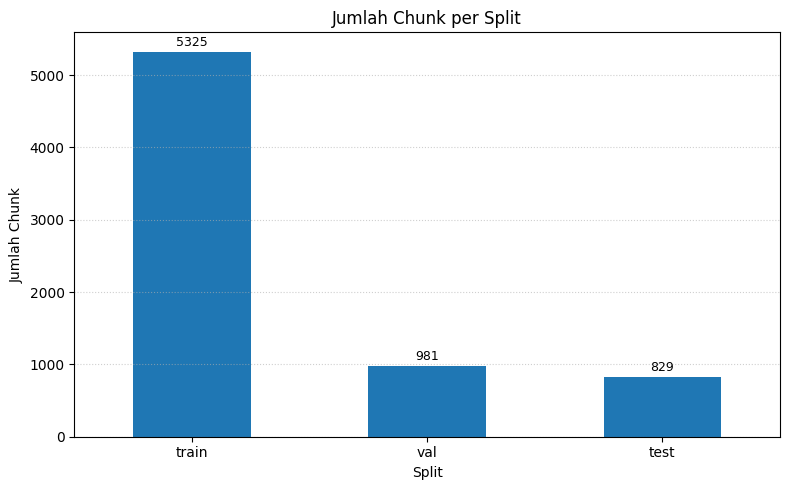


Tabel distribusi binary label:


binary_label,normal,abnormal
split,,
train,2954,2371
val,346,635
test,504,325


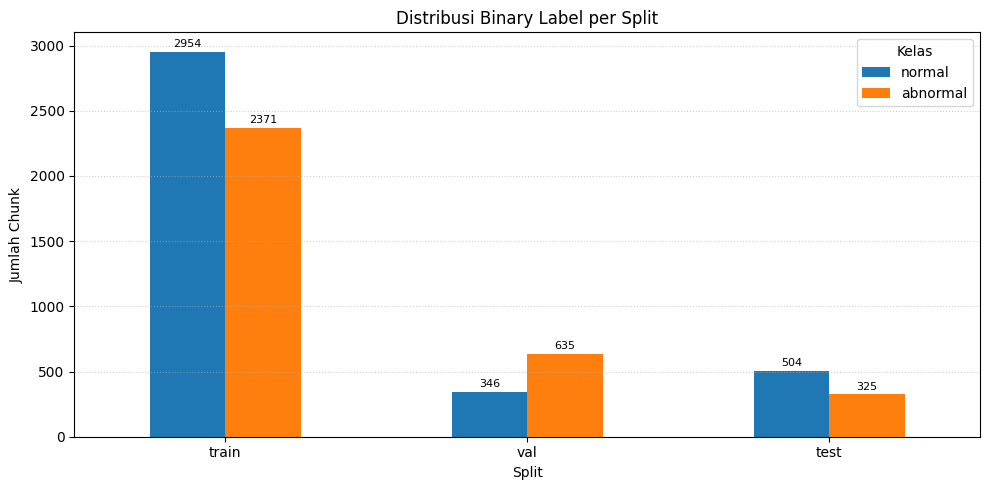


Tabel distribusi label sumber:


sound_4class,normal,crackle,wheeze,both
split,,,,
train,2954,1414,640,317
val,346,380,113,142
test,504,94,156,75


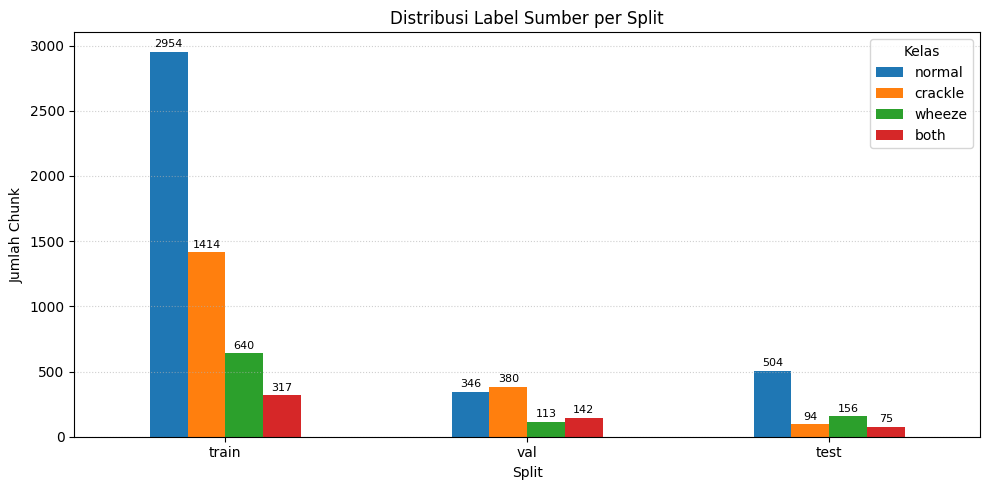


Tabel parent segment vs chunk output:


,parent_segment,chunk_output
split,,
train,5134,5325
val,956,981
test,808,829


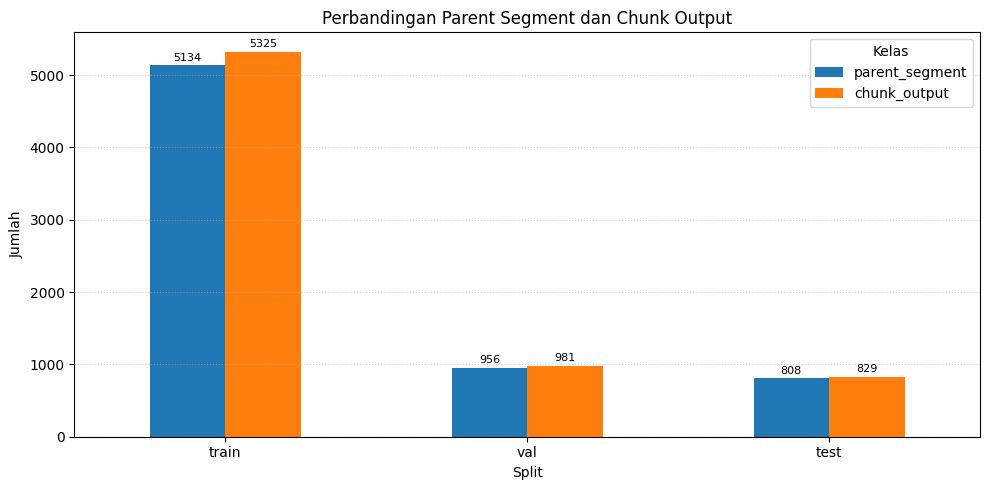


File ringkasan tersimpan:
Summary distribusi : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/summary_distribution_16k5s.csv
Binary label       : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/distribution_binary_label_16k5s.csv
Source label       : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/distribution_source_label_16k5s.csv

[OK] Cell distribusi ringkas selesai.


In [ ]:
# ============================================================
# CELL 15: CEK DISTRIBUSI DATA PREPROCESSING 16k5s
# ============================================================
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 0. KONFIGURASI
# ============================================================

PREPROC_DIR = globals().get(
    "PREPROC_DIR",
    "paper_binary_16k_outputs/03_preprocessed_audio_16k5s"
)

PREPROC_DIR = Path(PREPROC_DIR)

SPLITS = ["train", "val", "test"]

BINARY_CLASSES = ["normal", "abnormal"]
SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both", "abnormal"]

TARGET_SR = int(globals().get("TARGET_SR", 16000))
TARGET_DURATION_SEC = float(globals().get("TARGET_DURATION_SEC", 5.0))
TARGET_LEN = int(globals().get("TARGET_LEN", TARGET_SR * TARGET_DURATION_SEC))


# ============================================================
# 1. HELPER
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def load_metadata_split(split_name):
    meta_path = PREPROC_DIR / f"metadata_{split_name}_16k5s.csv"

    if not meta_path.exists():
        raise FileNotFoundError(f"Metadata tidak ditemukan: {meta_path}")

    df = pd.read_csv(meta_path)
    df.columns = [str(c).strip() for c in df.columns]

    if "file" not in df.columns and "audio_path" in df.columns:
        df["file"] = df["audio_path"]

    if "binary_label" not in df.columns:
        if "label_id" in df.columns:
            df["binary_label"] = df["label_id"].map({0: "normal", 1: "abnormal"})
        else:
            raise ValueError(f"{split_name}: kolom binary_label tidak ditemukan.")

    if "sound_4class" not in df.columns:
        if "sound" in df.columns:
            df["sound_4class"] = df["sound"]
        elif "original_sound" in df.columns:
            df["sound_4class"] = df["original_sound"]
        else:
            df["sound_4class"] = df["binary_label"]

    df["split"] = split_name
    df["binary_label"] = df["binary_label"].astype(str).str.strip().str.lower()
    df["sound_4class"] = df["sound_4class"].astype(str).str.strip().str.lower()

    if "patient_id" in df.columns:
        df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")

    return df


def make_count_table(df_all, label_col, class_order):
    table = (
        df_all
        .groupby(["split", label_col])
        .size()
        .unstack(fill_value=0)
        .reindex(index=SPLITS, fill_value=0)
    )

    for cls in class_order:
        if cls not in table.columns:
            table[cls] = 0

    table = table[class_order]

    return table


def plot_bar_table(table, title, ylabel="Jumlah"):
    ax = table.plot(
        kind="bar",
        figsize=(10, 5),
        rot=0
    )

    ax.set_title(title)
    ax.set_xlabel("Split")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle=":", alpha=0.6)
    ax.legend(title="Kelas")

    for container in ax.containers:
        ax.bar_label(container, fontsize=8, padding=2)

    plt.tight_layout()
    plt.show()


# ============================================================
# 2. LOAD SEMUA METADATA
# ============================================================

dfs = []

for split_name in SPLITS:
    df_split = load_metadata_split(split_name)
    dfs.append(df_split)

df_all = pd.concat(dfs, ignore_index=True)

print("=" * 80)
print("CEK DISTRIBUSI DATA PREPROCESSING 16k5s")
print("=" * 80)
print("PREPROC_DIR       :", PREPROC_DIR)
print("Target SR         :", TARGET_SR)
print("Target durasi     :", TARGET_DURATION_SEC)
print("Target sample     :", TARGET_LEN)
print("Total data chunk  :", len(df_all))


# ============================================================
# 3. TABEL RINGKASAN PER SPLIT
# ============================================================

summary_rows = []

for split_name in SPLITS:
    df = df_all[df_all["split"] == split_name].copy()

    n_chunks = len(df)
    n_patients = df["patient_id"].nunique() if "patient_id" in df.columns else np.nan
    n_parent_segments = df["parent_sample_id"].nunique() if "parent_sample_id" in df.columns else n_chunks

    row = {
        "split": split_name,
        "n_chunks_output": int(n_chunks),
        "n_parent_segments": int(n_parent_segments) if pd.notna(n_parent_segments) else np.nan,
        "n_patients": int(n_patients) if pd.notna(n_patients) else np.nan,

        "normal": int((df["binary_label"] == "normal").sum()),
        "abnormal": int((df["binary_label"] == "abnormal").sum()),

        "source_normal": int((df["sound_4class"] == "normal").sum()),
        "source_crackle": int((df["sound_4class"] == "crackle").sum()),
        "source_wheeze": int((df["sound_4class"] == "wheeze").sum()),
        "source_both": int((df["sound_4class"] == "both").sum()),
        "source_abnormal_unspecified": int((df["sound_4class"] == "abnormal").sum()),

        "target_sr": TARGET_SR,
        "target_duration_sec": TARGET_DURATION_SEC,
        "target_len_samples": TARGET_LEN,
    }

    if "padding_ratio" in df.columns:
        row["mean_padding_ratio"] = float(df["padding_ratio"].mean())
        row["median_padding_ratio"] = float(df["padding_ratio"].median())
        row["max_padding_ratio"] = float(df["padding_ratio"].max())

    if "n_chunks_from_segment" in df.columns:
        row["mean_chunks_from_segment"] = float(df["n_chunks_from_segment"].mean())
        row["max_chunks_from_segment"] = int(df["n_chunks_from_segment"].max())

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

print("\nRingkasan data per split:")
safe_display(summary_df)


# ============================================================
# 4. DIAGRAM BAR: TOTAL CHUNK PER SPLIT
# ============================================================

chunk_table = (
    df_all
    .groupby("split")
    .size()
    .reindex(SPLITS, fill_value=0)
    .to_frame("jumlah_chunk")
)

ax = chunk_table.plot(
    kind="bar",
    figsize=(8, 5),
    rot=0,
    legend=False
)

ax.set_title("Jumlah Chunk per Split")
ax.set_xlabel("Split")
ax.set_ylabel("Jumlah Chunk")
ax.grid(axis="y", linestyle=":", alpha=0.6)

for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=2)

plt.tight_layout()
plt.show()


# ============================================================
# 5. DIAGRAM BAR: DISTRIBUSI BINARY LABEL
# ============================================================

binary_table = make_count_table(
    df_all=df_all,
    label_col="binary_label",
    class_order=BINARY_CLASSES
)

print("\nTabel distribusi binary label:")
safe_display(binary_table)

plot_bar_table(
    table=binary_table,
    title="Distribusi Binary Label per Split",
    ylabel="Jumlah Chunk"
)


# ============================================================
# 6. DIAGRAM BAR: DISTRIBUSI LABEL SUMBER
# ============================================================

source_table = make_count_table(
    df_all=df_all,
    label_col="sound_4class",
    class_order=SOURCE_CLASSES
)

# Buang kolom yang semuanya 0 agar diagram tidak penuh label kosong
source_table_plot = source_table.loc[:, source_table.sum(axis=0) > 0]

print("\nTabel distribusi label sumber:")
safe_display(source_table_plot)

plot_bar_table(
    table=source_table_plot,
    title="Distribusi Label Sumber per Split",
    ylabel="Jumlah Chunk"
)


# ============================================================
# 7. DIAGRAM BAR: JUMLAH PARENT SEGMENT DAN CHUNK
# ============================================================

if "parent_sample_id" in df_all.columns:
    parent_table = []

    for split_name in SPLITS:
        df = df_all[df_all["split"] == split_name]

        parent_table.append({
            "split": split_name,
            "parent_segment": df["parent_sample_id"].nunique(),
            "chunk_output": len(df)
        })

    parent_table = pd.DataFrame(parent_table).set_index("split")

    print("\nTabel parent segment vs chunk output:")
    safe_display(parent_table)

    plot_bar_table(
        table=parent_table,
        title="Perbandingan Parent Segment dan Chunk Output",
        ylabel="Jumlah"
    )


# ============================================================
# 8. SIMPAN RINGKASAN
# ============================================================

summary_path = PREPROC_DIR / "summary_distribution_16k5s.csv"
summary_df.to_csv(summary_path, index=False)

binary_path = PREPROC_DIR / "distribution_binary_label_16k5s.csv"
binary_table.to_csv(binary_path)

source_path = PREPROC_DIR / "distribution_source_label_16k5s.csv"
source_table.to_csv(source_path)

print("\nFile ringkasan tersimpan:")
print("Summary distribusi :", summary_path)
print("Binary label       :", binary_path)
print("Source label       :", source_path)

print("\n[OK] Cell distribusi ringkas selesai.")


# ============================================================
# 9. SIMPAN KE GLOBALS
# ============================================================

globals()["df_distribution_16k5s"] = df_all
globals()["summary_distribution_16k5s"] = summary_df
globals()["binary_distribution_16k5s"] = binary_table
globals()["source_distribution_16k5s"] = source_table

PREVIEW WAVEFORM DAN LOG-MEL HASIL PREPROCESSING 16k5s
Metadata        : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/metadata_train_16k5s.csv
PREPROC_DIR     : paper_binary_16k_outputs/03_preprocessed_audio_16k5s
Split           : train
Total chunk     : 5325
Pasien unik     : 100
Target SR       : 16000
Target durasi   : 5.0
Target samples  : 80000
Parent segment  : 5134

Distribusi binary label:
binary_label
normal      2954
abnormal    2371
Name: count, dtype: int64

Distribusi label sumber:
sound_4class
normal      2954
crackle     1414
wheeze       640
both         317
abnormal       0
Name: count, dtype: int64

Parameter Log-Mel preview:
N_FFT      : 2048
HOP_LENGTH : 128
WIN_LENGTH : 2048
N_MELS     : 128
FMIN       : 50
FMAX       : 8000
IMAGE_SIZE : 224

Sample yang akan dipreview:


,patient_id,split,binary_label,label_id,sound_4class,parent_sample_id,sample_id,chunk_idx,n_chunks_from_segment,target_sr,target_sec,target_len_samples,processed_len_samples,processed_duration_sec,fix_strategy,padding_ratio,active_duration_sec_before_fix,active_dbfs_after_norm,processed_dbfs_after_fix,file
0,213,train,normal,0,normal,213_1p5_Al_mc_AKGC417L_s8.356_e10.643_seg1_s8....,213_1p5_Al_mc_AKGC417L_s8.356_e10.643_seg1_s8....,0,1,16000,5.0,80000,80000,5.0,sequential_5s_chunking_with_deterministic_rand...,0.542588,2.287063,-15.000000,-18.396920,paper_binary_16k_outputs/03_preprocessed_audio...
1,154,train,abnormal,1,crackle,154_4b4_Pl_mc_AKGC417L_s14.732_e16.851_seg7_s1...,154_4b4_Pl_mc_AKGC417L_s14.732_e16.851_seg7_s1...,0,1,16000,5.0,80000,80000,5.0,sequential_5s_chunking_with_deterministic_rand...,0.576187,2.119063,-15.240059,-18.968322,paper_binary_16k_outputs/03_preprocessed_audio...



BINARY LABEL : normal
SOURCE LABEL : normal
SPLIT        : train
patient_id   : 213
file         : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/train/fc3040b48bed4a6c_chunk000of001_pid213_binnormal_orignormal_16k5s.wav
parent id    : 213_1p5_Al_mc_AKGC417L_s8.356_e10.643_seg1_s8.356_e10.643
sample id    : 213_1p5_Al_mc_AKGC417L_s8.356_e10.643_seg1_s8.356_e10.643_chunk000
chunk        : 1/1
sr                : 16000
durasi            : 5.000000 detik
len sampel        : 80000
target sampel     : 80000
RMS               : 0.120269
dBFS file         : -18.3969
min/max amplitudo : -0.824615 / 0.824127
fix strategy                        : sequential_5s_chunking_with_deterministic_random_padding
padding ratio                       : 0.542588
durasi aktif chunk sebelum padding  : 2.287063
durasi padding                      : 2.712937
durasi original segment             : 2.287063
active dBFS setelah normalisasi     : -15.000000
processed dBFS setelah fix          : -18.396920

Prev

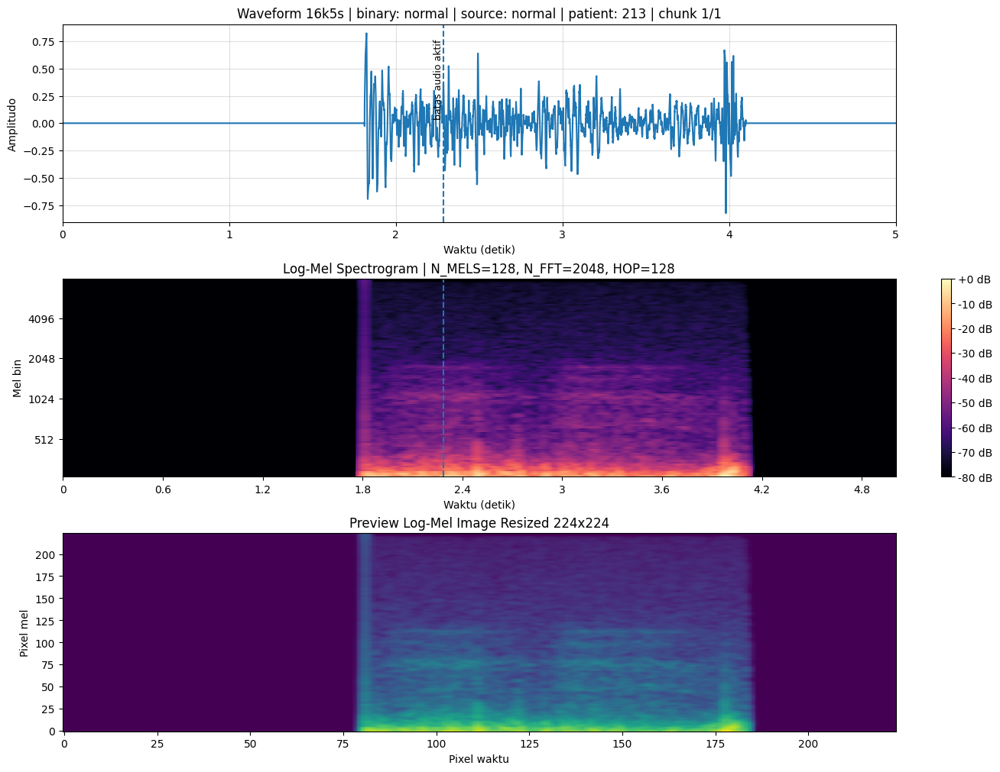


BINARY LABEL : abnormal
SOURCE LABEL : crackle
SPLIT        : train
patient_id   : 154
file         : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/train/98a24876f206897c_chunk000of001_pid154_binabnormal_origcrackle_16k5s.wav
parent id    : 154_4b4_Pl_mc_AKGC417L_s14.732_e16.851_seg7_s14.732_e16.851
sample id    : 154_4b4_Pl_mc_AKGC417L_s14.732_e16.851_seg7_s14.732_e16.851_chunk000
chunk        : 1/1
sr                : 16000
durasi            : 5.000000 detik
len sampel        : 80000
target sampel     : 80000
RMS               : 0.112612
dBFS file         : -18.9683
min/max amplitudo : -0.976349 / 0.999969
fix strategy                        : sequential_5s_chunking_with_deterministic_random_padding
padding ratio                       : 0.576187
durasi aktif chunk sebelum padding  : 2.119063
durasi padding                      : 2.880937
durasi original segment             : 2.119063
active dBFS setelah normalisasi     : -15.240059
processed dBFS setelah fix          : -18.96

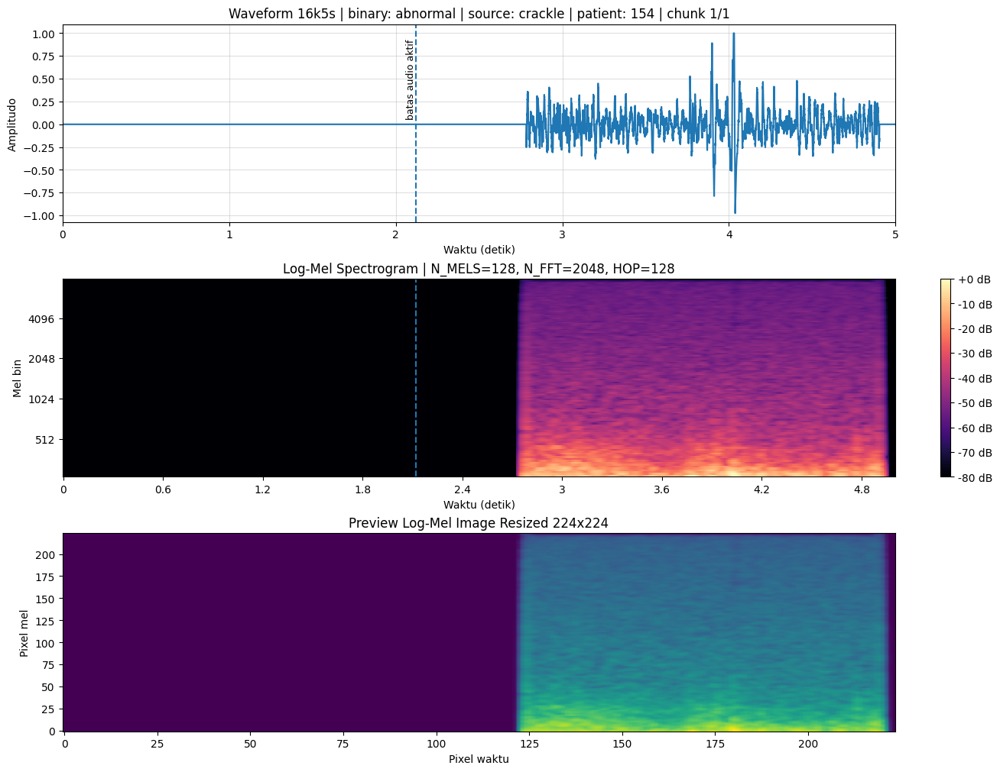


[OK] Preview waveform dan Log-Mel 16k5s selesai.


In [ ]:
# ============================================================
# CELL 16: PREVIEW WAVEFORM DAN LOG-MEL HASIL PREPROCESSING 16k5s
# Pipeline: 16 kHz + fixed 5 detik + sequential chunking
# Target: Binary Normal-Abnormal
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import Audio, display


# ============================================================
# 0. KONFIGURASI
# ============================================================

PREPROC_DIR = globals().get(
    "PREPROC_DIR",
    "paper_binary_16k_outputs/03_preprocessed_audio_16k5s"
)

PREPROC_DIR = Path(PREPROC_DIR)

SPLIT = "train"          # "train" / "val" / "test"
N_PER_CLASS = 1
RANDOM_STATE = 42

TARGET_SR = int(globals().get("TARGET_SR", 16000))
TARGET_DURATION_SEC = float(globals().get("TARGET_DURATION_SEC", 5.0))
TARGET_LEN_SAMPLES = int(globals().get("TARGET_LEN", TARGET_SR * TARGET_DURATION_SEC))

BINARY_CLASSES = ["normal", "abnormal"]
SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both", "abnormal"]

# Parameter Log-Mel sesuai arah konfigurasi paper
N_FFT = 2048
HOP_LENGTH = 128
WIN_LENGTH = 2048
N_MELS = 128
FMIN = 50
FMAX = 8000

IMAGE_SIZE = 224

meta_path = PREPROC_DIR / f"metadata_{SPLIT}_16k5s.csv"


# ============================================================
# 1. HELPER
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def normalize_metadata_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    if "file" not in df.columns:
        if "audio_path" in df.columns:
            df["file"] = df["audio_path"].astype(str)
        else:
            raise ValueError("Kolom `file` atau `audio_path` tidak ditemukan pada metadata.")

    df["file"] = df["file"].astype(str).str.strip()

    if "binary_label" not in df.columns:
        if "label_id" in df.columns:
            df["binary_label"] = df["label_id"].map({0: "normal", 1: "abnormal"})
        else:
            raise ValueError("Kolom `binary_label` tidak ditemukan.")

    df["binary_label"] = df["binary_label"].astype(str).str.strip().str.lower()

    if "sound_4class" not in df.columns:
        if "sound" in df.columns:
            df["sound_4class"] = df["sound"].astype(str).str.strip().str.lower()
        elif "original_sound" in df.columns:
            df["sound_4class"] = df["original_sound"].astype(str).str.strip().str.lower()
        else:
            df["sound_4class"] = df["binary_label"]

    df["sound_4class"] = df["sound_4class"].astype(str).str.strip().str.lower()

    if "patient_id" not in df.columns:
        raise ValueError("Kolom `patient_id` tidak ditemukan.")

    df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")

    if "split" not in df.columns:
        df["split"] = SPLIT

    df["split"] = df["split"].astype(str).str.strip().str.lower()

    return df


def compute_dbfs(y, eps=1e-10):
    if y is None or len(y) == 0:
        return np.nan

    rms = np.sqrt(np.mean(np.square(y)) + eps)
    dbfs = 20.0 * np.log10(rms + eps)

    return float(dbfs)


def make_logmel(y, sr):
    fmax_eff = min(FMAX, sr / 2)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=fmax_eff,
        power=2.0
    )

    mel_db = librosa.power_to_db(
        mel + 1e-10,
        ref=np.max
    )

    return mel_db


def logmel_to_resized_uint8_image(mel_db, image_size=IMAGE_SIZE):
    """
    Konversi Log-Mel dB menjadi image grayscale 224x224 untuk preview.
    Ini hanya preview. Cell konversi Log-Mel final nanti yang akan menyimpan image dataset.
    """
    mel_min = float(np.min(mel_db))
    mel_max = float(np.max(mel_db))

    mel_norm = (mel_db - mel_min) / (mel_max - mel_min + 1e-8)
    mel_uint8 = (mel_norm * 255.0).clip(0, 255).astype(np.uint8)

    img = Image.fromarray(mel_uint8)
    img = img.resize((image_size, image_size), resample=Image.BILINEAR)

    return np.array(img)


def choose_samples(df, label_col="binary_label", n_per_class=1, random_state=42):
    selected_rows = []

    for cls in BINARY_CLASSES:
        df_cls = df[df[label_col] == cls].copy()

        if len(df_cls) == 0:
            print(f"[INFO] Kelas `{cls}` tidak ada pada split {SPLIT}.")
            continue

        sample_df = df_cls.sample(
            n=min(n_per_class, len(df_cls)),
            random_state=random_state
        )

        selected_rows.append(sample_df)

    if len(selected_rows) == 0:
        raise RuntimeError("Tidak ada sample yang bisa dipreview.")

    return pd.concat(selected_rows, ignore_index=True)


# ============================================================
# 2. LOAD METADATA
# ============================================================

if not meta_path.exists():
    print("=" * 80)
    print("METADATA PREPROCESSING 16k5s TIDAK DITEMUKAN")
    print("=" * 80)
    print("Path yang dicari:")
    print(meta_path)

    if PREPROC_DIR.exists():
        print(f"\nIsi folder {PREPROC_DIR}:")
        print(os.listdir(PREPROC_DIR))
    else:
        print(f"\nFolder {PREPROC_DIR} belum ada.")

    raise FileNotFoundError(f"Metadata tidak ditemukan: {meta_path}")

df = pd.read_csv(meta_path)
df = normalize_metadata_columns(df)

print("=" * 80)
print("PREVIEW WAVEFORM DAN LOG-MEL HASIL PREPROCESSING 16k5s")
print("=" * 80)
print("Metadata        :", meta_path)
print("PREPROC_DIR     :", PREPROC_DIR)
print("Split           :", SPLIT)
print("Total chunk     :", len(df))
print("Pasien unik     :", df["patient_id"].nunique())
print("Target SR       :", TARGET_SR)
print("Target durasi   :", TARGET_DURATION_SEC)
print("Target samples  :", TARGET_LEN_SAMPLES)

if "parent_sample_id" in df.columns:
    print("Parent segment  :", df["parent_sample_id"].nunique())

print("\nDistribusi binary label:")
print(df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

print("\nDistribusi label sumber:")
print(df["sound_4class"].value_counts().reindex(SOURCE_CLASSES, fill_value=0))

print("\nParameter Log-Mel preview:")
print("N_FFT      :", N_FFT)
print("HOP_LENGTH :", HOP_LENGTH)
print("WIN_LENGTH :", WIN_LENGTH)
print("N_MELS     :", N_MELS)
print("FMIN       :", FMIN)
print("FMAX       :", FMAX)
print("IMAGE_SIZE :", IMAGE_SIZE)


# ============================================================
# 3. PILIH SAMPLE PREVIEW
# ============================================================

preview_df = choose_samples(
    df,
    label_col="binary_label",
    n_per_class=N_PER_CLASS,
    random_state=RANDOM_STATE
)

preview_cols = [
    "patient_id",
    "split",
    "binary_label",
    "label_id",
    "sound_4class",
    "parent_sample_id",
    "sample_id",
    "chunk_idx",
    "n_chunks_from_segment",
    "target_sr",
    "target_sec",
    "target_len_samples",
    "processed_len_samples",
    "processed_duration_sec",
    "fix_strategy",
    "padding_ratio",
    "active_duration_sec_before_fix",
    "active_dbfs_after_norm",
    "processed_dbfs_after_fix",
    "file"
]

preview_cols = [c for c in preview_cols if c in preview_df.columns]

print("\nSample yang akan dipreview:")
safe_display(preview_df[preview_cols])


# ============================================================
# 4. PREVIEW WAVEFORM DAN LOG-MEL
# ============================================================

for row_idx, sample in preview_df.iterrows():
    audio_path = str(sample["file"])

    binary_label = str(sample["binary_label"])
    source_label = str(sample["sound_4class"])
    pid = sample.get("patient_id", "NA")

    chunk_text = ""
    if "chunk_idx" in sample.index and "n_chunks_from_segment" in sample.index:
        chunk_text = f" | chunk {int(sample['chunk_idx']) + 1}/{int(sample['n_chunks_from_segment'])}"

    print("\n" + "=" * 80)
    print(f"BINARY LABEL : {binary_label}")
    print(f"SOURCE LABEL : {source_label}")
    print(f"SPLIT        : {SPLIT}")
    print(f"patient_id   : {pid}")
    print(f"file         : {audio_path}")

    if "parent_sample_id" in sample.index:
        print(f"parent id    : {sample['parent_sample_id']}")

    if "sample_id" in sample.index:
        print(f"sample id    : {sample['sample_id']}")

    if "chunk_idx" in sample.index and "n_chunks_from_segment" in sample.index:
        print(f"chunk        : {int(sample['chunk_idx']) + 1}/{int(sample['n_chunks_from_segment'])}")

    if not os.path.exists(audio_path):
        print("[WARNING] File audio tidak ditemukan, skip.")
        continue

    try:
        y, sr = librosa.load(
            audio_path,
            sr=None,
            mono=True
        )
    except Exception as e:
        print(f"[ERROR] Gagal load audio: {repr(e)}")
        continue

    dur = len(y) / sr if sr else 0.0
    rms = float(np.sqrt(np.mean(y ** 2))) if len(y) > 0 else 0.0
    dbfs = compute_dbfs(y)

    print(f"sr                : {sr}")
    print(f"durasi            : {dur:.6f} detik")
    print(f"len sampel        : {len(y)}")
    print(f"target sampel     : {TARGET_LEN_SAMPLES}")
    print(f"RMS               : {rms:.6f}")
    print(f"dBFS file         : {dbfs:.4f}")

    if len(y) > 0:
        print(f"min/max amplitudo : {float(y.min()):.6f} / {float(y.max()):.6f}")

    optional_info = [
        ("fix_strategy", "fix strategy"),
        ("padding_ratio", "padding ratio"),
        ("active_duration_sec_before_fix", "durasi aktif chunk sebelum padding"),
        ("padding_duration_sec", "durasi padding"),
        ("original_segment_duration_sec", "durasi original segment"),
        ("active_dbfs_after_norm", "active dBFS setelah normalisasi"),
        ("processed_dbfs_after_fix", "processed dBFS setelah fix"),
    ]

    for col, label in optional_info:
        if col in sample.index and pd.notna(sample[col]):
            value = sample[col]

            if isinstance(value, (float, int, np.floating, np.integer)):
                print(f"{label:<36}: {float(value):.6f}")
            else:
                print(f"{label:<36}: {value}")

    if sr != TARGET_SR:
        print(f"[WARNING] SR file bukan {TARGET_SR} Hz.")

    if len(y) != TARGET_LEN_SAMPLES:
        print(f"[WARNING] Panjang file bukan {TARGET_LEN_SAMPLES} sample.")

    print("\nPreview audio:")
    display(Audio(data=y, rate=sr, normalize=False))

    # ========================================================
    # Plot waveform, log-mel, dan resized log-mel image
    # ========================================================

    t = np.linspace(0, dur, num=len(y)) if len(y) > 0 else np.array([0.0])

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(13, 10),
        constrained_layout=True
    )

    # --------------------------------------------------------
    # 4.1 Waveform
    # --------------------------------------------------------

    ax = axes[0]

    if len(y) > 0:
        ax.plot(t, y)

    ax.set_title(
        f"Waveform 16k5s | binary: {binary_label} | source: {source_label} | patient: {pid}{chunk_text}"
    )
    ax.set_xlabel("Waktu (detik)")
    ax.set_ylabel("Amplitudo")
    ax.set_xlim(0, max(dur, 1e-6))
    ax.grid(alpha=0.4)

    # Tandai batas audio aktif chunk sebelum padding
    if "active_duration_sec_before_fix" in sample.index:
        active_dur = float(sample["active_duration_sec_before_fix"])

        if np.isfinite(active_dur) and 0 < active_dur < dur:
            ax.axvline(
                active_dur,
                linestyle="--",
                linewidth=1.5
            )
            ax.text(
                active_dur,
                ax.get_ylim()[1] * 0.85,
                "batas audio aktif",
                rotation=90,
                va="top",
                ha="right",
                fontsize=9
            )

    # --------------------------------------------------------
    # 4.2 Log-Mel Spectrogram
    # --------------------------------------------------------

    ax2 = axes[1]

    if len(y) > 0 and sr is not None and sr > 0:
        mel_db = make_logmel(y, sr)

        img = librosa.display.specshow(
            mel_db,
            sr=sr,
            hop_length=HOP_LENGTH,
            x_axis="time",
            y_axis="mel",
            fmin=FMIN,
            fmax=min(FMAX, sr / 2),
            ax=ax2
        )

        ax2.set_title(
            f"Log-Mel Spectrogram | N_MELS={N_MELS}, N_FFT={N_FFT}, HOP={HOP_LENGTH}"
        )
        ax2.set_xlabel("Waktu (detik)")
        ax2.set_ylabel("Mel bin")

        fig.colorbar(
            img,
            ax=ax2,
            format="%+2.0f dB"
        )

        if "active_duration_sec_before_fix" in sample.index:
            active_dur = float(sample["active_duration_sec_before_fix"])

            if np.isfinite(active_dur) and 0 < active_dur < dur:
                ax2.axvline(
                    active_dur,
                    linestyle="--",
                    linewidth=1.5
                )

    else:
        mel_db = None
        ax2.set_title("Log-Mel Spectrogram, audio kosong")
        ax2.axis("off")

    # --------------------------------------------------------
    # 4.3 Preview Log-Mel resized 224x224
    # --------------------------------------------------------

    ax3 = axes[2]

    if mel_db is not None:
        mel_img_224 = logmel_to_resized_uint8_image(
            mel_db,
            image_size=IMAGE_SIZE
        )

        ax3.imshow(
            mel_img_224,
            aspect="auto",
            origin="lower"
        )

        ax3.set_title(
            f"Preview Log-Mel Image Resized {IMAGE_SIZE}x{IMAGE_SIZE}"
        )
        ax3.set_xlabel("Pixel waktu")
        ax3.set_ylabel("Pixel mel")
    else:
        ax3.set_title("Preview Log-Mel Image kosong")
        ax3.axis("off")

    plt.show()


print("\n[OK] Preview waveform dan Log-Mel 16k5s selesai.")


# ============================================================
# 5. SIMPAN KE GLOBALS
# ============================================================

globals()["preview_preprocessing_df_16k5s"] = preview_df

# **Augmentasi Manual**

> **Pitch Shifting** dan
> **Time Stretching**

In [ ]:
# ============================================================
# CELL: AUGMENTASI TRAIN BINARY 16 kHz + 5 DETIK
# Output binary : normal vs abnormal
# ============================================================
import os
import re
import math
import shutil
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import soundfile as sf

from scipy.signal import resample_poly
from tqdm.auto import tqdm


# ============================================================
# 0. KONFIGURASI PATH
# ============================================================

PREPROC_DIR = Path(
    globals().get(
        "PREPROC_DIR",
        "paper_binary_16k_outputs/03_preprocessed_audio_16k5s"
    )
)

AUG_DIR = Path("paper_binary_16k_outputs/04_augmented_audio_manual_16k5s")
AUG_AUDIO_DIR = AUG_DIR / "train"

TRAIN_META_PATH = PREPROC_DIR / "metadata_train_16k5s.csv"

AUG_META_PATH = AUG_DIR / "metadata_train_manual_aug_only_16k5s.csv"
TRAIN_WITH_AUG_META_PATH = AUG_DIR / "metadata_train_with_manual_aug_16k5s.csv"

SUMMARY_AUG_PATH = AUG_DIR / "summary_manual_aug_binary_16k5s.csv"
SUMMARY_TRAIN_WITH_AUG_PATH = AUG_DIR / "summary_train_with_manual_aug_binary_16k5s.csv"
SUMMARY_AUG_4CLASS_PATH = AUG_DIR / "summary_manual_aug_4class_16k5s.csv"

CLEAN_OLD_AUG_OUTPUT = True

AUG_DIR.mkdir(parents=True, exist_ok=True)

if CLEAN_OLD_AUG_OUTPUT:
    files_to_delete = [
        AUG_META_PATH,
        TRAIN_WITH_AUG_META_PATH,
        SUMMARY_AUG_PATH,
        SUMMARY_TRAIN_WITH_AUG_PATH,
        SUMMARY_AUG_4CLASS_PATH,
    ]

    for p in files_to_delete:
        if p.exists():
            p.unlink()
            print("Deleted:", p)

    if AUG_AUDIO_DIR.exists():
        shutil.rmtree(AUG_AUDIO_DIR)
        print("Deleted folder:", AUG_AUDIO_DIR)

AUG_AUDIO_DIR.mkdir(parents=True, exist_ok=True)

if not TRAIN_META_PATH.exists():
    raise FileNotFoundError(
        f"Metadata train hasil preprocessing 16k5s tidak ditemukan: {TRAIN_META_PATH}\n"
        "Jalankan cell preprocessing audio 16k5s terlebih dahulu."
    )


# ============================================================
# 1. KONFIGURASI LABEL DAN AUGMENTASI
# ============================================================

BINARY_CLASSES = ["normal", "abnormal"]
VALID_4CLASS = ["normal", "crackle", "wheeze", "both"]

LABEL_TO_ID = {
    "normal": 0,
    "abnormal": 1
}

TARGET_SR = int(globals().get("TARGET_SR", 16000))
TARGET_LEN_SEC = float(globals().get("TARGET_DURATION_SEC", 5.0))
TARGET_LEN = int(globals().get("TARGET_LEN", TARGET_SR * TARGET_LEN_SEC))

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

AUGMENT_STRATEGY = "explicit_subtype_operation_target_with_deterministic_length_fix"

# Target eksplisit sesuai keputusan metodologi.
AUGMENTATION_TARGETS = {
    ("both", "time_stretch"): 210,
    ("both", "pitch_shift"): 140,
    ("wheeze", "time_stretch"): 140,
    ("wheeze", "pitch_shift"): 93,
}

EXPECTED_TOTAL_TIME_STRETCH = 350
EXPECTED_TOTAL_PITCH_SHIFT = 233
EXPECTED_TOTAL_AUG = 583

TIME_STRETCH_MIN = 0.90
TIME_STRETCH_MAX = 1.10

PITCH_SHIFT_MIN = -2.0
PITCH_SHIFT_MAX = 2.0

# Hindari pitch shift terlalu dekat 0 agar benar-benar terjadi augmentasi.
MIN_ABS_PITCH_SHIFT = 0.5


# ============================================================
# 2. HELPER UMUM
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def safe_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def sanitize_token(s):
    s = str(s).strip()
    s = s.replace("\\", "_").replace("/", "_").replace(" ", "_")
    s = re.sub(r"[^A-Za-z0-9_.+-]", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s if s else "unknown"


def to_binary_label(label):
    label = str(label).strip().lower()

    if label == "normal":
        return "normal"

    if label in ["crackle", "wheeze", "both", "abnormal"]:
        return "abnormal"

    raise ValueError(f"Label tidak dikenal: {label}")


def infer_sound_4class(row):
    for col in ["sound_4class", "original_sound", "sound"]:
        if col in row.index and safe_str(row[col]):
            label = safe_str(row[col]).lower()
            if label in VALID_4CLASS:
                return label

    binary_label = safe_str(row.get("binary_label", "")).lower()

    if binary_label == "normal":
        return "normal"

    if binary_label == "abnormal":
        return "abnormal"

    return "unknown"


def safe_audio_array(y):
    if y is None:
        return None

    y = np.asarray(y, dtype=np.float64)

    if y.ndim > 1:
        y = y.mean(axis=1)

    if len(y) == 0:
        return None

    y = np.nan_to_num(
        y,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    if not np.all(np.isfinite(y)):
        return None

    max_abs = float(np.max(np.abs(y))) if len(y) > 0 else 0.0

    if not np.isfinite(max_abs):
        return None

    if max_abs > 10.0:
        y = y / (max_abs + 1e-12)

    return y.astype(np.float32, copy=False)


def resample_to_target(y, orig_sr, target_sr):
    y = safe_audio_array(y)

    if y is None or len(y) == 0:
        return None

    orig_sr = int(orig_sr)
    target_sr = int(target_sr)

    if orig_sr == target_sr:
        return y.astype(np.float32, copy=False)

    gcd = math.gcd(orig_sr, target_sr)
    up = target_sr // gcd
    down = orig_sr // gcd

    try:
        y_rs = resample_poly(y, up, down)
    except Exception:
        return None

    y_rs = safe_audio_array(y_rs)

    if y_rs is None or len(y_rs) == 0:
        return None

    return y_rs.astype(np.float32, copy=False)


def make_seed_from_key(key, seed_base=RANDOM_STATE):
    """
    Membentuk seed 32-bit yang stabil dari identitas augmentasi.

    Key dan seed dasar yang sama selalu menghasilkan seed yang sama,
    sehingga parameter augmentasi, random padding, dan random crop
    dapat direproduksi pada eksekusi ulang.
    """
    key = str(key)
    digest = hashlib.md5(f"{seed_base}_{key}".encode("utf-8")).hexdigest()
    return int(digest[:8], 16)


def make_rng_from_key(key, seed_base=RANDOM_STATE):
    return np.random.default_rng(
        make_seed_from_key(key, seed_base=seed_base)
    )


def make_short_file_id(sample_key, aug_idx):
    raw = f"{sample_key}_{aug_idx}"
    return hashlib.md5(raw.encode("utf-8")).hexdigest()[:16]


def compute_dbfs(y, eps=1e-10):
    y = safe_audio_array(y)

    if y is None or len(y) == 0:
        return np.nan

    rms = float(np.sqrt(np.mean(np.square(y, dtype=np.float64)) + eps))
    dbfs = float(20.0 * np.log10(rms + eps))

    return dbfs


def fix_audio_to_target_len(y, fix_key, target_len=TARGET_LEN):
    """
    Menyesuaikan hasil augmentasi menjadi tepat 5 detik secara deterministik.

    Aturan:
    - Audio lebih pendek:
      total zero padding dibagi secara pseudoacak ke sisi kiri dan kanan.
    - Audio lebih panjang:
      diambil satu window sepanjang target dengan deterministic random crop.
    - Audio tepat sepanjang target:
      tidak diberi padding dan tidak dipotong.

    Random padding dan random crop menggunakan RNG yang diturunkan dari
    `fix_key`. Dengan demikian, sampel augmentasi yang sama selalu memperoleh
    posisi padding atau crop yang sama ketika cell dijalankan ulang.
    """
    y = safe_audio_array(y)

    if y is None or len(y) == 0:
        return None, {}

    target_len = int(target_len)

    if target_len <= 0:
        raise ValueError(f"target_len harus positif, saat ini={target_len}")

    original_len = int(len(y))
    fix_seed_key = str(fix_key)
    fix_seed = int(make_seed_from_key(fix_seed_key))
    fix_rng = np.random.default_rng(fix_seed)

    crop_start = 0
    crop_end = original_len

    padding_len = 0
    padding_left_len = 0
    padding_right_len = 0

    active_start_after_fix = 0
    active_end_after_fix = min(original_len, target_len)

    if original_len > target_len:
        max_crop_start = int(original_len - target_len)
        crop_start = int(fix_rng.integers(0, max_crop_start + 1))
        crop_end = int(crop_start + target_len)

        y_fixed = y[crop_start:crop_end].astype(
            np.float32,
            copy=False
        )

        active_start_after_fix = 0
        active_end_after_fix = target_len

        fix_strategy = "deterministic_random_crop_to_5s"
        padding_strategy = "none"
        crop_strategy = "deterministic_random_crop_if_long"

    elif original_len < target_len:
        padding_len = int(target_len - original_len)

        padding_left_len = int(
            fix_rng.integers(0, padding_len + 1)
        )
        padding_right_len = int(
            padding_len - padding_left_len
        )

        y_fixed = np.pad(
            y,
            (padding_left_len, padding_right_len),
            mode="constant",
            constant_values=0.0
        ).astype(
            np.float32,
            copy=False
        )

        crop_start = 0
        crop_end = original_len

        active_start_after_fix = padding_left_len
        active_end_after_fix = padding_left_len + original_len

        fix_strategy = "deterministic_random_padding_to_5s"
        padding_strategy = (
            "deterministic_random_left_right_zero_padding_if_short"
        )
        crop_strategy = "none"

    else:
        y_fixed = y.astype(np.float32, copy=False)

        crop_start = 0
        crop_end = original_len

        active_start_after_fix = 0
        active_end_after_fix = original_len

        fix_strategy = "already_5s"
        padding_strategy = "none"
        crop_strategy = "none"

    if len(y_fixed) != target_len:
        raise RuntimeError(
            f"Length fixing gagal: {len(y_fixed)} != {target_len}"
        )

    if padding_left_len + padding_right_len != padding_len:
        raise RuntimeError(
            "Jumlah padding kiri dan kanan tidak sama dengan total padding: "
            f"{padding_left_len} + {padding_right_len} != {padding_len}"
        )

    if not (0 <= active_start_after_fix <= active_end_after_fix <= target_len):
        raise RuntimeError(
            "Posisi sinyal aktif setelah length fixing tidak valid: "
            f"start={active_start_after_fix}, "
            f"end={active_end_after_fix}, target={target_len}"
        )

    info = {
        "aug_len_before_fix_samples": int(original_len),
        "aug_len_before_fix_sec": float(original_len / TARGET_SR),

        "aug_length_fix_seed_key": fix_seed_key,
        "aug_length_fix_seed": int(fix_seed),

        "aug_crop_start_sample_before_fix": int(crop_start),
        "aug_crop_end_sample_before_fix": int(crop_end),
        "aug_crop_start_sec_before_fix": float(crop_start / TARGET_SR),
        "aug_crop_end_sec_before_fix": float(crop_end / TARGET_SR),

        "aug_padding_len_samples": int(padding_len),
        "aug_padding_left_len_samples": int(padding_left_len),
        "aug_padding_right_len_samples": int(padding_right_len),

        "aug_padding_duration_sec": float(padding_len / TARGET_SR),
        "aug_padding_left_duration_sec": float(
            padding_left_len / TARGET_SR
        ),
        "aug_padding_right_duration_sec": float(
            padding_right_len / TARGET_SR
        ),
        "aug_padding_ratio": float(padding_len / target_len),

        "aug_active_start_sample_after_fix": int(active_start_after_fix),
        "aug_active_end_sample_after_fix": int(active_end_after_fix),
        "aug_active_start_sec_after_fix": float(
            active_start_after_fix / TARGET_SR
        ),
        "aug_active_end_sec_after_fix": float(
            active_end_after_fix / TARGET_SR
        ),

        "aug_length_fix_strategy": fix_strategy,
        "aug_padding_strategy": padding_strategy,
        "aug_crop_strategy": crop_strategy,
        "aug_truncate_strategy": "none",
    }

    return y_fixed.astype(np.float32, copy=False), info


# ============================================================
# 3. FUNGSI AUGMENTASI
# ============================================================

def time_stretch_manual(y, rng, fix_key):
    rate = float(rng.uniform(TIME_STRETCH_MIN, TIME_STRETCH_MAX))

    try:
        y_aug = librosa.effects.time_stretch(
            y.astype(np.float32),
            rate=rate
        )
    except TypeError:
        y_aug = librosa.effects.time_stretch(
            y.astype(np.float32),
            rate
        )

    y_aug = safe_audio_array(y_aug)

    if y_aug is None or len(y_aug) == 0:
        return None, None, None, {}

    y_aug = np.clip(y_aug, -1.0, 1.0).astype(np.float32, copy=False)

    y_fixed, length_info = fix_audio_to_target_len(
        y_aug,
        fix_key=fix_key,
        target_len=TARGET_LEN
    )

    return y_fixed, "time_stretch_rate", rate, length_info


def pitch_shift_manual(y, sr, rng, fix_key):
    n_steps = float(rng.uniform(PITCH_SHIFT_MIN, PITCH_SHIFT_MAX))

    if abs(n_steps) < MIN_ABS_PITCH_SHIFT:
        n_steps = MIN_ABS_PITCH_SHIFT if n_steps >= 0 else -MIN_ABS_PITCH_SHIFT

    try:
        y_aug = librosa.effects.pitch_shift(
            y.astype(np.float32),
            sr=int(sr),
            n_steps=n_steps
        )
    except TypeError:
        y_aug = librosa.effects.pitch_shift(
            y.astype(np.float32),
            int(sr),
            n_steps
        )

    y_aug = safe_audio_array(y_aug)

    if y_aug is None or len(y_aug) == 0:
        return None, None, None, {}

    y_aug = np.clip(y_aug, -1.0, 1.0).astype(np.float32, copy=False)

    y_fixed, length_info = fix_audio_to_target_len(
        y_aug,
        fix_key=fix_key,
        target_len=TARGET_LEN
    )

    return y_fixed, "pitch_shift_steps", n_steps, length_info


def augment_audio(y, sr, aug_type, rng, fix_key):
    y = safe_audio_array(y)

    if y is None or len(y) == 0:
        return None, None, None, {}

    if len(y) != TARGET_LEN:
        return None, None, None, {}

    if aug_type == "time_stretch":
        return time_stretch_manual(y, rng, fix_key)

    if aug_type == "pitch_shift":
        return pitch_shift_manual(y, sr, rng, fix_key)

    raise ValueError(f"aug_type tidak dikenal: {aug_type}")


# ============================================================
# 4. LOAD METADATA TRAIN HASIL PREPROCESSING 16k5s
# ============================================================

train_df = pd.read_csv(TRAIN_META_PATH).copy()
train_df.columns = [str(c).strip() for c in train_df.columns]

if "file" not in train_df.columns:
    if "audio_path" in train_df.columns:
        train_df["file"] = train_df["audio_path"].astype(str)
    else:
        raise AssertionError(
            "Kolom `file` atau `audio_path` tidak ditemukan pada metadata train."
        )

required_cols = ["file", "patient_id", "split"]
missing_cols = [c for c in required_cols if c not in train_df.columns]

if missing_cols:
    raise AssertionError(
        f"Kolom wajib tidak ada pada metadata train preprocessing 16k5s: {missing_cols}"
    )

train_df["file"] = train_df["file"].astype(str).str.strip()
train_df["split"] = train_df["split"].astype(str).str.strip().str.lower()

train_df = train_df[train_df["split"] == "train"].copy().reset_index(drop=True)

if "sound_4class" not in train_df.columns:
    train_df["sound_4class"] = train_df.apply(infer_sound_4class, axis=1)
else:
    train_df["sound_4class"] = train_df["sound_4class"].astype(str).str.strip().str.lower()

if "sound" not in train_df.columns:
    train_df["sound"] = train_df["sound_4class"]
else:
    train_df["sound"] = train_df["sound"].astype(str).str.strip().str.lower()

if "original_sound" not in train_df.columns:
    train_df["original_sound"] = train_df["sound_4class"]
else:
    train_df["original_sound"] = train_df["original_sound"].astype(str).str.strip().str.lower()

if "binary_label" not in train_df.columns:
    train_df["binary_label"] = train_df["sound_4class"].apply(to_binary_label)
else:
    train_df["binary_label"] = train_df["binary_label"].astype(str).str.strip().str.lower()

unknown_binary = sorted(set(train_df["binary_label"]) - set(BINARY_CLASSES))

if unknown_binary:
    raise AssertionError(f"Label binary tidak dikenal: {unknown_binary}")

unknown_4class = sorted(set(train_df["sound_4class"]) - set(VALID_4CLASS))

if unknown_4class:
    raise AssertionError(
        f"Label sound_4class tidak valid: {unknown_4class}. "
        "Pastikan kolom sound/original_sound masih berisi normal/crackle/wheeze/both."
    )

train_df["patient_id"] = pd.to_numeric(train_df["patient_id"], errors="coerce")
train_df = train_df.dropna(subset=["patient_id"]).copy()
train_df["patient_id"] = train_df["patient_id"].astype(int)
train_df = train_df[train_df["patient_id"] != -1].copy().reset_index(drop=True)

train_df["label_id"] = train_df["binary_label"].map(LABEL_TO_ID).astype(int)

# Pastikan sumber augmentasi hanya original, bukan hasil augmentasi lama.
if "is_augmented" in train_df.columns:
    train_df["is_augmented"] = (
        pd.to_numeric(train_df["is_augmented"], errors="coerce")
        .fillna(0)
        .astype(int)
    )
    train_df = train_df[train_df["is_augmented"] == 0].copy().reset_index(drop=True)
else:
    train_df["is_augmented"] = 0

# Cek file audio.
train_df["file_exists"] = train_df["file"].apply(lambda p: os.path.exists(str(p)))
missing_audio = int((~train_df["file_exists"]).sum())

if missing_audio > 0:
    print(f"[WARNING] Ada {missing_audio} file audio train yang tidak ditemukan.")
    print("Contoh file hilang:")
    print(train_df.loc[~train_df["file_exists"], "file"].head(10).to_string(index=False))
    train_df = train_df[train_df["file_exists"]].copy().reset_index(drop=True)

if len(train_df) == 0:
    raise RuntimeError("Tidak ada data train valid untuk augmentasi 16k5s.")

print("=" * 80)
print("AUGMENTASI TRAIN BINARY 16k5s BERDASARKAN TARGET EKSPLISIT")
print("=" * 80)
print("Metadata train preprocessing:", TRAIN_META_PATH)
print("Output augmentasi          :", AUG_DIR)
print("Total train asli valid     :", len(train_df))
print("TARGET_SR                  :", TARGET_SR)
print("TARGET_LEN_SEC             :", TARGET_LEN_SEC)
print("TARGET_LEN samples         :", TARGET_LEN)
print("TIME_STRETCH range         :", TIME_STRETCH_MIN, "sampai", TIME_STRETCH_MAX)
print("PITCH_SHIFT range          :", PITCH_SHIFT_MIN, "sampai", PITCH_SHIFT_MAX)

print("\nDistribusi source label train:")
print(train_df["sound_4class"].value_counts().reindex(VALID_4CLASS, fill_value=0))

print("\nDistribusi binary label train:")
print(train_df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))


# ============================================================
# 5. VALIDASI RENCANA AUGMENTASI
# ============================================================

plan_rows = []

for (sound_cls, aug_type), target_n in AUGMENTATION_TARGETS.items():
    source_count = int((train_df["sound_4class"] == sound_cls).sum())

    if source_count == 0:
        raise RuntimeError(f"Tidak ada source untuk kelas {sound_cls}.")

    plan_rows.append({
        "sound_4class": sound_cls,
        "binary_label": "abnormal",
        "aug_type": aug_type,
        "target_aug_count": int(target_n),
        "available_source_count": int(source_count),
        "reuse_needed": bool(target_n > source_count),
        "max_reuse_per_source_est": int(np.ceil(target_n / source_count))
    })

plan_df = pd.DataFrame(plan_rows)

print("\nRencana augmentasi eksplisit:")
safe_display(plan_df)

# ============================================================
# 6. JALANKAN AUGMENTASI
# ============================================================

aug_rows = []
global_aug_idx = 0

skipped_aug = 0
skipped_read = 0
skipped_source_length = 0
skipped_empty_output = 0
skipped_write = 0
skipped_error = 0

for (sound_target, aug_type), n_to_make in AUGMENTATION_TARGETS.items():
    df_src = (
        train_df[
            (train_df["split"] == "train") &
            (train_df["sound_4class"] == sound_target) &
            (train_df["binary_label"] == "abnormal")
        ]
        .copy()
        .reset_index(drop=True)
    )

    if len(df_src) == 0:
        raise RuntimeError(f"Tidak ada data sumber untuk {sound_target}.")

    # Shuffle deterministik agar tidak selalu mengambil urutan metadata awal.
    rng_select = make_rng_from_key(f"select_{sound_target}_{aug_type}")
    selected_indices = rng_select.permutation(len(df_src))

    print("\n" + "=" * 80)
    print(f"Membuat augmentasi: sound={sound_target}, aug_type={aug_type}")
    print("Target data augmentasi:", n_to_make)
    print("Sumber tersedia       :", len(df_src))

    made_for_group = 0
    attempt = 0
    max_attempt = n_to_make * 10

    pbar = tqdm(total=n_to_make, ncols=100)

    while made_for_group < n_to_make and attempt < max_attempt:
        src_pos = int(selected_indices[attempt % len(selected_indices)])
        row = df_src.iloc[src_pos]
        attempt += 1

        src_path = str(row["file"])
        patient_id = int(row["patient_id"])

        sound_4class = str(row["sound_4class"]).strip().lower()
        sound = sound_4class
        original_sound = sound_4class
        binary_label = "abnormal"
        label_id = int(LABEL_TO_ID[binary_label])

        try:
            y, sr = sf.read(src_path, always_2d=False, dtype="float64")
            y = safe_audio_array(y)

            if y is None or len(y) == 0:
                skipped_aug += 1
                skipped_read += 1
                continue

            if int(sr) != TARGET_SR:
                y = resample_to_target(y, sr, TARGET_SR)

                if y is None or len(y) == 0:
                    skipped_aug += 1
                    skipped_read += 1
                    continue

                sr = TARGET_SR

            if len(y) != TARGET_LEN:
                skipped_aug += 1
                skipped_source_length += 1
                continue

            if "sample_id" in row.index and safe_str(row["sample_id"]):
                sample_key = sanitize_token(row["sample_id"])
            else:
                sample_key = sanitize_token(Path(src_path).stem)

            rng_key = (
                f"{sample_key}_{sound_target}_{aug_type}_"
                f"{global_aug_idx}_{made_for_group}_{attempt}"
            )
            rng = make_rng_from_key(rng_key)

            length_fix_key = f"{rng_key}|length_fix"

            y_aug, param_name, param_value, length_info = augment_audio(
                y=y,
                sr=TARGET_SR,
                aug_type=aug_type,
                rng=rng,
                fix_key=length_fix_key
            )

            if y_aug is None or param_name is None:
                skipped_aug += 1
                skipped_empty_output += 1
                continue

            if len(y_aug) != TARGET_LEN:
                skipped_aug += 1
                skipped_empty_output += 1
                continue

            if not np.all(np.isfinite(y_aug)):
                skipped_aug += 1
                skipped_empty_output += 1
                continue

            y_aug = np.clip(y_aug, -1.0, 1.0).astype(np.float32, copy=False)

            if aug_type == "time_stretch":
                param_token = f"rate{float(param_value):.3f}"
            elif aug_type == "pitch_shift":
                param_token = f"step{float(param_value):+.2f}"
            else:
                raise ValueError(f"aug_type tidak valid: {aug_type}")

            short_id = make_short_file_id(sample_key, global_aug_idx)

            out_name = (
                f"{short_id}"
                f"_pid{patient_id}"
                f"_bin{binary_label}"
                f"_src{sound_4class}"
                f"_aug{global_aug_idx:06d}"
                f"_{aug_type}"
                f"_{sanitize_token(param_token)}"
                f"_16k5s.wav"
            )

            out_name = sanitize_token(out_name.replace(".wav", "")) + ".wav"
            out_path = AUG_AUDIO_DIR / out_name

            try:
                sf.write(
                    str(out_path),
                    y_aug,
                    TARGET_SR,
                    subtype="PCM_16"
                )
            except Exception:
                skipped_aug += 1
                skipped_write += 1
                continue

            aug_row = {}

            # Pertahankan metadata sumber.
            for col in train_df.columns:
                if col == "file_exists":
                    continue
                aug_row[col] = row[col]

            # Override kolom utama.
            aug_row["file"] = str(out_path)
            aug_row["audio_path"] = str(out_path)

            aug_row["sample_id"] = f"{sample_key}_aug{global_aug_idx:06d}"
            aug_row["aug_parent_sample_id"] = sample_key

            aug_row["sound"] = sound
            aug_row["sound_4class"] = sound_4class
            aug_row["original_sound"] = original_sound
            aug_row["binary_label"] = binary_label
            aug_row["label_id"] = label_id
            aug_row["patient_id"] = patient_id
            aug_row["split"] = "train"

            aug_row["source"] = "manual_aug_16k5s"
            aug_row["is_augmented"] = 1
            aug_row["aug_type"] = aug_type
            aug_row["augmentation_group"] = "manual_aug"

            # Provenance augmentasi.
            aug_row["orig_file"] = src_path
            aug_row["aug_source_file"] = src_path
            aug_row["aug_index"] = int(global_aug_idx)
            aug_row["aug_sound_target"] = sound_target
            aug_row["aug_binary_target"] = binary_label
            aug_row["aug_strategy"] = AUGMENT_STRATEGY
            aug_row["aug_param_name"] = param_name
            aug_row["aug_param_value"] = float(param_value)

            # Parameter spesifik augmentasi.
            if aug_type == "time_stretch":
                aug_row["time_stretch_rate"] = float(param_value)
                aug_row["pitch_shift_steps"] = np.nan
            elif aug_type == "pitch_shift":
                aug_row["time_stretch_rate"] = np.nan
                aug_row["pitch_shift_steps"] = float(param_value)

            aug_row["aug_sr"] = int(TARGET_SR)
            aug_row["aug_len_samples"] = int(len(y_aug))
            aug_row["aug_len_sec"] = float(TARGET_LEN_SEC)
            aug_row["aug_dbfs"] = float(compute_dbfs(y_aug))

            aug_row["target_sr"] = int(TARGET_SR)
            aug_row["target_sec"] = float(TARGET_LEN_SEC)
            aug_row["target_len_samples"] = int(TARGET_LEN)

            aug_row["processed_len_samples"] = int(len(y_aug))
            aug_row["processed_duration_sec"] = float(len(y_aug) / TARGET_SR)

            for k, v in length_info.items():
                aug_row[k] = v

            aug_rows.append(aug_row)

            made_for_group += 1
            global_aug_idx += 1
            pbar.update(1)

        except Exception as e:
            skipped_aug += 1
            skipped_error += 1

            if skipped_error <= 5:
                print("\nSkip augmentasi karena error:")
                print("File :", src_path)
                print("Error:", repr(e))

            continue

    pbar.close()

    if made_for_group != n_to_make:
        raise RuntimeError(
            f"Jumlah augmentasi untuk {sound_target} {aug_type} tidak tercapai. "
            f"Target={n_to_make}, dibuat={made_for_group}, attempt={attempt}."
        )


# ============================================================
# 7. SIMPAN METADATA AUGMENTASI
# ============================================================

aug_df = pd.DataFrame(aug_rows)

preferred_cols = [
    "file",
    "audio_path",
    "sample_id",
    "aug_parent_sample_id",

    "sound",
    "sound_4class",
    "original_sound",
    "binary_label",
    "label_id",
    "patient_id",
    "split",

    "source",
    "is_augmented",
    "aug_type",
    "augmentation_group",

    "orig_file",
    "aug_source_file",
    "aug_index",
    "aug_sound_target",
    "aug_binary_target",
    "aug_strategy",
    "aug_param_name",
    "aug_param_value",
    "time_stretch_rate",
    "pitch_shift_steps",

    "aug_sr",
    "aug_len_samples",
    "aug_len_sec",
    "aug_dbfs",

    "aug_len_before_fix_samples",
    "aug_len_before_fix_sec",
    "aug_length_fix_seed_key",
    "aug_length_fix_seed",

    "aug_crop_start_sample_before_fix",
    "aug_crop_end_sample_before_fix",
    "aug_crop_start_sec_before_fix",
    "aug_crop_end_sec_before_fix",

    "aug_padding_len_samples",
    "aug_padding_left_len_samples",
    "aug_padding_right_len_samples",
    "aug_padding_duration_sec",
    "aug_padding_left_duration_sec",
    "aug_padding_right_duration_sec",
    "aug_padding_ratio",

    "aug_active_start_sample_after_fix",
    "aug_active_end_sample_after_fix",
    "aug_active_start_sec_after_fix",
    "aug_active_end_sec_after_fix",

    "aug_length_fix_strategy",
    "aug_padding_strategy",
    "aug_crop_strategy",
    "aug_truncate_strategy",

    "target_sr",
    "target_sec",
    "target_len_samples",
    "processed_len_samples",
    "processed_duration_sec",
]

ordered_cols = (
    [c for c in preferred_cols if c in aug_df.columns] +
    [c for c in aug_df.columns if c not in preferred_cols]
)

aug_df = aug_df[ordered_cols]

aug_df.to_csv(AUG_META_PATH, index=False)

print("\n" + "=" * 80)
print("SELESAI MEMBUAT AUGMENTASI MANUAL 16k5s")
print("=" * 80)
print("Metadata augmentasi disimpan di :", AUG_META_PATH)
print("Total augmentasi dibuat         :", len(aug_df))
print("Skip augmentasi total           :", skipped_aug)
print("Skip read                       :", skipped_read)
print("Skip source length              :", skipped_source_length)
print("Skip empty output               :", skipped_empty_output)
print("Skip write                      :", skipped_write)
print("Skip error                      :", skipped_error)

print("\nDistribusi binary label augmentasi:")
print(aug_df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

print("\nDistribusi source label augmentasi:")
print(aug_df["sound_4class"].value_counts().reindex(VALID_4CLASS, fill_value=0))

print("\nDistribusi aug_type:")
print(aug_df["aug_type"].value_counts().reindex(["time_stretch", "pitch_shift"], fill_value=0))

print("\nDistribusi sound_4class x aug_type:")
sound_aug_summary = (
    aug_df
    .groupby(["sound_4class", "aug_type"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["both", "wheeze"], columns=["time_stretch", "pitch_shift"], fill_value=0)
)
safe_display(sound_aug_summary)

print("\nRingkasan parameter time stretching:")
print(aug_df["time_stretch_rate"].dropna().describe())

print("\nRingkasan parameter pitch shifting:")
print(aug_df["pitch_shift_steps"].dropna().describe())

print("\nDistribusi aug_sr:")
print(aug_df["aug_sr"].value_counts(dropna=False).sort_index())

print("\nDistribusi aug_len_samples:")
print(aug_df["aug_len_samples"].value_counts(dropna=False).sort_index())

print("\nStrategi panjang augmentasi:")
print(aug_df["aug_length_fix_strategy"].value_counts(dropna=False))

print("\nRingkasan deterministic random padding kiri-kanan:")
padding_rows = aug_df["aug_padding_len_samples"] > 0
if padding_rows.any():
    print(
        aug_df.loc[
            padding_rows,
            [
                "aug_padding_len_samples",
                "aug_padding_left_len_samples",
                "aug_padding_right_len_samples",
                "aug_padding_ratio",
            ],
        ].describe()
    )
else:
    print("Tidak ada hasil augmentasi yang memerlukan padding.")

print("\nRingkasan deterministic random crop:")
crop_rows = aug_df["aug_len_before_fix_samples"] > TARGET_LEN
if crop_rows.any():
    print(
        aug_df.loc[
            crop_rows,
            [
                "aug_len_before_fix_samples",
                "aug_crop_start_sample_before_fix",
                "aug_crop_end_sample_before_fix",
            ],
        ].describe()
    )
else:
    print("Tidak ada hasil augmentasi yang memerlukan crop.")

print("\nContoh file augmentasi:")
print(os.path.basename(aug_df.iloc[0]["file"]))


# ============================================================
# 8. VALIDASI JUMLAH AUGMENTASI
# ============================================================

assert len(aug_df) == EXPECTED_TOTAL_AUG, (
    f"Total augmentasi salah: {len(aug_df)} != {EXPECTED_TOTAL_AUG}"
)

actual_time_stretch = int((aug_df["aug_type"] == "time_stretch").sum())
actual_pitch_shift = int((aug_df["aug_type"] == "pitch_shift").sum())

assert actual_time_stretch == EXPECTED_TOTAL_TIME_STRETCH, (
    f"Jumlah time_stretch salah: {actual_time_stretch} != {EXPECTED_TOTAL_TIME_STRETCH}"
)

assert actual_pitch_shift == EXPECTED_TOTAL_PITCH_SHIFT, (
    f"Jumlah pitch_shift salah: {actual_pitch_shift} != {EXPECTED_TOTAL_PITCH_SHIFT}"
)

expected_group_counts = {
    ("both", "time_stretch"): 210,
    ("both", "pitch_shift"): 140,
    ("wheeze", "time_stretch"): 140,
    ("wheeze", "pitch_shift"): 93,
}

for (sound_cls, aug_type), expected_n in expected_group_counts.items():
    actual_n = int(
        (
            (aug_df["sound_4class"] == sound_cls) &
            (aug_df["aug_type"] == aug_type)
        ).sum()
    )

    assert actual_n == expected_n, (
        f"Jumlah {sound_cls} {aug_type} salah: {actual_n} != {expected_n}"
    )

assert set(aug_df["binary_label"].unique().tolist()) == {"abnormal"}, (
    "Semua data augmentasi seharusnya binary_label = abnormal."
)

assert set(aug_df["sound_4class"].unique().tolist()).issubset({"both", "wheeze"}), (
    "Augmentasi hanya boleh berasal dari both dan wheeze."
)

assert set(aug_df["aug_sr"].astype(int).unique().tolist()) == {TARGET_SR}, (
    f"Ada file augmentasi dengan sampling rate bukan {TARGET_SR} Hz."
)

assert set(aug_df["aug_len_samples"].astype(int).unique().tolist()) == {TARGET_LEN}, (
    f"Ada file augmentasi dengan panjang sample bukan {TARGET_LEN}."
)

# Validasi deterministic random padding dan crop.
required_length_cols = [
    "aug_length_fix_seed_key",
    "aug_length_fix_seed",
    "aug_padding_len_samples",
    "aug_padding_left_len_samples",
    "aug_padding_right_len_samples",
    "aug_active_start_sample_after_fix",
    "aug_active_end_sample_after_fix",
    "aug_length_fix_strategy",
    "aug_padding_strategy",
    "aug_crop_strategy",
]

missing_length_cols = [
    c for c in required_length_cols if c not in aug_df.columns
]

assert not missing_length_cols, (
    f"Kolom audit length fixing belum lengkap: {missing_length_cols}"
)

assert (
    aug_df["aug_padding_left_len_samples"].astype(int)
    + aug_df["aug_padding_right_len_samples"].astype(int)
    == aug_df["aug_padding_len_samples"].astype(int)
).all(), "Total padding kiri dan kanan tidak konsisten."

assert (
    aug_df["aug_active_start_sample_after_fix"].astype(int) >= 0
).all(), "Ada posisi awal sinyal aktif bernilai negatif."

assert (
    aug_df["aug_active_end_sample_after_fix"].astype(int)
    <= TARGET_LEN
).all(), "Ada posisi akhir sinyal aktif melebihi target."

assert (
    aug_df["aug_active_end_sample_after_fix"].astype(int)
    >= aug_df["aug_active_start_sample_after_fix"].astype(int)
).all(), "Rentang sinyal aktif setelah length fixing tidak valid."

short_mask = (
    aug_df["aug_len_before_fix_samples"].astype(int) < TARGET_LEN
)

if short_mask.any():
    assert (
        aug_df.loc[
            short_mask,
            "aug_length_fix_strategy"
        ] == "deterministic_random_padding_to_5s"
    ).all(), "Audio pendek tidak menggunakan deterministic random padding."

    assert (
        aug_df.loc[
            short_mask,
            "aug_padding_strategy"
        ] == "deterministic_random_left_right_zero_padding_if_short"
    ).all(), "Strategi padding audio pendek tidak sesuai."

    expected_active_end = (
        aug_df.loc[
            short_mask,
            "aug_padding_left_len_samples"
        ].astype(int)
        + aug_df.loc[
            short_mask,
            "aug_len_before_fix_samples"
        ].astype(int)
    )

    assert (
        aug_df.loc[
            short_mask,
            "aug_active_start_sample_after_fix"
        ].astype(int)
        == aug_df.loc[
            short_mask,
            "aug_padding_left_len_samples"
        ].astype(int)
    ).all(), "Posisi awal sinyal aktif tidak sesuai padding kiri."

    assert (
        aug_df.loc[
            short_mask,
            "aug_active_end_sample_after_fix"
        ].astype(int)
        == expected_active_end
    ).all(), "Posisi akhir sinyal aktif setelah padding tidak sesuai."

long_mask = (
    aug_df["aug_len_before_fix_samples"].astype(int) > TARGET_LEN
)

if long_mask.any():
    assert (
        aug_df.loc[
            long_mask,
            "aug_length_fix_strategy"
        ] == "deterministic_random_crop_to_5s"
    ).all(), "Audio panjang tidak menggunakan deterministic random crop."

    assert (
        aug_df.loc[
            long_mask,
            "aug_crop_strategy"
        ] == "deterministic_random_crop_if_long"
    ).all(), "Strategi crop audio panjang tidak sesuai."

    crop_len = (
        aug_df.loc[
            long_mask,
            "aug_crop_end_sample_before_fix"
        ].astype(int)
        - aug_df.loc[
            long_mask,
            "aug_crop_start_sample_before_fix"
        ].astype(int)
    )

    assert (
        crop_len == TARGET_LEN
    ).all(), "Panjang deterministic random crop tidak sama dengan target."

print(
    "\n[OK] Validasi jumlah augmentasi, deterministic random padding, "
    "dan deterministic random crop sesuai."
)


# ============================================================
# 9. GABUNGKAN TRAIN ORIGINAL + AUGMENTASI
# ============================================================

train_original_df = train_df.drop(columns=["file_exists"], errors="ignore").copy()
train_original_df["is_augmented"] = 0

if "source" not in train_original_df.columns:
    train_original_df["source"] = "preprocessed_original_16k5s"

if "aug_type" not in train_original_df.columns:
    train_original_df["aug_type"] = "none"
else:
    train_original_df["aug_type"] = (
        train_original_df["aug_type"]
        .fillna("none")
        .astype(str)
    )

all_cols = sorted(set(train_original_df.columns) | set(aug_df.columns))

train_original_aligned = train_original_df.reindex(columns=all_cols)
aug_aligned = aug_df.reindex(columns=all_cols)

train_with_aug_df = pd.concat(
    [train_original_aligned, aug_aligned],
    ignore_index=True
)

train_with_aug_df.to_csv(TRAIN_WITH_AUG_META_PATH, index=False)

print("\nMetadata train gabungan original + augmentasi disimpan di:")
print(TRAIN_WITH_AUG_META_PATH)

print("\nTotal train original :", len(train_original_df))
print("Total augmentasi    :", len(aug_df))
print("Total train gabungan:", len(train_with_aug_df))

print("\nDistribusi binary label train original:")
print(train_original_df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

print("\nDistribusi binary label train gabungan:")
print(train_with_aug_df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

print("\nDistribusi 4-class train original:")
print(train_original_df["sound_4class"].value_counts().reindex(VALID_4CLASS, fill_value=0))

print("\nDistribusi 4-class train gabungan:")
print(train_with_aug_df["sound_4class"].value_counts().reindex(VALID_4CLASS, fill_value=0))

print("\nDistribusi is_augmented train gabungan:")
print(train_with_aug_df["is_augmented"].value_counts(dropna=False))


# ============================================================
# 10. SIMPAN SUMMARY
# ============================================================

summary_rows = []

for cls in BINARY_CLASSES:
    summary_rows.append({
        "binary_label": cls,
        "original_train_count": int((train_original_df["binary_label"] == cls).sum()),
        "augmented_count": int((aug_df["binary_label"] == cls).sum()),
        "train_with_aug_count": int((train_with_aug_df["binary_label"] == cls).sum()),
        "strategy": AUGMENT_STRATEGY,
        "target_sr": int(TARGET_SR),
        "target_len_sec": float(TARGET_LEN_SEC),
        "target_len_samples": int(TARGET_LEN),
        "time_stretch_min": float(TIME_STRETCH_MIN),
        "time_stretch_max": float(TIME_STRETCH_MAX),
        "pitch_shift_min": float(PITCH_SHIFT_MIN),
        "pitch_shift_max": float(PITCH_SHIFT_MAX),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(SUMMARY_AUG_PATH, index=False)

summary_train_rows = []

for cls in BINARY_CLASSES:
    df_cls = train_with_aug_df[train_with_aug_df["binary_label"] == cls].copy()
    is_aug = (
        pd.to_numeric(df_cls["is_augmented"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    summary_train_rows.append({
        "binary_label": cls,
        "total_count": int(len(df_cls)),
        "original_count": int((is_aug == 0).sum()),
        "augmented_count": int((is_aug == 1).sum()),
    })

summary_train_with_aug_df = pd.DataFrame(summary_train_rows)
summary_train_with_aug_df.to_csv(SUMMARY_TRAIN_WITH_AUG_PATH, index=False)

summary_4class_rows = []

for cls in VALID_4CLASS:
    df_cls = train_with_aug_df[train_with_aug_df["sound_4class"] == cls].copy()
    is_aug = (
        pd.to_numeric(df_cls["is_augmented"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    summary_4class_rows.append({
        "sound_4class": cls,
        "total_count": int(len(df_cls)),
        "original_count": int((is_aug == 0).sum()),
        "augmented_count": int((is_aug == 1).sum()),
    })

summary_4class_df = pd.DataFrame(summary_4class_rows)
summary_4class_df.to_csv(SUMMARY_AUG_4CLASS_PATH, index=False)

print("\nSummary binary augmentasi disimpan di:")
print(SUMMARY_AUG_PATH)
safe_display(summary_df)

print("\nSummary train gabungan binary disimpan di:")
print(SUMMARY_TRAIN_WITH_AUG_PATH)
safe_display(summary_train_with_aug_df)

print("\nSummary train gabungan 4-class disimpan di:")
print(SUMMARY_AUG_4CLASS_PATH)
safe_display(summary_4class_df)


# ============================================================
# 11. CEK FILE OUTPUT
# ============================================================

assert AUG_META_PATH.exists(), f"Metadata augmentasi gagal dibuat: {AUG_META_PATH}"
assert TRAIN_WITH_AUG_META_PATH.exists(), f"Metadata train gabungan gagal dibuat: {TRAIN_WITH_AUG_META_PATH}"

aug_df["file_exists"] = aug_df["file"].apply(lambda p: os.path.exists(str(p)))
missing_aug_files = int((~aug_df["file_exists"]).sum())

if missing_aug_files > 0:
    raise FileNotFoundError(
        f"Ada {missing_aug_files} file augmentasi yang tertulis di metadata tetapi tidak ada di disk."
    )

final_aug_types = sorted(aug_df["aug_type"].unique().tolist())

assert set(final_aug_types).issubset({"time_stretch", "pitch_shift"}), (
    f"Final aug_type masih salah: {final_aug_types}"
)

print("\nCek file augmentasi: aman.")
print("Semua file augmentasi yang tercatat di metadata ditemukan.")
print("Final aug_type:", final_aug_types)


# ============================================================
# 12. SIMPAN KE GLOBALS
# ============================================================

globals()["AUG_DIR"] = str(AUG_DIR)
globals()["AUG_AUDIO_DIR"] = str(AUG_AUDIO_DIR)
globals()["AUG_META_PATH"] = str(AUG_META_PATH)
globals()["TRAIN_WITH_AUG_META_PATH"] = str(TRAIN_WITH_AUG_META_PATH)

globals()["aug_df"] = aug_df
globals()["train_with_aug_df"] = train_with_aug_df
globals()["summary_manual_aug_binary_16k5s"] = summary_df
globals()["summary_train_with_aug_binary_16k5s"] = summary_train_with_aug_df
globals()["summary_manual_aug_4class_16k5s"] = summary_4class_df

print("\n[OK] Augmentasi manual train 16k5s selesai.")

AUGMENTASI TRAIN BINARY 16k5s BERDASARKAN TARGET EKSPLISIT
Metadata train preprocessing: paper_binary_16k_outputs/03_preprocessed_audio_16k5s/metadata_train_16k5s.csv
Output augmentasi          : paper_binary_16k_outputs/04_augmented_audio_manual_16k5s
Total train asli valid     : 5325
TARGET_SR                  : 16000
TARGET_LEN_SEC             : 5.0
TARGET_LEN samples         : 80000
TIME_STRETCH range         : 0.9 sampai 1.1
PITCH_SHIFT range          : -2.0 sampai 2.0

Distribusi source label train:
sound_4class
normal     2954
crackle    1414
wheeze      640
both        317
Name: count, dtype: int64

Distribusi binary label train:
binary_label
normal      2954
abnormal    2371
Name: count, dtype: int64

Rencana augmentasi eksplisit:


,sound_4class,binary_label,aug_type,target_aug_count,available_source_count,reuse_needed,max_reuse_per_source_est
0,both,abnormal,time_stretch,210,317,False,1
1,both,abnormal,pitch_shift,140,317,False,1
2,wheeze,abnormal,time_stretch,140,640,False,1
3,wheeze,abnormal,pitch_shift,93,640,False,1



Membuat augmentasi: sound=both, aug_type=time_stretch
Target data augmentasi: 210
Sumber tersedia       : 317


  0%|                                                                       | 0/210 [00:00<?, ?it/s]


Membuat augmentasi: sound=both, aug_type=pitch_shift
Target data augmentasi: 140
Sumber tersedia       : 317


  0%|                                                                       | 0/140 [00:00<?, ?it/s]


Membuat augmentasi: sound=wheeze, aug_type=time_stretch
Target data augmentasi: 140
Sumber tersedia       : 640


  0%|                                                                       | 0/140 [00:00<?, ?it/s]


Membuat augmentasi: sound=wheeze, aug_type=pitch_shift
Target data augmentasi: 93
Sumber tersedia       : 640


  0%|                                                                        | 0/93 [00:00<?, ?it/s]


SELESAI MEMBUAT AUGMENTASI MANUAL 16k5s
Metadata augmentasi disimpan di : paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/metadata_train_manual_aug_only_16k5s.csv
Total augmentasi dibuat         : 583
Skip augmentasi total           : 0
Skip read                       : 0
Skip source length              : 0
Skip empty output               : 0
Skip write                      : 0
Skip error                      : 0

Distribusi binary label augmentasi:
binary_label
normal        0
abnormal    583
Name: count, dtype: int64

Distribusi source label augmentasi:
sound_4class
normal       0
crackle      0
wheeze     233
both       350
Name: count, dtype: int64

Distribusi aug_type:
aug_type
time_stretch    350
pitch_shift     233
Name: count, dtype: int64

Distribusi sound_4class x aug_type:


aug_type,time_stretch,pitch_shift
sound_4class,,
both,210,140
wheeze,140,93



Ringkasan parameter time stretching:
count    350.000000
mean       0.999166
std        0.055669
min        0.900041
25%        0.953074
50%        0.999668
75%        1.048359
max        1.099574
Name: time_stretch_rate, dtype: float64

Ringkasan parameter pitch shifting:
count    233.000000
mean      -0.081435
std        1.129577
min       -1.969780
25%       -1.041770
50%       -0.500000
75%        0.783346
max        1.982170
Name: pitch_shift_steps, dtype: float64

Distribusi aug_sr:
aug_sr
16000    583
Name: count, dtype: int64

Distribusi aug_len_samples:
aug_len_samples
80000    583
Name: count, dtype: int64

Strategi panjang augmentasi:
aug_length_fix_strategy
already_5s                            233
deterministic_random_crop_to_5s       176
deterministic_random_padding_to_5s    174
Name: count, dtype: int64

Ringkasan deterministic random padding kiri-kanan:
       aug_padding_len_samples  aug_padding_left_len_samples  \
count               174.000000                    174

,binary_label,original_train_count,augmented_count,train_with_aug_count,strategy,target_sr,target_len_sec,target_len_samples,time_stretch_min,time_stretch_max,pitch_shift_min,pitch_shift_max
0,normal,2954,0,2954,explicit_subtype_operation_target_with_determi...,16000,5.0,80000,0.9,1.1,-2.0,2.0
1,abnormal,2371,583,2954,explicit_subtype_operation_target_with_determi...,16000,5.0,80000,0.9,1.1,-2.0,2.0



Summary train gabungan binary disimpan di:
paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/summary_train_with_manual_aug_binary_16k5s.csv


,binary_label,total_count,original_count,augmented_count
0,normal,2954,2954,0
1,abnormal,2954,2371,583



Summary train gabungan 4-class disimpan di:
paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/summary_manual_aug_4class_16k5s.csv


,sound_4class,total_count,original_count,augmented_count
0,normal,2954,2954,0
1,crackle,1414,1414,0
2,wheeze,873,640,233
3,both,667,317,350



Cek file augmentasi: aman.
Semua file augmentasi yang tercatat di metadata ditemukan.
Final aug_type: ['pitch_shift', 'time_stretch']

[OK] Augmentasi manual train 16k5s selesai.


AUDIT HASIL AUGMENTASI MANUAL 16 kHz + 5 DETIK
Metadata                 : paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/metadata_train_manual_aug_only_16k5s.csv
Jumlah baris             : 583
Target sampling rate     : 16000
Target durasi            : 5.0
Target panjang sampel    : 80000

[OK] Validasi dasar metadata dan label.

Distribusi strategi penyesuaian panjang:
aug_length_fix_strategy
already_5s                            233
deterministic_random_crop_to_5s       176
deterministic_random_padding_to_5s    174
Name: count, dtype: int64

Audit metadata deterministic padding/crop:
length_fix_metadata_valid
True    583
Name: count, dtype: int64
[OK] Seluruh metadata random padding dan random crop reproducible.

Audit seluruh file audio:
audio_file_valid
True    583
Name: count, dtype: int64

Sampling rate aktual:
actual_sr
16000    583
Name: count, dtype: int64

Panjang sampel aktual:
actual_frames
80000    583
Name: count, dtype: int64

Durasi audio aktual:
count    583.

,metric,value
0,total_metadata_rows,583.0
1,valid_length_fix_metadata,583.0
2,valid_audio_files,583.0
3,deterministic_random_padding_count,174.0
4,deterministic_random_crop_count,176.0
5,already_5s_count,233.0
6,invalid_overall_count,0.0
7,target_sr,16000.0
8,target_len_samples,80000.0
9,target_duration_sec,5.0



File audit tersimpan:
Detail : paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/audit/audit_manual_augmentation_detail_16k5s.csv
Summary: paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/audit/audit_manual_augmentation_summary_16k5s.csv

Contoh metadata audit per strategi:


,sample_id,patient_id,sound_4class,aug_type,time_stretch_rate,pitch_shift_steps,aug_len_before_fix_samples,aug_length_fix_strategy,aug_padding_left_len_samples,aug_padding_right_len_samples,aug_crop_start_sample_before_fix,aug_crop_end_sample_before_fix,file
0,160_1b3_Al_mc_AKGC417L_s9.725_e13.614_seg2_s9....,160,wheeze,time_stretch,1.063658,NaN,75212,deterministic_random_padding_to_5s,2201,2587,0,75212,paper_binary_16k_outputs/04_augmented_audio_ma...
1,158_2p3_Tc_mc_AKGC417L_s8.339_e9.975_seg5_s8.3...,158,both,time_stretch,0.998782,NaN,80098,deterministic_random_crop_to_5s,0,0,54,80054,paper_binary_16k_outputs/04_augmented_audio_ma...
2,114_1b4_Lr_mc_AKGC417L_s6.006_e9.387_seg2_s6.0...,114,both,pitch_shift,NaN,0.5,80000,already_5s,0,0,0,80000,paper_binary_16k_outputs/04_augmented_audio_ma...


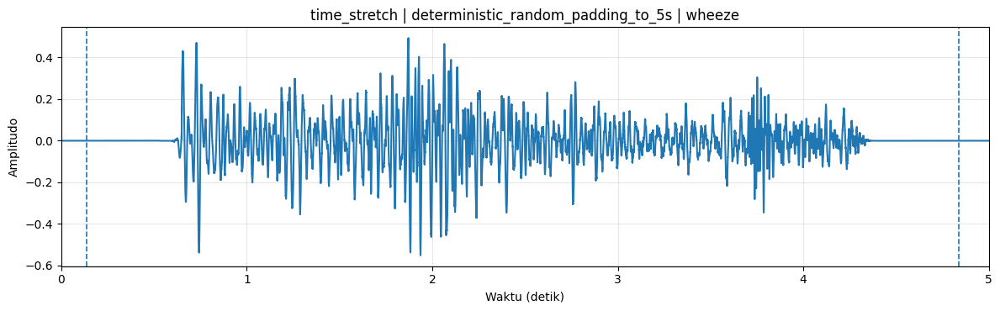

File                 : paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/train/500ac8b49fa77a0d_pid160_binabnormal_srcwheeze_aug000447_time_stretch_rate1.064_16k5s.wav
Sampling rate        : 16000
Panjang sampel       : 80000
Durasi               : 5.0
Strategi             : deterministic_random_padding_to_5s
Padding kiri/kanan  : 2201 / 2587
Crop start/end      : 0 / 75212


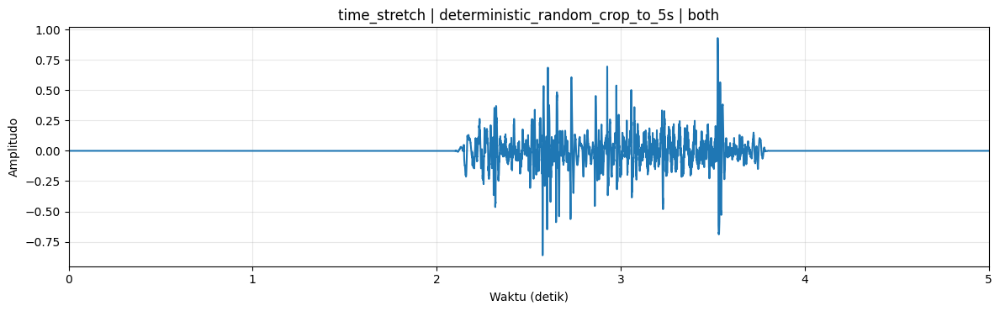

File                 : paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/train/65f81e34bf71c668_pid158_binabnormal_srcboth_aug000036_time_stretch_rate0.999_16k5s.wav
Sampling rate        : 16000
Panjang sampel       : 80000
Durasi               : 5.0
Strategi             : deterministic_random_crop_to_5s
Padding kiri/kanan  : 0 / 0
Crop start/end      : 54 / 80054


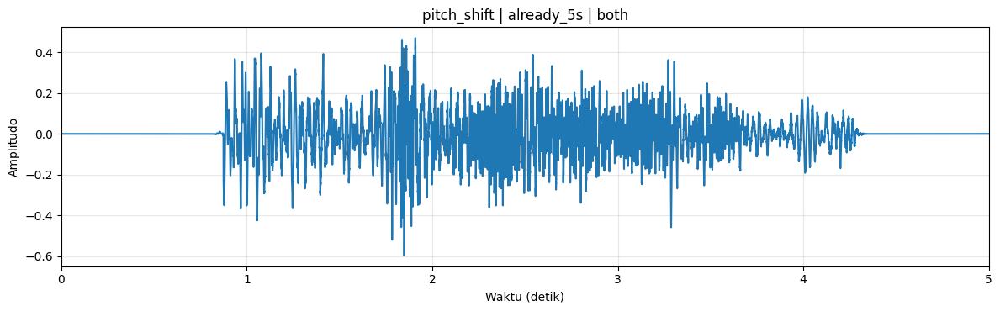

File                 : paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/train/18f0dd4cc857315c_pid114_binabnormal_srcboth_aug000294_pitch_shift_step+0.50_16k5s.wav
Sampling rate        : 16000
Panjang sampel       : 80000
Durasi               : 5.0
Strategi             : already_5s
Padding kiri/kanan  : 0 / 0
Crop start/end      : 0 / 80000



[OK] AUDIT HASIL AUGMENTASI MANUAL SELESAI
Random padding, random crop, seed deterministik, sampling rate, panjang sampel, dan durasi audio telah lolos validasi.


In [ ]:
# ============================================================
# CELL 18: AUDIT HASIL AUGMENTASI MANUAL 16 kHz + 5 DETIK
# ============================================================
import os
import hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
from IPython.display import Audio, display


# ============================================================
# 0. KONFIGURASI
# ============================================================

AUG_DIR = Path(
    globals().get(
        "AUG_DIR",
        "paper_binary_16k_outputs/04_augmented_audio_manual_16k5s",
    )
)

AUG_META_PATH = Path(
    globals().get(
        "AUG_META_PATH",
        AUG_DIR / "metadata_train_manual_aug_only_16k5s.csv",
    )
)

AUDIT_DIR = AUG_DIR / "audit"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

AUDIT_DETAIL_PATH = AUDIT_DIR / "audit_manual_augmentation_detail_16k5s.csv"
AUDIT_SUMMARY_PATH = AUDIT_DIR / "audit_manual_augmentation_summary_16k5s.csv"

TARGET_SR = int(globals().get("TARGET_SR", 16_000))
TARGET_DURATION_SEC = float(globals().get("TARGET_DURATION_SEC", 5.0))
TARGET_LEN_SAMPLES = int(
    globals().get(
        "TARGET_LEN",
        round(TARGET_SR * TARGET_DURATION_SEC),
    )
)

RANDOM_STATE = 42
ZERO_TOL = 1e-7
DURATION_TOL_SEC = 1e-6

ALLOWED_AUG_TYPES = {"time_stretch", "pitch_shift"}

STRATEGY_PADDING = "deterministic_random_padding_to_5s"
STRATEGY_CROP = "deterministic_random_crop_to_5s"
STRATEGY_ALREADY = "already_5s"

PADDING_METHOD = "deterministic_random_left_right_zero_padding_if_short"
CROP_METHOD = "deterministic_random_crop_if_long"

PREVIEW_PER_STRATEGY = 1


# ============================================================
# 1. HELPER UMUM
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def safe_str(value):
    if pd.isna(value):
        return ""
    return str(value).strip()


def make_seed_from_key(key, seed_base=RANDOM_STATE):
    """
    Harus sama dengan fungsi pada Cell 17.

    Seed 32-bit diturunkan secara stabil dari:
    RANDOM_STATE + aug_length_fix_seed_key.
    """
    key = str(key)
    digest = hashlib.md5(
        f"{seed_base}_{key}".encode("utf-8")
    ).hexdigest()
    return int(digest[:8], 16)


def compute_dbfs(y, eps=1e-10):
    y = np.asarray(y, dtype=np.float64)

    if y.ndim > 1:
        y = y.mean(axis=1)

    if y.size == 0:
        return np.nan

    rms = float(
        np.sqrt(
            np.mean(np.square(y, dtype=np.float64)) + eps
        )
    )
    return float(20.0 * np.log10(rms + eps))


def is_close(a, b, atol=1e-9):
    if pd.isna(a) or pd.isna(b):
        return False
    return bool(np.isclose(float(a), float(b), atol=atol, rtol=0.0))


def add_error(errors, condition, message):
    if not bool(condition):
        errors.append(str(message))


def normalize_metadata(df):
    df = df.copy()
    df.columns = [str(col).strip() for col in df.columns]

    if "file" not in df.columns:
        if "audio_path" in df.columns:
            df["file"] = df["audio_path"]
        else:
            raise AssertionError(
                "Metadata harus memiliki kolom `file` atau `audio_path`."
            )

    string_columns = [
        "file",
        "audio_path",
        "sample_id",
        "aug_type",
        "binary_label",
        "sound_4class",
        "split",
        "aug_length_fix_seed_key",
        "aug_length_fix_strategy",
        "aug_padding_strategy",
        "aug_crop_strategy",
        "aug_truncate_strategy",
    ]

    for col in string_columns:
        if col in df.columns:
            df[col] = df[col].fillna("").astype(str).str.strip()

    lower_columns = [
        "aug_type",
        "binary_label",
        "sound_4class",
        "split",
        "aug_length_fix_strategy",
        "aug_padding_strategy",
        "aug_crop_strategy",
        "aug_truncate_strategy",
    ]

    for col in lower_columns:
        if col in df.columns:
            df[col] = df[col].str.lower()

    numeric_columns = [
        "patient_id",
        "is_augmented",
        "aug_index",
        "aug_sr",
        "aug_len_samples",
        "aug_len_sec",
        "aug_len_before_fix_samples",
        "aug_len_before_fix_sec",
        "aug_length_fix_seed",
        "aug_crop_start_sample_before_fix",
        "aug_crop_end_sample_before_fix",
        "aug_crop_start_sec_before_fix",
        "aug_crop_end_sec_before_fix",
        "aug_padding_len_samples",
        "aug_padding_left_len_samples",
        "aug_padding_right_len_samples",
        "aug_padding_duration_sec",
        "aug_padding_left_duration_sec",
        "aug_padding_right_duration_sec",
        "aug_padding_ratio",
        "aug_active_start_sample_after_fix",
        "aug_active_end_sample_after_fix",
        "aug_active_start_sec_after_fix",
        "aug_active_end_sec_after_fix",
        "target_sr",
        "target_sec",
        "target_len_samples",
        "processed_len_samples",
        "processed_duration_sec",
    ]

    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


# ============================================================
# 2. LOAD DAN VALIDASI KOLOM METADATA
# ============================================================

if not AUG_META_PATH.exists():
    raise FileNotFoundError(
        f"Metadata augmentasi tidak ditemukan: {AUG_META_PATH}\n"
        "Jalankan Cell 17 yang telah diperbarui terlebih dahulu."
    )

aug_df = pd.read_csv(AUG_META_PATH)
aug_df = normalize_metadata(aug_df)

if len(aug_df) == 0:
    raise RuntimeError("Metadata augmentasi kosong.")

REQUIRED_COLUMNS = [
    "file",
    "sample_id",
    "patient_id",
    "split",
    "binary_label",
    "sound_4class",
    "is_augmented",
    "aug_type",
    "aug_sr",
    "aug_len_samples",
    "aug_len_sec",
    "aug_len_before_fix_samples",
    "aug_length_fix_seed_key",
    "aug_length_fix_seed",
    "aug_crop_start_sample_before_fix",
    "aug_crop_end_sample_before_fix",
    "aug_padding_len_samples",
    "aug_padding_left_len_samples",
    "aug_padding_right_len_samples",
    "aug_padding_duration_sec",
    "aug_padding_left_duration_sec",
    "aug_padding_right_duration_sec",
    "aug_padding_ratio",
    "aug_active_start_sample_after_fix",
    "aug_active_end_sample_after_fix",
    "aug_length_fix_strategy",
    "aug_padding_strategy",
    "aug_crop_strategy",
    "aug_truncate_strategy",
    "target_sr",
    "target_sec",
    "target_len_samples",
    "processed_len_samples",
    "processed_duration_sec",
]

missing_columns = [
    col for col in REQUIRED_COLUMNS
    if col not in aug_df.columns
]

if missing_columns:
    raise AssertionError(
        "Metadata belum berasal dari Cell 17 versi deterministic "
        f"padding/crop. Kolom yang tidak ditemukan: {missing_columns}"
    )

print("=" * 88)
print("AUDIT HASIL AUGMENTASI MANUAL 16 kHz + 5 DETIK")
print("=" * 88)
print("Metadata                 :", AUG_META_PATH)
print("Jumlah baris             :", len(aug_df))
print("Target sampling rate     :", TARGET_SR)
print("Target durasi            :", TARGET_DURATION_SEC)
print("Target panjang sampel    :", TARGET_LEN_SAMPLES)


# ============================================================
# 3. VALIDASI DASAR DATASET AUGMENTASI
# ============================================================

dataset_errors = []

add_error(
    dataset_errors,
    aug_df["file"].ne("").all(),
    "Terdapat path file kosong.",
)

add_error(
    dataset_errors,
    aug_df["sample_id"].ne("").all(),
    "Terdapat sample_id kosong.",
)

add_error(
    dataset_errors,
    aug_df["sample_id"].is_unique,
    "sample_id hasil augmentasi tidak unik.",
)

add_error(
    dataset_errors,
    aug_df["file"].is_unique,
    "Path file hasil augmentasi tidak unik.",
)

add_error(
    dataset_errors,
    set(aug_df["aug_type"].unique()).issubset(ALLOWED_AUG_TYPES),
    f"aug_type harus berada dalam {sorted(ALLOWED_AUG_TYPES)}.",
)

add_error(
    dataset_errors,
    aug_df["split"].eq("train").all(),
    "Augmentasi hanya boleh berada pada split train.",
)

add_error(
    dataset_errors,
    aug_df["is_augmented"].eq(1).all(),
    "Semua hasil augmentasi harus memiliki is_augmented = 1.",
)

add_error(
    dataset_errors,
    aug_df["binary_label"].eq("abnormal").all(),
    "Skenario ini mengharuskan seluruh hasil augmentasi berlabel abnormal.",
)

add_error(
    dataset_errors,
    aug_df["patient_id"].notna().all(),
    "Terdapat patient_id kosong atau tidak valid.",
)

add_error(
    dataset_errors,
    aug_df["aug_truncate_strategy"].eq("none").all(),
    "Tidak boleh ada truncate pada hasil augmentasi.",
)

if dataset_errors:
    raise AssertionError(
        "Validasi dasar metadata gagal:\n- "
        + "\n- ".join(dataset_errors)
    )

print("\n[OK] Validasi dasar metadata dan label.")


# ============================================================
# 4. AUDIT DETERMINISTIC RANDOM PADDING DAN RANDOM CROP
# ============================================================

def audit_length_fix_row(row):
    """
    Memvalidasi satu baris metadata berdasarkan strategi length fixing.

    Reproduksibilitas diperiksa dengan membuat ulang RNG dari
    aug_length_fix_seed_key. Audit tidak mengubah file audio.
    """
    errors = []

    original_len = int(row["aug_len_before_fix_samples"])
    target_len = int(row["target_len_samples"])

    seed_key = safe_str(row["aug_length_fix_seed_key"])
    stored_seed = int(row["aug_length_fix_seed"])
    expected_seed = int(make_seed_from_key(seed_key))
    rng = np.random.default_rng(expected_seed)

    strategy = safe_str(row["aug_length_fix_strategy"]).lower()
    padding_strategy = safe_str(row["aug_padding_strategy"]).lower()
    crop_strategy = safe_str(row["aug_crop_strategy"]).lower()
    truncate_strategy = safe_str(row["aug_truncate_strategy"]).lower()

    pad_total = int(row["aug_padding_len_samples"])
    pad_left = int(row["aug_padding_left_len_samples"])
    pad_right = int(row["aug_padding_right_len_samples"])

    crop_start = int(row["aug_crop_start_sample_before_fix"])
    crop_end = int(row["aug_crop_end_sample_before_fix"])

    active_start = int(row["aug_active_start_sample_after_fix"])
    active_end = int(row["aug_active_end_sample_after_fix"])

    add_error(
        errors,
        seed_key != "",
        "aug_length_fix_seed_key kosong.",
    )

    add_error(
        errors,
        stored_seed == expected_seed,
        (
            "Seed metadata tidak sama dengan seed hasil rekonstruksi: "
            f"{stored_seed} != {expected_seed}."
        ),
    )

    add_error(
        errors,
        target_len == TARGET_LEN_SAMPLES,
        (
            "target_len_samples tidak sesuai konfigurasi: "
            f"{target_len} != {TARGET_LEN_SAMPLES}."
        ),
    )

    add_error(
        errors,
        pad_left + pad_right == pad_total,
        (
            "Padding kiri + kanan tidak sama dengan total padding: "
            f"{pad_left} + {pad_right} != {pad_total}."
        ),
    )

    add_error(
        errors,
        0 <= active_start <= active_end <= target_len,
        (
            "Rentang audio aktif setelah fixing tidak valid: "
            f"{active_start}:{active_end} dari {target_len}."
        ),
    )

    add_error(
        errors,
        truncate_strategy == "none",
        f"truncate_strategy harus none, ditemukan {truncate_strategy}.",
    )

    expected_pad_left = 0
    expected_pad_right = 0
    expected_crop_start = 0
    expected_crop_end = original_len

    if original_len < target_len:
        expected_strategy = STRATEGY_PADDING
        expected_pad_total = target_len - original_len

        expected_pad_left = int(
            rng.integers(0, expected_pad_total + 1)
        )
        expected_pad_right = int(
            expected_pad_total - expected_pad_left
        )

        add_error(
            errors,
            strategy == STRATEGY_PADDING,
            (
                "Audio pendek harus memakai deterministic random padding, "
                f"ditemukan {strategy}."
            ),
        )

        add_error(
            errors,
            padding_strategy == PADDING_METHOD,
            (
                "padding_strategy tidak sesuai: "
                f"{padding_strategy} != {PADDING_METHOD}."
            ),
        )

        add_error(
            errors,
            crop_strategy == "none",
            "Audio pendek tidak boleh memakai crop.",
        )

        add_error(
            errors,
            pad_total == expected_pad_total,
            (
                "Total padding tidak sesuai: "
                f"{pad_total} != {expected_pad_total}."
            ),
        )

        add_error(
            errors,
            pad_left == expected_pad_left,
            (
                "Padding kiri tidak reproducible: "
                f"{pad_left} != {expected_pad_left}."
            ),
        )

        add_error(
            errors,
            pad_right == expected_pad_right,
            (
                "Padding kanan tidak reproducible: "
                f"{pad_right} != {expected_pad_right}."
            ),
        )

        add_error(
            errors,
            crop_start == 0 and crop_end == original_len,
            (
                "Metadata crop untuk audio pendek harus 0:original_len, "
                f"ditemukan {crop_start}:{crop_end}."
            ),
        )

        add_error(
            errors,
            active_start == pad_left,
            (
                "active_start harus sama dengan padding kiri: "
                f"{active_start} != {pad_left}."
            ),
        )

        add_error(
            errors,
            active_end == pad_left + original_len,
            (
                "active_end tidak sesuai: "
                f"{active_end} != {pad_left + original_len}."
            ),
        )

    elif original_len > target_len:
        expected_strategy = STRATEGY_CROP
        max_crop_start = original_len - target_len

        expected_crop_start = int(
            rng.integers(0, max_crop_start + 1)
        )
        expected_crop_end = int(
            expected_crop_start + target_len
        )

        add_error(
            errors,
            strategy == STRATEGY_CROP,
            (
                "Audio panjang harus memakai deterministic random crop, "
                f"ditemukan {strategy}."
            ),
        )

        add_error(
            errors,
            crop_strategy == CROP_METHOD,
            (
                "crop_strategy tidak sesuai: "
                f"{crop_strategy} != {CROP_METHOD}."
            ),
        )

        add_error(
            errors,
            padding_strategy == "none",
            "Audio panjang tidak boleh memakai padding.",
        )

        add_error(
            errors,
            pad_total == 0 and pad_left == 0 and pad_right == 0,
            "Audio panjang harus memiliki seluruh nilai padding = 0.",
        )

        add_error(
            errors,
            crop_start == expected_crop_start,
            (
                "Crop start tidak reproducible: "
                f"{crop_start} != {expected_crop_start}."
            ),
        )

        add_error(
            errors,
            crop_end == expected_crop_end,
            (
                "Crop end tidak reproducible: "
                f"{crop_end} != {expected_crop_end}."
            ),
        )

        add_error(
            errors,
            crop_end - crop_start == target_len,
            (
                "Panjang window crop tidak sesuai target: "
                f"{crop_end - crop_start} != {target_len}."
            ),
        )

        add_error(
            errors,
            0 <= crop_start <= max_crop_start,
            (
                "crop_start di luar batas legal: "
                f"{crop_start}, maksimum {max_crop_start}."
            ),
        )

        add_error(
            errors,
            active_start == 0 and active_end == target_len,
            (
                "Audio hasil crop harus aktif pada seluruh window: "
                f"{active_start}:{active_end}."
            ),
        )

    else:
        expected_strategy = STRATEGY_ALREADY

        add_error(
            errors,
            strategy == STRATEGY_ALREADY,
            (
                "Audio tepat 5 detik harus memakai already_5s, "
                f"ditemukan {strategy}."
            ),
        )

        add_error(
            errors,
            padding_strategy == "none",
            "Audio tepat 5 detik tidak boleh memakai padding.",
        )

        add_error(
            errors,
            crop_strategy == "none",
            "Audio tepat 5 detik tidak boleh memakai crop.",
        )

        add_error(
            errors,
            pad_total == 0 and pad_left == 0 and pad_right == 0,
            "Audio tepat 5 detik harus memiliki seluruh nilai padding = 0.",
        )

        add_error(
            errors,
            crop_start == 0 and crop_end == target_len,
            (
                "Rentang metadata audio tepat 5 detik harus 0:target_len, "
                f"ditemukan {crop_start}:{crop_end}."
            ),
        )

        add_error(
            errors,
            active_start == 0 and active_end == target_len,
            (
                "Audio tepat 5 detik harus aktif penuh: "
                f"{active_start}:{active_end}."
            ),
        )

    expected_pad_duration = pad_total / TARGET_SR
    expected_pad_left_duration = pad_left / TARGET_SR
    expected_pad_right_duration = pad_right / TARGET_SR
    expected_pad_ratio = pad_total / target_len

    add_error(
        errors,
        is_close(
            row["aug_padding_duration_sec"],
            expected_pad_duration,
            atol=1e-9,
        ),
        "aug_padding_duration_sec tidak konsisten.",
    )

    add_error(
        errors,
        is_close(
            row["aug_padding_left_duration_sec"],
            expected_pad_left_duration,
            atol=1e-9,
        ),
        "aug_padding_left_duration_sec tidak konsisten.",
    )

    add_error(
        errors,
        is_close(
            row["aug_padding_right_duration_sec"],
            expected_pad_right_duration,
            atol=1e-9,
        ),
        "aug_padding_right_duration_sec tidak konsisten.",
    )

    add_error(
        errors,
        is_close(
            row["aug_padding_ratio"],
            expected_pad_ratio,
            atol=1e-9,
        ),
        "aug_padding_ratio tidak konsisten.",
    )

    return {
        "expected_seed": expected_seed,
        "expected_strategy": expected_strategy,
        "expected_padding_left_samples": expected_pad_left,
        "expected_padding_right_samples": expected_pad_right,
        "expected_crop_start_sample": expected_crop_start,
        "expected_crop_end_sample": expected_crop_end,
        "length_fix_metadata_valid": len(errors) == 0,
        "length_fix_metadata_errors": " | ".join(errors),
    }


length_audit_rows = []

for idx, row in aug_df.iterrows():
    result = audit_length_fix_row(row)

    length_audit_rows.append({
        "metadata_index": int(idx),
        "sample_id": row["sample_id"],
        "file": row["file"],
        "aug_type": row["aug_type"],
        "sound_4class": row["sound_4class"],
        "aug_len_before_fix_samples": int(
            row["aug_len_before_fix_samples"]
        ),
        "aug_length_fix_strategy": row["aug_length_fix_strategy"],
        "aug_padding_len_samples": int(
            row["aug_padding_len_samples"]
        ),
        "aug_padding_left_len_samples": int(
            row["aug_padding_left_len_samples"]
        ),
        "aug_padding_right_len_samples": int(
            row["aug_padding_right_len_samples"]
        ),
        "aug_crop_start_sample_before_fix": int(
            row["aug_crop_start_sample_before_fix"]
        ),
        "aug_crop_end_sample_before_fix": int(
            row["aug_crop_end_sample_before_fix"]
        ),
        **result,
    })

length_audit_df = pd.DataFrame(length_audit_rows)

n_invalid_length_metadata = int(
    (~length_audit_df["length_fix_metadata_valid"]).sum()
)

print("\nDistribusi strategi penyesuaian panjang:")
print(
    aug_df["aug_length_fix_strategy"]
    .value_counts(dropna=False)
)

print("\nAudit metadata deterministic padding/crop:")
print(
    length_audit_df["length_fix_metadata_valid"]
    .value_counts(dropna=False)
)

if n_invalid_length_metadata > 0:
    print("\nContoh metadata length fixing yang tidak valid:")
    safe_display(
        length_audit_df[
            ~length_audit_df["length_fix_metadata_valid"]
        ].head(20)
    )

    raise AssertionError(
        "Audit deterministic random padding/crop gagal pada "
        f"{n_invalid_length_metadata} baris metadata."
    )

print("[OK] Seluruh metadata random padding dan random crop reproducible.")


# ============================================================
# 5. AUDIT SELURUH FILE AUDIO
# ============================================================

def audit_audio_file(row):
    errors = []
    path = Path(str(row["file"]))

    result = {
        "file_exists": path.exists(),
        "audio_readable": False,
        "actual_sr": np.nan,
        "actual_frames": np.nan,
        "actual_duration_sec": np.nan,
        "actual_channels": np.nan,
        "audio_finite": False,
        "left_padding_zero": True,
        "right_padding_zero": True,
        "active_region_nonempty": False,
        "audio_dbfs": np.nan,
    }

    if not path.exists():
        errors.append("File tidak ditemukan.")
        result["audio_file_valid"] = False
        result["audio_file_errors"] = " | ".join(errors)
        return result

    try:
        info = sf.info(str(path))

        actual_sr = int(info.samplerate)
        actual_frames = int(info.frames)
        actual_channels = int(info.channels)
        actual_duration = (
            actual_frames / actual_sr
            if actual_sr > 0
            else np.nan
        )

        result.update({
            "audio_readable": True,
            "actual_sr": actual_sr,
            "actual_frames": actual_frames,
            "actual_duration_sec": actual_duration,
            "actual_channels": actual_channels,
        })

        add_error(
            errors,
            actual_sr == TARGET_SR,
            f"Sampling rate {actual_sr} != {TARGET_SR}.",
        )

        add_error(
            errors,
            actual_frames == TARGET_LEN_SAMPLES,
            (
                f"Panjang audio {actual_frames} != "
                f"{TARGET_LEN_SAMPLES} sampel."
            ),
        )

        add_error(
            errors,
            abs(actual_duration - TARGET_DURATION_SEC)
            <= DURATION_TOL_SEC,
            (
                f"Durasi audio {actual_duration:.9f} != "
                f"{TARGET_DURATION_SEC:.9f} detik."
            ),
        )

        add_error(
            errors,
            actual_channels == 1,
            f"Audio harus mono, ditemukan {actual_channels} channel.",
        )

        y, sr_read = sf.read(
            str(path),
            always_2d=False,
            dtype="float32",
        )

        y = np.asarray(y, dtype=np.float32)

        if y.ndim > 1:
            y = y.mean(axis=1)

        finite = bool(np.all(np.isfinite(y)))
        result["audio_finite"] = finite

        add_error(
            errors,
            finite,
            "Audio mengandung NaN atau Inf.",
        )

        add_error(
            errors,
            int(sr_read) == TARGET_SR,
            f"Sampling rate saat read {sr_read} != {TARGET_SR}.",
        )

        add_error(
            errors,
            len(y) == TARGET_LEN_SAMPLES,
            (
                f"Panjang array saat read {len(y)} != "
                f"{TARGET_LEN_SAMPLES}."
            ),
        )

        result["audio_dbfs"] = compute_dbfs(y)

        strategy = safe_str(
            row["aug_length_fix_strategy"]
        ).lower()

        active_start = int(
            row["aug_active_start_sample_after_fix"]
        )
        active_end = int(
            row["aug_active_end_sample_after_fix"]
        )

        left_pad = y[:active_start]
        active = y[active_start:active_end]
        right_pad = y[active_end:]

        left_padding_zero = bool(
            left_pad.size == 0
            or np.max(np.abs(left_pad)) <= ZERO_TOL
        )
        right_padding_zero = bool(
            right_pad.size == 0
            or np.max(np.abs(right_pad)) <= ZERO_TOL
        )
        active_nonempty = bool(
            active.size > 0
            and np.any(np.abs(active) > ZERO_TOL)
        )

        result["left_padding_zero"] = left_padding_zero
        result["right_padding_zero"] = right_padding_zero
        result["active_region_nonempty"] = active_nonempty

        if strategy == STRATEGY_PADDING:
            add_error(
                errors,
                left_padding_zero,
                "Region padding kiri tidak bernilai nol.",
            )

            add_error(
                errors,
                right_padding_zero,
                "Region padding kanan tidak bernilai nol.",
            )

            add_error(
                errors,
                active_nonempty,
                "Region audio aktif kosong atau seluruhnya nol.",
            )

        elif strategy in {STRATEGY_CROP, STRATEGY_ALREADY}:
            add_error(
                errors,
                active_start == 0
                and active_end == TARGET_LEN_SAMPLES,
                (
                    "Audio crop/already_5s harus aktif pada seluruh "
                    "rentang output."
                ),
            )

            add_error(
                errors,
                active_nonempty,
                "Audio hasil crop/already_5s kosong atau seluruhnya nol.",
            )

    except Exception as exc:
        errors.append(f"Gagal membaca audio: {repr(exc)}")

    result["audio_file_valid"] = len(errors) == 0
    result["audio_file_errors"] = " | ".join(errors)

    return result


audio_audit_rows = []

for idx, row in aug_df.iterrows():
    file_result = audit_audio_file(row)

    audio_audit_rows.append({
        "metadata_index": int(idx),
        "sample_id": row["sample_id"],
        "file": row["file"],
        **file_result,
    })

audio_audit_df = pd.DataFrame(audio_audit_rows)

n_invalid_audio = int(
    (~audio_audit_df["audio_file_valid"]).sum()
)

print("\nAudit seluruh file audio:")
print(
    audio_audit_df["audio_file_valid"]
    .value_counts(dropna=False)
)

print("\nSampling rate aktual:")
print(
    audio_audit_df["actual_sr"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nPanjang sampel aktual:")
print(
    audio_audit_df["actual_frames"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nDurasi audio aktual:")
print(
    audio_audit_df["actual_duration_sec"]
    .describe()
)

if n_invalid_audio > 0:
    print("\nContoh file audio yang tidak valid:")
    safe_display(
        audio_audit_df[
            ~audio_audit_df["audio_file_valid"]
        ].head(20)
    )

    raise AssertionError(
        f"Audit file audio gagal pada {n_invalid_audio} file."
    )

print(
    "[OK] Seluruh file audio konsisten: "
    f"{TARGET_SR} Hz, {TARGET_LEN_SAMPLES} sampel, "
    f"{TARGET_DURATION_SEC:.1f} detik."
)


# ============================================================
# 6. GABUNGKAN HASIL AUDIT DAN SIMPAN
# ============================================================

audit_detail_df = (
    aug_df
    .reset_index()
    .rename(columns={"index": "metadata_index"})
    .merge(
        length_audit_df,
        on=[
            "metadata_index",
            "sample_id",
            "file",
            "aug_type",
            "sound_4class",
            "aug_len_before_fix_samples",
            "aug_length_fix_strategy",
            "aug_padding_len_samples",
            "aug_padding_left_len_samples",
            "aug_padding_right_len_samples",
            "aug_crop_start_sample_before_fix",
            "aug_crop_end_sample_before_fix",
        ],
        how="left",
        suffixes=("", "_audit"),
    )
    .merge(
        audio_audit_df,
        on=[
            "metadata_index",
            "sample_id",
            "file",
        ],
        how="left",
        suffixes=("", "_file_audit"),
    )
)

audit_detail_df["overall_audit_valid"] = (
    audit_detail_df["length_fix_metadata_valid"].fillna(False)
    & audit_detail_df["audio_file_valid"].fillna(False)
)

audit_detail_df.to_csv(
    AUDIT_DETAIL_PATH,
    index=False,
)

strategy_counts = (
    aug_df["aug_length_fix_strategy"]
    .value_counts(dropna=False)
)

summary_rows = [
    {
        "metric": "total_metadata_rows",
        "value": int(len(aug_df)),
    },
    {
        "metric": "valid_length_fix_metadata",
        "value": int(
            length_audit_df["length_fix_metadata_valid"].sum()
        ),
    },
    {
        "metric": "valid_audio_files",
        "value": int(
            audio_audit_df["audio_file_valid"].sum()
        ),
    },
    {
        "metric": "deterministic_random_padding_count",
        "value": int(
            strategy_counts.get(STRATEGY_PADDING, 0)
        ),
    },
    {
        "metric": "deterministic_random_crop_count",
        "value": int(
            strategy_counts.get(STRATEGY_CROP, 0)
        ),
    },
    {
        "metric": "already_5s_count",
        "value": int(
            strategy_counts.get(STRATEGY_ALREADY, 0)
        ),
    },
    {
        "metric": "invalid_overall_count",
        "value": int(
            (~audit_detail_df["overall_audit_valid"]).sum()
        ),
    },
    {
        "metric": "target_sr",
        "value": int(TARGET_SR),
    },
    {
        "metric": "target_len_samples",
        "value": int(TARGET_LEN_SAMPLES),
    },
    {
        "metric": "target_duration_sec",
        "value": float(TARGET_DURATION_SEC),
    },
]

audit_summary_df = pd.DataFrame(summary_rows)
audit_summary_df.to_csv(
    AUDIT_SUMMARY_PATH,
    index=False,
)

print("\nRingkasan audit:")
safe_display(audit_summary_df)

print("\nFile audit tersimpan:")
print("Detail :", AUDIT_DETAIL_PATH)
print("Summary:", AUDIT_SUMMARY_PATH)


# ============================================================
# 7. PREVIEW STRATEGI PADDING DAN CROP
# ============================================================

preview_frames = []

for strategy in [
    STRATEGY_PADDING,
    STRATEGY_CROP,
    STRATEGY_ALREADY,
]:
    subset = aug_df[
        aug_df["aug_length_fix_strategy"] == strategy
    ].copy()

    if len(subset) == 0:
        continue

    preview_frames.append(
        subset.sample(
            n=min(PREVIEW_PER_STRATEGY, len(subset)),
            random_state=RANDOM_STATE,
        )
    )

if preview_frames:
    preview_df = pd.concat(
        preview_frames,
        ignore_index=True,
    )
else:
    preview_df = aug_df.head(0).copy()

preview_columns = [
    "sample_id",
    "patient_id",
    "sound_4class",
    "aug_type",
    "time_stretch_rate",
    "pitch_shift_steps",
    "aug_len_before_fix_samples",
    "aug_length_fix_strategy",
    "aug_padding_left_len_samples",
    "aug_padding_right_len_samples",
    "aug_crop_start_sample_before_fix",
    "aug_crop_end_sample_before_fix",
    "file",
]

preview_columns = [
    col for col in preview_columns
    if col in preview_df.columns
]

print("\nContoh metadata audit per strategi:")
safe_display(preview_df[preview_columns])

for _, row in preview_df.iterrows():
    path = Path(str(row["file"]))

    if not path.exists():
        continue

    y, sr = sf.read(
        str(path),
        always_2d=False,
        dtype="float32",
    )

    y = np.asarray(y, dtype=np.float32)

    if y.ndim > 1:
        y = y.mean(axis=1)

    duration = len(y) / sr
    time_axis = np.arange(len(y)) / sr

    active_start = int(
        row["aug_active_start_sample_after_fix"]
    )
    active_end = int(
        row["aug_active_end_sample_after_fix"]
    )

    fig, ax = plt.subplots(figsize=(12, 3.8))
    ax.plot(time_axis, y)

    if active_start > 0:
        ax.axvline(
            active_start / sr,
            linestyle="--",
            linewidth=1.2,
        )

    if active_end < len(y):
        ax.axvline(
            active_end / sr,
            linestyle="--",
            linewidth=1.2,
        )

    ax.set_title(
        f"{row['aug_type']} | "
        f"{row['aug_length_fix_strategy']} | "
        f"{row['sound_4class']}"
    )
    ax.set_xlabel("Waktu (detik)")
    ax.set_ylabel("Amplitudo")
    ax.set_xlim(0, duration)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("File                 :", path)
    print("Sampling rate        :", sr)
    print("Panjang sampel       :", len(y))
    print("Durasi               :", duration)
    print("Strategi             :", row["aug_length_fix_strategy"])
    print(
        "Padding kiri/kanan  :",
        int(row["aug_padding_left_len_samples"]),
        "/",
        int(row["aug_padding_right_len_samples"]),
    )
    print(
        "Crop start/end      :",
        int(row["aug_crop_start_sample_before_fix"]),
        "/",
        int(row["aug_crop_end_sample_before_fix"]),
    )

    display(
        Audio(
            data=y,
            rate=sr,
            normalize=False,
        )
    )


# ============================================================
# 8. ASSERTION AKHIR
# ============================================================

assert audit_detail_df["overall_audit_valid"].all(), (
    "Masih terdapat hasil augmentasi yang gagal audit."
)

assert (
    aug_df["aug_padding_left_len_samples"].astype(int)
    + aug_df["aug_padding_right_len_samples"].astype(int)
    == aug_df["aug_padding_len_samples"].astype(int)
).all(), (
    "Padding kiri + kanan tidak sama dengan total padding."
)

assert (
    aug_df["processed_len_samples"].astype(int)
    == TARGET_LEN_SAMPLES
).all(), (
    "processed_len_samples tidak konsisten."
)

assert (
    aug_df["aug_len_samples"].astype(int)
    == TARGET_LEN_SAMPLES
).all(), (
    "aug_len_samples tidak konsisten."
)

assert (
    aug_df["target_sr"].astype(int)
    == TARGET_SR
).all(), (
    "target_sr metadata tidak konsisten."
)

assert (
    aug_df["aug_sr"].astype(int)
    == TARGET_SR
).all(), (
    "aug_sr metadata tidak konsisten."
)

assert np.allclose(
    aug_df["processed_duration_sec"].astype(float),
    TARGET_DURATION_SEC,
    atol=DURATION_TOL_SEC,
    rtol=0.0,
), (
    "processed_duration_sec tidak konsisten."
)

assert np.allclose(
    aug_df["aug_len_sec"].astype(float),
    TARGET_DURATION_SEC,
    atol=DURATION_TOL_SEC,
    rtol=0.0,
), (
    "aug_len_sec tidak konsisten."
)

print("\n" + "=" * 88)
print("[OK] AUDIT HASIL AUGMENTASI MANUAL SELESAI")
print("=" * 88)
print(
    "Random padding, random crop, seed deterministik, "
    "sampling rate, panjang sampel, dan durasi audio "
    "telah lolos validasi."
)


# ============================================================
# 9. SIMPAN KE GLOBALS
# ============================================================

globals()["AUG_DIR"] = str(AUG_DIR)
globals()["AUG_META_PATH"] = str(AUG_META_PATH)
globals()["audit_manual_aug_detail_df"] = audit_detail_df
globals()["audit_manual_aug_summary_df"] = audit_summary_df
globals()["preview_manual_aug_audit_df"] = preview_df

# **Gabungkan data asli dengan augmentasi**

In [ ]:
# ============================================================
# CELL 20: GABUNGKAN TRAIN ASLI + AUGMENTASI MANUAL 16k5s
# ============================================================
import os
from decimal import Decimal, InvalidOperation
from pathlib import Path

import numpy as np
import pandas as pd

# ============================================================
# 0. KONFIGURASI PATH
# ============================================================

PREPROC_DIR = Path("paper_binary_16k_outputs/03_preprocessed_audio_16k5s")
AUG_DIR = Path("paper_binary_16k_outputs/04_augmented_audio_manual_16k5s")

TRAIN_META_PATH = PREPROC_DIR / "metadata_train_16k5s.csv"
AUG_META_PATH = AUG_DIR / "metadata_train_manual_aug_only_16k5s.csv"

OUT_PATH = AUG_DIR / "metadata_train_with_manual_aug_16k5s.csv"

BINARY_SUMMARY_PATH = AUG_DIR / "summary_train_with_manual_aug_binary_16k5s.csv"
SOURCE_SUMMARY_PATH = AUG_DIR / "summary_train_with_manual_aug_source_16k5s.csv"
AUG_TYPE_SUMMARY_PATH = AUG_DIR / "summary_train_with_manual_aug_type_16k5s.csv"
AUG_DETAIL_SUMMARY_PATH = AUG_DIR / "summary_train_with_manual_aug_detail_16k5s.csv"
LENGTH_FIX_SUMMARY_PATH = AUG_DIR / "summary_train_length_fix_strategy_16k5s.csv"
PADDING_POSITION_SUMMARY_PATH = AUG_DIR / "summary_train_random_padding_position_16k5s.csv"

TARGET_SR = 16000
TARGET_DURATION_SEC = 5.0
TARGET_LEN_SAMPLES = int(TARGET_SR * TARGET_DURATION_SEC)
RANDOM_PADDING_SEED = 42

AUG_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. KONFIGURASI LABEL
# ============================================================

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both"]
BINARY_CLASSES = ["normal", "abnormal"]

LABEL_TO_ID = {
    "normal": 0,
    "abnormal": 1
}

ALLOWED_AUG_TYPES_ORIGINAL = {"none"}
ALLOWED_AUG_TYPES_AUG = {"time_stretch", "pitch_shift"}
ALLOWED_AUG_TYPES_ALL = ALLOWED_AUG_TYPES_ORIGINAL | ALLOWED_AUG_TYPES_AUG

# Strategi preprocessing original dari Cell 12.
EXPECTED_ORIGINAL_FIX_STRATEGY = (
    "sequential_5s_chunking_with_deterministic_random_padding"
)
EXPECTED_ORIGINAL_PADDING_STRATEGY = (
    "deterministic_random_zero_padding_for_short_or_last_chunk"
)

# Strategi length fixing augmentasi dari Cell 17.
ALLOWED_AUG_LENGTH_FIX = {
    "already_5s",
    "deterministic_random_padding_to_5s",
    "deterministic_random_crop_to_5s",
}

ALLOWED_AUG_PADDING_STRATEGY = {
    "none",
    "deterministic_random_left_right_zero_padding_if_short",
}

ALLOWED_AUG_CROP_STRATEGY = {
    "none",
    "deterministic_random_crop_if_long",
}

ALLOWED_AUG_TRUNCATE_STRATEGY = {"none"}


# ============================================================
# 2. HELPER
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def safe_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def to_binary_label(label):
    label = str(label).strip().lower()

    if label == "normal":
        return "normal"

    if label in ["crackle", "wheeze", "both", "abnormal"]:
        return "abnormal"

    raise ValueError(f"Label tidak dikenal: {label}")


def infer_sound_4class(row):
    for col in ["sound_4class", "original_sound", "sound"]:
        if col in row.index and safe_str(row[col]):
            value = safe_str(row[col]).lower()
            if value in SOURCE_CLASSES:
                return value

    binary_label = safe_str(row.get("binary_label", "")).lower()

    if binary_label == "normal":
        return "normal"

    return "unknown"


def normalize_file_columns(df, name):
    df = df.copy()

    if "file" not in df.columns:
        if "audio_path" in df.columns:
            df["file"] = df["audio_path"].astype(str)
        else:
            raise ValueError(f"{name}: kolom `file` atau `audio_path` tidak ditemukan.")

    df["file"] = df["file"].astype(str).str.strip()

    if "audio_path" not in df.columns:
        df["audio_path"] = df["file"]

    df["audio_path"] = df["audio_path"].astype(str).str.strip()

    return df


def normalize_metadata(df, name, is_augmented_default):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    df = normalize_file_columns(df, name)

    if "patient_id" not in df.columns:
        raise ValueError(f"{name}: kolom `patient_id` tidak ditemukan.")

    df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")
    df = df.dropna(subset=["patient_id"]).copy()
    df["patient_id"] = df["patient_id"].astype(int)
    df = df[df["patient_id"] != -1].copy()

    if "split" not in df.columns:
        df["split"] = "train"

    df["split"] = df["split"].astype(str).str.strip().str.lower()
    df = df[df["split"] == "train"].copy().reset_index(drop=True)

    if "sound_4class" not in df.columns:
        df["sound_4class"] = df.apply(infer_sound_4class, axis=1)
    else:
        df["sound_4class"] = df["sound_4class"].astype(str).str.strip().str.lower()

    if "sound" not in df.columns:
        df["sound"] = df["sound_4class"]
    else:
        df["sound"] = df["sound"].astype(str).str.strip().str.lower()

    if "original_sound" not in df.columns:
        df["original_sound"] = df["sound_4class"]
    else:
        df["original_sound"] = df["original_sound"].astype(str).str.strip().str.lower()

    unknown_sound = sorted(set(df["sound_4class"].unique()) - set(SOURCE_CLASSES))

    if len(unknown_sound) > 0:
        raise AssertionError(
            f"{name}: ada sound_4class tidak valid: {unknown_sound}. "
            "Kolom sound_4class harus normal/crackle/wheeze/both."
        )

    if "binary_label" not in df.columns:
        df["binary_label"] = df["sound_4class"].apply(to_binary_label)
    else:
        df["binary_label"] = df["binary_label"].astype(str).str.strip().str.lower()

    expected_binary = df["sound_4class"].apply(to_binary_label)
    mismatch = expected_binary != df["binary_label"]

    if mismatch.any():
        print(
            f"[WARNING] {name}: {int(mismatch.sum())} binary_label tidak sesuai "
            "dengan sound_4class. Diperbaiki otomatis."
        )
        df.loc[mismatch, "binary_label"] = expected_binary.loc[mismatch]

    unknown_binary = sorted(set(df["binary_label"].unique()) - set(BINARY_CLASSES))

    if len(unknown_binary) > 0:
        raise AssertionError(f"{name}: binary_label tidak valid: {unknown_binary}")

    df["label_id"] = df["binary_label"].map(LABEL_TO_ID).astype(int)

    if "is_augmented" not in df.columns:
        df["is_augmented"] = int(is_augmented_default)
    else:
        df["is_augmented"] = (
            pd.to_numeric(df["is_augmented"], errors="coerce")
            .fillna(is_augmented_default)
            .astype(int)
        )

    if is_augmented_default == 0:
        df["is_augmented"] = 0
        df["source"] = "preprocessed_original_16k5s"
        df["aug_type"] = "none"
        df["augmentation_group"] = "original"
        df["length_fix_stage"] = "preprocessing_original"
    else:
        df["is_augmented"] = 1
        df["source"] = "manual_aug_16k5s"

        if "aug_type" not in df.columns:
            raise AssertionError(
                f"{name}: kolom aug_type tidak ditemukan pada metadata augmentasi."
            )

        df["aug_type"] = df["aug_type"].astype(str).str.strip().str.lower()
        df["augmentation_group"] = "manual_aug"
        df["length_fix_stage"] = "manual_augmentation"

    if "target_sr" not in df.columns:
        df["target_sr"] = TARGET_SR
    else:
        df["target_sr"] = (
            pd.to_numeric(df["target_sr"], errors="coerce")
            .fillna(TARGET_SR)
            .astype(int)
        )

    if "target_sec" not in df.columns:
        df["target_sec"] = TARGET_DURATION_SEC
    else:
        df["target_sec"] = (
            pd.to_numeric(df["target_sec"], errors="coerce")
            .fillna(TARGET_DURATION_SEC)
            .astype(float)
        )

    if "target_len_samples" not in df.columns:
        df["target_len_samples"] = TARGET_LEN_SAMPLES
    else:
        df["target_len_samples"] = (
            pd.to_numeric(df["target_len_samples"], errors="coerce")
            .fillna(TARGET_LEN_SAMPLES)
            .astype(int)
        )

    if "processed_len_samples" not in df.columns:
        df["processed_len_samples"] = TARGET_LEN_SAMPLES
    else:
        df["processed_len_samples"] = (
            pd.to_numeric(df["processed_len_samples"], errors="coerce")
            .fillna(TARGET_LEN_SAMPLES)
            .astype(int)
        )

    if "processed_duration_sec" not in df.columns:
        df["processed_duration_sec"] = TARGET_DURATION_SEC
    else:
        df["processed_duration_sec"] = (
            pd.to_numeric(df["processed_duration_sec"], errors="coerce")
            .fillna(TARGET_DURATION_SEC)
            .astype(float)
        )

    return df.reset_index(drop=True)


def validate_file_exists(df, name):
    df = df.copy()

    df["file_exists"] = df["file"].apply(lambda p: os.path.exists(str(p)))
    missing_count = int((~df["file_exists"]).sum())

    if missing_count > 0:
        print(f"\n{name}: ada {missing_count} file audio yang tidak ditemukan.")
        preview_cols = [
            "file",
            "patient_id",
            "sound_4class",
            "binary_label",
            "is_augmented",
            "aug_type"
        ]
        preview_cols = [c for c in preview_cols if c in df.columns]
        safe_display(df.loc[~df["file_exists"], preview_cols].head(10))

        raise FileNotFoundError(f"{name}: ada file audio yang hilang.")

    return df.drop(columns=["file_exists"], errors="ignore")


def validate_audio_values(df, name):
    df = df.copy()

    target_sr = pd.to_numeric(df["target_sr"], errors="coerce").fillna(-1).astype(int)
    bad_sr = int((target_sr != TARGET_SR).sum())

    if bad_sr > 0:
        raise AssertionError(f"{name}: ada {bad_sr} baris target_sr bukan {TARGET_SR}.")

    target_len = pd.to_numeric(df["target_len_samples"], errors="coerce").fillna(-1).astype(int)
    bad_len = int((target_len != TARGET_LEN_SAMPLES).sum())

    if bad_len > 0:
        raise AssertionError(
            f"{name}: ada {bad_len} baris target_len_samples bukan {TARGET_LEN_SAMPLES}."
        )

    processed_len = pd.to_numeric(df["processed_len_samples"], errors="coerce").fillna(-1).astype(int)
    bad_processed_len = int((processed_len != TARGET_LEN_SAMPLES).sum())

    if bad_processed_len > 0:
        raise AssertionError(
            f"{name}: ada {bad_processed_len} baris processed_len_samples bukan {TARGET_LEN_SAMPLES}."
        )

    if "aug_sr" in df.columns:
        aug_sr = pd.to_numeric(df["aug_sr"], errors="coerce").dropna().astype(int)

        if len(aug_sr) > 0:
            bad_aug_sr = int((aug_sr != TARGET_SR).sum())

            if bad_aug_sr > 0:
                raise AssertionError(f"{name}: ada {bad_aug_sr} aug_sr bukan {TARGET_SR}.")

    if "aug_len_samples" in df.columns:
        aug_len = pd.to_numeric(df["aug_len_samples"], errors="coerce").dropna().astype(int)

        if len(aug_len) > 0:
            bad_aug_len = int((aug_len != TARGET_LEN_SAMPLES).sum())

            if bad_aug_len > 0:
                raise AssertionError(
                    f"{name}: ada {bad_aug_len} aug_len_samples bukan {TARGET_LEN_SAMPLES}."
                )

    return df


def _require_columns(df, required_cols, name):
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise AssertionError(
            f"{name}: kolom metadata length fixing belum lengkap: {missing}. "
            "Jalankan ulang Cell 12 dan/atau Cell 17 versi terbaru."
        )


def _numeric_series(df, column, name, integer=False):
    values = pd.to_numeric(df[column], errors="coerce")

    if values.isna().any():
        bad_count = int(values.isna().sum())
        raise AssertionError(
            f"{name}: kolom `{column}` memiliki {bad_count} nilai nonnumerik/kosong."
        )

    return values.astype(int if integer else float)


def _seed_series(df, column, name):
    """
    Membaca seed sebagai Python ``int`` tanpa melalui float64/int64.

    Seed deterministic random padding Cell 12 dibuat dari unsigned 64-bit
    SHA-256. Nilainya dapat lebih besar dari batas maksimum signed int64
    (2**63 - 1). Konversi lama melalui ``pd.to_numeric(...).astype(int)``
    dapat mengubah seed valid menjadi -9223372036854775808.

    Dtype object dipakai agar unsigned 64-bit dan sentinel -1 tetap utuh.
    """
    parsed_values = []
    invalid_rows = []

    for row_index, raw_value in df[column].items():
        if pd.isna(raw_value):
            invalid_rows.append((row_index, raw_value, "kosong/NaN"))
            parsed_values.append(None)
            continue

        token = str(raw_value).strip()

        if token == "":
            invalid_rows.append((row_index, raw_value, "string kosong"))
            parsed_values.append(None)
            continue

        try:
            decimal_value = Decimal(token)
        except (InvalidOperation, ValueError):
            invalid_rows.append((row_index, raw_value, "bukan angka"))
            parsed_values.append(None)
            continue

        if not decimal_value.is_finite():
            invalid_rows.append((row_index, raw_value, "bukan angka finite"))
            parsed_values.append(None)
            continue

        if decimal_value != decimal_value.to_integral_value():
            invalid_rows.append((row_index, raw_value, "bukan bilangan bulat"))
            parsed_values.append(None)
            continue

        parsed_values.append(int(decimal_value))

    if invalid_rows:
        raise AssertionError(
            f"{name}: kolom `{column}` memiliki {len(invalid_rows)} seed tidak valid. "
            f"Contoh: {invalid_rows[:10]}"
        )

    return pd.Series(
        parsed_values,
        index=df.index,
        dtype=object,
        name=column,
    )


def validate_original_random_padding_metadata(df, name):
    """
    Memvalidasi metadata deterministic random padding dari Cell 12.

    Audio original tetap berasal dari sequential 5-second chunking.
    Hanya chunk yang lebih pendek dari target yang memperoleh zero padding
    pada sisi kiri dan kanan. Tidak ada crop atau truncate.
    """
    required_cols = [
        "active_len_samples_before_fix",
        "padding_len_samples",
        "padding_left_len_samples",
        "padding_right_len_samples",
        "padding_duration_sec",
        "padding_left_duration_sec",
        "padding_right_duration_sec",
        "padding_ratio",
        "padding_random_seed",
        "padding_seed_key",
        "active_start_sample_after_fix",
        "active_end_sample_after_fix",
        "fix_strategy",
        "padding_strategy",
        "crop_strategy",
        "truncate_strategy",
    ]
    _require_columns(df, required_cols, name)

    active_len = _numeric_series(
        df, "active_len_samples_before_fix", name, integer=True
    )
    padding_total = _numeric_series(
        df, "padding_len_samples", name, integer=True
    )
    padding_left = _numeric_series(
        df, "padding_left_len_samples", name, integer=True
    )
    padding_right = _numeric_series(
        df, "padding_right_len_samples", name, integer=True
    )
    active_start = _numeric_series(
        df, "active_start_sample_after_fix", name, integer=True
    )
    active_end = _numeric_series(
        df, "active_end_sample_after_fix", name, integer=True
    )
    padding_seed = _seed_series(
        df,
        "padding_random_seed",
        name,
    )

    if not (padding_left + padding_right == padding_total).all():
        raise AssertionError(
            f"{name}: padding kiri + kanan tidak sama dengan total padding."
        )

    if not (active_len + padding_total == TARGET_LEN_SAMPLES).all():
        raise AssertionError(
            f"{name}: active_len + padding_len tidak sama dengan "
            f"{TARGET_LEN_SAMPLES} sampel."
        )

    if not (active_start == padding_left).all():
        raise AssertionError(
            f"{name}: active_start_sample_after_fix tidak sama dengan padding kiri."
        )

    if not (active_end == padding_left + active_len).all():
        raise AssertionError(
            f"{name}: active_end_sample_after_fix tidak konsisten."
        )

    valid_range = (
        (active_start >= 0)
        & (active_start <= active_end)
        & (active_end <= TARGET_LEN_SAMPLES)
    )
    if not valid_range.all():
        raise AssertionError(
            f"{name}: posisi sinyal aktif setelah preprocessing tidak valid."
        )

    padded_mask = padding_total > 0
    no_padding_mask = ~padded_mask

    if padded_mask.any():
        seed_keys = (
            df.loc[padded_mask, "padding_seed_key"]
            .fillna("")
            .astype(str)
            .str.strip()
        )
        if (seed_keys == "").any():
            raise AssertionError(
                f"{name}: ada sampel ber-padding tanpa padding_seed_key."
            )

        invalid_negative_seed_mask = (
            padding_seed.loc[padded_mask].map(lambda value: int(value) < 0)
        )

        if invalid_negative_seed_mask.any():
            invalid_indices = invalid_negative_seed_mask[
                invalid_negative_seed_mask
            ].index.tolist()

            invalid_preview = df.loc[
                invalid_indices,
                [
                    "padding_random_seed",
                    "padding_seed_key",
                    "padding_len_samples",
                ],
            ].head(10)

            raise AssertionError(
                f"{name}: ada sampel ber-padding dengan seed negatif yang "
                "benar-benar tersimpan pada metadata sumber. "
                "Ini bukan lagi overflow parser. Contoh:\n"
                f"{invalid_preview.to_string(index=False)}"
            )

    # Informasi audit: seed dapat melampaui signed int64 dan tetap valid.
    if padded_mask.any():
        padded_seed_values = padding_seed.loc[padded_mask].map(int)
        signed_int64_max = np.iinfo(np.int64).max
        unsigned_seed_count = int(
            padded_seed_values.map(
                lambda value: value > signed_int64_max
            ).sum()
        )

        print(
            f"{name}: seed padding valid={int(padded_mask.sum())}, "
            f"seed > signed int64={unsigned_seed_count}"
        )

    # Cell 12 menyimpan -1 saat tidak diperlukan padding.
    if no_padding_mask.any():
        invalid_no_pad_seed = padding_seed.loc[no_padding_mask].map(
            lambda value: int(value) < -1
        )
        if invalid_no_pad_seed.any():
            raise AssertionError(
                f"{name}: nilai seed pada sampel tanpa padding tidak valid."
            )

    fix_strategy = (
        df["fix_strategy"].fillna("").astype(str).str.strip().str.lower()
    )
    padding_strategy = (
        df["padding_strategy"].fillna("").astype(str).str.strip().str.lower()
    )
    crop_strategy = (
        df["crop_strategy"].fillna("").astype(str).str.strip().str.lower()
    )
    truncate_strategy = (
        df["truncate_strategy"].fillna("").astype(str).str.strip().str.lower()
    )

    if not fix_strategy.eq(EXPECTED_ORIGINAL_FIX_STRATEGY).all():
        invalid = sorted(
            set(fix_strategy.unique()) - {EXPECTED_ORIGINAL_FIX_STRATEGY}
        )
        raise AssertionError(
            f"{name}: fix_strategy original tidak valid: {invalid}"
        )

    if not padding_strategy.eq(EXPECTED_ORIGINAL_PADDING_STRATEGY).all():
        invalid = sorted(
            set(padding_strategy.unique())
            - {EXPECTED_ORIGINAL_PADDING_STRATEGY}
        )
        raise AssertionError(
            f"{name}: padding_strategy original tidak valid: {invalid}"
        )

    if not crop_strategy.eq("none").all():
        raise AssertionError(f"{name}: data original tidak boleh memakai crop.")

    if not truncate_strategy.eq("none").all():
        raise AssertionError(f"{name}: data original tidak boleh memakai truncate.")

    return df


def validate_aug_random_padding_crop_metadata(df, name):
    """
    Memvalidasi metadata deterministic random padding/crop dari Cell 17.

    - Hasil augmentasi lebih pendek: random padding kiri-kanan.
    - Hasil augmentasi lebih panjang: deterministic random crop.
    - Hasil tepat 5 detik: tidak diubah.
    """
    required_cols = [
        "aug_len_before_fix_samples",
        "aug_length_fix_seed_key",
        "aug_length_fix_seed",
        "aug_crop_start_sample_before_fix",
        "aug_crop_end_sample_before_fix",
        "aug_padding_len_samples",
        "aug_padding_left_len_samples",
        "aug_padding_right_len_samples",
        "aug_padding_duration_sec",
        "aug_padding_left_duration_sec",
        "aug_padding_right_duration_sec",
        "aug_padding_ratio",
        "aug_active_start_sample_after_fix",
        "aug_active_end_sample_after_fix",
        "aug_length_fix_strategy",
        "aug_padding_strategy",
        "aug_crop_strategy",
        "aug_truncate_strategy",
    ]
    _require_columns(df, required_cols, name)

    len_before = _numeric_series(
        df, "aug_len_before_fix_samples", name, integer=True
    )
    fix_seed = _seed_series(
        df,
        "aug_length_fix_seed",
        name,
    )
    crop_start = _numeric_series(
        df, "aug_crop_start_sample_before_fix", name, integer=True
    )
    crop_end = _numeric_series(
        df, "aug_crop_end_sample_before_fix", name, integer=True
    )
    padding_total = _numeric_series(
        df, "aug_padding_len_samples", name, integer=True
    )
    padding_left = _numeric_series(
        df, "aug_padding_left_len_samples", name, integer=True
    )
    padding_right = _numeric_series(
        df, "aug_padding_right_len_samples", name, integer=True
    )
    active_start = _numeric_series(
        df, "aug_active_start_sample_after_fix", name, integer=True
    )
    active_end = _numeric_series(
        df, "aug_active_end_sample_after_fix", name, integer=True
    )

    seed_keys = (
        df["aug_length_fix_seed_key"]
        .fillna("")
        .astype(str)
        .str.strip()
    )
    if (seed_keys == "").any():
        raise AssertionError(
            f"{name}: aug_length_fix_seed_key tidak boleh kosong."
        )
    if not (fix_seed >= 0).all():
        raise AssertionError(
            f"{name}: aug_length_fix_seed harus nonnegatif."
        )

    if not (padding_left + padding_right == padding_total).all():
        raise AssertionError(
            f"{name}: aug padding kiri + kanan tidak sama dengan total padding."
        )

    valid_active_range = (
        (active_start >= 0)
        & (active_start <= active_end)
        & (active_end <= TARGET_LEN_SAMPLES)
    )
    if not valid_active_range.all():
        raise AssertionError(
            f"{name}: posisi sinyal aktif hasil augmentasi tidak valid."
        )

    strategy = (
        df["aug_length_fix_strategy"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )
    padding_strategy = (
        df["aug_padding_strategy"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )
    crop_strategy = (
        df["aug_crop_strategy"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )
    truncate_strategy = (
        df["aug_truncate_strategy"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    invalid_fix = sorted(set(strategy.unique()) - ALLOWED_AUG_LENGTH_FIX)
    invalid_padding = sorted(
        set(padding_strategy.unique()) - ALLOWED_AUG_PADDING_STRATEGY
    )
    invalid_crop = sorted(
        set(crop_strategy.unique()) - ALLOWED_AUG_CROP_STRATEGY
    )
    invalid_truncate = sorted(
        set(truncate_strategy.unique()) - ALLOWED_AUG_TRUNCATE_STRATEGY
    )

    if invalid_fix:
        raise AssertionError(
            f"{name}: aug_length_fix_strategy tidak valid: {invalid_fix}"
        )
    if invalid_padding:
        raise AssertionError(
            f"{name}: aug_padding_strategy tidak valid: {invalid_padding}"
        )
    if invalid_crop:
        raise AssertionError(
            f"{name}: aug_crop_strategy tidak valid: {invalid_crop}"
        )
    if invalid_truncate:
        raise AssertionError(
            f"{name}: aug_truncate_strategy tidak valid: {invalid_truncate}"
        )

    short_mask = len_before < TARGET_LEN_SAMPLES
    long_mask = len_before > TARGET_LEN_SAMPLES
    exact_mask = len_before == TARGET_LEN_SAMPLES

    if short_mask.any():
        expected_padding = TARGET_LEN_SAMPLES - len_before.loc[short_mask]

        if not (
            padding_total.loc[short_mask] == expected_padding
        ).all():
            raise AssertionError(
                f"{name}: total padding audio pendek tidak sesuai."
            )
        if not (
            active_start.loc[short_mask] == padding_left.loc[short_mask]
        ).all():
            raise AssertionError(
                f"{name}: posisi awal audio aktif setelah padding tidak sesuai."
            )
        if not (
            active_end.loc[short_mask]
            == padding_left.loc[short_mask] + len_before.loc[short_mask]
        ).all():
            raise AssertionError(
                f"{name}: posisi akhir audio aktif setelah padding tidak sesuai."
            )
        if not strategy.loc[short_mask].eq(
            "deterministic_random_padding_to_5s"
        ).all():
            raise AssertionError(
                f"{name}: audio pendek tidak memakai strategi random padding."
            )
        if not padding_strategy.loc[short_mask].eq(
            "deterministic_random_left_right_zero_padding_if_short"
        ).all():
            raise AssertionError(
                f"{name}: padding_strategy audio pendek tidak sesuai."
            )
        if not crop_strategy.loc[short_mask].eq("none").all():
            raise AssertionError(
                f"{name}: audio pendek tidak boleh memakai crop."
            )

    if long_mask.any():
        if not (padding_total.loc[long_mask] == 0).all():
            raise AssertionError(
                f"{name}: audio panjang tidak boleh memiliki padding."
            )
        if not (
            crop_end.loc[long_mask] - crop_start.loc[long_mask]
            == TARGET_LEN_SAMPLES
        ).all():
            raise AssertionError(
                f"{name}: panjang window crop bukan {TARGET_LEN_SAMPLES}."
            )
        if not strategy.loc[long_mask].eq(
            "deterministic_random_crop_to_5s"
        ).all():
            raise AssertionError(
                f"{name}: audio panjang tidak memakai deterministic random crop."
            )
        if not crop_strategy.loc[long_mask].eq(
            "deterministic_random_crop_if_long"
        ).all():
            raise AssertionError(
                f"{name}: crop_strategy audio panjang tidak sesuai."
            )
        if not padding_strategy.loc[long_mask].eq("none").all():
            raise AssertionError(
                f"{name}: audio panjang tidak boleh memakai padding."
            )

    if exact_mask.any():
        if not (padding_total.loc[exact_mask] == 0).all():
            raise AssertionError(
                f"{name}: audio exact 5 detik tidak boleh memiliki padding."
            )
        if not (
            crop_start.loc[exact_mask] == 0
        ).all() or not (
            crop_end.loc[exact_mask] == TARGET_LEN_SAMPLES
        ).all():
            raise AssertionError(
                f"{name}: metadata crop audio exact 5 detik tidak valid."
            )
        if not strategy.loc[exact_mask].eq("already_5s").all():
            raise AssertionError(
                f"{name}: audio exact 5 detik harus memakai strategi already_5s."
            )
        if not padding_strategy.loc[exact_mask].eq("none").all():
            raise AssertionError(
                f"{name}: audio exact 5 detik tidak boleh memakai padding."
            )
        if not crop_strategy.loc[exact_mask].eq("none").all():
            raise AssertionError(
                f"{name}: audio exact 5 detik tidak boleh memakai crop."
            )

    if not truncate_strategy.eq("none").all():
        raise AssertionError(
            f"{name}: augmentasi tidak boleh memakai truncate."
        )

    return df


def add_unified_length_fix_columns(train_df, aug_df):
    """
    Menambahkan kolom ringkas yang dapat digunakan oleh cell berikutnya
    tanpa harus memilih nama kolom preprocessing atau augmentasi.
    """
    train_df = train_df.copy()
    aug_df = aug_df.copy()

    train_df["length_fix_strategy_combined"] = train_df["fix_strategy"]
    train_df["padding_strategy_combined"] = train_df["padding_strategy"]
    train_df["crop_strategy_combined"] = train_df["crop_strategy"]
    train_df["length_fix_seed_key_combined"] = train_df["padding_seed_key"]
    train_df["length_fix_seed_combined"] = (
        train_df["padding_random_seed"]
        .astype("string")
        .str.strip()
    )
    train_df["padding_total_len_samples_combined"] = train_df[
        "padding_len_samples"
    ]
    train_df["padding_left_len_samples_combined"] = train_df[
        "padding_left_len_samples"
    ]
    train_df["padding_right_len_samples_combined"] = train_df[
        "padding_right_len_samples"
    ]
    train_df["active_start_sample_after_fix_combined"] = train_df[
        "active_start_sample_after_fix"
    ]
    train_df["active_end_sample_after_fix_combined"] = train_df[
        "active_end_sample_after_fix"
    ]

    aug_df["length_fix_strategy_combined"] = aug_df[
        "aug_length_fix_strategy"
    ]
    aug_df["padding_strategy_combined"] = aug_df[
        "aug_padding_strategy"
    ]
    aug_df["crop_strategy_combined"] = aug_df[
        "aug_crop_strategy"
    ]
    aug_df["length_fix_seed_key_combined"] = aug_df[
        "aug_length_fix_seed_key"
    ]
    aug_df["length_fix_seed_combined"] = (
        aug_df["aug_length_fix_seed"]
        .astype("string")
        .str.strip()
    )
    aug_df["padding_total_len_samples_combined"] = aug_df[
        "aug_padding_len_samples"
    ]
    aug_df["padding_left_len_samples_combined"] = aug_df[
        "aug_padding_left_len_samples"
    ]
    aug_df["padding_right_len_samples_combined"] = aug_df[
        "aug_padding_right_len_samples"
    ]
    aug_df["active_start_sample_after_fix_combined"] = aug_df[
        "aug_active_start_sample_after_fix"
    ]
    aug_df["active_end_sample_after_fix_combined"] = aug_df[
        "aug_active_end_sample_after_fix"
    ]

    return train_df, aug_df


# ============================================================
# 3. VALIDASI PATH
# ============================================================

if not TRAIN_META_PATH.exists():
    raise FileNotFoundError(
        f"Metadata train asli tidak ditemukan: {TRAIN_META_PATH}"
    )

if not AUG_META_PATH.exists():
    raise FileNotFoundError(
        f"Metadata augmentasi tidak ditemukan: {AUG_META_PATH}\n"
        "Jalankan cell generate augmentasi terlebih dahulu."
    )


# ============================================================
# 4. LOAD METADATA
# ============================================================

# Seed dibaca sebagai string agar digit unsigned 64-bit tidak hilang
# akibat inferensi float64/int64 oleh pandas.
train_raw = pd.read_csv(
    TRAIN_META_PATH,
    dtype={
        "padding_random_seed": "string",
    },
).copy()

aug_raw = pd.read_csv(
    AUG_META_PATH,
    dtype={
        "aug_length_fix_seed": "string",
    },
).copy()

print("=" * 80)
print("GABUNGKAN TRAIN ASLI + TRAIN AUGMENTASI MANUAL 16k5s")
print("=" * 80)
print("Train asli metadata:", TRAIN_META_PATH)
print("Train aug metadata :", AUG_META_PATH)
print("Output gabungan    :", OUT_PATH)

print("\nTrain asli sebelum proses:", len(train_raw))
print("Train aug sebelum proses :", len(aug_raw))


# ============================================================
# 5. NORMALISASI DAN VALIDASI
# ============================================================

train_df = normalize_metadata(
    train_raw,
    name="TRAIN_ORIGINAL_16k5s",
    is_augmented_default=0
)

aug_df = normalize_metadata(
    aug_raw,
    name="TRAIN_MANUAL_AUG_16k5s",
    is_augmented_default=1
)

print("\nTrain asli setelah filter split=train:", len(train_df))
print("Train aug setelah filter split=train :", len(aug_df))

train_df = validate_file_exists(train_df, "TRAIN_ORIGINAL_16k5s")
aug_df = validate_file_exists(aug_df, "TRAIN_MANUAL_AUG_16k5s")

print("\nCek file audio: aman")

train_df = validate_audio_values(train_df, "TRAIN_ORIGINAL_16k5s")
aug_df = validate_audio_values(aug_df, "TRAIN_MANUAL_AUG_16k5s")

print("Validasi parameter 16k5s: aman")

train_df = validate_original_random_padding_metadata(
    train_df,
    "TRAIN_ORIGINAL_16k5s",
)
aug_df = validate_aug_random_padding_crop_metadata(
    aug_df,
    "TRAIN_MANUAL_AUG_16k5s",
)

train_df, aug_df = add_unified_length_fix_columns(
    train_df,
    aug_df,
)

print("Validasi deterministic random padding/crop: aman")


# ============================================================
# 6. VALIDASI KHUSUS AUGMENTASI
# ============================================================

invalid_aug_types = sorted(set(aug_df["aug_type"].unique()) - ALLOWED_AUG_TYPES_AUG)

if len(invalid_aug_types) > 0:
    raise AssertionError(
        f"Augmentasi mengandung aug_type tidak valid: {invalid_aug_types}. "
        "Hapus output augmentasi lama dan jalankan ulang cell generate augmentasi."
    )

aug_length_fix = (
    aug_df["aug_length_fix_strategy"]
    .astype(str)
    .str.strip()
    .str.lower()
)
aug_padding = (
    aug_df["aug_padding_strategy"]
    .astype(str)
    .str.strip()
    .str.lower()
)
aug_crop = (
    aug_df["aug_crop_strategy"]
    .astype(str)
    .str.strip()
    .str.lower()
)
aug_trunc = (
    aug_df["aug_truncate_strategy"]
    .astype(str)
    .str.strip()
    .str.lower()
)

invalid_fix = sorted(set(aug_length_fix.unique()) - ALLOWED_AUG_LENGTH_FIX)
invalid_padding = sorted(
    set(aug_padding.unique()) - ALLOWED_AUG_PADDING_STRATEGY
)
invalid_crop = sorted(set(aug_crop.unique()) - ALLOWED_AUG_CROP_STRATEGY)
invalid_trunc = sorted(
    set(aug_trunc.unique()) - ALLOWED_AUG_TRUNCATE_STRATEGY
)

if invalid_fix:
    raise AssertionError(
        f"aug_length_fix_strategy tidak valid: {invalid_fix}"
    )
if invalid_padding:
    raise AssertionError(
        f"aug_padding_strategy tidak valid: {invalid_padding}"
    )
if invalid_crop:
    raise AssertionError(
        f"aug_crop_strategy tidak valid: {invalid_crop}"
    )
if invalid_trunc:
    raise AssertionError(
        f"aug_truncate_strategy tidak valid: {invalid_trunc}"
    )

print("Validasi augmentasi manual: aman")


# ============================================================
# 7. STANDARISASI KOLOM DAN GABUNG
# ============================================================

base_cols = [
    "file",
    "audio_path",
    "sample_id",
    "parent_sample_id",
    "aug_parent_sample_id",

    "sound",
    "sound_4class",
    "original_sound",
    "binary_label",
    "label_id",
    "patient_id",
    "split",

    "is_augmented",
    "source",
    "aug_type",
    "augmentation_group",
    "length_fix_stage",
]

optional_cols = [
    # Source provenance
    "orig_file",
    "aug_source_file",
    "wav_source",
    "txt_source",
    "recording_stem",
    "segment_idx",
    "segment_key",
    "start_sec",
    "end_sec",
    "duration_sec",

    # Original chunk info
    "chunk_idx",
    "n_chunks_from_segment",
    "chunk_start_sample_before_fix",
    "chunk_end_sample_before_fix",
    "chunk_start_sec_before_fix",
    "chunk_end_sec_before_fix",
    "original_segment_len_samples",
    "original_segment_duration_sec",

    # Audio parameter
    "original_sr",
    "original_len_samples",
    "original_duration_sec",
    "target_sr",
    "target_sec",
    "target_len_samples",
    "target_dbfs",
    "apply_bandpass",
    "lowcut",
    "highcut",
    "filter_order",

    # Preprocessing fixed length
    "processed_len_samples",
    "processed_duration_sec",
    "fix_strategy",
    "padding_strategy",
    "crop_strategy",
    "truncate_strategy",
    "active_len_samples_before_fix",
    "active_duration_sec_before_fix",
    "padding_len_samples",
    "padding_duration_sec",
    "padding_ratio",

    # Deterministic random padding metadata dari Cell 12
    "padding_left_len_samples",
    "padding_right_len_samples",
    "padding_left_duration_sec",
    "padding_right_duration_sec",
    "padding_random_seed",
    "padding_seed_key",
    "active_start_sample_after_fix",
    "active_end_sample_after_fix",

    "crop_len_samples",
    "crop_duration_sec",
    "crop_start_sample",
    "crop_end_sample",
    "kept_start_sample",
    "kept_end_sample",

    # dBFS audit
    "input_rms",
    "input_dbfs",
    "resampled_rms",
    "resampled_dbfs",
    "filtered_rms",
    "filtered_dbfs",
    "active_rms_after_norm",
    "active_dbfs_after_norm",
    "active_peak_after_norm",
    "processed_rms_after_fix",
    "processed_dbfs_after_fix",
    "processed_peak_after_fix",

    # Augmentation info
    "aug_index",
    "aug_sound_target",
    "aug_binary_target",
    "aug_strategy",
    "aug_param_name",
    "aug_param_value",
    "time_stretch_rate",
    "pitch_shift_steps",
    "aug_sr",
    "aug_len_samples",
    "aug_len_sec",
    "aug_dbfs",

    # Augmentation length fixing info
    "aug_len_before_fix_samples",
    "aug_len_before_fix_sec",
    "aug_length_fix_seed_key",
    "aug_length_fix_seed",

    "aug_crop_start_sample_before_fix",
    "aug_crop_end_sample_before_fix",
    "aug_crop_start_sec_before_fix",
    "aug_crop_end_sec_before_fix",
    "aug_padding_len_samples",
    "aug_padding_left_len_samples",
    "aug_padding_right_len_samples",
    "aug_padding_duration_sec",
    "aug_padding_left_duration_sec",
    "aug_padding_right_duration_sec",
    "aug_padding_ratio",

    "aug_active_start_sample_after_fix",
    "aug_active_end_sample_after_fix",
    "aug_active_start_sec_after_fix",
    "aug_active_end_sec_after_fix",

    "aug_length_fix_strategy",
    "aug_padding_strategy",
    "aug_crop_strategy",
    "aug_truncate_strategy",

    # Unified length-fixing metadata untuk data original dan augmentasi
    "length_fix_strategy_combined",
    "padding_strategy_combined",
    "crop_strategy_combined",
    "length_fix_seed_key_combined",
    "length_fix_seed_combined",
    "padding_total_len_samples_combined",
    "padding_left_len_samples_combined",
    "padding_right_len_samples_combined",
    "active_start_sample_after_fix_combined",
    "active_end_sample_after_fix_combined",

    # Legacy augmentation chunking columns
    "aug_chunk_idx",
    "aug_n_chunks_from_augmented_audio",
    "aug_len_before_chunking_samples",
    "aug_len_before_chunking_sec",
    "aug_chunk_start_sample_before_fix",
    "aug_chunk_end_sample_before_fix",
    "aug_chunk_start_sec_before_fix",
    "aug_chunk_end_sec_before_fix",
    "aug_active_len_before_fix_samples",
    "aug_active_duration_before_fix_sec",

    # Extra metadata
    "disease",
    "cycle_id",
    "wav_id",
    "recording_id",
    "record_id",
    "device",
    "chest_location",
]

keep_cols = []

for col in base_cols + optional_cols:
    if col not in keep_cols:
        keep_cols.append(col)

for col in keep_cols:
    if col not in train_df.columns:
        train_df[col] = np.nan
    if col not in aug_df.columns:
        aug_df[col] = np.nan

train_core = train_df[keep_cols].copy()
aug_core = aug_df[keep_cols].copy()

combined_train = pd.concat(
    [train_core, aug_core],
    ignore_index=True
)

combined_train["split"] = "train"
combined_train["binary_label"] = combined_train["sound_4class"].apply(to_binary_label)
combined_train["label_id"] = combined_train["binary_label"].map(LABEL_TO_ID).astype(int)


# ============================================================
# 8. ASSERT KRITIS GABUNGAN
# ============================================================

assert len(combined_train) == len(train_df) + len(aug_df), (
    "Jumlah combined_train tidak sesuai train asli + augmentasi."
)

assert (combined_train["split"] == "train").all(), (
    "Ada data selain train yang ikut tergabung."
)

assert set(combined_train["sound_4class"].unique()).issubset(set(SOURCE_CLASSES)), (
    "Ada sound_4class di luar normal/crackle/wheeze/both."
)

assert set(combined_train["binary_label"].unique()).issubset(set(BINARY_CLASSES)), (
    "Ada binary_label di luar normal/abnormal."
)

expected_binary = combined_train["sound_4class"].apply(to_binary_label)

assert (expected_binary == combined_train["binary_label"]).all(), (
    "binary_label tidak konsisten dengan sound_4class."
)

assert (
    combined_train.loc[combined_train["is_augmented"] == 0, "aug_type"]
    .eq("none")
    .all()
), "Data original harus aug_type = none."

assert (
    combined_train.loc[combined_train["is_augmented"] == 1, "aug_type"]
    .isin(ALLOWED_AUG_TYPES_AUG)
    .all()
), "Data augmentasi harus aug_type time_stretch atau pitch_shift."

all_aug_types = set(combined_train["aug_type"].dropna().unique())

assert all_aug_types.issubset(ALLOWED_AUG_TYPES_ALL), (
    f"combined_train memiliki aug_type tidak valid: {sorted(all_aug_types - ALLOWED_AUG_TYPES_ALL)}"
)

target_sr_values = (
    pd.to_numeric(combined_train["target_sr"], errors="coerce")
    .fillna(-1)
    .astype(int)
)

assert (target_sr_values == TARGET_SR).all(), (
    f"Ada baris target_sr bukan {TARGET_SR}."
)

target_len_values = (
    pd.to_numeric(combined_train["target_len_samples"], errors="coerce")
    .fillna(-1)
    .astype(int)
)

assert (target_len_values == TARGET_LEN_SAMPLES).all(), (
    f"Ada baris target_len_samples bukan {TARGET_LEN_SAMPLES}."
)

padding_total_combined = pd.to_numeric(
    combined_train["padding_total_len_samples_combined"],
    errors="coerce",
).fillna(-1).astype(int)

padding_left_combined = pd.to_numeric(
    combined_train["padding_left_len_samples_combined"],
    errors="coerce",
).fillna(-1).astype(int)

padding_right_combined = pd.to_numeric(
    combined_train["padding_right_len_samples_combined"],
    errors="coerce",
).fillna(-1).astype(int)

assert (
    padding_left_combined + padding_right_combined
    == padding_total_combined
).all(), (
    "Metadata gabungan tidak konsisten: padding kiri + kanan "
    "tidak sama dengan total padding."
)

active_start_combined = pd.to_numeric(
    combined_train["active_start_sample_after_fix_combined"],
    errors="coerce",
).fillna(-1).astype(int)

active_end_combined = pd.to_numeric(
    combined_train["active_end_sample_after_fix_combined"],
    errors="coerce",
).fillna(-1).astype(int)

assert (
    (active_start_combined >= 0)
    & (active_start_combined <= active_end_combined)
    & (active_end_combined <= TARGET_LEN_SAMPLES)
).all(), "Posisi sinyal aktif pada metadata gabungan tidak valid."

assert combined_train["length_fix_strategy_combined"].notna().all(), (
    "Ada length_fix_strategy_combined yang kosong."
)

duplicate_files = combined_train["file"].astype(str).duplicated(keep=False)
duplicate_count = int(duplicate_files.sum())

if duplicate_count > 0:
    print(f"\n[WARNING] Ada {duplicate_count} baris dengan path file duplikat.")
    safe_display(
        combined_train.loc[
            duplicate_files,
            ["file", "sound_4class", "binary_label", "is_augmented", "source", "aug_type"]
        ].head(20)
    )

print("\nAssert kritis gabungan: aman")


# ============================================================
# 9. RINGKASAN DISTRIBUSI
# ============================================================

orig_mask = combined_train["is_augmented"] == 0
aug_mask = combined_train["is_augmented"] == 1

orig_binary_counts = (
    combined_train.loc[orig_mask, "binary_label"]
    .value_counts()
    .reindex(BINARY_CLASSES, fill_value=0)
    .astype(int)
)

aug_binary_counts = (
    combined_train.loc[aug_mask, "binary_label"]
    .value_counts()
    .reindex(BINARY_CLASSES, fill_value=0)
    .astype(int)
)

total_binary_counts = orig_binary_counts + aug_binary_counts

binary_summary = pd.DataFrame({
    "original_train": orig_binary_counts,
    "manual_aug": aug_binary_counts,
    "total_train": total_binary_counts
}).astype(int)

orig_source_counts = (
    combined_train.loc[orig_mask, "sound_4class"]
    .value_counts()
    .reindex(SOURCE_CLASSES, fill_value=0)
    .astype(int)
)

aug_source_counts = (
    combined_train.loc[aug_mask, "sound_4class"]
    .value_counts()
    .reindex(SOURCE_CLASSES, fill_value=0)
    .astype(int)
)

total_source_counts = orig_source_counts + aug_source_counts

source_summary = pd.DataFrame({
    "original_train": orig_source_counts,
    "manual_aug": aug_source_counts,
    "total_train": total_source_counts
}).astype(int)

aug_type_summary = (
    combined_train["aug_type"]
    .value_counts(dropna=False)
    .rename_axis("aug_type")
    .reset_index(name="count")
)

aug_detail_summary = (
    combined_train.loc[aug_mask]
    .groupby(["sound_4class", "aug_type"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=["both", "wheeze"],
        columns=["time_stretch", "pitch_shift"],
        fill_value=0,
    )
)

length_fix_summary = (
    combined_train
    .groupby(
        [
            "length_fix_stage",
            "length_fix_strategy_combined",
            "padding_strategy_combined",
            "crop_strategy_combined",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="count")
)

padding_position_summary = (
    combined_train
    .groupby("length_fix_stage", dropna=False)
    .agg(
        count=("file", "size"),
        padded_count=(
            "padding_total_len_samples_combined",
            lambda s: int(
                (
                    pd.to_numeric(s, errors="coerce").fillna(0)
                    > 0
                ).sum()
            ),
        ),
        mean_padding_left=(
            "padding_left_len_samples_combined",
            lambda s: float(
                pd.to_numeric(s, errors="coerce").fillna(0).mean()
            ),
        ),
        mean_padding_right=(
            "padding_right_len_samples_combined",
            lambda s: float(
                pd.to_numeric(s, errors="coerce").fillna(0).mean()
            ),
        ),
    )
    .reset_index()
)

print("\nRingkasan gabungan train 16k5s:")
print("Total data       :", len(combined_train))
print("Train asli       :", int(orig_mask.sum()))
print("Train augmentasi :", int(aug_mask.sum()))
print("Pasien unik      :", combined_train["patient_id"].nunique())
print("Target SR        :", TARGET_SR)
print("Target durasi    :", TARGET_DURATION_SEC)
print("Target samples   :", TARGET_LEN_SAMPLES)

print("\nDistribusi binary label:")
safe_display(binary_summary)

print("\nAudit distribusi 4-class:")
safe_display(source_summary)

print("\nDistribusi aug_type:")
safe_display(aug_type_summary)

print("\nDetail augmentasi sound_4class x aug_type:")
safe_display(aug_detail_summary)

print("\nRingkasan strategi deterministic length fixing:")
safe_display(length_fix_summary)

print("\nRingkasan posisi random padding:")
safe_display(padding_position_summary)

normal_total = int(binary_summary.loc["normal", "total_train"])
abnormal_total = int(binary_summary.loc["abnormal", "total_train"])
gap = normal_total - abnormal_total

print("\nAudit balance binary setelah augmentasi:")
print("normal total   :", normal_total)
print("abnormal total :", abnormal_total)
print("gap normal - abnormal:", gap)

if gap > 0:
    print(
        f"[CATATAN] Binary train belum seimbang sempurna. "
        f"Masih kurang {gap} abnormal untuk menyamai normal."
    )
elif gap < 0:
    print(
        f"[CATATAN] Binary train condong ke abnormal sebanyak {abs(gap)} data."
    )
else:
    print("[OK] Binary train seimbang sempurna.")


# ============================================================
# 10. SIMPAN METADATA DAN SUMMARY
# ============================================================

combined_train.to_csv(OUT_PATH, index=False)
binary_summary.to_csv(BINARY_SUMMARY_PATH)
source_summary.to_csv(SOURCE_SUMMARY_PATH, index=True)
aug_type_summary.to_csv(AUG_TYPE_SUMMARY_PATH, index=False)
aug_detail_summary.to_csv(AUG_DETAIL_SUMMARY_PATH, index=True)
length_fix_summary.to_csv(LENGTH_FIX_SUMMARY_PATH, index=False)
padding_position_summary.to_csv(PADDING_POSITION_SUMMARY_PATH, index=False)

print("\nMetadata train gabungan 16k5s disimpan di:")
print(OUT_PATH)

print("\nSummary distribusi disimpan di:")
print(" -", BINARY_SUMMARY_PATH)
print(" -", SOURCE_SUMMARY_PATH)
print(" -", AUG_TYPE_SUMMARY_PATH)
print(" -", AUG_DETAIL_SUMMARY_PATH)
print(" -", LENGTH_FIX_SUMMARY_PATH)
print(" -", PADDING_POSITION_SUMMARY_PATH)


# ============================================================
# 11. SIMPAN KE GLOBALS
# ============================================================

globals()["PREPROC_DIR"] = str(PREPROC_DIR)
globals()["AUG_DIR"] = str(AUG_DIR)

globals()["TRAIN_META_PATH"] = str(TRAIN_META_PATH)
globals()["AUG_META_PATH"] = str(AUG_META_PATH)
globals()["TRAIN_META_WITH_AUG_PATH"] = str(OUT_PATH)
globals()["TRAIN_WITH_AUG_META_PATH"] = str(OUT_PATH)

globals()["combined_train"] = combined_train
globals()["train_with_aug_df"] = combined_train

globals()["binary_summary_train_with_manual_aug_16k5s"] = binary_summary
globals()["source_summary_train_with_manual_aug_16k5s"] = source_summary
globals()["aug_type_summary_train_with_manual_aug_16k5s"] = aug_type_summary
globals()["aug_detail_summary_train_with_manual_aug_16k5s"] = aug_detail_summary
globals()["length_fix_summary_train_16k5s"] = length_fix_summary
globals()["padding_position_summary_train_16k5s"] = padding_position_summary

print("\n[OK] Cell gabungkan train asli + augmentasi manual 16k5s selesai.")

GABUNGKAN TRAIN ASLI + TRAIN AUGMENTASI MANUAL 16k5s
Train asli metadata: paper_binary_16k_outputs/03_preprocessed_audio_16k5s/metadata_train_16k5s.csv
Train aug metadata : paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/metadata_train_manual_aug_only_16k5s.csv
Output gabungan    : paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/metadata_train_with_manual_aug_16k5s.csv

Train asli sebelum proses: 5325
Train aug sebelum proses : 583

Train asli setelah filter split=train: 5325
Train aug setelah filter split=train : 583

Cek file audio: aman
Validasi parameter 16k5s: aman
TRAIN_ORIGINAL_16k5s: seed padding valid=5134, seed > signed int64=2655
Validasi deterministic random padding/crop: aman
Validasi augmentasi manual: aman

Assert kritis gabungan: aman

Ringkasan gabungan train 16k5s:
Total data       : 5908
Train asli       : 5325
Train augmentasi : 583
Pasien unik      : 100
Target SR        : 16000
Target durasi    : 5.0
Target samples   : 80000

Distribusi binary la

,original_train,manual_aug,total_train
binary_label,,,
normal,2954,0,2954
abnormal,2371,583,2954



Audit distribusi 4-class:


,original_train,manual_aug,total_train
sound_4class,,,
normal,2954,0,2954
crackle,1414,0,1414
wheeze,640,233,873
both,317,350,667



Distribusi aug_type:


,aug_type,count
0,none,5325
1,time_stretch,350
2,pitch_shift,233



Detail augmentasi sound_4class x aug_type:


aug_type,time_stretch,pitch_shift
sound_4class,,
both,210,140
wheeze,140,93



Ringkasan strategi deterministic length fixing:


,length_fix_stage,length_fix_strategy_combined,padding_strategy_combined,crop_strategy_combined,count
0,manual_augmentation,already_5s,none,none,233
1,manual_augmentation,deterministic_random_crop_to_5s,none,deterministic_random_crop_if_long,176
2,manual_augmentation,deterministic_random_padding_to_5s,deterministic_random_left_right_zero_padding_i...,none,174
3,preprocessing_original,sequential_5s_chunking_with_deterministic_rand...,deterministic_random_zero_padding_for_short_or...,none,5325



Ringkasan posisi random padding:


,length_fix_stage,count,padded_count,mean_padding_left,mean_padding_right
0,manual_augmentation,583,174,564.948542,503.161235
1,preprocessing_original,5325,5134,19087.717183,18348.767136



Audit balance binary setelah augmentasi:
normal total   : 2954
abnormal total : 2954
gap normal - abnormal: 0
[OK] Binary train seimbang sempurna.

Metadata train gabungan 16k5s disimpan di:
paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/metadata_train_with_manual_aug_16k5s.csv

Summary distribusi disimpan di:
 - paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/summary_train_with_manual_aug_binary_16k5s.csv
 - paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/summary_train_with_manual_aug_source_16k5s.csv
 - paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/summary_train_with_manual_aug_type_16k5s.csv
 - paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/summary_train_with_manual_aug_detail_16k5s.csv
 - paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/summary_train_length_fix_strategy_16k5s.csv
 - paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/summary_train_random_padding_position_16k5s.csv

[OK] Cell gabungkan train asli + augme

# **Konversi Audio ke Citra log-Mel Spectrogram**

In [ ]:
# ============================================================
# CELL: KONVERSI AUDIO 16k5s -> LOG-MEL -> CITRA RGB/MAGMA 224x224
# ============================================================
import os
import gc
import re
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import torch

from PIL import Image
from tqdm.auto import tqdm
import matplotlib.cm as cm


# ============================================================
# 0. DEVICE
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


# ============================================================
# 1. KONFIGURASI INPUT METADATA 16k5s
# ============================================================

# Paksa path 16k5s. Jangan ambil dari globals lama karena bisa masih berisi path 44k.
PREPROC_DIR = Path("paper_binary_16k_outputs/03_preprocessed_audio_16k5s")
AUG_DIR = Path("paper_binary_16k_outputs/04_augmented_audio_manual_16k5s")

TRAIN_META_PATH = AUG_DIR / "metadata_train_with_manual_aug_16k5s.csv"
VAL_META_PATH = PREPROC_DIR / "metadata_val_16k5s.csv"
TEST_META_PATH = PREPROC_DIR / "metadata_test_16k5s.csv"

if not TRAIN_META_PATH.exists():
    raise FileNotFoundError(
        f"Train meta gabungan 16k5s tidak ditemukan: {TRAIN_META_PATH}\n"
        "Jalankan cell GABUNGKAN TRAIN ASLI + TRAIN AUGMENTASI MANUAL 16k5s terlebih dahulu."
    )

if not VAL_META_PATH.exists():
    raise FileNotFoundError(
        f"Val meta 16k5s tidak ditemukan: {VAL_META_PATH}\n"
        "Jalankan cell preprocessing audio 16k5s terlebih dahulu."
    )

if not TEST_META_PATH.exists():
    raise FileNotFoundError(
        f"Test meta 16k5s tidak ditemukan: {TEST_META_PATH}\n"
        "Jalankan cell preprocessing audio 16k5s terlebih dahulu."
    )


# ============================================================
# 2. KONFIGURASI OUTPUT 16k5s
# ============================================================

IMG_DIR = Path("paper_binary_16k_outputs/05_logmel_images_16k5s_magma")
META_OUT_DIR = Path("paper_binary_16k_outputs/06_metadata_images_16k5s")

META_OUT_DIR.mkdir(parents=True, exist_ok=True)

META_OUT_PATH = META_OUT_DIR / "metadata_manual_binary_16k5s_images_magma.csv"

CLEAN_OLD_IMAGE_OUTPUT = True

if CLEAN_OLD_IMAGE_OUTPUT and IMG_DIR.exists():
    shutil.rmtree(IMG_DIR)
    print("Deleted old image folder:", IMG_DIR)

IMG_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 3. PARAMETER EKSTRAKSI LOG-MEL 16k5s
# ============================================================

SR_TARGET = 16000
EXPECTED_SEC = 5.0
EXPECTED_LEN_SAMPLES = int(SR_TARGET * EXPECTED_SEC)

# Konfigurasi Log-Mel sesuai pipeline paper-style
N_FFT = 2048
HOP_LENGTH = 128
WIN_LENGTH = 2048
N_MELS = 128

FMIN = 50
FMAX = 8000

TARGET_SIZE = (224, 224)

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both", "abnormal"]
BINARY_CLASSES = ["normal", "abnormal"]
ABNORMAL_CLASSES = ["crackle", "wheeze", "both", "abnormal"]

VALID_SPLITS = {"train", "val", "test"}

ALLOWED_AUG_TYPES = {"none", "time_stretch", "pitch_shift"}

LABEL_TO_ID = {
    "normal": 0,
    "abnormal": 1
}

ID_TO_LABEL = {
    0: "normal",
    1: "abnormal"
}

cmap = cm.get_cmap("magma")


# ============================================================
# 4. FUNGSI BANTU
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def safe_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def sanitize_token(s):
    s = str(s).strip()
    s = s.replace("\\", "_").replace("/", "_").replace(" ", "_")
    s = re.sub(r"[^A-Za-z0-9_.+-]", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s if s else "unknown"


def to_binary_label(label):
    label = str(label).strip().lower()

    if label == "normal":
        return "normal"

    if label in ABNORMAL_CLASSES:
        return "abnormal"

    raise ValueError(f"Label tidak dikenal: {label}")


def infer_sound_4class(row):
    if "sound_4class" in row.index and safe_str(row["sound_4class"]):
        return safe_str(row["sound_4class"]).lower()

    if "sound" in row.index and safe_str(row["sound"]):
        return safe_str(row["sound"]).lower()

    if "original_sound" in row.index and safe_str(row["original_sound"]):
        return safe_str(row["original_sound"]).lower()

    binary_label = safe_str(row.get("binary_label", "")).lower()

    if binary_label == "normal":
        return "normal"

    if binary_label == "abnormal":
        return "abnormal"

    return "unknown"


def minmax_normalize(x: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    x = x.astype(np.float32)

    x_min = float(np.min(x))
    x_max = float(np.max(x))

    return np.clip(
        (x - x_min) / (x_max - x_min + eps),
        0.0,
        1.0
    )


def load_audio_16k_no_resample(wav_path: str):
    """
    Load audio hasil preprocessing 16k5s tanpa resampling ulang.
    Ini penting agar tidak mengubah data yang sudah dipreprocess.
    """
    if not os.path.exists(wav_path):
        raise FileNotFoundError(f"Audio tidak ditemukan: {wav_path}")

    y, sr = sf.read(
        wav_path,
        always_2d=False,
        dtype="float32"
    )

    if isinstance(y, np.ndarray) and y.ndim > 1:
        y = y.mean(axis=1)

    y = np.asarray(y, dtype=np.float32)

    if y is None or len(y) == 0:
        raise ValueError("Audio kosong.")

    if not np.all(np.isfinite(y)):
        y = np.nan_to_num(
            y,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        ).astype(np.float32)

    sr = int(sr)

    if sr != SR_TARGET:
        raise ValueError(
            f"Sampling rate tidak sesuai. File={wav_path}, sr={sr}, target={SR_TARGET}"
        )

    if len(y) != EXPECTED_LEN_SAMPLES:
        raise ValueError(
            f"Panjang audio tidak sesuai. File={wav_path}, "
            f"len={len(y)}, expected={EXPECTED_LEN_SAMPLES}"
        )

    return y, sr


def audio_to_logmel_norm(
    wav_path: str,
    n_fft: int = N_FFT,
    hop_length: int = HOP_LENGTH,
    win_length: int = WIN_LENGTH,
    n_mels: int = N_MELS,
    fmin: int = FMIN,
    fmax: int = FMAX,
) -> np.ndarray:
    y, sr = load_audio_16k_no_resample(wav_path)

    fmax_eff = min(float(fmax), sr / 2.0)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        n_mels=n_mels,
        fmin=fmin,
        fmax=fmax_eff,
        power=2.0,
    )

    mel_db = librosa.power_to_db(
        mel + 1e-10,
        ref=np.max
    )

    mel_norm = minmax_normalize(mel_db)

    del y, mel, mel_db

    return mel_norm


def logmel_to_magma_image(
    logmel_norm: np.ndarray,
    target_size=TARGET_SIZE
) -> Image.Image:
    s_color = cmap(logmel_norm)[:, :, :3]
    s_rgb = (s_color * 255.0).round().astype(np.uint8)

    img = Image.fromarray(s_rgb).resize(
        target_size,
        Image.BILINEAR
    )

    return img


def normalize_meta(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    if "file" not in df.columns:
        if "audio_path" in df.columns:
            df["file"] = df["audio_path"].astype(str)
        else:
            raise ValueError(f"{split_name}: kolom `file` atau `audio_path` tidak ditemukan.")

    df["file"] = df["file"].astype(str).str.strip()

    if "audio_path" not in df.columns:
        df["audio_path"] = df["file"]

    df["audio_path"] = df["audio_path"].astype(str).str.strip()

    if "sound_4class" not in df.columns:
        df["sound_4class"] = df.apply(infer_sound_4class, axis=1)
    else:
        df["sound_4class"] = df["sound_4class"].astype(str).str.strip().str.lower()

    if "sound" not in df.columns:
        df["sound"] = df["sound_4class"]

    df["sound"] = df["sound"].astype(str).str.strip().str.lower()

    unknown_source = sorted(set(df["sound"].unique()) - set(SOURCE_CLASSES))

    if unknown_source:
        raise ValueError(
            f"{split_name}: ada label sound tidak valid: {unknown_source}"
        )

    if "binary_label" not in df.columns:
        df["binary_label"] = df["sound"].apply(to_binary_label)
    else:
        df["binary_label"] = df["binary_label"].astype(str).str.strip().str.lower()

    unknown_binary = sorted(set(df["binary_label"].unique()) - set(BINARY_CLASSES))

    if unknown_binary:
        raise ValueError(
            f"{split_name}: ada binary_label tidak valid: {unknown_binary}"
        )

    expected_binary = df["sound"].apply(to_binary_label)
    mismatch_mask = expected_binary != df["binary_label"]

    if mismatch_mask.any():
        print(
            f"[WARNING] {split_name}: ada {int(mismatch_mask.sum())} baris "
            "binary_label tidak sesuai sound. Diperbaiki berdasarkan sound."
        )
        df.loc[mismatch_mask, "binary_label"] = expected_binary.loc[mismatch_mask]

    if "label_id" not in df.columns:
        df["label_id"] = df["binary_label"].map(LABEL_TO_ID).astype(int)
    else:
        df["label_id"] = pd.to_numeric(df["label_id"], errors="coerce")
        df.loc[df["label_id"].isna(), "label_id"] = (
            df.loc[df["label_id"].isna(), "binary_label"].map(LABEL_TO_ID)
        )
        df["label_id"] = df["label_id"].astype(int)

    df["split"] = split_name

    if "patient_id" in df.columns:
        df = df.dropna(subset=["patient_id"]).copy()
        df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")
        df = df.dropna(subset=["patient_id"]).copy()
        df["patient_id"] = df["patient_id"].astype(int)
        df = df[df["patient_id"] != -1].copy()

    if "is_augmented" not in df.columns:
        df["is_augmented"] = 0
    else:
        df["is_augmented"] = (
            pd.to_numeric(df["is_augmented"], errors="coerce")
            .fillna(0)
            .astype(int)
        )

    if "source" not in df.columns:
        if split_name == "train":
            df["source"] = np.where(
                df["is_augmented"] == 1,
                "manual_aug_16k5s",
                "preprocessed_original_16k5s"
            )
        else:
            df["source"] = "preprocessed_original_16k5s"
    else:
        df["source"] = df["source"].astype(str).str.strip().str.lower()

    if "aug_type" not in df.columns:
        df["aug_type"] = "none"
    else:
        df["aug_type"] = (
            df["aug_type"]
            .fillna("none")
            .astype(str)
            .str.strip()
            .str.lower()
        )

    if "augmentation_group" not in df.columns:
        df["augmentation_group"] = np.where(
            df["is_augmented"] == 1,
            "manual_aug",
            "original"
        )
    else:
        df["augmentation_group"] = (
            df["augmentation_group"]
            .fillna("original")
            .astype(str)
            .str.strip()
            .str.lower()
        )

    if "target_sr" not in df.columns:
        df["target_sr"] = SR_TARGET
    else:
        df["target_sr"] = (
            pd.to_numeric(df["target_sr"], errors="coerce")
            .fillna(SR_TARGET)
            .astype(int)
        )

    if "target_sec" not in df.columns:
        df["target_sec"] = EXPECTED_SEC
    else:
        df["target_sec"] = (
            pd.to_numeric(df["target_sec"], errors="coerce")
            .fillna(EXPECTED_SEC)
            .astype(float)
        )

    if "target_len_samples" not in df.columns:
        df["target_len_samples"] = EXPECTED_LEN_SAMPLES
    else:
        df["target_len_samples"] = (
            pd.to_numeric(df["target_len_samples"], errors="coerce")
            .fillna(EXPECTED_LEN_SAMPLES)
            .astype(int)
        )

    return df.reset_index(drop=True)


# ============================================================
# 5. LOAD METADATA
# ============================================================

train_df = pd.read_csv(TRAIN_META_PATH).copy()
val_df = pd.read_csv(VAL_META_PATH).copy()
test_df = pd.read_csv(TEST_META_PATH).copy()

print("=" * 90)
print("KONVERSI AUDIO 16k5s KE LOG-MEL MAGMA IMAGE")
print("=" * 90)
print("Train metadata:", TRAIN_META_PATH)
print("Val metadata  :", VAL_META_PATH)
print("Test metadata :", TEST_META_PATH)
print("Output image  :", IMG_DIR)
print("Output meta   :", META_OUT_PATH)

print("\nJumlah awal:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))


# ============================================================
# 6. VALIDASI DAN NORMALISASI METADATA
# ============================================================

train_df = normalize_meta(train_df, "train")
val_df = normalize_meta(val_df, "val")
test_df = normalize_meta(test_df, "test")


# ============================================================
# 7. ATURAN KHUSUS VAL DAN TEST
# ============================================================

val_df["is_augmented"] = 0
test_df["is_augmented"] = 0

val_df["source"] = "preprocessed_original_16k5s"
test_df["source"] = "preprocessed_original_16k5s"

val_df["aug_type"] = "none"
test_df["aug_type"] = "none"

val_df["augmentation_group"] = "original"
test_df["augmentation_group"] = "original"

assert (val_df["is_augmented"] == 0).all(), \
    "Validation tidak boleh berisi data augmentasi."

assert (test_df["is_augmented"] == 0).all(), \
    "Test tidak boleh berisi data augmentasi."

invalid_train_aug_types = sorted(set(train_df["aug_type"].unique()) - ALLOWED_AUG_TYPES)

if invalid_train_aug_types:
    raise AssertionError(
        f"Train memiliki aug_type tidak valid: {invalid_train_aug_types}\n"
        "Ini biasanya berarti metadata augmentasi lama masih dipakai. "
        "Jalankan ulang cell augmentasi manual 16k5s yang hanya memakai time_stretch dan pitch_shift."
    )

for split_name, df in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df)
]:
    bad_sr = df[df["target_sr"].astype(int) != SR_TARGET]

    if len(bad_sr) > 0:
        raise AssertionError(
            f"{split_name}: ada {len(bad_sr)} baris dengan target_sr bukan {SR_TARGET}. "
            "Jangan campur metadata 44k dengan pipeline 16k5s."
        )

    bad_len = df[df["target_len_samples"].astype(int) != EXPECTED_LEN_SAMPLES]

    if len(bad_len) > 0:
        raise AssertionError(
            f"{split_name}: ada {len(bad_len)} baris dengan target_len_samples bukan {EXPECTED_LEN_SAMPLES}. "
            "Jalankan ulang preprocessing 16k5s."
        )


# ============================================================
# 8. CEK FILE AUDIO
# ============================================================

for split_name, df in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df)
]:
    df["file_exists"] = df["file"].apply(lambda p: os.path.exists(str(p)))
    missing_files = int((~df["file_exists"]).sum())

    if missing_files > 0:
        print(f"\n[WARNING] {split_name}: ada {missing_files} file audio hilang.")
        print(df.loc[~df["file_exists"], "file"].head(10).to_string(index=False))

        raise FileNotFoundError(
            f"{split_name}: ditemukan {missing_files} file audio yang tidak ada di disk."
        )


# ============================================================
# 9. GABUNGKAN METADATA TRAIN, VAL, TEST
# ============================================================

meta_all = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

assert set(meta_all["split"].unique()).issubset(VALID_SPLITS), \
    "Ada split tidak valid."

assert set(meta_all["binary_label"].unique()).issubset(set(BINARY_CLASSES)), \
    "Ada binary_label di luar normal/abnormal."

assert set(meta_all["sound"].unique()).issubset(set(SOURCE_CLASSES)), \
    "Ada sound di luar label sumber."

print("\nTotal sampel train+val+test:", len(meta_all))

print("\nDistribusi split:")
print(meta_all["split"].value_counts())

print("\nDistribusi binary keseluruhan:")
print(meta_all["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

print("\nDistribusi binary training:")
print(train_df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

print("\nAudit distribusi label sumber keseluruhan:")
print(meta_all["sound"].value_counts().reindex(SOURCE_CLASSES, fill_value=0))

print("\nDistribusi is_augmented pada training:")
print(train_df["is_augmented"].value_counts(dropna=False))

print("\nDistribusi aug_type pada training:")
print(train_df["aug_type"].value_counts(dropna=False))

print("\nParameter Log-Mel 16k5s:")
print("SR_TARGET     :", SR_TARGET)
print("EXPECTED_SEC  :", EXPECTED_SEC)
print("EXPECTED_LEN  :", EXPECTED_LEN_SAMPLES)
print("N_FFT         :", N_FFT)
print("HOP_LENGTH    :", HOP_LENGTH)
print("WIN_LENGTH    :", WIN_LENGTH)
print("N_MELS        :", N_MELS)
print("FMIN          :", FMIN)
print("FMAX          :", FMAX)
print("TARGET_SIZE   :", TARGET_SIZE)


# ============================================================
# 10. GENERATE CITRA RGB/MAGMA
# ============================================================

image_paths = []
report_image_paths = []
image_ok = []

missing_audio = 0
convert_error = 0
BATCH_CLEAR = 200

for i, row in tqdm(
    meta_all.iterrows(),
    total=len(meta_all),
    desc="Generate log-mel magma binary 16k5s",
    ncols=100
):
    wav_path = str(row["file"])
    binary_cls = str(row["binary_label"]).strip().lower()
    source_cls = str(row["sound"]).strip().lower()
    split = str(row["split"]).strip().lower()
    is_aug = int(row["is_augmented"]) if pd.notna(row["is_augmented"]) else 0

    if split not in VALID_SPLITS:
        image_paths.append(None)
        report_image_paths.append(None)
        image_ok.append(0)
        convert_error += 1
        continue

    if binary_cls not in BINARY_CLASSES:
        image_paths.append(None)
        report_image_paths.append(None)
        image_ok.append(0)
        convert_error += 1
        continue

    if source_cls not in SOURCE_CLASSES:
        image_paths.append(None)
        report_image_paths.append(None)
        image_ok.append(0)
        convert_error += 1
        continue

    if not os.path.exists(wav_path):
        image_paths.append(None)
        report_image_paths.append(None)
        image_ok.append(0)
        missing_audio += 1
        continue

    base_name = Path(wav_path).stem
    base_name = sanitize_token(base_name)

    if split == "train":
        subfolder = "augmented" if is_aug == 1 else "original"
        out_dir = IMG_DIR / split / subfolder / binary_cls
    else:
        out_dir = IMG_DIR / split / "original" / binary_cls

    out_dir.mkdir(parents=True, exist_ok=True)

    out_path = out_dir / f"{i:07d}_{base_name}_magma.png"

    try:
        if not out_path.exists():
            logmel_norm = audio_to_logmel_norm(
                wav_path=wav_path,
                n_fft=N_FFT,
                hop_length=HOP_LENGTH,
                win_length=WIN_LENGTH,
                n_mels=N_MELS,
                fmin=FMIN,
                fmax=FMAX
            )

            img_magma = logmel_to_magma_image(
                logmel_norm,
                target_size=TARGET_SIZE
            )

            img_magma.save(out_path)

            del logmel_norm, img_magma

    except Exception as e:
        convert_error += 1
        out_path = None
        print(f"[ERROR] Gagal konversi {wav_path}: {repr(e)}")

    image_paths.append(str(out_path) if out_path is not None else None)
    report_image_paths.append(str(out_path) if out_path is not None else None)
    image_ok.append(
        1 if (out_path is not None and os.path.exists(str(out_path))) else 0
    )

    if (i + 1) % BATCH_CLEAR == 0:
        gc.collect()


# ============================================================
# 11. SIMPAN METADATA IMAGE
# ============================================================

meta_all["image_path"] = image_paths
meta_all["report_visual_path"] = report_image_paths
meta_all["image_ok"] = image_ok

meta_ok = (
    meta_all[meta_all["image_ok"] == 1]
    .copy()
    .reset_index(drop=True)
)

if len(meta_ok) == 0:
    raise RuntimeError("Tidak ada citra log-Mel 16k5s yang berhasil dibuat.")

assert set(meta_ok["binary_label"].unique()).issubset(set(BINARY_CLASSES)), \
    "Metadata image masih memiliki label di luar normal/abnormal."

assert set(meta_ok["split"].unique()).issubset(VALID_SPLITS), \
    "Metadata image memiliki split tidak valid."

assert (meta_ok["image_ok"] == 1).all(), \
    "Ada metadata image yang tidak valid."

meta_ok["image_sr"] = SR_TARGET
meta_ok["image_expected_sec"] = EXPECTED_SEC
meta_ok["image_expected_len_samples"] = EXPECTED_LEN_SAMPLES
meta_ok["image_n_fft"] = N_FFT
meta_ok["image_hop_length"] = HOP_LENGTH
meta_ok["image_win_length"] = WIN_LENGTH
meta_ok["image_n_mels"] = N_MELS
meta_ok["image_fmin"] = FMIN
meta_ok["image_fmax"] = FMAX
meta_ok["image_target_width"] = TARGET_SIZE[0]
meta_ok["image_target_height"] = TARGET_SIZE[1]
meta_ok["image_colormap"] = "magma"
meta_ok["image_mode"] = "rgb"

meta_ok.to_csv(META_OUT_PATH, index=False)

print("\nRingkasan konversi 16k5s:")
print("Audio missing :", missing_audio)
print("Error konversi:", convert_error)
print("Image OK      :", int(meta_all["image_ok"].sum()))
print("Metadata OK   :", len(meta_ok))

print("\nDistribusi binary image keseluruhan:")
print(meta_ok["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

print("\nDistribusi binary image per split:")
binary_split_table = pd.crosstab(
    meta_ok["split"],
    meta_ok["binary_label"]
).reindex(
    index=["train", "val", "test"],
    columns=BINARY_CLASSES,
    fill_value=0
)

safe_display(binary_split_table)

print("\nAudit label sumber image per split:")
source_split_table = pd.crosstab(
    meta_ok["split"],
    meta_ok["sound"]
).reindex(
    index=["train", "val", "test"],
    columns=SOURCE_CLASSES,
    fill_value=0
)

safe_display(source_split_table)

print("\nDistribusi train original vs augmented:")
train_aug_table = pd.crosstab(
    meta_ok[meta_ok["split"] == "train"]["augmentation_group"],
    meta_ok[meta_ok["split"] == "train"]["binary_label"]
).reindex(
    columns=BINARY_CLASSES,
    fill_value=0
)

safe_display(train_aug_table)

print("\nDistribusi aug_type pada train image:")
train_aug_type_table = pd.crosstab(
    meta_ok[meta_ok["split"] == "train"]["aug_type"],
    meta_ok[meta_ok["split"] == "train"]["binary_label"]
).reindex(
    columns=BINARY_CLASSES,
    fill_value=0
)

safe_display(train_aug_type_table)

print("\nMetadata image 16k5s disimpan di:")
print(META_OUT_PATH)

print("\nContoh metadata image:")
safe_display(meta_ok.head())


# ============================================================
# 12. SIMPAN SUMMARY
# ============================================================

binary_split_summary_path = META_OUT_DIR / "summary_binary_split_16k5s_images_magma.csv"
source_split_summary_path = META_OUT_DIR / "summary_source_split_16k5s_images_magma.csv"
train_aug_summary_path = META_OUT_DIR / "summary_train_aug_16k5s_images_magma.csv"
train_aug_type_summary_path = META_OUT_DIR / "summary_train_aug_type_16k5s_images_magma.csv"

binary_split_table.to_csv(binary_split_summary_path)
source_split_table.to_csv(source_split_summary_path)
train_aug_table.to_csv(train_aug_summary_path)
train_aug_type_table.to_csv(train_aug_type_summary_path)

print("\nSummary image disimpan di:")
print(" -", binary_split_summary_path)
print(" -", source_split_summary_path)
print(" -", train_aug_summary_path)
print(" -", train_aug_type_summary_path)


# ============================================================
# 13. SIMPAN KE GLOBALS
# ============================================================

globals()["IMG_DIR"] = str(IMG_DIR)
globals()["META_OUT_DIR"] = str(META_OUT_DIR)
globals()["META_OUT_PATH"] = str(META_OUT_PATH)

globals()["metadata_images_16k5s"] = meta_ok
globals()["binary_split_table_16k5s"] = binary_split_table
globals()["source_split_table_16k5s"] = source_split_table
globals()["train_aug_table_16k5s"] = train_aug_table
globals()["train_aug_type_table_16k5s"] = train_aug_type_table

print("\n[OK] Konversi audio 16k5s ke Log-Mel image selesai.")

Device: cuda
KONVERSI AUDIO 16k5s KE LOG-MEL MAGMA IMAGE
Train metadata: paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/metadata_train_with_manual_aug_16k5s.csv
Val metadata  : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/metadata_val_16k5s.csv
Test metadata : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/metadata_test_16k5s.csv
Output image  : paper_binary_16k_outputs/05_logmel_images_16k5s_magma
Output meta   : paper_binary_16k_outputs/06_metadata_images_16k5s/metadata_manual_binary_16k5s_images_magma.csv

Jumlah awal:
Train: 5908
Val  : 981
Test : 829

Total sampel train+val+test: 7718

Distribusi split:
split
train    5908
val       981
test      829
Name: count, dtype: int64

Distribusi binary keseluruhan:
binary_label
normal      3804
abnormal    3914
Name: count, dtype: int64

Distribusi binary training:
binary_label
normal      2954
abnormal    2954
Name: count, dtype: int64

Audit distribusi label sumber keseluruhan:
sound
normal      3804
crackle     

Generate log-mel magma binary 16k5s:   0%|                                 | 0/7718 [00:00<?, ?it/s]


Ringkasan konversi 16k5s:
Audio missing : 0
Error konversi: 0
Image OK      : 7718
Metadata OK   : 7718

Distribusi binary image keseluruhan:
binary_label
normal      3804
abnormal    3914
Name: count, dtype: int64

Distribusi binary image per split:


binary_label,normal,abnormal
split,,
train,2954,2954
val,346,635
test,504,325



Audit label sumber image per split:


sound,normal,crackle,wheeze,both,abnormal
split,,,,,
train,2954,1414,873,667,0
val,346,380,113,142,0
test,504,94,156,75,0



Distribusi train original vs augmented:


binary_label,normal,abnormal
augmentation_group,,
manual_aug,0,583
original,2954,2371



Distribusi aug_type pada train image:


binary_label,normal,abnormal
aug_type,,
none,2954,2371
pitch_shift,0,233
time_stretch,0,350



Metadata image 16k5s disimpan di:
paper_binary_16k_outputs/06_metadata_images_16k5s/metadata_manual_binary_16k5s_images_magma.csv

Contoh metadata image:


,file,audio_path,sample_id,parent_sample_id,aug_parent_sample_id,sound,sound_4class,original_sound,binary_label,label_id,...,image_n_fft,image_hop_length,image_win_length,image_n_mels,image_fmin,image_fmax,image_target_width,image_target_height,image_colormap,image_mode
0,paper_binary_16k_outputs/03_preprocessed_audio...,paper_binary_16k_outputs/03_preprocessed_audio...,101_1b1_Al_sc_Meditron_s0.036_e0.579_seg0_s0.0...,101_1b1_Al_sc_Meditron_s0.036_e0.579_seg0_s0.0...,NaN,normal,normal,normal,normal,0,...,2048,128,2048,128,50,8000,224,224,magma,rgb
1,paper_binary_16k_outputs/03_preprocessed_audio...,paper_binary_16k_outputs/03_preprocessed_audio...,101_1b1_Al_sc_Meditron_s0.579_e2.450_seg1_s0.5...,101_1b1_Al_sc_Meditron_s0.579_e2.450_seg1_s0.5...,NaN,normal,normal,normal,normal,0,...,2048,128,2048,128,50,8000,224,224,magma,rgb
2,paper_binary_16k_outputs/03_preprocessed_audio...,paper_binary_16k_outputs/03_preprocessed_audio...,101_1b1_Al_sc_Meditron_s2.450_e3.893_seg2_s2.4...,101_1b1_Al_sc_Meditron_s2.450_e3.893_seg2_s2.4...,NaN,normal,normal,normal,normal,0,...,2048,128,2048,128,50,8000,224,224,magma,rgb
3,paper_binary_16k_outputs/03_preprocessed_audio...,paper_binary_16k_outputs/03_preprocessed_audio...,101_1b1_Al_sc_Meditron_s3.893_e5.793_seg3_s3.8...,101_1b1_Al_sc_Meditron_s3.893_e5.793_seg3_s3.8...,NaN,normal,normal,normal,normal,0,...,2048,128,2048,128,50,8000,224,224,magma,rgb
4,paper_binary_16k_outputs/03_preprocessed_audio...,paper_binary_16k_outputs/03_preprocessed_audio...,101_1b1_Al_sc_Meditron_s5.793_e7.521_seg4_s5.7...,101_1b1_Al_sc_Meditron_s5.793_e7.521_seg4_s5.7...,NaN,normal,normal,normal,normal,0,...,2048,128,2048,128,50,8000,224,224,magma,rgb



Summary image disimpan di:
 - paper_binary_16k_outputs/06_metadata_images_16k5s/summary_binary_split_16k5s_images_magma.csv
 - paper_binary_16k_outputs/06_metadata_images_16k5s/summary_source_split_16k5s_images_magma.csv
 - paper_binary_16k_outputs/06_metadata_images_16k5s/summary_train_aug_16k5s_images_magma.csv
 - paper_binary_16k_outputs/06_metadata_images_16k5s/summary_train_aug_type_16k5s_images_magma.csv

[OK] Konversi audio 16k5s ke Log-Mel image selesai.


PREVIEW CITRA LOG-MEL SPECTROGRAM 16k5s
Metadata        : paper_binary_16k_outputs/06_metadata_images_16k5s/metadata_manual_binary_16k5s_images_magma.csv
Split preview   : train
Total image OK  : 7718
Image OK split  : 5908
Target SR       : 16000
Target durasi   : 5.0
Target samples  : 80000

Validasi parameter image 16k5s jika tersedia:

Distribusi image_sr:
image_sr
16000    5908
Name: count, dtype: int64

Distribusi image_expected_len_samples:
image_expected_len_samples
80000    5908
Name: count, dtype: int64

Distribusi image_n_fft:
image_n_fft
2048    5908
Name: count, dtype: int64

Distribusi image_hop_length:
image_hop_length
128    5908
Name: count, dtype: int64

Distribusi image_n_mels:
image_n_mels
128    5908
Name: count, dtype: int64

Distribusi image_fmax:
image_fmax
8000    5908
Name: count, dtype: int64

Distribusi image_target_width:
image_target_width
224    5908
Name: count, dtype: int64

Distribusi image_target_height:
image_target_height
224    5908
Name: count, dt

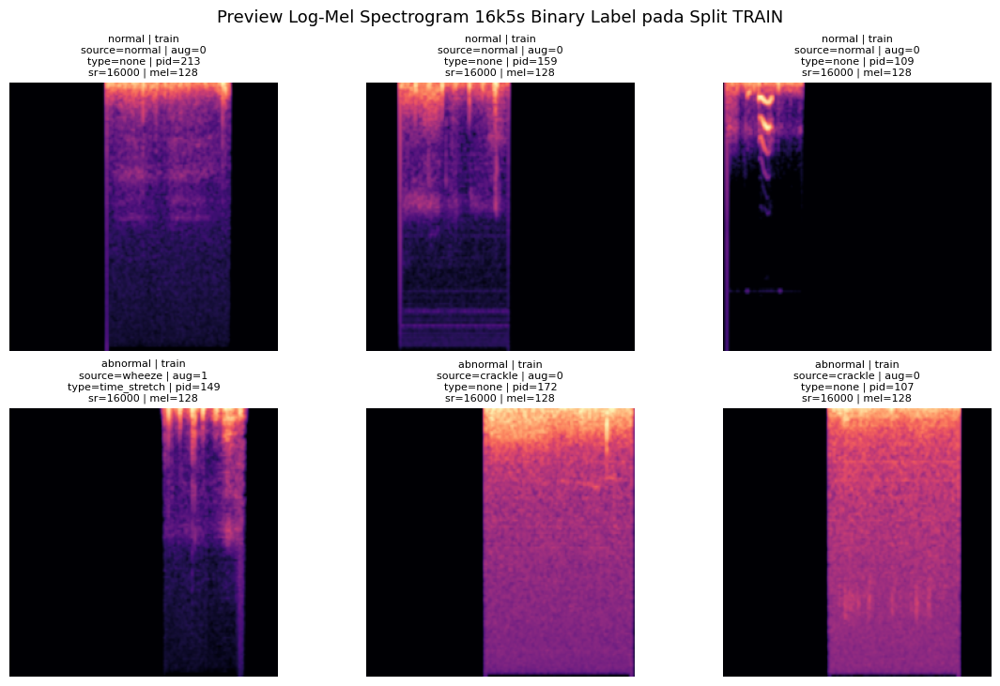

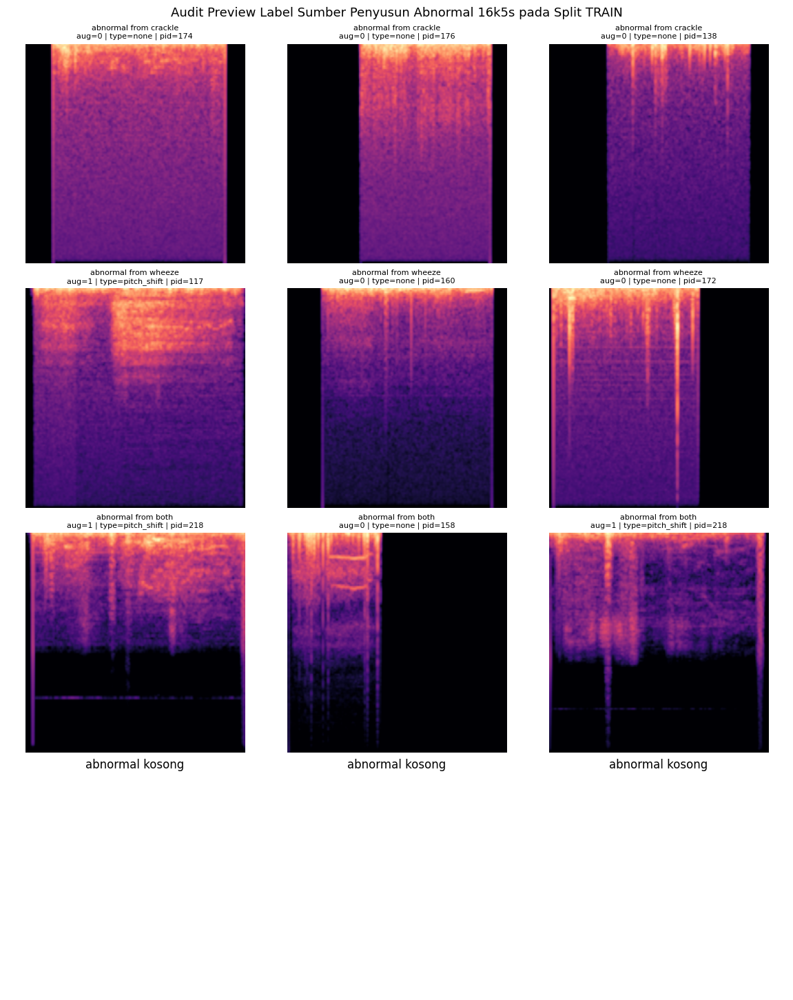

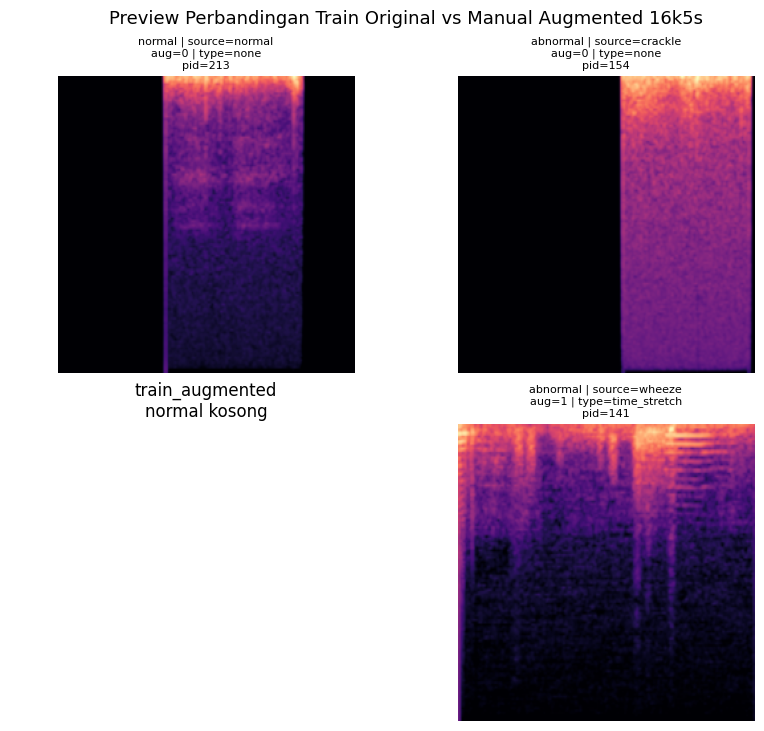

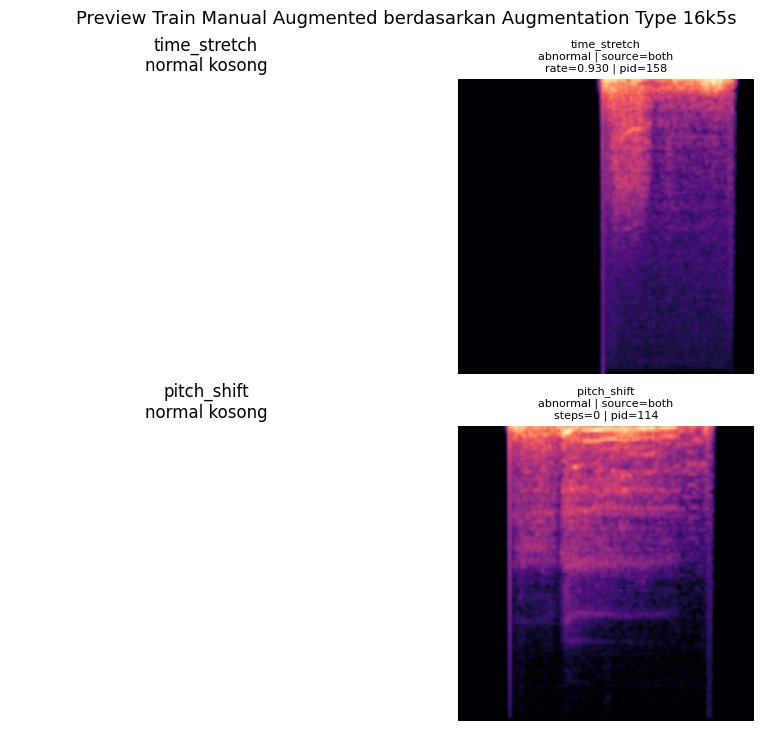


Contoh metadata image 16k5s:


,image_path,split,binary_label,sound,sound_4class,patient_id,is_augmented,augmentation_group,aug_type,time_stretch_rate,pitch_shift_steps,image_sr,image_n_fft,image_hop_length,image_n_mels,image_fmax,image_target_width,image_target_height
0,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,128,8000,224,224
1,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,128,8000,224,224
2,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,128,8000,224,224
3,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,128,8000,224,224
4,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,128,8000,224,224
5,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,128,8000,224,224
6,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,128,8000,224,224
7,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,128,8000,224,224
8,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,128,8000,224,224
9,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,128,8000,224,224



[OK] Preview citra Log-Mel 16k5s selesai.


In [ ]:
# ============================================================
# CELL: PREVIEW CITRA LOG-MEL SPECTROGRAM 16k5s
# Versi binary normal-abnormal
# ============================================================
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# 0. KONFIGURASI
# ============================================================

# Paksa path 16k5s.
# Jangan ambil dari globals lama karena bisa masih menunjuk ke metadata 44k.
META_OUT_DIR = Path("paper_binary_16k_outputs/06_metadata_images_16k5s")
META_IMG_PATH = META_OUT_DIR / "metadata_manual_binary_16k5s_images_magma.csv"

if not META_IMG_PATH.exists():
    raise FileNotFoundError(
        f"Metadata image 16k5s tidak ditemukan: {META_IMG_PATH}\n"
        "Jalankan cell Konversi Audio 16k5s ke Citra Log-Mel Spectrogram terlebih dahulu."
    )

SPLIT_TO_PREVIEW = "train"   # pilihan: "train", "val", "test"
N_PER_CLASS = 3
RANDOM_STATE = 42

TARGET_SR = 16000
TARGET_DURATION_SEC = 5.0
TARGET_LEN_SAMPLES = int(TARGET_SR * TARGET_DURATION_SEC)

BINARY_CLASSES = ["normal", "abnormal"]
SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both", "abnormal"]
ABNORMAL_SOURCE_CLASSES = ["crackle", "wheeze", "both", "abnormal"]

VALID_SPLITS = {"train", "val", "test"}
ALLOWED_AUG_TYPES = {"none", "time_stretch", "pitch_shift"}

EXPECTED_IMAGE_N_FFT = 2048
EXPECTED_IMAGE_HOP_LENGTH = 128
EXPECTED_IMAGE_N_MELS = 128
EXPECTED_IMAGE_FMAX = 8000
EXPECTED_IMAGE_SIZE = 224


# ============================================================
# 1. HELPER
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def normalize_image_metadata(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    required_cols = [
        "image_path",
        "split",
        "binary_label"
    ]

    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        raise AssertionError(
            f"Metadata image 16k5s tidak memiliki kolom wajib: {missing_cols}"
        )

    df["image_path"] = df["image_path"].astype(str).str.strip()
    df["split"] = df["split"].astype(str).str.strip().str.lower()
    df["binary_label"] = df["binary_label"].astype(str).str.strip().str.lower()

    if "sound" not in df.columns:
        if "sound_4class" in df.columns:
            df["sound"] = df["sound_4class"]
        else:
            df["sound"] = df["binary_label"]

    df["sound"] = df["sound"].astype(str).str.strip().str.lower()

    if "sound_4class" not in df.columns:
        df["sound_4class"] = df["sound"]

    df["sound_4class"] = df["sound_4class"].astype(str).str.strip().str.lower()

    if "patient_id" in df.columns:
        df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")

    if "is_augmented" not in df.columns:
        df["is_augmented"] = 0

    df["is_augmented"] = (
        pd.to_numeric(df["is_augmented"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    if "augmentation_group" not in df.columns:
        df["augmentation_group"] = np.where(
            df["is_augmented"] == 1,
            "manual_aug",
            "original"
        )

    df["augmentation_group"] = (
        df["augmentation_group"]
        .fillna("original")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    if "aug_type" not in df.columns:
        df["aug_type"] = "none"

    df["aug_type"] = (
        df["aug_type"]
        .fillna("none")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    if "image_ok" in df.columns:
        df["image_ok"] = (
            pd.to_numeric(df["image_ok"], errors="coerce")
            .fillna(0)
            .astype(int)
        )

    return df


def validate_basic_labels(df):
    unknown_split = sorted(set(df["split"].unique()) - VALID_SPLITS)

    if unknown_split:
        raise AssertionError(f"Split tidak valid ditemukan: {unknown_split}")

    unknown_binary = sorted(set(df["binary_label"].unique()) - set(BINARY_CLASSES))

    if unknown_binary:
        raise AssertionError(f"Binary label tidak valid ditemukan: {unknown_binary}")

    unknown_source = sorted(set(df["sound"].unique()) - set(SOURCE_CLASSES))

    if unknown_source:
        raise AssertionError(f"Label sumber sound tidak valid ditemukan: {unknown_source}")

    unknown_aug = sorted(set(df["aug_type"].unique()) - ALLOWED_AUG_TYPES)

    if unknown_aug:
        raise AssertionError(
            f"aug_type tidak valid ditemukan: {unknown_aug}. "
            "Untuk skenario ini hanya boleh none, time_stretch, dan pitch_shift."
        )


def check_optional_image_params(df_split):
    print("\nValidasi parameter image 16k5s jika tersedia:")

    if "image_sr" in df_split.columns:
        print("\nDistribusi image_sr:")
        print(df_split["image_sr"].value_counts(dropna=False).sort_index())

        bad_sr = df_split[
            pd.to_numeric(df_split["image_sr"], errors="coerce")
            .fillna(-1)
            .astype(int) != TARGET_SR
        ]

        if len(bad_sr) > 0:
            raise AssertionError(
                f"Ada {len(bad_sr)} image dengan image_sr bukan {TARGET_SR}."
            )

    if "image_expected_len_samples" in df_split.columns:
        print("\nDistribusi image_expected_len_samples:")
        print(df_split["image_expected_len_samples"].value_counts(dropna=False).sort_index())

        bad_len = df_split[
            pd.to_numeric(df_split["image_expected_len_samples"], errors="coerce")
            .fillna(-1)
            .astype(int) != TARGET_LEN_SAMPLES
        ]

        if len(bad_len) > 0:
            raise AssertionError(
                f"Ada {len(bad_len)} image dengan expected_len bukan {TARGET_LEN_SAMPLES}."
            )

    if "image_n_fft" in df_split.columns:
        print("\nDistribusi image_n_fft:")
        print(df_split["image_n_fft"].value_counts(dropna=False).sort_index())

    if "image_hop_length" in df_split.columns:
        print("\nDistribusi image_hop_length:")
        print(df_split["image_hop_length"].value_counts(dropna=False).sort_index())

    if "image_n_mels" in df_split.columns:
        print("\nDistribusi image_n_mels:")
        print(df_split["image_n_mels"].value_counts(dropna=False).sort_index())

    if "image_fmax" in df_split.columns:
        print("\nDistribusi image_fmax:")
        print(df_split["image_fmax"].value_counts(dropna=False).sort_index())

    if "image_target_width" in df_split.columns:
        print("\nDistribusi image_target_width:")
        print(df_split["image_target_width"].value_counts(dropna=False).sort_index())

    if "image_target_height" in df_split.columns:
        print("\nDistribusi image_target_height:")
        print(df_split["image_target_height"].value_counts(dropna=False).sort_index())


def load_rgb_image(path):
    return Image.open(path).convert("RGB")


def build_title(row, split_name, binary_cls=None, compact=False):
    if binary_cls is None:
        binary_cls = row["binary_label"]

    pid = row["patient_id"] if "patient_id" in row.index and pd.notna(row["patient_id"]) else "NA"
    source_label = row["sound"] if "sound" in row.index else "NA"

    is_aug = 0
    if "is_augmented" in row.index and pd.notna(row["is_augmented"]):
        is_aug = int(row["is_augmented"])

    aug_type = "none"
    if "aug_type" in row.index and pd.notna(row["aug_type"]):
        aug_type = str(row["aug_type"])

    image_sr = "NA"
    if "image_sr" in row.index and pd.notna(row["image_sr"]):
        image_sr = int(row["image_sr"])

    n_mels = "NA"
    if "image_n_mels" in row.index and pd.notna(row["image_n_mels"]):
        n_mels = int(row["image_n_mels"])

    if compact:
        return (
            f"{binary_cls} | source={source_label}\n"
            f"aug={is_aug} | type={aug_type}\n"
            f"pid={pid}"
        )

    return (
        f"{binary_cls} | {split_name}\n"
        f"source={source_label} | aug={is_aug}\n"
        f"type={aug_type} | pid={pid}\n"
        f"sr={image_sr} | mel={n_mels}"
    )


# ============================================================
# 2. LOAD METADATA IMAGE
# ============================================================

df = pd.read_csv(META_IMG_PATH).copy()
df = normalize_image_metadata(df)
validate_basic_labels(df)

if "image_ok" in df.columns:
    df = df[df["image_ok"] == 1].copy()

df = df[df["image_path"].notna()].copy()
df = df[df["image_path"].astype(str).str.len() > 0].copy()

df["image_exists"] = df["image_path"].apply(lambda p: os.path.exists(str(p)))

missing_images = int((~df["image_exists"]).sum())

if missing_images > 0:
    print(f"[WARNING] Ada {missing_images} file image yang tidak ditemukan.")
    print("Contoh file hilang:")
    print(df.loc[~df["image_exists"], "image_path"].head(10).to_string(index=False))

df = df[df["image_exists"]].copy().reset_index(drop=True)

df_split = df[df["split"] == SPLIT_TO_PREVIEW].copy().reset_index(drop=True)

if len(df_split) == 0:
    raise RuntimeError(
        f"Tidak ada image valid untuk split: {SPLIT_TO_PREVIEW}"
    )


# ============================================================
# 3. RINGKASAN METADATA
# ============================================================

print("=" * 90)
print("PREVIEW CITRA LOG-MEL SPECTROGRAM 16k5s")
print("=" * 90)
print("Metadata        :", META_IMG_PATH)
print("Split preview   :", SPLIT_TO_PREVIEW)
print("Total image OK  :", len(df))
print("Image OK split  :", len(df_split))
print("Target SR       :", TARGET_SR)
print("Target durasi   :", TARGET_DURATION_SEC)
print("Target samples  :", TARGET_LEN_SAMPLES)

check_optional_image_params(df_split)

print("\nDistribusi binary label pada split preview:")
binary_counts = (
    df_split["binary_label"]
    .value_counts()
    .reindex(BINARY_CLASSES, fill_value=0)
)
print(binary_counts)

print("\nAudit distribusi label sumber pada split preview:")
source_counts = (
    df_split["sound"]
    .value_counts()
    .reindex(SOURCE_CLASSES, fill_value=0)
)
print(source_counts)

print("\nDistribusi original vs augmented:")
print(df_split["is_augmented"].value_counts(dropna=False).sort_index())

print("\nDistribusi augmentation_group:")
print(df_split["augmentation_group"].value_counts(dropna=False))

print("\nDistribusi aug_type:")
print(df_split["aug_type"].value_counts(dropna=False))


# ============================================================
# 4. PREVIEW UTAMA BERDASARKAN BINARY_LABEL
# 1 baris = 1 kelas binary
# ============================================================

rows = len(BINARY_CLASSES)
cols = N_PER_CLASS

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(3.8 * cols, 3.6 * rows),
    constrained_layout=True
)

if rows == 1 and cols == 1:
    axes = np.array([[axes]])
elif rows == 1:
    axes = np.expand_dims(axes, axis=0)
elif cols == 1:
    axes = np.expand_dims(axes, axis=1)

for r, binary_cls in enumerate(BINARY_CLASSES):
    df_cls = df_split[df_split["binary_label"] == binary_cls].copy()

    if len(df_cls) == 0:
        for c in range(cols):
            ax = axes[r, c]
            ax.axis("off")
            ax.set_title(f"{binary_cls} kosong")
        continue

    samp = df_cls.sample(
        n=min(cols, len(df_cls)),
        random_state=RANDOM_STATE
    ).reset_index(drop=True)

    for c in range(cols):
        ax = axes[r, c]
        ax.axis("off")

        if c >= len(samp):
            ax.set_title(binary_cls)
            continue

        row = samp.iloc[c]
        img_path = str(row["image_path"])

        if not os.path.exists(img_path):
            ax.set_title(f"{binary_cls}\nfile hilang")
            continue

        img = load_rgb_image(img_path)
        ax.imshow(img)

        title = build_title(
            row=row,
            split_name=SPLIT_TO_PREVIEW,
            binary_cls=binary_cls,
            compact=False
        )

        ax.set_title(title, fontsize=8)

plt.suptitle(
    f"Preview Log-Mel Spectrogram 16k5s Binary Label pada Split {SPLIT_TO_PREVIEW.upper()}",
    fontsize=13
)

plt.show()


# ============================================================
# 5. PREVIEW AUDIT LABEL SUMBER PADA KELAS ABNORMAL
# ============================================================

df_abnormal = df_split[df_split["binary_label"] == "abnormal"].copy()

if len(df_abnormal) > 0:
    rows = len(ABNORMAL_SOURCE_CLASSES)
    cols = N_PER_CLASS

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(3.8 * cols, 3.6 * rows),
        constrained_layout=True
    )

    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = np.expand_dims(axes, axis=0)
    elif cols == 1:
        axes = np.expand_dims(axes, axis=1)

    for r, source_cls in enumerate(ABNORMAL_SOURCE_CLASSES):
        df_src = df_abnormal[df_abnormal["sound"] == source_cls].copy()

        if len(df_src) == 0:
            for c in range(cols):
                ax = axes[r, c]
                ax.axis("off")
                ax.set_title(f"{source_cls} kosong")
            continue

        samp = df_src.sample(
            n=min(cols, len(df_src)),
            random_state=RANDOM_STATE
        ).reset_index(drop=True)

        for c in range(cols):
            ax = axes[r, c]
            ax.axis("off")

            if c >= len(samp):
                ax.set_title(source_cls)
                continue

            row = samp.iloc[c]
            img_path = str(row["image_path"])

            if not os.path.exists(img_path):
                ax.set_title(f"{source_cls}\nfile hilang")
                continue

            img = load_rgb_image(img_path)
            ax.imshow(img)

            pid = row["patient_id"] if "patient_id" in row.index and pd.notna(row["patient_id"]) else "NA"

            is_aug = 0
            if "is_augmented" in row.index and pd.notna(row["is_augmented"]):
                is_aug = int(row["is_augmented"])

            aug_type = "none"
            if "aug_type" in row.index and pd.notna(row["aug_type"]):
                aug_type = str(row["aug_type"])

            title = (
                f"abnormal from {source_cls}\n"
                f"aug={is_aug} | type={aug_type} | pid={pid}"
            )

            ax.set_title(title, fontsize=8)

    plt.suptitle(
        f"Audit Preview Label Sumber Penyusun Abnormal 16k5s pada Split {SPLIT_TO_PREVIEW.upper()}",
        fontsize=13
    )

    plt.show()

else:
    print("\nTidak ada data abnormal pada split ini untuk audit preview.")


# ============================================================
# 6. PREVIEW KHUSUS TRAIN ORIGINAL VS AUGMENTED
# ============================================================

if SPLIT_TO_PREVIEW == "train":
    preview_groups = [
        ("train_original", df_split[df_split["is_augmented"] == 0].copy()),
        ("train_augmented", df_split[df_split["is_augmented"] == 1].copy()),
    ]

    rows = len(preview_groups)
    cols = len(BINARY_CLASSES)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(4.0 * cols, 3.6 * rows),
        constrained_layout=True
    )

    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = np.expand_dims(axes, axis=0)
    elif cols == 1:
        axes = np.expand_dims(axes, axis=1)

    for r, (group_name, group_df) in enumerate(preview_groups):
        for c, binary_cls in enumerate(BINARY_CLASSES):
            ax = axes[r, c]
            ax.axis("off")

            df_cell = group_df[group_df["binary_label"] == binary_cls].copy()

            if len(df_cell) == 0:
                ax.set_title(f"{group_name}\n{binary_cls} kosong")
                continue

            row = df_cell.sample(n=1, random_state=RANDOM_STATE).iloc[0]
            img_path = str(row["image_path"])

            if not os.path.exists(img_path):
                ax.set_title(f"{group_name}\n{binary_cls} file hilang")
                continue

            img = load_rgb_image(img_path)
            ax.imshow(img)

            ax.set_title(
                build_title(
                    row=row,
                    split_name=SPLIT_TO_PREVIEW,
                    binary_cls=binary_cls,
                    compact=True
                ),
                fontsize=8
            )

    plt.suptitle(
        "Preview Perbandingan Train Original vs Manual Augmented 16k5s",
        fontsize=13
    )

    plt.show()


# ============================================================
# 7. PREVIEW KHUSUS AUG_TYPE PADA TRAIN
# ============================================================

if SPLIT_TO_PREVIEW == "train" and (df_split["is_augmented"] == 1).any():
    df_aug = df_split[df_split["is_augmented"] == 1].copy()

    aug_types_present = [
        aug_type for aug_type in ["time_stretch", "pitch_shift"]
        if aug_type in set(df_aug["aug_type"])
    ]

    if len(aug_types_present) > 0:
        rows = len(aug_types_present)
        cols = len(BINARY_CLASSES)

        fig, axes = plt.subplots(
            rows,
            cols,
            figsize=(4.0 * cols, 3.6 * rows),
            constrained_layout=True
        )

        if rows == 1 and cols == 1:
            axes = np.array([[axes]])
        elif rows == 1:
            axes = np.expand_dims(axes, axis=0)
        elif cols == 1:
            axes = np.expand_dims(axes, axis=1)

        for r, aug_type in enumerate(aug_types_present):
            for c, binary_cls in enumerate(BINARY_CLASSES):
                ax = axes[r, c]
                ax.axis("off")

                df_cell = df_aug[
                    (df_aug["aug_type"] == aug_type) &
                    (df_aug["binary_label"] == binary_cls)
                ].copy()

                if len(df_cell) == 0:
                    ax.set_title(f"{aug_type}\n{binary_cls} kosong")
                    continue

                row = df_cell.sample(n=1, random_state=RANDOM_STATE).iloc[0]
                img_path = str(row["image_path"])

                if not os.path.exists(img_path):
                    ax.set_title(f"{aug_type}\n{binary_cls} file hilang")
                    continue

                img = load_rgb_image(img_path)
                ax.imshow(img)

                source_label = row["sound"] if "sound" in row.index else "NA"
                pid = row["patient_id"] if "patient_id" in row.index and pd.notna(row["patient_id"]) else "NA"

                extra = ""

                if aug_type == "time_stretch" and "time_stretch_rate" in row.index:
                    if pd.notna(row["time_stretch_rate"]):
                        extra = f"rate={float(row['time_stretch_rate']):.3f}"

                if aug_type == "pitch_shift" and "pitch_shift_steps" in row.index:
                    if pd.notna(row["pitch_shift_steps"]):
                        extra = f"steps={int(row['pitch_shift_steps'])}"

                ax.set_title(
                    f"{aug_type}\n{binary_cls} | source={source_label}\n"
                    f"{extra} | pid={pid}",
                    fontsize=8
                )

        plt.suptitle(
            "Preview Train Manual Augmented berdasarkan Augmentation Type 16k5s",
            fontsize=13
        )

        plt.show()


# ============================================================
# 8. TABEL CONTOH METADATA YANG DIPREVIEW
# ============================================================

preview_cols = [
    "image_path",
    "split",
    "binary_label",
    "sound",
    "sound_4class",
    "patient_id",
    "is_augmented",
    "augmentation_group",
    "aug_type",
    "time_stretch_rate",
    "pitch_shift_steps",
    "image_sr",
    "image_n_fft",
    "image_hop_length",
    "image_n_mels",
    "image_fmax",
    "image_target_width",
    "image_target_height",
]

preview_cols = [c for c in preview_cols if c in df_split.columns]

print("\nContoh metadata image 16k5s:")
safe_display(df_split[preview_cols].head(10))


# ============================================================
# 9. SIMPAN KE GLOBALS
# ============================================================

globals()["META_IMG_PATH"] = str(META_IMG_PATH)
globals()["preview_logmel_image_df_16k5s"] = df_split

print("\n[OK] Preview citra Log-Mel 16k5s selesai.")

# **Setup import HyperParameter**

In [ ]:
# ============================================================
# CELL: GLOBAL CONFIG DAN HYPERPARAMETER
# ViT-B/16 Binary Normal-Abnormal ICBHI 2017
# 16 kHz, 5 s, Log-Mel RGB 224 x 224
# ============================================================
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch

# ============================================================
# 1. PATH METADATA CITRA LOG-MEL 16k5s
# ============================================================

META_CSV = (
    "paper_binary_16k_outputs/"
    "06_metadata_images_16k5s/"
    "metadata_manual_binary_16k5s_images_magma.csv"
)

if not os.path.exists(META_CSV):
    raise FileNotFoundError(
        f"Metadata image 16k5s tidak ditemukan: {META_CSV}\n"
        "Jalankan cell Konversi Audio 16k5s ke Log-Mel Image terlebih dahulu."
    )


# ============================================================
# 3. LABEL
# ============================================================

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both", "abnormal"]
ABNORMAL_CLASSES = ["crackle", "wheeze", "both", "abnormal"]

CLASSES = ["normal", "abnormal"]
BINARY_CLASSES = CLASSES

label2id = {
    "normal": 0,
    "abnormal": 1,
}

id2label = {
    0: "normal",
    1: "abnormal",
}

NUM_CLASSES = len(CLASSES)

LABEL_COL = "binary_label"

POS_LABEL = "abnormal"
NEG_LABEL = "normal"

POS_LABEL_ID = label2id[POS_LABEL]
NEG_LABEL_ID = label2id[NEG_LABEL]


# ============================================================
# 4. KONFIGURASI PREPROCESSING DAN LOG-MEL 16k5s
# ============================================================

TARGET_SR = 16000
TARGET_DURATION_SEC = 5.0
TARGET_LEN_SAMPLES = int(TARGET_SR * TARGET_DURATION_SEC)

N_MELS = 128
FMIN = 50
FMAX = 8000

N_FFT = 2048
HOP_LENGTH = 128
WIN_LENGTH = 2048

IMAGE_SIZE = 224
IMAGE_COLORMAP = "magma"
IMAGE_MODE = "rgb"

PREPROCESSING_PIPELINE = (
    "vit_only_"
    "resample_16khz_bandpass_50_2000hz_rms_norm_minus15dbfs_"
    "sequential_5s_chunking_logmel_magma_224"
)

MODEL_FAMILY = "ViT-only"
MODEL_NAME = "ViT-B/16"
MODEL_CLAIM = (
    "ViT-only adaptation using Log-Mel spectrogram images, "
    "without RAN Attention-92 and without RAN-ViT feature fusion."
)

# ============================================================
# 5. HYPERPARAMETER TRAINING
# ============================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = True
BATCH_SIZE = 16
GRAD_ACCUM_STEPS = 2
EFFECTIVE_BATCH_SIZE = (BATCH_SIZE * GRAD_ACCUM_STEPS)

# Maksimum epoch dan early stopping.
NUM_EPOCHS = 50
PATIENCE = 8
EARLY_STOP_MIN_DELTA = 5e-4
NUM_WORKERS = 2

# Seed utama model dan seed DataLoader/sampler.
MODEL_SEED = 42

# Partial fine-tuning: buka tiga encoder block terakhir dan classification head.
UNFREEZE_LAST_N_BLOCKS = 4
OPTIMIZER_NAME = "AdamW"

# Learning rate terbaik skenario augmentasi manual pada split 80:10:10.
LR_BACKBONE = 1.0e-6
LR_HEAD = 1.5e-5
LEARNING_RATE = LR_HEAD
WEIGHT_DECAY = 5e-3

# LLRD dinonaktifkan agar seluruh layer yang dibuka memakai learning rate yang sama.
USE_LAYER_WISE_LR_DECAY = True
LAYER_LR_DECAY = 0.70
LLRD_DECAY = LAYER_LR_DECAY

# Warmup + cosine. Setup Model harus mendukung SequentialLR.
SCHEDULER_NAME = "CosineAnnealingLR"
WARMUP_EPOCHS = 0
WARMUP_START_FACTOR = 0.10
ETA_MIN = 1e-7

HEAD_DROPOUT = 0.15
LABEL_SMOOTHING = 0.05
MAX_GRAD_NORM = 0.5

# Weighted Cross-Entropy dengan bobot manual seimbang sebagai baseline.
LOSS_NAME = "weighted_ce"
USE_CLASS_WEIGHT = True
MANUAL_CLASS_WEIGHT = True
CLASS_WEIGHT_METHOD = "manual"

# Urutan bobot wajib mengikuti CLASSES = ["normal", "abnormal"].
NORMAL_WEIGHT = 1.00
ABNORMAL_WEIGHT = 1.00

FOCAL_ALPHA_NORMAL = 0.45
FOCAL_ALPHA_ABNORMAL = 0.55
FOCAL_GAMMA = 2.0

# Patient-balanced sampling untuk mengurangi dominasi pasien dengan banyak segmen.
# Implementasi tetap memakai torch.utils.data.WeightedRandomSampler, tetapi bobot
# sampel dihitung dari frekuensi patient_id, bukan frekuensi kelas.
USE_PATIENT_BALANCED_SAMPLER = False
USE_WEIGHTED_RANDOM_SAMPLER = False

SAMPLER_MODE = "standard_shuffle"
PATIENT_WEIGHT_POWER = 0.5
BALANCE_CLASSES_IN_PATIENT_SAMPLER = True
SAMPLER_REPLACEMENT = True

SAMPLER_SEED = 42

# DataLoader tidak boleh shuffle=True ketika sampler aktif.
SHUFFLE_TRAIN = True

if not (0.0 < float(PATIENT_WEIGHT_POWER) <= 1.0):
    raise ValueError(
        "PATIENT_WEIGHT_POWER harus berada pada rentang (0, 1]. "
        f"Saat ini={PATIENT_WEIGHT_POWER}."
    )

if USE_PATIENT_BALANCED_SAMPLER:
    if not USE_WEIGHTED_RANDOM_SAMPLER:
        raise AssertionError(
            "USE_PATIENT_BALANCED_SAMPLER=True membutuhkan "
            "USE_WEIGHTED_RANDOM_SAMPLER=True."
        )

    if SHUFFLE_TRAIN:
        raise AssertionError(
            "SHUFFLE_TRAIN harus False ketika patient-balanced sampler aktif."
        )

    if SAMPLER_MODE != "patient_balanced_sqrt":
        raise AssertionError(
            "SAMPLER_MODE harus 'patient_balanced_sqrt' untuk V4. "
            f"Saat ini={SAMPLER_MODE!r}."
        )


# ============================================================
# 6. SPEC AUGMENT CONFIG
# ============================================================
USE_SPEC_AUGMENT = False
SPEC_AUGMENT_P = 0.30
SPEC_TIME_MASK_MAX = 12
SPEC_FREQ_MASK_MAX = 8
SPEC_N_TIME_MASKS = 1
SPEC_N_FREQ_MASKS = 1

# ============================================================
# 7. CHECKPOINT, EARLY STOPPING, DAN THRESHOLD
# ============================================================
# Checkpoint dipilih dari validation set berdasarkan maximin score:
# maximin_score = min(sensitivity_abnormal, specificity_normal).
# Early stopping tetap memantau validation loss agar training stabil.

CHECKPOINT_MONITOR = "val_maximin_score"
EARLY_STOPPING_MONITOR = "val_loss"
CHECKPOINT_MODE = "max"
EARLY_STOPPING_MODE = "min"

SAVE_BEST_BY = "maximum_validation_maximin_score"
VALIDATE_EVERY_EPOCH = True

DEFAULT_TEST_THRESHOLD = 0.50
ENABLE_THRESHOLD_TUNING = True
PRIMARY_THRESHOLD_METHOD = "maximin"
THRESHOLD_SELECTION_METRIC = "validation_maximin_sensitivity_specificity"

THRESHOLD_MIN = 0.10
THRESHOLD_MAX = 0.90
THRESHOLD_STEP = 0.001

# Target publikasi/eksperimen. Target ini dievaluasi pada validation set;
# test set tidak digunakan untuk memilih checkpoint atau threshold.
TARGET_SENSITIVITY_ABNORMAL = 0.80
TARGET_SPECIFICITY_NORMAL = 0.80

# Batas keamanan tambahan. Bukan pengganti target utama 0.80/0.80.
MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT = 0.50
MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD = 0.50
MIN_SP_FINAL = MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD
SPECIFICITY_SAFE_MIN = MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD


# ============================================================
# 8. IDENTITAS SKENARIO DAN PATH OUTPUT DINAMIS
# ============================================================

def value_tag(value):
    """Mengubah angka menjadi tag aman untuk nama folder/file."""
    if isinstance(value, (float, np.floating)):
        text = f"{float(value):.6g}"
    else:
        text = str(value)

    return (
        text
        .replace("+", "p")
        .replace("-", "m")
        .replace(".", "p")
        .replace(" ", "")
    )


loss_tag = {
    "ce": "ce",
    "weighted_ce": "wce",
    "focal": "focal",
}.get(LOSS_NAME, LOSS_NAME)

if USE_PATIENT_BALANCED_SAMPLER:
    sampler_tag = (
        f"pbsqrt{value_tag(PATIENT_WEIGHT_POWER)}_"
        f"cbal{int(BALANCE_CLASSES_IN_PATIENT_SAMPLER)}"
    )
else:
    sampler_tag = "shuffle"

SCENARIO_NAME = (
    "vit_binary_sr16k5s_logmel128_img224_manualaug_"
    f"unfreeze{UNFREEZE_LAST_N_BLOCKS}_"
    f"{loss_tag}_"
    f"wd{value_tag(WEIGHT_DECAY)}_"
    f"lrbb{value_tag(LR_BACKBONE)}_"
    f"lrh{value_tag(LR_HEAD)}_"
    f"cwN{value_tag(NORMAL_WEIGHT)}_"
    f"cwA{value_tag(ABNORMAL_WEIGHT)}_"
    f"{sampler_tag}_"
    f"bs{BATCH_SIZE}_pat{PATIENCE}_"
    f"maximin80_80_seed{MODEL_SEED}"
)

SAVE_DIR = Path("checkpoints_vit") / SCENARIO_NAME
RESULT_DIR = Path("results_vit") / SCENARIO_NAME

SAVE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = SAVE_DIR / f"{SCENARIO_NAME}_best_val_maximin_score.pth"
LAST_MODEL_PATH = SAVE_DIR / f"{SCENARIO_NAME}_last.pth"
HISTORY_CSV_PATH = SAVE_DIR / f"{SCENARIO_NAME}_history.csv"
LEARNING_CURVE_PATH = SAVE_DIR / f"{SCENARIO_NAME}_learning_curve.png"
RUN_CONFIG_PATH = SAVE_DIR / f"{SCENARIO_NAME}_run_config.csv"

if CHECKPOINT_MONITOR != "val_maximin_score":
    raise AssertionError(
        "CHECKPOINT_MONITOR harus 'val_maximin_score' untuk eksperimen maximin. "
        f"Saat ini: {CHECKPOINT_MONITOR}"
    )

if CHECKPOINT_MODE != "max":
    raise AssertionError(
        f"CHECKPOINT_MODE harus 'max'. Saat ini: {CHECKPOINT_MODE}"
    )

if PRIMARY_THRESHOLD_METHOD != "maximin":
    raise AssertionError(
        "PRIMARY_THRESHOLD_METHOD harus 'maximin'. "
        f"Saat ini: {PRIMARY_THRESHOLD_METHOD}"
    )

for target_name, target_value in {
    "TARGET_SENSITIVITY_ABNORMAL": TARGET_SENSITIVITY_ABNORMAL,
    "TARGET_SPECIFICITY_NORMAL": TARGET_SPECIFICITY_NORMAL,
}.items():
    if not (0.0 <= float(target_value) <= 1.0):
        raise ValueError(f"{target_name} harus berada pada [0, 1]. Saat ini: {target_value}")


# ============================================================
# 9. HELPER
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def to_binary_label(label):
    label = str(label).strip().lower()

    if label == "normal":
        return "normal"

    if label in ABNORMAL_CLASSES:
        return "abnormal"

    raise ValueError(f"Label tidak dikenal: {label}")


def normalize_metadata_for_config(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    required_min_cols = ["image_path", "split", LABEL_COL]
    missing_min_cols = [c for c in required_min_cols if c not in df.columns]

    if missing_min_cols:
        raise ValueError(f"Metadata image kehilangan kolom wajib: {missing_min_cols}")

    if "sound" not in df.columns:
        if "sound_4class" in df.columns:
            df["sound"] = df["sound_4class"]
        else:
            df["sound"] = df[LABEL_COL]

    df["image_path"] = df["image_path"].astype(str).str.strip()
    df["split"] = df["split"].astype(str).str.strip().str.lower()
    df["sound"] = df["sound"].astype(str).str.strip().str.lower()
    df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.lower()

    if "sound_4class" not in df.columns:
        df["sound_4class"] = df["sound"]
    else:
        df["sound_4class"] = df["sound_4class"].astype(str).str.strip().str.lower()

    if "image_ok" not in df.columns:
        df["image_ok"] = 1
    else:
        df["image_ok"] = (
            pd.to_numeric(df["image_ok"], errors="coerce")
            .fillna(0)
            .astype(int)
        )

    if "is_augmented" not in df.columns:
        df["is_augmented"] = 0
    else:
        df["is_augmented"] = (
            pd.to_numeric(df["is_augmented"], errors="coerce")
            .fillna(0)
            .astype(int)
        )

    if "augmentation_group" not in df.columns:
        df["augmentation_group"] = np.where(
            df["is_augmented"] == 1,
            "manual_aug",
            "original",
        )
    else:
        df["augmentation_group"] = (
            df["augmentation_group"]
            .fillna("original")
            .astype(str)
            .str.strip()
            .str.lower()
        )

    if "aug_type" not in df.columns:
        df["aug_type"] = "none"
    else:
        df["aug_type"] = (
            df["aug_type"]
            .fillna("none")
            .astype(str)
            .str.strip()
            .str.lower()
        )

    if "patient_id" in df.columns:
        df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")

    return df


# ============================================================
# 10. VALIDASI METADATA RINGKAS
# ============================================================

df_check = pd.read_csv(META_CSV, low_memory=False).copy()
df_check = normalize_metadata_for_config(df_check)

required_cols = [
    "image_path",
    "split",
    "sound",
    LABEL_COL,
    "image_ok",
]

if USE_PATIENT_BALANCED_SAMPLER:
    required_cols.append("patient_id")

missing_cols = [c for c in required_cols if c not in df_check.columns]

if missing_cols:
    raise ValueError(f"Metadata image kehilangan kolom wajib: {missing_cols}")

df_check = df_check[df_check["image_ok"] == 1].copy().reset_index(drop=True)

if len(df_check) == 0:
    raise RuntimeError("Metadata image kosong setelah filter image_ok == 1.")

unknown_source_labels = sorted(set(df_check["sound"].unique()) - set(SOURCE_CLASSES))
if unknown_source_labels:
    raise ValueError(f"Ada label sumber tidak valid pada metadata: {unknown_source_labels}")

unknown_binary_labels = sorted(set(df_check[LABEL_COL].unique()) - set(CLASSES))
if unknown_binary_labels:
    raise ValueError(f"Ada binary_label tidak valid pada metadata: {unknown_binary_labels}")

valid_splits = {"train", "val", "test"}
unknown_splits = sorted(set(df_check["split"].unique()) - valid_splits)
if unknown_splits:
    raise ValueError(f"Ada split tidak valid pada metadata: {unknown_splits}")

expected_binary = df_check["sound"].apply(to_binary_label)
mismatch_mask = expected_binary != df_check[LABEL_COL]

if mismatch_mask.any():
    safe_display(
        df_check.loc[
            mismatch_mask,
            ["image_path", "split", "sound", LABEL_COL],
        ].head(10)
    )
    raise ValueError(
        f"Ada {int(mismatch_mask.sum())} baris binary_label tidak konsisten dengan sound."
    )

df_check["image_exists"] = df_check["image_path"].astype(str).apply(os.path.exists)
missing_images = int((~df_check["image_exists"]).sum())

if missing_images > 0:
    print(f"[WARNING] Ada {missing_images} image_path yang tidak ditemukan.")
    print(
        df_check.loc[~df_check["image_exists"], "image_path"]
        .head(10)
        .to_string(index=False)
    )
    raise FileNotFoundError(f"Ada {missing_images} file citra yang tidak ditemukan.")

if USE_PATIENT_BALANCED_SAMPLER:
    patient_ids = pd.to_numeric(
        df_check["patient_id"],
        errors="coerce",
    )

    if patient_ids.isna().any():
        raise ValueError(
            "patient_id wajib tersedia dan numerik untuk patient-balanced sampler. "
            f"Ditemukan {int(patient_ids.isna().sum())} nilai kosong/non-numerik."
        )

    df_check["patient_id"] = patient_ids.astype(int)

    train_patients = set(
        df_check.loc[df_check["split"] == "train", "patient_id"].tolist()
    )
    val_patients = set(
        df_check.loc[df_check["split"] == "val", "patient_id"].tolist()
    )
    test_patients = set(
        df_check.loc[df_check["split"] == "test", "patient_id"].tolist()
    )

    overlaps = {
        "train_val": sorted(train_patients & val_patients),
        "train_test": sorted(train_patients & test_patients),
        "val_test": sorted(val_patients & test_patients),
    }
    overlapping_patients = {
        name: ids
        for name, ids in overlaps.items()
        if ids
    }

    if overlapping_patients:
        raise AssertionError(
            "Split wajib patient-wise tanpa patient overlap. "
            f"Ditemukan overlap={overlapping_patients}."
        )


# ============================================================
# 11. VALIDASI PARAMETER IMAGE JIKA ADA
# ============================================================

numeric_expected = {
    "image_sr": TARGET_SR,
    "image_expected_len_samples": TARGET_LEN_SAMPLES,
    "image_n_mels": N_MELS,
    "image_n_fft": N_FFT,
    "image_hop_length": HOP_LENGTH,
    "image_win_length": WIN_LENGTH,
    "image_fmax": FMAX,
    "image_target_width": IMAGE_SIZE,
    "image_target_height": IMAGE_SIZE,
}

for col, expected_value in numeric_expected.items():
    if col in df_check.columns:
        values = pd.to_numeric(df_check[col], errors="coerce")
        bad_mask = values.fillna(-999999).astype(float) != float(expected_value)

        if bad_mask.any():
            safe_display(
                df_check.loc[
                    bad_mask,
                    ["image_path", "split", "sound", LABEL_COL, col],
                ].head(10)
            )
            raise AssertionError(
                f"Ada {int(bad_mask.sum())} baris dengan {col} bukan {expected_value}."
            )

if "image_fmin" in df_check.columns:
    values = pd.to_numeric(df_check["image_fmin"], errors="coerce")
    bad_mask = values.fillna(-999999).astype(float) != float(FMIN)

    if bad_mask.any():
        raise AssertionError(
            f"Ada {int(bad_mask.sum())} baris dengan image_fmin bukan {FMIN}."
        )

if "image_expected_sec" in df_check.columns:
    values = pd.to_numeric(df_check["image_expected_sec"], errors="coerce")
    bad_mask = np.abs(values.fillna(-999999) - TARGET_DURATION_SEC) > 1e-6

    if bad_mask.any():
        raise AssertionError(
            f"Ada {int(bad_mask.sum())} baris dengan image_expected_sec bukan {TARGET_DURATION_SEC}."
        )


# ============================================================
# 12. VALIDASI VAL/TEST TIDAK DIAUGMENTASI
# ============================================================

non_train_aug = df_check[
    (df_check["split"].isin(["val", "test"])) &
    (df_check["is_augmented"] != 0)
]

if len(non_train_aug) > 0:
    raise AssertionError(
        f"Ada {len(non_train_aug)} data val/test yang terdeteksi augmentasi. "
        "Val dan test tidak boleh diaugmentasi."
    )


# ============================================================
# 13. CLASS WEIGHT AUDIT DAN RUNTIME CONFIG
# ============================================================

train_check = df_check[df_check["split"] == "train"].copy()

if len(train_check) == 0:
    raise RuntimeError("Tidak ada data train pada metadata image 16k5s.")

train_class_counts = (
    train_check[LABEL_COL]
    .value_counts()
    .reindex(CLASSES, fill_value=0)
    .astype(int)
)

if (train_class_counts <= 0).any():
    raise ValueError(
        "Ada kelas training dengan jumlah 0.\n"
        f"Distribusi train: {train_class_counts.to_dict()}"
    )

total_train = int(train_class_counts.sum())

auto_class_weights = (
    total_train / (NUM_CLASSES * train_class_counts.astype(float))
)

AUTO_CLASS_WEIGHTS = {
    cls: float(auto_class_weights.loc[cls])
    for cls in CLASSES
}

if LOSS_NAME == "weighted_ce" and USE_CLASS_WEIGHT:
    manual_method_active = (
        MANUAL_CLASS_WEIGHT
        or CLASS_WEIGHT_METHOD in {"manual", "manual_class_weight", "fixed_manual"}
    )

    if manual_method_active:
        CLASS_WEIGHTS_LIST = [
            float(NORMAL_WEIGHT),
            float(ABNORMAL_WEIGHT),
        ]
        CLASS_WEIGHT_METHOD_EFFECTIVE = "manual"
    else:
        CLASS_WEIGHTS_LIST = [
            AUTO_CLASS_WEIGHTS[cls]
            for cls in CLASSES
        ]
        CLASS_WEIGHT_METHOD_EFFECTIVE = "balanced_from_train_distribution"

    CLASS_WEIGHTS_TENSOR = torch.tensor(
        CLASS_WEIGHTS_LIST,
        dtype=torch.float32,
        device=DEVICE,
    )
else:
    CLASS_WEIGHTS_LIST = None
    CLASS_WEIGHTS_TENSOR = None
    CLASS_WEIGHT_METHOD_EFFECTIVE = "none"

if CLASS_WEIGHT_METHOD_EFFECTIVE == "manual":
    expected_manual_weights = [float(NORMAL_WEIGHT), float(ABNORMAL_WEIGHT)]
    if not np.allclose(CLASS_WEIGHTS_LIST, expected_manual_weights, rtol=1e-6, atol=1e-8):
        raise AssertionError(
            "Manual class weights tidak sesuai konfigurasi. "
            f"Expected={expected_manual_weights}, actual={CLASS_WEIGHTS_LIST}"
        )


# ============================================================
# 14. DISTRIBUSI DATA UNTUK AUDIT
# ============================================================

split_dist_binary = (
    df_check
    .groupby(["split", LABEL_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["train", "val", "test"], columns=CLASSES, fill_value=0)
)

split_dist_source = (
    df_check
    .groupby(["split", "sound"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["train", "val", "test"], columns=SOURCE_CLASSES, fill_value=0)
)

train_aug_dist = (
    df_check[df_check["split"] == "train"]
    .groupby(["augmentation_group", LABEL_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["original", "manual_aug"], columns=CLASSES, fill_value=0)
)

train_aug_type_dist = (
    df_check[df_check["split"] == "train"]
    .groupby(["aug_type", LABEL_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=CLASSES, fill_value=0)
)


# ============================================================
# 15. SIMPAN KONFIGURASI RUN
# ============================================================

run_config = {
    "meta_csv": META_CSV,
    "scenario_name": SCENARIO_NAME,
    "model_seed": MODEL_SEED,
    "sampler_seed": SAMPLER_SEED,

    "model_family": MODEL_FAMILY,
    "model_name": MODEL_NAME,
    "model_claim": MODEL_CLAIM,

    "preprocessing_pipeline": PREPROCESSING_PIPELINE,
    "target_sr": TARGET_SR,
    "target_duration_sec": TARGET_DURATION_SEC,
    "target_len_samples": TARGET_LEN_SAMPLES,

    "n_mels": N_MELS,
    "fmin": FMIN,
    "fmax": FMAX,
    "n_fft": N_FFT,
    "hop_length": HOP_LENGTH,
    "win_length": WIN_LENGTH,
    "image_size": IMAGE_SIZE,
    "image_colormap": IMAGE_COLORMAP,
    "image_mode": IMAGE_MODE,

    "num_classes": NUM_CLASSES,
    "classes": ",".join(CLASSES),
    "label_col": LABEL_COL,
    "positive_label": POS_LABEL,
    "negative_label": NEG_LABEL,

    "optimizer": OPTIMIZER_NAME,
    "learning_rate": LEARNING_RATE,
    "lr_backbone": LR_BACKBONE,
    "lr_head": LR_HEAD,
    "weight_decay": WEIGHT_DECAY,

    "use_layer_wise_lr_decay": USE_LAYER_WISE_LR_DECAY,
    "layer_lr_decay": LAYER_LR_DECAY,

    "scheduler": SCHEDULER_NAME,
    "warmup_epochs": WARMUP_EPOCHS,
    "warmup_start_factor": WARMUP_START_FACTOR,
    "eta_min": ETA_MIN,

    "num_epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "patience": PATIENCE,
    "early_stop_min_delta": EARLY_STOP_MIN_DELTA,

    "unfreeze_last_n_blocks": UNFREEZE_LAST_N_BLOCKS,
    "head_dropout": HEAD_DROPOUT,
    "label_smoothing": LABEL_SMOOTHING,
    "max_grad_norm": MAX_GRAD_NORM,

    "loss_name": LOSS_NAME,
    "use_class_weight": USE_CLASS_WEIGHT,
    "manual_class_weight": MANUAL_CLASS_WEIGHT,
    "class_weight_method": CLASS_WEIGHT_METHOD,
    "class_weight_method_effective": CLASS_WEIGHT_METHOD_EFFECTIVE,
    "normal_weight": NORMAL_WEIGHT,
    "abnormal_weight": ABNORMAL_WEIGHT,
    "focal_alpha_normal": FOCAL_ALPHA_NORMAL,
    "focal_alpha_abnormal": FOCAL_ALPHA_ABNORMAL,
    "focal_gamma": FOCAL_GAMMA,

    "use_spec_augment": USE_SPEC_AUGMENT,
    "spec_augment_p": SPEC_AUGMENT_P,
    "spec_time_mask_max": SPEC_TIME_MASK_MAX,
    "spec_freq_mask_max": SPEC_FREQ_MASK_MAX,
    "spec_n_time_masks": SPEC_N_TIME_MASKS,
    "spec_n_freq_masks": SPEC_N_FREQ_MASKS,

    "shuffle_train": SHUFFLE_TRAIN,
    "use_patient_balanced_sampler": USE_PATIENT_BALANCED_SAMPLER,
    "use_weighted_random_sampler": USE_WEIGHTED_RANDOM_SAMPLER,
    "sampler_mode": SAMPLER_MODE,
    "patient_weight_power": PATIENT_WEIGHT_POWER,
    "balance_classes_in_patient_sampler": BALANCE_CLASSES_IN_PATIENT_SAMPLER,
    "sampler_replacement": SAMPLER_REPLACEMENT,
    "validate_every_epoch": VALIDATE_EVERY_EPOCH,

    "early_stopping_monitor": EARLY_STOPPING_MONITOR,
    "early_stopping_mode": EARLY_STOPPING_MODE,
    "checkpoint_monitor": CHECKPOINT_MONITOR,
    "checkpoint_mode": CHECKPOINT_MODE,
    "save_best_by": SAVE_BEST_BY,

    "default_test_threshold": DEFAULT_TEST_THRESHOLD,
    "enable_threshold_tuning": ENABLE_THRESHOLD_TUNING,
    "primary_threshold_method": PRIMARY_THRESHOLD_METHOD,
    "threshold_selection_metric": THRESHOLD_SELECTION_METRIC,
    "threshold_min": THRESHOLD_MIN,
    "threshold_max": THRESHOLD_MAX,
    "threshold_step": THRESHOLD_STEP,
    "target_sensitivity_abnormal": TARGET_SENSITIVITY_ABNORMAL,
    "target_specificity_normal": TARGET_SPECIFICITY_NORMAL,
    "min_specificity_normal_for_checkpoint": MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT,
    "min_specificity_normal_for_threshold": MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD,
    "min_sp_final": MIN_SP_FINAL,
    "specificity_safe_min": SPECIFICITY_SAFE_MIN,

    "best_model_path": str(BEST_MODEL_PATH),
    "last_model_path": str(LAST_MODEL_PATH),
    "history_csv_path": str(HISTORY_CSV_PATH),
    "learning_curve_path": str(LEARNING_CURVE_PATH),
}

run_config_df = pd.DataFrame([run_config])
run_config_df.to_csv(RUN_CONFIG_PATH, index=False)

# ============================================================
# 16. OUTPUT
# ============================================================

print("=" * 90)
print("GLOBAL CONFIG ViT-ONLY BINARY NORMAL-ABNORMAL 16k5s")
print("=" * 90)

print("META_CSV                  :", META_CSV)
print("SCENARIO_NAME             :", SCENARIO_NAME)
print("MODEL_FAMILY              :", MODEL_FAMILY)
print("MODEL_NAME                :", MODEL_NAME)

print("\nPath:")
print("SAVE_DIR                  :", SAVE_DIR)
print("RESULT_DIR                :", RESULT_DIR)
print("BEST_MODEL_PATH           :", BEST_MODEL_PATH)
print("LAST_MODEL_PATH           :", LAST_MODEL_PATH)
print("HISTORY_CSV_PATH          :", HISTORY_CSV_PATH)
print("LEARNING_CURVE_PATH       :", LEARNING_CURVE_PATH)
print("RUN_CONFIG_PATH           :", RUN_CONFIG_PATH)

print("\nTraining:")
print("DEVICE                    :", DEVICE)
print("AMP_ENABLED               :", AMP_ENABLED)
print("BATCH_SIZE                :", BATCH_SIZE)
print("NUM_EPOCHS                :", NUM_EPOCHS)
print("PATIENCE                  :", PATIENCE)
print("UNFREEZE_LAST_N_BLOCKS    :", UNFREEZE_LAST_N_BLOCKS)
print("LEARNING_RATE             :", LEARNING_RATE)
print("LR_BACKBONE               :", LR_BACKBONE)
print("LR_HEAD                   :", LR_HEAD)
print("WEIGHT_DECAY              :", WEIGHT_DECAY)
print("USE_LLRD                  :", USE_LAYER_WISE_LR_DECAY)
print("LAYER_LR_DECAY            :", LAYER_LR_DECAY)
print("SCHEDULER_NAME            :", SCHEDULER_NAME)
print("WARMUP_EPOCHS             :", WARMUP_EPOCHS)
print("ETA_MIN                   :", ETA_MIN)
print("HEAD_DROPOUT              :", HEAD_DROPOUT)
print("LABEL_SMOOTHING           :", LABEL_SMOOTHING)
print("LOSS_NAME                 :", LOSS_NAME)
print("USE_CLASS_WEIGHT          :", USE_CLASS_WEIGHT)
print("MANUAL_CLASS_WEIGHT      :", MANUAL_CLASS_WEIGHT)
print("CLASS_WEIGHT_METHOD       :", CLASS_WEIGHT_METHOD)
print("CLASS_WEIGHT_EFFECTIVE    :", CLASS_WEIGHT_METHOD_EFFECTIVE)
print("CLASS_WEIGHTS_LIST        :", CLASS_WEIGHTS_LIST)

print("\nSampler:")
print("USE_PATIENT_BALANCED      :", USE_PATIENT_BALANCED_SAMPLER)
print("USE_WEIGHTED_RANDOM       :", USE_WEIGHTED_RANDOM_SAMPLER)
print("SAMPLER_MODE              :", SAMPLER_MODE)
print("PATIENT_WEIGHT_POWER      :", PATIENT_WEIGHT_POWER)
print("BALANCE_CLASSES_IN_SAMPLER:", BALANCE_CLASSES_IN_PATIENT_SAMPLER)
print("SAMPLER_REPLACEMENT       :", SAMPLER_REPLACEMENT)
print("SHUFFLE_TRAIN             :", SHUFFLE_TRAIN)
print("SAMPLER_SEED              :", SAMPLER_SEED)

print("\nSpecAugment:")
print("USE_SPEC_AUGMENT          :", USE_SPEC_AUGMENT)
print("SPEC_AUGMENT_P            :", SPEC_AUGMENT_P)
print("SPEC_TIME_MASK_MAX        :", SPEC_TIME_MASK_MAX)
print("SPEC_FREQ_MASK_MAX        :", SPEC_FREQ_MASK_MAX)

print("\nCheckpoint:")
print("CHECKPOINT_MONITOR        :", CHECKPOINT_MONITOR)
print("EARLY_STOPPING_MONITOR    :", EARLY_STOPPING_MONITOR)
print("EARLY_STOPPING_MODE       :", EARLY_STOPPING_MODE)
print("CHECKPOINT_MODE           :", CHECKPOINT_MODE)
print("SAVE_BEST_BY              :", SAVE_BEST_BY)

print("\nThreshold:")
print("DEFAULT_TEST_THRESHOLD    :", DEFAULT_TEST_THRESHOLD)
print("ENABLE_THRESHOLD_TUNING   :", ENABLE_THRESHOLD_TUNING)
print("PRIMARY_THRESHOLD_METHOD :", PRIMARY_THRESHOLD_METHOD)
print("THRESHOLD_SELECTION_METRIC:", THRESHOLD_SELECTION_METRIC)
print("TARGET_SENSITIVITY_ABN    :", TARGET_SENSITIVITY_ABNORMAL)
print("TARGET_SPECIFICITY_NORMAL :", TARGET_SPECIFICITY_NORMAL)
print("MIN_SP_CHECKPOINT         :", MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT)
print("MIN_SP_THRESHOLD          :", MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD)

print("\nDistribusi split x binary label:")
safe_display(split_dist_binary)

print("\nDistribusi split x source label:")
safe_display(split_dist_source)

print("\nDistribusi train augmentation_group x binary label:")
safe_display(train_aug_dist)

print("\nDistribusi train aug_type x binary label:")
safe_display(train_aug_type_dist)

print("\n[OK] Global config siap.")
print("=" * 90)


# ============================================================
# 17. SIMPAN KE GLOBALS
# ============================================================

globals().update({
    "META_CSV": META_CSV,
    "SCENARIO_NAME": SCENARIO_NAME,
    "SAVE_DIR": SAVE_DIR,
    "RESULT_DIR": RESULT_DIR,
    "BEST_MODEL_PATH": str(BEST_MODEL_PATH),
    "LAST_MODEL_PATH": str(LAST_MODEL_PATH),
    "HISTORY_CSV_PATH": str(HISTORY_CSV_PATH),
    "LEARNING_CURVE_PATH": str(LEARNING_CURVE_PATH),
    "RUN_CONFIG_PATH": str(RUN_CONFIG_PATH),

    "MODEL_FAMILY": MODEL_FAMILY,
    "MODEL_NAME": MODEL_NAME,
    "MODEL_CLAIM": MODEL_CLAIM,

    "SOURCE_CLASSES": SOURCE_CLASSES,
    "ABNORMAL_CLASSES": ABNORMAL_CLASSES,
    "BINARY_CLASSES": BINARY_CLASSES,
    "CLASSES": CLASSES,
    "LABEL_COL": LABEL_COL,
    "label2id": label2id,
    "id2label": id2label,
    "NUM_CLASSES": NUM_CLASSES,
    "POS_LABEL": POS_LABEL,
    "NEG_LABEL": NEG_LABEL,
    "POS_LABEL_ID": POS_LABEL_ID,
    "NEG_LABEL_ID": NEG_LABEL_ID,

    "TARGET_SR": TARGET_SR,
    "TARGET_DURATION_SEC": TARGET_DURATION_SEC,
    "TARGET_LEN_SAMPLES": TARGET_LEN_SAMPLES,
    "N_MELS": N_MELS,
    "FMIN": FMIN,
    "FMAX": FMAX,
    "N_FFT": N_FFT,
    "HOP_LENGTH": HOP_LENGTH,
    "WIN_LENGTH": WIN_LENGTH,
    "IMAGE_SIZE": IMAGE_SIZE,
    "IMAGE_COLORMAP": IMAGE_COLORMAP,
    "IMAGE_MODE": IMAGE_MODE,
    "PREPROCESSING_PIPELINE": PREPROCESSING_PIPELINE,

    "DEVICE": DEVICE,
    "AMP_ENABLED": AMP_ENABLED,
    "BATCH_SIZE": BATCH_SIZE,
    "NUM_EPOCHS": NUM_EPOCHS,
    "PATIENCE": PATIENCE,
    "MODEL_SEED": MODEL_SEED,
    "EARLY_STOP_MIN_DELTA": EARLY_STOP_MIN_DELTA,
    "NUM_WORKERS": NUM_WORKERS,

    "UNFREEZE_LAST_N_BLOCKS": UNFREEZE_LAST_N_BLOCKS,
    "LEARNING_RATE": LEARNING_RATE,
    "LR_BACKBONE": LR_BACKBONE,
    "LR_HEAD": LR_HEAD,
    "WEIGHT_DECAY": WEIGHT_DECAY,

    "USE_LAYER_WISE_LR_DECAY": USE_LAYER_WISE_LR_DECAY,
    "LAYER_LR_DECAY": LAYER_LR_DECAY,
    "LLRD_DECAY": LLRD_DECAY,

    "SCHEDULER_NAME": SCHEDULER_NAME,
    "WARMUP_EPOCHS": WARMUP_EPOCHS,
    "WARMUP_START_FACTOR": WARMUP_START_FACTOR,
    "ETA_MIN": ETA_MIN,

    "HEAD_DROPOUT": HEAD_DROPOUT,
    "LABEL_SMOOTHING": LABEL_SMOOTHING,
    "MAX_GRAD_NORM": MAX_GRAD_NORM,

    "LOSS_NAME": LOSS_NAME,
    "USE_CLASS_WEIGHT": USE_CLASS_WEIGHT,
    "MANUAL_CLASS_WEIGHT": MANUAL_CLASS_WEIGHT,
    "CLASS_WEIGHT_METHOD": CLASS_WEIGHT_METHOD,
    "CLASS_WEIGHT_METHOD_EFFECTIVE": CLASS_WEIGHT_METHOD_EFFECTIVE,
    "NORMAL_WEIGHT": NORMAL_WEIGHT,
    "ABNORMAL_WEIGHT": ABNORMAL_WEIGHT,
    "FOCAL_ALPHA_NORMAL": FOCAL_ALPHA_NORMAL,
    "FOCAL_ALPHA_ABNORMAL": FOCAL_ALPHA_ABNORMAL,
    "FOCAL_GAMMA": FOCAL_GAMMA,

    "AUTO_CLASS_WEIGHTS": AUTO_CLASS_WEIGHTS,
    "CLASS_WEIGHTS_LIST": CLASS_WEIGHTS_LIST,
    "CLASS_WEIGHTS_TENSOR": CLASS_WEIGHTS_TENSOR,

    "OPTIMIZER_NAME": OPTIMIZER_NAME,
    "USE_PATIENT_BALANCED_SAMPLER": USE_PATIENT_BALANCED_SAMPLER,
    "USE_WEIGHTED_RANDOM_SAMPLER": USE_WEIGHTED_RANDOM_SAMPLER,
    "SAMPLER_MODE": SAMPLER_MODE,
    "PATIENT_WEIGHT_POWER": PATIENT_WEIGHT_POWER,
    "BALANCE_CLASSES_IN_PATIENT_SAMPLER": BALANCE_CLASSES_IN_PATIENT_SAMPLER,
    "SAMPLER_REPLACEMENT": SAMPLER_REPLACEMENT,
    "SAMPLER_SEED": SAMPLER_SEED,
    "SHUFFLE_TRAIN": SHUFFLE_TRAIN,

    "USE_SPEC_AUGMENT": USE_SPEC_AUGMENT,
    "SPEC_AUGMENT_P": SPEC_AUGMENT_P,
    "SPEC_TIME_MASK_MAX": SPEC_TIME_MASK_MAX,
    "SPEC_FREQ_MASK_MAX": SPEC_FREQ_MASK_MAX,
    "SPEC_N_TIME_MASKS": SPEC_N_TIME_MASKS,
    "SPEC_N_FREQ_MASKS": SPEC_N_FREQ_MASKS,

    "CHECKPOINT_MONITOR": CHECKPOINT_MONITOR,
    "EARLY_STOPPING_MONITOR": EARLY_STOPPING_MONITOR,
    "EARLY_STOPPING_MODE": EARLY_STOPPING_MODE,
    "CHECKPOINT_MODE": CHECKPOINT_MODE,
    "SAVE_BEST_BY": SAVE_BEST_BY,
    "VALIDATE_EVERY_EPOCH": VALIDATE_EVERY_EPOCH,

    "ENABLE_THRESHOLD_TUNING": ENABLE_THRESHOLD_TUNING,
    "DEFAULT_TEST_THRESHOLD": DEFAULT_TEST_THRESHOLD,
    "PRIMARY_THRESHOLD_METHOD": PRIMARY_THRESHOLD_METHOD,
    "THRESHOLD_SELECTION_METRIC": THRESHOLD_SELECTION_METRIC,
    "THRESHOLD_MIN": THRESHOLD_MIN,
    "THRESHOLD_MAX": THRESHOLD_MAX,
    "THRESHOLD_STEP": THRESHOLD_STEP,

    "TARGET_SENSITIVITY_ABNORMAL": TARGET_SENSITIVITY_ABNORMAL,
    "TARGET_SPECIFICITY_NORMAL": TARGET_SPECIFICITY_NORMAL,
    "MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT": MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT,
    "MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD": MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD,
    "MIN_SP_FINAL": MIN_SP_FINAL,
    "SPECIFICITY_SAFE_MIN": SPECIFICITY_SAFE_MIN,

    "df_check_config": df_check,
    "train_class_counts": train_class_counts,
    "split_dist_binary": split_dist_binary,
    "split_dist_source": split_dist_source,
    "train_aug_dist": train_aug_dist,
    "train_aug_type_dist": train_aug_type_dist,
    "run_config_df": run_config_df,
})

GLOBAL CONFIG ViT-ONLY BINARY NORMAL-ABNORMAL 16k5s
META_CSV                  : paper_binary_16k_outputs/06_metadata_images_16k5s/metadata_manual_binary_16k5s_images_magma.csv
SCENARIO_NAME             : vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026
MODEL_FAMILY              : ViT-only
MODEL_NAME                : ViT-B/16

Path:
SAVE_DIR                  : checkpoints_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026
RESULT_DIR                : results_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026
BEST_MODEL_PATH           : checkpoints_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026/vit_binary_sr16k5s_logmel12

binary_label,normal,abnormal
split,,
train,2954,2954
val,346,635
test,504,325



Distribusi split x source label:


sound,normal,crackle,wheeze,both,abnormal
split,,,,,
train,2954,1414,873,667,0
val,346,380,113,142,0
test,504,94,156,75,0



Distribusi train augmentation_group x binary label:


binary_label,normal,abnormal
augmentation_group,,
original,2954,2371
manual_aug,0,583



Distribusi train aug_type x binary label:


binary_label,normal,abnormal
aug_type,,
none,2954,2371
pitch_shift,0,233
time_stretch,0,350



[OK] Global config siap.


# **Load Metadata**

In [ ]:
# ============================================================
# CELL: LOAD METADATA HASIL KONVERSI CITRA 16k5s
# SKENARIO: BINARY NORMAL-ABNORMAL + AUGMENTASI MANUAL + SR 16k + LOG-MEL 224
# ============================================================
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch

# ============================================================
# 0. HELPER DISPLAY
# ============================================================

def safe_display(df):
    try:
        display(df)
    except NameError:
        print(df)


# ============================================================
# 1. KONFIGURASI METADATA 16k5s
# ============================================================

DEFAULT_META_CSV = (
    "paper_binary_16k_outputs/"
    "06_metadata_images_16k5s/"
    "metadata_manual_binary_16k5s_images_magma.csv"
)

META_CSV = DEFAULT_META_CSV
META_CSV = str(META_CSV)

if "16k5s" not in META_CSV.lower():
    raise ValueError(
        f"META_CSV saat ini bukan metadata 16k5s: {META_CSV}\n"
        f"Gunakan metadata 16k5s: {DEFAULT_META_CSV}"
    )

if "binary" not in META_CSV.lower():
    raise ValueError(
        f"META_CSV saat ini bukan metadata binary: {META_CSV}\n"
        f"Gunakan metadata binary 16k5s: {DEFAULT_META_CSV}"
    )

if not os.path.exists(META_CSV):
    raise FileNotFoundError(
        f"Metadata image binary 16k5s tidak ditemukan: {META_CSV}\n"
        "Jalankan cell Konversi Audio 16k5s ke Citra Log-Mel terlebih dahulu."
    )


# ============================================================
# 2. KONFIGURASI LABEL DAN PARAMETER 16k5s
# ============================================================

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both", "abnormal"]
FOUR_CLASS_CLASSES = ["normal", "crackle", "wheeze", "both"]

BINARY_CLASSES = ["normal", "abnormal"]
ABNORMAL_CLASSES = ["crackle", "wheeze", "both", "abnormal"]

CLASSES = BINARY_CLASSES
LABEL_COL = "binary_label"

label2id = {
    "normal": 0,
    "abnormal": 1,
}

id2label = {
    0: "normal",
    1: "abnormal",
}

NUM_CLASSES = len(CLASSES)

POS_LABEL = "abnormal"
NEG_LABEL = "normal"

POS_LABEL_ID = label2id[POS_LABEL]
NEG_LABEL_ID = label2id[NEG_LABEL]

VALID_SPLITS = ["train", "val", "test"]
VALID_AUGMENTATION_GROUPS = {"original", "manual_aug"}
VALID_AUG_TYPES = {"none", "time_stretch", "pitch_shift"}

TARGET_SR = 16000
TARGET_DURATION_SEC = 5.0
TARGET_LEN_SAMPLES = int(TARGET_SR * TARGET_DURATION_SEC)

N_MELS = 128
FMIN = 50
FMAX = 8000

N_FFT = 2048
HOP_LENGTH = 128
WIN_LENGTH = 2048

IMAGE_SIZE = 224
IMAGE_COLORMAP = "magma"
IMAGE_MODE = "rgb"

REQUIRE_MANUAL_AUG_IN_TRAIN = True


def to_binary_label(label):
    label = str(label).strip().lower()

    if label == "normal":
        return "normal"

    if label in ABNORMAL_CLASSES:
        return "abnormal"

    raise ValueError(f"Label tidak dikenal: {label}")


def clean_text_series(series):
    return (
        series
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            "nan": "",
            "none": "",
            "null": "",
            "na": "",
            "n/a": "",
        })
    )


def fill_empty_from_priority(df, target_col, source_cols):
    df = df.copy()

    if target_col not in df.columns:
        df[target_col] = ""

    df[target_col] = clean_text_series(df[target_col])

    for src in source_cols:
        if src not in df.columns:
            continue

        src_clean = clean_text_series(df[src])
        empty_mask = df[target_col].eq("")
        df.loc[empty_mask, target_col] = src_clean.loc[empty_mask]

    return df


def get_single_numeric_value(df, col):
    if col not in df.columns:
        return None

    values = (
        pd.to_numeric(df[col], errors="coerce")
        .dropna()
        .astype(float)
        .unique()
        .tolist()
    )

    values = sorted(values)

    if len(values) == 0:
        return None

    if len(values) > 1:
        raise AssertionError(
            f"Kolom {col} punya lebih dari satu nilai: {values}. "
            "Metadata image tidak konsisten. Jangan lanjut training."
        )

    return values[0]


# ============================================================
# 3. LOAD METADATA
# ============================================================

full_df = pd.read_csv(META_CSV).copy()
full_df.columns = [str(c).strip() for c in full_df.columns]

print("=" * 90)
print("LOAD METADATA IMAGE BINARY NORMAL-ABNORMAL 16k5s")
print("=" * 90)
print("META_CSV:", META_CSV)
print("\nKolom metadata awal:")
print(list(full_df.columns))


# ============================================================
# 4. NORMALISASI NAMA KOLOM PATH GAMBAR
# ============================================================

path_candidates = [
    "image_path",
    "report_visual_path",
    "img_path",
    "image_file",
    "file_path",
    "spectrogram_path",
    "mel_path",
    "logmel_path",
    "path",
]

existing_path_cols = [c for c in path_candidates if c in full_df.columns]

if "image_path" not in full_df.columns:
    if len(existing_path_cols) == 0:
        raise ValueError(
            "Tidak menemukan kolom path gambar. "
            f"Kandidat yang dicari: {path_candidates}. "
            f"Kolom tersedia: {list(full_df.columns)}"
        )

    source_path_col = existing_path_cols[0]
    full_df["image_path"] = full_df[source_path_col]
    print(f"[INFO] Kolom image_path dibuat dari kolom '{source_path_col}'.")

if "report_visual_path" not in full_df.columns:
    full_df["report_visual_path"] = full_df["image_path"]


# ============================================================
# 5. VALIDASI KOLOM WAJIB
# ============================================================

required_base_cols = [
    "image_path",
    "split",
    "binary_label",
]

missing_base_cols = [c for c in required_base_cols if c not in full_df.columns]

if missing_base_cols:
    raise ValueError(
        f"Metadata kurang kolom wajib: {missing_base_cols}. "
        f"Kolom tersedia: {list(full_df.columns)}"
    )

if "sound" not in full_df.columns:
    if "sound_4class" in full_df.columns:
        full_df["sound"] = full_df["sound_4class"]
    elif "original_sound" in full_df.columns:
        full_df["sound"] = full_df["original_sound"]
    else:
        full_df["sound"] = full_df["binary_label"]

if "sound_4class" not in full_df.columns:
    if "original_sound" in full_df.columns:
        full_df["sound_4class"] = full_df["original_sound"]
    else:
        full_df["sound_4class"] = full_df["sound"]

if "original_sound" not in full_df.columns:
    full_df["original_sound"] = full_df["sound_4class"]

if "image_ok" not in full_df.columns:
    print("[WARN] Kolom image_ok tidak ditemukan. Semua baris dianggap valid.")
    full_df["image_ok"] = 1

if "patient_id" not in full_df.columns:
    print("[WARN] Kolom patient_id tidak ditemukan.")
    full_df["patient_id"] = np.nan

if "is_augmented" not in full_df.columns:
    full_df["is_augmented"] = 0

if "augmentation_group" not in full_df.columns:
    full_df["augmentation_group"] = np.nan

if "source" not in full_df.columns:
    full_df["source"] = ""

if "aug_type" not in full_df.columns:
    full_df["aug_type"] = "none"

if "file" not in full_df.columns:
    full_df["file"] = ""


# ============================================================
# 6. NORMALISASI ISI KOLOM
# ============================================================

full_df["image_path"] = full_df["image_path"].fillna("").astype(str).str.strip()
full_df["report_visual_path"] = full_df["report_visual_path"].fillna("").astype(str).str.strip()

full_df["split"] = clean_text_series(full_df["split"])

full_df["sound"] = clean_text_series(full_df["sound"])
full_df["sound_4class"] = clean_text_series(full_df["sound_4class"])
full_df["original_sound"] = clean_text_series(full_df["original_sound"])
full_df["binary_label"] = clean_text_series(full_df["binary_label"])

# Perbaikan utama:
# Isi sound, sound_4class, original_sound yang kosong atau "nan" dari kolom lain.
full_df = fill_empty_from_priority(
    full_df,
    target_col="sound",
    source_cols=["sound_4class", "original_sound", "binary_label"]
)

full_df = fill_empty_from_priority(
    full_df,
    target_col="sound_4class",
    source_cols=["sound", "original_sound", "binary_label"]
)

full_df = fill_empty_from_priority(
    full_df,
    target_col="original_sound",
    source_cols=["sound_4class", "sound", "binary_label"]
)

# Jika original_sound masih "abnormal" tetapi sound_4class punya subtype asli,
# gunakan subtype agar audit crackle/wheeze/both tetap benar.
mask_original_abnormal_with_subtype = (
    full_df["original_sound"].eq("abnormal")
    & full_df["sound_4class"].isin(["crackle", "wheeze", "both"])
)

full_df.loc[mask_original_abnormal_with_subtype, "original_sound"] = full_df.loc[
    mask_original_abnormal_with_subtype,
    "sound_4class"
]

# Jika sound_4class masih abnormal tetapi original_sound punya subtype asli,
# pulihkan sound_4class dari original_sound.
mask_sound4_abnormal_with_original_subtype = (
    full_df["sound_4class"].eq("abnormal")
    & full_df["original_sound"].isin(["crackle", "wheeze", "both"])
)

full_df.loc[mask_sound4_abnormal_with_original_subtype, "sound_4class"] = full_df.loc[
    mask_sound4_abnormal_with_original_subtype,
    "original_sound"
]

# Isi binary_label kosong dari sound_4class.
missing_binary = full_df["binary_label"].eq("")

if missing_binary.any():
    full_df.loc[missing_binary, "binary_label"] = full_df.loc[
        missing_binary,
        "sound_4class"
    ].apply(to_binary_label)

# Final cleanup label.
for col in ["sound", "sound_4class", "original_sound", "binary_label"]:
    full_df[col] = clean_text_series(full_df[col])

# Kalau sound kosong setelah semua recovery, hentikan.
for col in ["sound", "sound_4class", "original_sound", "binary_label"]:
    empty_count = int(full_df[col].eq("").sum())

    if empty_count > 0:
        safe_display(
            full_df.loc[
                full_df[col].eq(""),
                ["image_path", "split", "sound", "sound_4class", "original_sound", "binary_label"]
            ].head(20)
        )

        raise ValueError(
            f"Ada {empty_count} baris dengan kolom {col} kosong setelah normalisasi."
        )

full_df["source"] = (
    full_df["source"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

full_df["aug_type"] = (
    full_df["aug_type"]
    .fillna("none")
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "nan": "none",
        "": "none",
    })
)

full_df["file"] = (
    full_df["file"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# image_ok bisa boolean, int, atau string.
if full_df["image_ok"].dtype == bool:
    full_df["image_ok"] = full_df["image_ok"].astype(bool)
else:
    full_df["image_ok"] = (
        full_df["image_ok"]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes"])
    )

full_df["is_augmented"] = (
    pd.to_numeric(full_df["is_augmented"], errors="coerce")
    .fillna(0)
    .astype(int)
)

full_df["patient_id"] = pd.to_numeric(
    full_df["patient_id"],
    errors="coerce"
)


# ============================================================
# 6B. AUTO-SYNC FMAX DARI METADATA IMAGE
# ============================================================

metadata_fmax = get_single_numeric_value(full_df, "image_fmax")

if metadata_fmax is not None:
    metadata_fmax = int(round(metadata_fmax))

    if FMAX != metadata_fmax:
        print(
            f"[AUTO-CONFIG] FMAX config ({FMAX}) disesuaikan ke metadata image ({metadata_fmax})."
        )

    FMAX = metadata_fmax


# ============================================================
# 6C. NORMALISASI KOLOM PARAMETER IMAGE 16k5s JIKA TERSEDIA
# ============================================================

image_param_defaults = {
    "image_sr": TARGET_SR,
    "image_expected_len_samples": TARGET_LEN_SAMPLES,
    "image_expected_sec": TARGET_DURATION_SEC,
    "image_n_mels": N_MELS,
    "image_fmin": FMIN,
    "image_fmax": FMAX,
    "image_n_fft": N_FFT,
    "image_hop_length": HOP_LENGTH,
    "image_win_length": WIN_LENGTH,
    "image_target_width": IMAGE_SIZE,
    "image_target_height": IMAGE_SIZE,
}

for col, default_value in image_param_defaults.items():
    if col in full_df.columns:
        full_df[col] = pd.to_numeric(
            full_df[col],
            errors="coerce"
        ).fillna(default_value)


# ============================================================
# 7. VALIDASI LABEL DAN SPLIT
# ============================================================

unknown_source = sorted(set(full_df["sound"]) - set(SOURCE_CLASSES))
if unknown_source:
    bad = full_df[~full_df["sound"].isin(SOURCE_CLASSES)].copy()
    safe_display(
        bad[["image_path", "split", "sound", "sound_4class", "original_sound", "binary_label"]].head(20)
    )
    raise ValueError(f"Ada label sound tidak valid: {unknown_source}")

unknown_sound_4class = sorted(set(full_df["sound_4class"]) - set(SOURCE_CLASSES))
if unknown_sound_4class:
    bad = full_df[~full_df["sound_4class"].isin(SOURCE_CLASSES)].copy()
    safe_display(
        bad[["image_path", "split", "sound", "sound_4class", "original_sound", "binary_label"]].head(20)
    )
    raise ValueError(f"Ada sound_4class tidak valid: {unknown_sound_4class}")

unknown_original = sorted(set(full_df["original_sound"]) - set(SOURCE_CLASSES))
if unknown_original:
    bad = full_df[~full_df["original_sound"].isin(SOURCE_CLASSES)].copy()
    safe_display(
        bad[["image_path", "split", "sound", "sound_4class", "original_sound", "binary_label"]].head(20)
    )
    raise ValueError(f"Ada original_sound tidak valid: {unknown_original}")

unknown_binary = sorted(set(full_df["binary_label"]) - set(BINARY_CLASSES))
if unknown_binary:
    bad = full_df[~full_df["binary_label"].isin(BINARY_CLASSES)].copy()
    safe_display(
        bad[["image_path", "split", "sound", "sound_4class", "original_sound", "binary_label"]].head(20)
    )
    raise ValueError(f"Ada binary_label tidak valid: {unknown_binary}")

unknown_splits = sorted(set(full_df["split"]) - set(VALID_SPLITS))
if unknown_splits:
    bad = full_df[~full_df["split"].isin(VALID_SPLITS)].copy()
    safe_display(
        bad[["image_path", "split", "sound", "binary_label"]].head(20)
    )
    raise ValueError(f"Ada split tidak valid: {unknown_splits}")

expected_binary = full_df["sound"].apply(to_binary_label)
mismatch_mask = expected_binary != full_df["binary_label"]

if mismatch_mask.any():
    bad_rows = full_df.loc[
        mismatch_mask,
        ["sound", "sound_4class", "original_sound", "binary_label", "image_path"]
    ].head(20)

    safe_display(bad_rows)

    raise ValueError(
        "Ada binary_label yang tidak konsisten dengan sound. "
        "Gunakan sound normal/crackle/wheeze/both atau pastikan binary_label sudah benar."
    )


# ============================================================
# 8. NORMALISASI AUGMENTATION GROUP
# ============================================================

def normalize_augmentation_group(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    raw_group = (
        df["augmentation_group"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            "nan": "",
            "none": "original",
        })
    )

    inferred = pd.Series(
        ["original"] * len(df),
        index=df.index,
        dtype="object"
    )

    inferred[raw_group.isin(["manual", "manual_aug", "augmented"])] = "manual_aug"
    inferred[raw_group.isin(["original", "ori", "none"])] = "original"

    inferred[df["is_augmented"].eq(1)] = "manual_aug"
    inferred[df["is_augmented"].eq(0)] = "original"

    aug_text = (
        df["source"].fillna("").astype(str).str.lower()
        + " "
        + df["aug_type"].fillna("").astype(str).str.lower()
        + " "
        + df["file"].fillna("").astype(str).str.lower()
        + " "
        + df["image_path"].fillna("").astype(str).str.lower()
    )

    manual_mask = aug_text.str.contains(
        "manual_aug|time_stretch|pitch_shift",
        regex=True,
        na=False
    )

    inferred[manual_mask] = "manual_aug"

    # Val dan test wajib original.
    inferred[df["split"].isin(["val", "test"])] = "original"

    df["augmentation_group"] = inferred
    df["is_augmented"] = (df["augmentation_group"] == "manual_aug").astype(int)

    return df


full_df = normalize_augmentation_group(full_df)

bad_aug_groups = sorted(set(full_df["augmentation_group"]) - VALID_AUGMENTATION_GROUPS)
if bad_aug_groups:
    raise ValueError(
        f"Ada augmentation_group tidak valid: {bad_aug_groups}"
    )

# Original wajib aug_type none.
full_df.loc[full_df["augmentation_group"] == "original", "aug_type"] = "none"

unknown_aug_types = sorted(set(full_df["aug_type"]) - VALID_AUG_TYPES)
if unknown_aug_types:
    raise ValueError(
        f"Ada aug_type tidak valid: {unknown_aug_types}\n"
        "Metadata masih tercampur augmentasi lama. "
        "Jalankan ulang cell augmentasi manual 16k5s yang hanya memakai time_stretch dan pitch_shift."
    )

# Train augmented harus time_stretch atau pitch_shift.
train_aug_mask = (
    (full_df["split"] == "train")
    & (full_df["augmentation_group"] == "manual_aug")
)

bad_manual_aug_type = full_df[
    train_aug_mask
    & (~full_df["aug_type"].isin(["time_stretch", "pitch_shift"]))
]

if len(bad_manual_aug_type) > 0:
    safe_display(
        bad_manual_aug_type[
            ["image_path", "sound", "binary_label", "augmentation_group", "aug_type"]
        ].head(10)
    )

    raise ValueError(
        "Ada train manual_aug dengan aug_type bukan time_stretch atau pitch_shift."
    )


# ============================================================
# 9. FILTER IMAGE VALID
# ============================================================

full_df = full_df[full_df["image_ok"]].copy().reset_index(drop=True)

full_df = full_df[
    full_df["image_path"].notna()
    & (full_df["image_path"].astype(str).str.len() > 0)
].copy().reset_index(drop=True)

if len(full_df) == 0:
    raise RuntimeError("Metadata kosong setelah filter image_ok=True.")


# ============================================================
# 10. VALIDASI PARAMETER IMAGE 16k5s
# ============================================================

def assert_numeric_column_equals(df, col, expected_value, dtype="int", atol=1e-6):
    if col not in df.columns:
        return

    values = pd.to_numeric(df[col], errors="coerce")

    if dtype == "int":
        bad_mask = values.fillna(-999999).astype(int) != int(expected_value)
    else:
        bad_mask = np.abs(values.fillna(-999999).astype(float) - float(expected_value)) > atol

    if bad_mask.any():
        safe_display(
            df.loc[
                bad_mask,
                ["image_path", "split", "sound", "binary_label", col]
            ].head(20)
        )

        raise AssertionError(
            f"Ada {int(bad_mask.sum())} baris dengan {col} bukan {expected_value}."
        )


assert_numeric_column_equals(full_df, "image_sr", TARGET_SR, dtype="int")
assert_numeric_column_equals(full_df, "image_expected_len_samples", TARGET_LEN_SAMPLES, dtype="int")
assert_numeric_column_equals(full_df, "image_expected_sec", TARGET_DURATION_SEC, dtype="float")
assert_numeric_column_equals(full_df, "image_n_mels", N_MELS, dtype="int")
assert_numeric_column_equals(full_df, "image_fmin", FMIN, dtype="int")
assert_numeric_column_equals(full_df, "image_fmax", FMAX, dtype="int")
assert_numeric_column_equals(full_df, "image_n_fft", N_FFT, dtype="int")
assert_numeric_column_equals(full_df, "image_hop_length", HOP_LENGTH, dtype="int")
assert_numeric_column_equals(full_df, "image_win_length", WIN_LENGTH, dtype="int")
assert_numeric_column_equals(full_df, "image_target_width", IMAGE_SIZE, dtype="int")
assert_numeric_column_equals(full_df, "image_target_height", IMAGE_SIZE, dtype="int")

if "image_colormap" in full_df.columns:
    image_colormap_values = (
        full_df["image_colormap"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    bad_colormap = image_colormap_values != IMAGE_COLORMAP

    if bad_colormap.any():
        safe_display(
            full_df.loc[
                bad_colormap,
                ["image_path", "split", "sound", "binary_label", "image_colormap"]
            ].head(20)
        )

        raise AssertionError(
            f"Ada {int(bad_colormap.sum())} baris dengan image_colormap bukan {IMAGE_COLORMAP}."
        )

if "image_mode" in full_df.columns:
    image_mode_values = (
        full_df["image_mode"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    bad_mode = image_mode_values != IMAGE_MODE

    if bad_mode.any():
        safe_display(
            full_df.loc[
                bad_mode,
                ["image_path", "split", "sound", "binary_label", "image_mode"]
            ].head(20)
        )

        raise AssertionError(
            f"Ada {int(bad_mode.sum())} baris dengan image_mode bukan {IMAGE_MODE}."
        )


# ============================================================
# 11. RESOLVE PATH IMAGE
# ============================================================

def resolve_image_path(path_like):
    p = Path(str(path_like).strip())

    if p.is_absolute() and p.exists():
        return p

    candidates = [
        p,
        Path.cwd() / p,
    ]

    if "PROJECT_ROOT" in globals():
        candidates.append(Path(globals()["PROJECT_ROOT"]) / p)

    for c in candidates:
        if c.exists():
            return c.resolve()

    return p


full_df["image_path"] = full_df["image_path"].apply(
    lambda p: str(resolve_image_path(p))
)

full_df["report_visual_path"] = full_df["report_visual_path"].apply(
    lambda p: str(resolve_image_path(p))
)

full_df["image_exists"] = full_df["image_path"].apply(lambda p: Path(p).exists())

missing_image_count = int((~full_df["image_exists"]).sum())

if missing_image_count > 0:
    print(f"[ERROR] Ada {missing_image_count} image_path yang tidak ditemukan.")
    safe_display(
        full_df.loc[
            ~full_df["image_exists"],
            ["image_path", "binary_label", "sound", "split", "augmentation_group"]
        ].head(20)
    )
    raise FileNotFoundError("Ada image_path hilang. Jangan lanjut training.")


# ============================================================
# 12. SPLIT TRAIN / VAL / TEST
# ============================================================

train_df = full_df[full_df["split"] == "train"].copy().reset_index(drop=True)
val_df = full_df[full_df["split"] == "val"].copy().reset_index(drop=True)
test_df = full_df[full_df["split"] == "test"].copy().reset_index(drop=True)

if len(train_df) == 0:
    raise RuntimeError("train_df kosong.")

if len(val_df) == 0:
    raise RuntimeError("val_df kosong.")

if len(test_df) == 0:
    raise RuntimeError("test_df kosong.")


# ============================================================
# 13. VALIDASI SCENARIO BINARY MANUAL 16k5s
# ============================================================

manual_count = int((train_df["augmentation_group"] == "manual_aug").sum())

if manual_count <= 0:
    print("[WARNING] Tidak ada data manual_aug pada train_df.")
    print("Distribusi augmentation_group train:")
    print(train_df["augmentation_group"].value_counts(dropna=False))

    candidate_cols = [
        c for c in [
            "source",
            "aug_type",
            "file",
            "image_path",
            "is_augmented",
            "augmentation_group"
        ]
        if c in train_df.columns
    ]

    print("\nContoh kolom yang dipakai infer augmentasi:")
    safe_display(train_df[candidate_cols].head(20))

    if REQUIRE_MANUAL_AUG_IN_TRAIN:
        raise ValueError(
            "Skenario manual 16k5s tidak memiliki data manual_aug pada train_df. "
            "Periksa output cell augmentasi manual, gabung train, dan konversi image. "
            "Jika memang sengaja tidak memakai augmentasi, set REQUIRE_MANUAL_AUG_IN_TRAIN = False."
        )

for df_name, df_part in [("val_df", val_df), ("test_df", test_df)]:
    if not df_part["augmentation_group"].eq("original").all():
        raise ValueError(f"{df_name} harus original semua.")

    if not df_part["is_augmented"].eq(0).all():
        raise ValueError(f"{df_name} harus is_augmented=0 semua.")

train_binary_labels = set(train_df[LABEL_COL].unique())
val_binary_labels = set(val_df[LABEL_COL].unique())
test_binary_labels = set(test_df[LABEL_COL].unique())

if not train_binary_labels.issubset(set(BINARY_CLASSES)):
    raise ValueError(f"train_df memiliki label binary tidak valid: {train_binary_labels}")

if not val_binary_labels.issubset(set(BINARY_CLASSES)):
    raise ValueError(f"val_df memiliki label binary tidak valid: {val_binary_labels}")

if not test_binary_labels.issubset(set(BINARY_CLASSES)):
    raise ValueError(f"test_df memiliki label binary tidak valid: {test_binary_labels}")

if set(train_df[LABEL_COL].unique()) != set(BINARY_CLASSES):
    raise ValueError(
        f"Train set tidak memiliki dua kelas lengkap. Label train: {train_binary_labels}"
    )


# ============================================================
# 14. HITUNG CLASS WEIGHT OTOMATIS DARI TRAINING SET
# ============================================================

train_class_counts = (
    train_df[LABEL_COL]
    .value_counts()
    .reindex(BINARY_CLASSES, fill_value=0)
    .astype(int)
)

if (train_class_counts <= 0).any():
    raise ValueError(
        "Ada kelas training dengan jumlah 0. Weighted CE tidak bisa dihitung."
    )

total_train = int(train_class_counts.sum())

class_weights_series = (
    total_train / (len(BINARY_CLASSES) * train_class_counts.astype(float))
)

CLASS_WEIGHTS_LIST = [
    float(class_weights_series.loc[cls])
    for cls in BINARY_CLASSES
]

DEVICE = globals().get(
    "DEVICE",
    torch.device("cuda" if torch.cuda.is_available() else "cpu")
)

CLASS_WEIGHTS_TENSOR = torch.tensor(
    CLASS_WEIGHTS_LIST,
    dtype=torch.float32
).to(DEVICE)

AUTO_CLASS_WEIGHTS = {
    cls: float(class_weights_series.loc[cls])
    for cls in BINARY_CLASSES
}


# ============================================================
# 15. OUTPUT RINGKAS
# ============================================================

split_binary_table = (
    full_df
    .groupby(["split", LABEL_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(index=VALID_SPLITS, columns=BINARY_CLASSES, fill_value=0)
)

split_source_table = (
    full_df
    .groupby(["split", "sound"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=VALID_SPLITS, columns=SOURCE_CLASSES, fill_value=0)
)

split_sound4_table = (
    full_df
    .groupby(["split", "sound_4class"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=VALID_SPLITS, columns=SOURCE_CLASSES, fill_value=0)
)

train_aug_binary_table = (
    train_df
    .groupby(["augmentation_group", LABEL_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["original", "manual_aug"], columns=BINARY_CLASSES, fill_value=0)
)

train_aug_source_table = (
    train_df
    .groupby(["augmentation_group", "sound"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["original", "manual_aug"], columns=SOURCE_CLASSES, fill_value=0)
)

train_aug_sound4_table = (
    train_df
    .groupby(["augmentation_group", "sound_4class"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["original", "manual_aug"], columns=SOURCE_CLASSES, fill_value=0)
)

train_aug_type_table = (
    train_df
    .groupby(["aug_type", LABEL_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=BINARY_CLASSES, fill_value=0)
)

print("=" * 90)
print("LOAD METADATA IMAGE BINARY AUGMENTASI MANUAL 16k5s")
print("=" * 90)
print("META_CSV   :", META_CSV)
print("LABEL_COL  :", LABEL_COL)
print("Full shape :", full_df.shape)
print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)

print("\nParameter image:")
print("TARGET_SR          :", TARGET_SR)
print("TARGET_DURATION_SEC:", TARGET_DURATION_SEC)
print("TARGET_LEN_SAMPLES :", TARGET_LEN_SAMPLES)
print("N_MELS             :", N_MELS)
print("FMIN               :", FMIN)
print("FMAX               :", FMAX)
print("N_FFT              :", N_FFT)
print("HOP_LENGTH         :", HOP_LENGTH)
print("WIN_LENGTH         :", WIN_LENGTH)
print("IMAGE_SIZE         :", IMAGE_SIZE)
print("IMAGE_COLORMAP     :", IMAGE_COLORMAP)
print("IMAGE_MODE         :", IMAGE_MODE)

print("\nDistribusi split:")
print(full_df["split"].value_counts().reindex(VALID_SPLITS, fill_value=0))

print("\nDistribusi binary_label per split:")
safe_display(split_binary_table)

print("\nAudit distribusi sound per split:")
safe_display(split_source_table)

print("\nAudit distribusi sound_4class per split:")
safe_display(split_sound4_table)

print("\nDistribusi train berdasarkan augmentation_group x binary_label:")
safe_display(train_aug_binary_table)

print("\nAudit distribusi train berdasarkan augmentation_group x sound:")
safe_display(train_aug_source_table)

print("\nAudit distribusi train berdasarkan augmentation_group x sound_4class:")
safe_display(train_aug_sound4_table)

print("\nDistribusi train berdasarkan aug_type x binary_label:")
safe_display(train_aug_type_table)

print("\nDistribusi augmentation_group train:")
print(train_df["augmentation_group"].value_counts(dropna=False))

print("\nDistribusi aug_type train:")
print(train_df["aug_type"].value_counts(dropna=False))

print("\nDistribusi original_sound:")
print(full_df["original_sound"].value_counts(dropna=False))

print("\nClass count train untuk Weighted Cross Entropy:")
print(train_class_counts)

print("\nAuto class weights:")
print(AUTO_CLASS_WEIGHTS)

print("\nCLASS_WEIGHTS_LIST:")
print(CLASS_WEIGHTS_LIST)

print("\nKolom final:")
print(list(full_df.columns))

print("\nPreview train_df:")
safe_display(train_df.head())

print("\n[OK] Metadata image binary manual 16k5s berhasil dimuat.")
print("=" * 90)


# ============================================================
# 16. SIMPAN KE GLOBALS
# ============================================================

globals()["META_CSV"] = META_CSV

globals()["full_df"] = full_df
globals()["train_df"] = train_df
globals()["val_df"] = val_df
globals()["test_df"] = test_df

globals()["SOURCE_CLASSES"] = SOURCE_CLASSES
globals()["FOUR_CLASS_CLASSES"] = FOUR_CLASS_CLASSES
globals()["BINARY_CLASSES"] = BINARY_CLASSES
globals()["ABNORMAL_CLASSES"] = ABNORMAL_CLASSES
globals()["CLASSES"] = CLASSES
globals()["LABEL_COL"] = LABEL_COL

globals()["label2id"] = label2id
globals()["id2label"] = id2label
globals()["NUM_CLASSES"] = NUM_CLASSES
globals()["POS_LABEL"] = POS_LABEL
globals()["NEG_LABEL"] = NEG_LABEL
globals()["POS_LABEL_ID"] = POS_LABEL_ID
globals()["NEG_LABEL_ID"] = NEG_LABEL_ID

globals()["TARGET_SR"] = TARGET_SR
globals()["TARGET_DURATION_SEC"] = TARGET_DURATION_SEC
globals()["TARGET_LEN_SAMPLES"] = TARGET_LEN_SAMPLES
globals()["N_MELS"] = N_MELS
globals()["FMIN"] = FMIN
globals()["FMAX"] = FMAX
globals()["N_FFT"] = N_FFT
globals()["HOP_LENGTH"] = HOP_LENGTH
globals()["WIN_LENGTH"] = WIN_LENGTH
globals()["IMAGE_SIZE"] = IMAGE_SIZE
globals()["IMAGE_COLORMAP"] = IMAGE_COLORMAP
globals()["IMAGE_MODE"] = IMAGE_MODE

globals()["train_class_counts"] = train_class_counts
globals()["AUTO_CLASS_WEIGHTS"] = AUTO_CLASS_WEIGHTS
globals()["CLASS_WEIGHTS_LIST"] = CLASS_WEIGHTS_LIST
globals()["CLASS_WEIGHTS_TENSOR"] = CLASS_WEIGHTS_TENSOR

globals()["split_binary_table"] = split_binary_table
globals()["split_source_table"] = split_source_table
globals()["split_sound4_table"] = split_sound4_table
globals()["train_aug_binary_table"] = train_aug_binary_table
globals()["train_aug_source_table"] = train_aug_source_table
globals()["train_aug_sound4_table"] = train_aug_sound4_table
globals()["train_aug_type_table"] = train_aug_type_table

/tmp/ipykernel_62462/3142875142.py:186: DtypeWarning: Columns (4,17,18,84,85,86,87,97,114,115,116,117,148,149) have mixed types. Specify dtype option on import or set low_memory=False.
  full_df = pd.read_csv(META_CSV).copy()


LOAD METADATA IMAGE BINARY NORMAL-ABNORMAL 16k5s
META_CSV: paper_binary_16k_outputs/06_metadata_images_16k5s/metadata_manual_binary_16k5s_images_magma.csv

Kolom metadata awal:
['file', 'audio_path', 'sample_id', 'parent_sample_id', 'aug_parent_sample_id', 'sound', 'sound_4class', 'original_sound', 'binary_label', 'label_id', 'patient_id', 'split', 'is_augmented', 'source', 'aug_type', 'augmentation_group', 'length_fix_stage', 'orig_file', 'aug_source_file', 'wav_source', 'txt_source', 'recording_stem', 'segment_idx', 'segment_key', 'start_sec', 'end_sec', 'duration_sec', 'chunk_idx', 'n_chunks_from_segment', 'chunk_start_sample_before_fix', 'chunk_end_sample_before_fix', 'chunk_start_sec_before_fix', 'chunk_end_sec_before_fix', 'original_segment_len_samples', 'original_segment_duration_sec', 'original_sr', 'original_len_samples', 'original_duration_sec', 'target_sr', 'target_sec', 'target_len_samples', 'target_dbfs', 'apply_bandpass', 'lowcut', 'highcut', 'filter_order', 'processed_le

binary_label,normal,abnormal
split,,
train,2954,2954
val,346,635
test,504,325



Audit distribusi sound per split:


sound,normal,crackle,wheeze,both,abnormal
split,,,,,
train,2954,1414,873,667,0
val,346,380,113,142,0
test,504,94,156,75,0



Audit distribusi sound_4class per split:


sound_4class,normal,crackle,wheeze,both,abnormal
split,,,,,
train,2954,1414,873,667,0
val,346,380,113,142,0
test,504,94,156,75,0



Distribusi train berdasarkan augmentation_group x binary_label:


binary_label,normal,abnormal
augmentation_group,,
original,2954,2371
manual_aug,0,583



Audit distribusi train berdasarkan augmentation_group x sound:


sound,normal,crackle,wheeze,both,abnormal
augmentation_group,,,,,
original,2954,1414,640,317,0
manual_aug,0,0,233,350,0



Audit distribusi train berdasarkan augmentation_group x sound_4class:


sound_4class,normal,crackle,wheeze,both,abnormal
augmentation_group,,,,,
original,2954,1414,640,317,0
manual_aug,0,0,233,350,0



Distribusi train berdasarkan aug_type x binary_label:


binary_label,normal,abnormal
aug_type,,
none,2954,2371
pitch_shift,0,233
time_stretch,0,350



Distribusi augmentation_group train:
augmentation_group
original      5325
manual_aug     583
Name: count, dtype: int64

Distribusi aug_type train:
aug_type
none            5325
time_stretch     350
pitch_shift      233
Name: count, dtype: int64

Distribusi original_sound:
original_sound
normal     3804
crackle    1888
wheeze     1142
both        884
Name: count, dtype: int64

Class count train untuk Weighted Cross Entropy:
binary_label
normal      2954
abnormal    2954
Name: count, dtype: int64

Auto class weights:
{'normal': 1.0, 'abnormal': 1.0}

CLASS_WEIGHTS_LIST:
[1.0, 1.0]

Kolom final:
['file', 'audio_path', 'sample_id', 'parent_sample_id', 'aug_parent_sample_id', 'sound', 'sound_4class', 'original_sound', 'binary_label', 'label_id', 'patient_id', 'split', 'is_augmented', 'source', 'aug_type', 'augmentation_group', 'length_fix_stage', 'orig_file', 'aug_source_file', 'wav_source', 'txt_source', 'recording_stem', 'segment_idx', 'segment_key', 'start_sec', 'end_sec', 'duration_se

,file,audio_path,sample_id,parent_sample_id,aug_parent_sample_id,sound,sound_4class,original_sound,binary_label,label_id,...,image_hop_length,image_win_length,image_n_mels,image_fmin,image_fmax,image_target_width,image_target_height,image_colormap,image_mode,image_exists
0,paper_binary_16k_outputs/03_preprocessed_audio...,paper_binary_16k_outputs/03_preprocessed_audio...,101_1b1_Al_sc_Meditron_s0.036_e0.579_seg0_s0.0...,101_1b1_Al_sc_Meditron_s0.036_e0.579_seg0_s0.0...,NaN,normal,normal,normal,normal,0,...,128,2048,128,50,8000,224,224,magma,rgb,True
1,paper_binary_16k_outputs/03_preprocessed_audio...,paper_binary_16k_outputs/03_preprocessed_audio...,101_1b1_Al_sc_Meditron_s0.579_e2.450_seg1_s0.5...,101_1b1_Al_sc_Meditron_s0.579_e2.450_seg1_s0.5...,NaN,normal,normal,normal,normal,0,...,128,2048,128,50,8000,224,224,magma,rgb,True
2,paper_binary_16k_outputs/03_preprocessed_audio...,paper_binary_16k_outputs/03_preprocessed_audio...,101_1b1_Al_sc_Meditron_s2.450_e3.893_seg2_s2.4...,101_1b1_Al_sc_Meditron_s2.450_e3.893_seg2_s2.4...,NaN,normal,normal,normal,normal,0,...,128,2048,128,50,8000,224,224,magma,rgb,True
3,paper_binary_16k_outputs/03_preprocessed_audio...,paper_binary_16k_outputs/03_preprocessed_audio...,101_1b1_Al_sc_Meditron_s3.893_e5.793_seg3_s3.8...,101_1b1_Al_sc_Meditron_s3.893_e5.793_seg3_s3.8...,NaN,normal,normal,normal,normal,0,...,128,2048,128,50,8000,224,224,magma,rgb,True
4,paper_binary_16k_outputs/03_preprocessed_audio...,paper_binary_16k_outputs/03_preprocessed_audio...,101_1b1_Al_sc_Meditron_s5.793_e7.521_seg4_s5.7...,101_1b1_Al_sc_Meditron_s5.793_e7.521_seg4_s5.7...,NaN,normal,normal,normal,normal,0,...,128,2048,128,50,8000,224,224,magma,rgb,True



[OK] Metadata image binary manual 16k5s berhasil dimuat.


In [ ]:
# =========================================
# PATCH CELL: PERBAIKI augmentation_group, is_augmented, dan aug_type
# Letakkan setelah cell Load Metadata, sebelum cell Validasi Metadata
# =========================================
import os
import re
import numpy as np
import pandas as pd


# ============================================================
# 0. KONFIGURASI
# ============================================================

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both"]
BINARY_CLASSES = ["normal", "abnormal"]
ABNORMAL_CLASSES = ["crackle", "wheeze", "both"]

VALID_AUG_TYPES = {"none", "time_stretch", "pitch_shift"}


def to_binary_label(label):
    label = str(label).strip().lower()

    if label == "normal":
        return "normal"
    elif label in ABNORMAL_CLASSES:
        return "abnormal"
    else:
        raise ValueError(f"Label tidak dikenal: {label}")


def safe_display(df):
    try:
        display(df)
    except NameError:
        print(df)


# ============================================================
# 1. FUNGSI PERBAIKAN METADATA AUGMENTASI
# ============================================================

def repair_binary_manual_metadata(df: pd.DataFrame, df_name: str):
    if df is None or len(df) == 0:
        raise ValueError(f"{df_name} kosong.")

    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    required_cols = ["image_path", "split", "sound", "binary_label"]
    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        raise ValueError(
            f"{df_name} tidak memiliki kolom wajib: {missing_cols}"
        )

    # --------------------------------------------------------
    # Normalisasi kolom dasar
    # --------------------------------------------------------

    df["image_path"] = df["image_path"].astype(str).str.strip()

    if "file" not in df.columns:
        df["file"] = ""
    else:
        df["file"] = df["file"].fillna("").astype(str).str.strip()

    if "source" not in df.columns:
        df["source"] = ""
    else:
        df["source"] = df["source"].fillna("").astype(str).str.strip().str.lower()

    if "aug_type" not in df.columns:
        df["aug_type"] = "none"
    else:
        df["aug_type"] = df["aug_type"].fillna("none").astype(str).str.strip().str.lower()

    if "augmentation_group" not in df.columns:
        df["augmentation_group"] = "original"
    else:
        df["augmentation_group"] = (
            df["augmentation_group"]
            .fillna("original")
            .astype(str)
            .str.strip()
            .str.lower()
        )

    if "is_augmented" not in df.columns:
        df["is_augmented"] = 0
    else:
        df["is_augmented"] = (
            pd.to_numeric(df["is_augmented"], errors="coerce")
            .fillna(0)
            .astype(int)
        )

    df["split"] = df["split"].astype(str).str.strip().str.lower()
    df["sound"] = df["sound"].astype(str).str.strip().str.lower()
    df["binary_label"] = df["binary_label"].astype(str).str.strip().str.lower()

    if "original_sound" not in df.columns:
        df["original_sound"] = df["sound"]
    else:
        df["original_sound"] = df["original_sound"].astype(str).str.strip().str.lower()

    # --------------------------------------------------------
    # Validasi label dasar
    # --------------------------------------------------------

    unknown_sound = sorted(set(df["sound"]) - set(SOURCE_CLASSES))
    if unknown_sound:
        raise ValueError(f"{df_name} memiliki sound tidak valid: {unknown_sound}")

    unknown_binary = sorted(set(df["binary_label"]) - set(BINARY_CLASSES))
    if unknown_binary:
        raise ValueError(f"{df_name} memiliki binary_label tidak valid: {unknown_binary}")

    expected_binary = df["sound"].apply(to_binary_label)
    mismatch_mask = expected_binary != df["binary_label"]

    if mismatch_mask.any():
        print(
            f"[WARNING] {df_name}: {int(mismatch_mask.sum())} baris binary_label "
            "tidak sesuai sound. Diperbaiki berdasarkan sound."
        )
        df.loc[mismatch_mask, "binary_label"] = expected_binary.loc[mismatch_mask]

    # --------------------------------------------------------
    # Buat teks bantu untuk infer augmentasi
    # Catatan penting:
    # Jangan pakai kata 'manual' dari root folder seperti
    # logmel_images_4k5s_magma_manual_binary sebagai bukti augmentasi.
    # Yang valid adalah subfolder /augmented/ atau aug_type time_stretch/pitch_shift.
    # --------------------------------------------------------

    image_path_norm = (
        df["image_path"]
        .fillna("")
        .astype(str)
        .str.replace("\\", "/", regex=False)
        .str.lower()
    )

    file_norm = (
        df["file"]
        .fillna("")
        .astype(str)
        .str.replace("\\", "/", regex=False)
        .str.lower()
    )

    source_norm = df["source"].fillna("").astype(str).str.lower()
    aug_type_norm = df["aug_type"].fillna("none").astype(str).str.lower()

    # Subfolder yang valid dari cell konversi log-Mel:
    # train/original/normal
    # train/augmented/abnormal
    path_has_augmented_subfolder = image_path_norm.str.contains(
        r"(^|/)train/augmented(/|$)|(^|/)augmented(/|$)",
        regex=True,
        na=False
    )

    path_has_original_subfolder = image_path_norm.str.contains(
        r"(^|/)train/original(/|$)|(^|/)original(/|$)",
        regex=True,
        na=False
    )

    # Infer aug_type dari path/file jika metadata hilang
    text_for_aug_type = image_path_norm + " " + file_norm

    inferred_time_stretch = text_for_aug_type.str.contains(
        r"time_stretch|time-stretch|stretch",
        regex=True,
        na=False
    )

    inferred_pitch_shift = text_for_aug_type.str.contains(
        r"pitch_shift|pitch-shift|pitch|semitone|step[+-]?\d",
        regex=True,
        na=False
    )

    # Perbaiki aug_type hanya kalau saat ini none/kosong
    empty_aug_type = aug_type_norm.isin(["", "nan", "none"])

    df.loc[empty_aug_type & inferred_time_stretch, "aug_type"] = "time_stretch"
    df.loc[empty_aug_type & inferred_pitch_shift, "aug_type"] = "pitch_shift"

    df["aug_type"] = df["aug_type"].fillna("none").astype(str).str.strip().str.lower()

    # --------------------------------------------------------
    # Aturan final augmentation_group
    # --------------------------------------------------------

    df["augmentation_group"] = "original"
    df["is_augmented"] = 0

    # Validation dan test wajib original
    train_mask = df["split"].eq("train")

    # Manual hanya jika:
    # 1. berada di subfolder augmented, atau
    # 2. aug_type time_stretch/pitch_shift, atau
    # 3. source manual_aug dan bukan path original
    manual_mask = (
        train_mask
        & (
            path_has_augmented_subfolder
            | df["aug_type"].isin(["time_stretch", "pitch_shift"])
            | ((source_norm == "manual_aug") & (~path_has_original_subfolder))
        )
    )

    # Original dipaksa jika path mengandung /original/
    manual_mask = manual_mask & (~path_has_original_subfolder)

    df.loc[manual_mask, "augmentation_group"] = "manual_aug"
    df.loc[manual_mask, "is_augmented"] = 1

    # Baris original harus aug_type none
    original_mask = df["augmentation_group"].eq("original")
    df.loc[original_mask, "aug_type"] = "none"
    df.loc[original_mask, "source"] = "original_44k5s"

    # Baris manual harus source manual_aug
    df.loc[manual_mask, "source"] = "manual_aug"

    # --------------------------------------------------------
    # Validasi akhir
    # --------------------------------------------------------

    bad_aug_type = sorted(set(df["aug_type"]) - VALID_AUG_TYPES)
    if bad_aug_type:
        raise ValueError(
            f"{df_name} masih memiliki aug_type tidak valid: {bad_aug_type}"
        )

    bad_manual_none = df[
        (df["augmentation_group"] == "manual_aug")
        & (df["aug_type"] == "none")
    ]

    if len(bad_manual_none) > 0:
        print(f"[ERROR] {df_name}: manual_aug tetapi aug_type none.")
        safe_display(
            bad_manual_none[
                ["image_path", "binary_label", "sound", "augmentation_group", "is_augmented", "aug_type", "source"]
            ].head(20)
        )
        raise ValueError(
            f"{df_name} masih memiliki manual_aug dengan aug_type none. "
            "Ini berarti metadata augmentasi tidak membawa nama time_stretch/pitch_shift."
        )

    bad_original_aug = df[
        (df["augmentation_group"] == "original")
        & (df["aug_type"] != "none")
    ]

    if len(bad_original_aug) > 0:
        print(f"[ERROR] {df_name}: original tetapi aug_type bukan none.")
        safe_display(
            bad_original_aug[
                ["image_path", "binary_label", "sound", "augmentation_group", "is_augmented", "aug_type", "source"]
            ].head(20)
        )
        raise ValueError(
            f"{df_name} masih memiliki original dengan aug_type bukan none."
        )

    print(f"{df_name} selesai diperbaiki.")
    print("Distribusi augmentation_group:")
    print(df["augmentation_group"].value_counts(dropna=False))

    print("\nDistribusi aug_type:")
    print(df["aug_type"].value_counts(dropna=False))

    return df.reset_index(drop=True)


# ============================================================
# 2. TERAPKAN KE full_df, train_df, val_df, test_df
# ============================================================

if "full_df" in globals():
    full_df = repair_binary_manual_metadata(full_df, "full_df")

    train_df = full_df[full_df["split"] == "train"].copy().reset_index(drop=True)
    val_df = full_df[full_df["split"] == "val"].copy().reset_index(drop=True)
    test_df = full_df[full_df["split"] == "test"].copy().reset_index(drop=True)

else:
    train_df = repair_binary_manual_metadata(train_df, "train_df")
    val_df = repair_binary_manual_metadata(val_df, "val_df")
    test_df = repair_binary_manual_metadata(test_df, "test_df")

    full_df = pd.concat(
        [train_df, val_df, test_df],
        ignore_index=True
    )


# ============================================================
# 3. RINGKASAN HASIL PATCH
# ============================================================

print("=" * 90)
print("RINGKASAN SETELAH PATCH AUGMENTATION METADATA")
print("=" * 90)

print("\nTrain augmentation_group:")
print(train_df["augmentation_group"].value_counts(dropna=False))

print("\nTrain aug_type:")
print(train_df["aug_type"].value_counts(dropna=False))

print("\nTrain augmentation_group x binary_label:")
train_group_binary = pd.crosstab(
    train_df["augmentation_group"],
    train_df["binary_label"]
).reindex(
    index=["original", "manual_aug"],
    columns=BINARY_CLASSES,
    fill_value=0
)

safe_display(train_group_binary)

print("\nTrain aug_type x binary_label:")
train_aug_type_binary = pd.crosstab(
    train_df["aug_type"],
    train_df["binary_label"]
).reindex(
    index=["none", "time_stretch", "pitch_shift"],
    columns=BINARY_CLASSES,
    fill_value=0
)

safe_display(train_aug_type_binary)

print("\nContoh baris original:")
safe_display(
    train_df[train_df["augmentation_group"] == "original"][
        ["image_path", "binary_label", "sound", "augmentation_group", "is_augmented", "aug_type"]
    ].head(5)
)

print("\nContoh baris manual_aug:")
safe_display(
    train_df[train_df["augmentation_group"] == "manual_aug"][
        ["image_path", "binary_label", "sound", "augmentation_group", "is_augmented", "aug_type"]
    ].head(5)
)

print("\n[OK] Patch selesai. Sekarang jalankan ulang cell VALIDASI METADATA DAN DISTRIBUSI.")
print("=" * 90)


# ============================================================
# 4. SIMPAN KE GLOBALS
# ============================================================

globals()["full_df"] = full_df
globals()["train_df"] = train_df
globals()["val_df"] = val_df
globals()["test_df"] = test_df

/tmp/ipykernel_62462/489357825.py:161: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  path_has_augmented_subfolder = image_path_norm.str.contains(
/tmp/ipykernel_62462/489357825.py:167: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  path_has_original_subfolder = image_path_norm.str.contains(


full_df selesai diperbaiki.
Distribusi augmentation_group:
augmentation_group
original      7135
manual_aug     583
Name: count, dtype: int64

Distribusi aug_type:
aug_type
none            7135
time_stretch     350
pitch_shift      233
Name: count, dtype: int64
RINGKASAN SETELAH PATCH AUGMENTATION METADATA

Train augmentation_group:
augmentation_group
original      5325
manual_aug     583
Name: count, dtype: int64

Train aug_type:
aug_type
none            5325
time_stretch     350
pitch_shift      233
Name: count, dtype: int64

Train augmentation_group x binary_label:


binary_label,normal,abnormal
augmentation_group,,
original,2954,2371
manual_aug,0,583



Train aug_type x binary_label:


binary_label,normal,abnormal
aug_type,,
none,2954,2371
time_stretch,0,350
pitch_shift,0,233



Contoh baris original:


,image_path,binary_label,sound,augmentation_group,is_augmented,aug_type
0,/content/paper_binary_16k_outputs/05_logmel_im...,normal,normal,original,0,none
1,/content/paper_binary_16k_outputs/05_logmel_im...,normal,normal,original,0,none
2,/content/paper_binary_16k_outputs/05_logmel_im...,normal,normal,original,0,none
3,/content/paper_binary_16k_outputs/05_logmel_im...,normal,normal,original,0,none
4,/content/paper_binary_16k_outputs/05_logmel_im...,normal,normal,original,0,none



Contoh baris manual_aug:


,image_path,binary_label,sound,augmentation_group,is_augmented,aug_type
5325,/content/paper_binary_16k_outputs/05_logmel_im...,abnormal,both,manual_aug,1,time_stretch
5326,/content/paper_binary_16k_outputs/05_logmel_im...,abnormal,both,manual_aug,1,time_stretch
5327,/content/paper_binary_16k_outputs/05_logmel_im...,abnormal,both,manual_aug,1,time_stretch
5328,/content/paper_binary_16k_outputs/05_logmel_im...,abnormal,both,manual_aug,1,time_stretch
5329,/content/paper_binary_16k_outputs/05_logmel_im...,abnormal,both,manual_aug,1,time_stretch



[OK] Patch selesai. Sekarang jalankan ulang cell VALIDASI METADATA DAN DISTRIBUSI.


# **Validasi Metadata**

In [ ]:
# ============================================================
# CELL: VALIDASI METADATA DAN DISTRIBUSI 16k5s
# SKENARIO: BINARY NORMAL-ABNORMAL + AUGMENTASI MANUAL + SR 16k + LOG-MEL 224
# ============================================================
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch

# ============================================================
# 0. HELPER
# ============================================================
def safe_display(df):
    try:
        display(df)
    except NameError:
        print(df)

# ============================================================
# 1. KONFIGURASI VALIDASI 16k5s
# ============================================================

VALID_SPLITS = {"train", "val", "test"}
VALID_AUG_GROUPS = {"original", "manual_aug"}
VALID_AUG_TYPES = {"none", "time_stretch", "pitch_shift"}

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both", "abnormal"]
BINARY_CLASSES = ["normal", "abnormal"]
ABNORMAL_CLASSES = ["crackle", "wheeze", "both", "abnormal"]

LABEL_COL = "binary_label"
CLASSES = BINARY_CLASSES

TARGET_SR = 16000
TARGET_DURATION_SEC = 5.0
TARGET_LEN_SAMPLES = int(TARGET_SR * TARGET_DURATION_SEC)

N_MELS = 128
FMIN = 50
FMAX = 8000
N_FFT = 2048
HOP_LENGTH = 128
WIN_LENGTH = 2048
IMAGE_SIZE = 224
IMAGE_COLORMAP = "magma"
IMAGE_MODE = "rgb"

REQUIRE_MANUAL_AUG_IN_TRAIN = True
REQUIRE_TIME_STRETCH_AND_PITCH_SHIFT = True

DEFAULT_META_CSV = (
    "paper_binary_16k_outputs/"
    "06_metadata_images_16k5s/"
    "metadata_manual_binary_16k5s_images_magma.csv"
)

DEVICE = globals().get(
    "DEVICE",
    torch.device("cuda" if torch.cuda.is_available() else "cpu")
)


def to_binary_label(label):
    label = str(label).strip().lower()

    if label == "normal":
        return "normal"

    if label in ABNORMAL_CLASSES:
        return "abnormal"

    raise ValueError(f"Label tidak dikenal: {label}")


# ============================================================
# 2. FALLBACK LOAD METADATA JIKA train_df, val_df, test_df BELUM ADA
# ============================================================

if not all(name in globals() for name in ["train_df", "val_df", "test_df"]):
    META_CSV = DEFAULT_META_CSV

    if not os.path.exists(META_CSV):
        raise FileNotFoundError(
            f"Metadata image 16k5s tidak ditemukan: {META_CSV}\n"
            "Jalankan cell Load Metadata 16k5s atau cell Konversi Audio 16k5s ke Log-Mel Image terlebih dahulu."
        )

    full_df = pd.read_csv(META_CSV).copy()
    full_df.columns = [str(c).strip() for c in full_df.columns]

    if "sound" not in full_df.columns:
        if "sound_4class" in full_df.columns:
            full_df["sound"] = full_df["sound_4class"]
        else:
            full_df["sound"] = full_df[LABEL_COL]

    if "sound_4class" not in full_df.columns:
        full_df["sound_4class"] = full_df["sound"]

    if "original_sound" not in full_df.columns:
        full_df["original_sound"] = full_df["sound"]

    if "image_ok" not in full_df.columns:
        full_df["image_ok"] = 1

    if "is_augmented" not in full_df.columns:
        full_df["is_augmented"] = 0

    if "augmentation_group" not in full_df.columns:
        full_df["augmentation_group"] = np.where(
            pd.to_numeric(full_df["is_augmented"], errors="coerce").fillna(0).astype(int) == 1,
            "manual_aug",
            "original"
        )

    if "aug_type" not in full_df.columns:
        full_df["aug_type"] = "none"

    full_df["split"] = full_df["split"].astype(str).str.strip().str.lower()

    train_df = full_df[full_df["split"] == "train"].copy().reset_index(drop=True)
    val_df = full_df[full_df["split"] == "val"].copy().reset_index(drop=True)
    test_df = full_df[full_df["split"] == "test"].copy().reset_index(drop=True)

else:
    train_df = globals()["train_df"].copy()
    val_df = globals()["val_df"].copy()
    test_df = globals()["test_df"].copy()

    if "full_df" in globals():
        full_df = globals()["full_df"].copy()
    else:
        full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)


# ============================================================
# 3. FUNGSI VALIDASI METADATA
# ============================================================

def validate_metadata_binary_manual_16k5s(
    df: pd.DataFrame,
    df_name: str,
    expected_split: str
):
    if df is None or len(df) == 0:
        raise ValueError(f"{df_name} kosong.")

    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    if "sound" not in df.columns:
        if "sound_4class" in df.columns:
            df["sound"] = df["sound_4class"]
        else:
            df["sound"] = df[LABEL_COL]

    if "sound_4class" not in df.columns:
        df["sound_4class"] = df["sound"]

    if "original_sound" not in df.columns:
        df["original_sound"] = df["sound"]

    if "augmentation_group" not in df.columns:
        df["augmentation_group"] = "original"

    if "is_augmented" not in df.columns:
        df["is_augmented"] = 0

    if "aug_type" not in df.columns:
        df["aug_type"] = "none"

    required_cols = [
        "image_path",
        "sound",
        "binary_label",
        "split",
        "is_augmented",
        "augmentation_group",
        "aug_type",
    ]

    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        raise ValueError(
            f"{df_name} tidak memiliki kolom wajib: {missing_cols}\n"
            f"Kolom tersedia: {list(df.columns)}\n"
            "Solusi: jalankan ulang cell Load Metadata 16k5s."
        )

    # --------------------------------------------------------
    # Normalisasi kolom inti
    # --------------------------------------------------------

    df["image_path"] = df["image_path"].astype(str).str.strip()

    if "report_visual_path" not in df.columns:
        df["report_visual_path"] = df["image_path"]

    df["report_visual_path"] = df["report_visual_path"].astype(str).str.strip()

    df["sound"] = (
        df["sound"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["sound_4class"] = (
        df["sound_4class"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["original_sound"] = (
        df["original_sound"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["binary_label"] = (
        df["binary_label"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["split"] = (
        df["split"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["augmentation_group"] = (
        df["augmentation_group"]
        .fillna("original")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["aug_type"] = (
        df["aug_type"]
        .fillna("none")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["is_augmented"] = (
        pd.to_numeric(df["is_augmented"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    if "patient_id" in df.columns:
        df["patient_id"] = pd.to_numeric(
            df["patient_id"],
            errors="coerce"
        )

    # --------------------------------------------------------
    # Normalisasi augmentation_group dari flag dan aug_type
    # --------------------------------------------------------

    df.loc[df["is_augmented"] == 1, "augmentation_group"] = "manual_aug"
    df.loc[df["is_augmented"] == 0, "augmentation_group"] = "original"

    aug_text = (
        df["augmentation_group"].fillna("").astype(str).str.lower()
        + " "
        + df["aug_type"].fillna("").astype(str).str.lower()
        + " "
        + df.get("source", "").astype(str).str.lower() if "source" in df.columns else ""
    )

    if isinstance(aug_text, pd.Series):
        manual_mask = aug_text.str.contains(
            "manual_aug|time_stretch|pitch_shift",
            regex=True,
            na=False
        )
        df.loc[manual_mask, "augmentation_group"] = "manual_aug"
        df.loc[manual_mask, "is_augmented"] = 1

    # Val dan test wajib original
    if expected_split in ["val", "test"]:
        df["augmentation_group"] = "original"
        df["is_augmented"] = 0
        df["aug_type"] = "none"

    # Original wajib aug_type none
    df.loc[df["augmentation_group"] == "original", "aug_type"] = "none"

    # --------------------------------------------------------
    # Validasi label
    # --------------------------------------------------------

    unknown_source = sorted(set(df["sound"]) - set(SOURCE_CLASSES))
    if unknown_source:
        raise ValueError(
            f"{df_name} memiliki sound tidak valid: {unknown_source}"
        )

    unknown_sound_4class = sorted(set(df["sound_4class"]) - set(SOURCE_CLASSES))
    if unknown_sound_4class:
        raise ValueError(
            f"{df_name} memiliki sound_4class tidak valid: {unknown_sound_4class}"
        )

    unknown_original = sorted(set(df["original_sound"]) - set(SOURCE_CLASSES))
    if unknown_original:
        raise ValueError(
            f"{df_name} memiliki original_sound tidak valid: {unknown_original}"
        )

    unknown_binary = sorted(set(df["binary_label"]) - set(BINARY_CLASSES))
    if unknown_binary:
        raise ValueError(
            f"{df_name} memiliki binary_label tidak valid: {unknown_binary}"
        )

    expected_binary = df["sound"].apply(to_binary_label)
    mismatch_mask = expected_binary != df["binary_label"]

    if mismatch_mask.any():
        bad_preview = df.loc[
            mismatch_mask,
            ["image_path", "sound", "binary_label", "split"]
        ].head(10)

        safe_display(bad_preview)

        raise ValueError(
            f"{df_name} memiliki binary_label tidak konsisten dengan sound. "
            f"Jumlah baris bermasalah: {int(mismatch_mask.sum())}"
        )

    # --------------------------------------------------------
    # Validasi split
    # --------------------------------------------------------

    bad_split = sorted(set(df["split"]) - VALID_SPLITS)
    if bad_split:
        raise ValueError(
            f"{df_name} memiliki split tidak valid: {bad_split}"
        )

    if not df["split"].eq(expected_split).all():
        bad_rows = df[df["split"] != expected_split][
            ["image_path", "split", "binary_label", "sound"]
        ].head(10)

        safe_display(bad_rows)

        raise ValueError(
            f"{df_name} seharusnya seluruh baris split={expected_split}."
        )

    # --------------------------------------------------------
    # Validasi augmentation_group dan aug_type
    # --------------------------------------------------------

    bad_aug_group = sorted(set(df["augmentation_group"]) - VALID_AUG_GROUPS)
    if bad_aug_group:
        raise ValueError(
            f"{df_name} memiliki augmentation_group tidak valid: {bad_aug_group}. "
            "Nilai valid hanya original dan manual_aug."
        )

    bad_aug_type = sorted(set(df["aug_type"]) - VALID_AUG_TYPES)
    if bad_aug_type:
        raise ValueError(
            f"{df_name} memiliki aug_type tidak valid: {bad_aug_type}\n"
            "Metadata masih tercampur augmentasi lama. "
            "Jalankan ulang cell augmentasi manual 16k5s yang hanya memakai "
            "time_stretch dan pitch_shift."
        )

    if expected_split in ["val", "test"]:
        if not df["augmentation_group"].eq("original").all():
            bad_rows = df[df["augmentation_group"] != "original"][
                ["image_path", "binary_label", "sound", "augmentation_group"]
            ].head(10)

            safe_display(bad_rows)

            raise ValueError(f"{df_name} harus original semua.")

        if not df["is_augmented"].eq(0).all():
            bad_rows = df[df["is_augmented"] != 0][
                ["image_path", "binary_label", "sound", "is_augmented"]
            ].head(10)

            safe_display(bad_rows)

            raise ValueError(f"{df_name} harus is_augmented=0 semua.")

        if not df["aug_type"].eq("none").all():
            bad_rows = df[df["aug_type"] != "none"][
                ["image_path", "binary_label", "sound", "aug_type"]
            ].head(10)

            safe_display(bad_rows)

            raise ValueError(f"{df_name} harus aug_type=none semua.")

    if expected_split == "train":
        bad_original_flag = df[
            (df["augmentation_group"] == "original")
            & (df["is_augmented"] != 0)
        ]

        if len(bad_original_flag) > 0:
            safe_display(
                bad_original_flag[
                    [
                        "image_path",
                        "binary_label",
                        "sound",
                        "split",
                        "augmentation_group",
                        "is_augmented",
                        "aug_type",
                    ]
                ].head(10)
            )

            raise ValueError(
                f"{df_name} memiliki original tetapi is_augmented != 0. "
                f"Jumlah: {len(bad_original_flag)}"
            )

        bad_manual_flag = df[
            (df["augmentation_group"] == "manual_aug")
            & (df["is_augmented"] != 1)
        ]

        if len(bad_manual_flag) > 0:
            safe_display(
                bad_manual_flag[
                    [
                        "image_path",
                        "binary_label",
                        "sound",
                        "split",
                        "augmentation_group",
                        "is_augmented",
                        "aug_type",
                    ]
                ].head(10)
            )

            raise ValueError(
                f"{df_name} memiliki manual_aug tetapi is_augmented != 1. "
                f"Jumlah: {len(bad_manual_flag)}"
            )

        bad_manual_aug_type = df[
            (df["augmentation_group"] == "manual_aug")
            & (~df["aug_type"].isin(["time_stretch", "pitch_shift"]))
        ]

        if len(bad_manual_aug_type) > 0:
            safe_display(
                bad_manual_aug_type[
                    [
                        "image_path",
                        "binary_label",
                        "sound",
                        "augmentation_group",
                        "is_augmented",
                        "aug_type",
                    ]
                ].head(10)
            )

            raise ValueError(
                f"{df_name} memiliki manual_aug dengan aug_type bukan "
                "time_stretch atau pitch_shift."
            )

        bad_original_aug_type = df[
            (df["augmentation_group"] == "original")
            & (df["aug_type"] != "none")
        ]

        if len(bad_original_aug_type) > 0:
            safe_display(
                bad_original_aug_type[
                    [
                        "image_path",
                        "binary_label",
                        "sound",
                        "augmentation_group",
                        "is_augmented",
                        "aug_type",
                    ]
                ].head(10)
            )

            raise ValueError(
                f"{df_name} memiliki original dengan aug_type bukan none."
            )

    # --------------------------------------------------------
    # Validasi parameter image 16k5s jika tersedia
    # --------------------------------------------------------

    numeric_expected = {
        "image_sr": TARGET_SR,
        "image_expected_len_samples": TARGET_LEN_SAMPLES,
        "image_n_mels": N_MELS,
        "image_n_fft": N_FFT,
        "image_hop_length": HOP_LENGTH,
        "image_win_length": WIN_LENGTH,
        "image_fmax": FMAX,
        "image_target_width": IMAGE_SIZE,
        "image_target_height": IMAGE_SIZE,
    }

    for col, expected_value in numeric_expected.items():
        if col in df.columns:
            values = pd.to_numeric(df[col], errors="coerce")

            bad_mask = values.fillna(-999999).astype(float) != float(expected_value)

            if bad_mask.any():
                bad_rows = df.loc[
                    bad_mask,
                    ["image_path", "split", "sound", "binary_label", col]
                ].head(10)

                safe_display(bad_rows)

                raise AssertionError(
                    f"{df_name} memiliki {int(bad_mask.sum())} baris "
                    f"dengan {col} bukan {expected_value}."
                )

    if "image_expected_sec" in df.columns:
        sec_values = pd.to_numeric(df["image_expected_sec"], errors="coerce")
        bad_sec = np.abs(sec_values.fillna(-999999) - TARGET_DURATION_SEC) > 1e-6

        if bad_sec.any():
            safe_display(
                df.loc[
                    bad_sec,
                    ["image_path", "split", "sound", "binary_label", "image_expected_sec"]
                ].head(10)
            )

            raise AssertionError(
                f"{df_name} memiliki {int(bad_sec.sum())} baris "
                f"dengan image_expected_sec bukan {TARGET_DURATION_SEC}."
            )

    if "image_fmin" in df.columns:
        fmin_values = pd.to_numeric(df["image_fmin"], errors="coerce")
        bad_fmin = fmin_values.fillna(-999999).astype(float) != float(FMIN)

        if bad_fmin.any():
            safe_display(
                df.loc[
                    bad_fmin,
                    ["image_path", "split", "sound", "binary_label", "image_fmin"]
                ].head(10)
            )

            raise AssertionError(
                f"{df_name} memiliki {int(bad_fmin.sum())} baris "
                f"dengan image_fmin bukan {FMIN}."
            )

    if "image_colormap" in df.columns:
        colormap_values = (
            df["image_colormap"]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
        )

        bad_colormap = colormap_values != IMAGE_COLORMAP

        if bad_colormap.any():
            safe_display(
                df.loc[
                    bad_colormap,
                    ["image_path", "split", "sound", "binary_label", "image_colormap"]
                ].head(10)
            )

            raise AssertionError(
                f"{df_name} memiliki {int(bad_colormap.sum())} baris "
                f"dengan image_colormap bukan {IMAGE_COLORMAP}."
            )

    if "image_mode" in df.columns:
        image_mode_values = (
            df["image_mode"]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
        )

        bad_mode = image_mode_values != IMAGE_MODE

        if bad_mode.any():
            safe_display(
                df.loc[
                    bad_mode,
                    ["image_path", "split", "sound", "binary_label", "image_mode"]
                ].head(10)
            )

            raise AssertionError(
                f"{df_name} memiliki {int(bad_mode.sum())} baris "
                f"dengan image_mode bukan {IMAGE_MODE}."
            )

    # --------------------------------------------------------
    # Validasi path image
    # --------------------------------------------------------

    missing_images = [
        p for p in df["image_path"].tolist()
        if not Path(str(p)).exists()
    ]

    if missing_images:
        print(f"[ERROR] {df_name} punya image_path hilang: {len(missing_images)}")
        for p in missing_images[:10]:
            print(" -", p)

        raise FileNotFoundError(
            f"{df_name} memiliki image_path hilang."
        )

    dup_count = int(df["image_path"].duplicated().sum())

    if dup_count > 0:
        dup_preview = df[df["image_path"].duplicated(keep=False)][
            [
                "image_path",
                "binary_label",
                "sound",
                "split",
                "augmentation_group",
                "aug_type",
            ]
        ].head(10)

        safe_display(dup_preview)

        raise ValueError(
            f"{df_name} memiliki image_path duplikat: {dup_count}"
        )

    print(f"{df_name} valid | jumlah data: {len(df)}")

    return df.reset_index(drop=True)


# ============================================================
# 4. VALIDASI TRAIN, VAL, TEST
# ============================================================

train_df = validate_metadata_binary_manual_16k5s(
    train_df,
    "train_df",
    "train"
)

val_df = validate_metadata_binary_manual_16k5s(
    val_df,
    "val_df",
    "val"
)

test_df = validate_metadata_binary_manual_16k5s(
    test_df,
    "test_df",
    "test"
)


# ============================================================
# 5. DISTRIBUSI BINARY LABEL
# ============================================================

print("=" * 90)
print("DISTRIBUSI BINARY LABEL PER SPLIT 16k5s")
print("=" * 90)

train_counts = (
    train_df[LABEL_COL]
    .value_counts()
    .reindex(BINARY_CLASSES, fill_value=0)
    .astype(int)
)

val_counts = (
    val_df[LABEL_COL]
    .value_counts()
    .reindex(BINARY_CLASSES, fill_value=0)
    .astype(int)
)

test_counts = (
    test_df[LABEL_COL]
    .value_counts()
    .reindex(BINARY_CLASSES, fill_value=0)
    .astype(int)
)

split_class_df = pd.DataFrame({
    "train": train_counts,
    "val": val_counts,
    "test": test_counts,
}).reindex(BINARY_CLASSES)

safe_display(split_class_df)


# ============================================================
# 6. AUDIT DISTRIBUSI LABEL ASLI
# ============================================================

print("\nAUDIT DISTRIBUSI LABEL ASLI sound PER SPLIT 16k5s")
print("=" * 90)

train_source_counts = (
    train_df["sound"]
    .value_counts()
    .reindex(SOURCE_CLASSES, fill_value=0)
    .astype(int)
)

val_source_counts = (
    val_df["sound"]
    .value_counts()
    .reindex(SOURCE_CLASSES, fill_value=0)
    .astype(int)
)

test_source_counts = (
    test_df["sound"]
    .value_counts()
    .reindex(SOURCE_CLASSES, fill_value=0)
    .astype(int)
)

split_source_df = pd.DataFrame({
    "train": train_source_counts,
    "val": val_source_counts,
    "test": test_source_counts,
}).reindex(SOURCE_CLASSES)

safe_display(split_source_df)


# ============================================================
# 7. DISTRIBUSI TRAIN BERDASARKAN AUGMENTATION GROUP
# ============================================================

print("\nDISTRIBUSI TRAIN BERDASARKAN augmentation_group x binary_label")
print("=" * 90)

train_group_class_df = (
    train_df
    .groupby(["augmentation_group", LABEL_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["original", "manual_aug"], fill_value=0)
    .reindex(columns=BINARY_CLASSES, fill_value=0)
    .astype(int)
)

safe_display(train_group_class_df)


print("\nAUDIT TRAIN BERDASARKAN augmentation_group x sound")
print("=" * 90)

train_group_source_df = (
    train_df
    .groupby(["augmentation_group", "sound"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["original", "manual_aug"], fill_value=0)
    .reindex(columns=SOURCE_CLASSES, fill_value=0)
    .astype(int)
)

safe_display(train_group_source_df)


print("\nTotal augmentation_group train:")
train_aug_group_counts = (
    train_df["augmentation_group"]
    .value_counts()
    .reindex(["original", "manual_aug"], fill_value=0)
    .astype(int)
)

safe_display(train_aug_group_counts)


print("\nDistribusi aug_type train:")
train_aug_type_counts = (
    train_df["aug_type"]
    .value_counts()
    .reindex(["none", "time_stretch", "pitch_shift"], fill_value=0)
    .astype(int)
)

safe_display(train_aug_type_counts)


# ============================================================
# 8. VALIDASI AKHIR SKENARIO MANUAL 16k5s
# ============================================================

manual_count = int((train_df["augmentation_group"] == "manual_aug").sum())

if manual_count <= 0:
    message = (
        "train_df tidak memiliki data manual_aug. "
        "Skenario augmentasi manual 16k5s tidak valid untuk eksperimen dengan augmentasi."
    )

    if REQUIRE_MANUAL_AUG_IN_TRAIN:
        raise ValueError(message)
    else:
        print("[WARNING]", message)

time_stretch_count = int((train_df["aug_type"] == "time_stretch").sum())
pitch_shift_count = int((train_df["aug_type"] == "pitch_shift").sum())

if REQUIRE_TIME_STRETCH_AND_PITCH_SHIFT:
    if time_stretch_count <= 0:
        raise ValueError(
            "Tidak ada data time_stretch pada train_df. "
            "Cell augmentasi manual 16k5s belum sesuai metodologi."
        )

    if pitch_shift_count <= 0:
        raise ValueError(
            "Tidak ada data pitch_shift pada train_df. "
            "Cell augmentasi manual 16k5s belum sesuai metodologi."
        )

assert (val_df["augmentation_group"] == "original").all(), \
    "val_df masih mengandung data augmentasi."

assert (test_df["augmentation_group"] == "original").all(), \
    "test_df masih mengandung data augmentasi."

assert (val_df["is_augmented"] == 0).all(), \
    "val_df harus is_augmented=0."

assert (test_df["is_augmented"] == 0).all(), \
    "test_df harus is_augmented=0."

for name, df_part in [
    ("train_df", train_df),
    ("val_df", val_df),
    ("test_df", test_df)
]:
    missing_binary_classes = [
        cls for cls in BINARY_CLASSES
        if cls not in set(df_part[LABEL_COL].unique())
    ]

    if missing_binary_classes:
        print(
            f"[WARNING] {name} tidak memiliki kelas binary: {missing_binary_classes}"
        )

if set(train_df[LABEL_COL].unique()) != set(BINARY_CLASSES):
    raise ValueError(
        "train_df wajib memiliki kelas normal dan abnormal untuk Weighted CE."
    )


# ============================================================
# 9. HITUNG ULANG CLASS WEIGHT UNTUK WEIGHTED CE
# ============================================================

train_class_counts = (
    train_df[LABEL_COL]
    .value_counts()
    .reindex(BINARY_CLASSES, fill_value=0)
    .astype(int)
)

total_train = int(train_class_counts.sum())

class_weights_series = (
    total_train / (len(BINARY_CLASSES) * train_class_counts.astype(float))
)

AUTO_CLASS_WEIGHTS = {
    cls: float(class_weights_series.loc[cls])
    for cls in BINARY_CLASSES
}

CLASS_WEIGHTS_LIST = [
    AUTO_CLASS_WEIGHTS[cls]
    for cls in BINARY_CLASSES
]

CLASS_WEIGHTS_TENSOR = torch.tensor(
    CLASS_WEIGHTS_LIST,
    dtype=torch.float32
).to(DEVICE)

print("\nClass count train untuk Weighted Cross Entropy:")
print(train_class_counts)

print("\nAuto class weights:")
print(AUTO_CLASS_WEIGHTS)

print("\nCLASS_WEIGHTS_LIST:")
print(CLASS_WEIGHTS_LIST)


# ============================================================
# 10. VALIDASI PATIENT LEAKAGE JIKA patient_id ADA
# ============================================================

if "patient_id" in train_df.columns:
    train_pat = set(train_df["patient_id"].dropna().astype(int).unique())
    val_pat = set(val_df["patient_id"].dropna().astype(int).unique())
    test_pat = set(test_df["patient_id"].dropna().astype(int).unique())

    leak_train_val = train_pat & val_pat
    leak_train_test = train_pat & test_pat
    leak_val_test = val_pat & test_pat

    if leak_train_val or leak_train_test or leak_val_test:
        raise AssertionError(
            "Terdapat patient leakage antar split.\n"
            f"train-val leak : {sorted(list(leak_train_val))[:20]}\n"
            f"train-test leak: {sorted(list(leak_train_test))[:20]}\n"
            f"val-test leak  : {sorted(list(leak_val_test))[:20]}"
        )

    print("\nValidasi patient leakage: aman")


# ============================================================
# 11. VALIDASI RINGKAS PATH IMAGE
# ============================================================

for df_name, df_part in [
    ("train_df", train_df),
    ("val_df", val_df),
    ("test_df", test_df)
]:
    missing_count = int((~df_part["image_path"].astype(str).apply(lambda p: Path(p).exists())).sum())

    if missing_count > 0:
        raise FileNotFoundError(
            f"{df_name} masih memiliki {missing_count} image_path yang hilang."
        )

print("\nValidasi image_path: aman")


# ============================================================
# 12. OUTPUT AKHIR
# ============================================================

print("\n[OK] Metadata dan distribusi binary manual 16k5s valid.")
print("=" * 90)


# ============================================================
# 13. SIMPAN KE GLOBALS
# ============================================================

globals()["train_df"] = train_df
globals()["val_df"] = val_df
globals()["test_df"] = test_df

globals()["split_class_df"] = split_class_df
globals()["split_source_df"] = split_source_df
globals()["train_group_class_df"] = train_group_class_df
globals()["train_group_source_df"] = train_group_source_df
globals()["train_aug_group_counts"] = train_aug_group_counts
globals()["train_aug_type_counts"] = train_aug_type_counts

globals()["LABEL_COL"] = LABEL_COL
globals()["CLASSES"] = CLASSES
globals()["BINARY_CLASSES"] = BINARY_CLASSES
globals()["SOURCE_CLASSES"] = SOURCE_CLASSES
globals()["ABNORMAL_CLASSES"] = ABNORMAL_CLASSES

globals()["TARGET_SR"] = TARGET_SR
globals()["TARGET_DURATION_SEC"] = TARGET_DURATION_SEC
globals()["TARGET_LEN_SAMPLES"] = TARGET_LEN_SAMPLES
globals()["N_MELS"] = N_MELS
globals()["FMIN"] = FMIN
globals()["FMAX"] = FMAX
globals()["N_FFT"] = N_FFT
globals()["HOP_LENGTH"] = HOP_LENGTH
globals()["WIN_LENGTH"] = WIN_LENGTH
globals()["IMAGE_SIZE"] = IMAGE_SIZE
globals()["IMAGE_COLORMAP"] = IMAGE_COLORMAP
globals()["IMAGE_MODE"] = IMAGE_MODE

globals()["train_class_counts"] = train_class_counts
globals()["AUTO_CLASS_WEIGHTS"] = AUTO_CLASS_WEIGHTS
globals()["CLASS_WEIGHTS_LIST"] = CLASS_WEIGHTS_LIST
globals()["CLASS_WEIGHTS_TENSOR"] = CLASS_WEIGHTS_TENSOR

train_df valid | jumlah data: 5908
val_df valid | jumlah data: 981
test_df valid | jumlah data: 829
DISTRIBUSI BINARY LABEL PER SPLIT 16k5s


,train,val,test
binary_label,,,
normal,2954,346,504
abnormal,2954,635,325



AUDIT DISTRIBUSI LABEL ASLI sound PER SPLIT 16k5s


,train,val,test
sound,,,
normal,2954,346,504
crackle,1414,380,94
wheeze,873,113,156
both,667,142,75
abnormal,0,0,0



DISTRIBUSI TRAIN BERDASARKAN augmentation_group x binary_label


binary_label,normal,abnormal
augmentation_group,,
original,2954,2371
manual_aug,0,583



AUDIT TRAIN BERDASARKAN augmentation_group x sound


sound,normal,crackle,wheeze,both,abnormal
augmentation_group,,,,,
original,2954,1414,640,317,0
manual_aug,0,0,233,350,0



Total augmentation_group train:


,count
augmentation_group,
original,5325
manual_aug,583



Distribusi aug_type train:


,count
aug_type,
none,5325
time_stretch,350
pitch_shift,233



Class count train untuk Weighted Cross Entropy:
binary_label
normal      2954
abnormal    2954
Name: count, dtype: int64

Auto class weights:
{'normal': 1.0, 'abnormal': 1.0}

CLASS_WEIGHTS_LIST:
[1.0, 1.0]

Validasi patient leakage: aman

Validasi image_path: aman

[OK] Metadata dan distribusi binary manual 16k5s valid.


DISTRIBUSI METADATA 16k5s BINARY NORMAL-ABNORMAL
Total data: 7718
Train     : 5908
Val       : 981
Test      : 829
TARGET_SR : 16000
N_MELS    : 128
FMAX      : 8000

DISTRIBUSI TARGET UTAMA: BINARY NORMAL-ABNORMAL


split,train,val,test,total,train_percent,val_percent,test_percent
binary_label,,,,,,,
normal,2954,346,504,3804,50.0,35.270133,60.79614
abnormal,2954,635,325,3914,50.0,64.729867,39.20386


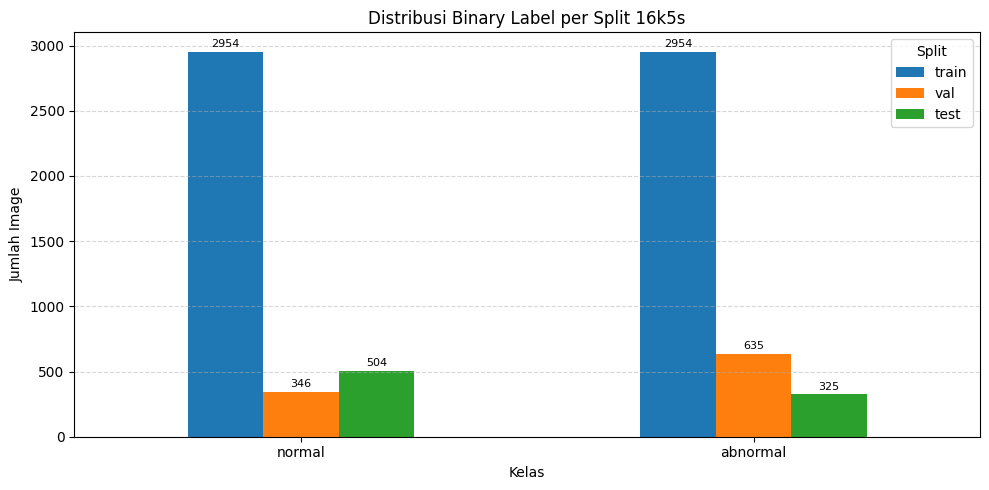


AUDIT DISTRIBUSI LABEL SUMBER sound


split,train,val,test,total
sound,,,,
normal,2954,346,504,3804
crackle,1414,380,94,1888
wheeze,873,113,156,1142
both,667,142,75,884
abnormal,0,0,0,0


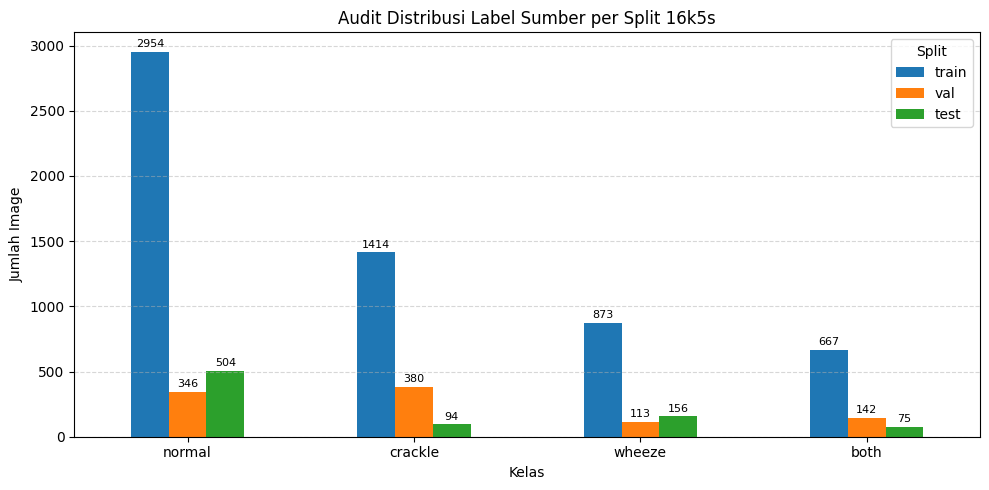


DISTRIBUSI TRAIN: ORIGINAL VS MANUAL AUGMENTATION


binary_label,normal,abnormal
augmentation_group,,
original,2954,2371
manual_aug,0,583


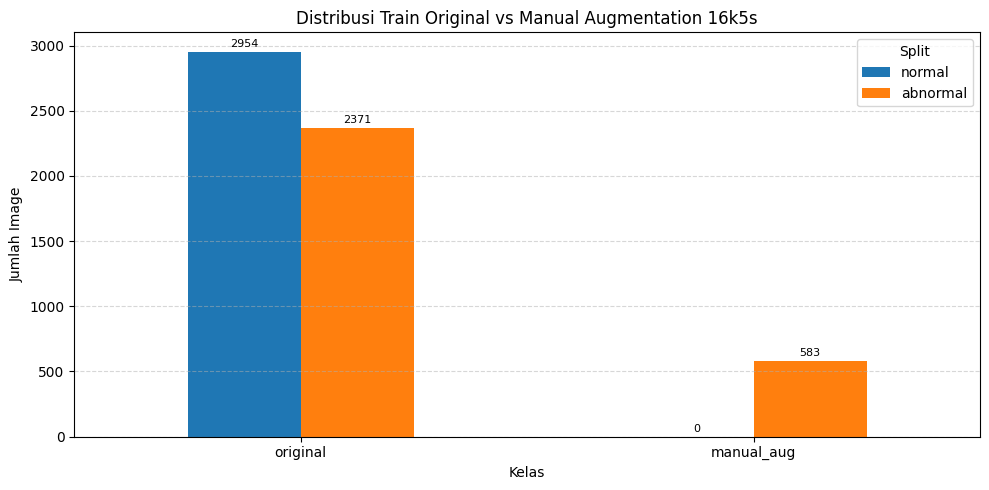


AUDIT TRAIN: ORIGINAL VS MANUAL AUGMENTATION BERDASARKAN sound


sound,normal,crackle,wheeze,both,abnormal
augmentation_group,,,,,
original,2954,1414,640,317,0
manual_aug,0,0,233,350,0



DISTRIBUSI JENIS AUGMENTASI PADA TRAIN


,count
aug_type,
none,5325
time_stretch,350
pitch_shift,233


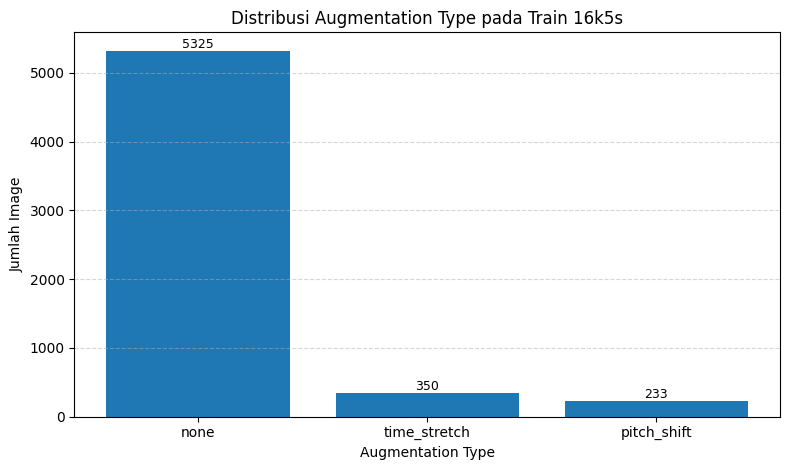


RINGKASAN JUMLAH DATA DAN PASIEN PER SPLIT


,split,n_samples,n_patients,normal,abnormal,original,manual_aug
0,train,5908,100,2954,2954,5325,583
1,val,981,13,346,635,981,0
2,test,829,13,504,325,829,0



Validasi patient leakage: aman

Validasi image_path: aman

Summary distribusi metadata disimpan di:
results_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026

[OK] Distribusi metadata binary normal-abnormal 16k5s berhasil dicek.


In [ ]:
# ============================================================
# CELL: CEK DISTRIBUSI METADATA 16k5s
# SKENARIO: BINARY NORMAL-ABNORMAL + AUGMENTASI MANUAL + SR 16k + LOG-MEL 224
# ============================================================
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 0. HELPER
# ============================================================
def safe_display(df):
    try:
        display(df)
    except NameError:
        print(df)

def plot_grouped_bar(df, title, ylabel="Jumlah"):
    ax = df.plot(
        kind="bar",
        figsize=(10, 5),
        rot=0
    )

    ax.set_title(title)
    ax.set_xlabel("Kelas")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.legend(title="Split")

    for container in ax.containers:
        ax.bar_label(container, fontsize=8, padding=2)

    plt.tight_layout()
    plt.show()


def plot_single_bar(series, title, xlabel="Kategori", ylabel="Jumlah"):
    fig, ax = plt.subplots(figsize=(8, 4.8))

    x = np.arange(len(series))
    bars = ax.bar(x, series.values)

    ax.set_xticks(x)
    ax.set_xticklabels(series.index.astype(str), rotation=0)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 1. VALIDASI DATAFRAME WAJIB
# ============================================================

required_vars = ["train_df", "val_df", "test_df"]
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    raise RuntimeError(
        f"Variabel belum tersedia: {missing_vars}\n"
        "Jalankan cell Load Metadata 16k5s dan Validasi Metadata 16k5s terlebih dahulu."
    )

train_df = globals()["train_df"].copy()
val_df = globals()["val_df"].copy()
test_df = globals()["test_df"].copy()


# ============================================================
# 2. KONFIGURASI 16k5s
# ============================================================

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both", "abnormal"]
BINARY_CLASSES = ["normal", "abnormal"]
ABNORMAL_CLASSES = ["crackle", "wheeze", "both", "abnormal"]

SPLITS = ["train", "val", "test"]

LABEL_COL = globals().get("LABEL_COL", "binary_label")

if LABEL_COL != "binary_label":
    raise ValueError(
        f"LABEL_COL saat ini adalah {LABEL_COL}. "
        "Untuk skenario binary normal-abnormal, LABEL_COL harus binary_label."
    )

TARGET_SR = 16000
TARGET_DURATION_SEC = 5.0
TARGET_LEN_SAMPLES = int(TARGET_SR * TARGET_DURATION_SEC)

N_MELS = 128
FMIN = 0
FMAX = 8000
N_FFT = 2048
HOP_LENGTH = 128
WIN_LENGTH = 2048
IMAGE_SIZE = 224
IMAGE_COLORMAP = "magma"
IMAGE_MODE = "rgb"

VALID_AUGMENTATION_GROUPS = {"original", "manual_aug"}
VALID_AUG_TYPES = {"none", "time_stretch", "pitch_shift"}


# ============================================================
# 3. NORMALISASI DAN VALIDASI KOLOM
# ============================================================

def normalize_and_validate_split_df(df, split_name):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    if "sound" not in df.columns:
        if "sound_4class" in df.columns:
            df["sound"] = df["sound_4class"]
        else:
            df["sound"] = df["binary_label"]

    if "sound_4class" not in df.columns:
        df["sound_4class"] = df["sound"]

    required_cols = [
        "image_path",
        "sound",
        "binary_label",
        "split",
    ]

    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        raise ValueError(
            f"{split_name} kehilangan kolom wajib: {missing_cols}"
        )

    df["image_path"] = df["image_path"].astype(str).str.strip()
    df["sound"] = df["sound"].astype(str).str.strip().str.lower()
    df["sound_4class"] = df["sound_4class"].astype(str).str.strip().str.lower()
    df["binary_label"] = df["binary_label"].astype(str).str.strip().str.lower()
    df["split"] = df["split"].astype(str).str.strip().str.lower()

    unknown_sound = sorted(set(df["sound"]) - set(SOURCE_CLASSES))

    if unknown_sound:
        raise ValueError(
            f"{split_name} memiliki label sound tidak valid: {unknown_sound}"
        )

    unknown_binary = sorted(set(df["binary_label"]) - set(BINARY_CLASSES))

    if unknown_binary:
        raise ValueError(
            f"{split_name} memiliki binary_label tidak valid: {unknown_binary}"
        )

    if not df["split"].eq(split_name).all():
        bad_rows = df[df["split"] != split_name][
            ["image_path", "split", "sound", "binary_label"]
        ].head(10)

        safe_display(bad_rows)

        raise ValueError(
            f"{split_name} memiliki baris dengan split selain {split_name}."
        )

    if "is_augmented" not in df.columns:
        df["is_augmented"] = 0

    df["is_augmented"] = (
        pd.to_numeric(df["is_augmented"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    if "augmentation_group" not in df.columns:
        df["augmentation_group"] = np.where(
            df["is_augmented"] == 1,
            "manual_aug",
            "original"
        )

    df["augmentation_group"] = (
        df["augmentation_group"]
        .fillna("original")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    if "aug_type" not in df.columns:
        df["aug_type"] = "none"

    df["aug_type"] = (
        df["aug_type"]
        .fillna("none")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # Val dan test harus original.
    if split_name in ["val", "test"]:
        df["is_augmented"] = 0
        df["augmentation_group"] = "original"
        df["aug_type"] = "none"

    # Original wajib none.
    df.loc[df["augmentation_group"] == "original", "aug_type"] = "none"

    unknown_aug_group = sorted(set(df["augmentation_group"]) - VALID_AUGMENTATION_GROUPS)

    if unknown_aug_group:
        raise ValueError(
            f"{split_name} memiliki augmentation_group tidak valid: {unknown_aug_group}"
        )

    unknown_aug_type = sorted(set(df["aug_type"]) - VALID_AUG_TYPES)

    if unknown_aug_type:
        raise ValueError(
            f"{split_name} memiliki aug_type tidak valid: {unknown_aug_type}"
        )

    if "patient_id" in df.columns:
        df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")

    # Validasi parameter image jika tersedia.
    expected_numeric = {
        "image_sr": TARGET_SR,
        "image_expected_len_samples": TARGET_LEN_SAMPLES,
        "image_n_mels": N_MELS,
        "image_n_fft": N_FFT,
        "image_hop_length": HOP_LENGTH,
        "image_win_length": WIN_LENGTH,
        "image_fmax": FMAX,
        "image_target_width": IMAGE_SIZE,
        "image_target_height": IMAGE_SIZE,
    }

    for col, expected_value in expected_numeric.items():
        if col in df.columns:
            values = pd.to_numeric(df[col], errors="coerce")
            bad_mask = values.fillna(-999999).astype(float) != float(expected_value)

            if bad_mask.any():
                bad_rows = df.loc[
                    bad_mask,
                    ["image_path", "split", "sound", "binary_label", col]
                ].head(10)

                safe_display(bad_rows)

                raise AssertionError(
                    f"{split_name} memiliki {int(bad_mask.sum())} baris "
                    f"dengan {col} bukan {expected_value}."
                )

    if "image_expected_sec" in df.columns:
        values = pd.to_numeric(df["image_expected_sec"], errors="coerce")
        bad_mask = np.abs(values.fillna(-999999) - TARGET_DURATION_SEC) > 1e-6

        if bad_mask.any():
            bad_rows = df.loc[
                bad_mask,
                ["image_path", "split", "sound", "binary_label", "image_expected_sec"]
            ].head(10)

            safe_display(bad_rows)

            raise AssertionError(
                f"{split_name} memiliki {int(bad_mask.sum())} baris "
                f"dengan image_expected_sec bukan {TARGET_DURATION_SEC}."
            )

    if "image_colormap" in df.columns:
        values = (
            df["image_colormap"]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
        )

        bad_mask = values != IMAGE_COLORMAP

        if bad_mask.any():
            bad_rows = df.loc[
                bad_mask,
                ["image_path", "split", "sound", "binary_label", "image_colormap"]
            ].head(10)

            safe_display(bad_rows)

            raise AssertionError(
                f"{split_name} memiliki {int(bad_mask.sum())} baris "
                f"dengan image_colormap bukan {IMAGE_COLORMAP}."
            )

    return df.reset_index(drop=True)


train_df = normalize_and_validate_split_df(train_df, "train")
val_df = normalize_and_validate_split_df(val_df, "val")
test_df = normalize_and_validate_split_df(test_df, "test")


# ============================================================
# 4. GABUNGKAN UNTUK RINGKASAN
# ============================================================

full_distribution_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

print("=" * 90)
print("DISTRIBUSI METADATA 16k5s BINARY NORMAL-ABNORMAL")
print("=" * 90)
print("Total data:", len(full_distribution_df))
print("Train     :", len(train_df))
print("Val       :", len(val_df))
print("Test      :", len(test_df))
print("TARGET_SR :", TARGET_SR)
print("N_MELS    :", N_MELS)
print("FMAX      :", FMAX)


# ============================================================
# 5. DISTRIBUSI BINARY LABEL UTAMA
# ============================================================

binary_dist_df = (
    full_distribution_df
    .groupby(["split", "binary_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=SPLITS, columns=BINARY_CLASSES, fill_value=0)
)

binary_dist_df_t = binary_dist_df.T.copy()
binary_dist_df_t["total"] = binary_dist_df_t.sum(axis=1)

for split_name in SPLITS:
    split_total = max(binary_dist_df_t[split_name].sum(), 1)
    binary_dist_df_t[f"{split_name}_percent"] = (
        binary_dist_df_t[split_name] / split_total * 100.0
    )

print("\n" + "=" * 90)
print("DISTRIBUSI TARGET UTAMA: BINARY NORMAL-ABNORMAL")
print("=" * 90)
safe_display(binary_dist_df_t)

plot_grouped_bar(
    binary_dist_df_t[["train", "val", "test"]],
    title="Distribusi Binary Label per Split 16k5s",
    ylabel="Jumlah Image"
)


# ============================================================
# 6. AUDIT DISTRIBUSI LABEL SUMBER
# ============================================================

source_dist_df = (
    full_distribution_df
    .groupby(["split", "sound"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=SPLITS, columns=SOURCE_CLASSES, fill_value=0)
)

source_dist_df_t = source_dist_df.T.copy()
source_dist_df_t["total"] = source_dist_df_t.sum(axis=1)

print("\n" + "=" * 90)
print("AUDIT DISTRIBUSI LABEL SUMBER sound")
print("=" * 90)
safe_display(source_dist_df_t)

source_plot_df = source_dist_df_t[["train", "val", "test"]]
source_plot_df = source_plot_df.loc[source_plot_df.sum(axis=1) > 0]

plot_grouped_bar(
    source_plot_df,
    title="Audit Distribusi Label Sumber per Split 16k5s",
    ylabel="Jumlah Image"
)


# ============================================================
# 7. DISTRIBUSI ORIGINAL VS AUGMENTASI PADA TRAIN
# ============================================================

train_aug_binary_df = (
    train_df
    .groupby(["augmentation_group", "binary_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["original", "manual_aug"], columns=BINARY_CLASSES, fill_value=0)
    .astype(int)
)

print("\n" + "=" * 90)
print("DISTRIBUSI TRAIN: ORIGINAL VS MANUAL AUGMENTATION")
print("=" * 90)
safe_display(train_aug_binary_df)

plot_grouped_bar(
    train_aug_binary_df,
    title="Distribusi Train Original vs Manual Augmentation 16k5s",
    ylabel="Jumlah Image"
)


train_aug_source_df = (
    train_df
    .groupby(["augmentation_group", "sound"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["original", "manual_aug"], columns=SOURCE_CLASSES, fill_value=0)
    .astype(int)
)

print("\n" + "=" * 90)
print("AUDIT TRAIN: ORIGINAL VS MANUAL AUGMENTATION BERDASARKAN sound")
print("=" * 90)
safe_display(train_aug_source_df)


# ============================================================
# 8. DISTRIBUSI JENIS AUGMENTASI PADA TRAIN
# ============================================================

train_aug_type_df = (
    train_df["aug_type"]
    .value_counts()
    .reindex(["none", "time_stretch", "pitch_shift"], fill_value=0)
    .astype(int)
    .to_frame(name="count")
)

print("\n" + "=" * 90)
print("DISTRIBUSI JENIS AUGMENTASI PADA TRAIN")
print("=" * 90)
safe_display(train_aug_type_df)

plot_single_bar(
    train_aug_type_df["count"],
    title="Distribusi Augmentation Type pada Train 16k5s",
    xlabel="Augmentation Type",
    ylabel="Jumlah Image"
)


# ============================================================
# 9. RINGKASAN JUMLAH DATA DAN PASIEN PER SPLIT
# ============================================================

patient_summary = []

for split_name, df_split in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df),
]:
    row = {
        "split": split_name,
        "n_samples": int(len(df_split)),
        "n_patients": int(df_split["patient_id"].nunique()) if "patient_id" in df_split.columns else np.nan,
        "normal": int((df_split["binary_label"] == "normal").sum()),
        "abnormal": int((df_split["binary_label"] == "abnormal").sum()),
        "original": int((df_split["augmentation_group"] == "original").sum()) if "augmentation_group" in df_split.columns else np.nan,
        "manual_aug": int((df_split["augmentation_group"] == "manual_aug").sum()) if "augmentation_group" in df_split.columns else np.nan,
    }

    patient_summary.append(row)

patient_summary_df = pd.DataFrame(patient_summary)

print("\n" + "=" * 90)
print("RINGKASAN JUMLAH DATA DAN PASIEN PER SPLIT")
print("=" * 90)
safe_display(patient_summary_df)


# ============================================================
# 10. VALIDASI ANTI-LEAKAGE PATIENT
# ============================================================

if all("patient_id" in df.columns for df in [train_df, val_df, test_df]):
    train_patients = set(train_df["patient_id"].dropna().astype(int).unique())
    val_patients = set(val_df["patient_id"].dropna().astype(int).unique())
    test_patients = set(test_df["patient_id"].dropna().astype(int).unique())

    leak_train_val = train_patients & val_patients
    leak_train_test = train_patients & test_patients
    leak_val_test = val_patients & test_patients

    if leak_train_val or leak_train_test or leak_val_test:
        raise AssertionError(
            "Terdapat patient leakage antar split.\n"
            f"train-val leak : {sorted(list(leak_train_val))[:20]}\n"
            f"train-test leak: {sorted(list(leak_train_test))[:20]}\n"
            f"val-test leak  : {sorted(list(leak_val_test))[:20]}"
        )

    print("\nValidasi patient leakage: aman")


# ============================================================
# 11. VALIDASI IMAGE PATH
# ============================================================

for split_name, df_split in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df),
]:
    if "image_path" in df_split.columns:
        missing_images = df_split[
            ~df_split["image_path"].astype(str).apply(lambda p: Path(p).exists())
        ]

        if len(missing_images) > 0:
            print(f"\n[ERROR] {split_name}: ada {len(missing_images)} image_path hilang.")
            safe_display(
                missing_images[
                    ["image_path", "binary_label", "sound", "split", "augmentation_group"]
                ].head(10)
            )

            raise FileNotFoundError(
                f"{split_name}: ada image_path yang tidak ditemukan."
            )

print("\nValidasi image_path: aman")


# ============================================================
# 12. SIMPAN SUMMARY KE FILE JIKA RESULT_DIR ADA
# ============================================================

RESULT_DIR = globals().get("RESULT_DIR", None)

if RESULT_DIR is not None:
    RESULT_DIR = Path(RESULT_DIR)
    RESULT_DIR.mkdir(parents=True, exist_ok=True)

    binary_dist_df_t.to_csv(RESULT_DIR / "metadata_distribution_binary_16k5s.csv")
    source_dist_df_t.to_csv(RESULT_DIR / "metadata_distribution_source_16k5s.csv")
    train_aug_binary_df.to_csv(RESULT_DIR / "metadata_distribution_train_aug_binary_16k5s.csv")
    train_aug_source_df.to_csv(RESULT_DIR / "metadata_distribution_train_aug_source_16k5s.csv")
    train_aug_type_df.to_csv(RESULT_DIR / "metadata_distribution_train_aug_type_16k5s.csv")
    patient_summary_df.to_csv(RESULT_DIR / "metadata_distribution_patient_summary_16k5s.csv", index=False)

    print("\nSummary distribusi metadata disimpan di:")
    print(RESULT_DIR)


# ============================================================
# 13. SIMPAN KE GLOBALS
# ============================================================

globals()["train_df"] = train_df
globals()["val_df"] = val_df
globals()["test_df"] = test_df
globals()["full_distribution_df"] = full_distribution_df

globals()["binary_dist_df"] = binary_dist_df_t
globals()["source_dist_df"] = source_dist_df_t
globals()["train_aug_binary_df"] = train_aug_binary_df
globals()["train_aug_source_df"] = train_aug_source_df
globals()["train_aug_type_df"] = train_aug_type_df
globals()["patient_summary_df"] = patient_summary_df

globals()["TARGET_SR"] = TARGET_SR
globals()["TARGET_DURATION_SEC"] = TARGET_DURATION_SEC
globals()["TARGET_LEN_SAMPLES"] = TARGET_LEN_SAMPLES
globals()["N_MELS"] = N_MELS
globals()["FMIN"] = FMIN
globals()["FMAX"] = FMAX
globals()["N_FFT"] = N_FFT
globals()["HOP_LENGTH"] = HOP_LENGTH
globals()["WIN_LENGTH"] = WIN_LENGTH
globals()["IMAGE_SIZE"] = IMAGE_SIZE
globals()["IMAGE_COLORMAP"] = IMAGE_COLORMAP
globals()["IMAGE_MODE"] = IMAGE_MODE

print("\n[OK] Distribusi metadata binary normal-abnormal 16k5s berhasil dicek.")

# **Dataloader Model Vision Transformer**

In [ ]:
# ============================================================
# CELL: TRANSFORM, DATASET, DAN PATIENT-BALANCED DATALOADER 16k5s — 2 KELAS
# SKENARIO V4: BINARY NORMAL–ABNORMAL + AUGMENTASI MANUAL + PATIENT BALANCING
# ============================================================
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import ViT_B_16_Weights
from torchvision.transforms import InterpolationMode

try:
    from IPython.display import display
except ImportError:
    display = print


# ============================================================
# 0. HELPER
# ============================================================

def safe_display(data):
    """Menampilkan DataFrame pada notebook atau mencetaknya pada runtime biasa."""
    try:
        display(data)
    except NameError:
        print(data)


# ============================================================
# 1. VALIDASI GLOBAL DAN KEBIJAKAN DATALOADER
# ============================================================
# Semua kebijakan sampler dibaca dari Global Config. Cell ini tidak boleh
# menimpa konfigurasi eksperimen secara diam-diam.
MODEL_SEED = int(
    globals().get(
        "MODEL_SEED",
        globals().get(
            "SEED",
            globals().get("SAMPLER_SEED", 42),
        ),
    )
)
SAMPLER_SEED = int(globals().get("SAMPLER_SEED", MODEL_SEED))

USE_PATIENT_BALANCED_SAMPLER = bool(
    globals().get("USE_PATIENT_BALANCED_SAMPLER", False)
)
USE_WEIGHTED_RANDOM_SAMPLER = bool(
    globals().get(
        "USE_WEIGHTED_RANDOM_SAMPLER",
        USE_PATIENT_BALANCED_SAMPLER,
    )
)
USE_PATIENT_GROUP_SAMPLER = bool(
    globals().get("USE_PATIENT_GROUP_SAMPLER", False)
)

SAMPLER_MODE = str(
    globals().get(
        "SAMPLER_MODE",
        "patient_balanced_sqrt"
        if USE_PATIENT_BALANCED_SAMPLER
        else "standard_shuffle",
    )
).strip().lower()

PATIENT_WEIGHT_POWER = float(
    globals().get("PATIENT_WEIGHT_POWER", 0.5)
)
BALANCE_CLASSES_IN_PATIENT_SAMPLER = bool(
    globals().get(
        "BALANCE_CLASSES_IN_PATIENT_SAMPLER",
        True,
    )
)
SAMPLER_REPLACEMENT = bool(
    globals().get("SAMPLER_REPLACEMENT", True)
)

SHUFFLE_TRAIN = bool(
    globals().get(
        "SHUFFLE_TRAIN",
        not USE_WEIGHTED_RANDOM_SAMPLER,
    )
)

NORMALIZATION_METHOD = str(
    globals().get(
        "NORMALIZATION_METHOD",
        "imagenet_pretrained",
    )
).strip().lower()

USE_SPEC_AUGMENT = bool(
    globals().get("USE_SPEC_AUGMENT", False)
)

required_globals = [
    "BATCH_SIZE",
    "NUM_WORKERS",
    "label2id",
    "id2label",
    "NUM_CLASSES",
    "CLASSES",
    "LABEL_COL",
    "train_df",
    "val_df",
    "test_df",
    "USE_PATIENT_BALANCED_SAMPLER",
    "PATIENT_WEIGHT_POWER",
    "BALANCE_CLASSES_IN_PATIENT_SAMPLER",
]

missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]

if missing_globals:
    raise RuntimeError(
        f"Variabel global belum tersedia: {missing_globals}\n"
        "Jalankan cell konfigurasi, load metadata, validasi metadata, "
        "dan distribusi metadata 16k5s terlebih dahulu."
    )

if str(LABEL_COL).strip() != "binary_label":
    raise ValueError(
        f"LABEL_COL saat ini={LABEL_COL!r}. "
        "Untuk eksperimen binary, LABEL_COL wajib 'binary_label'."
    )

if list(CLASSES) != ["normal", "abnormal"]:
    raise ValueError(
        f"CLASSES saat ini={CLASSES}. "
        "Untuk eksperimen binary, CLASSES wajib ['normal', 'abnormal']."
    )

if int(NUM_CLASSES) != 2:
    raise ValueError(
        f"NUM_CLASSES saat ini={NUM_CLASSES}. "
        "Untuk eksperimen binary, NUM_CLASSES wajib 2."
    )

if int(NUM_CLASSES) != len(CLASSES):
    raise ValueError(
        f"NUM_CLASSES={NUM_CLASSES} tidak sesuai len(CLASSES)={len(CLASSES)}."
    )

if int(NUM_CLASSES) != len(label2id):
    raise ValueError(
        f"NUM_CLASSES={NUM_CLASSES} tidak sesuai len(label2id)={len(label2id)}."
    )

if int(NUM_CLASSES) != len(id2label):
    raise ValueError(
        f"NUM_CLASSES={NUM_CLASSES} tidak sesuai len(id2label)={len(id2label)}."
    )

expected_label2id = {"normal": 0, "abnormal": 1}
if dict(label2id) != expected_label2id:
    raise ValueError(
        f"label2id harus {expected_label2id}, ditemukan={dict(label2id)}."
    )

expected_id2label = {0: "normal", 1: "abnormal"}
if dict(id2label) != expected_id2label:
    raise ValueError(
        f"id2label harus {expected_id2label}, ditemukan={dict(id2label)}."
    )

if not (0.0 < PATIENT_WEIGHT_POWER <= 1.0):
    raise ValueError(
        "PATIENT_WEIGHT_POWER harus berada pada (0, 1]. "
        f"Saat ini={PATIENT_WEIGHT_POWER}."
    )

if USE_PATIENT_GROUP_SAMPLER:
    raise ValueError(
        "USE_PATIENT_GROUP_SAMPLER harus False pada eksperimen V4. "
        "Gunakan hanya patient-balanced WeightedRandomSampler."
    )

if USE_PATIENT_BALANCED_SAMPLER:
    if not USE_WEIGHTED_RANDOM_SAMPLER:
        raise ValueError(
            "USE_PATIENT_BALANCED_SAMPLER=True membutuhkan "
            "USE_WEIGHTED_RANDOM_SAMPLER=True."
        )

    if SAMPLER_MODE != "patient_balanced_sqrt":
        raise ValueError(
            "SAMPLER_MODE harus 'patient_balanced_sqrt' ketika "
            "patient-balanced sampler aktif. "
            f"Saat ini={SAMPLER_MODE!r}."
        )

    if SHUFFLE_TRAIN:
        raise ValueError(
            "SHUFFLE_TRAIN harus False ketika sampler aktif."
        )
else:
    if USE_WEIGHTED_RANDOM_SAMPLER:
        raise ValueError(
            "USE_WEIGHTED_RANDOM_SAMPLER=True hanya didukung untuk "
            "patient-balanced sampler pada cell V4 ini."
        )

    if SAMPLER_MODE != "standard_shuffle":
        raise ValueError(
            "Jika patient-balanced sampler nonaktif, SAMPLER_MODE harus "
            f"'standard_shuffle'. Saat ini={SAMPLER_MODE!r}."
        )

FIXED_BATCH_SIZE = int(BATCH_SIZE)
NUM_WORKERS = int(NUM_WORKERS)

if FIXED_BATCH_SIZE <= 0:
    raise ValueError(
        f"BATCH_SIZE harus > 0, saat ini={FIXED_BATCH_SIZE}."
    )

if NUM_WORKERS < 0:
    raise ValueError(
        f"NUM_WORKERS tidak boleh negatif, saat ini={NUM_WORKERS}."
    )

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
PIN_MEMORY = bool(torch.cuda.is_available())
PERSISTENT_WORKERS = bool(NUM_WORKERS > 0)

USE_CLASS_WEIGHT = bool(globals().get("USE_CLASS_WEIGHT", False))

print("=" * 96)
print(
    "DATALOADER BINARY 16k5s — "
    "IMAGENET NORMALIZATION + PATIENT-BALANCED SAMPLER"
)
print("=" * 96)
print("DEVICE                      :", DEVICE)
print("FIXED_BATCH_SIZE            :", FIXED_BATCH_SIZE)
print("NUM_WORKERS                 :", NUM_WORKERS)
print("PIN_MEMORY                  :", PIN_MEMORY)
print("PERSISTENT_WORKERS          :", PERSISTENT_WORKERS)
print("MODEL_SEED                  :", MODEL_SEED)
print("NORMALIZATION_METHOD        :", NORMALIZATION_METHOD)
print("SAMPLER_MODE                :", SAMPLER_MODE)
print("USE_PATIENT_BALANCED        :", USE_PATIENT_BALANCED_SAMPLER)
print("USE_WEIGHTED_RANDOM_SAMPLER :", USE_WEIGHTED_RANDOM_SAMPLER)
print("PATIENT_WEIGHT_POWER        :", PATIENT_WEIGHT_POWER)
print("BALANCE_CLASS_MASS          :", BALANCE_CLASSES_IN_PATIENT_SAMPLER)
print("SAMPLER_REPLACEMENT         :", SAMPLER_REPLACEMENT)
print("USE_PATIENT_GROUP_SAMPLER   :", USE_PATIENT_GROUP_SAMPLER)
print("USE_SPEC_AUGMENT            :", USE_SPEC_AUGMENT)
print("USE_CLASS_WEIGHT            :", USE_CLASS_WEIGHT)
print("TRAIN SHUFFLE               :", SHUFFLE_TRAIN)
print("VAL/TEST SHUFFLE            : False")
print("=" * 96)


# ============================================================
# 2. KONFIGURASI TARGET 16k5s DAN LABEL
# ============================================================
TARGET_SR = int(globals().get("TARGET_SR", 16000))
TARGET_DURATION_SEC = float(globals().get("TARGET_DURATION_SEC", 5.0))
TARGET_LEN_SAMPLES = int(
    globals().get(
        "TARGET_LEN_SAMPLES",
        TARGET_SR * TARGET_DURATION_SEC,
    )
)

N_MELS = int(globals().get("N_MELS", 128))

# ------------------------------------------------------------------
# FMIN mengikuti metadata citra yang benar-benar dimuat.
# Ini mencegah konflik ketika Global Configuration lama masih menyimpan
# FMIN=0, sedangkan seluruh citra Log-Mel dibuat dengan FMIN berbeda
# (misalnya 50 Hz). Metadata tidak diubah; konfigurasi runtime yang
# disinkronkan dengan provenance citra.
# ------------------------------------------------------------------
def _infer_consistent_image_parameter(
    column_name: str,
    dataframes: dict,
    fallback_value,
):
    detected_values = {}

    for dataframe_name, dataframe in dataframes.items():
        if column_name not in dataframe.columns:
            continue

        numeric_values = pd.to_numeric(
            dataframe[column_name],
            errors="coerce",
        )

        if numeric_values.isna().any():
            raise AssertionError(
                f"{dataframe_name}.{column_name} memiliki "
                f"{int(numeric_values.isna().sum())} nilai kosong/non-numerik."
            )

        unique_values = np.sort(
            numeric_values.astype(float).unique()
        )

        if len(unique_values) != 1:
            raise AssertionError(
                f"{dataframe_name}.{column_name} harus seragam, "
                f"ditemukan={unique_values.tolist()}."
            )

        detected_values[dataframe_name] = float(unique_values[0])

    if not detected_values:
        return float(fallback_value), "global_fallback"

    cross_split_values = np.asarray(
        list(detected_values.values()),
        dtype=float,
    )

    if not np.allclose(
        cross_split_values,
        cross_split_values[0],
        rtol=0.0,
        atol=1e-9,
    ):
        raise AssertionError(
            f"{column_name} tidak konsisten antar-split: "
            f"{detected_values}. Regenerasi citra/metadata diperlukan."
        )

    return float(cross_split_values[0]), "image_metadata"


CONFIGURED_FMIN = float(globals().get("FMIN", 50))
DETECTED_FMIN, FMIN_SOURCE = _infer_consistent_image_parameter(
    column_name="image_fmin",
    dataframes={
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
    },
    fallback_value=CONFIGURED_FMIN,
)

if not np.isclose(
    CONFIGURED_FMIN,
    DETECTED_FMIN,
    rtol=0.0,
    atol=1e-9,
):
    print(
        "[WARNING] FMIN global tidak sesuai metadata citra: "
        f"global={CONFIGURED_FMIN:g}, metadata={DETECTED_FMIN:g}. "
        "Runtime disinkronkan ke metadata citra."
    )

FMIN = int(round(DETECTED_FMIN))
globals()["FMIN"] = FMIN

print(
    "FMIN runtime                 :",
    FMIN,
    f"(source={FMIN_SOURCE})",
)

FMAX = int(globals().get("FMAX", 8000))
N_FFT = int(globals().get("N_FFT", 2048))
HOP_LENGTH = int(globals().get("HOP_LENGTH", 128))
WIN_LENGTH = int(globals().get("WIN_LENGTH", 2048))

IMAGE_SIZE = int(globals().get("IMAGE_SIZE", 224))
IMAGE_COLORMAP = str(
    globals().get("IMAGE_COLORMAP", "magma")
).strip().lower()
IMAGE_MODE = str(
    globals().get("IMAGE_MODE", "rgb")
).strip().lower()

BINARY_CLASSES = ["normal", "abnormal"]
SOURCE_CLASSES = [
    "normal",
    "crackle",
    "wheeze",
    "both",
    "abnormal",
]
ABNORMAL_CLASSES = {
    "crackle",
    "wheeze",
    "both",
    "abnormal",
}

VALID_SPLITS = {"train", "val", "test"}
VALID_AUG_GROUPS = {"original", "manual_aug"}
VALID_MANUAL_AUG_TYPES = {"time_stretch", "pitch_shift"}
VALID_ORIGINAL_AUG_TYPES = {"", "none", "original"}

if TARGET_SR != 16000:
    raise AssertionError(
        f"TARGET_SR harus 16000, saat ini={TARGET_SR}."
    )

if TARGET_LEN_SAMPLES != 80000:
    raise AssertionError(
        "TARGET_LEN_SAMPLES harus 80000 untuk audio 16 kHz × 5 detik, "
        f"saat ini={TARGET_LEN_SAMPLES}."
    )

if N_MELS != 128:
    raise AssertionError(
        f"N_MELS harus 128, saat ini={N_MELS}."
    )

if FMAX != 8000:
    raise AssertionError(
        f"FMAX harus 8000 Hz, saat ini={FMAX}."
    )

if HOP_LENGTH != 128:
    raise AssertionError(
        f"HOP_LENGTH harus 128, saat ini={HOP_LENGTH}."
    )

if IMAGE_SIZE != 224:
    raise AssertionError(
        f"IMAGE_SIZE harus 224 untuk ViT-B/16, saat ini={IMAGE_SIZE}."
    )


def to_binary_label(label: str) -> str:
    """Mengubah label sumber empat kelas menjadi label binary."""
    normalized_label = str(label).strip().lower()

    if normalized_label == "normal":
        return "normal"

    if normalized_label in ABNORMAL_CLASSES:
        return "abnormal"

    raise ValueError(
        f"Label sumber tidak dikenal: {normalized_label!r}."
    )


def _normalize_binary_flag(
    series: pd.Series,
    column_name: str,
) -> pd.Series:
    numeric = pd.to_numeric(series, errors="coerce")

    if numeric.isna().any():
        raise ValueError(
            f"Kolom {column_name} memiliki nilai kosong atau nonnumerik."
        )

    numeric = numeric.astype(int)
    invalid_values = sorted(set(numeric.unique()) - {0, 1})

    if invalid_values:
        raise ValueError(
            f"Kolom {column_name} hanya boleh berisi 0/1. "
            f"Ditemukan={invalid_values}."
        )

    return numeric


# ============================================================
# 3. VALIDASI DATAFRAME DAN PROVENANCE AUGMENTASI
# ============================================================
def validate_df_for_dataset_16k5s(
    dataframe: pd.DataFrame,
    name: str,
    expected_split: str,
) -> pd.DataFrame:
    """Memvalidasi label, split, provenance augmentasi, dan file citra."""
    if not isinstance(dataframe, pd.DataFrame):
        raise TypeError(
            f"{name} harus berupa pandas DataFrame."
        )

    if dataframe.empty:
        raise ValueError(
            f"{name} tidak boleh kosong."
        )

    dataframe = dataframe.copy()
    dataframe.columns = [
        str(column).strip()
        for column in dataframe.columns
    ]

    if "sound" not in dataframe.columns:
        if "sound_4class" in dataframe.columns:
            dataframe["sound"] = dataframe["sound_4class"]
        elif LABEL_COL in dataframe.columns:
            dataframe["sound"] = dataframe[LABEL_COL]
        else:
            raise ValueError(
                f"{name} tidak memiliki kolom sound, sound_4class, "
                f"atau {LABEL_COL}."
            )

    if "sound_4class" not in dataframe.columns:
        dataframe["sound_4class"] = dataframe["sound"]

    if "original_sound" not in dataframe.columns:
        dataframe["original_sound"] = dataframe["sound"]

    if "is_augmented" not in dataframe.columns:
        raise ValueError(
            f"{name} tidak memiliki kolom wajib is_augmented."
        )

    if "augmentation_group" not in dataframe.columns:
        raise ValueError(
            f"{name} tidak memiliki kolom wajib augmentation_group."
        )

    if "aug_type" not in dataframe.columns:
        raise ValueError(
            f"{name} tidak memiliki kolom wajib aug_type."
        )

    required_columns = [
        "image_path",
        LABEL_COL,
        "sound",
        "split",
        "is_augmented",
        "augmentation_group",
        "aug_type",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{name} kehilangan kolom wajib: {missing_columns}."
        )

    dataframe = dataframe.reset_index(drop=True)

    string_columns = [
        "image_path",
        LABEL_COL,
        "sound",
        "sound_4class",
        "original_sound",
        "split",
        "augmentation_group",
        "aug_type",
    ]

    for column in string_columns:
        dataframe[column] = (
            dataframe[column]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
        )

    dataframe["is_augmented"] = _normalize_binary_flag(
        dataframe["is_augmented"],
        "is_augmented",
    )

    if "patient_id" in dataframe.columns:
        dataframe["patient_id"] = pd.to_numeric(
            dataframe["patient_id"],
            errors="coerce",
        )

    expected_split = str(expected_split).strip().lower()
    if expected_split not in VALID_SPLITS:
        raise ValueError(
            f"expected_split tidak valid: {expected_split!r}."
        )

    invalid_splits = sorted(
        set(dataframe["split"].unique()) - VALID_SPLITS
    )
    if invalid_splits:
        raise ValueError(
            f"{name} memiliki split tidak valid: {invalid_splits}."
        )

    if not dataframe["split"].eq(expected_split).all():
        invalid_preview = dataframe.loc[
            dataframe["split"].ne(expected_split),
            ["image_path", "split", LABEL_COL, "sound"],
        ].head(20)
        safe_display(invalid_preview)
        raise ValueError(
            f"{name} seharusnya hanya berisi split={expected_split!r}."
        )

    unknown_binary_labels = sorted(
        set(dataframe[LABEL_COL].unique()) - set(BINARY_CLASSES)
    )
    if unknown_binary_labels:
        raise ValueError(
            f"{name} memiliki binary label tidak valid: "
            f"{unknown_binary_labels}."
        )

    unknown_sound_labels = sorted(
        set(dataframe["sound"].unique()) - set(SOURCE_CLASSES)
    )
    if unknown_sound_labels:
        raise ValueError(
            f"{name} memiliki sound tidak valid: {unknown_sound_labels}."
        )

    unknown_sound_4class = sorted(
        set(dataframe["sound_4class"].unique()) - set(SOURCE_CLASSES)
    )
    if unknown_sound_4class:
        raise ValueError(
            f"{name} memiliki sound_4class tidak valid: "
            f"{unknown_sound_4class}."
        )

    unknown_original_sound = sorted(
        set(dataframe["original_sound"].unique()) - set(SOURCE_CLASSES)
    )
    if unknown_original_sound:
        raise ValueError(
            f"{name} memiliki original_sound tidak valid: "
            f"{unknown_original_sound}."
        )

    expected_binary = dataframe["sound"].map(to_binary_label)
    binary_mismatch = expected_binary.ne(dataframe[LABEL_COL])

    if binary_mismatch.any():
        mismatch_preview = dataframe.loc[
            binary_mismatch,
            ["image_path", "sound", LABEL_COL, "split"],
        ].head(20)
        safe_display(mismatch_preview)
        raise ValueError(
            f"{name} memiliki {int(binary_mismatch.sum())} binary_label "
            "yang tidak konsisten dengan sound."
        )

    invalid_aug_groups = sorted(
        set(dataframe["augmentation_group"].unique())
        - VALID_AUG_GROUPS
    )
    if invalid_aug_groups:
        raise ValueError(
            f"{name} memiliki augmentation_group tidak valid: "
            f"{invalid_aug_groups}."
        )

    original_mask = dataframe["augmentation_group"].eq("original")
    manual_mask = dataframe["augmentation_group"].eq("manual_aug")

    invalid_original = (
        original_mask
        & (
            dataframe["is_augmented"].ne(0)
            | ~dataframe["aug_type"].isin(VALID_ORIGINAL_AUG_TYPES)
        )
    )

    invalid_manual = (
        manual_mask
        & (
            dataframe["is_augmented"].ne(1)
            | ~dataframe["aug_type"].isin(VALID_MANUAL_AUG_TYPES)
        )
    )

    if invalid_original.any():
        invalid_preview = dataframe.loc[
            invalid_original,
            [
                "image_path",
                LABEL_COL,
                "sound",
                "augmentation_group",
                "is_augmented",
                "aug_type",
            ],
        ].head(20)
        safe_display(invalid_preview)
        raise ValueError(
            f"{name} memiliki {int(invalid_original.sum())} data original "
            "dengan provenance tidak konsisten."
        )

    if invalid_manual.any():
        invalid_preview = dataframe.loc[
            invalid_manual,
            [
                "image_path",
                LABEL_COL,
                "sound",
                "augmentation_group",
                "is_augmented",
                "aug_type",
            ],
        ].head(20)
        safe_display(invalid_preview)
        raise ValueError(
            f"{name} memiliki {int(invalid_manual.sum())} data manual_aug "
            "dengan provenance tidak konsisten."
        )

    # Val/test wajib benar-benar original. Metadata tidak boleh ditimpa
    # untuk menyembunyikan data augmented yang salah masuk split evaluasi.
    if expected_split in {"val", "test"}:
        invalid_evaluation_rows = (
            dataframe["augmentation_group"].ne("original")
            | dataframe["is_augmented"].ne(0)
            | ~dataframe["aug_type"].isin(VALID_ORIGINAL_AUG_TYPES)
        )

        if invalid_evaluation_rows.any():
            invalid_preview = dataframe.loc[
                invalid_evaluation_rows,
                [
                    "image_path",
                    LABEL_COL,
                    "sound",
                    "split",
                    "augmentation_group",
                    "is_augmented",
                    "aug_type",
                ],
            ].head(20)
            safe_display(invalid_preview)
            raise ValueError(
                f"{name} memuat {int(invalid_evaluation_rows.sum())} "
                "data augmented. Validation dan test wajib hanya "
                "berisi data original."
            )

    # Setelah validasi lolos, variasi penamaan original diseragamkan.
    dataframe.loc[original_mask, "aug_type"] = "none"

    empty_image_paths = int(dataframe["image_path"].eq("").sum())
    if empty_image_paths > 0:
        raise ValueError(
            f"{name} memiliki {empty_image_paths} image_path kosong."
        )

    missing_image_paths = [
        path
        for path in dataframe["image_path"]
        if not Path(path).exists()
    ]
    if missing_image_paths:
        raise FileNotFoundError(
            f"{name} memiliki {len(missing_image_paths)} image_path "
            f"yang tidak ditemukan. Contoh={missing_image_paths[:5]}."
        )

    duplicate_count = int(
        dataframe["image_path"].duplicated().sum()
    )
    if duplicate_count > 0:
        duplicate_preview = dataframe.loc[
            dataframe["image_path"].duplicated(keep=False),
            [
                "image_path",
                LABEL_COL,
                "sound",
                "split",
                "augmentation_group",
                "aug_type",
            ],
        ].head(20)
        safe_display(duplicate_preview)
        raise ValueError(
            f"{name} memiliki {duplicate_count} image_path duplikat."
        )

    expected_numeric = {
        "image_sr": TARGET_SR,
        "image_expected_len_samples": TARGET_LEN_SAMPLES,
        "image_n_mels": N_MELS,
        "image_n_fft": N_FFT,
        "image_hop_length": HOP_LENGTH,
        "image_win_length": WIN_LENGTH,
        "image_fmax": FMAX,
        "image_target_width": IMAGE_SIZE,
        "image_target_height": IMAGE_SIZE,
    }

    for column, expected_value in expected_numeric.items():
        if column not in dataframe.columns:
            continue

        numeric_values = pd.to_numeric(
            dataframe[column],
            errors="coerce",
        )
        invalid_numeric = (
            numeric_values.isna()
            | numeric_values.astype(float).ne(float(expected_value))
        )

        if invalid_numeric.any():
            invalid_preview = dataframe.loc[
                invalid_numeric,
                ["image_path", "split", "sound", LABEL_COL, column],
            ].head(20)
            safe_display(invalid_preview)
            raise AssertionError(
                f"{name} memiliki {int(invalid_numeric.sum())} baris "
                f"dengan {column} bukan {expected_value}."
            )

    if "image_fmin" in dataframe.columns:
        fmin_values = pd.to_numeric(
            dataframe["image_fmin"],
            errors="coerce",
        )
        invalid_fmin = (
            fmin_values.isna()
            | fmin_values.astype(float).ne(float(FMIN))
        )

        if invalid_fmin.any():
            invalid_preview = dataframe.loc[
                invalid_fmin,
                ["image_path", "split", "sound", LABEL_COL, "image_fmin"],
            ].head(20)
            safe_display(invalid_preview)
            raise AssertionError(
                f"{name} memiliki {int(invalid_fmin.sum())} baris "
                f"dengan image_fmin bukan {FMIN}."
            )

    if "image_expected_sec" in dataframe.columns:
        duration_values = pd.to_numeric(
            dataframe["image_expected_sec"],
            errors="coerce",
        )
        invalid_duration = (
            duration_values.isna()
            | (
                np.abs(duration_values - TARGET_DURATION_SEC)
                > 1e-6
            )
        )

        if invalid_duration.any():
            invalid_preview = dataframe.loc[
                invalid_duration,
                [
                    "image_path",
                    "split",
                    "sound",
                    LABEL_COL,
                    "image_expected_sec",
                ],
            ].head(20)
            safe_display(invalid_preview)
            raise AssertionError(
                f"{name} memiliki {int(invalid_duration.sum())} baris "
                f"dengan image_expected_sec bukan {TARGET_DURATION_SEC}."
            )

    if "image_colormap" in dataframe.columns:
        colormap_values = (
            dataframe["image_colormap"]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
        )
        invalid_colormap = colormap_values.ne(IMAGE_COLORMAP)

        if invalid_colormap.any():
            invalid_preview = dataframe.loc[
                invalid_colormap,
                [
                    "image_path",
                    "split",
                    "sound",
                    LABEL_COL,
                    "image_colormap",
                ],
            ].head(20)
            safe_display(invalid_preview)
            raise AssertionError(
                f"{name} memiliki {int(invalid_colormap.sum())} baris "
                f"dengan image_colormap bukan {IMAGE_COLORMAP!r}."
            )

    if "image_mode" in dataframe.columns:
        mode_values = (
            dataframe["image_mode"]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
        )
        invalid_mode = mode_values.ne(IMAGE_MODE)

        if invalid_mode.any():
            invalid_preview = dataframe.loc[
                invalid_mode,
                ["image_path", "split", "sound", LABEL_COL, "image_mode"],
            ].head(20)
            safe_display(invalid_preview)
            raise AssertionError(
                f"{name} memiliki {int(invalid_mode.sum())} baris "
                f"dengan image_mode bukan {IMAGE_MODE!r}."
            )

    class_counts_local = (
        dataframe[LABEL_COL]
        .value_counts()
        .reindex(BINARY_CLASSES, fill_value=0)
        .astype(int)
    )
    missing_classes = class_counts_local.loc[
        class_counts_local <= 0
    ].index.tolist()

    if missing_classes:
        raise ValueError(
            f"{name} tidak memiliki kelas binary: {missing_classes}."
        )

    print(
        f"{name} valid untuk Dataset | jumlah data={len(dataframe)}"
    )
    return dataframe.reset_index(drop=True)

train_df = validate_df_for_dataset_16k5s(
    train_df,
    "train_df",
    "train",
)
val_df = validate_df_for_dataset_16k5s(
    val_df,
    "val_df",
    "val",
)
test_df = validate_df_for_dataset_16k5s(
    test_df,
    "test_df",
    "test",
)


# ============================================================
# 4. NORMALISASI RESMI PRETRAINED ViT-B/16
# ============================================================
weights_enum = ViT_B_16_Weights.IMAGENET1K_V1
weights_transform = weights_enum.transforms()

IMAGENET_MEAN = [
    float(value)
    for value in weights_transform.mean
]
IMAGENET_STD = [
    float(value)
    for value in weights_transform.std
]

expected_imagenet_mean = [0.485, 0.456, 0.406]
expected_imagenet_std = [0.229, 0.224, 0.225]

if not np.allclose(
    IMAGENET_MEAN,
    expected_imagenet_mean,
    atol=1e-7,
):
    raise RuntimeError(
        "Mean pretrained ViT tidak sesuai ImageNet: "
        f"{IMAGENET_MEAN}."
    )

if not np.allclose(
    IMAGENET_STD,
    expected_imagenet_std,
    atol=1e-7,
):
    raise RuntimeError(
        "Std pretrained ViT tidak sesuai ImageNet: "
        f"{IMAGENET_STD}."
    )

# Tidak ada SpecAugment online. Train, validation, dan test menggunakan
# transform identik seperti pada cell 4 kelas.
vit_transforms = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])

# Alias kompatibilitas untuk cell lama.
train_transform = vit_transforms
eval_transform = vit_transforms
DATASET_MEAN = IMAGENET_MEAN
DATASET_STD = IMAGENET_STD

print("\nNormalisasi pretrained ViT:")
print("Mean      :", IMAGENET_MEAN)
print("Std       :", IMAGENET_STD)
print("Transform :", vit_transforms)
print("SpecAugment: tidak digunakan")


# ============================================================
# 5. DATASET CLASS
# ============================================================
class LogMelImageDataset(Dataset):
    def __init__(
        self,
        dataframe: pd.DataFrame,
        label_to_id: dict,
        label_col: str = "binary_label",
        transform=None,
        split_name: str = "unknown",
        return_metadata: bool = False,
    ):
        self.df = (
            dataframe
            .copy()
            .reset_index(drop=True)
        )
        self.label2id = dict(label_to_id)
        self.label_col = str(label_col)
        self.transform = transform
        self.split_name = str(split_name)
        self.return_metadata = bool(return_metadata)

        required_columns = ["image_path", self.label_col]
        missing_columns = [
            column
            for column in required_columns
            if column not in self.df.columns
        ]

        if missing_columns:
            raise ValueError(
                f"Kolom wajib Dataset tidak ditemukan: {missing_columns}."
            )

        self.df["image_path"] = (
            self.df["image_path"]
            .fillna("")
            .astype(str)
            .str.strip()
        )
        self.df[self.label_col] = (
            self.df[self.label_col]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
        )

        unknown_labels = sorted(
            set(self.df[self.label_col].unique())
            - set(self.label2id)
        )
        if unknown_labels:
            raise ValueError(
                f"Label tidak dikenal pada {self.label_col}: "
                f"{unknown_labels}."
            )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[int(index)]

        image_path = Path(
            str(row["image_path"]).strip()
        )
        label_string = str(
            row[self.label_col]
        ).strip().lower()

        if label_string not in self.label2id:
            raise ValueError(
                f"Label tidak dikenal pada {self.split_name}: "
                f"{label_string!r}."
            )

        if not image_path.exists():
            raise FileNotFoundError(
                f"Image file tidak ditemukan: {image_path}."
            )

        with Image.open(image_path) as image:
            image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label_id = int(self.label2id[label_string])

        if not self.return_metadata:
            return image, label_id

        metadata = {
            "image_path": str(image_path),
            "label": label_string,
            "label_id": label_id,
        }

        metadata_columns = [
            "sound",
            "sound_4class",
            "original_sound",
            "patient_id",
            "split",
            "is_augmented",
            "augmentation_group",
            "aug_type",
            "file",
            "image_sr",
            "image_n_mels",
            "image_fmax",
            "image_hop_length",
            "image_expected_len_samples",
        ]

        for column in metadata_columns:
            if column in row.index:
                metadata[column] = row[column]

        return image, label_id, metadata


# ============================================================
# 6. DATASET DAN AUDIT DISTRIBUSI
# ============================================================
train_dataset = LogMelImageDataset(
    dataframe=train_df,
    label_to_id=label2id,
    label_col=LABEL_COL,
    transform=vit_transforms,
    split_name="train",
    return_metadata=False,
)
val_dataset = LogMelImageDataset(
    dataframe=val_df,
    label_to_id=label2id,
    label_col=LABEL_COL,
    transform=vit_transforms,
    split_name="val",
    return_metadata=False,
)
test_dataset = LogMelImageDataset(
    dataframe=test_df,
    label_to_id=label2id,
    label_col=LABEL_COL,
    transform=vit_transforms,
    split_name="test",
    return_metadata=False,
)


def _class_distribution(dataframe: pd.DataFrame) -> pd.DataFrame:
    counts = (
        dataframe[LABEL_COL]
        .value_counts()
        .reindex(BINARY_CLASSES, fill_value=0)
        .astype(int)
    )
    total = int(counts.sum())

    return pd.DataFrame({
        "class_id": [
            label2id[class_name]
            for class_name in BINARY_CLASSES
        ],
        "class_name": BINARY_CLASSES,
        "n_samples": counts.values,
        "ratio": counts.values / max(total, 1),
    })


train_class_distribution = _class_distribution(train_df)
val_class_distribution = _class_distribution(val_df)
test_class_distribution = _class_distribution(test_df)

train_group_class_df = (
    train_df
    .groupby(["augmentation_group", LABEL_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=["original", "manual_aug"],
        columns=BINARY_CLASSES,
        fill_value=0,
    )
    .astype(int)
)

train_group_source_df = (
    train_df
    .groupby(["augmentation_group", "sound"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=["original", "manual_aug"],
        columns=SOURCE_CLASSES,
        fill_value=0,
    )
    .astype(int)
)

train_aug_type_counts = (
    train_df["aug_type"]
    .value_counts()
    .reindex(
        ["none", "time_stretch", "pitch_shift"],
        fill_value=0,
    )
    .astype(int)
)

print("\nJumlah dataset:")
print("Train :", len(train_dataset))
print("Val   :", len(val_dataset))
print("Test  :", len(test_dataset))

print("\nDistribusi kelas train:")
safe_display(train_class_distribution)

print("\nDistribusi original/manual pada train:")
safe_display(train_group_class_df)


# ============================================================
# 7. PATIENT-BALANCED SAMPLE WEIGHTS
# ============================================================
def build_patient_balanced_sample_weights(
    dataframe: pd.DataFrame,
    label_col: str,
    patient_weight_power: float = 0.5,
    balance_class_mass: bool = True,
):
    """
    Membuat bobot per sampel untuk WeightedRandomSampler.

    Bobot dasar:
        w_i = 1 / n_patient(i) ** patient_weight_power

    Dengan power=0.5, pasien dengan banyak segmen tetap lebih sering terlihat
    dibanding pasien kecil, tetapi dominasi mereka diredam secara sublinear.

    Jika balance_class_mass=True, total sampling mass normal dan abnormal
    disetarakan setelah patient weighting. Ini menjaga patient balancing tidak
    menggeser distribusi binary secara tidak sengaja.
    """
    if "patient_id" not in dataframe.columns:
        raise KeyError(
            "Kolom patient_id wajib tersedia untuk patient-balanced sampler."
        )

    audit_df = (
        dataframe[
            ["patient_id", label_col, "augmentation_group", "aug_type"]
        ]
        .copy()
        .reset_index(drop=True)
    )

    patient_id_numeric = pd.to_numeric(
        audit_df["patient_id"],
        errors="coerce",
    )

    if patient_id_numeric.isna().any():
        raise ValueError(
            "patient_id train memiliki nilai kosong/non-numerik: "
            f"{int(patient_id_numeric.isna().sum())} baris."
        )

    audit_df["patient_id"] = patient_id_numeric.astype(int)

    label_series = (
        audit_df[label_col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    unknown_labels = sorted(
        set(label_series.unique()) - set(BINARY_CLASSES)
    )
    if unknown_labels:
        raise ValueError(
            f"Label train tidak valid untuk sampler: {unknown_labels}."
        )

    patient_counts = (
        audit_df["patient_id"]
        .value_counts()
        .sort_index()
    )

    n_patient_per_sample = (
        audit_df["patient_id"]
        .map(patient_counts)
        .astype(np.float64)
    )

    base_weights = (
        1.0
        / np.power(
            n_patient_per_sample.to_numpy(),
            float(patient_weight_power),
        )
    )

    sample_weights = base_weights.astype(np.float64, copy=True)

    class_scale = {
        class_name: 1.0
        for class_name in BINARY_CLASSES
    }

    if balance_class_mass:
        class_mass_before = {}

        for class_name in BINARY_CLASSES:
            class_mask = label_series.eq(class_name).to_numpy()
            class_mass_before[class_name] = float(
                sample_weights[class_mask].sum()
            )

        if any(
            (not np.isfinite(mass)) or mass <= 0
            for mass in class_mass_before.values()
        ):
            raise RuntimeError(
                "Sampling mass kelas tidak valid sebelum balancing: "
                f"{class_mass_before}."
            )

        target_mass = float(
            np.mean(
                list(class_mass_before.values())
            )
        )

        for class_name in BINARY_CLASSES:
            scale = (
                target_mass
                / class_mass_before[class_name]
            )
            class_scale[class_name] = float(scale)

            class_mask = label_series.eq(class_name).to_numpy()
            sample_weights[class_mask] *= scale

    mean_weight = float(sample_weights.mean())

    if (not np.isfinite(mean_weight)) or mean_weight <= 0:
        raise RuntimeError(
            f"Mean sample weight tidak valid: {mean_weight}."
        )

    # Normalisasi mean=1 hanya untuk interpretasi/audit.
    # WeightedRandomSampler bergantung pada rasio relatif bobot.
    sample_weights /= mean_weight

    if not np.isfinite(sample_weights).all():
        raise RuntimeError(
            "Sample weights mengandung NaN/Inf."
        )

    if np.any(sample_weights <= 0):
        raise RuntimeError(
            "Semua sample weights harus > 0."
        )

    audit_df["n_samples_patient"] = (
        n_patient_per_sample.astype(int).to_numpy()
    )
    audit_df["base_patient_weight"] = base_weights
    audit_df["class_scale"] = (
        label_series
        .map(class_scale)
        .astype(float)
        .to_numpy()
    )
    audit_df["sample_weight"] = sample_weights
    audit_df["expected_sample_probability"] = (
        sample_weights / sample_weights.sum()
    )

    patient_summary = (
        audit_df
        .groupby("patient_id", as_index=False)
        .agg(
            n_samples=("patient_id", "size"),
            mean_sample_weight=("sample_weight", "mean"),
            total_sampling_mass=("sample_weight", "sum"),
        )
        .sort_values(
            ["n_samples", "patient_id"],
            ascending=[False, True],
        )
        .reset_index(drop=True)
    )

    patient_summary["expected_patient_probability"] = (
        patient_summary["total_sampling_mass"]
        / patient_summary["total_sampling_mass"].sum()
    )

    class_summary = (
        audit_df
        .groupby(label_col, as_index=False)
        .agg(
            n_samples=(label_col, "size"),
            total_sampling_mass=("sample_weight", "sum"),
            mean_sample_weight=("sample_weight", "mean"),
        )
        .rename(columns={label_col: "class_name"})
    )

    class_summary["expected_class_probability"] = (
        class_summary["total_sampling_mass"]
        / class_summary["total_sampling_mass"].sum()
    )

    augmentation_summary = (
        audit_df
        .groupby(["augmentation_group", label_col], as_index=False)
        .agg(
            n_samples=(label_col, "size"),
            total_sampling_mass=("sample_weight", "sum"),
        )
        .rename(columns={label_col: "class_name"})
    )

    weights_tensor = torch.as_tensor(
        sample_weights,
        dtype=torch.double,
    )

    return (
        weights_tensor,
        audit_df,
        patient_summary,
        class_summary,
        augmentation_summary,
    )


if USE_PATIENT_BALANCED_SAMPLER:
    (
        sample_weights_tensor,
        sampler_audit_df,
        patient_sampler_summary_df,
        class_sampler_audit_df,
        augmentation_sampler_audit_df,
    ) = build_patient_balanced_sample_weights(
        dataframe=train_df,
        label_col=LABEL_COL,
        patient_weight_power=PATIENT_WEIGHT_POWER,
        balance_class_mass=BALANCE_CLASSES_IN_PATIENT_SAMPLER,
    )

    if len(sample_weights_tensor) != len(train_dataset):
        raise RuntimeError(
            "Jumlah sample weight harus sama dengan panjang train_dataset. "
            f"weights={len(sample_weights_tensor)}, "
            f"dataset={len(train_dataset)}."
        )

    print("\nPatient sampler — 20 pasien terbesar:")
    safe_display(
        patient_sampler_summary_df.head(20)
    )

    print("\nPatient sampler — expected class mass:")
    safe_display(class_sampler_audit_df)

    print("\nPatient sampler — augmentation mass:")
    safe_display(augmentation_sampler_audit_df)

else:
    sample_weights_tensor = None
    sampler_audit_df = None
    patient_sampler_summary_df = None
    class_sampler_audit_df = None
    augmentation_sampler_audit_df = None


# ============================================================
# 8. REPRODUCIBILITY HELPERS
# ============================================================
def _seed_worker(worker_id):
    """Menyelaraskan seed NumPy dan random dengan seed worker PyTorch."""
    del worker_id  # ID sudah direpresentasikan pada torch.initial_seed().
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def _make_generator(seed):
    generator = torch.Generator()
    generator.manual_seed(int(seed))
    return generator


# ============================================================
# 9. DATALOADER FACTORY — WAJIB DIBUAT ULANG PER TRIAL
# ============================================================
def _make_loader(
    dataset,
    batch_size,
    shuffle,
    generator_seed,
    sampler=None,
):
    if sampler is not None and bool(shuffle):
        raise ValueError(
            "DataLoader tidak boleh memakai sampler dan shuffle=True bersamaan."
        )

    loader_kwargs = {
        "dataset": dataset,
        "batch_size": int(batch_size),
        "shuffle": bool(shuffle) if sampler is None else False,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
        "drop_last": False,
        "worker_init_fn": _seed_worker,
        "generator": _make_generator(generator_seed),
    }

    if sampler is not None:
        loader_kwargs["sampler"] = sampler

    if NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = True
        loader_kwargs["prefetch_factor"] = 2

    return DataLoader(**loader_kwargs)


def build_dataloaders(
    batch_size=None,
    shuffle_seed=None,
    sampler_seed=None,
):
    """
    Membuat DataLoader baru untuk setiap trial.

    Train:
    - V4: WeightedRandomSampler dengan bobot patient-aware;
    - jumlah draw per epoch tetap len(train_dataset);
    - shuffle=False ketika sampler aktif.

    Validation/test:
    - tidak pernah diseimbangkan;
    - shuffle=False;
    - distribusi asli dipertahankan untuk checkpoint/evaluasi.
    """
    if batch_size is None:
        batch_size = FIXED_BATCH_SIZE

    batch_size = int(batch_size)
    if batch_size <= 0:
        raise ValueError(
            f"batch_size harus > 0, saat ini={batch_size}."
        )

    if shuffle_seed is None:
        shuffle_seed = MODEL_SEED
    shuffle_seed = int(shuffle_seed)

    if sampler_seed is None:
        sampler_seed = SAMPLER_SEED
    sampler_seed = int(sampler_seed)

    train_sampler_local = None

    if USE_PATIENT_BALANCED_SAMPLER:
        if sample_weights_tensor is None:
            raise RuntimeError(
                "sample_weights_tensor belum tersedia untuk patient-balanced sampler."
            )

        sampler_generator = _make_generator(sampler_seed)

        train_sampler_local = WeightedRandomSampler(
            weights=sample_weights_tensor,
            num_samples=len(train_dataset),
            replacement=SAMPLER_REPLACEMENT,
            generator=sampler_generator,
        )

        train_loader_local = _make_loader(
            dataset=train_dataset,
            batch_size=batch_size,
            shuffle=False,
            generator_seed=shuffle_seed,
            sampler=train_sampler_local,
        )

        sampler_mode_runtime = SAMPLER_MODE

    else:
        train_loader_local = _make_loader(
            dataset=train_dataset,
            batch_size=batch_size,
            shuffle=True,
            generator_seed=shuffle_seed,
            sampler=None,
        )

        sampler_mode_runtime = "standard_shuffle"

    val_loader_local = _make_loader(
        dataset=val_dataset,
        batch_size=batch_size,
        shuffle=False,
        generator_seed=shuffle_seed + 1,
        sampler=None,
    )

    test_loader_local = _make_loader(
        dataset=test_dataset,
        batch_size=batch_size,
        shuffle=False,
        generator_seed=shuffle_seed + 2,
        sampler=None,
    )

    return {
        "train_loader": train_loader_local,
        "val_loader": val_loader_local,
        "test_loader": test_loader_local,
        "train_sampler": train_sampler_local,
        "train_samples_per_epoch": len(train_dataset),
        "sampler_mode": sampler_mode_runtime,
        "batch_size": batch_size,
        "shuffle_seed": shuffle_seed,
        "sampler_seed": sampler_seed,
    }


# ============================================================
# 10. DEFAULT LOADERS DAN SANITY CHECK
# ============================================================
default_loaders = build_dataloaders(
    batch_size=FIXED_BATCH_SIZE,
    shuffle_seed=MODEL_SEED,
    sampler_seed=SAMPLER_SEED,
)

train_loader = default_loaders["train_loader"]
val_loader = default_loaders["val_loader"]
test_loader = default_loaders["test_loader"]
train_sampler = default_loaders["train_sampler"]

if USE_PATIENT_BALANCED_SAMPLER and train_sampler is None:
    raise RuntimeError(
        "Patient-balanced sampler aktif tetapi train_sampler=None."
    )

if (not USE_PATIENT_BALANCED_SAMPLER) and train_sampler is not None:
    raise RuntimeError(
        "train_sampler harus None ketika patient-balanced sampler nonaktif."
    )

if default_loaders["sampler_mode"] != SAMPLER_MODE:
    raise RuntimeError(
        "Sampler mode runtime tidak sama dengan Global Config. "
        f"runtime={default_loaders['sampler_mode']!r}, "
        f"config={SAMPLER_MODE!r}."
    )

if default_loaders["train_samples_per_epoch"] != len(train_dataset):
    raise RuntimeError(
        "Jumlah sampel train per epoch harus sama dengan ukuran train_dataset."
    )

sample_images, sample_labels = next(iter(train_loader))

if sample_images.ndim != 4:
    raise RuntimeError(
        f"Batch image harus 4D, ditemukan={sample_images.shape}."
    )

expected_image_shape = (3, IMAGE_SIZE, IMAGE_SIZE)
if tuple(sample_images.shape[1:]) != expected_image_shape:
    raise RuntimeError(
        "Shape input ViT harus [B, 3, 224, 224], "
        f"ditemukan={tuple(sample_images.shape)}."
    )

if sample_labels.ndim != 1:
    raise RuntimeError(
        f"Label batch harus 1D, ditemukan={sample_labels.shape}."
    )

if sample_labels.dtype != torch.int64:
    raise RuntimeError(
        "Label dataset harus torch.int64, "
        f"ditemukan={sample_labels.dtype}."
    )

invalid_label_ids = (
    set(sample_labels.detach().cpu().tolist())
    - set(range(NUM_CLASSES))
)
if invalid_label_ids:
    raise RuntimeError(
        f"Label ID di luar rentang NUM_CLASSES: {sorted(invalid_label_ids)}."
    )

print("\nJumlah batch:")
print("Train :", len(train_loader))
print("Val   :", len(val_loader))
print("Test  :", len(test_loader))

print("\nSanity check satu batch:")
print("Image shape :", tuple(sample_images.shape))
print("Label shape :", tuple(sample_labels.shape))
print("Image dtype :", sample_images.dtype)
print("Label dtype :", sample_labels.dtype)
print(
    "Contoh label:",
    [
        id2label[int(label_id)]
        for label_id in sample_labels[:10]
    ],
)


# ============================================================
# 11. AUDIT DISTRIBUSI DAN PARAMETER
# ============================================================
class_counts = (
    train_df[LABEL_COL]
    .value_counts()
    .reindex(BINARY_CLASSES, fill_value=0)
    .astype(int)
    .values
)
train_labels_id = np.asarray(
    [
        label2id[label]
        for label in train_df[LABEL_COL]
    ],
    dtype=np.int64,
)

class_dist_df = train_class_distribution.rename(
    columns={
        "n_samples": "n_train",
        "ratio": "train_ratio",
    }
)

source_train_counts = (
    train_df["sound"]
    .value_counts()
    .reindex(SOURCE_CLASSES, fill_value=0)
    .astype(int)
)

print("\nDistribusi binary label train:")
safe_display(class_dist_df)

print("\nDistribusi label sumber sound pada train:")
safe_display(source_train_counts)

print("\nDistribusi augmentation_group × binary_label:")
safe_display(train_group_class_df)

print("\nDistribusi augmentation_group × sound:")
safe_display(train_group_source_df)

print("\nDistribusi aug_type train:")
safe_display(train_aug_type_counts)

print("\nParameter image 16k5s:")
print("TARGET_SR           :", TARGET_SR)
print("TARGET_DURATION_SEC :", TARGET_DURATION_SEC)
print("TARGET_LEN_SAMPLES  :", TARGET_LEN_SAMPLES)
print("N_MELS              :", N_MELS)
print("FMIN                :", FMIN)
print("FMAX                :", FMAX)
print("N_FFT               :", N_FFT)
print("HOP_LENGTH          :", HOP_LENGTH)
print("WIN_LENGTH          :", WIN_LENGTH)
print("IMAGE_SIZE          :", IMAGE_SIZE)
print("IMAGE_COLORMAP      :", IMAGE_COLORMAP)
print("IMAGE_MODE          :", IMAGE_MODE)

print(
    "\n[OK] Dataset/DataLoader binary siap untuk training dengan "
    f"sampler_mode={SAMPLER_MODE!r}."
)


# ============================================================
# 12. SIMPAN KE GLOBALS
# ============================================================
globals()["DEVICE"] = DEVICE
globals()["PIN_MEMORY"] = PIN_MEMORY
globals()["PERSISTENT_WORKERS"] = PERSISTENT_WORKERS

globals()["MODEL_SEED"] = MODEL_SEED
globals()["SAMPLER_SEED"] = SAMPLER_SEED
globals()["SHUFFLE_TRAIN"] = SHUFFLE_TRAIN
globals()["USE_PATIENT_BALANCED_SAMPLER"] = USE_PATIENT_BALANCED_SAMPLER
globals()["USE_WEIGHTED_RANDOM_SAMPLER"] = USE_WEIGHTED_RANDOM_SAMPLER
globals()["USE_PATIENT_GROUP_SAMPLER"] = USE_PATIENT_GROUP_SAMPLER
globals()["SAMPLER_MODE"] = SAMPLER_MODE
globals()["PATIENT_WEIGHT_POWER"] = PATIENT_WEIGHT_POWER
globals()["BALANCE_CLASSES_IN_PATIENT_SAMPLER"] = (
    BALANCE_CLASSES_IN_PATIENT_SAMPLER
)
globals()["SAMPLER_REPLACEMENT"] = SAMPLER_REPLACEMENT
globals()["NORMALIZATION_METHOD"] = NORMALIZATION_METHOD
globals()["USE_SPEC_AUGMENT"] = USE_SPEC_AUGMENT

globals()["IMAGENET_MEAN"] = IMAGENET_MEAN
globals()["IMAGENET_STD"] = IMAGENET_STD
globals()["DATASET_MEAN"] = IMAGENET_MEAN
globals()["DATASET_STD"] = IMAGENET_STD

globals()["vit_transforms"] = vit_transforms
globals()["train_transform"] = train_transform
globals()["eval_transform"] = eval_transform

globals()["LogMelImageDataset"] = LogMelImageDataset

globals()["train_df"] = train_df
globals()["val_df"] = val_df
globals()["test_df"] = test_df

globals()["train_dataset"] = train_dataset
globals()["val_dataset"] = val_dataset
globals()["test_dataset"] = test_dataset

globals()["train_loader"] = train_loader
globals()["val_loader"] = val_loader
globals()["test_loader"] = test_loader

globals()["build_dataloaders"] = build_dataloaders
globals()["train_sampler"] = train_sampler
globals()["sample_weights_tensor"] = sample_weights_tensor
globals()["sampler_audit_df"] = sampler_audit_df
globals()["patient_sampler_summary_df"] = patient_sampler_summary_df
globals()["class_sampler_audit_df"] = class_sampler_audit_df
globals()["augmentation_sampler_audit_df"] = augmentation_sampler_audit_df

globals()["train_class_distribution"] = train_class_distribution
globals()["val_class_distribution"] = val_class_distribution
globals()["test_class_distribution"] = test_class_distribution

globals()["class_dist_df"] = class_dist_df
globals()["class_counts_train"] = class_counts
globals()["train_labels_id"] = train_labels_id

globals()["train_group_class_df"] = train_group_class_df
globals()["train_group_source_df"] = train_group_source_df
globals()["train_aug_type_counts"] = train_aug_type_counts

globals()["TARGET_SR"] = TARGET_SR
globals()["TARGET_DURATION_SEC"] = TARGET_DURATION_SEC
globals()["TARGET_LEN_SAMPLES"] = TARGET_LEN_SAMPLES
globals()["N_MELS"] = N_MELS
globals()["FMIN"] = FMIN
globals()["FMAX"] = FMAX
globals()["N_FFT"] = N_FFT
globals()["HOP_LENGTH"] = HOP_LENGTH
globals()["WIN_LENGTH"] = WIN_LENGTH
globals()["IMAGE_SIZE"] = IMAGE_SIZE
globals()["IMAGE_COLORMAP"] = IMAGE_COLORMAP
globals()["IMAGE_MODE"] = IMAGE_MODE

DATALOADER BINARY 16k5s — IMAGENET NORMALIZATION + PATIENT-BALANCED SAMPLER
DEVICE                      : cuda
FIXED_BATCH_SIZE            : 16
NUM_WORKERS                 : 2
PIN_MEMORY                  : True
PERSISTENT_WORKERS          : True
MODEL_SEED                  : 2026
NORMALIZATION_METHOD        : imagenet_pretrained
SAMPLER_MODE                : standard_shuffle
USE_PATIENT_BALANCED        : False
USE_WEIGHTED_RANDOM_SAMPLER : False
PATIENT_WEIGHT_POWER        : 0.5
BALANCE_CLASS_MASS          : True
SAMPLER_REPLACEMENT         : True
USE_PATIENT_GROUP_SAMPLER   : False
USE_SPEC_AUGMENT            : False
USE_CLASS_WEIGHT            : True
TRAIN SHUFFLE               : True
VAL/TEST SHUFFLE            : False
[WARNING] FMIN global tidak sesuai metadata citra: global=0, metadata=50. Runtime disinkronkan ke metadata citra.
FMIN runtime                 : 50 (source=image_metadata)
train_df valid untuk Dataset | jumlah data=5908
val_df valid untuk Dataset | jumlah data=981
tes

,class_id,class_name,n_samples,ratio
0,0,normal,2954,0.5
1,1,abnormal,2954,0.5



Distribusi original/manual pada train:


binary_label,normal,abnormal
augmentation_group,,
original,2954,2371
manual_aug,0,583



Jumlah batch:
Train : 370
Val   : 62
Test  : 52

Sanity check satu batch:
Image shape : (16, 3, 224, 224)
Label shape : (16,)
Image dtype : torch.float32
Label dtype : torch.int64
Contoh label: ['normal', 'normal', 'normal', 'normal', 'normal', 'abnormal', 'normal', 'normal', 'normal', 'abnormal']

Distribusi binary label train:


,class_id,class_name,n_train,train_ratio
0,0,normal,2954,0.5
1,1,abnormal,2954,0.5



Distribusi label sumber sound pada train:


,count
sound,
normal,2954
crackle,1414
wheeze,873
both,667
abnormal,0



Distribusi augmentation_group × binary_label:


binary_label,normal,abnormal
augmentation_group,,
original,2954,2371
manual_aug,0,583



Distribusi augmentation_group × sound:


sound,normal,crackle,wheeze,both,abnormal
augmentation_group,,,,,
original,2954,1414,640,317,0
manual_aug,0,0,233,350,0



Distribusi aug_type train:


,count
aug_type,
none,5325
time_stretch,350
pitch_shift,233



Parameter image 16k5s:
TARGET_SR           : 16000
TARGET_DURATION_SEC : 5.0
TARGET_LEN_SAMPLES  : 80000
N_MELS              : 128
FMIN                : 50
FMAX                : 8000
N_FFT               : 2048
HOP_LENGTH          : 128
WIN_LENGTH          : 2048
IMAGE_SIZE          : 224
IMAGE_COLORMAP      : magma
IMAGE_MODE          : rgb

[OK] Dataset/DataLoader binary siap untuk training dengan sampler_mode='standard_shuffle'.


# **Setup & Inisialisasi Model ViT-Base**

In [ ]:
# ============================================================
# CELL 35: SETUP & INISIALISASI MODEL ViT-B/16
# Partial fine-tuning 3 blok terakhir + tanpa LLRD + CosineAnnealingLR
# Weighted Cross-Entropy 1:1 + patient-balanced sampler + validation maximin
# Binary Normal-Abnormal ICBHI 2017, 16k5s Log-Mel Image 224
# ============================================================

import os
import copy
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

from tqdm.auto import tqdm

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    f1_score,
)

from torchvision.models import vit_b_16, ViT_B_16_Weights

try:
    from IPython.display import display
except ImportError:
    display = print


# ============================================================
# 0. HELPER
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def count_params(params):
    return int(sum(p.numel() for p in params))


# ============================================================
# 1. VALIDASI GLOBAL WAJIB
# ============================================================

required_globals = [
    "NUM_CLASSES",
    "CLASSES",
    "LABEL_COL",
    "label2id",
    "id2label",
    "DEVICE",

    "NUM_EPOCHS",
    "PATIENCE",
    "AMP_ENABLED",
    "BATCH_SIZE",

    "train_loader",
    "val_loader",
    "test_loader",
    "train_dataset",
    "val_dataset",
    "test_dataset",
    "train_sampler",

    "USE_PATIENT_BALANCED_SAMPLER",
    "USE_WEIGHTED_RANDOM_SAMPLER",
    "SAMPLER_MODE",
    "PATIENT_WEIGHT_POWER",
    "BALANCE_CLASSES_IN_PATIENT_SAMPLER",
    "SAMPLER_REPLACEMENT",
    "SAMPLER_SEED",
    "SHUFFLE_TRAIN",

    "train_df",
    "val_df",
    "test_df",

    "LEARNING_RATE",
    "LR_BACKBONE",
    "LR_HEAD",
    "WEIGHT_DECAY",
    "HEAD_DROPOUT",
    "LABEL_SMOOTHING",
    "MAX_GRAD_NORM",
    "UNFREEZE_LAST_N_BLOCKS",
    "USE_LAYER_WISE_LR_DECAY",
    "LAYER_LR_DECAY",

    "OPTIMIZER_NAME",
    "SCHEDULER_NAME",
    "ETA_MIN",
    "WARMUP_EPOCHS",

    "LOSS_NAME",
    "USE_CLASS_WEIGHT",
    "MANUAL_CLASS_WEIGHT",
    "CLASS_WEIGHT_METHOD",

    "CHECKPOINT_MONITOR",
    "EARLY_STOPPING_MONITOR",
    "CHECKPOINT_MODE",
    "EARLY_STOPPING_MODE",
    "SAVE_BEST_BY",

    "PRIMARY_THRESHOLD_METHOD",
    "TARGET_SENSITIVITY_ABNORMAL",
    "TARGET_SPECIFICITY_NORMAL",

    "SCENARIO_NAME",
    "SAVE_DIR",
    "RESULT_DIR",
    "BEST_MODEL_PATH",
    "LAST_MODEL_PATH",
    "HISTORY_CSV_PATH",
    "LEARNING_CURVE_PATH",
]

missing_globals = [g for g in required_globals if g not in globals()]

if missing_globals:
    raise NameError(
        f"Global berikut belum tersedia: {missing_globals}\n"
        "Jalankan Global Config Maximin, Load Metadata, Validasi Metadata, "
        "Distribusi Metadata, dan Dataloader terlebih dahulu."
    )


# Normalisasi identitas run dan seluruh path dari Global Configuration.
SCENARIO_NAME = str(SCENARIO_NAME).strip()
SAVE_DIR = Path(SAVE_DIR)
RESULT_DIR = Path(RESULT_DIR)
BEST_MODEL_PATH = Path(BEST_MODEL_PATH)
LAST_MODEL_PATH = Path(LAST_MODEL_PATH)
HISTORY_CSV_PATH = Path(HISTORY_CSV_PATH)
LEARNING_CURVE_PATH = Path(LEARNING_CURVE_PATH)

if not SCENARIO_NAME:
    raise ValueError("SCENARIO_NAME tidak boleh kosong.")

SAVE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

expected_best_model_path = (
    SAVE_DIR / f"{SCENARIO_NAME}_best_val_maximin_score.pth"
)
expected_last_model_path = (
    SAVE_DIR / f"{SCENARIO_NAME}_last.pth"
)

if BEST_MODEL_PATH != expected_best_model_path:
    raise AssertionError(
        "BEST_MODEL_PATH tidak konsisten dengan eksperimen maximin.\n"
        f"Expected: {expected_best_model_path}\n"
        f"Actual  : {BEST_MODEL_PATH}"
    )

if LAST_MODEL_PATH != expected_last_model_path:
    raise AssertionError(
        "LAST_MODEL_PATH tidak konsisten dengan SCENARIO_NAME.\n"
        f"Expected: {expected_last_model_path}\n"
        f"Actual  : {LAST_MODEL_PATH}"
    )

if SAVE_DIR.name != SCENARIO_NAME:
    raise AssertionError(
        "Nama folder checkpoint harus sama dengan SCENARIO_NAME. "
        f"SAVE_DIR={SAVE_DIR}, SCENARIO_NAME={SCENARIO_NAME}"
    )

if RESULT_DIR.name != SCENARIO_NAME:
    raise AssertionError(
        "Nama folder hasil harus sama dengan SCENARIO_NAME. "
        f"RESULT_DIR={RESULT_DIR}, SCENARIO_NAME={SCENARIO_NAME}"
    )

# Audit sampler dibaca dari Global Config + DataLoader.
USE_PATIENT_BALANCED_SAMPLER = bool(USE_PATIENT_BALANCED_SAMPLER)
USE_WEIGHTED_RANDOM_SAMPLER = bool(USE_WEIGHTED_RANDOM_SAMPLER)
SAMPLER_MODE = str(SAMPLER_MODE).strip().lower()
PATIENT_WEIGHT_POWER = float(PATIENT_WEIGHT_POWER)
BALANCE_CLASSES_IN_PATIENT_SAMPLER = bool(
    BALANCE_CLASSES_IN_PATIENT_SAMPLER
)
SAMPLER_REPLACEMENT = bool(SAMPLER_REPLACEMENT)
SAMPLER_SEED = int(SAMPLER_SEED)
SHUFFLE_TRAIN = bool(SHUFFLE_TRAIN)

if USE_PATIENT_BALANCED_SAMPLER:
    if not USE_WEIGHTED_RANDOM_SAMPLER:
        raise AssertionError(
            "Patient-balanced sampler membutuhkan WeightedRandomSampler aktif."
        )

    if SAMPLER_MODE != "patient_balanced_sqrt":
        raise AssertionError(
            "SAMPLER_MODE harus 'patient_balanced_sqrt' pada V4. "
            f"Saat ini={SAMPLER_MODE!r}."
        )

    if SHUFFLE_TRAIN:
        raise AssertionError(
            "SHUFFLE_TRAIN harus False ketika patient-balanced sampler aktif."
        )

    if train_sampler is None:
        raise AssertionError(
            "train_sampler=None padahal patient-balanced sampler aktif. "
            "Jalankan Cell Dataset/DataLoader V4 terlebih dahulu."
        )

    if not isinstance(train_sampler, WeightedRandomSampler):
        raise TypeError(
            "train_sampler harus WeightedRandomSampler pada V4. "
            f"Ditemukan={type(train_sampler).__name__}."
        )

    if not (0.0 < PATIENT_WEIGHT_POWER <= 1.0):
        raise ValueError(
            "PATIENT_WEIGHT_POWER harus berada pada (0,1]. "
            f"Saat ini={PATIENT_WEIGHT_POWER}."
        )


# ============================================================
# 2. VALIDASI KONFIGURASI EKSPERIMEN
# ============================================================

if LABEL_COL != "binary_label":
    raise ValueError(f"LABEL_COL harus binary_label. Saat ini: {LABEL_COL}")

if list(CLASSES) != ["normal", "abnormal"]:
    raise ValueError(f"CLASSES harus ['normal', 'abnormal']. Saat ini: {CLASSES}")

if int(NUM_CLASSES) != 2:
    raise ValueError(f"NUM_CLASSES harus 2. Saat ini: {NUM_CLASSES}")

POS_LABEL = globals().get("POS_LABEL", "abnormal")
NEG_LABEL = globals().get("NEG_LABEL", "normal")

POS_LABEL_ID = int(label2id[POS_LABEL])
NEG_LABEL_ID = int(label2id[NEG_LABEL])

if NEG_LABEL_ID != 0 or POS_LABEL_ID != 1:
    raise ValueError(
        f"Mapping label salah. normal harus 0 dan abnormal harus 1. "
        f"Saat ini normal={NEG_LABEL_ID}, abnormal={POS_LABEL_ID}"
    )

TARGET_SR = int(globals().get("TARGET_SR", 16000))
TARGET_DURATION_SEC = float(globals().get("TARGET_DURATION_SEC", 5.0))
TARGET_LEN_SAMPLES = int(globals().get("TARGET_LEN_SAMPLES", TARGET_SR * TARGET_DURATION_SEC))

N_MELS = int(globals().get("N_MELS", 128))
FMIN = int(globals().get("FMIN", 50))
FMAX = int(globals().get("FMAX", TARGET_SR // 2))
N_FFT = int(globals().get("N_FFT", 2048))
HOP_LENGTH = int(globals().get("HOP_LENGTH", 128))
WIN_LENGTH = int(globals().get("WIN_LENGTH", 2048))
IMAGE_SIZE = int(globals().get("IMAGE_SIZE", 224))
IMAGE_COLORMAP = str(globals().get("IMAGE_COLORMAP", "magma")).lower()
IMAGE_MODE = str(globals().get("IMAGE_MODE", "rgb")).lower()

MODEL_FAMILY = globals().get("MODEL_FAMILY", "ViT-only")
MODEL_NAME = globals().get("MODEL_NAME", "ViT-B/16")
MODEL_CLAIM = globals().get(
    "MODEL_CLAIM",
    "ViT-only adaptation using Log-Mel spectrogram images, without RAN.",
)

assert TARGET_SR == 16000, f"TARGET_SR harus 16000. Saat ini: {TARGET_SR}"
assert TARGET_LEN_SAMPLES == 80000, f"TARGET_LEN_SAMPLES harus 80000. Saat ini: {TARGET_LEN_SAMPLES}"
assert N_MELS == 128, f"N_MELS harus 128. Saat ini: {N_MELS}"
assert 0 <= FMIN < FMAX <= (TARGET_SR // 2), (
    f"FMIN/FMAX tidak valid. Saat ini FMIN={FMIN}, FMAX={FMAX}, "
    f"Nyquist={TARGET_SR // 2}."
)
assert N_FFT == 2048, f"N_FFT harus 2048. Saat ini: {N_FFT}"
assert HOP_LENGTH == 128, f"HOP_LENGTH harus 128. Saat ini: {HOP_LENGTH}"
assert WIN_LENGTH == 2048, f"WIN_LENGTH harus 2048. Saat ini: {WIN_LENGTH}"
assert IMAGE_SIZE == 224, f"IMAGE_SIZE harus 224. Saat ini: {IMAGE_SIZE}"
assert IMAGE_COLORMAP == "magma", f"IMAGE_COLORMAP harus magma. Saat ini: {IMAGE_COLORMAP}"
assert IMAGE_MODE == "rgb", f"IMAGE_MODE harus rgb. Saat ini: {IMAGE_MODE}"

if OPTIMIZER_NAME != "AdamW":
    raise AssertionError(f"OPTIMIZER_NAME harus AdamW. Saat ini: {OPTIMIZER_NAME}")

VALID_SCHEDULERS = {
    "CosineAnnealingLR",
    "LinearWarmupCosine",
}

if SCHEDULER_NAME not in VALID_SCHEDULERS:
    raise AssertionError(
        f"SCHEDULER_NAME harus salah satu dari {VALID_SCHEDULERS}. "
        f"Saat ini: {SCHEDULER_NAME}"
    )

if SCHEDULER_NAME == "CosineAnnealingLR" and int(WARMUP_EPOCHS) != 0:
    raise AssertionError(
        f"Jika tanpa warmup memakai CosineAnnealingLR, WARMUP_EPOCHS harus 0. "
        f"Saat ini: {WARMUP_EPOCHS}"
    )

if SCHEDULER_NAME == "LinearWarmupCosine" and int(WARMUP_EPOCHS) <= 0:
    raise AssertionError(
        "LinearWarmupCosine membutuhkan WARMUP_EPOCHS > 0. "
        "Jika tidak memakai warmup, gunakan SCHEDULER_NAME='CosineAnnealingLR'."
    )

if ETA_MIN is None:
    raise AssertionError("ETA_MIN wajib diisi untuk scheduler cosine.")

if float(LR_BACKBONE) <= 0 or float(LR_HEAD) <= 0:
    raise AssertionError("LR_BACKBONE dan LR_HEAD harus positif.")

if float(LR_HEAD) < float(LR_BACKBONE):
    raise AssertionError(
        f"LR_HEAD biasanya >= LR_BACKBONE untuk classifier head. "
        f"Saat ini LR_HEAD={LR_HEAD}, LR_BACKBONE={LR_BACKBONE}"
    )

LOSS_NAME = str(globals().get("LOSS_NAME", "ce")).lower().strip()

valid_losses = {"ce", "weighted_ce", "focal"}
if LOSS_NAME not in valid_losses:
    raise ValueError(f"LOSS_NAME tidak valid: {LOSS_NAME}. Pilihan: {valid_losses}")

if LOSS_NAME != "weighted_ce":
    raise AssertionError(
        f"LOSS_NAME harus 'weighted_ce' untuk konfigurasi ini. Saat ini: {LOSS_NAME}"
    )

if not bool(USE_CLASS_WEIGHT):
    raise AssertionError(
        "USE_CLASS_WEIGHT harus True karena training menggunakan Weighted Cross-Entropy."
    )

CHECKPOINT_MONITOR = str(
    globals().get("CHECKPOINT_MONITOR", "val_maximin_score")
).strip()

EARLY_STOPPING_MONITOR = str(
    globals().get("EARLY_STOPPING_MONITOR", "val_maximin_score")
).strip()

CHECKPOINT_MODE = str(
    globals().get("CHECKPOINT_MODE", "max")
).strip().lower()

EARLY_STOPPING_MODE = str(
    globals().get("EARLY_STOPPING_MODE", "max")
).strip().lower()

SAVE_BEST_BY = str(
    globals().get("SAVE_BEST_BY", "maximum_validation_maximin_score")
).strip()

PRIMARY_THRESHOLD_METHOD = str(
    globals().get("PRIMARY_THRESHOLD_METHOD", "maximin")
).strip().lower()

TARGET_SENSITIVITY_ABNORMAL = float(
    globals().get("TARGET_SENSITIVITY_ABNORMAL", 0.80)
)

TARGET_SPECIFICITY_NORMAL = float(
    globals().get("TARGET_SPECIFICITY_NORMAL", 0.80)
)

VALID_MONITORS = {
    "val_loss",
    "val_accuracy",
    "val_acc",
    "val_sensitivity_abnormal",
    "val_specificity_normal",
    "val_precision_abnormal",
    "val_f1_abnormal",
    "val_macro_f1",
    "val_balanced_score",
    "val_icbhi_score",
    "val_harmonic_score",
    "val_maximin_score",
    "val_auc",
    "val_pr_auc",
}

if CHECKPOINT_MONITOR not in VALID_MONITORS:
    raise AssertionError(
        f"CHECKPOINT_MONITOR tidak valid: {CHECKPOINT_MONITOR}. "
        f"Pilihan: {sorted(VALID_MONITORS)}"
    )

if EARLY_STOPPING_MONITOR not in VALID_MONITORS:
    raise AssertionError(
        f"EARLY_STOPPING_MONITOR tidak valid: {EARLY_STOPPING_MONITOR}. "
        f"Pilihan: {sorted(VALID_MONITORS)}"
    )

if CHECKPOINT_MONITOR != "val_maximin_score":
    raise AssertionError(
        "CHECKPOINT_MONITOR harus 'val_maximin_score' untuk konfigurasi baru. "
        f"Saat ini: {CHECKPOINT_MONITOR}"
    )
'''
if EARLY_STOPPING_MONITOR != "val_loss":
    raise AssertionError(
        "EARLY_STOPPING_MONITOR tetap harus 'val_loss' agar training stabil. "
        f"Saat ini: {EARLY_STOPPING_MONITOR}"
    )

if EARLY_STOPPING_MODE != "min":
    raise AssertionError(
        f"EARLY_STOPPING_MODE harus 'min'. Saat ini: {EARLY_STOPPING_MODE}"
    )

'''
if CHECKPOINT_MODE != "max":
    raise AssertionError(
        f"CHECKPOINT_MODE harus 'max'. Saat ini: {CHECKPOINT_MODE}"
    )


if PRIMARY_THRESHOLD_METHOD != "maximin":
    raise AssertionError(
        "PRIMARY_THRESHOLD_METHOD harus 'maximin'. "
        f"Saat ini: {PRIMARY_THRESHOLD_METHOD}"
    )

for target_name, target_value in {
    "TARGET_SENSITIVITY_ABNORMAL": TARGET_SENSITIVITY_ABNORMAL,
    "TARGET_SPECIFICITY_NORMAL": TARGET_SPECIFICITY_NORMAL,
}.items():
    if not (0.0 <= target_value <= 1.0):
        raise ValueError(
            f"{target_name} harus berada pada [0, 1]. "
            f"Saat ini: {target_value}"
        )


# ============================================================
# 3. RESET OBJECT LAMA
# ============================================================

for stale_key in [
    "optimizer",
    "scheduler",
    "scaler",
    "model",
    "criterion",
    "weight_tensor",
    "weight_tensor_for_loss",
    "weight_tensor_audit",
    "auto_weight_tensor",
    "class_weights",
    "auto_class_weights",
    "final_class_weights",
    "CLASS_WEIGHTS_TENSOR",
    "CLASS_WEIGHTS_LIST",
    "CLASS_WEIGHTS_USED_DICT",
    "CLASS_WEIGHT_METHOD_EFFECTIVE",
    "CLASS_WEIGHT_METHOD_REQUESTED",
    "class_weight_report",
    "unfrozen_block_names",
    "run_one_epoch",
    "binary_metrics_from_conf",
    "binary_metrics_from_outputs",
    "setup_summary_df",
    "optimizer_group_report_df",
]:
    if stale_key in globals():
        globals().pop(stale_key)


# ============================================================
# 4. CLASS WEIGHT BUILDER
# Supports:
# - manual
# - balanced_from_train_distribution
# - balanced_clipped_from_train_distribution
# ============================================================

def build_class_weight_from_train_df(
    train_df: pd.DataFrame,
    classes: list,
    label_col: str,
    device,
    method: str,
    clip_min: float = 0.85,
    clip_max: float = 1.15,
    manual_weights: dict | None = None,
):
    if label_col not in train_df.columns:
        raise ValueError(f"Kolom label {label_col} tidak ditemukan di train_df.")

    y_train = (
        train_df[label_col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    unknown_labels = sorted(set(y_train.unique()) - set(classes))
    if unknown_labels:
        raise ValueError(f"Ada label train yang tidak valid: {unknown_labels}")

    class_counts = (
        y_train
        .value_counts()
        .reindex(classes, fill_value=0)
        .astype(np.float64)
    )

    if (class_counts <= 0).any():
        raise ValueError(
            "Ada kelas train dengan jumlah 0.\n"
            f"{class_counts}"
        )

    total_samples = float(class_counts.sum())
    n_classes = float(len(classes))

    raw_weights = total_samples / (n_classes * class_counts)
    raw_weights = raw_weights.astype(np.float32)

    normalized_weights = raw_weights / raw_weights.mean()

    method = str(method).lower().strip()

    if method in {"manual", "manual_class_weight", "fixed_manual"}:
        effective_method = "manual"

        if manual_weights is None:
            raise ValueError(
                "manual_weights wajib diisi jika CLASS_WEIGHT_METHOD='manual'."
            )

        missing_manual_classes = [c for c in classes if c not in manual_weights]
        if missing_manual_classes:
            raise ValueError(
                f"manual_weights kehilangan kelas: {missing_manual_classes}. "
                f"Manual weights saat ini: {manual_weights}"
            )

        manual_values = []

        for cls in classes:
            value = float(manual_weights[cls])

            if not np.isfinite(value):
                raise ValueError(
                    f"Manual weight untuk kelas {cls} tidak finite: {value}"
                )

            if value <= 0:
                raise ValueError(
                    f"Manual weight untuk kelas {cls} harus > 0. Saat ini: {value}"
                )

            manual_values.append(value)

        final_weights = pd.Series(
            manual_values,
            index=classes,
            dtype=np.float32,
        )

    elif method in {"none", "", "balanced_clipped_from_train_distribution"}:
        effective_method = "balanced_clipped_from_train_distribution"

        final_weights = normalized_weights.clip(
            lower=float(clip_min),
            upper=float(clip_max),
        )

    elif method == "balanced_from_train_distribution":
        effective_method = "balanced_from_train_distribution"
        final_weights = normalized_weights

    else:
        raise ValueError(
            f"CLASS_WEIGHT_METHOD tidak valid untuk weighted_ce: {method}. "
            "Gunakan 'manual', 'balanced_clipped_from_train_distribution', "
            "atau 'balanced_from_train_distribution'."
        )

    weight_tensor = torch.tensor(
        final_weights.reindex(classes).values,
        dtype=torch.float32,
        device=device,
    )

    report = pd.DataFrame({
        "class_id": [label2id[c] for c in classes],
        "class_name": classes,
        "n_train": class_counts.astype(int).values,
        "train_ratio": (class_counts / total_samples).values,
        "raw_balanced_weight": raw_weights.reindex(classes).values,
        "normalized_weight": normalized_weights.reindex(classes).values,
        "final_weight_used": final_weights.reindex(classes).values,
        "used_in_loss": LOSS_NAME == "weighted_ce",
        "manual_class_weight": bool(MANUAL_CLASS_WEIGHT),
        "class_weight_method_requested": method,
        "class_weight_method_effective": effective_method,
    })

    weight_dict = {
        cls: float(final_weights.loc[cls])
        for cls in classes
    }

    raw_weight_dict = {
        cls: float(raw_weights.loc[cls])
        for cls in classes
    }

    return weight_tensor, weight_dict, raw_weight_dict, report, effective_method


CLASS_WEIGHT_CLIP_MIN = float(globals().get("CLASS_WEIGHT_CLIP_MIN", 0.85))
CLASS_WEIGHT_CLIP_MAX = float(globals().get("CLASS_WEIGHT_CLIP_MAX", 1.15))

NORMAL_WEIGHT = float(globals().get("NORMAL_WEIGHT", 1.00))
ABNORMAL_WEIGHT = float(globals().get("ABNORMAL_WEIGHT", 1.00))

manual_class_weights_dict = {
    "normal": NORMAL_WEIGHT,
    "abnormal": ABNORMAL_WEIGHT,
}

CLASS_WEIGHT_METHOD = str(CLASS_WEIGHT_METHOD).lower().strip()

if bool(MANUAL_CLASS_WEIGHT) and CLASS_WEIGHT_METHOD not in {
    "manual",
    "manual_class_weight",
    "fixed_manual",
}:
    raise AssertionError(
        "MANUAL_CLASS_WEIGHT=True membutuhkan CLASS_WEIGHT_METHOD='manual'. "
        f"Saat ini: {CLASS_WEIGHT_METHOD!r}"
    )

if NORMAL_WEIGHT <= 0 or ABNORMAL_WEIGHT <= 0:
    raise ValueError(
        "NORMAL_WEIGHT dan ABNORMAL_WEIGHT harus > 0. "
        f"Saat ini: normal={NORMAL_WEIGHT}, abnormal={ABNORMAL_WEIGHT}"
    )

if bool(MANUAL_CLASS_WEIGHT):
    CLASS_WEIGHT_METHOD_REQUESTED = "manual"
else:
    CLASS_WEIGHT_METHOD_REQUESTED = str(CLASS_WEIGHT_METHOD).lower().strip()

weight_tensor_audit, CLASS_WEIGHTS_USED_DICT, AUTO_CLASS_WEIGHTS, class_weight_report, CLASS_WEIGHT_METHOD_EFFECTIVE = (
    build_class_weight_from_train_df(
        train_df=train_df,
        classes=list(CLASSES),
        label_col=LABEL_COL,
        device=DEVICE,
        method=CLASS_WEIGHT_METHOD_REQUESTED,
        clip_min=CLASS_WEIGHT_CLIP_MIN,
        clip_max=CLASS_WEIGHT_CLIP_MAX,
        manual_weights=manual_class_weights_dict,
    )
)

CLASS_WEIGHTS_LIST = [
    CLASS_WEIGHTS_USED_DICT[cls]
    for cls in CLASSES
]

CLASS_WEIGHTS_TENSOR = weight_tensor_audit

print("=" * 90)
print("CLASS WEIGHT REPORT")
print("=" * 90)
safe_display(class_weight_report)
print("CLASS_WEIGHT_METHOD_REQUESTED :", CLASS_WEIGHT_METHOD_REQUESTED)
print("CLASS_WEIGHT_METHOD_EFFECTIVE :", CLASS_WEIGHT_METHOD_EFFECTIVE)
print("MANUAL_CLASS_WEIGHT           :", MANUAL_CLASS_WEIGHT)
print("NORMAL_WEIGHT                 :", NORMAL_WEIGHT)
print("ABNORMAL_WEIGHT               :", ABNORMAL_WEIGHT)
print("CLASS_WEIGHTS_USED_DICT       :", CLASS_WEIGHTS_USED_DICT)
print("CLASS_WEIGHTS_LIST            :", CLASS_WEIGHTS_LIST)
print("=" * 90)


# ============================================================
# 5. LOAD MODEL ViT-B/16 PRETRAINED
# ============================================================

try:
    model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
    pretrained_source = "ImageNet-1K"
except Exception as e:
    raise RuntimeError(
        "Gagal memuat ViT_B_16_Weights.IMAGENET1K_V1. "
        "Jangan diam-diam memakai weights=None karena itu mengubah metodologi eksperimen. "
        f"Error asli: {repr(e)}"
    )

in_features = model.heads.head.in_features

model.heads.head = nn.Sequential(
    nn.Dropout(p=float(HEAD_DROPOUT)),
    nn.Linear(in_features, NUM_CLASSES),
)

model = model.to(DEVICE)

print("\n[OK] Model ViT-B/16 pretrained dimuat")
print(f"     Model family      : {MODEL_FAMILY}")
print(f"     Model name        : {MODEL_NAME}")
print(f"     Model claim       : {MODEL_CLAIM}")
print(f"     Pretrained source : {pretrained_source}")
print(f"     Head              : Dropout({HEAD_DROPOUT}) + Linear({in_features}, {NUM_CLASSES})")


# ============================================================
# 6. FINE-TUNING STRATEGY
# ============================================================

total_blocks = len(model.encoder.layers)
UNFREEZE_LAST_N_BLOCKS = int(globals().get("UNFREEZE_LAST_N_BLOCKS", 4))

if UNFREEZE_LAST_N_BLOCKS == total_blocks:
    for param in model.parameters():
        param.requires_grad = True

    FINE_TUNE_MODE = "full_fine_tuning"
    unfrozen_block_names = [
        f"encoder_layer_{i}"
        for i in range(total_blocks)
    ]

else:
    for param in model.parameters():
        param.requires_grad = False

    for param in model.heads.parameters():
        param.requires_grad = True

    start_block = total_blocks - UNFREEZE_LAST_N_BLOCKS
    unfrozen_block_names = []

    for i, layer in enumerate(model.encoder.layers):
        if i >= start_block:
            for param in layer.parameters():
                param.requires_grad = True
            unfrozen_block_names.append(f"encoder_layer_{i}")

    if hasattr(model, "class_token"):
        model.class_token.requires_grad = False

    if hasattr(model.encoder, "pos_embedding"):
        model.encoder.pos_embedding.requires_grad = False

    FINE_TUNE_MODE = f"partial_fine_tuning_last_{UNFREEZE_LAST_N_BLOCKS}_blocks"

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print("\n[OK] Fine-tuning strategy")
print(f"     Total encoder blocks       : {total_blocks}")
print(f"     UNFREEZE_LAST_N_BLOCKS     : {UNFREEZE_LAST_N_BLOCKS}")
print(f"     Mode                       : {FINE_TUNE_MODE}")
print(f"     Trainable parameter        : {trainable_params:,} ({trainable_params / total_params * 100:.2f}%)")
print(f"     Frozen parameter           : {frozen_params:,} ({frozen_params / total_params * 100:.2f}%)")

print("\n[OK] Sampling strategy")
print(f"     USE_PATIENT_BALANCED       : {USE_PATIENT_BALANCED_SAMPLER}")
print(f"     USE_WEIGHTED_RANDOM        : {USE_WEIGHTED_RANDOM_SAMPLER}")
print(f"     SAMPLER_MODE               : {SAMPLER_MODE}")
print(f"     PATIENT_WEIGHT_POWER       : {PATIENT_WEIGHT_POWER}")
print(f"     BALANCE_CLASS_MASS         : {BALANCE_CLASSES_IN_PATIENT_SAMPLER}")
print(f"     SAMPLER_REPLACEMENT        : {SAMPLER_REPLACEMENT}")
print(f"     SAMPLER_SEED               : {SAMPLER_SEED}")
print(f"     SHUFFLE_TRAIN              : {SHUFFLE_TRAIN}")


# ============================================================
# 7. LOSS FUNCTION
# ============================================================

class FocalLossWithLabelSmoothing(nn.Module):
    def __init__(
        self,
        alpha=None,
        gamma=2.0,
        label_smoothing=0.0,
        reduction="mean",
    ):
        super().__init__()

        self.gamma = float(gamma)
        self.label_smoothing = float(label_smoothing)
        self.reduction = reduction

        if alpha is None:
            self.alpha = None
        else:
            alpha_tensor = torch.tensor(alpha, dtype=torch.float32)
            self.register_buffer("alpha", alpha_tensor)

    def forward(self, logits, targets):
        targets = targets.long()

        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction="none",
            label_smoothing=self.label_smoothing,
        )

        pt = torch.exp(-ce_loss)
        focal_weight = (1.0 - pt) ** self.gamma

        if self.alpha is not None:
            alpha_t = self.alpha.to(logits.device)[targets]
            focal_weight = alpha_t * focal_weight

        loss = focal_weight * ce_loss

        if self.reduction == "mean":
            return loss.mean()

        if self.reduction == "sum":
            return loss.sum()

        return loss


FOCAL_ALPHA_NORMAL = float(globals().get("FOCAL_ALPHA_NORMAL", 0.45))
FOCAL_ALPHA_ABNORMAL = float(globals().get("FOCAL_ALPHA_ABNORMAL", 0.55))
FOCAL_GAMMA = float(globals().get("FOCAL_GAMMA", 2.0))

if LOSS_NAME == "ce":
    criterion = nn.CrossEntropyLoss(
        weight=None,
        label_smoothing=float(LABEL_SMOOTHING),
    )
    criterion_runtime_name = "CrossEntropyLoss"
    criterion_weights_runtime = None

elif LOSS_NAME == "weighted_ce":
    criterion = nn.CrossEntropyLoss(
        weight=CLASS_WEIGHTS_TENSOR,
        label_smoothing=float(LABEL_SMOOTHING),
    )
    criterion_runtime_name = "WeightedCrossEntropyLoss"

    if criterion.weight is None:
        raise RuntimeError(
            "Weighted Cross-Entropy membutuhkan criterion.weight, tetapi nilainya None."
        )

    criterion_weight_values_runtime = (
        criterion.weight
        .detach()
        .cpu()
        .numpy()
        .astype(float)
        .tolist()
    )

    expected_criterion_weights = [
        float(CLASS_WEIGHTS_USED_DICT[cls])
        for cls in CLASSES
    ]

    if not np.allclose(
        criterion_weight_values_runtime,
        expected_criterion_weights,
        rtol=1e-6,
        atol=1e-8,
    ):
        raise AssertionError(
            "Bobot runtime criterion tidak sama dengan class weight terpilih.\n"
            f"Expected: {expected_criterion_weights}\n"
            f"Actual  : {criterion_weight_values_runtime}"
        )

    if CLASS_WEIGHT_METHOD_EFFECTIVE == "manual":
        expected_manual_weights = [
            float(NORMAL_WEIGHT),
            float(ABNORMAL_WEIGHT),
        ]

        if not np.allclose(
            criterion_weight_values_runtime,
            expected_manual_weights,
            rtol=1e-6,
            atol=1e-8,
        ):
            raise AssertionError(
                "Criterion tidak menggunakan manual class weight dari Global Config.\n"
                f"Expected: {expected_manual_weights}\n"
                f"Actual  : {criterion_weight_values_runtime}"
            )

    criterion_weights_runtime = {
        cls: float(criterion_weight_values_runtime[idx])
        for idx, cls in enumerate(CLASSES)
    }

elif LOSS_NAME == "focal":
    focal_alpha = [
        float(FOCAL_ALPHA_NORMAL),
        float(FOCAL_ALPHA_ABNORMAL),
    ]

    criterion = FocalLossWithLabelSmoothing(
        alpha=focal_alpha,
        gamma=float(FOCAL_GAMMA),
        label_smoothing=float(LABEL_SMOOTHING),
        reduction="mean",
    )

    criterion_runtime_name = "FocalLossWithLabelSmoothing"
    criterion_weights_runtime = {
        "normal": float(FOCAL_ALPHA_NORMAL),
        "abnormal": float(FOCAL_ALPHA_ABNORMAL),
    }

else:
    raise ValueError(f"LOSS_NAME tidak valid: {LOSS_NAME}")

print("\n[OK] Loss function")
print("     Runtime loss        :", criterion_runtime_name)
print("     LOSS_NAME           :", LOSS_NAME)
print("     Label smoothing     :", LABEL_SMOOTHING)

if LOSS_NAME == "weighted_ce":
    print("     Class weight method requested :", CLASS_WEIGHT_METHOD_REQUESTED)
    print("     Class weight method effective :", CLASS_WEIGHT_METHOD_EFFECTIVE)
    print("     Class weights selected        :", CLASS_WEIGHTS_USED_DICT)
    print("     Criterion weights runtime     :", criterion_weights_runtime)

if LOSS_NAME == "focal":
    print("     Focal alpha normal   :", FOCAL_ALPHA_NORMAL)
    print("     Focal alpha abnormal :", FOCAL_ALPHA_ABNORMAL)
    print("     Focal gamma          :", FOCAL_GAMMA)


# ============================================================
# 8. OPTIMIZER ADAMW TANPA LLRD
# ============================================================

USE_LAYER_WISE_LR_DECAY = bool(
    globals().get("USE_LAYER_WISE_LR_DECAY", True)
)
param_groups = []

head_param_ids = set(
    id(p)
    for p in model.heads.parameters()
    if p.requires_grad
)

encoder_block_param_ids = set()

for block in model.encoder.layers:
    for p in block.parameters():
        if p.requires_grad:
            encoder_block_param_ids.add(id(p))

if USE_LAYER_WISE_LR_DECAY:
    early_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue

        if id(param) in head_param_ids:
            continue

        if id(param) in encoder_block_param_ids:
            continue

        early_params.append(param)

    if len(early_params) > 0:
        early_lr = float(LR_BACKBONE) * (LAYER_LR_DECAY ** total_blocks)

        param_groups.append({
            "params": early_params,
            "lr": float(early_lr),
            "weight_decay": float(WEIGHT_DECAY),
            "name": "vit_embedding_pos_cls_norm",
        })

    for block_idx, block in enumerate(model.encoder.layers):
        block_params = [
            p for p in block.parameters()
            if p.requires_grad
        ]

        if len(block_params) == 0:
            continue

        depth_from_last = total_blocks - 1 - block_idx
        block_lr = float(LR_BACKBONE) * (LAYER_LR_DECAY ** depth_from_last)

        param_groups.append({
            "params": block_params,
            "lr": float(block_lr),
            "weight_decay": float(WEIGHT_DECAY),
            "name": f"encoder_block_{block_idx:02d}",
        })

    head_params = [
        p for p in model.heads.parameters()
        if p.requires_grad
    ]

    if len(head_params) > 0:
        param_groups.append({
            "params": head_params,
            "lr": float(LR_HEAD),
            "weight_decay": float(WEIGHT_DECAY),
            "name": "classification_head",
        })

else:
    head_params = [
        p for p in model.heads.parameters()
        if p.requires_grad
    ]

    backbone_params = [
        p for p in model.parameters()
        if p.requires_grad and id(p) not in head_param_ids
    ]

    if len(backbone_params) > 0:
        param_groups.append({
            "params": backbone_params,
            "lr": float(LR_BACKBONE),
            "weight_decay": float(WEIGHT_DECAY),
            "name": "backbone",
        })

    if len(head_params) > 0:
        param_groups.append({
            "params": head_params,
            "lr": float(LR_HEAD),
            "weight_decay": float(WEIGHT_DECAY),
            "name": "classification_head",
        })

if len(param_groups) == 0:
    raise RuntimeError("Tidak ada parameter trainable untuk optimizer.")

optimizer = optim.AdamW(
    param_groups,
    lr=float(LEARNING_RATE),
    weight_decay=float(WEIGHT_DECAY),
)

optimizer_group_report = []

for idx, pg in enumerate(optimizer.param_groups):
    optimizer_group_report.append({
        "group_id": idx,
        "group_name": pg.get("name", f"group_{idx}"),
        "lr": float(pg["lr"]),
        "weight_decay": float(pg["weight_decay"]),
        "n_params": count_params(pg["params"]),
    })

optimizer_group_report_df = pd.DataFrame(optimizer_group_report)

print("\n[OK] Optimizer: AdamW")
print(f"     Partial fine-tuning      : last {UNFREEZE_LAST_N_BLOCKS} encoder blocks")
print(f"     Use LLRD                 : {USE_LAYER_WISE_LR_DECAY}")
print(f"     LAYER_LR_DECAY           : {LAYER_LR_DECAY}")
print(f"     LR backbone base         : {LR_BACKBONE:.2e}")
print(f"     LR head                  : {LR_HEAD:.2e}")
print(f"     Weight decay             : {WEIGHT_DECAY}")
print(f"     Trainable params         : {trainable_params:,}")
print("\nOptimizer parameter groups:")
safe_display(optimizer_group_report_df)

head_lr_rows = optimizer_group_report_df[
    optimizer_group_report_df["group_name"] == "classification_head"
]

if len(head_lr_rows) != 1:
    raise RuntimeError("classification_head param group tidak ditemukan atau duplikat.")

actual_head_lr = float(head_lr_rows.iloc[0]["lr"])

if abs(actual_head_lr - float(LR_HEAD)) > 1e-12:
    raise AssertionError(
        f"LR classification head tidak sesuai. Dapat {actual_head_lr}, seharusnya {LR_HEAD}."
    )


# ============================================================
# 9. SCHEDULER
# ============================================================

warmup_epochs = int(WARMUP_EPOCHS)
num_epochs = int(NUM_EPOCHS)
warmup_start_factor = float(globals().get("WARMUP_START_FACTOR", 0.10))

if SCHEDULER_NAME == "LinearWarmupCosine":
    warmup_scheduler = LinearLR(
        optimizer,
        start_factor=warmup_start_factor,
        end_factor=1.0,
        total_iters=warmup_epochs,
    )

    cosine_scheduler = CosineAnnealingLR(
        optimizer,
        T_max=max(num_epochs - warmup_epochs, 1),
        eta_min=float(ETA_MIN),
    )

    scheduler = SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[warmup_epochs],
    )

    scheduler_name_runtime = "LinearWarmup+CosineAnnealingLR"

elif SCHEDULER_NAME == "CosineAnnealingLR":
    scheduler = CosineAnnealingLR(
        optimizer,
        T_max=int(NUM_EPOCHS),
        eta_min=float(ETA_MIN),
    )

    scheduler_name_runtime = "CosineAnnealingLR"

else:
    raise ValueError(f"SCHEDULER_NAME tidak valid: {SCHEDULER_NAME}")

print("\n[OK] Scheduler")
print(f"     Config scheduler : {SCHEDULER_NAME}")
print(f"     Runtime scheduler: {scheduler_name_runtime}")
print(f"     Warmup epochs    : {warmup_epochs}")
print(f"     Warmup start     : {warmup_start_factor}")
print(f"     Total epochs     : {num_epochs}")
print(f"     eta_min          : {ETA_MIN}")


# ============================================================
# 10. AMP SCALER
# ============================================================

amp_is_active = bool(AMP_ENABLED and torch.cuda.is_available())

try:
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=amp_is_active,
    )
except TypeError:
    scaler = torch.cuda.amp.GradScaler(
        enabled=amp_is_active,
    )

print(f"\n[OK] GradScaler AMP: enabled={amp_is_active}")


# ============================================================
# 11. METRIK BINARY
# ============================================================

def binary_metrics_from_conf(conf: np.ndarray):
    conf = np.asarray(conf)

    if conf.shape != (2, 2):
        raise ValueError(
            f"Confusion matrix binary harus shape (2, 2), tetapi dapat {conf.shape}"
        )

    tn, fp, fn, tp = conf.ravel()

    sensitivity_abnormal = tp / (tp + fn + 1e-12)
    specificity_normal = tn / (tn + fp + 1e-12)
    precision_abnormal = tp / (tp + fp + 1e-12)

    f1_abnormal = (
        2.0 * precision_abnormal * sensitivity_abnormal /
        (precision_abnormal + sensitivity_abnormal + 1e-12)
    )

    # Untuk kelas normal yang diperlakukan sebagai kelas positif:
    # precision_normal = TN / (TN + FN)
    # recall_normal    = TN / (TN + FP) = specificity_normal
    precision_normal = tn / (tn + fn + 1e-12)
    recall_normal = specificity_normal

    f1_normal = (
        2.0 * precision_normal * recall_normal /
        (precision_normal + recall_normal + 1e-12)
    )

    binary_macro_f1 = (f1_normal + f1_abnormal) / 2.0

    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-12)

    icbhi_score = (sensitivity_abnormal + specificity_normal) / 2.0
    balanced_score = icbhi_score

    harmonic_score = (
        2.0 * sensitivity_abnormal * specificity_normal /
        (sensitivity_abnormal + specificity_normal + 1e-12)
    )

    return {
        "acc": float(accuracy),
        "accuracy": float(accuracy),
        "sensitivity_abnormal": float(sensitivity_abnormal),
        "specificity_normal": float(specificity_normal),
        "precision_abnormal": float(precision_abnormal),
        "precision_normal": float(precision_normal),
        "f1_normal": float(f1_normal),
        "f1_abnormal": float(f1_abnormal),
        "macro_f1": float(binary_macro_f1),
        "binary_macro_f1": float(binary_macro_f1),
        "balanced_score": float(balanced_score),
        "icbhi_score": float(icbhi_score),
        "harmonic_score": float(harmonic_score),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def binary_metrics_from_outputs(
    y_true,
    y_pred,
    y_prob_abnormal=None,
):
    conf = confusion_matrix(
        y_true,
        y_pred,
        labels=[NEG_LABEL_ID, POS_LABEL_ID],
    )

    metrics = binary_metrics_from_conf(conf)
    metrics["confusion_matrix"] = conf

    # Verifikasi independen binary macro-F1 berdasarkan seluruh prediksi.
    sklearn_macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=[NEG_LABEL_ID, POS_LABEL_ID],
        average="macro",
        zero_division=0,
    )
    metrics["macro_f1"] = float(sklearn_macro_f1)
    metrics["binary_macro_f1"] = float(sklearn_macro_f1)

    if y_prob_abnormal is not None:
        try:
            metrics["auc"] = float(roc_auc_score(y_true, y_prob_abnormal))
        except Exception:
            metrics["auc"] = np.nan

        try:
            metrics["pr_auc"] = float(average_precision_score(y_true, y_prob_abnormal))
        except Exception:
            metrics["pr_auc"] = np.nan
    else:
        metrics["auc"] = np.nan
        metrics["pr_auc"] = np.nan

    return metrics


# ============================================================
# 12. TRAIN / EVAL SATU EPOCH
# Gradient Accumulation Compatible
# Physical batch = BATCH_SIZE
# Effective batch = BATCH_SIZE * GRAD_ACCUM_STEPS
# ============================================================

def run_one_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    scaler=None,
    device=DEVICE,
):
    is_train = optimizer is not None

    # ========================================================
    # 1. MODE
    # ========================================================

    if is_train:
        model.train()
    else:
        model.eval()

    # ========================================================
    # 2. GRADIENT ACCUMULATION CONFIG
    # ========================================================

    if is_train:
        if "GRAD_ACCUM_STEPS" not in globals():
            raise NameError(
                "GRAD_ACCUM_STEPS belum tersedia. "
                "Tambahkan GRAD_ACCUM_STEPS = 2 pada Global Config."
            )

        grad_accum_steps = int(GRAD_ACCUM_STEPS)

        if grad_accum_steps < 1:
            raise ValueError(
                f"GRAD_ACCUM_STEPS harus >= 1, "
                f"tetapi saat ini {grad_accum_steps}."
            )

    else:
        # Tidak digunakan pada validation/test,
        # tetapi dibuat 1 agar alur fungsi tetap sederhana.
        grad_accum_steps = 1

    # ========================================================
    # 3. STORAGE METRIK
    # ========================================================

    running_loss = 0.0
    n_seen_samples = 0

    all_true = []
    all_pred = []
    all_prob_abnormal = []

    # ========================================================
    # 4. AMP CONFIG
    # ========================================================

    dev_type = (
        device.type
        if hasattr(device, "type")
        else str(device).split(":")[0]
    )

    amp_active = bool(
        AMP_ENABLED
        and dev_type == "cuda"
        and torch.cuda.is_available()
    )

    num_batches = len(loader)

    # ========================================================
    # 5. ZERO GRAD HANYA SEKALI SEBELUM LOOP
    # ========================================================

    if is_train:
        optimizer.zero_grad(set_to_none=True)

    # ========================================================
    # 6. LOOP MINI-BATCH
    # ========================================================

    for batch_idx, (images, labels) in enumerate(
        tqdm(loader, leave=False)
    ):
        images = images.to(
            device,
            non_blocking=True,
        )

        labels = labels.to(
            device,
            non_blocking=True,
        )

        # ----------------------------------------------------
        # Menentukan ukuran accumulation group.
        #
        # Biasanya = GRAD_ACCUM_STEPS.
        # Tetapi jika mini-batch terakhir tidak genap,
        # divisor disesuaikan agar gradient batch terakhir
        # tidak terlalu kecil.
        # ----------------------------------------------------

        if is_train:
            group_start = (
                batch_idx // grad_accum_steps
            ) * grad_accum_steps

            group_end = min(
                group_start + grad_accum_steps,
                num_batches,
            )

            current_accum_size = (
                group_end - group_start
            )
        else:
            current_accum_size = 1

        # ====================================================
        # 7. FORWARD
        # ====================================================

        with torch.set_grad_enabled(is_train):

            try:
                autocast_context = torch.amp.autocast(
                    device_type=dev_type,
                    enabled=amp_active,
                )

            except TypeError:
                autocast_context = torch.cuda.amp.autocast(
                    enabled=amp_active,
                )

            with autocast_context:

                outputs = model(images)

                # RAW LOSS
                # Dipakai untuk logging/statistik.
                raw_loss = criterion(
                    outputs,
                    labels,
                )

            # ------------------------------------------------
            # Sanity check loss
            # ------------------------------------------------

            if not torch.isfinite(raw_loss):
                raise FloatingPointError(
                    "Loss menjadi NaN/Inf. "
                    f"split={'train' if is_train else 'eval'}, "
                    f"batch={batch_idx + 1}/{num_batches}, "
                    f"loss={raw_loss.detach().item()}."
                )

            # =================================================
            # 8. PROBABILITY + PREDICTION
            # =================================================

            probs = torch.softmax(
                outputs.detach(),
                dim=1,
            )

            prob_abnormal = probs[
                :,
                POS_LABEL_ID,
            ]

            preds = (
                outputs
                .detach()
                .argmax(dim=1)
            )

            # =================================================
            # 9. BACKWARD + GRADIENT ACCUMULATION
            # =================================================

            if is_train:

                # ---------------------------------------------
                # PENTING:
                # Loss untuk backward dibagi jumlah mini-batch
                # dalam accumulation group.
                #
                # Contoh:
                # batch 16 x accumulation 2
                # -> effective batch 32
                # ---------------------------------------------

                loss_for_backward = (
                    raw_loss / current_accum_size
                )

                # =============================================
                # 9A. BACKWARD
                # =============================================

                if scaler is None:

                    # Tanpa AMP GradScaler
                    loss_for_backward.backward()

                else:

                    # Dengan AMP GradScaler
                    scaler.scale(
                        loss_for_backward
                    ).backward()

                # =============================================
                # 9B. APAKAH SUDAH WAKTUNYA OPTIMIZER STEP?
                # =============================================

                should_step = (
                    (batch_idx + 1) == group_end
                )

                if should_step:

                    # =========================================
                    # 9C. UNSCALE SEBELUM GRADIENT CLIPPING
                    # =========================================

                    if scaler is not None:
                        scaler.unscale_(optimizer)

                    # =========================================
                    # 9D. GRADIENT CLIPPING
                    #
                    # Hanya dilakukan SETELAH seluruh gradient
                    # accumulation selesai.
                    # =========================================

                    if MAX_GRAD_NORM is not None:

                        torch.nn.utils.clip_grad_norm_(
                            model.parameters(),
                            float(MAX_GRAD_NORM),
                        )

                    # =========================================
                    # 9E. OPTIMIZER STEP
                    #
                    # Hanya 1x per accumulation group.
                    # =========================================

                    if scaler is None:

                        optimizer.step()

                    else:

                        scaler.step(optimizer)
                        scaler.update()

                    # =========================================
                    # 9F. RESET GRADIENT
                    #
                    # Baru dilakukan SETELAH optimizer.step().
                    # =========================================

                    optimizer.zero_grad(
                        set_to_none=True
                    )

        # ====================================================
        # 10. LOSS STATISTICS
        #
        # PENTING:
        # gunakan RAW LOSS,
        # BUKAN loss_for_backward.
        # ====================================================

        batch_size_current = images.size(0)

        running_loss += (
            float(raw_loss.detach().item())
            * batch_size_current
        )

        n_seen_samples += batch_size_current

        # ====================================================
        # 11. COLLECT PREDICTIONS
        # ====================================================

        all_true.extend(
            labels
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        all_pred.extend(
            preds
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        all_prob_abnormal.extend(
            prob_abnormal
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

    # ========================================================
    # 12. EPOCH LOSS
    # ========================================================

    epoch_loss = (
        running_loss
        / max(n_seen_samples, 1)
    )

    # ========================================================
    # 13. METRIK
    # ========================================================

    metric_dict = binary_metrics_from_outputs(
        y_true=all_true,
        y_pred=all_pred,
        y_prob_abnormal=all_prob_abnormal,
    )

    # ========================================================
    # 14. RETURN
    # ========================================================

    return {
        "loss": float(epoch_loss),

        "acc": metric_dict["acc"],
        "accuracy": metric_dict["accuracy"],

        "sensitivity_abnormal":
            metric_dict["sensitivity_abnormal"],

        "specificity_normal":
            metric_dict["specificity_normal"],

        "precision_abnormal":
            metric_dict["precision_abnormal"],

        "precision_normal":
            metric_dict["precision_normal"],

        "f1_normal":
            metric_dict["f1_normal"],

        "f1_abnormal":
            metric_dict["f1_abnormal"],

        "macro_f1":
            metric_dict["macro_f1"],

        "binary_macro_f1":
            metric_dict["binary_macro_f1"],

        "balanced_score":
            metric_dict["balanced_score"],

        "icbhi_score":
            metric_dict["icbhi_score"],

        "harmonic_score":
            metric_dict["harmonic_score"],

        "auc":
            metric_dict["auc"],

        "pr_auc":
            metric_dict["pr_auc"],

        "tn":
            metric_dict["tn"],

        "fp":
            metric_dict["fp"],

        "fn":
            metric_dict["fn"],

        "tp":
            metric_dict["tp"],

        "confusion_matrix":
            metric_dict["confusion_matrix"],

        "y_true":
            all_true,

        "y_pred":
            all_pred,

        "y_prob_abnormal":
            all_prob_abnormal,
    }

# ============================================================
# 13. SANITY CHECK MODEL
# ============================================================

model.eval()

with torch.no_grad():
    batch_images, batch_labels = next(iter(train_loader))
    batch_outputs = model(batch_images[:4].to(DEVICE))
    batch_probs = torch.softmax(batch_outputs, dim=1)

print("\nSanity check:")
print(f"  Input batch shape : {tuple(batch_images.shape)}")
print(f"  Output shape      : {tuple(batch_outputs.shape)}")
print(f"  Prob shape        : {tuple(batch_probs.shape)}")
print(f"  Label batch shape : {tuple(batch_labels.shape)}")
print("  Contoh prob abnormal:")
print(f"  {batch_probs[:, POS_LABEL_ID].detach().cpu().numpy().round(4).tolist()}")

assert batch_images.ndim == 4 and batch_images.shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE), (
    f"Input batch harus berbentuk [B, 3, {IMAGE_SIZE}, {IMAGE_SIZE}], "
    f"tetapi dapat {tuple(batch_images.shape)}"
)

assert batch_outputs.shape[-1] == NUM_CLASSES, (
    f"Output model harus memiliki {NUM_CLASSES} kelas, "
    f"tetapi shape output adalah {tuple(batch_outputs.shape)}"
)

assert batch_outputs.shape[-1] == 2, (
    "Output model wajib binary dengan 2 logit: normal dan abnormal."
)


# ============================================================
# 14. AUDIT RINGKAS KONFIGURASI
# ============================================================

setup_summary = {
    "scenario_name": globals().get("SCENARIO_NAME", "unknown_scenario"),
    "model_family": MODEL_FAMILY,
    "model_name": MODEL_NAME,
    "model_claim": MODEL_CLAIM,
    "pretrained": pretrained_source,

    "num_classes": int(NUM_CLASSES),
    "classes": ",".join(CLASSES),
    "label_col": LABEL_COL,
    "positive_label": POS_LABEL,
    "negative_label": NEG_LABEL,
    "primary_validation_metric": "val_maximin_score",
    "primary_validation_metric_definition": (
        "maximin_score=min(sensitivity_abnormal,specificity_normal)"
    ),
    "primary_threshold_method": PRIMARY_THRESHOLD_METHOD,
    "target_sensitivity_abnormal": float(TARGET_SENSITIVITY_ABNORMAL),
    "target_specificity_normal": float(TARGET_SPECIFICITY_NORMAL),
    "macro_f1_average": "macro_across_normal_and_abnormal",

    "target_sr": TARGET_SR,
    "target_duration_sec": TARGET_DURATION_SEC,
    "target_len_samples": TARGET_LEN_SAMPLES,
    "n_mels": N_MELS,
    "fmin": FMIN,
    "fmax": FMAX,
    "n_fft": N_FFT,
    "hop_length": HOP_LENGTH,
    "win_length": WIN_LENGTH,
    "image_size": IMAGE_SIZE,
    "image_colormap": IMAGE_COLORMAP,
    "image_mode": IMAGE_MODE,

    "fine_tune_mode": FINE_TUNE_MODE,
    "unfreeze_last_n_blocks": UNFREEZE_LAST_N_BLOCKS,
    "trainable_params": int(trainable_params),
    "frozen_params": int(frozen_params),
    "total_params": int(total_params),

    "use_patient_balanced_sampler": bool(USE_PATIENT_BALANCED_SAMPLER),
    "use_weighted_random_sampler": bool(USE_WEIGHTED_RANDOM_SAMPLER),
    "sampler_mode": SAMPLER_MODE,
    "patient_weight_power": float(PATIENT_WEIGHT_POWER),
    "balance_classes_in_patient_sampler": bool(
        BALANCE_CLASSES_IN_PATIENT_SAMPLER
    ),
    "sampler_replacement": bool(SAMPLER_REPLACEMENT),
    "sampler_seed": int(SAMPLER_SEED),
    "shuffle_train": bool(SHUFFLE_TRAIN),
    "n_unique_train_patients": int(
        pd.to_numeric(
            train_df["patient_id"],
            errors="coerce",
        ).nunique()
    ) if "patient_id" in train_df.columns else None,

    "loss_name": LOSS_NAME,
    "loss_runtime": criterion_runtime_name,
    "use_class_weight": bool(LOSS_NAME == "weighted_ce"),
    "manual_class_weight": bool(MANUAL_CLASS_WEIGHT),
    "label_smoothing": float(LABEL_SMOOTHING),
    "class_weight_method_requested": CLASS_WEIGHT_METHOD_REQUESTED,
    "class_weight_method_effective": CLASS_WEIGHT_METHOD_EFFECTIVE,
    "normal_weight": float(NORMAL_WEIGHT),
    "abnormal_weight": float(ABNORMAL_WEIGHT),
    "class_weight_raw": AUTO_CLASS_WEIGHTS,
    "class_weight_used": CLASS_WEIGHTS_USED_DICT,
    "criterion_weights_runtime": criterion_weights_runtime,

    "optimizer": "AdamW",
    "learning_rate": float(LEARNING_RATE),
    "lr_backbone": float(LR_BACKBONE),
    "lr_head": float(LR_HEAD),
    "weight_decay": float(WEIGHT_DECAY),
    "use_layer_wise_lr_decay": bool(USE_LAYER_WISE_LR_DECAY),
    "layer_lr_decay": float(LAYER_LR_DECAY),

    "scheduler": scheduler_name_runtime,
    "scheduler_config": SCHEDULER_NAME,
    "warmup_epochs": int(WARMUP_EPOCHS),
    "warmup_start_factor": float(warmup_start_factor),
    "eta_min": float(ETA_MIN),
    "num_epochs": int(NUM_EPOCHS),

    "batch_size": int(BATCH_SIZE),
    "patience": int(PATIENCE),
    "amp_enabled": bool(AMP_ENABLED),
    "max_grad_norm": MAX_GRAD_NORM,

    "checkpoint_monitor": CHECKPOINT_MONITOR,
    "checkpoint_mode": CHECKPOINT_MODE,
    "early_stopping_monitor": EARLY_STOPPING_MONITOR,
    "early_stopping_mode": EARLY_STOPPING_MODE,
    "save_best_by": SAVE_BEST_BY,

    "save_dir": str(SAVE_DIR),
    "result_dir": str(RESULT_DIR),
    "best_model_path": str(BEST_MODEL_PATH),
    "last_model_path": str(LAST_MODEL_PATH),
    "history_csv_path": str(HISTORY_CSV_PATH),
    "learning_curve_path": str(LEARNING_CURVE_PATH),
}

setup_summary_df = pd.DataFrame([setup_summary])

print("\nSETUP SUMMARY:")
safe_display(setup_summary_df)

# Didefinisikan lebih awal agar tetap aman jika proses penyimpanan audit gagal.
setup_summary_path = None
setup_summary_json_path = None
class_weight_report_path = None
optimizer_group_report_path = None
patient_sampler_summary_path = None
class_sampler_audit_path = None
augmentation_sampler_audit_path = None

try:
    checkpoint_dir = Path(BEST_MODEL_PATH).parent
    report_dir = Path(RESULT_DIR)

    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    report_dir.mkdir(parents=True, exist_ok=True)

    scenario_name = SCENARIO_NAME

    setup_summary_path = (
        report_dir / f"{scenario_name}_setup_model_summary.csv"
    )
    setup_summary_json_path = (
        report_dir / f"{scenario_name}_setup_model_summary.json"
    )
    class_weight_report_path = (
        report_dir / f"{scenario_name}_class_weight_report.csv"
    )
    optimizer_group_report_path = (
        report_dir / f"{scenario_name}_optimizer_group_report.csv"
    )

    setup_summary_df.to_csv(setup_summary_path, index=False)

    with open(setup_summary_json_path, "w", encoding="utf-8") as file:
        json.dump(setup_summary, file, indent=2, ensure_ascii=False)

    class_weight_report.to_csv(class_weight_report_path, index=False)
    optimizer_group_report_df.to_csv(
        optimizer_group_report_path,
        index=False,
    )

    patient_sampler_summary_path = None
    class_sampler_audit_path = None
    augmentation_sampler_audit_path = None

    if USE_PATIENT_BALANCED_SAMPLER:
        patient_sampler_summary_df = globals().get(
            "patient_sampler_summary_df"
        )
        class_sampler_audit_df = globals().get(
            "class_sampler_audit_df"
        )
        augmentation_sampler_audit_df = globals().get(
            "augmentation_sampler_audit_df"
        )

        if patient_sampler_summary_df is None:
            raise RuntimeError(
                "patient_sampler_summary_df belum tersedia dari DataLoader V4."
            )

        if class_sampler_audit_df is None:
            raise RuntimeError(
                "class_sampler_audit_df belum tersedia dari DataLoader V4."
            )

        if augmentation_sampler_audit_df is None:
            raise RuntimeError(
                "augmentation_sampler_audit_df belum tersedia dari DataLoader V4."
            )

        patient_sampler_summary_path = (
            report_dir / f"{scenario_name}_patient_sampler_summary.csv"
        )
        class_sampler_audit_path = (
            report_dir / f"{scenario_name}_class_sampler_audit.csv"
        )
        augmentation_sampler_audit_path = (
            report_dir / f"{scenario_name}_augmentation_sampler_audit.csv"
        )

        patient_sampler_summary_df.to_csv(
            patient_sampler_summary_path,
            index=False,
        )
        class_sampler_audit_df.to_csv(
            class_sampler_audit_path,
            index=False,
        )
        augmentation_sampler_audit_df.to_csv(
            augmentation_sampler_audit_path,
            index=False,
        )

    print("\nSetup summary CSV disimpan di:")
    print(setup_summary_path)
    print("Setup summary JSON disimpan di:")
    print(setup_summary_json_path)
    print("Class weight report disimpan di:")
    print(class_weight_report_path)
    print("Optimizer group report disimpan di:")
    print(optimizer_group_report_path)

    if USE_PATIENT_BALANCED_SAMPLER:
        print("Patient sampler summary disimpan di:")
        print(patient_sampler_summary_path)
        print("Class sampler audit disimpan di:")
        print(class_sampler_audit_path)
        print("Augmentation sampler audit disimpan di:")
        print(augmentation_sampler_audit_path)

except Exception as e:
    print("[WARNING] Gagal menyimpan setup summary:", repr(e))

print("\n[OK] Cell 35 setup model Maximin selesai. Lanjutkan ke cell Training Loop Maximin.")
print("=" * 90)


# ============================================================
# 15. SIMPAN KE GLOBALS
# ============================================================

globals()["model"] = model
globals()["criterion"] = criterion
globals()["criterion_runtime_name"] = criterion_runtime_name
globals()["criterion_weights_runtime"] = criterion_weights_runtime
globals()["criterion_weight_values_runtime"] = (
    criterion_weight_values_runtime
    if LOSS_NAME == "weighted_ce"
    else None
)

globals()["optimizer"] = optimizer
globals()["scheduler"] = scheduler
globals()["scaler"] = scaler

globals()["run_one_epoch"] = run_one_epoch
globals()["binary_metrics_from_conf"] = binary_metrics_from_conf
globals()["binary_metrics_from_outputs"] = binary_metrics_from_outputs
globals()["PRIMARY_VALIDATION_METRIC"] = "val_maximin_score"

globals()["weight_tensor"] = weight_tensor_audit if LOSS_NAME == "weighted_ce" else None
globals()["weight_tensor_for_loss"] = weight_tensor_audit if LOSS_NAME == "weighted_ce" else None
globals()["weight_tensor_audit"] = weight_tensor_audit

globals()["AUTO_CLASS_WEIGHTS"] = AUTO_CLASS_WEIGHTS
globals()["CLASS_WEIGHTS_USED_DICT"] = CLASS_WEIGHTS_USED_DICT
globals()["CLASS_WEIGHTS_LIST"] = CLASS_WEIGHTS_LIST
globals()["CLASS_WEIGHTS_TENSOR"] = weight_tensor_audit
globals()["CLASS_WEIGHT_METHOD_REQUESTED"] = CLASS_WEIGHT_METHOD_REQUESTED
globals()["CLASS_WEIGHT_METHOD_EFFECTIVE"] = CLASS_WEIGHT_METHOD_EFFECTIVE
globals()["class_weight_report"] = class_weight_report

globals()["NORMAL_WEIGHT"] = NORMAL_WEIGHT
globals()["ABNORMAL_WEIGHT"] = ABNORMAL_WEIGHT
globals()["manual_class_weights_dict"] = manual_class_weights_dict

globals()["UNFREEZE_LAST_N_BLOCKS"] = UNFREEZE_LAST_N_BLOCKS
globals()["FINE_TUNE_MODE"] = FINE_TUNE_MODE
globals()["unfrozen_block_names"] = unfrozen_block_names

globals()["MODEL_FAMILY"] = MODEL_FAMILY
globals()["MODEL_NAME"] = MODEL_NAME
globals()["MODEL_CLAIM"] = MODEL_CLAIM

globals()["POS_LABEL"] = POS_LABEL
globals()["NEG_LABEL"] = NEG_LABEL
globals()["POS_LABEL_ID"] = POS_LABEL_ID
globals()["NEG_LABEL_ID"] = NEG_LABEL_ID

globals()["TARGET_SR"] = TARGET_SR
globals()["TARGET_DURATION_SEC"] = TARGET_DURATION_SEC
globals()["TARGET_LEN_SAMPLES"] = TARGET_LEN_SAMPLES
globals()["N_MELS"] = N_MELS
globals()["FMIN"] = FMIN
globals()["FMAX"] = FMAX
globals()["N_FFT"] = N_FFT
globals()["HOP_LENGTH"] = HOP_LENGTH
globals()["WIN_LENGTH"] = WIN_LENGTH
globals()["IMAGE_SIZE"] = IMAGE_SIZE
globals()["IMAGE_COLORMAP"] = IMAGE_COLORMAP
globals()["IMAGE_MODE"] = IMAGE_MODE

globals()["USE_LAYER_WISE_LR_DECAY"] = USE_LAYER_WISE_LR_DECAY
globals()["LAYER_LR_DECAY"] = LAYER_LR_DECAY
globals()["optimizer_group_report_df"] = optimizer_group_report_df

globals()["USE_PATIENT_BALANCED_SAMPLER"] = USE_PATIENT_BALANCED_SAMPLER
globals()["USE_WEIGHTED_RANDOM_SAMPLER"] = USE_WEIGHTED_RANDOM_SAMPLER
globals()["SAMPLER_MODE"] = SAMPLER_MODE
globals()["PATIENT_WEIGHT_POWER"] = PATIENT_WEIGHT_POWER
globals()["BALANCE_CLASSES_IN_PATIENT_SAMPLER"] = (
    BALANCE_CLASSES_IN_PATIENT_SAMPLER
)
globals()["SAMPLER_REPLACEMENT"] = SAMPLER_REPLACEMENT
globals()["SAMPLER_SEED"] = SAMPLER_SEED
globals()["SHUFFLE_TRAIN"] = SHUFFLE_TRAIN

globals()["SCHEDULER_NAME"] = SCHEDULER_NAME
globals()["scheduler_name_runtime"] = scheduler_name_runtime
globals()["WARMUP_EPOCHS"] = WARMUP_EPOCHS
globals()["WARMUP_START_FACTOR"] = warmup_start_factor

globals()["CHECKPOINT_MONITOR"] = CHECKPOINT_MONITOR
globals()["CHECKPOINT_MODE"] = CHECKPOINT_MODE
globals()["EARLY_STOPPING_MONITOR"] = EARLY_STOPPING_MONITOR
globals()["EARLY_STOPPING_MODE"] = EARLY_STOPPING_MODE
globals()["SAVE_BEST_BY"] = SAVE_BEST_BY

globals()["PRIMARY_THRESHOLD_METHOD"] = PRIMARY_THRESHOLD_METHOD
globals()["TARGET_SENSITIVITY_ABNORMAL"] = TARGET_SENSITIVITY_ABNORMAL
globals()["TARGET_SPECIFICITY_NORMAL"] = TARGET_SPECIFICITY_NORMAL

globals()["SCENARIO_NAME"] = SCENARIO_NAME
globals()["SAVE_DIR"] = SAVE_DIR
globals()["RESULT_DIR"] = RESULT_DIR
globals()["BEST_MODEL_PATH"] = str(BEST_MODEL_PATH)
globals()["LAST_MODEL_PATH"] = str(LAST_MODEL_PATH)
globals()["HISTORY_CSV_PATH"] = str(HISTORY_CSV_PATH)
globals()["LEARNING_CURVE_PATH"] = str(LEARNING_CURVE_PATH)

globals()["setup_summary_df"] = setup_summary_df
globals()["setup_summary"] = setup_summary
globals()["setup_summary_path"] = setup_summary_path
globals()["setup_summary_json_path"] = setup_summary_json_path
globals()["patient_sampler_summary_path"] = patient_sampler_summary_path
globals()["class_sampler_audit_path"] = class_sampler_audit_path
globals()["augmentation_sampler_audit_path"] = augmentation_sampler_audit_path
globals()["FocalLossWithLabelSmoothing"] = FocalLossWithLabelSmoothing

CLASS WEIGHT REPORT


,class_id,class_name,n_train,train_ratio,raw_balanced_weight,normalized_weight,final_weight_used,used_in_loss,manual_class_weight,class_weight_method_requested,class_weight_method_effective
0,0,normal,2954,0.5,1.0,1.0,1.0,True,True,manual,manual
1,1,abnormal,2954,0.5,1.0,1.0,1.0,True,True,manual,manual


CLASS_WEIGHT_METHOD_REQUESTED : manual
CLASS_WEIGHT_METHOD_EFFECTIVE : manual
MANUAL_CLASS_WEIGHT           : True
NORMAL_WEIGHT                 : 1.0
ABNORMAL_WEIGHT               : 1.0
CLASS_WEIGHTS_USED_DICT       : {'normal': 1.0, 'abnormal': 1.0}
CLASS_WEIGHTS_LIST            : [1.0, 1.0]

[OK] Model ViT-B/16 pretrained dimuat
     Model family      : ViT-only
     Model name        : ViT-B/16
     Model claim       : ViT-only adaptation using Log-Mel spectrogram images, without RAN Attention-92 and without RAN-ViT feature fusion.
     Pretrained source : ImageNet-1K
     Head              : Dropout(0.15) + Linear(768, 2)

[OK] Fine-tuning strategy
     Total encoder blocks       : 12
     UNFREEZE_LAST_N_BLOCKS     : 12
     Mode                       : full_fine_tuning
     Trainable parameter        : 85,800,194 (100.00%)
     Frozen parameter           : 0 (0.00%)

[OK] Sampling strategy
     USE_PATIENT_BALANCED       : False
     USE_WEIGHTED_RANDOM        : False
     SAMPL

,group_id,group_name,lr,weight_decay,n_params
0,0,vit_embedding_pos_cls_norm,5.688009e-09,0.005,744192
1,1,encoder_block_00,8.750783e-09,0.005,7087872
2,2,encoder_block_01,1.346274e-08,0.005,7087872
3,3,encoder_block_02,2.071191e-08,0.005,7087872
4,4,encoder_block_03,3.186448e-08,0.005,7087872
5,5,encoder_block_04,4.902228e-08,0.005,7087872
6,6,encoder_block_05,7.541889e-08,0.005,7087872
7,7,encoder_block_06,1.160291e-07,0.005,7087872
8,8,encoder_block_07,1.785063e-07,0.005,7087872
9,9,encoder_block_08,2.746250e-07,0.005,7087872



[OK] Scheduler
     Config scheduler : CosineAnnealingLR
     Runtime scheduler: CosineAnnealingLR
     Warmup epochs    : 0
     Warmup start     : 0.1
     Total epochs     : 50
     eta_min          : 1e-07

[OK] GradScaler AMP: enabled=True

Sanity check:
  Input batch shape : (16, 3, 224, 224)
  Output shape      : (4, 2)
  Prob shape        : (4, 2)
  Label batch shape : (16,)
  Contoh prob abnormal:
  [0.5253999829292297, 0.4999000132083893, 0.3716000020503998, 0.5239999890327454]

SETUP SUMMARY:


,scenario_name,model_family,model_name,model_claim,pretrained,num_classes,classes,label_col,positive_label,negative_label,...,checkpoint_mode,early_stopping_monitor,early_stopping_mode,save_best_by,save_dir,result_dir,best_model_path,last_model_path,history_csv_path,learning_curve_path
0,vit_binary_sr16k5s_logmel128_img224_manualaug_...,ViT-only,ViT-B/16,ViT-only adaptation using Log-Mel spectrogram ...,ImageNet-1K,2,"normal,abnormal",binary_label,abnormal,normal,...,max,val_loss,min,maximum_validation_maximin_score,checkpoints_vit/vit_binary_sr16k5s_logmel128_i...,results_vit/vit_binary_sr16k5s_logmel128_img22...,checkpoints_vit/vit_binary_sr16k5s_logmel128_i...,checkpoints_vit/vit_binary_sr16k5s_logmel128_i...,checkpoints_vit/vit_binary_sr16k5s_logmel128_i...,checkpoints_vit/vit_binary_sr16k5s_logmel128_i...



Setup summary CSV disimpan di:
results_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026_setup_model_summary.csv
Setup summary JSON disimpan di:
results_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026_setup_model_summary.json
Class weight report disimpan di:
results_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_

# **Training & Save Model**

TRAINING ViT-B/16 — VALIDATION MAXIMIN CHECKPOINT
Scenario                    : vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026
Device                      : cuda
Epoch maksimum              : 50
Patience                    : 8
Loss                        : WeightedCrossEntropyLoss
Criterion weights           : {'normal': 1.0, 'abnormal': 1.0}
Optimizer                   : AdamW
Scheduler                   : CosineAnnealingLR
Weight decay                : 0.005
Checkpoint monitor          : val_maximin_score
Checkpoint mode             : max
Early stopping monitor      : val_loss
Early stopping mode         : min
Primary threshold method    : maximin
Target sensitivity          : 0.8
Target specificity          : 0.8
Threshold grid              : 0.1 0.9 0.001
Best model path             : checkpoints_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_c

  0%|          | 0/370 [00:00<?, ?it/s]

  0%|          | 0/62 [00:00<?, ?it/s]

Train raw@0.50 | loss:0.6941  acc:0.5340  sens:0.5369  spec:0.5311  macro_f1:0.5340
Val raw@0.50   | loss:0.7031  acc:0.4689  sens:0.2945  spec:0.7890  macro_f1:0.4648
Val maximin    | threshold:0.464  sens:0.6000  spec:0.5896  maximin:0.5896  gmean:0.5948  macro_f1:0.5827  target_80_80:False
Val maximin CM | TN:204  FP:142  FN:254  TP:381
Monitor        | val_maximin_score:0.5896  | val_loss:0.7031  | 75.4s
  [BEST] Checkpoint maximin diperbarui | epoch=1 | score=0.5896 | threshold=0.464 | sens=0.6000 | spec=0.5896 | target_80_80=False

Epoch 2/50 | lr_min=5.781e-09 | lr_max=1.499e-05 | lr_head=1.499e-05


  0%|          | 0/370 [00:00<?, ?it/s]

  0%|          | 0/62 [00:00<?, ?it/s]

Train raw@0.50 | loss:0.6680  acc:0.6036  sens:0.6029  spec:0.6043  macro_f1:0.6036
Val raw@0.50   | loss:0.6946  acc:0.5046  sens:0.3606  spec:0.7688  macro_f1:0.5039
Val maximin    | threshold:0.460  sens:0.6079  spec:0.6012  maximin:0.6012  gmean:0.6045  macro_f1:0.5921  target_80_80:False
Val maximin CM | TN:208  FP:138  FN:249  TP:386
Monitor        | val_maximin_score:0.6012  | val_loss:0.6946  | 73.5s
  [BEST] Checkpoint maximin diperbarui | epoch=2 | score=0.6012 | threshold=0.460 | sens=0.6079 | spec=0.6012 | target_80_80=False

Epoch 3/50 | lr_min=6.060e-09 | lr_max=1.494e-05 | lr_head=1.494e-05


  0%|          | 0/370 [00:00<?, ?it/s]

  0%|          | 0/62 [00:00<?, ?it/s]

Train raw@0.50 | loss:0.6477  acc:0.6273  sens:0.6165  spec:0.6381  macro_f1:0.6272
Val raw@0.50   | loss:0.6854  acc:0.5505  sens:0.4362  spec:0.7601  macro_f1:0.5504
Val maximin    | threshold:0.462  sens:0.6157  spec:0.6127  maximin:0.6127  gmean:0.6142  macro_f1:0.6014  target_80_80:False
Val maximin CM | TN:212  FP:134  FN:244  TP:391
Monitor        | val_maximin_score:0.6127  | val_loss:0.6854  | 72.0s
  [BEST] Checkpoint maximin diperbarui | epoch=3 | score=0.6127 | threshold=0.462 | sens=0.6157 | spec=0.6127 | target_80_80=False

Epoch 4/50 | lr_min=6.523e-09 | lr_max=1.487e-05 | lr_head=1.487e-05


  0%|          | 0/370 [00:00<?, ?it/s]

  0%|          | 0/62 [00:00<?, ?it/s]

Train raw@0.50 | loss:0.6349  acc:0.6498  sens:0.6371  spec:0.6625  macro_f1:0.6497
Val raw@0.50   | loss:0.6981  acc:0.5352  sens:0.3921  spec:0.7977  macro_f1:0.5348
Val maximin    | threshold:0.442  sens:0.6173  spec:0.6185  maximin:0.6173  gmean:0.6179  macro_f1:0.6047  target_80_80:False
Val maximin CM | TN:214  FP:132  FN:243  TP:392
Monitor        | val_maximin_score:0.6173  | val_loss:0.6981  | 71.4s
  [BEST] Checkpoint maximin diperbarui | epoch=4 | score=0.6173 | threshold=0.442 | sens=0.6173 | spec=0.6185 | target_80_80=False
  [--] val_loss tidak membaik | current=0.6981 | best=0.6854 | counter=1/8

Epoch 5/50 | lr_min=7.170e-09 | lr_max=1.477e-05 | lr_head=1.477e-05


  0%|          | 0/370 [00:00<?, ?it/s]

  0%|          | 0/62 [00:00<?, ?it/s]

Train raw@0.50 | loss:0.6259  acc:0.6478  sens:0.6337  spec:0.6618  macro_f1:0.6477
Val raw@0.50   | loss:0.7094  acc:0.5250  sens:0.3638  spec:0.8208  macro_f1:0.5236
Val maximin    | threshold:0.426  sens:0.6110  spec:0.6156  maximin:0.6110  gmean:0.6133  macro_f1:0.5999  target_80_80:False
Val maximin CM | TN:213  FP:133  FN:247  TP:388
Monitor        | val_maximin_score:0.6110  | val_loss:0.7094  | 71.1s
  [--] val_loss tidak membaik | current=0.7094 | best=0.6854 | counter=2/8

Epoch 6/50 | lr_min=7.996e-09 | lr_max=1.464e-05 | lr_head=1.464e-05


  0%|          | 0/370 [00:00<?, ?it/s]

  0%|          | 0/62 [00:00<?, ?it/s]

Train raw@0.50 | loss:0.6122  acc:0.6760  sens:0.6632  spec:0.6889  macro_f1:0.6760
Val raw@0.50   | loss:0.7126  acc:0.5331  sens:0.3748  spec:0.8237  macro_f1:0.5321
Val maximin    | threshold:0.419  sens:0.6157  spec:0.6127  maximin:0.6127  gmean:0.6142  macro_f1:0.6014  target_80_80:False
Val maximin CM | TN:212  FP:134  FN:244  TP:391
Monitor        | val_maximin_score:0.6127  | val_loss:0.7126  | 71.8s
  [--] val_loss tidak membaik | current=0.7126 | best=0.6854 | counter=3/8

Epoch 7/50 | lr_min=8.999e-09 | lr_max=1.448e-05 | lr_head=1.448e-05


  0%|          | 0/370 [00:00<?, ?it/s]

  0%|          | 0/62 [00:00<?, ?it/s]

Train raw@0.50 | loss:0.6038  acc:0.6818  sens:0.6530  spec:0.7106  macro_f1:0.6815
Val raw@0.50   | loss:0.6963  acc:0.5749  sens:0.4567  spec:0.7919  macro_f1:0.5748
Val maximin    | threshold:0.438  sens:0.6157  spec:0.6156  maximin:0.6156  gmean:0.6157  macro_f1:0.6026  target_80_80:False
Val maximin CM | TN:213  FP:133  FN:244  TP:391
Monitor        | val_maximin_score:0.6156  | val_loss:0.6963  | 71.5s
  [--] val_loss tidak membaik | current=0.6963 | best=0.6854 | counter=4/8

Epoch 8/50 | lr_min=1.018e-08 | lr_max=1.429e-05 | lr_head=1.429e-05


  0%|          | 0/370 [00:00<?, ?it/s]

  0%|          | 0/62 [00:00<?, ?it/s]

Train raw@0.50 | loss:0.5974  acc:0.6877  sens:0.6638  spec:0.7116  macro_f1:0.6875
Val raw@0.50   | loss:0.7040  acc:0.5719  sens:0.4551  spec:0.7861  macro_f1:0.5717
Val maximin    | threshold:0.432  sens:0.6173  spec:0.6156  maximin:0.6156  gmean:0.6165  macro_f1:0.6035  target_80_80:False
Val maximin CM | TN:213  FP:133  FN:243  TP:392
Monitor        | val_maximin_score:0.6156  | val_loss:0.7040  | 71.3s
  [--] val_loss tidak membaik | current=0.7040 | best=0.6854 | counter=5/8

Epoch 9/50 | lr_min=1.152e-08 | lr_max=1.408e-05 | lr_head=1.408e-05


  0%|          | 0/370 [00:00<?, ?it/s]

  0%|          | 0/62 [00:00<?, ?it/s]

Train raw@0.50 | loss:0.5912  acc:0.6935  sens:0.6659  spec:0.7211  macro_f1:0.6932
Val raw@0.50   | loss:0.6882  acc:0.5912  sens:0.5181  spec:0.7254  macro_f1:0.5886
Val maximin    | threshold:0.452  sens:0.6252  spec:0.6243  maximin:0.6243  gmean:0.6247  macro_f1:0.6117  target_80_80:False
Val maximin CM | TN:216  FP:130  FN:238  TP:397
Monitor        | val_maximin_score:0.6243  | val_loss:0.6882  | 71.8s
  [BEST] Checkpoint maximin diperbarui | epoch=9 | score=0.6243 | threshold=0.452 | sens=0.6252 | spec=0.6243 | target_80_80=False
  [--] val_loss tidak membaik | current=0.6882 | best=0.6854 | counter=6/8

Epoch 10/50 | lr_min=1.303e-08 | lr_max=1.384e-05 | lr_head=1.384e-05


  0%|          | 0/370 [00:00<?, ?it/s]

  0%|          | 0/62 [00:00<?, ?it/s]

Train raw@0.50 | loss:0.5807  acc:0.7029  sens:0.6835  spec:0.7224  macro_f1:0.7028
Val raw@0.50   | loss:0.7180  acc:0.5627  sens:0.4504  spec:0.7688  macro_f1:0.5625
Val maximin    | threshold:0.426  sens:0.6205  spec:0.6185  maximin:0.6185  gmean:0.6195  macro_f1:0.6065  target_80_80:False
Val maximin CM | TN:214  FP:132  FN:241  TP:394
Monitor        | val_maximin_score:0.6185  | val_loss:0.7180  | 72.5s
  [--] val_loss tidak membaik | current=0.7180 | best=0.6854 | counter=7/8

Epoch 11/50 | lr_min=1.469e-08 | lr_max=1.358e-05 | lr_head=1.358e-05


  0%|          | 0/370 [00:00<?, ?it/s]

  0%|          | 0/62 [00:00<?, ?it/s]

Train raw@0.50 | loss:0.5779  acc:0.7051  sens:0.6737  spec:0.7366  macro_f1:0.7049
Val raw@0.50   | loss:0.6862  acc:0.5953  sens:0.5433  spec:0.6908  macro_f1:0.5905
Val maximin    | threshold:0.467  sens:0.6173  spec:0.6214  maximin:0.6173  gmean:0.6194  macro_f1:0.6059  target_80_80:False
Val maximin CM | TN:215  FP:131  FN:243  TP:392
Monitor        | val_maximin_score:0.6173  | val_loss:0.6862  | 73.5s
  [--] val_loss tidak membaik | current=0.6862 | best=0.6854 | counter=8/8

Early stopping aktif pada epoch 11. val_loss tidak membaik selama 8 epoch.

TRAINING SELESAI — BEST VALIDATION MAXIMIN
Best epoch                  : 9
Best val maximin score      : 0.6243
Best validation threshold  : 0.452
Best val sensitivity       : 0.6252
Best val specificity       : 0.6243
Best val G-Mean            : 0.6247
Best val Macro-F1          : 0.6117
Target sensitivity/spec    : 0.80/0.80
Target 0.80/0.80 tercapai  : False
Best model path             : checkpoints_vit/vit_binary_sr16k5s_logmel

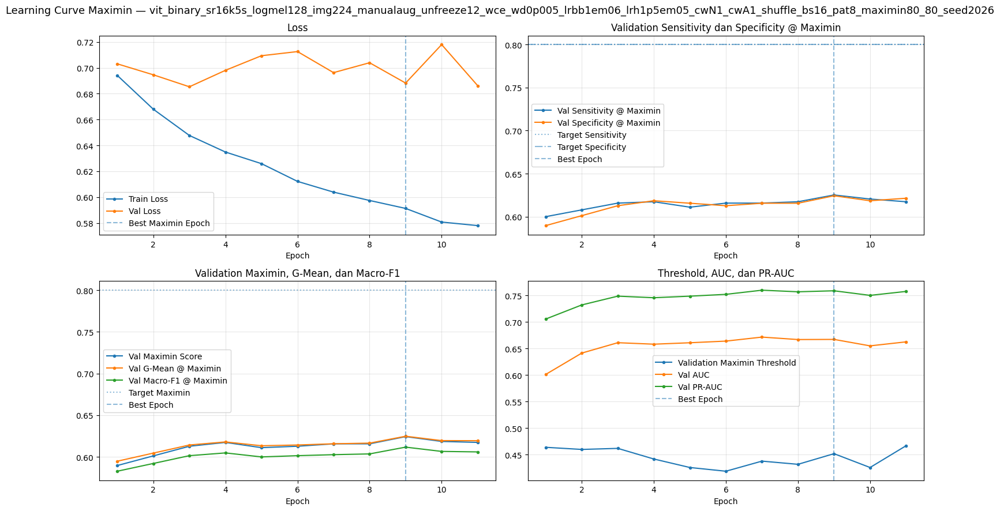

Learning curve disimpan di: checkpoints_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026_learning_curve.png

[OK] Training selesai. Checkpoint final dipilih berdasarkan val_maximin_score tertinggi dari validation set. Early stopping tetap berdasarkan validation loss.


In [ ]:
# ============================================================
# CELL: TRAINING LOOP + SAVE MODEL ViT-B/16 16k5s
# Checkpoint utama: validation maximin sensitivity-specificity
# val_maximin_score = min(sensitivity_abnormal, specificity_normal)
# Threshold dipilih HANYA dari validation set pada setiap epoch.
# Early stopping berdasarkan validation loss.
# ============================================================

import copy
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import confusion_matrix, f1_score


# ============================================================
# MONITOR CONFIG — FINAL
# ============================================================
# Best checkpoint dipilih berdasarkan validation Maximin.
CHECKPOINT_MONITOR = "val_maximin_score"
CHECKPOINT_MODE = "max"

# Early stopping menggunakan validation loss yang lebih smooth.
EARLY_STOPPING_MONITOR = "val_loss"
EARLY_STOPPING_MODE = "min"



# ============================================================
# 0. HELPER UMUM
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def json_safe_value(value):
    if isinstance(value, (np.integer,)):
        return int(value)

    if isinstance(value, (np.floating,)):
        value = float(value)
        return None if np.isnan(value) else value

    if isinstance(value, float):
        return None if np.isnan(value) else value

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, torch.Tensor):
        return value.detach().cpu().tolist()

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, dict):
        return {
            str(key): json_safe_value(item)
            for key, item in value.items()
        }

    if isinstance(value, (list, tuple)):
        return [json_safe_value(item) for item in value]

    return value


def json_safe_dict(data):
    return {
        str(key): json_safe_value(value)
        for key, value in data.items()
    }


def safe_float_or_nan(value):
    try:
        value = float(value)
        return np.nan if np.isnan(value) else value
    except Exception:
        return np.nan


def format_metric(value):
    try:
        value = float(value)
        return "nan" if np.isnan(value) else f"{value:.4f}"
    except Exception:
        return str(value)


def infer_monitor_mode(monitor_name):
    monitor_name = str(monitor_name).strip().lower()

    if monitor_name in {"val_loss", "train_loss"}:
        return "min"

    return "max"


def is_improved(current_value, best_value, mode, min_delta=0.0):
    current_value = float(current_value)
    best_value = float(best_value)
    min_delta = float(min_delta)

    if mode == "min":
        return current_value < (best_value - min_delta)

    if mode == "max":
        return current_value > (best_value + min_delta)

    raise ValueError(f"Mode monitor tidak valid: {mode}")


# ============================================================
# 1. VALIDASI GLOBAL WAJIB
# ============================================================

required_globals = [
    "model",
    "optimizer",
    "scheduler",
    "scaler",
    "criterion",
    "run_one_epoch",

    "train_loader",
    "val_loader",

    "DEVICE",
    "SAVE_DIR",
    "RESULT_DIR",
    "SCENARIO_NAME",

    "NUM_EPOCHS",
    "PATIENCE",
    "BATCH_SIZE",

    "label2id",
    "id2label",
    "NUM_CLASSES",
    "CLASSES",
    "LABEL_COL",

    "BEST_MODEL_PATH",
    "LAST_MODEL_PATH",
    "HISTORY_CSV_PATH",
    "LEARNING_CURVE_PATH",

    "LEARNING_RATE",
    "LR_BACKBONE",
    "LR_HEAD",
    "WEIGHT_DECAY",

    "ETA_MIN",
    "LOSS_NAME",
    "USE_CLASS_WEIGHT",
    "CLASS_WEIGHT_METHOD",

    "CHECKPOINT_MONITOR",
    "EARLY_STOPPING_MONITOR",
    "CHECKPOINT_MODE",
    "EARLY_STOPPING_MODE",

    "PRIMARY_THRESHOLD_METHOD",
    "TARGET_SENSITIVITY_ABNORMAL",
    "TARGET_SPECIFICITY_NORMAL",
    "THRESHOLD_MIN",
    "THRESHOLD_MAX",
    "THRESHOLD_STEP",

    "TARGET_SR",
    "TARGET_DURATION_SEC",
    "TARGET_LEN_SAMPLES",
    "N_MELS",
    "FMIN",
    "FMAX",
    "N_FFT",
    "HOP_LENGTH",
    "WIN_LENGTH",
    "IMAGE_SIZE",
]

missing_globals = [
    name for name in required_globals
    if name not in globals()
]

if missing_globals:
    raise RuntimeError(
        f"Global berikut belum tersedia: {missing_globals}\n"
        "Jalankan Global Configuration, metadata, DataLoader, "
        "dan Cell 35 Setup Model yang sudah diperbarui."
    )


# ============================================================
# 2. VALIDASI KONFIGURASI DASAR
# ============================================================

if LABEL_COL != "binary_label":
    raise ValueError(
        f"LABEL_COL harus 'binary_label'. Saat ini: {LABEL_COL}"
    )

if list(CLASSES) != ["normal", "abnormal"]:
    raise ValueError(
        "CLASSES harus ['normal', 'abnormal']. "
        f"Saat ini: {CLASSES}"
    )

if int(NUM_CLASSES) != 2:
    raise ValueError(
        f"NUM_CLASSES harus 2. Saat ini: {NUM_CLASSES}"
    )

POS_LABEL = str(globals().get("POS_LABEL", "abnormal"))
NEG_LABEL = str(globals().get("NEG_LABEL", "normal"))

POS_LABEL_ID = int(label2id[POS_LABEL])
NEG_LABEL_ID = int(label2id[NEG_LABEL])

if NEG_LABEL_ID != 0 or POS_LABEL_ID != 1:
    raise ValueError(
        "Mapping label salah. normal harus 0 dan abnormal harus 1. "
        f"Saat ini normal={NEG_LABEL_ID}, abnormal={POS_LABEL_ID}."
    )

if str(PRIMARY_THRESHOLD_METHOD).strip().lower() != "maximin":
    raise AssertionError(
        "PRIMARY_THRESHOLD_METHOD harus 'maximin'. "
        f"Saat ini: {PRIMARY_THRESHOLD_METHOD}"
    )

CHECKPOINT_MONITOR = str(CHECKPOINT_MONITOR).strip()
EARLY_STOPPING_MONITOR = str(EARLY_STOPPING_MONITOR).strip()
CHECKPOINT_MODE = str(CHECKPOINT_MODE).strip().lower()
EARLY_STOPPING_MODE = str(EARLY_STOPPING_MODE).strip().lower()

if CHECKPOINT_MONITOR != "val_maximin_score":
    raise AssertionError(
        "CHECKPOINT_MONITOR harus 'val_maximin_score'. "
        f"Saat ini: {CHECKPOINT_MONITOR}"
    )
if EARLY_STOPPING_MONITOR != "val_loss":
    raise AssertionError(
        "EARLY_STOPPING_MONITOR harus 'val_loss'. "
        f"Saat ini: {EARLY_STOPPING_MONITOR}"
    )

if EARLY_STOPPING_MODE != "min":
    raise AssertionError(
        "EARLY_STOPPING_MODE harus 'min'. "
        f"Saat ini: {EARLY_STOPPING_MODE}"
    )
if CHECKPOINT_MODE != "max":
    raise AssertionError(
        f"CHECKPOINT_MODE harus 'max'. Saat ini: {CHECKPOINT_MODE}"
    )


TARGET_SENSITIVITY_ABNORMAL = float(
    TARGET_SENSITIVITY_ABNORMAL
)
TARGET_SPECIFICITY_NORMAL = float(
    TARGET_SPECIFICITY_NORMAL
)

if not 0.0 <= TARGET_SENSITIVITY_ABNORMAL <= 1.0:
    raise ValueError(
        "TARGET_SENSITIVITY_ABNORMAL harus berada pada [0, 1]."
    )

if not 0.0 <= TARGET_SPECIFICITY_NORMAL <= 1.0:
    raise ValueError(
        "TARGET_SPECIFICITY_NORMAL harus berada pada [0, 1]."
    )

THRESHOLD_MIN = float(THRESHOLD_MIN)
THRESHOLD_MAX = float(THRESHOLD_MAX)
THRESHOLD_STEP = float(THRESHOLD_STEP)

if not (
    0.0 <= THRESHOLD_MIN
    < THRESHOLD_MAX
    <= 1.0
):
    raise ValueError(
        "Rentang threshold tidak valid: "
        f"{THRESHOLD_MIN} sampai {THRESHOLD_MAX}."
    )

if THRESHOLD_STEP <= 0:
    raise ValueError("THRESHOLD_STEP harus lebih besar dari 0.")

CHECKPOINT_MIN_DELTA = float(
    globals().get("CHECKPOINT_MIN_DELTA", 0.0)
)
EARLY_STOP_MIN_DELTA = float(
    globals().get("EARLY_STOP_MIN_DELTA", 1e-4)
)

if CHECKPOINT_MIN_DELTA < 0:
    raise ValueError("CHECKPOINT_MIN_DELTA tidak boleh negatif.")

if EARLY_STOP_MIN_DELTA < 0:
    raise ValueError("EARLY_STOP_MIN_DELTA tidak boleh negatif.")

PATIENCE = int(PATIENCE)

if PATIENCE < 1:
    raise ValueError("PATIENCE minimal 1.")


# ============================================================
# 3. AUDIT LOSS, OPTIMIZER, DAN SCHEDULER
# ============================================================

optimizer_name = optimizer.__class__.__name__
scheduler_name = (
    scheduler.__class__.__name__
    if scheduler is not None
    else "None"
)
scheduler_name_runtime = globals().get(
    "scheduler_name_runtime",
    scheduler_name,
)

criterion_runtime_name = globals().get(
    "criterion_runtime_name",
    criterion.__class__.__name__,
)

LOSS_NAME = str(LOSS_NAME).strip().lower()
CLASS_WEIGHT_METHOD = str(
    CLASS_WEIGHT_METHOD
).strip().lower()

if optimizer_name != "AdamW":
    raise AssertionError(
        f"Optimizer harus AdamW. Saat ini: {optimizer_name}"
    )

if LOSS_NAME != "weighted_ce":
    raise AssertionError(
        "Konfigurasi tahap ini menggunakan weighted_ce seimbang. "
        f"Saat ini LOSS_NAME={LOSS_NAME!r}."
    )

if not bool(USE_CLASS_WEIGHT):
    raise AssertionError(
        "USE_CLASS_WEIGHT harus True untuk weighted_ce."
    )

if criterion_runtime_name != "WeightedCrossEntropyLoss":
    raise AssertionError(
        "criterion_runtime_name harus WeightedCrossEntropyLoss. "
        f"Saat ini: {criterion_runtime_name}"
    )

criterion_weight_tensor = getattr(criterion, "weight", None)

if criterion_weight_tensor is None:
    raise AssertionError(
        "criterion.weight tidak boleh None untuk weighted_ce."
    )

criterion_weights_array = (
    criterion_weight_tensor
    .detach()
    .cpu()
    .numpy()
    .astype(float)
)

if criterion_weights_array.shape != (2,):
    raise AssertionError(
        "Criterion binary harus mempunyai dua bobot kelas. "
        f"Saat ini: {criterion_weights_array.tolist()}"
    )

NORMAL_WEIGHT = float(
    globals().get("NORMAL_WEIGHT", 1.0)
)
ABNORMAL_WEIGHT = float(
    globals().get("ABNORMAL_WEIGHT", 1.0)
)

expected_criterion_weights = np.array(
    [NORMAL_WEIGHT, ABNORMAL_WEIGHT],
    dtype=float,
)

if not np.allclose(
    criterion_weights_array,
    expected_criterion_weights,
    rtol=1e-5,
    atol=1e-7,
):
    raise AssertionError(
        "Bobot criterion tidak sama dengan Global Configuration.\n"
        f"Expected: {expected_criterion_weights.tolist()}\n"
        f"Actual  : {criterion_weights_array.tolist()}"
    )

criterion_weights_runtime = {
    "normal": float(criterion_weights_array[0]),
    "abnormal": float(criterion_weights_array[1]),
}

valid_scheduler_runtime = {
    "CosineAnnealingLR",
    "SequentialLR",
}

if scheduler_name not in valid_scheduler_runtime:
    raise AssertionError(
        "Scheduler runtime harus CosineAnnealingLR atau SequentialLR. "
        f"Saat ini: {scheduler_name}"
    )


# ============================================================
# 4. PATH OUTPUT DAN VALIDASI CHECKPOINT
# ============================================================

SAVE_DIR = Path(SAVE_DIR)
RESULT_DIR = Path(RESULT_DIR)
BEST_MODEL_PATH = Path(BEST_MODEL_PATH)
LAST_MODEL_PATH = Path(LAST_MODEL_PATH)
HISTORY_CSV_PATH = Path(HISTORY_CSV_PATH)
LEARNING_CURVE_PATH = Path(LEARNING_CURVE_PATH)

SAVE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

expected_best_suffix = "_best_val_maximin_score.pth"

if not BEST_MODEL_PATH.name.endswith(expected_best_suffix):
    raise AssertionError(
        "BEST_MODEL_PATH harus berakhiran "
        f"{expected_best_suffix!r}. Saat ini: {BEST_MODEL_PATH.name}"
    )

if BEST_MODEL_PATH.parent.resolve() != SAVE_DIR.resolve():
    raise AssertionError(
        "Parent BEST_MODEL_PATH harus sama dengan SAVE_DIR."
    )

if LAST_MODEL_PATH.parent.resolve() != SAVE_DIR.resolve():
    raise AssertionError(
        "Parent LAST_MODEL_PATH harus sama dengan SAVE_DIR."
    )

if SCENARIO_NAME not in BEST_MODEL_PATH.name:
    raise AssertionError(
        "Nama BEST_MODEL_PATH harus memuat SCENARIO_NAME."
    )

monitor_suffix = (
    CHECKPOINT_MONITOR
    .replace("val_", "")
    .replace("_", "")
)

BEST_SUMMARY_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_best_{monitor_suffix}_summary.json"
)

TRAINING_CONFIG_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_training_config.json"
)

TRAINING_FINAL_SUMMARY_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_training_final_summary.json"
)

BEST_MAXIMIN_SWEEP_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_best_validation_maximin_threshold_sweep.csv"
)

MAXIMIN_HISTORY_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_maximin_epoch_history.csv"
)


# ============================================================
# 5. METRIK BINARY PADA THRESHOLD TERTENTU
# ============================================================

def compute_binary_metrics_at_threshold(
    y_true,
    prob_abnormal,
    threshold,
):
    y_true = np.asarray(y_true, dtype=int).reshape(-1)
    prob_abnormal = np.asarray(
        prob_abnormal,
        dtype=float,
    ).reshape(-1)

    if len(y_true) == 0:
        raise ValueError("Data evaluasi kosong.")

    if len(y_true) != len(prob_abnormal):
        raise ValueError(
            "Jumlah label dan probabilitas tidak sama."
        )

    if not np.all(np.isfinite(prob_abnormal)):
        raise ValueError(
            "Probabilitas mengandung NaN atau Inf."
        )

    if np.any(prob_abnormal < 0.0) or np.any(prob_abnormal > 1.0):
        raise ValueError(
            "Probabilitas abnormal harus berada pada [0, 1]."
        )

    threshold = float(threshold)

    if not 0.0 <= threshold <= 1.0:
        raise ValueError("Threshold harus berada pada [0, 1].")

    y_pred = (
        prob_abnormal >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[NEG_LABEL_ID, POS_LABEL_ID],
    ).ravel()

    sensitivity = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)

    precision_abnormal = tp / max(tp + fp, 1)
    precision_normal = tn / max(tn + fn, 1)

    f1_abnormal = (
        2.0
        * precision_abnormal
        * sensitivity
        / max(
            precision_abnormal + sensitivity,
            1e-12,
        )
    )

    f1_normal = (
        2.0
        * precision_normal
        * specificity
        / max(
            precision_normal + specificity,
            1e-12,
        )
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=[NEG_LABEL_ID, POS_LABEL_ID],
        average="macro",
        zero_division=0,
    )

    accuracy = (
        tp + tn
    ) / max(tp + tn + fp + fn, 1)

    balanced_accuracy = (
        sensitivity + specificity
    ) / 2.0

    gmean = float(
        np.sqrt(
            max(sensitivity, 0.0)
            * max(specificity, 0.0)
        )
    )

    harmonic_score = (
        2.0
        * sensitivity
        * specificity
        / max(sensitivity + specificity, 1e-12)
    )

    maximin_score = min(
        sensitivity,
        specificity,
    )

    sensitivity_gap = abs(
        sensitivity - TARGET_SENSITIVITY_ABNORMAL
    )
    specificity_gap = abs(
        specificity - TARGET_SPECIFICITY_NORMAL
    )

    target_met = bool(
        sensitivity
        >= TARGET_SENSITIVITY_ABNORMAL
        and
        specificity
        >= TARGET_SPECIFICITY_NORMAL
    )

    return {
        "threshold": threshold,
        "accuracy": float(accuracy),
        "sensitivity_abnormal": float(sensitivity),
        "specificity_normal": float(specificity),
        "precision_abnormal": float(
            precision_abnormal
        ),
        "precision_normal": float(
            precision_normal
        ),
        "f1_abnormal": float(f1_abnormal),
        "f1_normal": float(f1_normal),
        "macro_f1": float(macro_f1),
        "balanced_accuracy": float(
            balanced_accuracy
        ),
        "icbhi_score": float(
            balanced_accuracy
        ),
        "gmean": float(gmean),
        "harmonic_score": float(
            harmonic_score
        ),
        "maximin_score": float(
            maximin_score
        ),
        "sensitivity_target_gap": float(
            sensitivity_gap
        ),
        "specificity_target_gap": float(
            specificity_gap
        ),
        "target_met": target_met,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "y_pred": y_pred,
    }


def select_maximin_operating_point(
    y_true,
    prob_abnormal,
    threshold_min=THRESHOLD_MIN,
    threshold_max=THRESHOLD_MAX,
    threshold_step=THRESHOLD_STEP,
):
    """
    Memilih threshold hanya dari validation set.

    Prioritas:
    1. val_maximin_score tertinggi;
    2. G-Mean tertinggi;
    3. macro-F1 tertinggi;
    4. balanced accuracy tertinggi;
    5. selisih sensitivity-specificity terkecil;
    6. threshold terdekat ke 0.50.

    TARGET 0.80/0.80 dicatat sebagai audit. Target tidak
    digunakan untuk memaksa threshold yang merusak keseimbangan.
    """

    threshold_values = np.arange(
        float(threshold_min),
        float(threshold_max)
        + (float(threshold_step) * 0.5),
        float(threshold_step),
    )

    threshold_values = np.clip(
        threshold_values,
        0.0,
        1.0,
    )

    rows = []

    for threshold in threshold_values:
        metrics = compute_binary_metrics_at_threshold(
            y_true=y_true,
            prob_abnormal=prob_abnormal,
            threshold=float(threshold),
        )

        rows.append({
            key: value
            for key, value in metrics.items()
            if key != "y_pred"
        })

    if not rows:
        raise RuntimeError(
            "Threshold sweep tidak menghasilkan kandidat."
        )

    def selection_key(row):
        return (
            float(row["maximin_score"]),
            float(row["gmean"]),
            float(row["macro_f1"]),
            float(row["balanced_accuracy"]),
            -abs(
                float(row["sensitivity_abnormal"])
                - float(row["specificity_normal"])
            ),
            -abs(float(row["threshold"]) - 0.50),
        )

    best_row = max(
        rows,
        key=selection_key,
    )

    best_metrics = compute_binary_metrics_at_threshold(
        y_true=y_true,
        prob_abnormal=prob_abnormal,
        threshold=best_row["threshold"],
    )

    sweep_df = pd.DataFrame(rows)

    return best_metrics, sweep_df


def checkpoint_selection_key(
    maximin_metrics,
    val_loss,
):
    """
    val_maximin_score adalah metrik primer.

    Tie-break hanya digunakan ketika score sama:
    G-Mean -> macro-F1 -> balanced accuracy -> val loss.
    """

    return (
        float(maximin_metrics["maximin_score"]),
        float(maximin_metrics["gmean"]),
        float(maximin_metrics["macro_f1"]),
        float(maximin_metrics["balanced_accuracy"]),
        -float(val_loss),
    )


# ============================================================
# 6. KONFIGURASI CHECKPOINT DAN EARLY STOPPING
# ============================================================

CHECKPOINT_SELECTION_POLICY = (
    "maximum_validation_maximin_score"
)

SAVE_BEST_BY = str(
    globals().get(
        "SAVE_BEST_BY",
        "maximum_validation_maximin_score",
    )
)

if SAVE_BEST_BY != "maximum_validation_maximin_score":
    raise AssertionError(
        "SAVE_BEST_BY harus "
        "'maximum_validation_maximin_score'. "
        f"Saat ini: {SAVE_BEST_BY}"
    )

VALID_MONITORS = {
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "val_gmean",
    "val_auc",
    "val_pr_auc",
    "val_maximin_score",
}

if CHECKPOINT_MONITOR not in VALID_MONITORS:
    raise AssertionError(
        f"CHECKPOINT_MONITOR tidak valid: {CHECKPOINT_MONITOR}"
    )

if EARLY_STOPPING_MONITOR not in VALID_MONITORS:
    raise AssertionError(
        "EARLY_STOPPING_MONITOR tidak valid: "
        f"{EARLY_STOPPING_MONITOR}"
    )

if infer_monitor_mode(CHECKPOINT_MONITOR) != CHECKPOINT_MODE:
    raise AssertionError(
        "Mode checkpoint tidak sesuai monitor."
    )

if infer_monitor_mode(EARLY_STOPPING_MONITOR) != EARLY_STOPPING_MODE:
    raise AssertionError(
        "Mode early stopping tidak sesuai monitor."
    )


# ============================================================
# 7. SIMPAN KONFIGURASI TRAINING
# ============================================================

MODEL_FAMILY = globals().get(
    "MODEL_FAMILY",
    "ViT-only",
)
MODEL_NAME = globals().get(
    "MODEL_NAME",
    "ViT-B/16",
)
MODEL_CLAIM = globals().get(
    "MODEL_CLAIM",
    "ViT-only adaptation using Log-Mel spectrogram images.",
)

CLASS_WEIGHT_METHOD_EFFECTIVE = globals().get(
    "CLASS_WEIGHT_METHOD_EFFECTIVE",
    CLASS_WEIGHT_METHOD,
)

training_started_at = time.strftime(
    "%Y-%m-%d %H:%M:%S"
)

training_config = {
    "scenario_name": SCENARIO_NAME,
    "model_family": MODEL_FAMILY,
    "model_name": MODEL_NAME,
    "model_claim": MODEL_CLAIM,

    "classes": list(CLASSES),
    "label_col": LABEL_COL,
    "positive_label": POS_LABEL,
    "negative_label": NEG_LABEL,

    "loss_name": LOSS_NAME,
    "criterion_runtime": criterion_runtime_name,
    "criterion_weights_runtime": (
        criterion_weights_runtime
    ),
    "class_weight_method": CLASS_WEIGHT_METHOD,
    "class_weight_method_effective": (
        CLASS_WEIGHT_METHOD_EFFECTIVE
    ),

    "optimizer": optimizer_name,
    "learning_rate": float(LEARNING_RATE),
    "lr_backbone": float(LR_BACKBONE),
    "lr_head": float(LR_HEAD),
    "weight_decay": float(WEIGHT_DECAY),

    "scheduler": scheduler_name_runtime,
    "scheduler_runtime_class": scheduler_name,
    "eta_min": float(ETA_MIN),

    "num_epochs": int(NUM_EPOCHS),
    "batch_size": int(BATCH_SIZE),
    "patience": int(PATIENCE),

    "checkpoint_monitor": CHECKPOINT_MONITOR,
    "checkpoint_mode": CHECKPOINT_MODE,
    "checkpoint_min_delta": float(
        CHECKPOINT_MIN_DELTA
    ),
    "checkpoint_selection_policy": (
        CHECKPOINT_SELECTION_POLICY
    ),
    "checkpoint_selection_rule": (
        "maximize_validation_min_"
        "sensitivity_specificity"
    ),

    "early_stopping_monitor": (
        EARLY_STOPPING_MONITOR
    ),
    "early_stopping_mode": (
        EARLY_STOPPING_MODE
    ),
    "early_stop_min_delta": float(
        EARLY_STOP_MIN_DELTA
    ),

    "primary_threshold_method": "maximin",
    "threshold_selection_scope": (
        "validation_only_each_epoch"
    ),
    "threshold_min": float(THRESHOLD_MIN),
    "threshold_max": float(THRESHOLD_MAX),
    "threshold_step": float(THRESHOLD_STEP),

    "target_sensitivity_abnormal": float(
        TARGET_SENSITIVITY_ABNORMAL
    ),
    "target_specificity_normal": float(
        TARGET_SPECIFICITY_NORMAL
    ),

    "target_sr": int(TARGET_SR),
    "target_duration_sec": float(
        TARGET_DURATION_SEC
    ),
    "target_len_samples": int(
        TARGET_LEN_SAMPLES
    ),
    "n_mels": int(N_MELS),
    "fmin": int(FMIN),
    "fmax": int(FMAX),
    "n_fft": int(N_FFT),
    "hop_length": int(HOP_LENGTH),
    "win_length": int(WIN_LENGTH),
    "image_size": int(IMAGE_SIZE),

    "best_model_path": str(BEST_MODEL_PATH),
    "last_model_path": str(LAST_MODEL_PATH),
    "history_csv_path": str(
        HISTORY_CSV_PATH
    ),
    "learning_curve_path": str(
        LEARNING_CURVE_PATH
    ),
    "best_maximin_sweep_path": str(
        BEST_MAXIMIN_SWEEP_PATH
    ),

    "training_started_at": training_started_at,
}

with open(
    TRAINING_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        json_safe_dict(training_config),
        file,
        indent=2,
        ensure_ascii=False,
    )


# ============================================================
# 8. HELPER CHECKPOINT
# ============================================================

def save_checkpoint(
    path,
    epoch,
    model,
    optimizer,
    scheduler,
    scaler,
    history,
    extra_payload=None,
):
    payload = {
        "epoch": int(epoch),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": (
            scheduler.state_dict()
            if scheduler is not None
            else None
        ),
        "scaler_state_dict": (
            scaler.state_dict()
            if scaler is not None
            else None
        ),
        "history": history,

        "scenario": SCENARIO_NAME,
        "model_family": MODEL_FAMILY,
        "model_name": MODEL_NAME,
        "model_claim": MODEL_CLAIM,

        "classes": list(CLASSES),
        "label2id": label2id,
        "id2label": id2label,
        "label_col": LABEL_COL,
        "pos_label": POS_LABEL,
        "neg_label": NEG_LABEL,

        "checkpoint_monitor": CHECKPOINT_MONITOR,
        "checkpoint_mode": CHECKPOINT_MODE,
        "checkpoint_min_delta": float(
            CHECKPOINT_MIN_DELTA
        ),
        "checkpoint_selection_policy": (
            CHECKPOINT_SELECTION_POLICY
        ),
        "checkpoint_selection_rule": (
            "maximize_validation_min_"
            "sensitivity_specificity"
        ),

        "early_stopping_monitor": (
            EARLY_STOPPING_MONITOR
        ),
        "early_stopping_mode": (
            EARLY_STOPPING_MODE
        ),
        "early_stop_min_delta": float(
            EARLY_STOP_MIN_DELTA
        ),

        "primary_threshold_method": "maximin",
        "threshold_selection_scope": (
            "validation_only_each_epoch"
        ),
        "threshold_min": float(THRESHOLD_MIN),
        "threshold_max": float(THRESHOLD_MAX),
        "threshold_step": float(THRESHOLD_STEP),

        "target_sensitivity_abnormal": float(
            TARGET_SENSITIVITY_ABNORMAL
        ),
        "target_specificity_normal": float(
            TARGET_SPECIFICITY_NORMAL
        ),

        "loss_name": LOSS_NAME,
        "criterion_runtime": (
            criterion_runtime_name
        ),
        "class_weight_method": (
            CLASS_WEIGHT_METHOD
        ),
        "class_weight_method_effective": (
            CLASS_WEIGHT_METHOD_EFFECTIVE
        ),
        "criterion_weights": (
            criterion_weights_runtime
        ),

        "optimizer": optimizer_name,
        "learning_rate": float(LEARNING_RATE),
        "lr_backbone": float(LR_BACKBONE),
        "lr_head": float(LR_HEAD),
        "weight_decay": float(WEIGHT_DECAY),

        "scheduler": scheduler_name_runtime,
        "scheduler_runtime_class": (
            scheduler_name
        ),
        "eta_min": float(ETA_MIN),

        "num_epochs": int(NUM_EPOCHS),
        "patience": int(PATIENCE),
    }

    optional_globals = {
        "class_weights_list": "CLASS_WEIGHTS_LIST",
        "class_weights_used_dict": (
            "CLASS_WEIGHTS_USED_DICT"
        ),
        "auto_class_weights_audit_only": (
            "AUTO_CLASS_WEIGHTS"
        ),
        "optimizer_group_report": (
            "optimizer_group_report_df"
        ),
    }

    for payload_key, global_key in optional_globals.items():
        if global_key not in globals():
            continue

        value = globals()[global_key]

        if isinstance(value, pd.DataFrame):
            value = value.to_dict(
                orient="records"
            )

        payload[payload_key] = value

    if extra_payload:
        payload.update(extra_payload)

    torch.save(
        payload,
        str(path),
    )


# ============================================================
# 9. INFO AWAL TRAINING
# ============================================================

print("=" * 100)
print("TRAINING ViT-B/16 — VALIDATION MAXIMIN CHECKPOINT")
print("=" * 100)
print("Scenario                    :", SCENARIO_NAME)
print("Device                      :", DEVICE)
print("Epoch maksimum              :", NUM_EPOCHS)
print("Patience                    :", PATIENCE)
print("Loss                        :", criterion_runtime_name)
print("Criterion weights           :", criterion_weights_runtime)
print("Optimizer                   :", optimizer_name)
print("Scheduler                   :", scheduler_name_runtime)
print("Weight decay                :", WEIGHT_DECAY)
print("Checkpoint monitor          :", CHECKPOINT_MONITOR)
print("Checkpoint mode             :", CHECKPOINT_MODE)
print("Early stopping monitor      :", EARLY_STOPPING_MONITOR)
print("Early stopping mode         :", EARLY_STOPPING_MODE)
print("Primary threshold method    : maximin")
print(
    "Target sensitivity          :",
    TARGET_SENSITIVITY_ABNORMAL,
)
print(
    "Target specificity          :",
    TARGET_SPECIFICITY_NORMAL,
)
print(
    "Threshold grid              :",
    THRESHOLD_MIN,
    THRESHOLD_MAX,
    THRESHOLD_STEP,
)
print("Best model path             :", BEST_MODEL_PATH)
print("Last model path             :", LAST_MODEL_PATH)
print("=" * 100)


# ============================================================
# 10. INIT BEST STATE
# ============================================================

best_epoch = 0
best_checkpoint_value = -float("inf")
best_checkpoint_key = None
best_metrics = {}
best_validation_sweep_df = None

best_early_stop_value = float("inf")
epochs_no_improve = 0

history = []

training_started_monotonic = time.time()


# ============================================================
# 11. TRAINING LOOP
# ============================================================

for epoch in range(int(NUM_EPOCHS)):
    epoch_start = time.time()

    current_lrs = [
        float(group["lr"])
        for group in optimizer.param_groups
    ]

    current_lr_min = min(current_lrs)
    current_lr_max = max(current_lrs)

    head_lr_values = [
        float(group["lr"])
        for group in optimizer.param_groups
        if group.get("name", "")
        == "classification_head"
    ]

    current_lr_head = (
        head_lr_values[0]
        if len(head_lr_values) == 1
        else current_lrs[-1]
    )

    print(f"\n{'=' * 100}")
    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"lr_min={current_lr_min:.3e} | "
        f"lr_max={current_lr_max:.3e} | "
        f"lr_head={current_lr_head:.3e}"
    )
    print("=" * 100)

    train_metrics = run_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=DEVICE,
    )

    val_metrics_raw = run_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        optimizer=None,
        scaler=None,
        device=DEVICE,
    )

    if scheduler is not None:
        scheduler.step()

    required_probability_keys = {
        "y_true",
        "y_prob_abnormal",
    }

    missing_probability_keys = (
        required_probability_keys
        - set(val_metrics_raw)
    )

    if missing_probability_keys:
        raise KeyError(
            "run_one_epoch validation belum mengembalikan "
            f"{sorted(missing_probability_keys)}. "
            "Jalankan Cell 35 yang sudah diperbarui."
        )

    val_maximin_metrics, val_threshold_sweep_df = (
        select_maximin_operating_point(
            y_true=val_metrics_raw["y_true"],
            prob_abnormal=(
                val_metrics_raw[
                    "y_prob_abnormal"
                ]
            ),
        )
    )

    # Audit train menggunakan threshold validation yang sama.
    train_at_val_threshold = (
        compute_binary_metrics_at_threshold(
            y_true=train_metrics["y_true"],
            prob_abnormal=(
                train_metrics[
                    "y_prob_abnormal"
                ]
            ),
            threshold=(
                val_maximin_metrics[
                    "threshold"
                ]
            ),
        )
    )

    val_loss = float(
        val_metrics_raw["loss"]
    )

    val_auc = safe_float_or_nan(
        val_metrics_raw.get("auc", np.nan)
    )
    val_pr_auc = safe_float_or_nan(
        val_metrics_raw.get("pr_auc", np.nan)
    )

    val_maximin_score = float(
        val_maximin_metrics["maximin_score"]
    )

    current_checkpoint_value = (
        val_maximin_score
    )
    current_early_stop_value = val_loss

    train_macro_f1_raw = safe_float_or_nan(
        train_metrics.get(
            "macro_f1",
            train_metrics.get(
                "binary_macro_f1",
                np.nan,
            ),
        )
    )

    val_macro_f1_raw = safe_float_or_nan(
        val_metrics_raw.get(
            "macro_f1",
            val_metrics_raw.get(
                "binary_macro_f1",
                np.nan,
            ),
        )
    )

    macro_f1_gap_raw = float(
        train_macro_f1_raw
        - val_macro_f1_raw
    )

    accuracy_gap_raw = float(
        train_metrics.get(
            "accuracy",
            train_metrics["acc"],
        )
        - val_metrics_raw.get(
            "accuracy",
            val_metrics_raw["acc"],
        )
    )

    loss_gap = float(
        val_loss - float(train_metrics["loss"])
    )

    epoch_time = time.time() - epoch_start

    metric_row = {
        "val_loss": val_loss,
        "val_accuracy": float(
            val_maximin_metrics["accuracy"]
        ),
        "val_macro_f1": float(
            val_maximin_metrics["macro_f1"]
        ),
        "val_gmean": float(
            val_maximin_metrics["gmean"]
        ),
        "val_auc": val_auc,
        "val_pr_auc": val_pr_auc,
        "val_maximin_score": (
            val_maximin_score
        ),
    }

    print(
        "Train raw@0.50 | "
        f"loss:{train_metrics['loss']:.4f}  "
        f"acc:{train_metrics['acc']:.4f}  "
        f"sens:{train_metrics['sensitivity_abnormal']:.4f}  "
        f"spec:{train_metrics['specificity_normal']:.4f}  "
        f"macro_f1:{train_macro_f1_raw:.4f}"
    )

    print(
        "Val raw@0.50   | "
        f"loss:{val_loss:.4f}  "
        f"acc:{val_metrics_raw['acc']:.4f}  "
        f"sens:{val_metrics_raw['sensitivity_abnormal']:.4f}  "
        f"spec:{val_metrics_raw['specificity_normal']:.4f}  "
        f"macro_f1:{val_macro_f1_raw:.4f}"
    )

    print(
        "Val maximin    | "
        f"threshold:{val_maximin_metrics['threshold']:.3f}  "
        f"sens:{val_maximin_metrics['sensitivity_abnormal']:.4f}  "
        f"spec:{val_maximin_metrics['specificity_normal']:.4f}  "
        f"maximin:{val_maximin_score:.4f}  "
        f"gmean:{val_maximin_metrics['gmean']:.4f}  "
        f"macro_f1:{val_maximin_metrics['macro_f1']:.4f}  "
        f"target_80_80:{val_maximin_metrics['target_met']}"
    )

    print(
        "Val maximin CM | "
        f"TN:{val_maximin_metrics['tn']}  "
        f"FP:{val_maximin_metrics['fp']}  "
        f"FN:{val_maximin_metrics['fn']}  "
        f"TP:{val_maximin_metrics['tp']}"
    )

    print(
        "Monitor        | "
        f"{CHECKPOINT_MONITOR}:"
        f"{current_checkpoint_value:.4f}  "
        f"| {EARLY_STOPPING_MONITOR}:"
        f"{current_early_stop_value:.4f}  "
        f"| {epoch_time:.1f}s"
    )

    row_history = {
        "epoch": int(epoch + 1),

        "lr_min": float(current_lr_min),
        "lr_max": float(current_lr_max),
        "lr_head": float(current_lr_head),
        "lr_groups": json.dumps(
            current_lrs
        ),

        "train_loss": float(
            train_metrics["loss"]
        ),
        "train_acc_raw_050": float(
            train_metrics["acc"]
        ),
        "train_sensitivity_raw_050": float(
            train_metrics[
                "sensitivity_abnormal"
            ]
        ),
        "train_specificity_raw_050": float(
            train_metrics[
                "specificity_normal"
            ]
        ),
        "train_macro_f1_raw_050": float(
            train_macro_f1_raw
        ),
        "train_auc": safe_float_or_nan(
            train_metrics.get("auc", np.nan)
        ),
        "train_pr_auc": safe_float_or_nan(
            train_metrics.get(
                "pr_auc",
                np.nan,
            )
        ),

        "train_at_val_threshold": float(
            val_maximin_metrics["threshold"]
        ),
        "train_sensitivity_at_val_threshold": float(
            train_at_val_threshold[
                "sensitivity_abnormal"
            ]
        ),
        "train_specificity_at_val_threshold": float(
            train_at_val_threshold[
                "specificity_normal"
            ]
        ),
        "train_maximin_at_val_threshold": float(
            train_at_val_threshold[
                "maximin_score"
            ]
        ),
        "train_macro_f1_at_val_threshold": float(
            train_at_val_threshold[
                "macro_f1"
            ]
        ),

        "val_loss": val_loss,
        "val_acc_raw_050": float(
            val_metrics_raw["acc"]
        ),
        "val_sensitivity_raw_050": float(
            val_metrics_raw[
                "sensitivity_abnormal"
            ]
        ),
        "val_specificity_raw_050": float(
            val_metrics_raw[
                "specificity_normal"
            ]
        ),
        "val_macro_f1_raw_050": float(
            val_macro_f1_raw
        ),

        "val_maximin_threshold": float(
            val_maximin_metrics[
                "threshold"
            ]
        ),
        "val_sensitivity_at_maximin": float(
            val_maximin_metrics[
                "sensitivity_abnormal"
            ]
        ),
        "val_specificity_at_maximin": float(
            val_maximin_metrics[
                "specificity_normal"
            ]
        ),
        "val_maximin_score": float(
            val_maximin_score
        ),
        "val_accuracy_at_maximin": float(
            val_maximin_metrics[
                "accuracy"
            ]
        ),
        "val_balanced_accuracy_at_maximin": float(
            val_maximin_metrics[
                "balanced_accuracy"
            ]
        ),
        "val_gmean_at_maximin": float(
            val_maximin_metrics["gmean"]
        ),
        "val_harmonic_at_maximin": float(
            val_maximin_metrics[
                "harmonic_score"
            ]
        ),
        "val_macro_f1_at_maximin": float(
            val_maximin_metrics[
                "macro_f1"
            ]
        ),
        "val_f1_normal_at_maximin": float(
            val_maximin_metrics[
                "f1_normal"
            ]
        ),
        "val_f1_abnormal_at_maximin": float(
            val_maximin_metrics[
                "f1_abnormal"
            ]
        ),
        "val_target_80_80_met": bool(
            val_maximin_metrics[
                "target_met"
            ]
        ),
        "val_auc": val_auc,
        "val_pr_auc": val_pr_auc,

        "val_tn_at_maximin": int(
            val_maximin_metrics["tn"]
        ),
        "val_fp_at_maximin": int(
            val_maximin_metrics["fp"]
        ),
        "val_fn_at_maximin": int(
            val_maximin_metrics["fn"]
        ),
        "val_tp_at_maximin": int(
            val_maximin_metrics["tp"]
        ),

        "checkpoint_monitor": (
            CHECKPOINT_MONITOR
        ),
        "checkpoint_monitor_value": float(
            current_checkpoint_value
        ),
        "early_stopping_monitor": (
            EARLY_STOPPING_MONITOR
        ),
        "early_stopping_monitor_value": float(
            current_early_stop_value
        ),

        "macro_f1_gap_raw_050": float(
            macro_f1_gap_raw
        ),
        "accuracy_gap_raw_050": float(
            accuracy_gap_raw
        ),
        "loss_gap": float(loss_gap),

        "epoch_time_sec": float(
            epoch_time
        ),
    }

    history.append(row_history)

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(
        HISTORY_CSV_PATH,
        index=False,
    )
    hist_df.to_csv(
        MAXIMIN_HISTORY_PATH,
        index=False,
    )

    save_checkpoint(
        path=LAST_MODEL_PATH,
        epoch=epoch + 1,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        history=history,
        extra_payload={
            "checkpoint_type": "last",
            "last_epoch_val_loss": val_loss,
            "last_epoch_val_maximin_score": (
                val_maximin_score
            ),
            "last_epoch_validation_threshold": float(
                val_maximin_metrics[
                    "threshold"
                ]
            ),
            "last_epoch_val_sensitivity_abnormal": float(
                val_maximin_metrics[
                    "sensitivity_abnormal"
                ]
            ),
            "last_epoch_val_specificity_normal": float(
                val_maximin_metrics[
                    "specificity_normal"
                ]
            ),
            "last_epoch_val_target_80_80_met": bool(
                val_maximin_metrics[
                    "target_met"
                ]
            ),
        },
    )

    current_key = checkpoint_selection_key(
        maximin_metrics=val_maximin_metrics,
        val_loss=val_loss,
    )

    if best_checkpoint_key is None:
        checkpoint_improved = True
    else:
        maximin_delta = (
            current_checkpoint_value
            - best_checkpoint_value
        )

        if maximin_delta > CHECKPOINT_MIN_DELTA:
            checkpoint_improved = True
        elif abs(maximin_delta) <= CHECKPOINT_MIN_DELTA:
            checkpoint_improved = (
                current_key
                > best_checkpoint_key
            )
        else:
            checkpoint_improved = False

    if checkpoint_improved:
        best_epoch = int(epoch + 1)
        best_checkpoint_value = float(
            current_checkpoint_value
        )
        best_checkpoint_key = tuple(
            current_key
        )
        best_validation_sweep_df = (
            val_threshold_sweep_df.copy()
        )

        best_metrics = {
            "best_epoch": int(best_epoch),
            "best_monitor": (
                CHECKPOINT_MONITOR
            ),
            "best_monitor_value": float(
                best_checkpoint_value
            ),
            "best_val_maximin_score": float(
                val_maximin_score
            ),
            "best_validation_threshold": float(
                val_maximin_metrics[
                    "threshold"
                ]
            ),
            "best_val_sensitivity_abnormal": float(
                val_maximin_metrics[
                    "sensitivity_abnormal"
                ]
            ),
            "best_val_specificity_normal": float(
                val_maximin_metrics[
                    "specificity_normal"
                ]
            ),
            "best_val_accuracy": float(
                val_maximin_metrics[
                    "accuracy"
                ]
            ),
            "best_val_balanced_accuracy": float(
                val_maximin_metrics[
                    "balanced_accuracy"
                ]
            ),
            "best_val_gmean": float(
                val_maximin_metrics[
                    "gmean"
                ]
            ),
            "best_val_harmonic_score": float(
                val_maximin_metrics[
                    "harmonic_score"
                ]
            ),
            "best_val_macro_f1": float(
                val_maximin_metrics[
                    "macro_f1"
                ]
            ),
            "best_val_f1_normal": float(
                val_maximin_metrics[
                    "f1_normal"
                ]
            ),
            "best_val_f1_abnormal": float(
                val_maximin_metrics[
                    "f1_abnormal"
                ]
            ),
            "best_val_precision_normal": float(
                val_maximin_metrics[
                    "precision_normal"
                ]
            ),
            "best_val_precision_abnormal": float(
                val_maximin_metrics[
                    "precision_abnormal"
                ]
            ),
            "best_val_target_80_80_met": bool(
                val_maximin_metrics[
                    "target_met"
                ]
            ),
            "best_val_loss": float(
                val_loss
            ),
            "best_val_auc": val_auc,
            "best_val_pr_auc": val_pr_auc,

            "best_val_tn": int(
                val_maximin_metrics["tn"]
            ),
            "best_val_fp": int(
                val_maximin_metrics["fp"]
            ),
            "best_val_fn": int(
                val_maximin_metrics["fn"]
            ),
            "best_val_tp": int(
                val_maximin_metrics["tp"]
            ),

            "best_val_raw_050_accuracy": float(
                val_metrics_raw["acc"]
            ),
            "best_val_raw_050_sensitivity": float(
                val_metrics_raw[
                    "sensitivity_abnormal"
                ]
            ),
            "best_val_raw_050_specificity": float(
                val_metrics_raw[
                    "specificity_normal"
                ]
            ),
            "best_val_raw_050_macro_f1": float(
                val_macro_f1_raw
            ),

            "best_epoch_train_loss": float(
                train_metrics["loss"]
            ),
            "best_epoch_train_macro_f1_raw_050": float(
                train_macro_f1_raw
            ),
            "best_epoch_macro_f1_gap_raw_050": float(
                macro_f1_gap_raw
            ),
            "best_epoch_accuracy_gap_raw_050": float(
                accuracy_gap_raw
            ),
            "best_epoch_loss_gap": float(
                loss_gap
            ),
        }

        save_checkpoint(
            path=BEST_MODEL_PATH,
            epoch=epoch + 1,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            history=history,
            extra_payload={
                "checkpoint_type": (
                    "best_val_maximin_score"
                ),
                "selection_rule": (
                    "maximum_validation_"
                    "maximin_score"
                ),
                "used_as_final_model": True,
                **best_metrics,
            },
        )

        best_validation_sweep_df.to_csv(
            BEST_MAXIMIN_SWEEP_PATH,
            index=False,
        )

        best_summary = {
            "scenario": SCENARIO_NAME,
            "checkpoint_type": (
                "best_val_maximin_score"
            ),
            "selection_rule": (
                "maximum_validation_"
                "maximin_score"
            ),
            "checkpoint_monitor": (
                CHECKPOINT_MONITOR
            ),
            "checkpoint_mode": (
                CHECKPOINT_MODE
            ),
            "target_sensitivity_abnormal": float(
                TARGET_SENSITIVITY_ABNORMAL
            ),
            "target_specificity_normal": float(
                TARGET_SPECIFICITY_NORMAL
            ),
            "best_model_path": str(
                BEST_MODEL_PATH
            ),
            "best_maximin_sweep_path": str(
                BEST_MAXIMIN_SWEEP_PATH
            ),
            **best_metrics,
        }

        with open(
            BEST_SUMMARY_PATH,
            "w",
            encoding="utf-8",
        ) as file:
            json.dump(
                json_safe_dict(best_summary),
                file,
                indent=2,
                ensure_ascii=False,
            )

        print(
            "  [BEST] Checkpoint maximin diperbarui | "
            f"epoch={best_epoch} | "
            f"score={best_checkpoint_value:.4f} | "
            f"threshold={best_metrics['best_validation_threshold']:.3f} | "
            f"sens={best_metrics['best_val_sensitivity_abnormal']:.4f} | "
            f"spec={best_metrics['best_val_specificity_normal']:.4f} | "
            f"target_80_80={best_metrics['best_val_target_80_80_met']}"
        )

    early_stop_improved = is_improved(
        current_value=current_early_stop_value,
        best_value=best_early_stop_value,
        mode=EARLY_STOPPING_MODE,
        min_delta=EARLY_STOP_MIN_DELTA,
    )

    if early_stop_improved:
        best_early_stop_value = float(
            current_early_stop_value
        )
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

        print(
            f"  [--] {EARLY_STOPPING_MONITOR} tidak membaik | "
            f"current={current_early_stop_value:.4f} | "
            f"best={best_early_stop_value:.4f} | "
            f"counter={epochs_no_improve}/{PATIENCE}"
        )

    if epochs_no_improve >= PATIENCE:
        print(
            f"\nEarly stopping aktif pada epoch {epoch + 1}. "
            f"{EARLY_STOPPING_MONITOR} tidak membaik "
            f"selama {PATIENCE} epoch."
        )
        break


# ============================================================
# 12. LOAD BEST MODEL
# ============================================================

if not history:
    raise RuntimeError(
        "Training tidak menghasilkan history."
    )

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        "Best checkpoint tidak ditemukan: "
        f"{BEST_MODEL_PATH}"
    )

try:
    best_checkpoint = torch.load(
        str(BEST_MODEL_PATH),
        map_location=DEVICE,
        weights_only=False,
    )
except TypeError:
    best_checkpoint = torch.load(
        str(BEST_MODEL_PATH),
        map_location=DEVICE,
    )

if not isinstance(best_checkpoint, dict):
    raise RuntimeError(
        "Format best checkpoint tidak valid."
    )

if "model_state_dict" not in best_checkpoint:
    raise KeyError(
        "Best checkpoint tidak memiliki model_state_dict."
    )

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)
model = model.to(DEVICE)
model.eval()

best_epoch = int(
    best_checkpoint.get(
        "best_epoch",
        best_checkpoint.get("epoch", best_epoch),
    )
)

best_checkpoint_value = float(
    best_checkpoint.get(
        "best_val_maximin_score",
        best_checkpoint.get(
            "best_monitor_value",
            best_checkpoint_value,
        ),
    )
)

training_finished_at = time.strftime(
    "%Y-%m-%d %H:%M:%S"
)
training_duration_sec = (
    time.time()
    - training_started_monotonic
)


# ============================================================
# 13. RINGKASAN TRAINING
# ============================================================

hist_df = pd.DataFrame(history)

final_summary = {
    "scenario": SCENARIO_NAME,
    "training_started_at": (
        training_started_at
    ),
    "training_finished_at": (
        training_finished_at
    ),
    "training_duration_sec": float(
        training_duration_sec
    ),
    "total_epoch_ran": int(len(history)),

    "checkpoint_monitor": (
        CHECKPOINT_MONITOR
    ),
    "checkpoint_mode": CHECKPOINT_MODE,
    "checkpoint_selection_policy": (
        CHECKPOINT_SELECTION_POLICY
    ),
    "selection_rule": (
        "maximum_validation_maximin_score"
    ),

    "early_stopping_monitor": (
        EARLY_STOPPING_MONITOR
    ),
    "early_stopping_mode": (
        EARLY_STOPPING_MODE
    ),
    "early_stop_min_delta": float(
        EARLY_STOP_MIN_DELTA
    ),
    "patience": int(PATIENCE),

    "primary_threshold_method": "maximin",
    "threshold_selection_scope": (
        "validation_only_each_epoch"
    ),
    "target_sensitivity_abnormal": float(
        TARGET_SENSITIVITY_ABNORMAL
    ),
    "target_specificity_normal": float(
        TARGET_SPECIFICITY_NORMAL
    ),

    "loss_name": LOSS_NAME,
    "criterion_runtime": (
        criterion_runtime_name
    ),
    "class_weight_method": (
        CLASS_WEIGHT_METHOD
    ),
    "class_weight_method_effective": (
        CLASS_WEIGHT_METHOD_EFFECTIVE
    ),
    "criterion_weights": (
        criterion_weights_runtime
    ),

    "weight_decay": float(WEIGHT_DECAY),
    "best_model_path": str(
        BEST_MODEL_PATH
    ),
    "last_model_path": str(
        LAST_MODEL_PATH
    ),
    "history_csv_path": str(
        HISTORY_CSV_PATH
    ),
    "best_summary_path": str(
        BEST_SUMMARY_PATH
    ),
    "best_maximin_sweep_path": str(
        BEST_MAXIMIN_SWEEP_PATH
    ),

    **best_metrics,
}

with open(
    TRAINING_FINAL_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        json_safe_dict(final_summary),
        file,
        indent=2,
        ensure_ascii=False,
    )

print(f"\n{'=' * 100}")
print("TRAINING SELESAI — BEST VALIDATION MAXIMIN")
print("=" * 100)
print("Best epoch                  :", best_epoch)
print(
    "Best val maximin score      :",
    f"{best_metrics['best_val_maximin_score']:.4f}",
)
print(
    "Best validation threshold  :",
    f"{best_metrics['best_validation_threshold']:.3f}",
)
print(
    "Best val sensitivity       :",
    f"{best_metrics['best_val_sensitivity_abnormal']:.4f}",
)
print(
    "Best val specificity       :",
    f"{best_metrics['best_val_specificity_normal']:.4f}",
)
print(
    "Best val G-Mean            :",
    f"{best_metrics['best_val_gmean']:.4f}",
)
print(
    "Best val Macro-F1          :",
    f"{best_metrics['best_val_macro_f1']:.4f}",
)
print(
    "Target sensitivity/spec    :",
    f"{TARGET_SENSITIVITY_ABNORMAL:.2f}/"
    f"{TARGET_SPECIFICITY_NORMAL:.2f}",
)
print(
    "Target 0.80/0.80 tercapai  :",
    best_metrics[
        "best_val_target_80_80_met"
    ],
)
print("Best model path             :", BEST_MODEL_PATH)
print("History CSV                 :", HISTORY_CSV_PATH)
print(
    "Best threshold sweep        :",
    BEST_MAXIMIN_SWEEP_PATH,
)
print("=" * 100)


# ============================================================
# 14. PLOT LEARNING CURVE
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 9),
)

axes[0, 0].plot(
    hist_df["epoch"],
    hist_df["train_loss"],
    label="Train Loss",
    marker=".",
)
axes[0, 0].plot(
    hist_df["epoch"],
    hist_df["val_loss"],
    label="Val Loss",
    marker=".",
)
axes[0, 0].axvline(
    best_epoch,
    linestyle="--",
    alpha=0.5,
    label="Best Maximin Epoch",
)
axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(
    hist_df["epoch"],
    hist_df["val_sensitivity_at_maximin"],
    label="Val Sensitivity @ Maximin",
    marker=".",
)
axes[0, 1].plot(
    hist_df["epoch"],
    hist_df["val_specificity_at_maximin"],
    label="Val Specificity @ Maximin",
    marker=".",
)
axes[0, 1].axhline(
    TARGET_SENSITIVITY_ABNORMAL,
    linestyle=":",
    alpha=0.5,
    label="Target Sensitivity",
)
axes[0, 1].axhline(
    TARGET_SPECIFICITY_NORMAL,
    linestyle="-.",
    alpha=0.5,
    label="Target Specificity",
)
axes[0, 1].axvline(
    best_epoch,
    linestyle="--",
    alpha=0.5,
    label="Best Epoch",
)
axes[0, 1].set_title(
    "Validation Sensitivity dan Specificity @ Maximin"
)
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(
    hist_df["epoch"],
    hist_df["val_maximin_score"],
    label="Val Maximin Score",
    marker=".",
)
axes[1, 0].plot(
    hist_df["epoch"],
    hist_df["val_gmean_at_maximin"],
    label="Val G-Mean @ Maximin",
    marker=".",
)
axes[1, 0].plot(
    hist_df["epoch"],
    hist_df["val_macro_f1_at_maximin"],
    label="Val Macro-F1 @ Maximin",
    marker=".",
)
axes[1, 0].axhline(
    min(
        TARGET_SENSITIVITY_ABNORMAL,
        TARGET_SPECIFICITY_NORMAL,
    ),
    linestyle=":",
    alpha=0.5,
    label="Target Maximin",
)
axes[1, 0].axvline(
    best_epoch,
    linestyle="--",
    alpha=0.5,
    label="Best Epoch",
)
axes[1, 0].set_title(
    "Validation Maximin, G-Mean, dan Macro-F1"
)
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(
    hist_df["epoch"],
    hist_df["val_maximin_threshold"],
    label="Validation Maximin Threshold",
    marker=".",
)
axes[1, 1].plot(
    hist_df["epoch"],
    hist_df["val_auc"],
    label="Val AUC",
    marker=".",
)
axes[1, 1].plot(
    hist_df["epoch"],
    hist_df["val_pr_auc"],
    label="Val PR-AUC",
    marker=".",
)
axes[1, 1].axvline(
    best_epoch,
    linestyle="--",
    alpha=0.5,
    label="Best Epoch",
)
axes[1, 1].set_title(
    "Threshold, AUC, dan PR-AUC"
)
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

plt.suptitle(
    f"Learning Curve Maximin — {SCENARIO_NAME}",
    fontsize=13,
)
plt.tight_layout()
plt.savefig(
    LEARNING_CURVE_PATH,
    dpi=150,
)
plt.show()

print(
    "Learning curve disimpan di:",
    LEARNING_CURVE_PATH,
)


# ============================================================
# 15. SIMPAN KE GLOBALS
# ============================================================

globals().update({
    "model": model,
    "history": history,
    "hist_df": hist_df,

    "best_epoch": int(best_epoch),
    "best_monitor_value": float(
        best_checkpoint_value
    ),
    "best_metrics": best_metrics,

    "best_val_maximin_score": float(
        best_metrics[
            "best_val_maximin_score"
        ]
    ),
    "best_validation_threshold": float(
        best_metrics[
            "best_validation_threshold"
        ]
    ),
    "best_val_sensitivity_abnormal": float(
        best_metrics[
            "best_val_sensitivity_abnormal"
        ]
    ),
    "best_val_specificity_normal": float(
        best_metrics[
            "best_val_specificity_normal"
        ]
    ),
    "best_val_gmean": float(
        best_metrics["best_val_gmean"]
    ),
    "best_val_macro_f1": float(
        best_metrics["best_val_macro_f1"]
    ),
    "best_val_loss": float(
        best_metrics["best_val_loss"]
    ),
    "best_val_auc": safe_float_or_nan(
        best_metrics["best_val_auc"]
    ),
    "best_val_pr_auc": safe_float_or_nan(
        best_metrics["best_val_pr_auc"]
    ),
    "best_val_target_80_80_met": bool(
        best_metrics[
            "best_val_target_80_80_met"
        ]
    ),

    "BEST_MODEL_PATH": str(
        BEST_MODEL_PATH
    ),
    "LAST_MODEL_PATH": str(
        LAST_MODEL_PATH
    ),
    "HISTORY_CSV_PATH": str(
        HISTORY_CSV_PATH
    ),
    "LEARNING_CURVE_PATH": str(
        LEARNING_CURVE_PATH
    ),
    "BEST_SUMMARY_PATH": str(
        BEST_SUMMARY_PATH
    ),
    "TRAINING_CONFIG_PATH": str(
        TRAINING_CONFIG_PATH
    ),
    "TRAINING_FINAL_SUMMARY_PATH": str(
        TRAINING_FINAL_SUMMARY_PATH
    ),
    "BEST_MAXIMIN_SWEEP_PATH": str(
        BEST_MAXIMIN_SWEEP_PATH
    ),
    "MAXIMIN_HISTORY_PATH": str(
        MAXIMIN_HISTORY_PATH
    ),

    "CHECKPOINT_MONITOR": (
        CHECKPOINT_MONITOR
    ),
    "CHECKPOINT_MODE": CHECKPOINT_MODE,
    "EARLY_STOPPING_MONITOR": (
        EARLY_STOPPING_MONITOR
    ),
    "EARLY_STOPPING_MODE": (
        EARLY_STOPPING_MODE
    ),
    "CHECKPOINT_MIN_DELTA": float(
        CHECKPOINT_MIN_DELTA
    ),
    "EARLY_STOP_MIN_DELTA": float(
        EARLY_STOP_MIN_DELTA
    ),

    "TARGET_SENSITIVITY_ABNORMAL": float(
        TARGET_SENSITIVITY_ABNORMAL
    ),
    "TARGET_SPECIFICITY_NORMAL": float(
        TARGET_SPECIFICITY_NORMAL
    ),
    "PRIMARY_THRESHOLD_METHOD": (
        "maximin"
    ),

    "compute_binary_metrics_at_threshold": (
        compute_binary_metrics_at_threshold
    ),
    "select_maximin_operating_point": (
        select_maximin_operating_point
    ),
    "checkpoint_selection_key": (
        checkpoint_selection_key
    ),
})

print(
    "\n[OK] Training selesai. Checkpoint final dipilih "
    "berdasarkan val_maximin_score tertinggi dari validation set. "
    "Early stopping tetap berdasarkan validation loss."
)

# **Evaluasi Model**

EVALUATION CONFIG VALIDATION
LOSS_NAME                    : weighted_ce
Criterion runtime            : WeightedCrossEntropyLoss
USE_CLASS_WEIGHT             : True
MANUAL_CLASS_WEIGHT          : True
CLASS_WEIGHT_METHOD          : manual
CLASS_WEIGHT_METHOD_EFFECTIVE: manual
NORMAL_WEIGHT                : 1.0
ABNORMAL_WEIGHT              : 1.0
Criterion weights runtime    : {'normal': 1.0, 'abnormal': 1.0}
Criterion weight tensor      : [1.0, 1.0]
FMIN                         : 50
FMAX                         : 8000
Nyquist                      : 8000
WEIGHT_DECAY                 : 0.005
LOAD BEST MODEL UNTUK EVALUASI ViT-ONLY BINARY 16k5s
Best model path: checkpoints_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026_best_val_maximin_score.pth
Checkpoint e

  0%|          | 0/62 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]


OPERATING POINT COMPARISON


,operating_point,selected_as_primary,threshold,policy,val_accuracy,val_sensitivity_abnormal,val_specificity_normal,val_f1_normal,val_f1_abnormal,val_macro_f1,...,test_f1_abnormal,test_macro_f1,test_balanced_score,test_harmonic_score,test_auc,test_pr_auc,test_tn,test_fp,test_fn,test_tp
0,fixed_050_main,True,0.500,fixed_default_threshold_0_50,0.591233,0.518110,0.725434,0.555925,0.621341,0.588633,...,0.619883,0.676471,0.680321,0.679167,0.752549,0.70961,357,147,113,212
1,validation_tuned_sensitivity,False,0.391,validation_threshold_max_sens_min_spec_0.50_ta...,0.660550,0.746457,0.502890,0.511013,0.740047,0.625530,...,0.627040,0.613520,0.651941,0.604562,0.752549,0.70961,240,264,56,269



Catatan interpretasi:
- fixed_050_main lebih cocok sebagai hasil utama paper.
- validation_tuned_sensitivity cocok sebagai analisis trade-off sensitivity-specificity.
- Jika sensitivity naik tetapi specificity runtuh, itu bukan model lebih baik secara umum.

HASIL VALIDATION SET PRIMARY OPERATING POINT
Primary operating point          : fixed_050
Threshold policy                 : fixed_default_threshold_0_50
Threshold final                  : 0.500
Validation loss                  : 0.6882
Validation accuracy              : 0.5912
Validation sensitivity abnormal  : 0.5181
Validation specificity normal    : 0.7254
Validation precision normal      : 0.4506
Validation precision abnormal    : 0.7759
Validation F1 normal             : 0.5559
Validation F1 abnormal           : 0.6213
Validation macro-F1              : 0.5886
Validation balanced score        : 0.6218
Validation harmonic score        : 0.6045
Validation AUC                   : 0.6670
Validation PR-AUC                : 0.7586

,Pred Normal,Pred Abnormal
True Normal,251,95
True Abnormal,306,329



Validation Classification Report:
              precision    recall  f1-score   support

      normal     0.4506    0.7254    0.5559       346
    abnormal     0.7759    0.5181    0.6213       635

    accuracy                         0.5912       981
   macro avg     0.6133    0.6218    0.5886       981
weighted avg     0.6612    0.5912    0.5983       981


HASIL TEST SET PRIMARY OPERATING POINT
Scenario name                    : vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026
Best checkpoint                  : checkpoints_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026_best_val_maximin_score.pth
Checkpoint monitor               : val_maximin_score
Checkpoint s

,Pred Normal,Pred Abnormal
True Normal,357,147
True Abnormal,113,212



Komponen confusion matrix:
TN normal benar                 : 357
FP normal diprediksi abnormal   : 147
FN abnormal diprediksi normal   : 113
TP abnormal benar               : 212

Classification Report:
              precision    recall  f1-score   support

      normal     0.7596    0.7083    0.7331       504
    abnormal     0.5905    0.6523    0.6199       325

    accuracy                         0.6864       829
   macro avg     0.6751    0.6803    0.6765       829
weighted avg     0.6933    0.6864    0.6887       829


File hasil evaluasi disimpan:
Validation Prediction CSV : results_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026_val_predictions_threshold_500.csv
Test Prediction CSV       : results_vit/vit_binary_sr16k5s_logmel128_img224_manualau

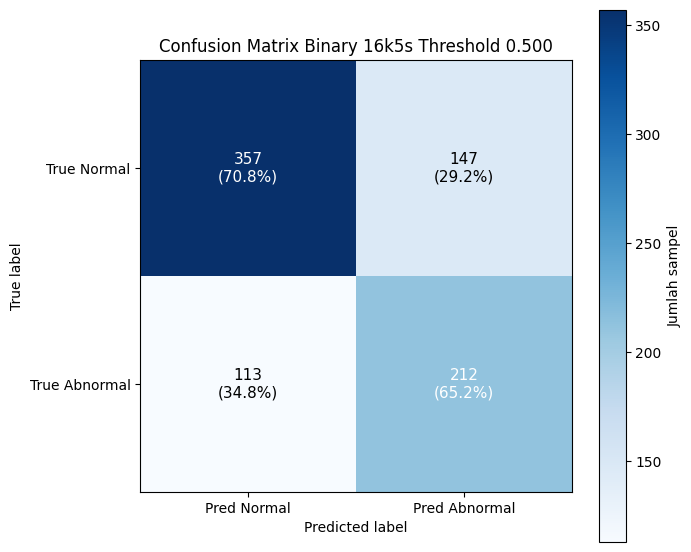

Confusion matrix figure: results_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026_confusion_matrix_test_threshold_500.png


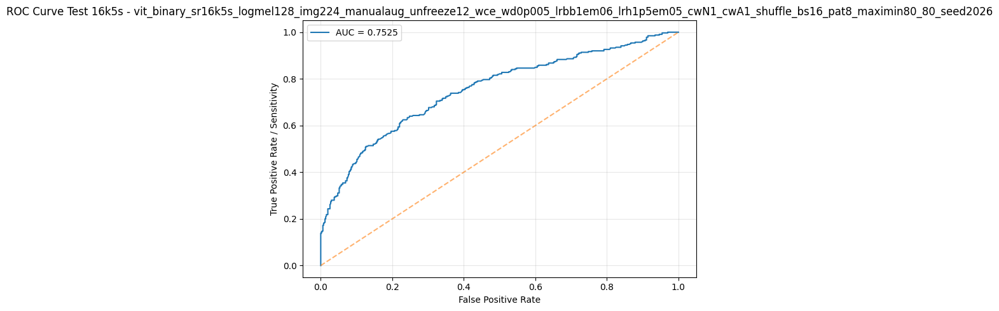

ROC curve figure: results_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026_roc_curve_test.png


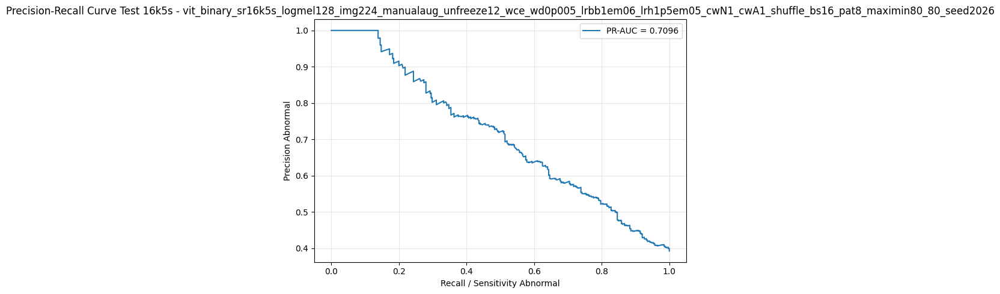

Precision-recall curve figure: results_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026_precision_recall_curve_test.png

Audit false negative abnormal:
Jumlah FN abnormal: 113

Distribusi source label pada false negative:


,count
sound,
crackle,53
wheeze,45
both,15
abnormal,0



Distribusi patient_id pada false negative:


,count
patient_id,
178,54
151,15
120,15
221,14
192,7
124,5
129,3



Audit false positive normal:
Jumlah FP normal: 147

Distribusi patient_id pada false positive:


,count
patient_id,
151,46
178,27
120,26
113,24
124,12
188,7
102,2
155,2
129,1



[OK] Evaluasi model ViT-only binary 16k5s selesai.


In [ ]:
# ============================================================
# CELL: EVALUASI MODEL ViT-B/16 BINARY NORMAL-ABNORMAL 16k5s
# Main result       : threshold 0.50
# Sensitivity mode  : threshold selected from validation set
# ============================================================
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
)


# ============================================================
# 0. VALIDASI GLOBAL WAJIB
# ============================================================

required_globals = [
    "model",
    "criterion",
    "run_one_epoch",
    "val_loader",
    "test_loader",
    "DEVICE",

    "SCENARIO_NAME",
    "CLASSES",
    "label2id",
    "id2label",
    "NUM_CLASSES",
    "LABEL_COL",

    "BEST_MODEL_PATH",
    "RESULT_DIR",

    "LOSS_NAME",
    "USE_CLASS_WEIGHT",
    "CLASS_WEIGHT_METHOD",

    "LEARNING_RATE",
    "LR_BACKBONE",
    "LR_HEAD",
    "WEIGHT_DECAY",
    "NUM_EPOCHS",
    "BATCH_SIZE",
    "PATIENCE",

    "CHECKPOINT_MONITOR",
    "EARLY_STOPPING_MONITOR",
    "CHECKPOINT_MODE",

    "TARGET_SR",
    "TARGET_DURATION_SEC",
    "TARGET_LEN_SAMPLES",
    "N_MELS",
    "FMIN",
    "FMAX",
    "N_FFT",
    "HOP_LENGTH",
    "WIN_LENGTH",
    "IMAGE_SIZE",
]

missing_globals = [g for g in required_globals if g not in globals()]

if missing_globals:
    raise RuntimeError(
        f"Global berikut belum tersedia: {missing_globals}\n"
        "Jalankan Global Config, Load Metadata, Validasi Metadata, Dataloader, "
        "Setup Model, dan Training Loop terlebih dahulu."
    )


# ============================================================
# 1. VALIDASI KONFIGURASI EKSPERIMEN
# ============================================================

if int(NUM_CLASSES) != 2:
    raise ValueError("Evaluasi ini hanya untuk binary normal-abnormal.")

if list(CLASSES) != ["normal", "abnormal"]:
    raise ValueError(
        f"CLASSES saat ini {CLASSES}. Evaluasi binary wajib memakai ['normal', 'abnormal']."
    )

if LABEL_COL != "binary_label":
    raise ValueError(
        f"LABEL_COL saat ini {LABEL_COL}. Evaluasi binary wajib memakai binary_label."
    )

LOSS_NAME = str(globals().get("LOSS_NAME", "ce")).lower().strip()
CLASS_WEIGHT_METHOD = str(globals().get("CLASS_WEIGHT_METHOD", "none")).lower().strip()
CLASS_WEIGHT_METHOD_EFFECTIVE = str(
    globals().get("CLASS_WEIGHT_METHOD_EFFECTIVE", CLASS_WEIGHT_METHOD)
).lower().strip()

MANUAL_CLASS_WEIGHT = bool(globals().get("MANUAL_CLASS_WEIGHT", False))
USE_CLASS_WEIGHT = bool(globals().get("USE_CLASS_WEIGHT", False))

NORMAL_WEIGHT = float(globals().get("NORMAL_WEIGHT", 1.00))
ABNORMAL_WEIGHT = float(globals().get("ABNORMAL_WEIGHT", 1.00))

criterion_runtime_name = globals().get(
    "criterion_runtime_name",
    criterion.__class__.__name__,
)

criterion_weights_runtime = globals().get(
    "criterion_weights_runtime",
    None,
)

# Fallback aman:
# Jika setup model lama belum menyimpan criterion_runtime_name="WeightedCrossEntropyLoss",
# tetapi LOSS_NAME='weighted_ce' dan criterion adalah CrossEntropyLoss dengan weight,
# maka runtime dianggap WeightedCrossEntropyLoss.
if (
    LOSS_NAME == "weighted_ce"
    and criterion_runtime_name == "CrossEntropyLoss"
    and getattr(criterion, "weight", None) is not None
):
    criterion_runtime_name = "WeightedCrossEntropyLoss"
    globals()["criterion_runtime_name"] = criterion_runtime_name

valid_criterion_runtime = {
    "CrossEntropyLoss",
    "WeightedCrossEntropyLoss",
    "FocalLossWithLabelSmoothing",
}

if criterion_runtime_name not in valid_criterion_runtime:
    raise AssertionError(
        f"Loss runtime harus salah satu dari {valid_criterion_runtime}. "
        f"Saat ini: {criterion_runtime_name}"
    )

if LOSS_NAME == "ce":
    if criterion_runtime_name != "CrossEntropyLoss":
        raise AssertionError(
            f"LOSS_NAME='ce' harus memakai CrossEntropyLoss. "
            f"Saat ini: {criterion_runtime_name}"
        )

    if USE_CLASS_WEIGHT:
        raise AssertionError(
            "USE_CLASS_WEIGHT harus False saat LOSS_NAME='ce'."
        )

    if getattr(criterion, "weight", None) is not None:
        raise AssertionError(
            "criterion.weight harus None untuk CrossEntropy baseline."
        )

elif LOSS_NAME == "weighted_ce":
    if criterion_runtime_name != "WeightedCrossEntropyLoss":
        raise AssertionError(
            f"LOSS_NAME='weighted_ce' harus memakai WeightedCrossEntropyLoss. "
            f"Saat ini: {criterion_runtime_name}"
        )

    if not USE_CLASS_WEIGHT:
        raise AssertionError(
            "USE_CLASS_WEIGHT harus True saat LOSS_NAME='weighted_ce'."
        )

    if getattr(criterion, "weight", None) is None:
        raise AssertionError(
            "criterion.weight tidak boleh None untuk Weighted Cross Entropy."
        )

    valid_class_weight_methods = {
        "manual",
        "manual_class_weight",
        "fixed_manual",
        "balanced_from_train_distribution",
        "balanced_clipped_from_train_distribution",
        "none",
    }

    if CLASS_WEIGHT_METHOD_EFFECTIVE not in valid_class_weight_methods:
        raise AssertionError(
            f"CLASS_WEIGHT_METHOD_EFFECTIVE tidak valid untuk weighted_ce: {CLASS_WEIGHT_METHOD_EFFECTIVE}. "
            f"Gunakan salah satu dari {valid_class_weight_methods}."
        )

    # Audit tambahan untuk manual class weight.
    if MANUAL_CLASS_WEIGHT or CLASS_WEIGHT_METHOD in {"manual", "manual_class_weight", "fixed_manual"}:
        current_weight_tensor = getattr(criterion, "weight", None)

        if current_weight_tensor is None:
            raise AssertionError(
                "MANUAL_CLASS_WEIGHT=True tetapi criterion.weight None. "
                "Jalankan ulang cell Setup Model yang sudah mendukung manual class weight."
            )

        current_weights = current_weight_tensor.detach().cpu().numpy().astype(float).tolist()

        if len(current_weights) != 2:
            raise AssertionError(
                f"Weighted CE binary harus memiliki 2 class weight. Saat ini: {current_weights}"
            )

        expected_weights = [float(NORMAL_WEIGHT), float(ABNORMAL_WEIGHT)]

        if not np.allclose(current_weights, expected_weights, rtol=1e-4, atol=1e-6):
            print("[WARNING] Bobot criterion tidak sama dengan NORMAL_WEIGHT dan ABNORMAL_WEIGHT.")
            print("          Criterion weights :", current_weights)
            print("          Expected weights  :", expected_weights)
            print("          Jika ini bukan disengaja, jalankan ulang Global Config dan Setup Model.")

elif LOSS_NAME == "focal":
    if criterion_runtime_name != "FocalLossWithLabelSmoothing":
        raise AssertionError(
            f"LOSS_NAME='focal' harus memakai FocalLossWithLabelSmoothing. "
            f"Saat ini: {criterion_runtime_name}"
        )

    if USE_CLASS_WEIGHT:
        raise AssertionError(
            "USE_CLASS_WEIGHT harus False saat LOSS_NAME='focal'."
        )

else:
    raise ValueError(
        f"LOSS_NAME tidak valid: {LOSS_NAME}. "
        "Gunakan 'ce', 'weighted_ce', atau 'focal'."
    )

TARGET_SR = int(TARGET_SR)
TARGET_DURATION_SEC = float(TARGET_DURATION_SEC)
TARGET_LEN_SAMPLES = int(TARGET_LEN_SAMPLES)
N_MELS = int(N_MELS)
FMIN = int(FMIN)
FMAX = int(FMAX)
N_FFT = int(N_FFT)
HOP_LENGTH = int(HOP_LENGTH)
WIN_LENGTH = int(WIN_LENGTH)
IMAGE_SIZE = int(IMAGE_SIZE)

if TARGET_SR != 16000:
    raise AssertionError(f"TARGET_SR harus 16000. Saat ini: {TARGET_SR}")

if abs(TARGET_DURATION_SEC - 5.0) > 1e-12:
    raise AssertionError(f"TARGET_DURATION_SEC harus 5.0. Saat ini: {TARGET_DURATION_SEC}")

if TARGET_LEN_SAMPLES != 80000:
    raise AssertionError(f"TARGET_LEN_SAMPLES harus 80000. Saat ini: {TARGET_LEN_SAMPLES}")

if N_MELS != 128:
    raise AssertionError(f"N_MELS harus 128. Saat ini: {N_MELS}")

NYQUIST = TARGET_SR // 2

if not (0 <= FMIN < FMAX <= NYQUIST):
    raise AssertionError(
        f"FMIN/FMAX tidak valid. Saat ini FMIN={FMIN}, FMAX={FMAX}, Nyquist={NYQUIST}."
    )

if N_FFT != 2048:
    raise AssertionError(f"N_FFT harus 2048. Saat ini: {N_FFT}")

if HOP_LENGTH != 128:
    raise AssertionError(f"HOP_LENGTH harus 128. Saat ini: {HOP_LENGTH}")

if WIN_LENGTH != 2048:
    raise AssertionError(f"WIN_LENGTH harus 2048. Saat ini: {WIN_LENGTH}")

if IMAGE_SIZE != 224:
    raise AssertionError(f"IMAGE_SIZE harus 224. Saat ini: {IMAGE_SIZE}")

print("=" * 90)
print("EVALUATION CONFIG VALIDATION")
print("=" * 90)
print("LOSS_NAME                    :", LOSS_NAME)
print("Criterion runtime            :", criterion_runtime_name)
print("USE_CLASS_WEIGHT             :", USE_CLASS_WEIGHT)
print("MANUAL_CLASS_WEIGHT          :", MANUAL_CLASS_WEIGHT)
print("CLASS_WEIGHT_METHOD          :", CLASS_WEIGHT_METHOD)
print("CLASS_WEIGHT_METHOD_EFFECTIVE:", CLASS_WEIGHT_METHOD_EFFECTIVE)
print("NORMAL_WEIGHT                :", NORMAL_WEIGHT)
print("ABNORMAL_WEIGHT              :", ABNORMAL_WEIGHT)
print("Criterion weights runtime    :", criterion_weights_runtime)

if getattr(criterion, "weight", None) is not None:
    print(
        "Criterion weight tensor      :",
        criterion.weight.detach().cpu().numpy().round(6).tolist()
    )

print("FMIN                         :", FMIN)
print("FMAX                         :", FMAX)
print("Nyquist                      :", NYQUIST)
print("WEIGHT_DECAY                 :", WEIGHT_DECAY)
print("=" * 90)


# ============================================================
# 2. LABEL, CHECKPOINT, THRESHOLD CONFIG
# ============================================================

NEG_LABEL = globals().get("NEG_LABEL", "normal")
POS_LABEL = globals().get("POS_LABEL", "abnormal")

NEG_LABEL_ID = int(label2id[NEG_LABEL])
POS_LABEL_ID = int(label2id[POS_LABEL])

if NEG_LABEL_ID != 0 or POS_LABEL_ID != 1:
    raise ValueError(
        f"Mapping label salah. normal harus 0 dan abnormal harus 1. "
        f"Saat ini normal={NEG_LABEL_ID}, abnormal={POS_LABEL_ID}"
    )

DEFAULT_TEST_THRESHOLD = float(globals().get("DEFAULT_TEST_THRESHOLD", 0.50))

ENABLE_THRESHOLD_TUNING = bool(
    globals().get("ENABLE_THRESHOLD_TUNING", True)
)

THRESHOLD_SELECTION_METRIC = str(
    globals().get("THRESHOLD_SELECTION_METRIC", "sensitivity_at_min_specificity")
)

THRESHOLD_MIN = float(globals().get("THRESHOLD_MIN", 0.10))
THRESHOLD_MAX = float(globals().get("THRESHOLD_MAX", 0.90))
THRESHOLD_STEP = float(globals().get("THRESHOLD_STEP", 0.001))

TARGET_SENSITIVITY_ABNORMAL = float(
    globals().get("TARGET_SENSITIVITY_ABNORMAL", 0.80)
)

MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD = float(
    globals().get(
        "MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD",
        globals().get("SPECIFICITY_SAFE_MIN", 0.50),
    )
)

CHECKPOINT_MONITOR = str(
    globals().get("CHECKPOINT_MONITOR", "val_maximin_score")
)

EARLY_STOPPING_MONITOR = str(
    globals().get("EARLY_STOPPING_MONITOR", "val_maximin_score")
)

CHECKPOINT_MODE = str(
    globals().get("CHECKPOINT_MODE", "max")
)

PRIMARY_OPERATING_POINT = str(
    globals().get("PRIMARY_OPERATING_POINT", "fixed_050")
)

if PRIMARY_OPERATING_POINT not in {"fixed_050", "validation_tuned"}:
    raise ValueError(
        "PRIMARY_OPERATING_POINT harus 'fixed_050' atau 'validation_tuned'."
    )

globals()["ENABLE_THRESHOLD_TUNING"] = ENABLE_THRESHOLD_TUNING
globals()["CHECKPOINT_MONITOR"] = CHECKPOINT_MONITOR
globals()["EARLY_STOPPING_MONITOR"] = EARLY_STOPPING_MONITOR
globals()["CHECKPOINT_MODE"] = CHECKPOINT_MODE
globals()["THRESHOLD_SELECTION_METRIC"] = THRESHOLD_SELECTION_METRIC
globals()["TARGET_SENSITIVITY_ABNORMAL"] = TARGET_SENSITIVITY_ABNORMAL
globals()["MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD"] = MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD
globals()["PRIMARY_OPERATING_POINT"] = PRIMARY_OPERATING_POINT


# ============================================================
# 3. PATH OUTPUT
# ============================================================

RESULT_DIR = Path(RESULT_DIR)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = Path(BEST_MODEL_PATH)


# ============================================================
# 4. HELPER
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def safe_float(x):
    try:
        if x is None:
            return None

        x = float(x)

        if np.isnan(x):
            return None

        return x

    except Exception:
        return None


def json_safe_value(x):
    if isinstance(x, (np.integer,)):
        return int(x)

    if isinstance(x, (np.floating,)):
        if np.isnan(float(x)):
            return None
        return float(x)

    if isinstance(x, float):
        if np.isnan(x):
            return None
        return x

    if isinstance(x, np.ndarray):
        return x.tolist()

    if isinstance(x, torch.Tensor):
        return x.detach().cpu().tolist()

    if isinstance(x, Path):
        return str(x)

    if isinstance(x, dict):
        return {str(k): json_safe_value(v) for k, v in x.items()}

    if isinstance(x, list):
        return [json_safe_value(v) for v in x]

    return x


def json_safe_dict(d):
    return {str(k): json_safe_value(v) for k, v in d.items()}


def load_checkpoint_safely(path, device):
    try:
        return torch.load(str(path), map_location=device, weights_only=False)
    except TypeError:
        return torch.load(str(path), map_location=device)


def get_id2label_value(class_id):
    if class_id in id2label:
        return id2label[class_id]

    if str(class_id) in id2label:
        return id2label[str(class_id)]

    raise KeyError(f"id2label tidak memiliki key {class_id}")


def make_threshold_suffix(threshold):
    return f"{int(round(float(threshold) * 1000)):03d}"


# ============================================================
# 5. LOAD BEST MODEL BERDASARKAN CHECKPOINT MONITOR
# ============================================================

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Best model tidak ditemukan: {BEST_MODEL_PATH}\n"
        "Jalankan Training Loop terlebih dahulu dan pastikan checkpoint best model tersimpan."
    )

print("=" * 90)
print("LOAD BEST MODEL UNTUK EVALUASI ViT-ONLY BINARY 16k5s")
print("=" * 90)
print("Best model path:", BEST_MODEL_PATH)

checkpoint = load_checkpoint_safely(BEST_MODEL_PATH, DEVICE)

checkpoint_epoch = None
checkpoint_type = None
checkpoint_monitor = CHECKPOINT_MONITOR
checkpoint_mode = CHECKPOINT_MODE
checkpoint_selection_rule = f"{CHECKPOINT_MODE}_{CHECKPOINT_MONITOR}"
checkpoint_best_val_loss = None
checkpoint_best_val_macro_f1 = None
checkpoint_loss_name = LOSS_NAME
checkpoint_class_weight_method = CLASS_WEIGHT_METHOD_EFFECTIVE
checkpoint_scheduler = globals().get("scheduler_name_runtime", globals().get("SCHEDULER_NAME", "unknown"))
checkpoint_criterion_runtime = criterion_runtime_name
checkpoint_criterion_weights = None

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])

    checkpoint_epoch = checkpoint.get("epoch", None)
    checkpoint_type = checkpoint.get("checkpoint_type", None)
    checkpoint_monitor = checkpoint.get("checkpoint_monitor", CHECKPOINT_MONITOR)
    checkpoint_mode = checkpoint.get("checkpoint_mode", CHECKPOINT_MODE)
    checkpoint_selection_rule = checkpoint.get(
        "selection_rule",
        f"{checkpoint_mode}_{checkpoint_monitor}",
    )
    checkpoint_best_val_loss = checkpoint.get("best_val_loss", None)
    checkpoint_best_val_macro_f1 = checkpoint.get(
        "best_val_macro_f1",
        checkpoint.get("best_monitor_value", None),
    )
    checkpoint_loss_name = checkpoint.get("loss_name", LOSS_NAME)
    checkpoint_class_weight_method = checkpoint.get(
        "class_weight_method_effective",
        checkpoint.get(
            "class_weight_method",
            CLASS_WEIGHT_METHOD_EFFECTIVE,
        ),
    )
    checkpoint_scheduler = checkpoint.get(
        "scheduler",
        globals().get("scheduler_name_runtime", globals().get("SCHEDULER_NAME", "unknown")),
    )
    checkpoint_criterion_runtime = checkpoint.get(
        "criterion_runtime",
        criterion_runtime_name,
    )
    checkpoint_criterion_weights = checkpoint.get(
        "criterion_weights",
        checkpoint.get("class_weight_used", None),
    )

elif isinstance(checkpoint, dict):
    try:
        model.load_state_dict(checkpoint)
        checkpoint_type = "raw_state_dict"
    except Exception as e:
        raise RuntimeError(
            "Format checkpoint tidak dikenali. "
            f"Error saat load_state_dict: {repr(e)}"
        )
else:
    raise RuntimeError("Checkpoint tidak valid.")

print("Checkpoint epoch        :", checkpoint_epoch)
print("Checkpoint type         :", checkpoint_type)
print("Checkpoint monitor      :", checkpoint_monitor)
print("Checkpoint mode         :", checkpoint_mode)
print("Checkpoint selection    :", checkpoint_selection_rule)
print("Checkpoint best val loss:", checkpoint_best_val_loss)
print("Checkpoint best macro-F1:", checkpoint_best_val_macro_f1)
print("Checkpoint loss name    :", checkpoint_loss_name)
print("Checkpoint criterion    :", checkpoint_criterion_runtime)
print("Checkpoint class weight :", checkpoint_class_weight_method)
print("Checkpoint weights      :", checkpoint_criterion_weights)
print("Checkpoint scheduler    :", checkpoint_scheduler)

if (
    LOSS_NAME == "weighted_ce"
    and CLASS_WEIGHT_METHOD_EFFECTIVE == "manual"
    and str(checkpoint_class_weight_method).lower().strip() not in {"manual", "manual_class_weight", "fixed_manual"}
):
    print("\n[WARNING] Runtime sekarang memakai manual class weight, tetapi checkpoint yang diload")
    print("          tampaknya berasal dari class weight method berbeda.")
    print("          Ini biasanya berarti Anda mengevaluasi checkpoint lama.")
    print("          Jika targetnya eksperimen manual weight, jalankan ulang training dari awal.")
    print("          Runtime method    :", CLASS_WEIGHT_METHOD_EFFECTIVE)
    print("          Checkpoint method :", checkpoint_class_weight_method)

model = model.to(DEVICE)
model.eval()


# ============================================================
# 6. METRIK BINARY DARI PROBABILITAS
# ============================================================

def compute_binary_metrics_from_prob(
    y_true,
    prob_abnormal,
    threshold=0.50,
):
    y_true = np.asarray(y_true).astype(int)
    prob_abnormal = np.asarray(prob_abnormal).astype(float)

    y_pred = (prob_abnormal >= float(threshold)).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[NEG_LABEL_ID, POS_LABEL_ID],
    )

    tn, fp, fn, tp = cm.ravel()

    sensitivity_abnormal = tp / (tp + fn + 1e-12)
    specificity_normal = tn / (tn + fp + 1e-12)
    precision_abnormal = tp / (tp + fp + 1e-12)

    # Metrik kelas normal ketika kelas normal diperlakukan sebagai kelas positif.
    precision_normal = tn / (tn + fn + 1e-12)
    recall_normal = specificity_normal

    f1_normal = (
        2.0 * precision_normal * recall_normal /
        (precision_normal + recall_normal + 1e-12)
    )

    f1_abnormal = (
        2.0 * precision_abnormal * sensitivity_abnormal /
        (precision_abnormal + sensitivity_abnormal + 1e-12)
    )

    # Binary macro-F1 memberi bobot yang sama pada kelas normal dan abnormal.
    macro_f1_manual = (f1_normal + f1_abnormal) / 2.0

    macro_f1_sklearn = f1_score(
        y_true,
        y_pred,
        labels=[NEG_LABEL_ID, POS_LABEL_ID],
        average="macro",
        zero_division=0,
    )

    if not np.isclose(
        macro_f1_manual,
        macro_f1_sklearn,
        rtol=1e-9,
        atol=1e-9,
    ):
        raise RuntimeError(
            "Perhitungan binary macro-F1 manual tidak konsisten "
            "dengan sklearn.metrics.f1_score."
        )

    binary_macro_f1 = float(macro_f1_sklearn)

    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-12)
    balanced_score = (sensitivity_abnormal + specificity_normal) / 2.0

    harmonic_score = (
        2.0 * sensitivity_abnormal * specificity_normal /
        (sensitivity_abnormal + specificity_normal + 1e-12)
    )

    try:
        auc = roc_auc_score(y_true, prob_abnormal)
    except Exception:
        auc = np.nan

    try:
        pr_auc = average_precision_score(y_true, prob_abnormal)
    except Exception:
        pr_auc = np.nan

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy),
        "sensitivity_abnormal": float(sensitivity_abnormal),
        "specificity_normal": float(specificity_normal),
        "precision_normal": float(precision_normal),
        "precision_abnormal": float(precision_abnormal),
        "recall_normal": float(recall_normal),
        "f1_normal": float(f1_normal),
        "f1_abnormal": float(f1_abnormal),
        "macro_f1": float(binary_macro_f1),
        "binary_macro_f1": float(binary_macro_f1),
        "balanced_score": float(balanced_score),
        "harmonic_score": float(harmonic_score),
        "auc": float(auc) if not np.isnan(auc) else np.nan,
        "pr_auc": float(pr_auc) if not np.isnan(pr_auc) else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "confusion_matrix": cm,
        "y_pred": y_pred,
    }


def select_threshold_from_validation(
    y_true,
    prob_abnormal,
    threshold_min=0.10,
    threshold_max=0.90,
    threshold_step=0.001,
    target_sensitivity=0.80,
    min_specificity=0.50,
):
    thresholds = np.arange(
        float(threshold_min),
        float(threshold_max) + 1e-12,
        float(threshold_step),
    )

    rows = []

    for thr in thresholds:
        metrics = compute_binary_metrics_from_prob(
            y_true=y_true,
            prob_abnormal=prob_abnormal,
            threshold=float(thr),
        )

        rows.append({
            "threshold": float(thr),
            "accuracy": metrics["accuracy"],
            "sensitivity_abnormal": metrics["sensitivity_abnormal"],
            "specificity_normal": metrics["specificity_normal"],
            "precision_normal": metrics["precision_normal"],
            "precision_abnormal": metrics["precision_abnormal"],
            "f1_normal": metrics["f1_normal"],
            "f1_abnormal": metrics["f1_abnormal"],
            "macro_f1": metrics["macro_f1"],
            "binary_macro_f1": metrics["binary_macro_f1"],
            "balanced_score": metrics["balanced_score"],
            "harmonic_score": metrics["harmonic_score"],
            "tn": metrics["tn"],
            "fp": metrics["fp"],
            "fn": metrics["fn"],
            "tp": metrics["tp"],
        })

    sweep_df = pd.DataFrame(rows)

    feasible_target = sweep_df[
        (sweep_df["sensitivity_abnormal"] >= float(target_sensitivity)) &
        (sweep_df["specificity_normal"] >= float(min_specificity))
    ].copy()

    if len(feasible_target) > 0:
        chosen = (
            feasible_target
            .sort_values(
                by=[
                    "harmonic_score",
                    "balanced_score",
                    "specificity_normal",
                    "sensitivity_abnormal",
                ],
                ascending=[False, False, False, False],
            )
            .iloc[0]
        )

        policy = (
            f"validation_threshold_target_sens_{target_sensitivity:.2f}_"
            f"min_spec_{min_specificity:.2f}_best_harmonic"
        )

        return float(chosen["threshold"]), policy, sweep_df, chosen.to_dict()

    feasible_spec = sweep_df[
        sweep_df["specificity_normal"] >= float(min_specificity)
    ].copy()

    if len(feasible_spec) > 0:
        chosen = (
            feasible_spec
            .sort_values(
                by=[
                    "sensitivity_abnormal",
                    "harmonic_score",
                    "balanced_score",
                    "specificity_normal",
                ],
                ascending=[False, False, False, False],
            )
            .iloc[0]
        )

        policy = (
            f"validation_threshold_max_sens_"
            f"min_spec_{min_specificity:.2f}_target_not_reached"
        )

        return float(chosen["threshold"]), policy, sweep_df, chosen.to_dict()

    chosen = (
        sweep_df
        .sort_values(
            by=[
                "harmonic_score",
                "balanced_score",
            ],
            ascending=[False, False],
        )
        .iloc[0]
    )

    policy = "validation_threshold_best_harmonic_no_constraint"

    return float(chosen["threshold"]), policy, sweep_df, chosen.to_dict()


def build_prediction_df(
    y_true,
    prob_abnormal,
    y_pred,
    threshold,
    threshold_policy,
    df_meta=None,
):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    prob_abnormal = np.asarray(prob_abnormal).astype(float)

    pred_df = pd.DataFrame({
        "y_true_id": y_true,
        "y_true_label": [get_id2label_value(int(x)) for x in y_true],
        "prob_abnormal": prob_abnormal,
        "prob_normal": 1.0 - prob_abnormal,
        "y_pred_id": y_pred,
        "y_pred_label": [get_id2label_value(int(x)) for x in y_pred],
        "threshold": float(threshold),
        "threshold_policy": str(threshold_policy),
        "is_correct": y_true == y_pred,
    })

    if df_meta is not None and len(df_meta) == len(pred_df):
        meta = df_meta.reset_index(drop=True).copy()

        meta_cols = [
            "image_path",
            "sound",
            "sound_4class",
            "original_sound",
            "binary_label",
            "patient_id",
            "split",
            "is_augmented",
            "augmentation_group",
            "aug_type",
            "file",
            "image_sr",
            "image_n_mels",
            "image_fmin",
            "image_fmax",
            "image_hop_length",
            "image_expected_len_samples",
        ]

        for col in meta_cols:
            if col in meta.columns:
                pred_df[col] = meta[col].values

    return pred_df


# ============================================================
# 7. RUN RAW EVALUATION ON VALIDATION AND TEST
# ============================================================

print("\n" + "=" * 90)
print("EVALUASI VALIDATION DAN TEST SET ViT-ONLY BINARY NORMAL-ABNORMAL 16k5s")
print("=" * 90)
print("Checkpoint monitor              :", checkpoint_monitor)
print("Checkpoint selection            :", checkpoint_selection_rule)
print("Default threshold               :", DEFAULT_TEST_THRESHOLD)
print("Threshold tuning enabled        :", ENABLE_THRESHOLD_TUNING)
print("Primary operating point         :", PRIMARY_OPERATING_POINT)
print("Target sensitivity abnormal     :", TARGET_SENSITIVITY_ABNORMAL)
print("Min specificity threshold       :", MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD)
print("=" * 90)

val_raw_metrics = run_one_epoch(
    model=model,
    loader=val_loader,
    criterion=criterion,
    optimizer=None,
    scaler=None,
    device=DEVICE,
)

test_raw_metrics = run_one_epoch(
    model=model,
    loader=test_loader,
    criterion=criterion,
    optimizer=None,
    scaler=None,
    device=DEVICE,
)

y_val = np.asarray(val_raw_metrics["y_true"]).astype(int)
val_prob_abnormal = np.asarray(val_raw_metrics["y_prob_abnormal"]).astype(float)

y_test = np.asarray(test_raw_metrics["y_true"]).astype(int)
test_prob_abnormal = np.asarray(test_raw_metrics["y_prob_abnormal"]).astype(float)


# ============================================================
# 8. OPERATING POINTS
# ============================================================

fixed_threshold = float(DEFAULT_TEST_THRESHOLD)
fixed_policy = "fixed_default_threshold_0_50"

val_metrics_fixed_050 = compute_binary_metrics_from_prob(
    y_true=y_val,
    prob_abnormal=val_prob_abnormal,
    threshold=fixed_threshold,
)

test_metrics_fixed_050 = compute_binary_metrics_from_prob(
    y_true=y_test,
    prob_abnormal=test_prob_abnormal,
    threshold=fixed_threshold,
)

if ENABLE_THRESHOLD_TUNING:
    tuned_threshold, tuned_policy, threshold_sweep_df, selected_threshold_info = (
        select_threshold_from_validation(
            y_true=y_val,
            prob_abnormal=val_prob_abnormal,
            threshold_min=THRESHOLD_MIN,
            threshold_max=THRESHOLD_MAX,
            threshold_step=THRESHOLD_STEP,
            target_sensitivity=TARGET_SENSITIVITY_ABNORMAL,
            min_specificity=MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD,
        )
    )
else:
    tuned_threshold = fixed_threshold
    tuned_policy = fixed_policy
    threshold_sweep_df = None
    selected_threshold_info = None

val_metrics_tuned = compute_binary_metrics_from_prob(
    y_true=y_val,
    prob_abnormal=val_prob_abnormal,
    threshold=tuned_threshold,
)

test_metrics_tuned = compute_binary_metrics_from_prob(
    y_true=y_test,
    prob_abnormal=test_prob_abnormal,
    threshold=tuned_threshold,
)

if PRIMARY_OPERATING_POINT == "fixed_050":
    BEST_THRESHOLD = fixed_threshold
    EVALUATION_THRESHOLD_POLICY = fixed_policy
    val_metrics = val_metrics_fixed_050
    test_metrics = test_metrics_fixed_050
else:
    BEST_THRESHOLD = tuned_threshold
    EVALUATION_THRESHOLD_POLICY = tuned_policy
    val_metrics = val_metrics_tuned
    test_metrics = test_metrics_tuned

val_pred = val_metrics["y_pred"]
test_pred = test_metrics["y_pred"]

val_cm = val_metrics["confusion_matrix"].astype(np.int64)
test_cm = test_metrics["confusion_matrix"].astype(np.int64)

val_tn, val_fp, val_fn, val_tp = val_cm.ravel()
tn, fp, fn, tp = test_cm.ravel()


# ============================================================
# 9. OUTPUT PATHS
# ============================================================

threshold_suffix = make_threshold_suffix(BEST_THRESHOLD)

TEST_PRED_CSV_PATH = RESULT_DIR / f"{SCENARIO_NAME}_test_predictions_threshold_{threshold_suffix}.csv"
VAL_PRED_CSV_PATH = RESULT_DIR / f"{SCENARIO_NAME}_val_predictions_threshold_{threshold_suffix}.csv"

TEST_CM_CSV_PATH = RESULT_DIR / f"{SCENARIO_NAME}_test_confusion_matrix_threshold_{threshold_suffix}.csv"
VAL_CM_CSV_PATH = RESULT_DIR / f"{SCENARIO_NAME}_val_confusion_matrix_threshold_{threshold_suffix}.csv"

TEST_REPORT_TXT_PATH = RESULT_DIR / f"{SCENARIO_NAME}_test_classification_report_threshold_{threshold_suffix}.txt"
VAL_REPORT_TXT_PATH = RESULT_DIR / f"{SCENARIO_NAME}_val_classification_report_threshold_{threshold_suffix}.txt"

TEST_SUMMARY_JSON_PATH = RESULT_DIR / f"{SCENARIO_NAME}_test_summary_threshold_{threshold_suffix}.json"
EVALUATION_METADATA_CSV_PATH = (
    RESULT_DIR / f"{SCENARIO_NAME}_evaluation_metadata_threshold_{threshold_suffix}.csv"
)

THRESHOLD_SWEEP_CSV_PATH = RESULT_DIR / f"{SCENARIO_NAME}_validation_threshold_sweep.csv"
OPERATING_POINT_CSV_PATH = RESULT_DIR / f"{SCENARIO_NAME}_operating_points_summary.csv"

ROC_CURVE_PATH = RESULT_DIR / f"{SCENARIO_NAME}_roc_curve_test.png"
PR_CURVE_PATH = RESULT_DIR / f"{SCENARIO_NAME}_precision_recall_curve_test.png"
CM_FIG_PATH = RESULT_DIR / f"{SCENARIO_NAME}_confusion_matrix_test_threshold_{threshold_suffix}.png"

FALSE_NEGATIVE_CSV_PATH = RESULT_DIR / f"{SCENARIO_NAME}_false_negative_abnormal_threshold_{threshold_suffix}.csv"
FALSE_POSITIVE_CSV_PATH = RESULT_DIR / f"{SCENARIO_NAME}_false_positive_normal_threshold_{threshold_suffix}.csv"

if threshold_sweep_df is not None:
    threshold_sweep_df.to_csv(THRESHOLD_SWEEP_CSV_PATH, index=False)


# ============================================================
# 10. OPERATING POINT COMPARISON
# ============================================================

operating_points_df = pd.DataFrame([
    {
        "operating_point": "fixed_050_main",
        "selected_as_primary": PRIMARY_OPERATING_POINT == "fixed_050",
        "threshold": fixed_threshold,
        "policy": fixed_policy,
        "val_accuracy": val_metrics_fixed_050["accuracy"],
        "val_sensitivity_abnormal": val_metrics_fixed_050["sensitivity_abnormal"],
        "val_specificity_normal": val_metrics_fixed_050["specificity_normal"],
        "val_f1_normal": val_metrics_fixed_050["f1_normal"],
        "val_f1_abnormal": val_metrics_fixed_050["f1_abnormal"],
        "val_macro_f1": val_metrics_fixed_050["macro_f1"],
        "val_balanced_score": val_metrics_fixed_050["balanced_score"],
        "val_harmonic_score": val_metrics_fixed_050["harmonic_score"],
        "test_accuracy": test_metrics_fixed_050["accuracy"],
        "test_sensitivity_abnormal": test_metrics_fixed_050["sensitivity_abnormal"],
        "test_specificity_normal": test_metrics_fixed_050["specificity_normal"],
        "test_f1_normal": test_metrics_fixed_050["f1_normal"],
        "test_f1_abnormal": test_metrics_fixed_050["f1_abnormal"],
        "test_macro_f1": test_metrics_fixed_050["macro_f1"],
        "test_balanced_score": test_metrics_fixed_050["balanced_score"],
        "test_harmonic_score": test_metrics_fixed_050["harmonic_score"],
        "test_auc": test_metrics_fixed_050["auc"],
        "test_pr_auc": test_metrics_fixed_050["pr_auc"],
        "test_tn": test_metrics_fixed_050["tn"],
        "test_fp": test_metrics_fixed_050["fp"],
        "test_fn": test_metrics_fixed_050["fn"],
        "test_tp": test_metrics_fixed_050["tp"],
    },
    {
        "operating_point": "validation_tuned_sensitivity",
        "selected_as_primary": PRIMARY_OPERATING_POINT == "validation_tuned",
        "threshold": tuned_threshold,
        "policy": tuned_policy,
        "val_accuracy": val_metrics_tuned["accuracy"],
        "val_sensitivity_abnormal": val_metrics_tuned["sensitivity_abnormal"],
        "val_specificity_normal": val_metrics_tuned["specificity_normal"],
        "val_f1_normal": val_metrics_tuned["f1_normal"],
        "val_f1_abnormal": val_metrics_tuned["f1_abnormal"],
        "val_macro_f1": val_metrics_tuned["macro_f1"],
        "val_balanced_score": val_metrics_tuned["balanced_score"],
        "val_harmonic_score": val_metrics_tuned["harmonic_score"],
        "test_accuracy": test_metrics_tuned["accuracy"],
        "test_sensitivity_abnormal": test_metrics_tuned["sensitivity_abnormal"],
        "test_specificity_normal": test_metrics_tuned["specificity_normal"],
        "test_f1_normal": test_metrics_tuned["f1_normal"],
        "test_f1_abnormal": test_metrics_tuned["f1_abnormal"],
        "test_macro_f1": test_metrics_tuned["macro_f1"],
        "test_balanced_score": test_metrics_tuned["balanced_score"],
        "test_harmonic_score": test_metrics_tuned["harmonic_score"],
        "test_auc": test_metrics_tuned["auc"],
        "test_pr_auc": test_metrics_tuned["pr_auc"],
        "test_tn": test_metrics_tuned["tn"],
        "test_fp": test_metrics_tuned["fp"],
        "test_fn": test_metrics_tuned["fn"],
        "test_tp": test_metrics_tuned["tp"],
    },
])

operating_points_df.to_csv(OPERATING_POINT_CSV_PATH, index=False)

print("\n" + "=" * 90)
print("OPERATING POINT COMPARISON")
print("=" * 90)
safe_display(operating_points_df)

print("\nCatatan interpretasi:")
print("- fixed_050_main lebih cocok sebagai hasil utama paper.")
print("- validation_tuned_sensitivity cocok sebagai analisis trade-off sensitivity-specificity.")
print("- Jika sensitivity naik tetapi specificity runtuh, itu bukan model lebih baik secara umum.")
print("=" * 90)


# ============================================================
# 11. PRINT HASIL VALIDATION PRIMARY
# ============================================================

print("\n" + "=" * 90)
print("HASIL VALIDATION SET PRIMARY OPERATING POINT")
print("=" * 90)
print(f"Primary operating point          : {PRIMARY_OPERATING_POINT}")
print(f"Threshold policy                 : {EVALUATION_THRESHOLD_POLICY}")
print(f"Threshold final                  : {BEST_THRESHOLD:.3f}")
print(f"Validation loss                  : {val_raw_metrics['loss']:.4f}")
print(f"Validation accuracy              : {val_metrics['accuracy']:.4f}")
print(f"Validation sensitivity abnormal  : {val_metrics['sensitivity_abnormal']:.4f}")
print(f"Validation specificity normal    : {val_metrics['specificity_normal']:.4f}")
print(f"Validation precision normal      : {val_metrics['precision_normal']:.4f}")
print(f"Validation precision abnormal    : {val_metrics['precision_abnormal']:.4f}")
print(f"Validation F1 normal             : {val_metrics['f1_normal']:.4f}")
print(f"Validation F1 abnormal           : {val_metrics['f1_abnormal']:.4f}")
print(f"Validation macro-F1              : {val_metrics['macro_f1']:.4f}")
print(f"Validation balanced score        : {val_metrics['balanced_score']:.4f}")
print(f"Validation harmonic score        : {val_metrics['harmonic_score']:.4f}")
print(f"Validation AUC                   : {val_metrics['auc']:.4f}")
print(f"Validation PR-AUC                : {val_metrics['pr_auc']:.4f}")

val_cm_df = pd.DataFrame(
    val_cm,
    index=["True Normal", "True Abnormal"],
    columns=["Pred Normal", "Pred Abnormal"],
)

print("\nValidation Confusion Matrix:")
safe_display(val_cm_df)

val_report_text = classification_report(
    y_val,
    val_pred,
    labels=[NEG_LABEL_ID, POS_LABEL_ID],
    target_names=CLASSES,
    digits=4,
    zero_division=0,
)

print("\nValidation Classification Report:")
print(val_report_text)


# ============================================================
# 12. PRINT HASIL TEST PRIMARY
# ============================================================

print("\n" + "=" * 90)
print("HASIL TEST SET PRIMARY OPERATING POINT")
print("=" * 90)
print(f"Scenario name                    : {SCENARIO_NAME}")
print(f"Best checkpoint                  : {BEST_MODEL_PATH}")
print(f"Checkpoint monitor               : {checkpoint_monitor}")
print(f"Checkpoint selection             : {checkpoint_selection_rule}")
print(f"Loss function                    : {checkpoint_criterion_runtime}")
print(f"Runtime class weight method      : {CLASS_WEIGHT_METHOD_EFFECTIVE}")
print(f"Checkpoint class weight method   : {checkpoint_class_weight_method}")
print(f"Scheduler                        : {checkpoint_scheduler}")
print(f"Primary operating point          : {PRIMARY_OPERATING_POINT}")
print(f"Threshold final                  : {BEST_THRESHOLD:.3f}")
print(f"Threshold policy                 : {EVALUATION_THRESHOLD_POLICY}")
print("-" * 90)

print(f"Test loss                        : {test_raw_metrics['loss']:.4f}")
print(f"Test accuracy                    : {test_metrics['accuracy']:.4f}")
print(f"Test sensitivity abnormal        : {test_metrics['sensitivity_abnormal']:.4f}")
print(f"Test specificity normal          : {test_metrics['specificity_normal']:.4f}")
print(f"Test precision normal            : {test_metrics['precision_normal']:.4f}")
print(f"Test precision abnormal          : {test_metrics['precision_abnormal']:.4f}")
print(f"Test F1 normal                   : {test_metrics['f1_normal']:.4f}")
print(f"Test F1 abnormal                 : {test_metrics['f1_abnormal']:.4f}")
print(f"Test macro-F1                    : {test_metrics['macro_f1']:.4f}")
print(f"Test balanced score              : {test_metrics['balanced_score']:.4f}")
print(f"Test harmonic score              : {test_metrics['harmonic_score']:.4f}")
print(f"Test AUC                         : {test_metrics['auc']:.4f}")
print(f"Test PR-AUC                      : {test_metrics['pr_auc']:.4f}")

print("\nConfusion Matrix:")
test_cm_df = pd.DataFrame(
    test_cm,
    index=["True Normal", "True Abnormal"],
    columns=["Pred Normal", "Pred Abnormal"],
)
safe_display(test_cm_df)

print("\nKomponen confusion matrix:")
print(f"TN normal benar                 : {tn}")
print(f"FP normal diprediksi abnormal   : {fp}")
print(f"FN abnormal diprediksi normal   : {fn}")
print(f"TP abnormal benar               : {tp}")

test_report_text = classification_report(
    y_test,
    test_pred,
    labels=[NEG_LABEL_ID, POS_LABEL_ID],
    target_names=CLASSES,
    digits=4,
    zero_division=0,
)

print("\nClassification Report:")
print(test_report_text)
print("=" * 90)


# ============================================================
# 13. SIMPAN PREDICTION CSV DAN REPORT
# ============================================================

val_meta_df = globals().get("val_df", None)
test_meta_df = globals().get("test_df", None)

val_pred_df = build_prediction_df(
    y_true=y_val,
    prob_abnormal=val_prob_abnormal,
    y_pred=val_pred,
    threshold=BEST_THRESHOLD,
    threshold_policy=EVALUATION_THRESHOLD_POLICY,
    df_meta=val_meta_df,
)

test_pred_df = build_prediction_df(
    y_true=y_test,
    prob_abnormal=test_prob_abnormal,
    y_pred=test_pred,
    threshold=BEST_THRESHOLD,
    threshold_policy=EVALUATION_THRESHOLD_POLICY,
    df_meta=test_meta_df,
)

val_pred_df.to_csv(VAL_PRED_CSV_PATH, index=False)
test_pred_df.to_csv(TEST_PRED_CSV_PATH, index=False)

val_cm_df.to_csv(VAL_CM_CSV_PATH)
test_cm_df.to_csv(TEST_CM_CSV_PATH)

with open(VAL_REPORT_TXT_PATH, "w", encoding="utf-8") as f:
    f.write(val_report_text)

with open(TEST_REPORT_TXT_PATH, "w", encoding="utf-8") as f:
    f.write(test_report_text)

false_negative_df = test_pred_df[
    (test_pred_df["y_true_id"] == POS_LABEL_ID) &
    (test_pred_df["y_pred_id"] == NEG_LABEL_ID)
].copy()

false_positive_df = test_pred_df[
    (test_pred_df["y_true_id"] == NEG_LABEL_ID) &
    (test_pred_df["y_pred_id"] == POS_LABEL_ID)
].copy()

false_negative_df.to_csv(FALSE_NEGATIVE_CSV_PATH, index=False)
false_positive_df.to_csv(FALSE_POSITIVE_CSV_PATH, index=False)


# ============================================================
# 14. SIMPAN SUMMARY JSON
# ============================================================

summary_dict = {
    "scenario_name": SCENARIO_NAME,
    "model_family": globals().get("MODEL_FAMILY", "ViT-only"),
    "model_name": globals().get("MODEL_NAME", "ViT-B/16"),
    "model_claim": globals().get(
        "MODEL_CLAIM",
        "ViT-only adaptation using Log-Mel spectrogram images, without RAN."
    ),

    "label_mode": "binary_normal_abnormal",
    "positive_label": POS_LABEL,
    "negative_label": NEG_LABEL,
    "classes": CLASSES,

    "target_sr": int(TARGET_SR),
    "target_duration_sec": float(TARGET_DURATION_SEC),
    "target_len_samples": int(TARGET_LEN_SAMPLES),
    "n_mels": int(N_MELS),
    "fmin": int(FMIN),
    "fmax": int(FMAX),
    "n_fft": int(N_FFT),
    "hop_length": int(HOP_LENGTH),
    "win_length": int(WIN_LENGTH),
    "image_size": int(IMAGE_SIZE),
    "image_colormap": str(globals().get("IMAGE_COLORMAP", "magma")),
    "image_mode": str(globals().get("IMAGE_MODE", "rgb")),

    "checkpoint_epoch": checkpoint_epoch,
    "checkpoint_type": checkpoint_type,
    "checkpoint_monitor": checkpoint_monitor,
    "early_stopping_monitor": EARLY_STOPPING_MONITOR,
    "checkpoint_mode": checkpoint_mode,
    "checkpoint_selection_rule": checkpoint_selection_rule,
    "checkpoint_best_val_loss": safe_float(checkpoint_best_val_loss),
    "checkpoint_best_val_macro_f1": safe_float(checkpoint_best_val_macro_f1),
    "best_model_path": str(BEST_MODEL_PATH),

    "loss_name": LOSS_NAME,
    "loss_function": checkpoint_criterion_runtime,
    "use_class_weight": bool(USE_CLASS_WEIGHT),
    "manual_class_weight": bool(MANUAL_CLASS_WEIGHT),
    "class_weight_method": CLASS_WEIGHT_METHOD,
    "class_weight_method_effective": CLASS_WEIGHT_METHOD_EFFECTIVE,
    "checkpoint_class_weight_method": checkpoint_class_weight_method,
    "normal_weight": float(NORMAL_WEIGHT),
    "abnormal_weight": float(ABNORMAL_WEIGHT),
    "criterion_weights_runtime": criterion_weights_runtime,
    "checkpoint_criterion_weights": checkpoint_criterion_weights,

    "optimizer": "AdamW",
    "learning_rate": float(LEARNING_RATE),
    "lr_backbone": float(LR_BACKBONE),
    "lr_head": float(LR_HEAD),
    "weight_decay": float(WEIGHT_DECAY),
    "use_layer_wise_lr_decay": bool(globals().get("USE_LAYER_WISE_LR_DECAY", False)),
    "layer_lr_decay": safe_float(globals().get("LAYER_LR_DECAY", None)),
    "scheduler": checkpoint_scheduler,
    "warmup_epochs": int(globals().get("WARMUP_EPOCHS", 0)),

    "num_epochs": int(NUM_EPOCHS),
    "batch_size": int(BATCH_SIZE),
    "patience": int(PATIENCE),

    "primary_operating_point": PRIMARY_OPERATING_POINT,
    "threshold_final": float(BEST_THRESHOLD),
    "threshold_policy": EVALUATION_THRESHOLD_POLICY,
    "threshold_tuning_enabled": bool(ENABLE_THRESHOLD_TUNING),
    "threshold_selection_metric": THRESHOLD_SELECTION_METRIC,
    "threshold_selected_from": "validation" if PRIMARY_OPERATING_POINT == "validation_tuned" else "fixed_default",
    "target_sensitivity_abnormal": float(TARGET_SENSITIVITY_ABNORMAL),
    "min_specificity_normal_for_threshold": float(MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD),

    "fixed_threshold": float(fixed_threshold),
    "fixed_validation_macro_f1": float(val_metrics_fixed_050["macro_f1"]),
    "fixed_test_sensitivity_abnormal": float(test_metrics_fixed_050["sensitivity_abnormal"]),
    "fixed_test_specificity_normal": float(test_metrics_fixed_050["specificity_normal"]),
    "fixed_test_f1_normal": float(test_metrics_fixed_050["f1_normal"]),
    "fixed_test_f1_abnormal": float(test_metrics_fixed_050["f1_abnormal"]),
    "fixed_test_macro_f1": float(test_metrics_fixed_050["macro_f1"]),
    "fixed_test_balanced_score": float(test_metrics_fixed_050["balanced_score"]),
    "fixed_test_harmonic_score": float(test_metrics_fixed_050["harmonic_score"]),

    "tuned_threshold": float(tuned_threshold),
    "tuned_policy": tuned_policy,
    "tuned_validation_macro_f1": float(val_metrics_tuned["macro_f1"]),
    "tuned_test_sensitivity_abnormal": float(test_metrics_tuned["sensitivity_abnormal"]),
    "tuned_test_specificity_normal": float(test_metrics_tuned["specificity_normal"]),
    "tuned_test_f1_normal": float(test_metrics_tuned["f1_normal"]),
    "tuned_test_f1_abnormal": float(test_metrics_tuned["f1_abnormal"]),
    "tuned_test_macro_f1": float(test_metrics_tuned["macro_f1"]),
    "tuned_test_balanced_score": float(test_metrics_tuned["balanced_score"]),
    "tuned_test_harmonic_score": float(test_metrics_tuned["harmonic_score"]),

    "validation_loss": float(val_raw_metrics["loss"]),
    "validation_accuracy": float(val_metrics["accuracy"]),
    "validation_sensitivity_abnormal": float(val_metrics["sensitivity_abnormal"]),
    "validation_specificity_normal": float(val_metrics["specificity_normal"]),
    "validation_precision_normal": float(val_metrics["precision_normal"]),
    "validation_precision_abnormal": float(val_metrics["precision_abnormal"]),
    "validation_f1_normal": float(val_metrics["f1_normal"]),
    "validation_f1_abnormal": float(val_metrics["f1_abnormal"]),
    "validation_macro_f1": float(val_metrics["macro_f1"]),
    "validation_binary_macro_f1": float(val_metrics["binary_macro_f1"]),
    "validation_balanced_score": float(val_metrics["balanced_score"]),
    "validation_harmonic_score": float(val_metrics["harmonic_score"]),
    "validation_auc": safe_float(val_metrics["auc"]),
    "validation_pr_auc": safe_float(val_metrics["pr_auc"]),
    "validation_tn": int(val_tn),
    "validation_fp": int(val_fp),
    "validation_fn": int(val_fn),
    "validation_tp": int(val_tp),

    "test_loss": float(test_raw_metrics["loss"]),
    "test_accuracy": float(test_metrics["accuracy"]),
    "test_sensitivity_abnormal": float(test_metrics["sensitivity_abnormal"]),
    "test_specificity_normal": float(test_metrics["specificity_normal"]),
    "test_precision_normal": float(test_metrics["precision_normal"]),
    "test_precision_abnormal": float(test_metrics["precision_abnormal"]),
    "test_f1_normal": float(test_metrics["f1_normal"]),
    "test_f1_abnormal": float(test_metrics["f1_abnormal"]),
    "test_macro_f1": float(test_metrics["macro_f1"]),
    "test_binary_macro_f1": float(test_metrics["binary_macro_f1"]),
    "test_balanced_score": float(test_metrics["balanced_score"]),
    "test_harmonic_score": float(test_metrics["harmonic_score"]),
    "test_auc": safe_float(test_metrics["auc"]),
    "test_pr_auc": safe_float(test_metrics["pr_auc"]),

    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp),

    "false_negative_abnormal": int(fn),
    "false_positive_normal": int(fp),

    "val_prediction_csv": str(VAL_PRED_CSV_PATH),
    "test_prediction_csv": str(TEST_PRED_CSV_PATH),
    "val_confusion_matrix_csv": str(VAL_CM_CSV_PATH),
    "test_confusion_matrix_csv": str(TEST_CM_CSV_PATH),
    "val_report_txt": str(VAL_REPORT_TXT_PATH),
    "test_report_txt": str(TEST_REPORT_TXT_PATH),
    "false_negative_csv": str(FALSE_NEGATIVE_CSV_PATH),
    "false_positive_csv": str(FALSE_POSITIVE_CSV_PATH),
    "threshold_sweep_csv": str(THRESHOLD_SWEEP_CSV_PATH) if threshold_sweep_df is not None else None,
    "operating_point_csv": str(OPERATING_POINT_CSV_PATH),
    "evaluation_metadata_csv": str(EVALUATION_METADATA_CSV_PATH),
    "summary_json": str(TEST_SUMMARY_JSON_PATH),
}

with open(TEST_SUMMARY_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(json_safe_dict(summary_dict), f, indent=2, ensure_ascii=False)

evaluation_metadata = {
    "scenario_name": SCENARIO_NAME,
    "model_name": globals().get("MODEL_NAME", "ViT-B/16"),
    "checkpoint_epoch": checkpoint_epoch,
    "checkpoint_monitor": checkpoint_monitor,
    "checkpoint_mode": checkpoint_mode,
    "checkpoint_best_val_macro_f1": safe_float(checkpoint_best_val_macro_f1),
    "early_stopping_monitor": EARLY_STOPPING_MONITOR,
    "patience": int(PATIENCE),
    "primary_operating_point": PRIMARY_OPERATING_POINT,
    "threshold": float(BEST_THRESHOLD),
    "threshold_policy": EVALUATION_THRESHOLD_POLICY,
    "validation_loss": float(val_raw_metrics["loss"]),
    "validation_accuracy": float(val_metrics["accuracy"]),
    "validation_f1_normal": float(val_metrics["f1_normal"]),
    "validation_f1_abnormal": float(val_metrics["f1_abnormal"]),
    "validation_macro_f1": float(val_metrics["macro_f1"]),
    "test_loss": float(test_raw_metrics["loss"]),
    "test_accuracy": float(test_metrics["accuracy"]),
    "test_f1_normal": float(test_metrics["f1_normal"]),
    "test_f1_abnormal": float(test_metrics["f1_abnormal"]),
    "test_macro_f1": float(test_metrics["macro_f1"]),
    "test_sensitivity_abnormal": float(test_metrics["sensitivity_abnormal"]),
    "test_specificity_normal": float(test_metrics["specificity_normal"]),
    "test_auc": safe_float(test_metrics["auc"]),
    "test_pr_auc": safe_float(test_metrics["pr_auc"]),
    "n_mels": int(N_MELS),
    "image_size": int(IMAGE_SIZE),
    "loss_name": LOSS_NAME,
    "class_weight_method_effective": CLASS_WEIGHT_METHOD_EFFECTIVE,
    "learning_rate": float(LEARNING_RATE),
    "weight_decay": float(WEIGHT_DECAY),
    "batch_size": int(BATCH_SIZE),
}

evaluation_metadata_df = pd.DataFrame([evaluation_metadata])
evaluation_metadata_df.to_csv(EVALUATION_METADATA_CSV_PATH, index=False)

print("\nFile hasil evaluasi disimpan:")
print("Validation Prediction CSV :", VAL_PRED_CSV_PATH)
print("Test Prediction CSV       :", TEST_PRED_CSV_PATH)
print("Validation CM CSV         :", VAL_CM_CSV_PATH)
print("Test CM CSV               :", TEST_CM_CSV_PATH)
print("Validation Report TXT     :", VAL_REPORT_TXT_PATH)
print("Test Report TXT           :", TEST_REPORT_TXT_PATH)
print("False Negative CSV        :", FALSE_NEGATIVE_CSV_PATH)
print("False Positive CSV        :", FALSE_POSITIVE_CSV_PATH)
print("Threshold Sweep CSV       :", THRESHOLD_SWEEP_CSV_PATH if threshold_sweep_df is not None else "not_saved")
print("Operating Point CSV       :", OPERATING_POINT_CSV_PATH)
print("Evaluation Metadata CSV   :", EVALUATION_METADATA_CSV_PATH)
print("Summary JSON              :", TEST_SUMMARY_JSON_PATH)


# ============================================================
# 15. VISUALISASI CONFUSION MATRIX TEST PRIMARY
# ============================================================

cm_plot = test_cm
cm_norm = cm_plot.astype(np.float64) / (cm_plot.sum(axis=1, keepdims=True) + 1e-12)

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    cm_plot,
    interpolation="nearest",
    cmap="Blues",
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Jumlah sampel", rotation=90)

ax.set(
    xticks=np.arange(NUM_CLASSES),
    yticks=np.arange(NUM_CLASSES),
    xticklabels=["Pred Normal", "Pred Abnormal"],
    yticklabels=["True Normal", "True Abnormal"],
    xlabel="Predicted label",
    ylabel="True label",
    title=f"Confusion Matrix Binary 16k5s Threshold {BEST_THRESHOLD:.3f}",
)

threshold_color = cm_plot.max() / 2.0 if cm_plot.max() > 0 else 0.5

for i in range(cm_plot.shape[0]):
    for j in range(cm_plot.shape[1]):
        count_text = cm_plot[i, j]
        pct_text = cm_norm[i, j] * 100.0

        ax.text(
            j,
            i,
            f"{count_text}\n({pct_text:.1f}%)",
            ha="center",
            va="center",
            color="white" if cm_plot[i, j] > threshold_color else "black",
            fontsize=11,
        )

plt.tight_layout()
plt.savefig(CM_FIG_PATH, dpi=150)
plt.show()

print("Confusion matrix figure:", CM_FIG_PATH)


# ============================================================
# 16. ROC CURVE TEST
# ============================================================

try:
    fpr, tpr, roc_thresholds = roc_curve(y_test, test_prob_abnormal)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, label=f"AUC = {test_metrics['auc']:.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--", alpha=0.6)

    ax.set_title(f"ROC Curve Test 16k5s - {SCENARIO_NAME}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate / Sensitivity")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(ROC_CURVE_PATH, dpi=150)
    plt.show()

    print("ROC curve figure:", ROC_CURVE_PATH)

except Exception as e:
    print("ROC curve tidak dapat dibuat:", repr(e))


# ============================================================
# 17. PRECISION-RECALL CURVE TEST
# ============================================================

try:
    precision, recall, pr_thresholds = precision_recall_curve(
        y_test,
        test_prob_abnormal,
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(
        recall,
        precision,
        label=f"PR-AUC = {test_metrics['pr_auc']:.4f}",
    )

    ax.set_title(f"Precision-Recall Curve Test 16k5s - {SCENARIO_NAME}")
    ax.set_xlabel("Recall / Sensitivity Abnormal")
    ax.set_ylabel("Precision Abnormal")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(PR_CURVE_PATH, dpi=150)
    plt.show()

    print("Precision-recall curve figure:", PR_CURVE_PATH)

except Exception as e:
    print("Precision-recall curve tidak dapat dibuat:", repr(e))


# ============================================================
# 18. AUDIT FALSE NEGATIVE DAN FALSE POSITIVE
# ============================================================

print("\nAudit false negative abnormal:")
print("Jumlah FN abnormal:", len(false_negative_df))

if len(false_negative_df) > 0:
    if "sound" in false_negative_df.columns:
        print("\nDistribusi source label pada false negative:")
        fn_source_counts = (
            false_negative_df["sound"]
            .value_counts()
            .reindex(["crackle", "wheeze", "both", "abnormal"], fill_value=0)
            .astype(int)
        )
        safe_display(fn_source_counts)

    if "patient_id" in false_negative_df.columns:
        print("\nDistribusi patient_id pada false negative:")
        safe_display(false_negative_df["patient_id"].value_counts().head(20))

print("\nAudit false positive normal:")
print("Jumlah FP normal:", len(false_positive_df))

if len(false_positive_df) > 0:
    if "patient_id" in false_positive_df.columns:
        print("\nDistribusi patient_id pada false positive:")
        safe_display(false_positive_df["patient_id"].value_counts().head(20))


# ============================================================
# 19. SIMPAN KE GLOBALS
# ============================================================

globals()["val_raw_metrics"] = val_raw_metrics
globals()["test_raw_metrics"] = test_raw_metrics

globals()["val_metrics"] = val_metrics
globals()["test_metrics"] = test_metrics

globals()["val_metrics_fixed_050"] = val_metrics_fixed_050
globals()["test_metrics_fixed_050"] = test_metrics_fixed_050

globals()["val_metrics_tuned"] = val_metrics_tuned
globals()["test_metrics_tuned"] = test_metrics_tuned

globals()["BEST_THRESHOLD"] = BEST_THRESHOLD
globals()["FIXED_THRESHOLD"] = fixed_threshold
globals()["TUNED_THRESHOLD"] = tuned_threshold
globals()["EVALUATION_THRESHOLD_POLICY"] = EVALUATION_THRESHOLD_POLICY
globals()["TUNED_THRESHOLD_POLICY"] = tuned_policy

globals()["threshold_sweep_df"] = threshold_sweep_df
globals()["selected_threshold_info"] = selected_threshold_info
globals()["operating_points_df"] = operating_points_df

globals()["val_pred_df"] = val_pred_df
globals()["test_pred_df"] = test_pred_df

globals()["false_negative_df"] = false_negative_df
globals()["false_positive_df"] = false_positive_df

globals()["summary_dict"] = summary_dict
globals()["evaluation_metadata"] = evaluation_metadata
globals()["evaluation_metadata_df"] = evaluation_metadata_df

globals()["val_macro_f1"] = float(val_metrics["macro_f1"])
globals()["test_macro_f1"] = float(test_metrics["macro_f1"])

globals()["val_cm"] = val_cm
globals()["test_cm"] = test_cm
globals()["val_cm_df"] = val_cm_df
globals()["test_cm_df"] = test_cm_df
globals()["cm_df"] = test_cm_df

globals()["TEST_PRED_CSV_PATH"] = str(TEST_PRED_CSV_PATH)
globals()["VAL_PRED_CSV_PATH"] = str(VAL_PRED_CSV_PATH)
globals()["TEST_CM_CSV_PATH"] = str(TEST_CM_CSV_PATH)
globals()["VAL_CM_CSV_PATH"] = str(VAL_CM_CSV_PATH)
globals()["TEST_REPORT_TXT_PATH"] = str(TEST_REPORT_TXT_PATH)
globals()["VAL_REPORT_TXT_PATH"] = str(VAL_REPORT_TXT_PATH)
globals()["TEST_SUMMARY_JSON_PATH"] = str(TEST_SUMMARY_JSON_PATH)
globals()["FALSE_NEGATIVE_CSV_PATH"] = str(FALSE_NEGATIVE_CSV_PATH)
globals()["FALSE_POSITIVE_CSV_PATH"] = str(FALSE_POSITIVE_CSV_PATH)
globals()["CM_FIG_PATH"] = str(CM_FIG_PATH)
globals()["ROC_CURVE_PATH"] = str(ROC_CURVE_PATH)
globals()["PR_CURVE_PATH"] = str(PR_CURVE_PATH)
globals()["OPERATING_POINT_CSV_PATH"] = str(OPERATING_POINT_CSV_PATH)
globals()["EVALUATION_METADATA_CSV_PATH"] = str(EVALUATION_METADATA_CSV_PATH)

if threshold_sweep_df is not None:
    globals()["THRESHOLD_SWEEP_CSV_PATH"] = str(THRESHOLD_SWEEP_CSV_PATH)

print("\n[OK] Evaluasi model ViT-only binary 16k5s selesai.")

# **THRESHOLD TUNING BERBASIS VALIDATION SET**

CELL 41 — MAXIMIN THRESHOLD EVALUATION CONFIG
SCENARIO_NAME                    : vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026
BEST_MODEL_PATH                  : checkpoints_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026_best_val_maximin_score.pth
RESULT_DIR                       : results_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026
CHECKPOINT_MONITOR               : val_maximin_score
EARLY_STOPPING_MONITOR           : val_loss
PRIMARY_THRESHOLD_METHOD         : maximin
ALLOWED_THRESHOLD_METHODS        : ['gmean', 'macro_f1', 'maximin', 'youden_j']
TARGET_SENSITI

  0%|          | 0/62 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]


MULTI-METHOD THRESHOLD OPTIMIZATION — VALIDATION ONLY
Primary threshold method        : maximin
Primary threshold               : 0.452
Primary threshold policy        : maximize_validation_min_sensitivity_specificity
Validation sensitivity          : 0.6252
Validation specificity          : 0.6243
Validation maximin score        : 0.6243
Validation target 0.80/0.80 met : False
Test sensitivity                : 0.7508
Test specificity                : 0.6052
Test maximin score              : 0.6052
Test target 0.80/0.80 met       : False
Threshold sweep CSV             : results_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026_validation_threshold_sweep_multi_method.csv
Method comparison CSV           : results_vit/vit_binary_sr16k5s_logmel128_img224_man

,method_display,selected_as_primary,threshold,objective_name,validation_objective_value,val_sensitivity_abnormal,val_specificity_normal,val_maximin_score,val_macro_f1,val_gmean,val_joint_target_met,test_sensitivity_abnormal,test_specificity_normal,test_maximin_score,test_macro_f1,test_gmean,test_accuracy,test_joint_target_met
0,Fixed threshold 0.50,False,0.500,none_reference,NaN,0.5181,0.7254,0.5181,0.5886,0.6131,False,0.6523,0.7083,0.6523,0.6765,0.6797,0.6864,False
1,Maximin sensitivity-specificity,True,0.452,maximin_score,0.6243,0.6252,0.6243,0.6243,0.6117,0.6247,False,0.7508,0.6052,0.6052,0.6604,0.6740,0.6622,False
2,Youden's J optimization,False,0.416,youden_j,0.2644,0.7008,0.5636,0.5636,0.6283,0.6285,False,0.7969,0.5437,0.5437,0.6428,0.6582,0.6429,False
3,Binary Macro-F1 optimization,False,0.414,macro_f1,0.6288,0.7087,0.5549,0.5549,0.6288,0.6271,False,0.7969,0.5357,0.5357,0.6381,0.6534,0.6381,False
4,G-Mean optimization,False,0.416,gmean,0.6285,0.7008,0.5636,0.5636,0.6283,0.6285,False,0.7969,0.5437,0.5437,0.6428,0.6582,0.6429,False



Catatan metodologis:
- Semua threshold optimasi dipilih hanya dari validation set.
- Test set tidak digunakan dalam pemilihan threshold atau checkpoint.
- Maximin memaksimalkan min(sensitivity, specificity).
- Target 0.80/0.80 dicatat sebagai audit, bukan dipaksakan melalui test.
- Fixed 0.50 hanya menjadi operating-point reference.


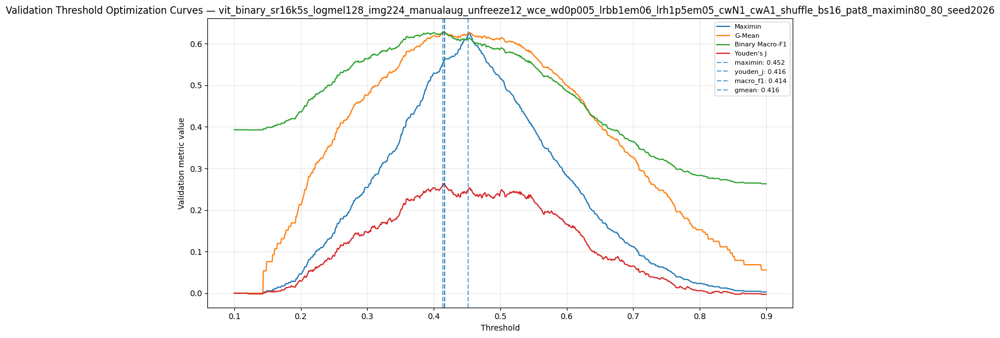


PRIMARY MAXIMIN RESULT — VALIDATION
Threshold                       : 0.452
Validation loss                 : 0.6882
Sensitivity abnormal            : 0.6252
Specificity normal              : 0.6243
Maximin score                   : 0.6243
SE-SP gap                       : 0.0009
Accuracy                        : 0.6249
Macro-F1                        : 0.6117
G-Mean                          : 0.6247
Youden's J                      : 0.2495
ROC-AUC                         : 0.6670
PR-AUC                          : 0.7586
Target 0.80/0.80 met            : False

PRIMARY MAXIMIN RESULT — TEST
THRESHOLD DIKUNCI DARI VALIDATION
Threshold                       : 0.452
Test loss                       : 0.5982
Sensitivity abnormal            : 0.7508
Specificity normal              : 0.6052
Maximin score                   : 0.6052
SE-SP gap                       : 0.1456
Accuracy                        : 0.6622
Macro-F1                        : 0.6604
G-Mean                          : 0.6740

,Pred Normal,Pred Abnormal
True Normal,216,130
True Abnormal,238,397



Test confusion matrix:


,Pred Normal,Pred Abnormal
True Normal,305,199
True Abnormal,81,244



Validation classification report:
              precision    recall  f1-score   support

      normal     0.4758    0.6243    0.5400       346
    abnormal     0.7533    0.6252    0.6833       635

    accuracy                         0.6249       981
   macro avg     0.6145    0.6247    0.6117       981
weighted avg     0.6554    0.6249    0.6328       981


Test classification report:
              precision    recall  f1-score   support

      normal     0.7902    0.6052    0.6854       504
    abnormal     0.5508    0.7508    0.6354       325

    accuracy                         0.6622       829
   macro avg     0.6705    0.6780    0.6604       829
weighted avg     0.6963    0.6622    0.6658       829



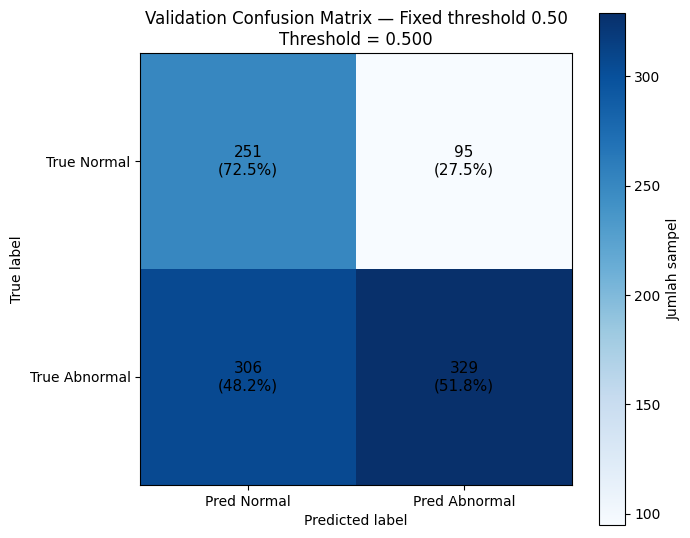

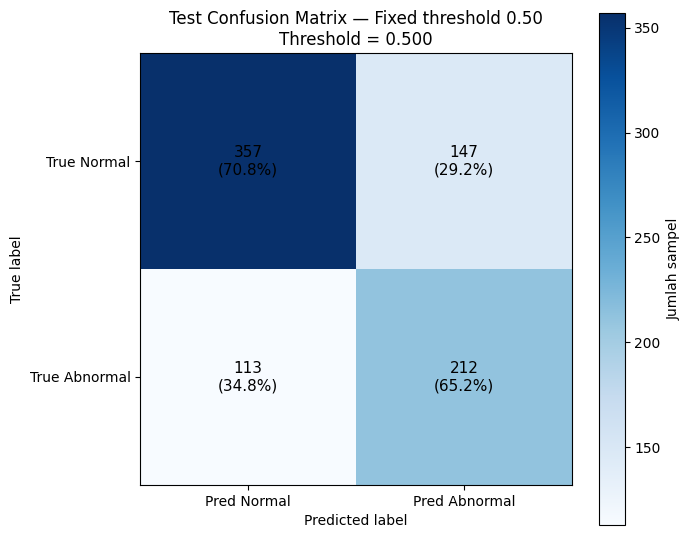

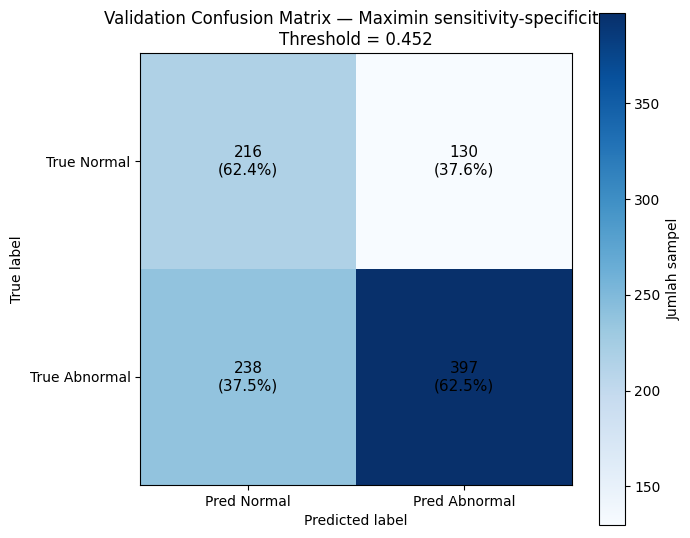

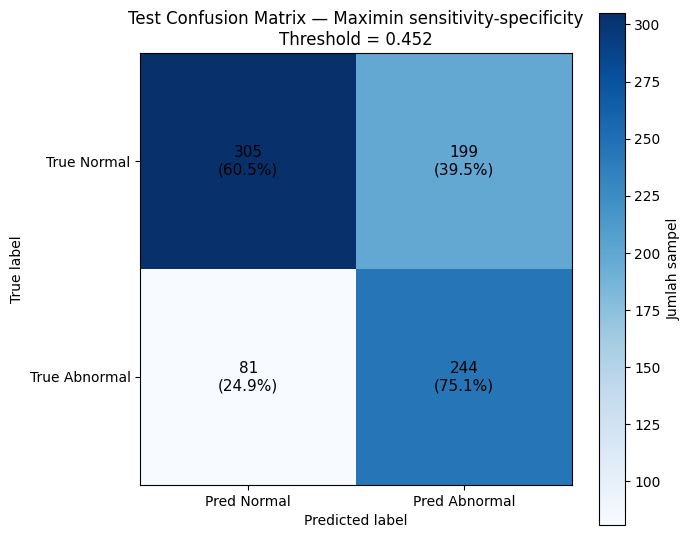

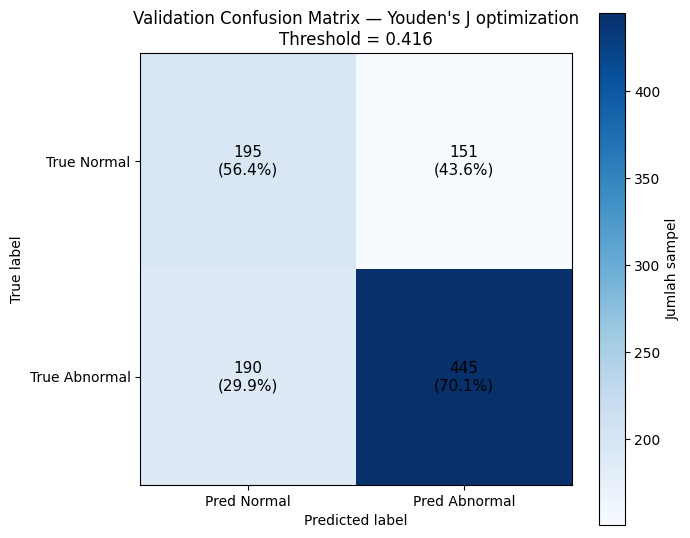

...

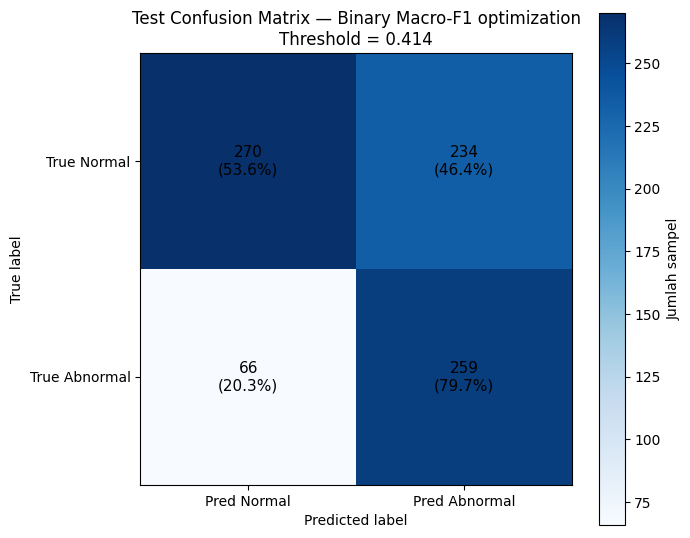

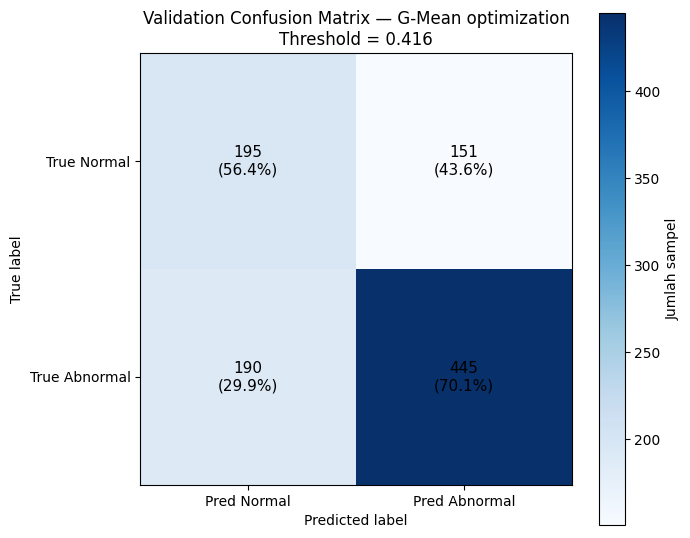

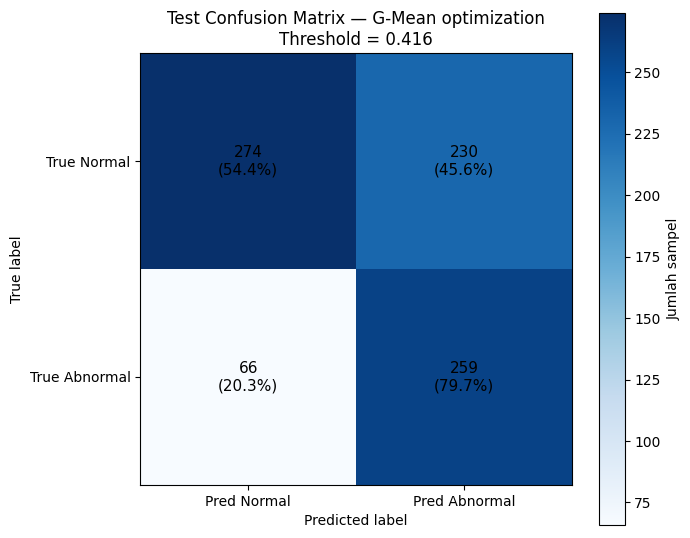

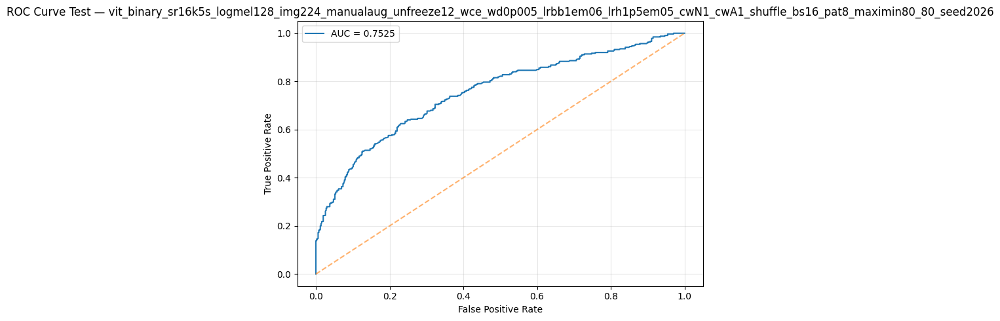

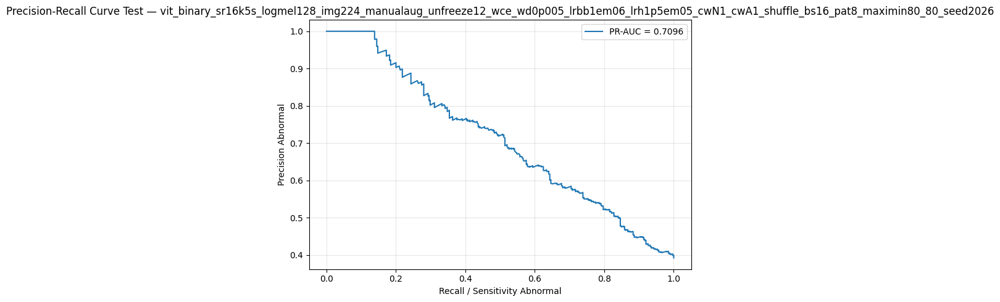


False negative abnormal: 81


,count
sound,
crackle,39
wheeze,33
both,9


,count
patient_id,
178,40
120,15
221,10
151,9
192,4
124,2
129,1



False positive normal: 199


,count
patient_id,
151,52
178,41
120,38
113,31
124,15
188,12
102,4
105,2
155,2



[OK] Cell 41 selesai.
Methods: fixed 0.50, Maximin, Youden's J, Macro-F1, G-Mean.
Primary threshold dipilih hanya dari validation set menggunakan Maximin.
Test set hanya digunakan untuk evaluasi final setelah threshold dikunci.
Summary JSON: results_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026_multi_threshold_summary_maximin_452.json
Method comparison: results_vit/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026/vit_binary_sr16k5s_logmel128_img224_manualaug_unfreeze12_wce_wd0p005_lrbb1em06_lrh1p5em05_cwN1_cwA1_shuffle_bs16_pat8_maximin80_80_seed2026_threshold_method_comparison.csv


In [ ]:
# ============================================================
# CELL 41: MULTI-METHOD THRESHOLD OPTIMIZATION
# ViT-B/16 Binary Normal-Abnormal ICBHI 2017, 16 kHz, 5 s
# ============================================================
# Checkpoint       : best validation maximin checkpoint
# Threshold source : validation set only
# Primary method   : Maximin sensitivity-specificity
# Other methods    : Youden's J, binary Macro-F1, dan G-Mean
# Reference        : fixed threshold 0.50
# ============================================================
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

# ============================================================
# 0. HELPER UMUM
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def safe_float(value):
    try:
        if value is None:
            return None
        value = float(value)
        if not np.isfinite(value):
            return None
        return value
    except Exception:
        return None


def json_safe_value(value):
    if isinstance(value, (np.integer,)):
        return int(value)

    if isinstance(value, (np.floating,)):
        value = float(value)
        return None if not np.isfinite(value) else value

    if isinstance(value, (np.bool_,)):
        return bool(value)

    if isinstance(value, float):
        return None if not np.isfinite(value) else value

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, torch.Tensor):
        return value.detach().cpu().tolist()

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, dict):
        return {
            str(key): json_safe_value(item)
            for key, item in value.items()
        }

    if isinstance(value, (list, tuple)):
        return [json_safe_value(item) for item in value]

    return value


def json_safe_dict(data):
    return {
        str(key): json_safe_value(value)
        for key, value in data.items()
    }


def load_checkpoint_safely(path, device):
    try:
        return torch.load(
            str(path),
            map_location=device,
            weights_only=False,
        )
    except TypeError:
        return torch.load(
            str(path),
            map_location=device,
        )


def get_id2label_value(class_id):
    if class_id in id2label:
        return id2label[class_id]

    if str(class_id) in id2label:
        return id2label[str(class_id)]

    raise KeyError(
        f"id2label tidak mempunyai key {class_id}."
    )


def make_threshold_suffix(threshold):
    return f"{int(round(float(threshold) * 1000)):03d}"


# ============================================================
# 1. VALIDASI GLOBAL WAJIB
# ============================================================

required_globals = [
    "model",
    "criterion",
    "run_one_epoch",
    "val_loader",
    "test_loader",
    "DEVICE",

    "SCENARIO_NAME",
    "CLASSES",
    "label2id",
    "id2label",
    "NUM_CLASSES",
    "LABEL_COL",

    "BEST_MODEL_PATH",
    "RESULT_DIR",

    "LOSS_NAME",
    "USE_CLASS_WEIGHT",
    "MANUAL_CLASS_WEIGHT",
    "CLASS_WEIGHT_METHOD",
    "CLASS_WEIGHT_METHOD_EFFECTIVE",

    "LEARNING_RATE",
    "LR_BACKBONE",
    "LR_HEAD",
    "WEIGHT_DECAY",
    "NUM_EPOCHS",
    "BATCH_SIZE",
    "PATIENCE",
    "UNFREEZE_LAST_N_BLOCKS",
    "USE_LAYER_WISE_LR_DECAY",
    "LAYER_LR_DECAY",

    "CHECKPOINT_MONITOR",
    "EARLY_STOPPING_MONITOR",
    "CHECKPOINT_MODE",

    "PRIMARY_THRESHOLD_METHOD",
    "TARGET_SENSITIVITY_ABNORMAL",
    "TARGET_SPECIFICITY_NORMAL",

    "TARGET_SR",
    "TARGET_DURATION_SEC",
    "TARGET_LEN_SAMPLES",
    "N_MELS",
    "FMIN",
    "FMAX",
    "N_FFT",
    "HOP_LENGTH",
    "WIN_LENGTH",
    "IMAGE_SIZE",
]

missing_globals = [
    key for key in required_globals
    if key not in globals()
]

if missing_globals:
    raise RuntimeError(
        f"Global berikut belum tersedia: {missing_globals}\n"
        "Jalankan Global Configuration Maximin, metadata, "
        "DataLoader, Cell 35 Maximin, dan Training Loop "
        "Maximin terlebih dahulu."
    )


# ============================================================
# 2. VALIDASI KONFIGURASI EKSPERIMEN
# ============================================================

if int(NUM_CLASSES) != 2:
    raise ValueError(
        "Cell 41 ini hanya untuk klasifikasi binary."
    )

if list(CLASSES) != ["normal", "abnormal"]:
    raise ValueError(
        "CLASSES wajib ['normal', 'abnormal']. "
        f"Saat ini: {CLASSES}"
    )

if LABEL_COL != "binary_label":
    raise ValueError(
        "LABEL_COL wajib 'binary_label'. "
        f"Saat ini: {LABEL_COL}"
    )

NEG_LABEL = str(globals().get("NEG_LABEL", "normal"))
POS_LABEL = str(globals().get("POS_LABEL", "abnormal"))

NEG_LABEL_ID = int(label2id[NEG_LABEL])
POS_LABEL_ID = int(label2id[POS_LABEL])

if NEG_LABEL_ID != 0 or POS_LABEL_ID != 1:
    raise ValueError(
        "Mapping label wajib normal=0 dan abnormal=1. "
        f"Saat ini normal={NEG_LABEL_ID}, "
        f"abnormal={POS_LABEL_ID}."
    )

LOSS_NAME = str(LOSS_NAME).lower().strip()
USE_CLASS_WEIGHT = bool(USE_CLASS_WEIGHT)
MANUAL_CLASS_WEIGHT = bool(MANUAL_CLASS_WEIGHT)

CLASS_WEIGHT_METHOD = str(
    CLASS_WEIGHT_METHOD
).lower().strip()

CLASS_WEIGHT_METHOD_EFFECTIVE = str(
    CLASS_WEIGHT_METHOD_EFFECTIVE
).lower().strip()

criterion_runtime_name = str(
    globals().get(
        "criterion_runtime_name",
        criterion.__class__.__name__,
    )
)

if (
    LOSS_NAME == "weighted_ce"
    and criterion_runtime_name == "CrossEntropyLoss"
    and getattr(criterion, "weight", None) is not None
):
    criterion_runtime_name = "WeightedCrossEntropyLoss"

if LOSS_NAME != "weighted_ce":
    raise AssertionError(
        "Konfigurasi saat ini diharapkan memakai "
        "LOSS_NAME='weighted_ce'. "
        f"Saat ini: {LOSS_NAME}"
    )

if not USE_CLASS_WEIGHT:
    raise AssertionError(
        "USE_CLASS_WEIGHT harus True untuk weighted CE."
    )

if criterion_runtime_name != "WeightedCrossEntropyLoss":
    raise AssertionError(
        "Runtime criterion harus WeightedCrossEntropyLoss. "
        f"Saat ini: {criterion_runtime_name}"
    )

if getattr(criterion, "weight", None) is None:
    raise AssertionError(
        "criterion.weight tidak boleh None."
    )

criterion_weight_values = (
    criterion.weight
    .detach()
    .cpu()
    .numpy()
    .astype(float)
)

if criterion_weight_values.shape != (2,):
    raise AssertionError(
        "Criterion binary harus mempunyai dua bobot. "
        f"Shape saat ini: {criterion_weight_values.shape}"
    )

if not np.all(np.isfinite(criterion_weight_values)):
    raise AssertionError(
        "Bobot criterion mengandung NaN atau Inf."
    )

if np.any(criterion_weight_values <= 0):
    raise AssertionError(
        "Seluruh bobot criterion harus positif."
    )

NORMAL_WEIGHT = float(
    globals().get("NORMAL_WEIGHT", 1.0)
)
ABNORMAL_WEIGHT = float(
    globals().get("ABNORMAL_WEIGHT", 1.0)
)

expected_criterion_weights = np.asarray(
    [NORMAL_WEIGHT, ABNORMAL_WEIGHT],
    dtype=float,
)

if MANUAL_CLASS_WEIGHT:
    if not np.allclose(
        criterion_weight_values,
        expected_criterion_weights,
        rtol=1e-6,
        atol=1e-8,
    ):
        raise AssertionError(
            "Bobot criterion tidak sesuai bobot manual.\n"
            f"Expected: {expected_criterion_weights.tolist()}\n"
            f"Actual  : {criterion_weight_values.tolist()}"
        )

TARGET_SR = int(TARGET_SR)
TARGET_DURATION_SEC = float(TARGET_DURATION_SEC)
TARGET_LEN_SAMPLES = int(TARGET_LEN_SAMPLES)
N_MELS = int(N_MELS)
FMIN = int(FMIN)
FMAX = int(FMAX)
N_FFT = int(N_FFT)
HOP_LENGTH = int(HOP_LENGTH)
WIN_LENGTH = int(WIN_LENGTH)
IMAGE_SIZE = int(IMAGE_SIZE)

if TARGET_SR != 16000:
    raise AssertionError(
        f"TARGET_SR harus 16000. Saat ini: {TARGET_SR}"
    )

if not np.isclose(TARGET_DURATION_SEC, 5.0):
    raise AssertionError(
        "TARGET_DURATION_SEC harus 5.0. "
        f"Saat ini: {TARGET_DURATION_SEC}"
    )

if TARGET_LEN_SAMPLES != 80000:
    raise AssertionError(
        "TARGET_LEN_SAMPLES harus 80000. "
        f"Saat ini: {TARGET_LEN_SAMPLES}"
    )

if N_MELS != 128:
    raise AssertionError(
        f"N_MELS harus 128. Saat ini: {N_MELS}"
    )

if N_FFT != 2048:
    raise AssertionError(
        f"N_FFT harus 2048. Saat ini: {N_FFT}"
    )

if HOP_LENGTH != 128:
    raise AssertionError(
        f"HOP_LENGTH harus 128. Saat ini: {HOP_LENGTH}"
    )

if WIN_LENGTH != 2048:
    raise AssertionError(
        f"WIN_LENGTH harus 2048. Saat ini: {WIN_LENGTH}"
    )

if IMAGE_SIZE != 224:
    raise AssertionError(
        f"IMAGE_SIZE harus 224. Saat ini: {IMAGE_SIZE}"
    )

NYQUIST = TARGET_SR // 2

if not (0 <= FMIN < FMAX <= NYQUIST):
    raise AssertionError(
        f"FMIN/FMAX tidak valid: {FMIN}/{FMAX}."
    )


# ============================================================
# 3. KONFIGURASI CHECKPOINT DAN THRESHOLD
# ============================================================

CHECKPOINT_MONITOR = str(
    CHECKPOINT_MONITOR
).strip()
EARLY_STOPPING_MONITOR = str(
    EARLY_STOPPING_MONITOR
).strip()
CHECKPOINT_MODE = str(
    CHECKPOINT_MODE
).lower().strip()

if CHECKPOINT_MONITOR != "val_maximin_score":
    raise AssertionError(
        "CHECKPOINT_MONITOR harus 'val_maximin_score'. "
        f"Saat ini: {CHECKPOINT_MONITOR}"
    )

if CHECKPOINT_MODE != "max":
    raise AssertionError(
        "CHECKPOINT_MODE harus 'max'. "
        f"Saat ini: {CHECKPOINT_MODE}"
    )

if EARLY_STOPPING_MONITOR != "val_loss":
    raise AssertionError(
        "EARLY_STOPPING_MONITOR harus 'val_loss'. "
        f"Saat ini: {EARLY_STOPPING_MONITOR}"
    )

if EARLY_STOPPING_MODE != "min":
    raise AssertionError(
        "EARLY_STOPPING_MODE harus 'min'. "
        f"Saat ini: {EARLY_STOPPING_MODE}"
    )
PRIMARY_THRESHOLD_METHOD = str(
    PRIMARY_THRESHOLD_METHOD
).lower().strip()

ALLOWED_THRESHOLD_METHODS = {
    "maximin",
    "youden_j",
    "macro_f1",
    "gmean",
}

if PRIMARY_THRESHOLD_METHOD not in ALLOWED_THRESHOLD_METHODS:
    raise ValueError(
        "PRIMARY_THRESHOLD_METHOD tidak valid. "
        f"Saat ini: {PRIMARY_THRESHOLD_METHOD}; "
        f"pilihan: {sorted(ALLOWED_THRESHOLD_METHODS)}"
    )

if PRIMARY_THRESHOLD_METHOD != "maximin":
    raise AssertionError(
        "Untuk eksperimen target sensitivity-specificity seimbang, "
        "PRIMARY_THRESHOLD_METHOD harus 'maximin'. "
        f"Saat ini: {PRIMARY_THRESHOLD_METHOD}"
    )

TARGET_SENSITIVITY_ABNORMAL = float(
    TARGET_SENSITIVITY_ABNORMAL
)
TARGET_SPECIFICITY_NORMAL = float(
    TARGET_SPECIFICITY_NORMAL
)

for target_name, target_value in {
    "TARGET_SENSITIVITY_ABNORMAL": TARGET_SENSITIVITY_ABNORMAL,
    "TARGET_SPECIFICITY_NORMAL": TARGET_SPECIFICITY_NORMAL,
}.items():
    if not (0.0 <= target_value <= 1.0):
        raise ValueError(
            f"{target_name} harus berada pada [0, 1]. "
            f"Saat ini: {target_value}"
        )

DEFAULT_TEST_THRESHOLD = float(
    globals().get("DEFAULT_TEST_THRESHOLD", 0.50)
)
THRESHOLD_MIN = float(
    globals().get("THRESHOLD_MIN", 0.05)
)
THRESHOLD_MAX = float(
    globals().get("THRESHOLD_MAX", 0.95)
)
THRESHOLD_STEP = float(
    globals().get("THRESHOLD_STEP", 0.001)
)

if not (0.0 <= DEFAULT_TEST_THRESHOLD <= 1.0):
    raise ValueError(
        "DEFAULT_TEST_THRESHOLD harus berada pada [0, 1]."
    )

if not (0.0 <= THRESHOLD_MIN < THRESHOLD_MAX <= 1.0):
    raise ValueError(
        "Range threshold tidak valid: "
        f"{THRESHOLD_MIN} sampai {THRESHOLD_MAX}."
    )

if THRESHOLD_STEP <= 0:
    raise ValueError(
        "THRESHOLD_STEP harus lebih besar dari nol."
    )

ENABLE_THRESHOLD_TUNING = True
PRIMARY_OPERATING_POINT = (
    "validation_selected_maximin_operating_point"
)
THRESHOLD_SELECTION_METRIC = (
    "maximize_validation_min_sensitivity_specificity"
)

RESULT_DIR = Path(RESULT_DIR)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = Path(BEST_MODEL_PATH)

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Best checkpoint tidak ditemukan: {BEST_MODEL_PATH}\n"
        "Jalankan Training Loop Maximin terlebih dahulu."
    )

if "best_val_maximin_score" not in BEST_MODEL_PATH.name:
    raise AssertionError(
        "BEST_MODEL_PATH belum menunjuk checkpoint Maximin. "
        f"Saat ini: {BEST_MODEL_PATH}"
    )

print("=" * 100)
print("CELL 41 — MAXIMIN THRESHOLD EVALUATION CONFIG")
print("=" * 100)
print("SCENARIO_NAME                    :", SCENARIO_NAME)
print("BEST_MODEL_PATH                  :", BEST_MODEL_PATH)
print("RESULT_DIR                       :", RESULT_DIR)
print("CHECKPOINT_MONITOR               :", CHECKPOINT_MONITOR)
print("EARLY_STOPPING_MONITOR           :", EARLY_STOPPING_MONITOR)
print("PRIMARY_THRESHOLD_METHOD         :", PRIMARY_THRESHOLD_METHOD)
print("ALLOWED_THRESHOLD_METHODS        :", sorted(ALLOWED_THRESHOLD_METHODS))
print("TARGET_SENSITIVITY_ABNORMAL      :", TARGET_SENSITIVITY_ABNORMAL)
print("TARGET_SPECIFICITY_NORMAL        :", TARGET_SPECIFICITY_NORMAL)
print("THRESHOLD_MIN                    :", THRESHOLD_MIN)
print("THRESHOLD_MAX                    :", THRESHOLD_MAX)
print("THRESHOLD_STEP                   :", THRESHOLD_STEP)
print("Criterion class weights         :", criterion_weight_values.tolist())
print("=" * 100)


# ============================================================
# 4. LOAD BEST MAXIMIN CHECKPOINT
# ============================================================

checkpoint = load_checkpoint_safely(
    BEST_MODEL_PATH,
    DEVICE,
)

if not isinstance(checkpoint, dict):
    raise RuntimeError(
        "Checkpoint harus berupa dictionary."
    )

if "model_state_dict" not in checkpoint:
    raise RuntimeError(
        "Checkpoint tidak mempunyai model_state_dict."
    )

model.load_state_dict(
    checkpoint["model_state_dict"]
)
model = model.to(DEVICE)
model.eval()

checkpoint_epoch = checkpoint.get("epoch", None)
checkpoint_type = checkpoint.get(
    "checkpoint_type",
    "best_val_maximin_score",
)
checkpoint_monitor = str(
    checkpoint.get(
        "checkpoint_monitor",
        CHECKPOINT_MONITOR,
    )
)
checkpoint_mode = str(
    checkpoint.get(
        "checkpoint_mode",
        CHECKPOINT_MODE,
    )
)
checkpoint_selection_rule = str(
    checkpoint.get(
        "selection_rule",
        "maximize_validation_maximin_score",
    )
)

if checkpoint_monitor != "val_maximin_score":
    raise AssertionError(
        "Checkpoint yang dimuat bukan checkpoint Maximin. "
        f"Monitor checkpoint: {checkpoint_monitor}"
    )

checkpoint_best_val_loss = checkpoint.get(
    "best_val_loss",
    None,
)
checkpoint_best_val_maximin_score = checkpoint.get(
    "best_val_maximin_score",
    checkpoint.get("best_monitor_value", None),
)
checkpoint_best_validation_threshold = checkpoint.get(
    "best_validation_threshold",
    None,
)
checkpoint_best_val_sensitivity = checkpoint.get(
    "best_val_sensitivity_abnormal",
    None,
)
checkpoint_best_val_specificity = checkpoint.get(
    "best_val_specificity_normal",
    None,
)
checkpoint_best_target_met = checkpoint.get(
    "best_val_target_80_80_met",
    checkpoint.get("target_80_80_met", None),
)

checkpoint_loss_name = str(
    checkpoint.get("loss_name", LOSS_NAME)
)
checkpoint_class_weight_method = str(
    checkpoint.get(
        "class_weight_method_effective",
        checkpoint.get(
            "class_weight_method",
            CLASS_WEIGHT_METHOD_EFFECTIVE,
        ),
    )
)
checkpoint_scheduler = str(
    checkpoint.get(
        "scheduler",
        globals().get(
            "scheduler_name_runtime",
            globals().get("SCHEDULER_NAME", "unknown"),
        ),
    )
)
checkpoint_criterion_runtime = str(
    checkpoint.get(
        "criterion_runtime",
        criterion_runtime_name,
    )
)

print("\n" + "=" * 100)
print("BEST MAXIMIN CHECKPOINT LOADED")
print("=" * 100)
print("Checkpoint epoch                 :", checkpoint_epoch)
print("Checkpoint type                  :", checkpoint_type)
print("Checkpoint monitor               :", checkpoint_monitor)
print("Checkpoint mode                  :", checkpoint_mode)
print("Selection rule                   :", checkpoint_selection_rule)
print("Stored val maximin score         :", checkpoint_best_val_maximin_score)
print("Stored validation threshold      :", checkpoint_best_validation_threshold)
print("Stored validation sensitivity    :", checkpoint_best_val_sensitivity)
print("Stored validation specificity    :", checkpoint_best_val_specificity)
print("Stored validation target met     :", checkpoint_best_target_met)
print("=" * 100)


# ============================================================
# 5. METRIK BINARY PADA SATU THRESHOLD
# ============================================================

def compute_binary_metrics_from_prob(
    y_true,
    prob_abnormal,
    threshold=0.50,
    target_sensitivity=TARGET_SENSITIVITY_ABNORMAL,
    target_specificity=TARGET_SPECIFICITY_NORMAL,
):
    """Hitung metrik binary menggunakan satu threshold tertentu."""

    y_true = np.asarray(y_true).astype(int)
    prob_abnormal = np.asarray(
        prob_abnormal
    ).astype(float)
    threshold = float(threshold)

    if y_true.ndim != 1:
        raise ValueError(
            "y_true harus array satu dimensi."
        )

    if prob_abnormal.ndim != 1:
        raise ValueError(
            "prob_abnormal harus array satu dimensi."
        )

    if len(y_true) != len(prob_abnormal):
        raise ValueError(
            "Panjang y_true dan prob_abnormal tidak sama."
        )

    if len(y_true) == 0:
        raise ValueError(
            "Data evaluasi kosong."
        )

    if not np.all(np.isfinite(prob_abnormal)):
        raise ValueError(
            "prob_abnormal mengandung NaN atau Inf."
        )

    if not (0.0 <= threshold <= 1.0):
        raise ValueError(
            "Threshold harus berada pada [0, 1]."
        )

    y_pred = (
        prob_abnormal >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[NEG_LABEL_ID, POS_LABEL_ID],
    )

    if cm.shape != (2, 2):
        raise RuntimeError(
            f"Confusion matrix bukan 2x2: {cm.shape}"
        )

    tn, fp, fn, tp = cm.ravel()

    sensitivity_abnormal = (
        tp / max(tp + fn, 1)
    )
    specificity_normal = (
        tn / max(tn + fp, 1)
    )

    precision_abnormal = (
        tp / max(tp + fp, 1)
    )
    precision_normal = (
        tn / max(tn + fn, 1)
    )

    recall_abnormal = sensitivity_abnormal
    recall_normal = specificity_normal

    f1_normal = (
        2.0
        * precision_normal
        * recall_normal
        / max(precision_normal + recall_normal, 1e-12)
    )
    f1_abnormal = (
        2.0
        * precision_abnormal
        * recall_abnormal
        / max(precision_abnormal + recall_abnormal, 1e-12)
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=[NEG_LABEL_ID, POS_LABEL_ID],
        average="macro",
        zero_division=0,
    )

    accuracy = (
        (tp + tn)
        / max(tp + tn + fp + fn, 1)
    )
    balanced_accuracy = (
        sensitivity_abnormal + specificity_normal
    ) / 2.0
    harmonic_score = (
        2.0
        * sensitivity_abnormal
        * specificity_normal
        / max(
            sensitivity_abnormal + specificity_normal,
            1e-12,
        )
    )
    youden_j = (
        sensitivity_abnormal + specificity_normal - 1.0
    )
    gmean = np.sqrt(
        max(sensitivity_abnormal, 0.0)
        * max(specificity_normal, 0.0)
    )
    maximin_score = min(
        sensitivity_abnormal,
        specificity_normal,
    )
    sensitivity_specificity_gap = abs(
        sensitivity_abnormal - specificity_normal
    )

    target_sensitivity_met = bool(
        sensitivity_abnormal >= float(target_sensitivity)
    )
    target_specificity_met = bool(
        specificity_normal >= float(target_specificity)
    )
    joint_target_met = bool(
        target_sensitivity_met
        and target_specificity_met
    )

    try:
        auc = float(
            roc_auc_score(y_true, prob_abnormal)
        )
    except Exception:
        auc = np.nan

    try:
        pr_auc = float(
            average_precision_score(
                y_true,
                prob_abnormal,
            )
        )
    except Exception:
        pr_auc = np.nan

    return {
        "threshold": threshold,
        "accuracy": float(accuracy),
        "sensitivity_abnormal": float(
            sensitivity_abnormal
        ),
        "specificity_normal": float(
            specificity_normal
        ),
        "precision_normal": float(precision_normal),
        "precision_abnormal": float(
            precision_abnormal
        ),
        "recall_normal": float(recall_normal),
        "recall_abnormal": float(recall_abnormal),
        "f1_normal": float(f1_normal),
        "f1_abnormal": float(f1_abnormal),
        "macro_f1": float(macro_f1),
        "binary_macro_f1": float(macro_f1),
        "balanced_score": float(balanced_accuracy),
        "balanced_accuracy": float(balanced_accuracy),
        "harmonic_score": float(harmonic_score),
        "youden_j": float(youden_j),
        "gmean": float(gmean),
        "maximin_score": float(maximin_score),
        "sensitivity_specificity_gap": float(
            sensitivity_specificity_gap
        ),
        "target_sensitivity_met": target_sensitivity_met,
        "target_specificity_met": target_specificity_met,
        "joint_target_met": joint_target_met,
        "auc": auc,
        "pr_auc": pr_auc,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "confusion_matrix": cm,
        "y_pred": y_pred,
    }


# ============================================================
# 6. VALIDATION THRESHOLD SWEEP
# ============================================================

def build_validation_threshold_sweep(
    y_true,
    prob_abnormal,
    threshold_min=THRESHOLD_MIN,
    threshold_max=THRESHOLD_MAX,
    threshold_step=THRESHOLD_STEP,
    default_threshold=DEFAULT_TEST_THRESHOLD,
    target_sensitivity=TARGET_SENSITIVITY_ABNORMAL,
    target_specificity=TARGET_SPECIFICITY_NORMAL,
):
    """
    Bangun seluruh kandidat threshold dari validation set saja.

    Test labels dan test probabilities tidak diterima fungsi ini.
    """

    thresholds = np.arange(
        float(threshold_min),
        float(threshold_max) + 1e-12,
        float(threshold_step),
    )

    if len(thresholds) == 0:
        raise RuntimeError(
            "Tidak ada kandidat threshold."
        )

    rows = []

    for threshold in thresholds:
        metrics = compute_binary_metrics_from_prob(
            y_true=y_true,
            prob_abnormal=prob_abnormal,
            threshold=float(threshold),
            target_sensitivity=target_sensitivity,
            target_specificity=target_specificity,
        )

        rows.append({
            "threshold": float(threshold),
            "accuracy": metrics["accuracy"],
            "sensitivity_abnormal": metrics[
                "sensitivity_abnormal"
            ],
            "specificity_normal": metrics[
                "specificity_normal"
            ],
            "precision_normal": metrics[
                "precision_normal"
            ],
            "precision_abnormal": metrics[
                "precision_abnormal"
            ],
            "f1_normal": metrics["f1_normal"],
            "f1_abnormal": metrics["f1_abnormal"],
            "macro_f1": metrics["macro_f1"],
            "balanced_score": metrics[
                "balanced_score"
            ],
            "harmonic_score": metrics[
                "harmonic_score"
            ],
            "youden_j": metrics["youden_j"],
            "gmean": metrics["gmean"],
            "maximin_score": metrics[
                "maximin_score"
            ],
            "sensitivity_specificity_gap": metrics[
                "sensitivity_specificity_gap"
            ],
            "target_sensitivity_met": metrics[
                "target_sensitivity_met"
            ],
            "target_specificity_met": metrics[
                "target_specificity_met"
            ],
            "joint_target_met": metrics[
                "joint_target_met"
            ],
            "tn": metrics["tn"],
            "fp": metrics["fp"],
            "fn": metrics["fn"],
            "tp": metrics["tp"],
        })

    sweep_df = pd.DataFrame(rows)

    sweep_df["target_sensitivity"] = float(
        target_sensitivity
    )
    sweep_df["target_specificity"] = float(
        target_specificity
    )
    sweep_df["threshold_distance_from_050"] = (
        sweep_df["threshold"]
        - float(default_threshold)
    ).abs()

    return sweep_df


def _selection_payload(
    chosen,
    method,
    policy,
    objective_name,
    selection_step,
):
    payload = chosen.to_dict()
    payload.update({
        "method": str(method),
        "policy": str(policy),
        "objective_name": str(objective_name),
        "objective_value": float(
            chosen[objective_name]
        ),
        "selection_step": str(selection_step),
        "selected_from": "validation_set_only",
        "test_used_for_selection": False,
    })
    return payload


def select_maximin_threshold(sweep_df):
    """
    Maksimalkan nilai terendah antara sensitivity dan specificity.

    Tie-break:
    1. G-Mean;
    2. Macro-F1;
    3. balanced accuracy;
    4. gap SE-SP terkecil;
    5. threshold terdekat ke 0.50;
    6. threshold lebih kecil.
    """

    required_columns = {
        "threshold",
        "maximin_score",
        "gmean",
        "macro_f1",
        "balanced_score",
        "sensitivity_specificity_gap",
        "threshold_distance_from_050",
    }

    missing_columns = sorted(
        required_columns - set(sweep_df.columns)
    )

    if missing_columns:
        raise ValueError(
            "Threshold sweep kehilangan kolom: "
            f"{missing_columns}"
        )

    chosen = (
        sweep_df
        .sort_values(
            by=[
                "maximin_score",
                "gmean",
                "macro_f1",
                "balanced_score",
                "sensitivity_specificity_gap",
                "threshold_distance_from_050",
                "threshold",
            ],
            ascending=[
                False,
                False,
                False,
                False,
                True,
                True,
                True,
            ],
        )
        .iloc[0]
    )

    payload = _selection_payload(
        chosen=chosen,
        method="maximin",
        policy=(
            "maximize_validation_min_sensitivity_specificity"
        ),
        objective_name="maximin_score",
        selection_step=(
            "maximize_validation_maximin_then_gmean_"
            "macro_f1_balance"
        ),
    )

    payload.update({
        "definition": (
            "min(sensitivity_abnormal, "
            "specificity_normal)"
        ),
        "target_sensitivity": float(
            TARGET_SENSITIVITY_ABNORMAL
        ),
        "target_specificity": float(
            TARGET_SPECIFICITY_NORMAL
        ),
        "joint_target_met": bool(
            chosen["joint_target_met"]
        ),
    })

    return payload


def select_max_metric_threshold(
    sweep_df,
    method,
    objective_name,
    policy,
    tie_break_columns,
    tie_break_ascending,
):
    sort_columns = [
        objective_name,
        *list(tie_break_columns),
    ]
    ascending = [
        False,
        *list(tie_break_ascending),
    ]

    chosen = (
        sweep_df
        .sort_values(
            by=sort_columns,
            ascending=ascending,
        )
        .iloc[0]
    )

    return _selection_payload(
        chosen=chosen,
        method=method,
        policy=policy,
        objective_name=objective_name,
        selection_step=(
            f"maximize_validation_{objective_name}"
        ),
    )


def select_thresholds_multi_method(sweep_df):
    """
    Pilih seluruh threshold menggunakan validation sweep yang sama.

    Fungsi ini tidak menerima test set.
    """

    selections = {}

    selections["maximin"] = (
        select_maximin_threshold(sweep_df)
    )

    selections["youden_j"] = (
        select_max_metric_threshold(
            sweep_df=sweep_df,
            method="youden_j",
            objective_name="youden_j",
            policy="maximize_validation_youden_j",
            tie_break_columns=[
                "maximin_score",
                "gmean",
                "macro_f1",
                "sensitivity_specificity_gap",
                "threshold_distance_from_050",
                "threshold",
            ],
            tie_break_ascending=[
                False,
                False,
                False,
                True,
                True,
                True,
            ],
        )
    )

    selections["macro_f1"] = (
        select_max_metric_threshold(
            sweep_df=sweep_df,
            method="macro_f1",
            objective_name="macro_f1",
            policy=(
                "maximize_validation_binary_macro_f1"
            ),
            tie_break_columns=[
                "maximin_score",
                "gmean",
                "youden_j",
                "sensitivity_specificity_gap",
                "threshold_distance_from_050",
                "threshold",
            ],
            tie_break_ascending=[
                False,
                False,
                False,
                True,
                True,
                True,
            ],
        )
    )

    selections["gmean"] = (
        select_max_metric_threshold(
            sweep_df=sweep_df,
            method="gmean",
            objective_name="gmean",
            policy=(
                "maximize_validation_geometric_mean"
            ),
            tie_break_columns=[
                "maximin_score",
                "macro_f1",
                "youden_j",
                "sensitivity_specificity_gap",
                "threshold_distance_from_050",
                "threshold",
            ],
            tie_break_ascending=[
                False,
                False,
                False,
                True,
                True,
                True,
            ],
        )
    )

    return selections


def select_threshold_from_validation(
    y_true,
    prob_abnormal,
    threshold_min=THRESHOLD_MIN,
    threshold_max=THRESHOLD_MAX,
    threshold_step=THRESHOLD_STEP,
):
    """Alias kompatibilitas: kembalikan operating point Maximin."""

    sweep_df = build_validation_threshold_sweep(
        y_true=y_true,
        prob_abnormal=prob_abnormal,
        threshold_min=threshold_min,
        threshold_max=threshold_max,
        threshold_step=threshold_step,
    )

    selected = select_maximin_threshold(sweep_df)

    return (
        float(selected["threshold"]),
        str(selected["policy"]),
        sweep_df,
        selected,
    )


def build_prediction_df(
    y_true,
    prob_abnormal,
    y_pred,
    threshold,
    threshold_policy,
    threshold_method,
    df_meta=None,
):
    y_true = np.asarray(y_true).astype(int)
    prob_abnormal = np.asarray(
        prob_abnormal
    ).astype(float)
    y_pred = np.asarray(y_pred).astype(int)

    pred_df = pd.DataFrame({
        "y_true_id": y_true,
        "y_true_label": [
            get_id2label_value(int(item))
            for item in y_true
        ],
        "prob_abnormal": prob_abnormal,
        "prob_normal": 1.0 - prob_abnormal,
        "y_pred_id": y_pred,
        "y_pred_label": [
            get_id2label_value(int(item))
            for item in y_pred
        ],
        "threshold": float(threshold),
        "threshold_method": str(threshold_method),
        "threshold_policy": str(threshold_policy),
        "is_correct": y_true == y_pred,
    })

    if df_meta is not None and len(df_meta) == len(pred_df):
        metadata = df_meta.reset_index(drop=True).copy()

        metadata_columns = [
            "image_path",
            "sound",
            "sound_4class",
            "original_sound",
            "binary_label",
            "patient_id",
            "split",
            "is_augmented",
            "augmentation_group",
            "aug_type",
            "file",
            "image_sr",
            "image_n_mels",
            "image_fmin",
            "image_fmax",
            "image_hop_length",
            "image_expected_len_samples",
        ]

        for column in metadata_columns:
            if column in metadata.columns:
                pred_df[column] = metadata[column].values

    return pred_df


# ============================================================
# 7. EVALUASI RAW VALIDATION DAN TEST
# ============================================================

print("\n" + "=" * 100)
print("RAW INFERENCE — VALIDATION DAN TEST")
print("=" * 100)
print("Threshold selection source      : validation set only")
print("Test used for selection         : False")
print("=" * 100)

val_raw_metrics = run_one_epoch(
    model=model,
    loader=val_loader,
    criterion=criterion,
    optimizer=None,
    scaler=None,
    device=DEVICE,
)

test_raw_metrics = run_one_epoch(
    model=model,
    loader=test_loader,
    criterion=criterion,
    optimizer=None,
    scaler=None,
    device=DEVICE,
)

for split_name, split_metrics in {
    "validation": val_raw_metrics,
    "test": test_raw_metrics,
}.items():
    for required_key in [
        "loss",
        "y_true",
        "y_prob_abnormal",
    ]:
        if required_key not in split_metrics:
            raise KeyError(
                f"run_one_epoch untuk {split_name} tidak "
                f"menghasilkan {required_key}."
            )


y_val = np.asarray(
    val_raw_metrics["y_true"]
).astype(int)
val_prob_abnormal = np.asarray(
    val_raw_metrics["y_prob_abnormal"]
).astype(float)

y_test = np.asarray(
    test_raw_metrics["y_true"]
).astype(int)
test_prob_abnormal = np.asarray(
    test_raw_metrics["y_prob_abnormal"]
).astype(float)


# ============================================================
# 8. VALIDATION-ONLY MULTI-METHOD THRESHOLD SELECTION
# ============================================================

fixed_threshold = float(DEFAULT_TEST_THRESHOLD)
fixed_policy = "fixed_default_threshold_0_50"

threshold_sweep_df = build_validation_threshold_sweep(
    y_true=y_val,
    prob_abnormal=val_prob_abnormal,
    threshold_min=THRESHOLD_MIN,
    threshold_max=THRESHOLD_MAX,
    threshold_step=THRESHOLD_STEP,
    default_threshold=fixed_threshold,
    target_sensitivity=TARGET_SENSITIVITY_ABNORMAL,
    target_specificity=TARGET_SPECIFICITY_NORMAL,
)

threshold_selections = (
    select_thresholds_multi_method(
        sweep_df=threshold_sweep_df,
    )
)

fixed_selection = {
    "method": "fixed_050",
    "threshold": fixed_threshold,
    "policy": fixed_policy,
    "objective_name": "none_reference",
    "objective_value": np.nan,
    "selection_step": "fixed_reference",
    "selected_from": "predefined_threshold",
    "test_used_for_selection": False,
}

all_threshold_selections = {
    "fixed_050": fixed_selection,
    **threshold_selections,
}

method_evaluations = {}

for method_name, selection in all_threshold_selections.items():
    selected_threshold = float(
        selection["threshold"]
    )

    validation_metrics = (
        compute_binary_metrics_from_prob(
            y_true=y_val,
            prob_abnormal=val_prob_abnormal,
            threshold=selected_threshold,
        )
    )

    # Threshold sudah dikunci dari validation sebelum baris ini.
    test_metrics_method = (
        compute_binary_metrics_from_prob(
            y_true=y_test,
            prob_abnormal=test_prob_abnormal,
            threshold=selected_threshold,
        )
    )

    method_evaluations[method_name] = {
        "selection": selection,
        "validation": validation_metrics,
        "test": test_metrics_method,
    }

primary_result = method_evaluations[
    PRIMARY_THRESHOLD_METHOD
]
primary_selection = primary_result["selection"]

BEST_THRESHOLD = float(
    primary_selection["threshold"]
)
EVALUATION_THRESHOLD_POLICY = str(
    primary_selection["policy"]
)

val_metrics = primary_result["validation"]
test_metrics = primary_result["test"]

val_pred = val_metrics["y_pred"]
test_pred = test_metrics["y_pred"]

val_cm = np.asarray(
    val_metrics["confusion_matrix"],
    dtype=np.int64,
)
test_cm = np.asarray(
    test_metrics["confusion_matrix"],
    dtype=np.int64,
)

val_tn, val_fp, val_fn, val_tp = val_cm.ravel()
tn, fp, fn, tp = test_cm.ravel()

val_target_met = bool(
    val_metrics["joint_target_met"]
)
test_target_met = bool(
    test_metrics["joint_target_met"]
)

# Alias kompatibilitas notebook lama.
tuned_threshold = BEST_THRESHOLD
tuned_policy = EVALUATION_THRESHOLD_POLICY
selected_threshold_info = primary_selection
val_metrics_tuned = val_metrics
test_metrics_tuned = test_metrics
val_metrics_fixed_050 = method_evaluations[
    "fixed_050"
]["validation"]
test_metrics_fixed_050 = method_evaluations[
    "fixed_050"
]["test"]


# ============================================================
# 9. OUTPUT PATHS
# ============================================================

threshold_suffix = make_threshold_suffix(
    BEST_THRESHOLD
)
method_suffix = PRIMARY_THRESHOLD_METHOD.replace(
    "_",
    "-",
)

VAL_PRED_CSV_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_val_predictions_"
      f"{method_suffix}_threshold_{threshold_suffix}.csv"
)
TEST_PRED_CSV_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_test_predictions_"
      f"{method_suffix}_threshold_{threshold_suffix}.csv"
)
VAL_CM_CSV_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_val_confusion_matrix_"
      f"{method_suffix}_threshold_{threshold_suffix}.csv"
)
TEST_CM_CSV_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_test_confusion_matrix_"
      f"{method_suffix}_threshold_{threshold_suffix}.csv"
)
VAL_REPORT_TXT_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_val_classification_report_"
      f"{method_suffix}_threshold_{threshold_suffix}.txt"
)
TEST_REPORT_TXT_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_test_classification_report_"
      f"{method_suffix}_threshold_{threshold_suffix}.txt"
)
TEST_SUMMARY_JSON_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_multi_threshold_summary_"
      f"{method_suffix}_{threshold_suffix}.json"
)
THRESHOLD_METADATA_CSV_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_multi_threshold_metadata_"
      f"{method_suffix}_{threshold_suffix}.csv"
)
THRESHOLD_SWEEP_CSV_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_validation_threshold_sweep_"
      "multi_method.csv"
)
THRESHOLD_METHOD_COMPARISON_CSV_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_threshold_method_comparison.csv"
)
OPERATING_POINT_CSV_PATH = (
    THRESHOLD_METHOD_COMPARISON_CSV_PATH
)
THRESHOLD_SELECTIONS_JSON_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_selected_thresholds_by_method.json"
)
THRESHOLD_OPTIMIZATION_CURVES_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_threshold_optimization_"
      "validation_curves.png"
)
ROC_CURVE_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_roc_curve_test.png"
)
PR_CURVE_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_precision_recall_curve_test.png"
)
CM_FIG_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_confusion_matrix_test_"
      f"{method_suffix}_{threshold_suffix}.png"
)
MULTI_METHOD_CM_DIR = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_confusion_matrices_"
      "by_threshold_method"
)
MULTI_METHOD_CM_DIR.mkdir(
    parents=True,
    exist_ok=True,
)
FALSE_NEGATIVE_CSV_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_false_negative_"
      f"{method_suffix}_{threshold_suffix}.csv"
)
FALSE_POSITIVE_CSV_PATH = (
    RESULT_DIR
    / f"{SCENARIO_NAME}_false_positive_"
      f"{method_suffix}_{threshold_suffix}.csv"
)

threshold_sweep_df.to_csv(
    THRESHOLD_SWEEP_CSV_PATH,
    index=False,
)


# ============================================================
# 10. PERBANDINGAN METODE
# ============================================================

METHOD_ORDER = [
    "fixed_050",
    "maximin",
    "youden_j",
    "macro_f1",
    "gmean",
]

METHOD_DISPLAY_NAMES = {
    "fixed_050": "Fixed threshold 0.50",
    "maximin": (
        "Maximin sensitivity-specificity"
    ),
    "youden_j": "Youden's J optimization",
    "macro_f1": "Binary Macro-F1 optimization",
    "gmean": "G-Mean optimization",
}


def confusion_matrix_dataframe(cm):
    cm = np.asarray(cm, dtype=np.int64)

    if cm.shape != (2, 2):
        raise ValueError(
            f"Confusion matrix harus 2x2, dapat {cm.shape}."
        )

    return pd.DataFrame(
        cm,
        index=["True Normal", "True Abnormal"],
        columns=["Pred Normal", "Pred Abnormal"],
    )


def plot_confusion_matrix_single(
    cm,
    method_display,
    threshold,
    dataset_name,
    output_paths,
    show=True,
):
    cm = np.asarray(cm, dtype=np.int64)

    cm_normalized = (
        cm.astype(float)
        / np.maximum(
            cm.sum(axis=1, keepdims=True),
            1,
        )
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(cm, interpolation="nearest", cmap="Blues",)
    colorbar = plt.colorbar(image, ax=ax)
    colorbar.set_label("Jumlah sampel")

    ax.set(
        xticks=np.arange(2),
        yticks=np.arange(2),
        xticklabels=["Pred Normal", "Pred Abnormal"],
        yticklabels=["True Normal", "True Abnormal"],
        xlabel="Predicted label",
        ylabel="True label",
        title=(
            f"{dataset_name} Confusion Matrix — "
            f"{method_display}\n"
            f"Threshold = {float(threshold):.3f}"
        ),
    )

    for row_index in range(2):
        for column_index in range(2):
            ax.text(
                column_index,
                row_index,
                (
                    f"{int(cm[row_index, column_index])}\n"
                    f"({cm_normalized[row_index, column_index] * 100:.1f}%)"
                ),
                ha="center",
                va="center",
                fontsize=11,
            )

    plt.tight_layout()

    normalized_paths = []

    for output_path in output_paths:
        output_path = Path(output_path)
        output_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )
        fig.savefig(
            output_path,
            dpi=150,
            bbox_inches="tight",
        )
        normalized_paths.append(str(output_path))

    if show:
        plt.show()

    plt.close(fig)
    return normalized_paths


CONFUSION_MATRIX_PATHS_BY_METHOD = {}

for method_name in METHOD_ORDER:
    method_threshold = float(
        method_evaluations[method_name][
            "selection"
        ]["threshold"]
    )
    method_threshold_suffix = (
        make_threshold_suffix(method_threshold)
    )
    method_file_suffix = method_name.replace(
        "_",
        "-",
    )

    CONFUSION_MATRIX_PATHS_BY_METHOD[
        method_name
    ] = {
        "validation_csv": str(
            MULTI_METHOD_CM_DIR
            / f"{SCENARIO_NAME}_validation_confusion_matrix_"
              f"{method_file_suffix}_threshold_"
              f"{method_threshold_suffix}.csv"
        ),
        "test_csv": str(
            MULTI_METHOD_CM_DIR
            / f"{SCENARIO_NAME}_test_confusion_matrix_"
              f"{method_file_suffix}_threshold_"
              f"{method_threshold_suffix}.csv"
        ),
        "validation_png": str(
            MULTI_METHOD_CM_DIR
            / f"{SCENARIO_NAME}_validation_confusion_matrix_"
              f"{method_file_suffix}_threshold_"
              f"{method_threshold_suffix}.png"
        ),
        "test_png": str(
            MULTI_METHOD_CM_DIR
            / f"{SCENARIO_NAME}_test_confusion_matrix_"
              f"{method_file_suffix}_threshold_"
              f"{method_threshold_suffix}.png"
        ),
    }


def build_method_comparison_row(method_name, result):
    selection = result["selection"]
    validation_metrics = result["validation"]
    test_metrics_method = result["test"]

    return {
        "method": method_name,
        "method_display": METHOD_DISPLAY_NAMES[
            method_name
        ],
        "is_optimized": method_name != "fixed_050",
        "selected_as_primary": (
            method_name == PRIMARY_THRESHOLD_METHOD
        ),
        "threshold": float(selection["threshold"]),
        "policy": str(selection["policy"]),
        "objective_name": str(
            selection["objective_name"]
        ),
        "validation_objective_value": safe_float(
            selection.get("objective_value")
        ),
        "selection_step": str(
            selection.get("selection_step", "")
        ),
        "selected_from": str(
            selection.get("selected_from", "")
        ),
        "test_used_for_selection": bool(
            selection.get(
                "test_used_for_selection",
                False,
            )
        ),

        "val_accuracy": validation_metrics["accuracy"],
        "val_sensitivity_abnormal": validation_metrics[
            "sensitivity_abnormal"
        ],
        "val_specificity_normal": validation_metrics[
            "specificity_normal"
        ],
        "val_maximin_score": validation_metrics[
            "maximin_score"
        ],
        "val_sensitivity_specificity_gap": (
            validation_metrics[
                "sensitivity_specificity_gap"
            ]
        ),
        "val_target_sensitivity_met": validation_metrics[
            "target_sensitivity_met"
        ],
        "val_target_specificity_met": validation_metrics[
            "target_specificity_met"
        ],
        "val_joint_target_met": validation_metrics[
            "joint_target_met"
        ],
        "val_precision_normal": validation_metrics[
            "precision_normal"
        ],
        "val_precision_abnormal": validation_metrics[
            "precision_abnormal"
        ],
        "val_f1_normal": validation_metrics["f1_normal"],
        "val_f1_abnormal": validation_metrics[
            "f1_abnormal"
        ],
        "val_macro_f1": validation_metrics["macro_f1"],
        "val_youden_j": validation_metrics["youden_j"],
        "val_gmean": validation_metrics["gmean"],
        "val_balanced_score": validation_metrics[
            "balanced_score"
        ],
        "val_tn": validation_metrics["tn"],
        "val_fp": validation_metrics["fp"],
        "val_fn": validation_metrics["fn"],
        "val_tp": validation_metrics["tp"],

        "test_accuracy": test_metrics_method["accuracy"],
        "test_sensitivity_abnormal": test_metrics_method[
            "sensitivity_abnormal"
        ],
        "test_specificity_normal": test_metrics_method[
            "specificity_normal"
        ],
        "test_maximin_score": test_metrics_method[
            "maximin_score"
        ],
        "test_sensitivity_specificity_gap": (
            test_metrics_method[
                "sensitivity_specificity_gap"
            ]
        ),
        "test_target_sensitivity_met": test_metrics_method[
            "target_sensitivity_met"
        ],
        "test_target_specificity_met": test_metrics_method[
            "target_specificity_met"
        ],
        "test_joint_target_met": test_metrics_method[
            "joint_target_met"
        ],
        "test_precision_normal": test_metrics_method[
            "precision_normal"
        ],
        "test_precision_abnormal": test_metrics_method[
            "precision_abnormal"
        ],
        "test_f1_normal": test_metrics_method["f1_normal"],
        "test_f1_abnormal": test_metrics_method[
            "f1_abnormal"
        ],
        "test_macro_f1": test_metrics_method["macro_f1"],
        "test_youden_j": test_metrics_method["youden_j"],
        "test_gmean": test_metrics_method["gmean"],
        "test_balanced_score": test_metrics_method[
            "balanced_score"
        ],
        "test_auc": test_metrics_method["auc"],
        "test_pr_auc": test_metrics_method["pr_auc"],
        "test_tn": test_metrics_method["tn"],
        "test_fp": test_metrics_method["fp"],
        "test_fn": test_metrics_method["fn"],
        "test_tp": test_metrics_method["tp"],
    }


operating_points_df = pd.DataFrame([
    build_method_comparison_row(
        method_name=method_name,
        result=method_evaluations[method_name],
    )
    for method_name in METHOD_ORDER
])

operating_points_df.to_csv(
    THRESHOLD_METHOD_COMPARISON_CSV_PATH,
    index=False,
)

threshold_selections_json = {
    method_name: json_safe_dict(selection)
    for method_name, selection
    in all_threshold_selections.items()
}

with open(
    THRESHOLD_SELECTIONS_JSON_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        threshold_selections_json,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("\n" + "=" * 120)
print("MULTI-METHOD THRESHOLD OPTIMIZATION — VALIDATION ONLY")
print("=" * 120)
print("Primary threshold method        :", PRIMARY_THRESHOLD_METHOD)
print("Primary threshold               :", f"{BEST_THRESHOLD:.3f}")
print("Primary threshold policy        :", EVALUATION_THRESHOLD_POLICY)
print("Validation sensitivity          :", f"{val_metrics['sensitivity_abnormal']:.4f}")
print("Validation specificity          :", f"{val_metrics['specificity_normal']:.4f}")
print("Validation maximin score        :", f"{val_metrics['maximin_score']:.4f}")
print("Validation target 0.80/0.80 met :", val_target_met)
print("Test sensitivity                :", f"{test_metrics['sensitivity_abnormal']:.4f}")
print("Test specificity                :", f"{test_metrics['specificity_normal']:.4f}")
print("Test maximin score              :", f"{test_metrics['maximin_score']:.4f}")
print("Test target 0.80/0.80 met       :", test_target_met)
print("Threshold sweep CSV             :", THRESHOLD_SWEEP_CSV_PATH)
print("Method comparison CSV           :", THRESHOLD_METHOD_COMPARISON_CSV_PATH)
print("=" * 120)

comparison_columns = [
    "method_display",
    "selected_as_primary",
    "threshold",
    "objective_name",
    "validation_objective_value",
    "val_sensitivity_abnormal",
    "val_specificity_normal",
    "val_maximin_score",
    "val_macro_f1",
    "val_gmean",
    "val_joint_target_met",
    "test_sensitivity_abnormal",
    "test_specificity_normal",
    "test_maximin_score",
    "test_macro_f1",
    "test_gmean",
    "test_accuracy",
    "test_joint_target_met",
]

safe_display(
    operating_points_df[
        comparison_columns
    ].round(4)
)

print("\nCatatan metodologis:")
print("- Semua threshold optimasi dipilih hanya dari validation set.")
print("- Test set tidak digunakan dalam pemilihan threshold atau checkpoint.")
print("- Maximin memaksimalkan min(sensitivity, specificity).")
print("- Target 0.80/0.80 dicatat sebagai audit, bukan dipaksakan melalui test.")
print("- Fixed 0.50 hanya menjadi operating-point reference.")


# ============================================================
# 11. VALIDATION THRESHOLD CURVES
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    threshold_sweep_df["threshold"],
    threshold_sweep_df["maximin_score"],
    label="Maximin",
)
ax.plot(
    threshold_sweep_df["threshold"],
    threshold_sweep_df["gmean"],
    label="G-Mean",
)
ax.plot(
    threshold_sweep_df["threshold"],
    threshold_sweep_df["macro_f1"],
    label="Binary Macro-F1",
)
ax.plot(
    threshold_sweep_df["threshold"],
    threshold_sweep_df["youden_j"],
    label="Youden's J",
)

for method_name in [
    "maximin",
    "youden_j",
    "macro_f1",
    "gmean",
]:
    selected_threshold = float(
        threshold_selections[method_name][
            "threshold"
        ]
    )
    ax.axvline(
        selected_threshold,
        linestyle="--",
        alpha=0.65,
        label=(
            f"{method_name}: "
            f"{selected_threshold:.3f}"
        ),
    )

ax.set_title(
    "Validation Threshold Optimization Curves — "
    f"{SCENARIO_NAME}"
)
ax.set_xlabel("Threshold")
ax.set_ylabel("Validation metric value")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.savefig(
    THRESHOLD_OPTIMIZATION_CURVES_PATH,
    dpi=150,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)


# ============================================================
# 12. HASIL PRIMARY MAXIMIN — VALIDATION DAN TEST
# ============================================================

print("\n" + "=" * 110)
print("PRIMARY MAXIMIN RESULT — VALIDATION")
print("=" * 110)
print(f"Threshold                       : {BEST_THRESHOLD:.3f}")
print(f"Validation loss                 : {val_raw_metrics['loss']:.4f}")
print(f"Sensitivity abnormal            : {val_metrics['sensitivity_abnormal']:.4f}")
print(f"Specificity normal              : {val_metrics['specificity_normal']:.4f}")
print(f"Maximin score                   : {val_metrics['maximin_score']:.4f}")
print(f"SE-SP gap                       : {val_metrics['sensitivity_specificity_gap']:.4f}")
print(f"Accuracy                        : {val_metrics['accuracy']:.4f}")
print(f"Macro-F1                        : {val_metrics['macro_f1']:.4f}")
print(f"G-Mean                          : {val_metrics['gmean']:.4f}")
print(f"Youden's J                      : {val_metrics['youden_j']:.4f}")
print(f"ROC-AUC                         : {val_metrics['auc']:.4f}")
print(f"PR-AUC                          : {val_metrics['pr_auc']:.4f}")
print(f"Target 0.80/0.80 met            : {val_target_met}")

print("\n" + "=" * 110)
print("PRIMARY MAXIMIN RESULT — TEST")
print("THRESHOLD DIKUNCI DARI VALIDATION")
print("=" * 110)
print(f"Threshold                       : {BEST_THRESHOLD:.3f}")
print(f"Test loss                       : {test_raw_metrics['loss']:.4f}")
print(f"Sensitivity abnormal            : {test_metrics['sensitivity_abnormal']:.4f}")
print(f"Specificity normal              : {test_metrics['specificity_normal']:.4f}")
print(f"Maximin score                   : {test_metrics['maximin_score']:.4f}")
print(f"SE-SP gap                       : {test_metrics['sensitivity_specificity_gap']:.4f}")
print(f"Accuracy                        : {test_metrics['accuracy']:.4f}")
print(f"Macro-F1                        : {test_metrics['macro_f1']:.4f}")
print(f"G-Mean                          : {test_metrics['gmean']:.4f}")
print(f"Youden's J                      : {test_metrics['youden_j']:.4f}")
print(f"ROC-AUC                         : {test_metrics['auc']:.4f}")
print(f"PR-AUC                          : {test_metrics['pr_auc']:.4f}")
print(f"Target 0.80/0.80 met            : {test_target_met}")

val_cm_df = confusion_matrix_dataframe(val_cm)
test_cm_df = confusion_matrix_dataframe(test_cm)

print("\nValidation confusion matrix:")
safe_display(val_cm_df)

print("\nTest confusion matrix:")
safe_display(test_cm_df)

val_report_text = classification_report(
    y_val,
    val_pred,
    labels=[NEG_LABEL_ID, POS_LABEL_ID],
    target_names=CLASSES,
    digits=4,
    zero_division=0,
)

test_report_text = classification_report(
    y_test,
    test_pred,
    labels=[NEG_LABEL_ID, POS_LABEL_ID],
    target_names=CLASSES,
    digits=4,
    zero_division=0,
)

print("\nValidation classification report:")
print(val_report_text)
print("\nTest classification report:")
print(test_report_text)


# ============================================================
# 13. SIMPAN PREDICTION, REPORT, DAN ERROR AUDIT
# ============================================================

val_meta_df = globals().get("val_df", None)
test_meta_df = globals().get("test_df", None)

val_pred_df = build_prediction_df(
    y_true=y_val,
    prob_abnormal=val_prob_abnormal,
    y_pred=val_pred,
    threshold=BEST_THRESHOLD,
    threshold_policy=EVALUATION_THRESHOLD_POLICY,
    threshold_method=PRIMARY_THRESHOLD_METHOD,
    df_meta=val_meta_df,
)

test_pred_df = build_prediction_df(
    y_true=y_test,
    prob_abnormal=test_prob_abnormal,
    y_pred=test_pred,
    threshold=BEST_THRESHOLD,
    threshold_policy=EVALUATION_THRESHOLD_POLICY,
    threshold_method=PRIMARY_THRESHOLD_METHOD,
    df_meta=test_meta_df,
)

val_pred_df.to_csv(
    VAL_PRED_CSV_PATH,
    index=False,
)
test_pred_df.to_csv(
    TEST_PRED_CSV_PATH,
    index=False,
)
val_cm_df.to_csv(VAL_CM_CSV_PATH)
test_cm_df.to_csv(TEST_CM_CSV_PATH)

with open(
    VAL_REPORT_TXT_PATH,
    "w",
    encoding="utf-8",
) as file:
    file.write(val_report_text)

with open(
    TEST_REPORT_TXT_PATH,
    "w",
    encoding="utf-8",
) as file:
    file.write(test_report_text)

false_negative_df = test_pred_df[
    (test_pred_df["y_true_id"] == POS_LABEL_ID)
    & (test_pred_df["y_pred_id"] == NEG_LABEL_ID)
].copy()

false_positive_df = test_pred_df[
    (test_pred_df["y_true_id"] == NEG_LABEL_ID)
    & (test_pred_df["y_pred_id"] == POS_LABEL_ID)
].copy()

false_negative_df.to_csv(
    FALSE_NEGATIVE_CSV_PATH,
    index=False,
)
false_positive_df.to_csv(
    FALSE_POSITIVE_CSV_PATH,
    index=False,
)


# ============================================================
# 14. CONFUSION MATRIX SETIAP METODE
# ============================================================

confusion_matrices_by_method = {}
confusion_matrix_dataframes_by_method = {}

for method_name in METHOD_ORDER:
    method_result = method_evaluations[method_name]
    method_selection = method_result["selection"]
    method_display = METHOD_DISPLAY_NAMES[
        method_name
    ]
    method_threshold = float(
        method_selection["threshold"]
    )

    validation_cm = np.asarray(
        method_result["validation"][
            "confusion_matrix"
        ],
        dtype=np.int64,
    )
    test_method_cm = np.asarray(
        method_result["test"]["confusion_matrix"],
        dtype=np.int64,
    )

    validation_cm_method_df = (
        confusion_matrix_dataframe(validation_cm)
    )
    test_cm_method_df = (
        confusion_matrix_dataframe(test_method_cm)
    )

    confusion_matrices_by_method[
        method_name
    ] = {
        "threshold": method_threshold,
        "policy": str(method_selection["policy"]),
        "validation": validation_cm,
        "test": test_method_cm,
    }

    confusion_matrix_dataframes_by_method[
        method_name
    ] = {
        "validation": validation_cm_method_df,
        "test": test_cm_method_df,
    }

    paths = CONFUSION_MATRIX_PATHS_BY_METHOD[
        method_name
    ]

    validation_cm_method_df.to_csv(
        paths["validation_csv"]
    )
    test_cm_method_df.to_csv(
        paths["test_csv"]
    )

    validation_png_paths = [
        paths["validation_png"]
    ]
    test_png_paths = [paths["test_png"]]

    if method_name == PRIMARY_THRESHOLD_METHOD:
        test_png_paths.append(CM_FIG_PATH)

    plot_confusion_matrix_single(
        cm=validation_cm,
        method_display=method_display,
        threshold=method_threshold,
        dataset_name="Validation",
        output_paths=validation_png_paths,
        show=True,
    )

    plot_confusion_matrix_single(
        cm=test_method_cm,
        method_display=method_display,
        threshold=method_threshold,
        dataset_name="Test",
        output_paths=test_png_paths,
        show=True,
    )


# ============================================================
# 15. ROC DAN PRECISION-RECALL CURVE TEST
# ============================================================

try:
    fpr, tpr, _ = roc_curve(
        y_test,
        test_prob_abnormal,
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(
        fpr,
        tpr,
        label=f"AUC = {test_metrics['auc']:.4f}",
    )
    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        alpha=0.6,
    )
    ax.set_title(
        f"ROC Curve Test — {SCENARIO_NAME}"
    )
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(
        ROC_CURVE_PATH,
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

except Exception as error:
    print(
        "ROC curve tidak dapat dibuat:",
        repr(error),
    )

try:
    precision, recall, _ = precision_recall_curve(
        y_test,
        test_prob_abnormal,
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(
        recall,
        precision,
        label=(
            f"PR-AUC = {test_metrics['pr_auc']:.4f}"
        ),
    )
    ax.set_title(
        "Precision-Recall Curve Test — "
        f"{SCENARIO_NAME}"
    )
    ax.set_xlabel("Recall / Sensitivity Abnormal")
    ax.set_ylabel("Precision Abnormal")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(
        PR_CURVE_PATH,
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

except Exception as error:
    print(
        "Precision-recall curve tidak dapat dibuat:",
        repr(error),
    )


# ============================================================
# 16. SUMMARY JSON DAN METADATA CSV
# ============================================================

method_comparison_records = (
    operating_points_df
    .replace({np.nan: None})
    .to_dict(orient="records")
)

summary_dict = {
    "scenario_name": SCENARIO_NAME,
    "model_family": globals().get(
        "MODEL_FAMILY",
        "ViT-only",
    ),
    "model_name": globals().get(
        "MODEL_NAME",
        "ViT-B/16",
    ),
    "classes": list(CLASSES),
    "positive_label": POS_LABEL,
    "negative_label": NEG_LABEL,

    "checkpoint_epoch": checkpoint_epoch,
    "checkpoint_type": checkpoint_type,
    "checkpoint_monitor": checkpoint_monitor,
    "checkpoint_mode": checkpoint_mode,
    "checkpoint_selection_rule": (
        checkpoint_selection_rule
    ),
    "checkpoint_best_val_loss": safe_float(
        checkpoint_best_val_loss
    ),
    "checkpoint_best_val_maximin_score": safe_float(
        checkpoint_best_val_maximin_score
    ),
    "checkpoint_best_validation_threshold": safe_float(
        checkpoint_best_validation_threshold
    ),
    "checkpoint_best_val_sensitivity": safe_float(
        checkpoint_best_val_sensitivity
    ),
    "checkpoint_best_val_specificity": safe_float(
        checkpoint_best_val_specificity
    ),
    "checkpoint_best_target_met": (
        checkpoint_best_target_met
    ),
    "best_model_path": str(BEST_MODEL_PATH),

    "loss_name": checkpoint_loss_name,
    "loss_function": checkpoint_criterion_runtime,
    "use_class_weight": USE_CLASS_WEIGHT,
    "manual_class_weight": MANUAL_CLASS_WEIGHT,
    "class_weight_method": CLASS_WEIGHT_METHOD,
    "class_weight_method_effective": (
        CLASS_WEIGHT_METHOD_EFFECTIVE
    ),
    "checkpoint_class_weight_method": (
        checkpoint_class_weight_method
    ),
    "criterion_weights": (
        criterion_weight_values.tolist()
    ),

    "learning_rate": float(LEARNING_RATE),
    "lr_backbone": float(LR_BACKBONE),
    "lr_head": float(LR_HEAD),
    "weight_decay": float(WEIGHT_DECAY),
    "batch_size": int(BATCH_SIZE),
    "num_epochs": int(NUM_EPOCHS),
    "patience": int(PATIENCE),
    "unfreeze_last_n_blocks": int(
        UNFREEZE_LAST_N_BLOCKS
    ),
    "use_layer_wise_lr_decay": bool(
        USE_LAYER_WISE_LR_DECAY
    ),
    "layer_lr_decay": float(LAYER_LR_DECAY),
    "scheduler": checkpoint_scheduler,

    "threshold_source": "validation_set_only",
    "test_used_for_threshold_selection": False,
    "threshold_grid_min": THRESHOLD_MIN,
    "threshold_grid_max": THRESHOLD_MAX,
    "threshold_grid_step": THRESHOLD_STEP,
    "target_sensitivity_abnormal": (
        TARGET_SENSITIVITY_ABNORMAL
    ),
    "target_specificity_normal": (
        TARGET_SPECIFICITY_NORMAL
    ),
    "threshold_methods": METHOD_ORDER,
    "maximin_definition": (
        "min(sensitivity_abnormal, "
        "specificity_normal)"
    ),
    "youden_j_definition": (
        "sensitivity_abnormal + "
        "specificity_normal - 1"
    ),
    "gmean_definition": (
        "sqrt(sensitivity_abnormal * "
        "specificity_normal)"
    ),

    "primary_threshold_method": (
        PRIMARY_THRESHOLD_METHOD
    ),
    "primary_threshold": BEST_THRESHOLD,
    "primary_threshold_policy": (
        EVALUATION_THRESHOLD_POLICY
    ),
    "primary_selection": primary_selection,
    "selected_thresholds_by_method": (
        threshold_selections_json
    ),
    "method_comparison": method_comparison_records,
    "confusion_matrix_paths_by_method": (
        CONFUSION_MATRIX_PATHS_BY_METHOD
    ),

    "primary_validation_loss": float(
        val_raw_metrics["loss"]
    ),
    "primary_validation_accuracy": val_metrics[
        "accuracy"
    ],
    "primary_validation_sensitivity_abnormal": (
        val_metrics["sensitivity_abnormal"]
    ),
    "primary_validation_specificity_normal": (
        val_metrics["specificity_normal"]
    ),
    "primary_validation_maximin_score": (
        val_metrics["maximin_score"]
    ),
    "primary_validation_macro_f1": val_metrics[
        "macro_f1"
    ],
    "primary_validation_gmean": val_metrics["gmean"],
    "primary_validation_joint_target_met": (
        val_target_met
    ),

    "primary_test_loss": float(
        test_raw_metrics["loss"]
    ),
    "primary_test_accuracy": test_metrics["accuracy"],
    "primary_test_sensitivity_abnormal": (
        test_metrics["sensitivity_abnormal"]
    ),
    "primary_test_specificity_normal": (
        test_metrics["specificity_normal"]
    ),
    "primary_test_maximin_score": test_metrics[
        "maximin_score"
    ],
    "primary_test_macro_f1": test_metrics[
        "macro_f1"
    ],
    "primary_test_gmean": test_metrics["gmean"],
    "primary_test_auc": safe_float(test_metrics["auc"]),
    "primary_test_pr_auc": safe_float(
        test_metrics["pr_auc"]
    ),
    "primary_test_joint_target_met": test_target_met,
    "primary_test_tn": int(tn),
    "primary_test_fp": int(fp),
    "primary_test_fn": int(fn),
    "primary_test_tp": int(tp),

    "val_prediction_csv": str(VAL_PRED_CSV_PATH),
    "test_prediction_csv": str(TEST_PRED_CSV_PATH),
    "val_confusion_matrix_csv": str(VAL_CM_CSV_PATH),
    "test_confusion_matrix_csv": str(TEST_CM_CSV_PATH),
    "val_report_txt": str(VAL_REPORT_TXT_PATH),
    "test_report_txt": str(TEST_REPORT_TXT_PATH),
    "false_negative_csv": str(FALSE_NEGATIVE_CSV_PATH),
    "false_positive_csv": str(FALSE_POSITIVE_CSV_PATH),
    "threshold_sweep_csv": str(
        THRESHOLD_SWEEP_CSV_PATH
    ),
    "threshold_method_comparison_csv": str(
        THRESHOLD_METHOD_COMPARISON_CSV_PATH
    ),
    "threshold_selections_json": str(
        THRESHOLD_SELECTIONS_JSON_PATH
    ),
    "threshold_optimization_curves": str(
        THRESHOLD_OPTIMIZATION_CURVES_PATH
    ),
}

with open(
    TEST_SUMMARY_JSON_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        json_safe_dict(summary_dict),
        file,
        indent=2,
        ensure_ascii=False,
    )

threshold_metadata = {
    "scenario_name": SCENARIO_NAME,
    "checkpoint_epoch": checkpoint_epoch,
    "checkpoint_monitor": checkpoint_monitor,
    "checkpoint_best_val_maximin_score": safe_float(
        checkpoint_best_val_maximin_score
    ),
    "checkpoint_best_validation_threshold": safe_float(
        checkpoint_best_validation_threshold
    ),
    "early_stopping_monitor": EARLY_STOPPING_MONITOR,
    "loss_name": LOSS_NAME,
    "class_weight_method_effective": (
        CLASS_WEIGHT_METHOD_EFFECTIVE
    ),
    "learning_rate": float(LEARNING_RATE),
    "weight_decay": float(WEIGHT_DECAY),
    "batch_size": int(BATCH_SIZE),
    "unfreeze_last_n_blocks": int(
        UNFREEZE_LAST_N_BLOCKS
    ),
    "threshold_source": "validation_set_only",
    "test_used_for_selection": False,
    "threshold_methods": ",".join(METHOD_ORDER),
    "primary_threshold_method": (
        PRIMARY_THRESHOLD_METHOD
    ),
    "primary_threshold": BEST_THRESHOLD,
    "target_sensitivity_abnormal": (
        TARGET_SENSITIVITY_ABNORMAL
    ),
    "target_specificity_normal": (
        TARGET_SPECIFICITY_NORMAL
    ),
    "primary_validation_sensitivity": (
        val_metrics["sensitivity_abnormal"]
    ),
    "primary_validation_specificity": (
        val_metrics["specificity_normal"]
    ),
    "primary_validation_maximin_score": (
        val_metrics["maximin_score"]
    ),
    "primary_validation_joint_target_met": (
        val_target_met
    ),
    "primary_test_sensitivity": (
        test_metrics["sensitivity_abnormal"]
    ),
    "primary_test_specificity": (
        test_metrics["specificity_normal"]
    ),
    "primary_test_maximin_score": (
        test_metrics["maximin_score"]
    ),
    "primary_test_joint_target_met": test_target_met,
}

for method_name in METHOD_ORDER:
    result = method_evaluations[method_name]
    selection = result["selection"]

    threshold_metadata[
        f"{method_name}_threshold"
    ] = float(selection["threshold"])

    for split_name in ["validation", "test"]:
        metrics = result[split_name]
        prefix = (
            "val" if split_name == "validation"
            else "test"
        )

        for metric_name in [
            "sensitivity_abnormal",
            "specificity_normal",
            "maximin_score",
            "macro_f1",
            "gmean",
            "accuracy",
        ]:
            threshold_metadata[
                f"{method_name}_{prefix}_{metric_name}"
            ] = float(metrics[metric_name])

        threshold_metadata[
            f"{method_name}_{prefix}_joint_target_met"
        ] = bool(metrics["joint_target_met"])

        for component in ["tn", "fp", "fn", "tp"]:
            threshold_metadata[
                f"{method_name}_{prefix}_{component}"
            ] = int(metrics[component])

threshold_metadata_df = pd.DataFrame([
    threshold_metadata
])
threshold_metadata_df.to_csv(
    THRESHOLD_METADATA_CSV_PATH,
    index=False,
)


# ============================================================
# 17. ERROR ANALYSIS RINGKAS
# ============================================================

print("\nFalse negative abnormal:", len(false_negative_df))

if len(false_negative_df) > 0:
    if "sound" in false_negative_df.columns:
        safe_display(
            false_negative_df["sound"]
            .value_counts()
        )

    if "patient_id" in false_negative_df.columns:
        safe_display(
            false_negative_df["patient_id"]
            .value_counts()
            .head(20)
        )

print("\nFalse positive normal:", len(false_positive_df))

if (
    len(false_positive_df) > 0
    and "patient_id" in false_positive_df.columns
):
    safe_display(
        false_positive_df["patient_id"]
        .value_counts()
        .head(20)
    )


# ============================================================
# 18. SIMPAN KE GLOBALS
# ============================================================

globals().update({
    "val_raw_metrics": val_raw_metrics,
    "test_raw_metrics": test_raw_metrics,
    "val_metrics": val_metrics,
    "test_metrics": test_metrics,
    "val_metrics_fixed_050": val_metrics_fixed_050,
    "test_metrics_fixed_050": test_metrics_fixed_050,
    "val_metrics_tuned": val_metrics_tuned,
    "test_metrics_tuned": test_metrics_tuned,

    "BEST_THRESHOLD": BEST_THRESHOLD,
    "FIXED_THRESHOLD": fixed_threshold,
    "TUNED_THRESHOLD": tuned_threshold,
    "EVALUATION_THRESHOLD_POLICY": (
        EVALUATION_THRESHOLD_POLICY
    ),
    "TUNED_THRESHOLD_POLICY": tuned_policy,
    "PRIMARY_THRESHOLD_METHOD": (
        PRIMARY_THRESHOLD_METHOD
    ),
    "TARGET_SENSITIVITY_ABNORMAL": (
        TARGET_SENSITIVITY_ABNORMAL
    ),
    "TARGET_SPECIFICITY_NORMAL": (
        TARGET_SPECIFICITY_NORMAL
    ),

    "threshold_sweep_df": threshold_sweep_df,
    "threshold_selections": threshold_selections,
    "all_threshold_selections": (
        all_threshold_selections
    ),
    "threshold_selections_json": (
        threshold_selections_json
    ),
    "method_evaluations": method_evaluations,
    "operating_points_df": operating_points_df,
    "threshold_method_comparison_df": (
        operating_points_df
    ),
    "selected_threshold_info": (
        selected_threshold_info
    ),
    "primary_selection": primary_selection,

    "val_pred_df": val_pred_df,
    "test_pred_df": test_pred_df,
    "false_negative_df": false_negative_df,
    "false_positive_df": false_positive_df,

    "val_cm": val_cm,
    "test_cm": test_cm,
    "val_cm_df": val_cm_df,
    "test_cm_df": test_cm_df,
    "cm_df": test_cm_df,

    "val_maximin_score": float(
        val_metrics["maximin_score"]
    ),
    "test_maximin_score": float(
        test_metrics["maximin_score"]
    ),
    "val_macro_f1": float(val_metrics["macro_f1"]),
    "test_macro_f1": float(test_metrics["macro_f1"]),
    "val_gmean": float(val_metrics["gmean"]),
    "test_gmean": float(test_metrics["gmean"]),
    "val_youden_j": float(val_metrics["youden_j"]),
    "test_youden_j": float(test_metrics["youden_j"]),
    "val_target_80_80_met": val_target_met,
    "test_target_80_80_met": test_target_met,

    "summary_dict": summary_dict,
    "threshold_metadata": threshold_metadata,
    "threshold_metadata_df": threshold_metadata_df,

    "confusion_matrices_by_method": (
        confusion_matrices_by_method
    ),
    "confusion_matrix_dataframes_by_method": (
        confusion_matrix_dataframes_by_method
    ),
    "CONFUSION_MATRIX_PATHS_BY_METHOD": (
        CONFUSION_MATRIX_PATHS_BY_METHOD
    ),

    "compute_binary_metrics_from_prob": (
        compute_binary_metrics_from_prob
    ),
    "build_validation_threshold_sweep": (
        build_validation_threshold_sweep
    ),
    "select_maximin_threshold": (
        select_maximin_threshold
    ),
    "select_thresholds_multi_method": (
        select_thresholds_multi_method
    ),
    "select_threshold_from_validation": (
        select_threshold_from_validation
    ),

    "TEST_PRED_CSV_PATH": str(TEST_PRED_CSV_PATH),
    "VAL_PRED_CSV_PATH": str(VAL_PRED_CSV_PATH),
    "TEST_CM_CSV_PATH": str(TEST_CM_CSV_PATH),
    "VAL_CM_CSV_PATH": str(VAL_CM_CSV_PATH),
    "TEST_REPORT_TXT_PATH": str(TEST_REPORT_TXT_PATH),
    "VAL_REPORT_TXT_PATH": str(VAL_REPORT_TXT_PATH),
    "TEST_SUMMARY_JSON_PATH": str(
        TEST_SUMMARY_JSON_PATH
    ),
    "FALSE_NEGATIVE_CSV_PATH": str(
        FALSE_NEGATIVE_CSV_PATH
    ),
    "FALSE_POSITIVE_CSV_PATH": str(
        FALSE_POSITIVE_CSV_PATH
    ),
    "CM_FIG_PATH": str(CM_FIG_PATH),
    "ROC_CURVE_PATH": str(ROC_CURVE_PATH),
    "PR_CURVE_PATH": str(PR_CURVE_PATH),
    "OPERATING_POINT_CSV_PATH": str(
        OPERATING_POINT_CSV_PATH
    ),
    "THRESHOLD_SWEEP_CSV_PATH": str(
        THRESHOLD_SWEEP_CSV_PATH
    ),
    "THRESHOLD_METHOD_COMPARISON_CSV_PATH": str(
        THRESHOLD_METHOD_COMPARISON_CSV_PATH
    ),
    "THRESHOLD_SELECTIONS_JSON_PATH": str(
        THRESHOLD_SELECTIONS_JSON_PATH
    ),
    "THRESHOLD_METADATA_CSV_PATH": str(
        THRESHOLD_METADATA_CSV_PATH
    ),
    "THRESHOLD_OPTIMIZATION_CURVES_PATH": str(
        THRESHOLD_OPTIMIZATION_CURVES_PATH
    ),
    "MULTI_METHOD_CM_DIR": str(MULTI_METHOD_CM_DIR),
})

print("\n" + "=" * 110)
print("[OK] Cell 41 selesai.")
print("Methods: fixed 0.50, Maximin, Youden's J, Macro-F1, G-Mean.")
print("Primary threshold dipilih hanya dari validation set menggunakan Maximin.")
print("Test set hanya digunakan untuk evaluasi final setelah threshold dikunci.")
print("Summary JSON:", TEST_SUMMARY_JSON_PATH)
print("Method comparison:", THRESHOLD_METHOD_COMPARISON_CSV_PATH)
print("=" * 110)

# **=============================================**




PREVIEW DAN LAPORAN AKHIR AUDIO AUGMENTASI MANUAL 16k5s / 128 MEL
Metadata          : paper_binary_16k_outputs/06_metadata_images_16k5s/metadata_manual_binary_16k5s_images_magma.csv
Split             : train
Preview mode      : manual_aug
Total valid       : 583
Target SR         : 16000
Target duration   : 5.0
Target samples    : 80000
N_MELS            : 128
N_FFT             : 2048
Hop length        : 128
Win length        : 2048
FMIN/FMAX         : 50 / 8000
Image size        : 224

Audit konfigurasi metadata citra:


/tmp/ipykernel_29437/447329846.py:162: DtypeWarning: Columns (4,17,18,84,85,86,87,97,114,115,116,117,148,149) have mixed types. Specify dtype option on import or set low_memory=False.
  df_preview = pd.read_csv(META_IMG_PATH).copy()


,column,status,expected,observed_unique
0,image_sr,valid,16000,[16000]
1,image_n_mels,valid,128,[128]
2,image_fmin,valid,50,[50]
3,image_fmax,valid,8000,[8000]
4,image_n_fft,valid,2048,[2048]
5,image_hop_length,valid,128,[128]
6,image_win_length,valid,2048,[2048]
7,image_expected_len_samples,valid,80000,[80000]



Distribusi source class:
sound
normal       0
crackle      0
wheeze     233
both       350
Name: count, dtype: int64

Distribusi binary label:
binary_label
normal        0
abnormal    583
Name: count, dtype: int64

Distribusi aug_type:
aug_type
none              0
time_stretch    350
pitch_shift     233
Name: count, dtype: int64

Distribusi image_sr:
image_sr
16000    583
Name: count, dtype: int64

Sampel yang akan dipreview:


,file,image_path,split,sound,binary_label,patient_id,is_augmented,augmentation_group,aug_type,time_stretch_rate,pitch_shift_steps,image_sr,image_n_mels,image_fmin,image_fmax,image_n_fft,image_hop_length,image_win_length,image_expected_len_samples
0,paper_binary_16k_outputs/04_augmented_audio_ma...,paper_binary_16k_outputs/05_logmel_images_16k5...,train,both,abnormal,158,1,manual_aug,time_stretch,0.930349,NaN,16000,128,50,8000,2048,128,2048,80000
1,paper_binary_16k_outputs/04_augmented_audio_ma...,paper_binary_16k_outputs/05_logmel_images_16k5...,train,wheeze,abnormal,117,1,manual_aug,time_stretch,0.990880,NaN,16000,128,50,8000,2048,128,2048,80000
2,paper_binary_16k_outputs/04_augmented_audio_ma...,paper_binary_16k_outputs/05_logmel_images_16k5...,train,wheeze,abnormal,158,1,manual_aug,time_stretch,0.926699,NaN,16000,128,50,8000,2048,128,2048,80000
3,paper_binary_16k_outputs/04_augmented_audio_ma...,paper_binary_16k_outputs/05_logmel_images_16k5...,train,both,abnormal,114,1,manual_aug,pitch_shift,NaN,0.500000,16000,128,50,8000,2048,128,2048,80000
4,paper_binary_16k_outputs/04_augmented_audio_ma...,paper_binary_16k_outputs/05_logmel_images_16k5...,train,wheeze,abnormal,198,1,manual_aug,pitch_shift,NaN,-1.625717,16000,128,50,8000,2048,128,2048,80000
5,paper_binary_16k_outputs/04_augmented_audio_ma...,paper_binary_16k_outputs/05_logmel_images_16k5...,train,wheeze,abnormal,174,1,manual_aug,pitch_shift,NaN,-0.500000,16000,128,50,8000,2048,128,2048,80000



PREVIEW KE-1
Audio path   : paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/train/70eee385bcfb3c94_pid158_binabnormal_srcboth_aug000157_time_stretch_rate0.930_16k5s.wav
Image path   : paper_binary_16k_outputs/05_logmel_images_16k5s_magma/train/augmented/abnormal/0005482_70eee385bcfb3c94_pid158_binabnormal_srcboth_aug000157_time_stretch_rate0.930_16k5s_magma.png
Source label : both
Binary label : abnormal
Patient ID   : 158
Is augmented : 1
Aug type     : time_stretch
Stretch rate : 0.9303
SR           : 16000
Duration     : 5.000000 detik
Samples      : 80000
RMS          : 0.09297603
Min/Max      : -0.549072 / 0.518219

Audio playback:


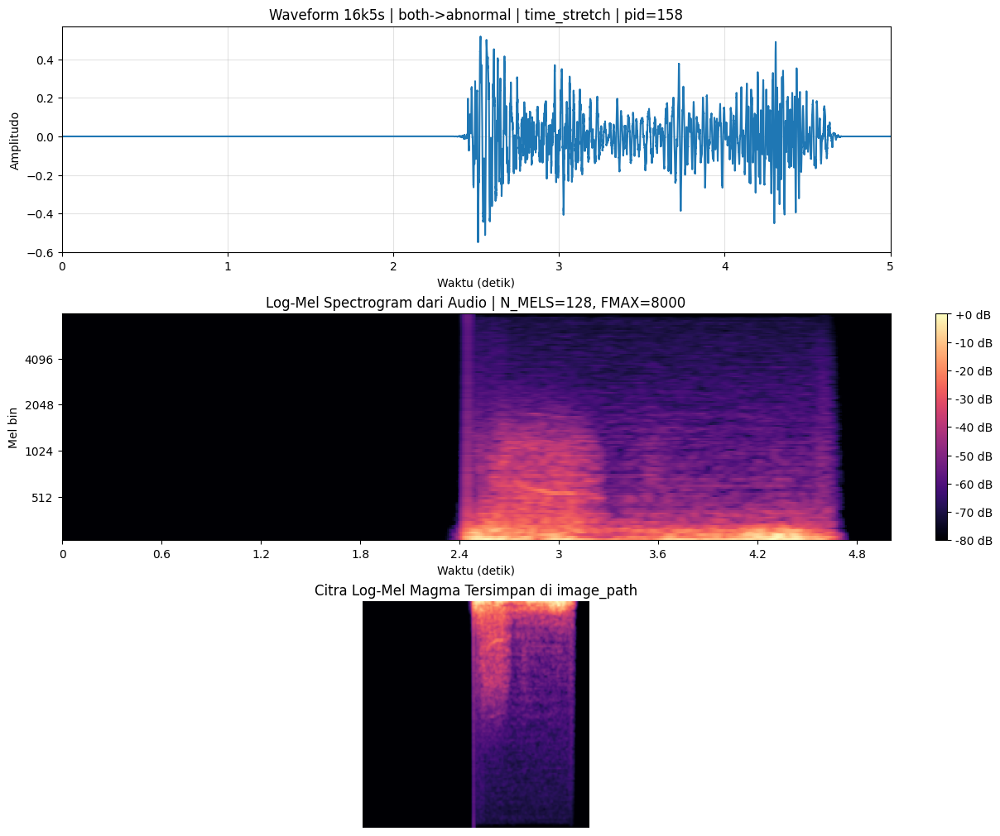


PREVIEW KE-2
Audio path   : paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/train/f569ddd4ee738f02_pid117_binabnormal_srcwheeze_aug000481_time_stretch_rate0.991_16k5s.wav
Image path   : paper_binary_16k_outputs/05_logmel_images_16k5s_magma/train/augmented/abnormal/0005806_f569ddd4ee738f02_pid117_binabnormal_srcwheeze_aug000481_time_stretch_rate0.991_16k5s_magma.png
Source label : wheeze
Binary label : abnormal
Patient ID   : 117
Is augmented : 1
Aug type     : time_stretch
Stretch rate : 0.9909
SR           : 16000
Duration     : 5.000000 detik
Samples      : 80000
RMS          : 0.14768463
Min/Max      : -0.958588 / 0.908600

Audio playback:


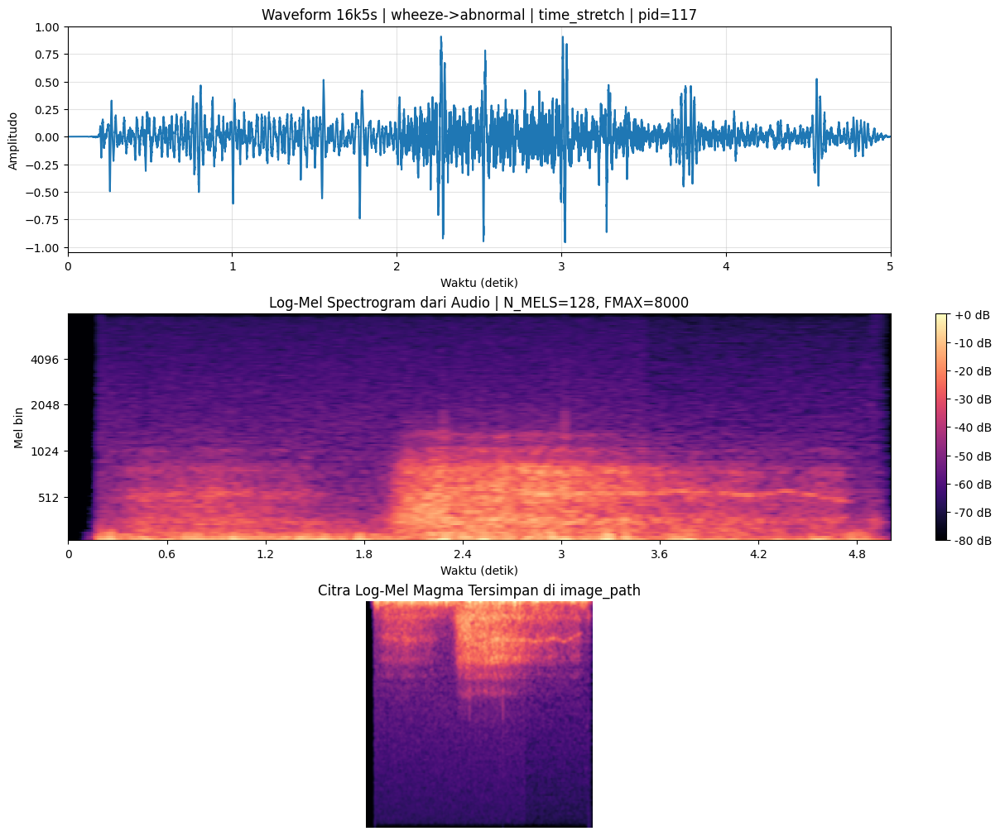


PREVIEW KE-3
Audio path   : paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/train/f4ae9c40334c2ef7_pid158_binabnormal_srcwheeze_aug000455_time_stretch_rate0.927_16k5s.wav
Image path   : paper_binary_16k_outputs/05_logmel_images_16k5s_magma/train/augmented/abnormal/0005780_f4ae9c40334c2ef7_pid158_binabnormal_srcwheeze_aug000455_time_stretch_rate0.927_16k5s_magma.png
Source label : wheeze
Binary label : abnormal
Patient ID   : 158
Is augmented : 1
Aug type     : time_stretch
Stretch rate : 0.9267
SR           : 16000
Duration     : 5.000000 detik
Samples      : 80000
RMS          : 0.09101520
Min/Max      : -0.652313 / 0.625061

Audio playback:


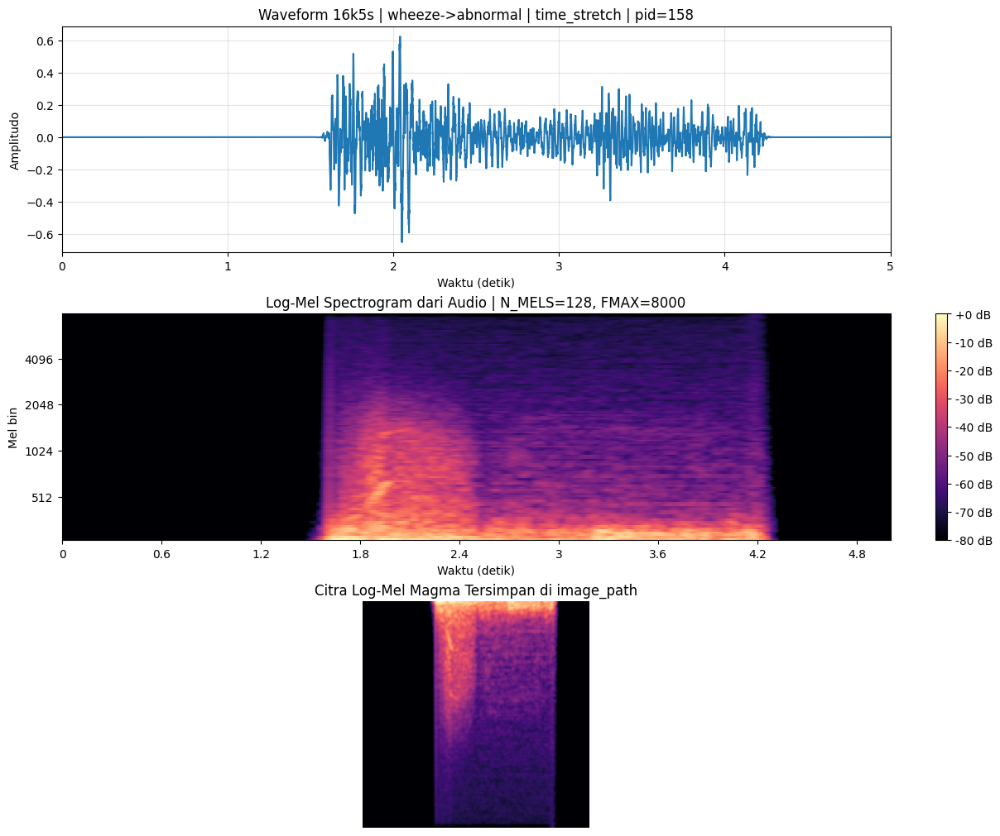


PREVIEW KE-4
Audio path   : paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/train/18f0dd4cc857315c_pid114_binabnormal_srcboth_aug000294_pitch_shift_step+0.50_16k5s.wav
Image path   : paper_binary_16k_outputs/05_logmel_images_16k5s_magma/train/augmented/abnormal/0005619_18f0dd4cc857315c_pid114_binabnormal_srcboth_aug000294_pitch_shift_step+0.50_16k5s_magma.png
Source label : both
Binary label : abnormal
Patient ID   : 114
Is augmented : 1
Aug type     : pitch_shift
Pitch steps  : 0
SR           : 16000
Duration     : 5.000000 detik
Samples      : 80000
RMS          : 0.10280822
Min/Max      : -0.595612 / 0.469818

Audio playback:


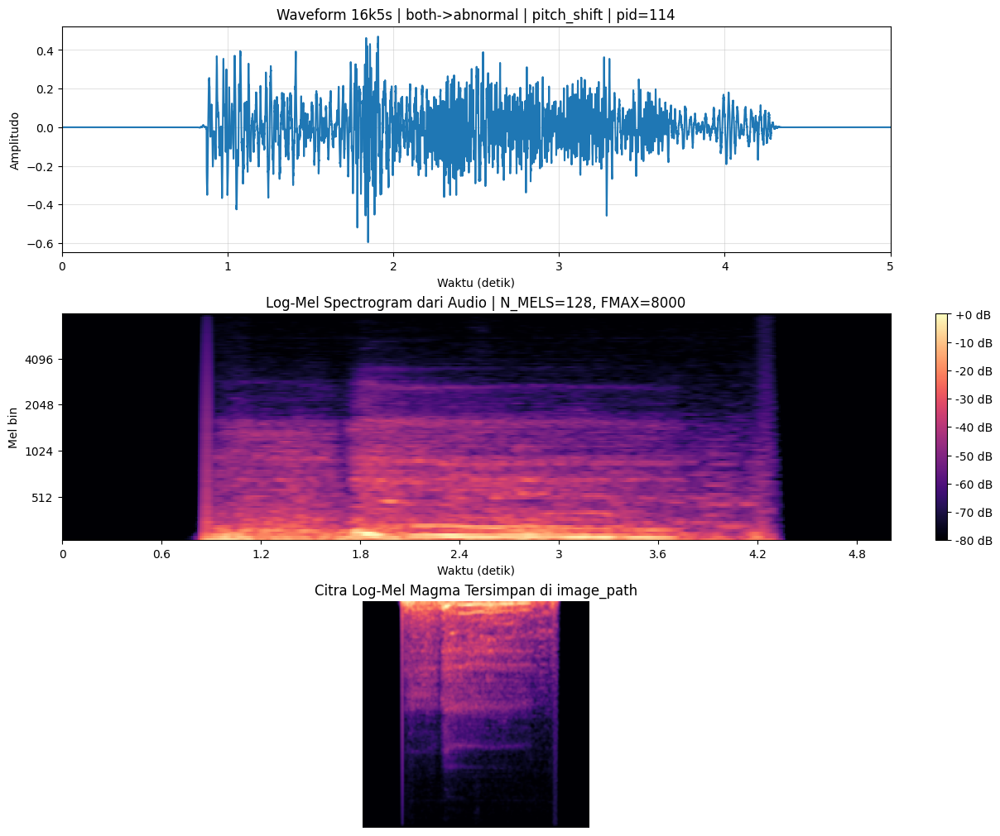


PREVIEW KE-5
Audio path   : paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/train/cf52447069bfd648_pid198_binabnormal_srcwheeze_aug000566_pitch_shift_step-1.63_16k5s.wav
Image path   : paper_binary_16k_outputs/05_logmel_images_16k5s_magma/train/augmented/abnormal/0005891_cf52447069bfd648_pid198_binabnormal_srcwheeze_aug000566_pitch_shift_step-1.63_16k5s_magma.png
Source label : wheeze
Binary label : abnormal
Patient ID   : 198
Is augmented : 1
Aug type     : pitch_shift
Pitch steps  : -1
SR           : 16000
Duration     : 5.000000 detik
Samples      : 80000
RMS          : 0.08559354
Min/Max      : -0.586884 / 0.601715

Audio playback:


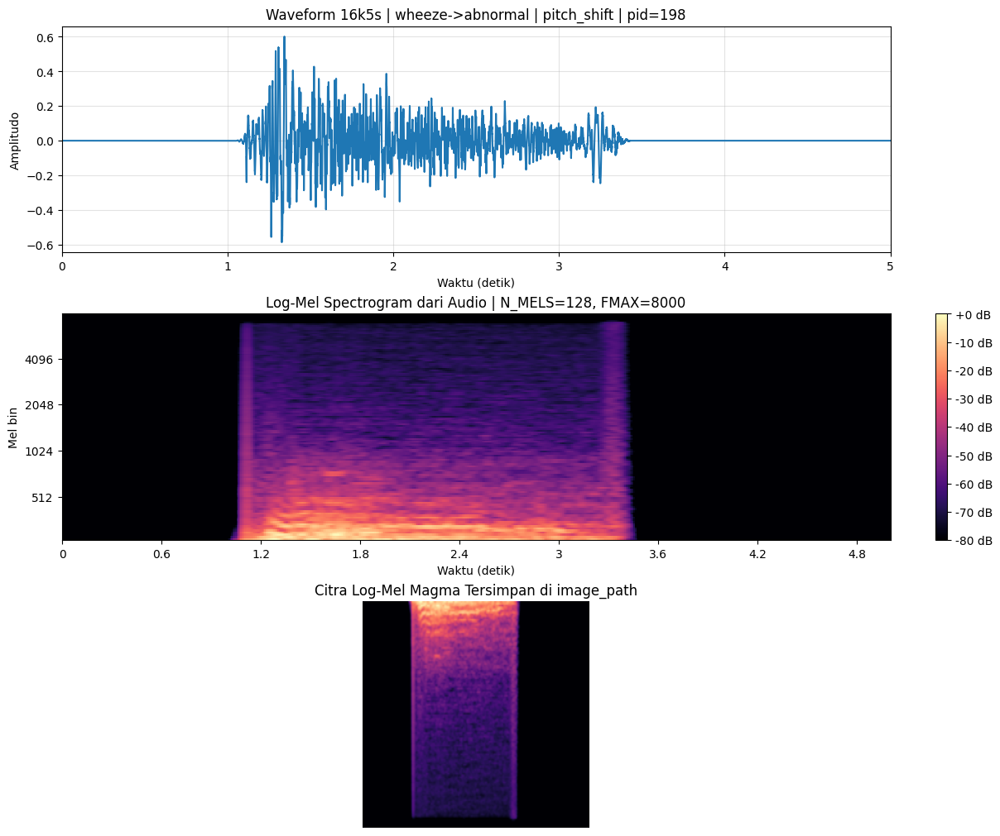


PREVIEW KE-6
Audio path   : paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/train/e7f172611c818d4f_pid174_binabnormal_srcwheeze_aug000581_pitch_shift_step-0.50_16k5s.wav
Image path   : paper_binary_16k_outputs/05_logmel_images_16k5s_magma/train/augmented/abnormal/0005906_e7f172611c818d4f_pid174_binabnormal_srcwheeze_aug000581_pitch_shift_step-0.50_16k5s_magma.png
Source label : wheeze
Binary label : abnormal
Patient ID   : 174
Is augmented : 1
Aug type     : pitch_shift
Pitch steps  : 0
SR           : 16000
Duration     : 5.000000 detik
Samples      : 80000
RMS          : 0.09091540
Min/Max      : -0.654297 / 0.647491

Audio playback:


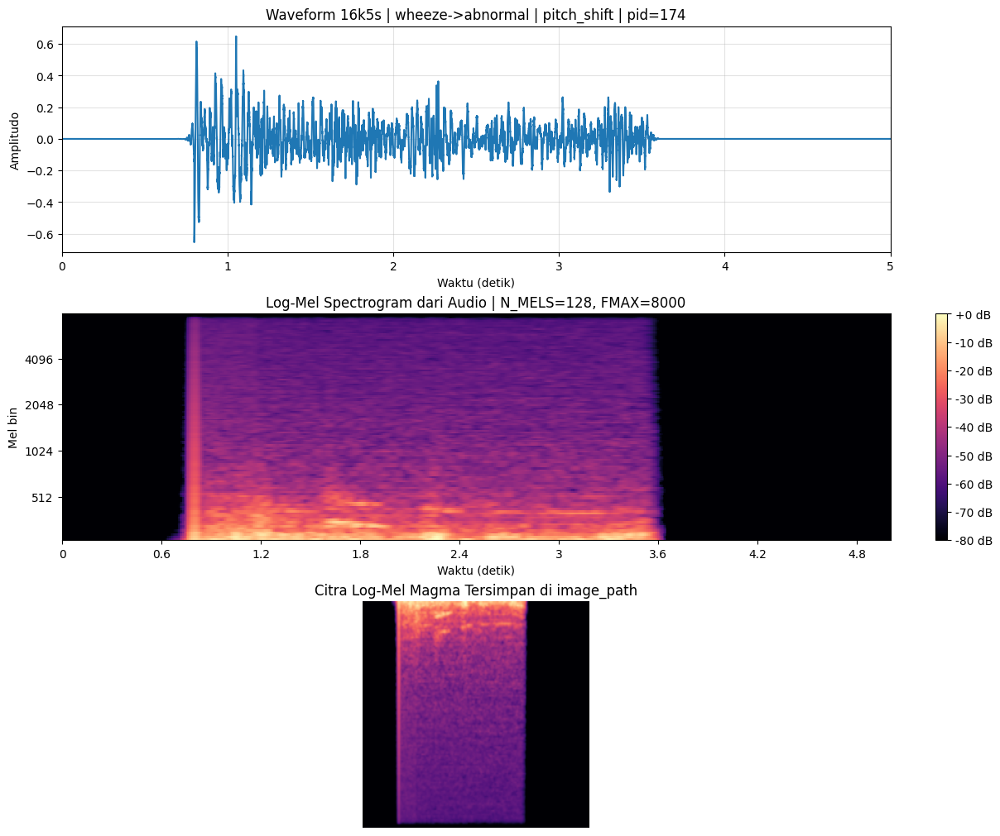


LAPORAN AKHIR KONFIGURASI PREVIEW


,metadata_path,split,preview_mode,total_valid_rows,total_previewed_rows,target_sr,target_duration_sec,target_len_samples,n_mels,n_fft,hop_length,win_length,fmin,fmax,image_size
0,paper_binary_16k_outputs/06_metadata_images_16...,train,manual_aug,583,6,16000,5.0,80000,128,2048,128,2048,50,8000,224



[OK] Preview audio, waveform, dan Log-Mel augmentasi manual 16k5s / 128 Mel selesai.
Variabel CLASSES tetap: ['normal', 'abnormal']


In [ ]:
# =========================================
# CELL: PREVIEW DAN LAPORAN AKHIR AUDIO AUGMENTASI MANUAL 16k5s
# =========================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf

from PIL import Image
from IPython.display import Audio, display


# ============================================================
# 0. KONFIGURASI
# ============================================================

# Path dipaksa ke pipeline 16k5s agar tidak mengambil metadata 44 kHz lama
# yang mungkin masih tersimpan di variabel global notebook.
META_IMG_PATH = (
    "paper_binary_16k_outputs/"
    "06_metadata_images_16k5s/"
    "metadata_manual_binary_16k5s_images_magma.csv"
)

SPLIT_TO_PREVIEW = "train"

PREVIEW_MODE = "manual_aug"
# pilihan:
# "manual_aug" = hanya data augmentasi manual
# "original"   = hanya data original
# "all_train"  = original + augmentasi

N_EXAMPLES = 6
RANDOM_STATE = 42

# Konfigurasi audio dan Log-Mel final penelitian.
TARGET_SR = 16000
TARGET_DURATION_SEC = 5.0
TARGET_LEN_SAMPLES = 80000

N_FFT = 2048
HOP_LENGTH = 128
WIN_LENGTH = 2048
N_MELS = 128
FMIN = 50
FMAX = 8000
IMAGE_SIZE = 224

if TARGET_LEN_SAMPLES != int(TARGET_SR * TARGET_DURATION_SEC):
    raise AssertionError(
        "TARGET_LEN_SAMPLES tidak konsisten dengan TARGET_SR dan durasi."
    )

if TARGET_SR != 16000:
    raise AssertionError(f"TARGET_SR harus 16000. Saat ini: {TARGET_SR}")

if N_MELS != 128:
    raise AssertionError(f"N_MELS harus 128. Saat ini: {N_MELS}")

if HOP_LENGTH != 128:
    raise AssertionError(
        f"HOP_LENGTH harus 128 untuk pipeline final. Saat ini: {HOP_LENGTH}"
    )

if FMAX > TARGET_SR // 2:
    raise AssertionError(
        f"FMAX={FMAX} melebihi Nyquist {TARGET_SR // 2} Hz."
    )

SOURCE_CLASSES_PREVIEW = ["normal", "crackle", "wheeze", "both"]
BINARY_CLASSES_PREVIEW = ["normal", "abnormal"]
ALLOWED_AUG_TYPES = {"none", "time_stretch", "pitch_shift"}


# ============================================================
# 1. HELPER
# ============================================================

def safe_display(df):
    try:
        display(df)
    except NameError:
        print(df)


def normalize_bool_int(series):
    return (
        series
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["1", "true", "yes"])
        .astype(int)
    )


def load_audio_no_resample(audio_path):
    y, sr = sf.read(audio_path, always_2d=False, dtype="float32")

    if isinstance(y, np.ndarray) and y.ndim > 1:
        y = y.mean(axis=1)

    y = np.asarray(y, dtype=np.float32)

    if len(y) == 0:
        raise ValueError(f"Audio kosong: {audio_path}")

    if not np.all(np.isfinite(y)):
        y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    return y, int(sr)


def compute_logmel_db(y, sr):
    fmax_eff = min(FMAX, sr / 2)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=fmax_eff,
        power=2.0,
    )

    mel_db = librosa.power_to_db(
        mel + 1e-10,
        ref=np.max
    )

    return mel_db, fmax_eff


# ============================================================
# 2. LOAD METADATA
# ============================================================

if "16k5s" not in str(META_IMG_PATH).lower():
    raise ValueError(
        f"META_IMG_PATH bukan metadata 16k5s: {META_IMG_PATH}\n"
        "Gunakan metadata hasil konversi audio 16 kHz, 5 detik, "
        "dan 128 Mel."
    )

if "44k" in str(META_IMG_PATH).lower():
    raise ValueError(
        f"Path metadata lama 44 kHz masih terdeteksi: {META_IMG_PATH}"
    )

if not os.path.exists(META_IMG_PATH):
    raise FileNotFoundError(
        f"Metadata image 16k5s tidak ditemukan: {META_IMG_PATH}\n"
        "Jalankan cell Konversi Audio 16k5s ke Log-Mel Image terlebih dahulu."
    )

df_preview = pd.read_csv(META_IMG_PATH).copy()
df_preview.columns = [str(c).strip() for c in df_preview.columns]

required_cols = [
    "file",
    "image_path",
    "split",
    "sound",
    "binary_label",
    "is_augmented",
    "aug_type",
]

missing_cols = [c for c in required_cols if c not in df_preview.columns]

if missing_cols:
    raise ValueError(
        f"Metadata kehilangan kolom wajib: {missing_cols}\n"
        "Untuk preview waveform dan audio, kolom file wajib ada."
    )


# ============================================================
# 3. NORMALISASI KOLOM
# ============================================================

df_preview["file"] = df_preview["file"].astype(str).str.strip()
df_preview["image_path"] = df_preview["image_path"].astype(str).str.strip()
df_preview["split"] = df_preview["split"].astype(str).str.strip().str.lower()
df_preview["sound"] = df_preview["sound"].astype(str).str.strip().str.lower()
df_preview["binary_label"] = df_preview["binary_label"].astype(str).str.strip().str.lower()
df_preview["aug_type"] = df_preview["aug_type"].fillna("none").astype(str).str.strip().str.lower()

df_preview["is_augmented"] = (
    pd.to_numeric(df_preview["is_augmented"], errors="coerce")
    .fillna(0)
    .astype(int)
)

if "augmentation_group" not in df_preview.columns:
    df_preview["augmentation_group"] = np.where(
        df_preview["is_augmented"] == 1,
        "manual_aug",
        "original"
    )
else:
    df_preview["augmentation_group"] = (
        df_preview["augmentation_group"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )

if "image_ok" in df_preview.columns:
    if df_preview["image_ok"].dtype == bool:
        df_preview["image_ok"] = df_preview["image_ok"].astype(int)
    else:
        df_preview["image_ok"] = normalize_bool_int(df_preview["image_ok"])

    df_preview = df_preview[df_preview["image_ok"] == 1].copy()


# ============================================================
# 4. VALIDASI KONFIGURASI METADATA CITRA 16k5s / 128 MEL
# ============================================================

metadata_expected_values = {
    "image_sr": TARGET_SR,
    "image_n_mels": N_MELS,
    "image_fmin": FMIN,
    "image_fmax": FMAX,
    "image_n_fft": N_FFT,
    "image_hop_length": HOP_LENGTH,
    "image_win_length": WIN_LENGTH,
    "image_expected_len_samples": TARGET_LEN_SAMPLES,
}

metadata_validation_rows = []

for col, expected_value in metadata_expected_values.items():
    if col not in df_preview.columns:
        metadata_validation_rows.append({
            "column": col,
            "status": "not_available",
            "expected": expected_value,
            "observed_unique": None,
        })
        continue

    numeric_values = pd.to_numeric(
        df_preview[col],
        errors="coerce",
    ).dropna()

    observed_unique = sorted(numeric_values.unique().tolist())

    if len(numeric_values) == 0:
        raise ValueError(
            f"Kolom metadata {col} tersedia tetapi tidak memiliki nilai numerik."
        )

    invalid_values = numeric_values[
        ~np.isclose(
            numeric_values.astype(float),
            float(expected_value),
            rtol=0.0,
            atol=1e-9,
        )
    ]

    if len(invalid_values) > 0:
        raise AssertionError(
            f"Metadata {col} tidak konsisten. "
            f"Expected={expected_value}, observed={observed_unique[:10]}"
        )

    metadata_validation_rows.append({
        "column": col,
        "status": "valid",
        "expected": expected_value,
        "observed_unique": observed_unique,
    })

metadata_config_audit_df = pd.DataFrame(metadata_validation_rows)


# ============================================================
# 5. VALIDASI DASAR
# ============================================================

unknown_source = sorted(set(df_preview["sound"]) - set(SOURCE_CLASSES_PREVIEW))
if unknown_source:
    raise ValueError(f"Label sound tidak valid ditemukan: {unknown_source}")

unknown_binary = sorted(set(df_preview["binary_label"]) - set(BINARY_CLASSES_PREVIEW))
if unknown_binary:
    raise ValueError(f"Binary label tidak valid ditemukan: {unknown_binary}")

unknown_aug = sorted(set(df_preview["aug_type"]) - ALLOWED_AUG_TYPES)
if unknown_aug:
    raise ValueError(
        f"aug_type tidak valid ditemukan: {unknown_aug}\n"
        "Untuk pipeline ini hanya boleh none, time_stretch, dan pitch_shift."
    )


# ============================================================
# 6. FILTER SPLIT DAN MODE PREVIEW
# ============================================================

df_split = df_preview[df_preview["split"] == SPLIT_TO_PREVIEW].copy()

if PREVIEW_MODE == "manual_aug":
    df_split = df_split[
        (df_split["is_augmented"] == 1)
        & (df_split["aug_type"].isin(["time_stretch", "pitch_shift"]))
    ].copy()

elif PREVIEW_MODE == "original":
    df_split = df_split[
        (df_split["is_augmented"] == 0)
        & (df_split["aug_type"] == "none")
    ].copy()

elif PREVIEW_MODE == "all_train":
    pass

else:
    raise ValueError(
        "PREVIEW_MODE tidak valid. Gunakan 'manual_aug', 'original', atau 'all_train'."
    )

df_split["audio_exists"] = df_split["file"].apply(lambda p: os.path.exists(str(p)))
df_split["image_exists"] = df_split["image_path"].apply(lambda p: os.path.exists(str(p)))

missing_audio = int((~df_split["audio_exists"]).sum())

if missing_audio > 0:
    print(f"[WARNING] Ada {missing_audio} file audio yang tidak ditemukan.")
    safe_display(
        df_split.loc[
            ~df_split["audio_exists"],
            ["file", "image_path", "sound", "binary_label", "aug_type"]
        ].head(10)
    )

df_split = df_split[df_split["audio_exists"]].copy().reset_index(drop=True)

if len(df_split) == 0:
    raise RuntimeError(
        f"Tidak ada data valid untuk preview. split={SPLIT_TO_PREVIEW}, mode={PREVIEW_MODE}"
    )


# ============================================================
# 7. RINGKASAN DATA PREVIEW
# ============================================================

print("=" * 90)
print("PREVIEW DAN LAPORAN AKHIR AUDIO AUGMENTASI MANUAL 16k5s / 128 MEL")
print("=" * 90)
print("Metadata          :", META_IMG_PATH)
print("Split             :", SPLIT_TO_PREVIEW)
print("Preview mode      :", PREVIEW_MODE)
print("Total valid       :", len(df_split))
print("Target SR         :", TARGET_SR)
print("Target duration   :", TARGET_DURATION_SEC)
print("Target samples    :", TARGET_LEN_SAMPLES)
print("N_MELS            :", N_MELS)
print("N_FFT             :", N_FFT)
print("Hop length        :", HOP_LENGTH)
print("Win length        :", WIN_LENGTH)
print("FMIN/FMAX         :", FMIN, "/", FMAX)
print("Image size        :", IMAGE_SIZE)

print("\nAudit konfigurasi metadata citra:")
safe_display(metadata_config_audit_df)

print("\nDistribusi source class:")
print(
    df_split["sound"]
    .value_counts()
    .reindex(SOURCE_CLASSES_PREVIEW, fill_value=0)
)

print("\nDistribusi binary label:")
print(
    df_split["binary_label"]
    .value_counts()
    .reindex(BINARY_CLASSES_PREVIEW, fill_value=0)
)

print("\nDistribusi aug_type:")
print(
    df_split["aug_type"]
    .value_counts()
    .reindex(["none", "time_stretch", "pitch_shift"], fill_value=0)
)

if "image_sr" in df_split.columns:
    print("\nDistribusi image_sr:")
    print(df_split["image_sr"].value_counts(dropna=False).sort_index())


# ============================================================
# 8. PILIH SAMPEL PREVIEW
# ============================================================

# Ambil seimbang berdasarkan aug_type jika manual_aug
samples = []

if PREVIEW_MODE == "manual_aug":
    for aug_type in ["time_stretch", "pitch_shift"]:
        df_aug = df_split[df_split["aug_type"] == aug_type].copy()

        if len(df_aug) == 0:
            continue

        n_take = min(max(1, N_EXAMPLES // 2), len(df_aug))

        samples.append(
            df_aug.sample(
                n=n_take,
                random_state=RANDOM_STATE
            )
        )

    if len(samples) > 0:
        sample_df = pd.concat(samples, ignore_index=True)
    else:
        sample_df = df_split.sample(
            n=min(N_EXAMPLES, len(df_split)),
            random_state=RANDOM_STATE
        ).reset_index(drop=True)

else:
    sample_df = df_split.sample(
        n=min(N_EXAMPLES, len(df_split)),
        random_state=RANDOM_STATE
    ).reset_index(drop=True)

sample_df = sample_df.head(N_EXAMPLES).reset_index(drop=True)

preview_cols = [
    "file",
    "image_path",
    "split",
    "sound",
    "binary_label",
    "patient_id",
    "is_augmented",
    "augmentation_group",
    "aug_type",
    "time_stretch_rate",
    "pitch_shift_steps",
    "image_sr",
    "image_n_mels",
    "image_fmin",
    "image_fmax",
    "image_n_fft",
    "image_hop_length",
    "image_win_length",
    "image_expected_len_samples",
]

preview_cols = [c for c in preview_cols if c in sample_df.columns]

print("\nSampel yang akan dipreview:")
safe_display(sample_df[preview_cols])


# ============================================================
# 9. PREVIEW AUDIO + WAVEFORM + LOG-MEL
# ============================================================

for idx, row in sample_df.iterrows():
    audio_path = str(row["file"])
    image_path = str(row["image_path"])

    source_label = str(row["sound"])
    binary_label = str(row["binary_label"])
    aug_type = str(row["aug_type"])
    is_aug = int(row["is_augmented"])
    pid = row["patient_id"] if "patient_id" in row.index else "NA"

    print("\n" + "=" * 90)
    print(f"PREVIEW KE-{idx + 1}")
    print("=" * 90)
    print("Audio path   :", audio_path)
    print("Image path   :", image_path)
    print("Source label :", source_label)
    print("Binary label :", binary_label)
    print("Patient ID   :", pid)
    print("Is augmented :", is_aug)
    print("Aug type     :", aug_type)

    if "time_stretch_rate" in row.index and pd.notna(row["time_stretch_rate"]):
        print(f"Stretch rate : {float(row['time_stretch_rate']):.4f}")

    if "pitch_shift_steps" in row.index and pd.notna(row["pitch_shift_steps"]):
        print(f"Pitch steps  : {int(row['pitch_shift_steps'])}")

    # --------------------------------------------------------
    # Load audio
    # --------------------------------------------------------

    try:
        y, sr = load_audio_no_resample(audio_path)
    except Exception as e:
        print(f"[ERROR] Gagal load audio: {repr(e)}")
        continue

    duration = len(y) / sr if sr else 0.0
    rms = float(np.sqrt(np.mean(y ** 2))) if len(y) > 0 else 0.0

    print("SR           :", sr)
    print("Duration     :", f"{duration:.6f} detik")
    print("Samples      :", len(y))
    print("RMS          :", f"{rms:.8f}")
    print("Min/Max      :", f"{float(np.min(y)):.6f} / {float(np.max(y)):.6f}")

    if sr != TARGET_SR:
        print(f"[WARNING] SR file bukan {TARGET_SR} Hz.")

    if len(y) != TARGET_LEN_SAMPLES:
        print(f"[WARNING] Panjang sample bukan {TARGET_LEN_SAMPLES}.")

    # --------------------------------------------------------
    # Audio playback
    # --------------------------------------------------------

    print("\nAudio playback:")
    display(Audio(data=y, rate=sr, normalize=False))

    # --------------------------------------------------------
    # Hitung Log-Mel
    # --------------------------------------------------------

    try:
        mel_db, fmax_eff = compute_logmel_db(y, sr)
    except Exception as e:
        print(f"[ERROR] Gagal hitung log-Mel: {repr(e)}")
        continue

    # --------------------------------------------------------
    # Plot waveform + logmel + saved image
    # --------------------------------------------------------

    t = np.linspace(0, duration, num=len(y)) if len(y) > 0 else np.array([0.0])

    show_saved_image = os.path.exists(image_path)

    if show_saved_image:
        fig, axes = plt.subplots(
            3,
            1,
            figsize=(12, 10),
            constrained_layout=True
        )
    else:
        fig, axes = plt.subplots(
            2,
            1,
            figsize=(12, 7),
            constrained_layout=True
        )

    # Waveform
    ax0 = axes[0]
    ax0.plot(t, y)
    ax0.set_title(
        f"Waveform 16k5s | {source_label}->{binary_label} | {aug_type} | pid={pid}"
    )
    ax0.set_xlabel("Waktu (detik)")
    ax0.set_ylabel("Amplitudo")
    ax0.set_xlim(0, max(duration, 1e-6))
    ax0.grid(alpha=0.35)

    # Log-Mel dari audio
    ax1 = axes[1]
    img = librosa.display.specshow(
        mel_db,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
        fmin=FMIN,
        fmax=fmax_eff,
        ax=ax1
    )

    ax1.set_title(
        f"Log-Mel Spectrogram dari Audio | N_MELS={N_MELS}, FMAX={int(fmax_eff)}"
    )
    ax1.set_xlabel("Waktu (detik)")
    ax1.set_ylabel("Mel bin")
    fig.colorbar(img, ax=ax1, format="%+2.0f dB")

    # Citra log-Mel yang sudah tersimpan
    if show_saved_image:
        ax2 = axes[2]
        saved_img = Image.open(image_path).convert("RGB")
        ax2.imshow(saved_img)
        ax2.axis("off")
        ax2.set_title("Citra Log-Mel Magma Tersimpan di image_path")

    plt.show()

preview_final_report = {
    "metadata_path": str(META_IMG_PATH),
    "split": SPLIT_TO_PREVIEW,
    "preview_mode": PREVIEW_MODE,
    "total_valid_rows": int(len(df_split)),
    "total_previewed_rows": int(len(sample_df)),
    "target_sr": int(TARGET_SR),
    "target_duration_sec": float(TARGET_DURATION_SEC),
    "target_len_samples": int(TARGET_LEN_SAMPLES),
    "n_mels": int(N_MELS),
    "n_fft": int(N_FFT),
    "hop_length": int(HOP_LENGTH),
    "win_length": int(WIN_LENGTH),
    "fmin": int(FMIN),
    "fmax": int(FMAX),
    "image_size": int(IMAGE_SIZE),
    "source_class_distribution": (
        df_split["sound"]
        .value_counts()
        .reindex(SOURCE_CLASSES_PREVIEW, fill_value=0)
        .astype(int)
        .to_dict()
    ),
    "binary_class_distribution": (
        df_split["binary_label"]
        .value_counts()
        .reindex(BINARY_CLASSES_PREVIEW, fill_value=0)
        .astype(int)
        .to_dict()
    ),
    "augmentation_type_distribution": (
        df_split["aug_type"]
        .value_counts()
        .reindex(["none", "time_stretch", "pitch_shift"], fill_value=0)
        .astype(int)
        .to_dict()
    ),
}

preview_final_report_df = pd.DataFrame([{
    key: value
    for key, value in preview_final_report.items()
    if not isinstance(value, dict)
}])

globals()["preview_final_report"] = preview_final_report
globals()["preview_final_report_df"] = preview_final_report_df
globals()["metadata_config_audit_df"] = metadata_config_audit_df
globals()["preview_sample_df"] = sample_df

print("\n" + "=" * 90)
print("LAPORAN AKHIR KONFIGURASI PREVIEW")
print("=" * 90)
safe_display(preview_final_report_df)
print("=" * 90)

print(
    "\n[OK] Preview audio, waveform, dan Log-Mel augmentasi manual "
    "16k5s / 128 Mel selesai."
)
print("Variabel CLASSES tetap:", globals().get("CLASSES", "CLASSES belum tersedia"))